In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import cv2
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
from tqdm.auto import tqdm

In [ ]:
!pip install tensorflow==2.15.0

In [ ]:
data_dir = os.path.join('drive', 'MyDrive', 'data')

# Importing previously trained models

In [ ]:
from tensorflow.keras.models import load_model

ResNet50_model_20by20 = load_model(os.path.join(data_dir,'imageclassifier_3classes_ResNet50_20x20_75epoch.h5'))
ENV2S_model_20by20 = load_model(os.path.join(data_dir,'imageclassifier_3classes_ENV2S_20x20_200epoch.h5'))
VGG16_model_20by20 = load_model(os.path.join(data_dir,'imageclassifier_3classes_VGG16_20x20_200epoch.h5'))
DenseNet121_model_20by20 = load_model(os.path.join(data_dir,'imageclassifier_3classes_DenseNet121_20x20_200epoch.h5'))

ENV2S_model_20by20_fourier = load_model(os.path.join(data_dir,'imageclassifier_3classes_ENV2S_20x20_200epoch_FT.h5'))
ResNet50_model_20by20_fourier = load_model(os.path.join(data_dir, 'imageclassifier_3classes_ResNet50_20x20_70epoch_FT.h5'))

ResNet50_model_20by20_SurfRough = load_model(os.path.join(data_dir,'imageclassifier_3classes_ResNet50_20x20_80epoch_SR.h5'))
VGG16_model_20by20_SurfRough = load_model(os.path.join(data_dir,'imageclassifier_3classes_VGG16_20x20_200epoch_SR.h5'))
ENV2S_model_20by20_SurfRough = load_model(os.path.join(data_dir,'imageclassifier_3classes_ENV2S_20x20_200epoch_SR.h5'))
DenseNet121_model_20by20_SurfRough = load_model(os.path.join(data_dir,'imageclassifier_3classes_DenseNet121_20x20_120epoch_SR.h5'))

# Files list

In [ ]:
file_list_not_ripples = os.listdir(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'not_ripples'))
file_list_transition = os.listdir(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'transition'))
file_list_ripples = os.listdir(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'ripples'))

# Data with ripples

In [ ]:
d = {'col1': ['File name'],
     'col2': ['result'], 'ResNet50': ['Ripple?'],
     'col4': ['result'], 'ENV2S': ['Ripple?'],
     'col6': ['result'], 'VGG16': ['Ripple?'],
     'col8': ['result'], 'DenseNet121': ['Ripple?'],
     'col10': ['blank'],
     'col12': ['result'], 'ENV2S_ft': ['Ripple?'],
     'col14': ['result'], 'model_ft': ['Ripple?'],
     'col20': ['result'], 'DenseNet121_SR': ['Ripple?']}
df_final_classification_ripples = pd.DataFrame(data=d)

f = {'col1': ['File name'],
     'ResNet50_NR': ['Not_ripples'], 'ResNet50_T': ['Transition'], 'ResNet50_R': ['Ripples'],
     'ENV2S_NR': ['Not_ripples'], 'ENV2S_T': ['Transition'], 'ENV2S_R': ['Ripples'],
     'VGG16_NR': ['Not_ripples'], 'VGG16_T': ['Transition'], 'VGG16_R': ['Ripples'],
     'DenseNet121_NR': ['Not_ripples'], 'DenseNet121_T': ['Transition'], 'DenseNet121_R': ['Ripples'],
     'ENV2S_FT_NR': ['Not_ripples'], 'ENV2S_FT_T': ['Transition'], 'ENV2S_FT_R': ['Ripples'],
     'model_FT_NR': ['Not_ripples'], 'model_FT_T': ['Transition'], 'model_FT_R': ['Ripples'],
     'ResNet50_SR_NR': ['Not_ripples'], 'ResNet50_SR_T': ['Transition'], 'ResNet50_SR_R': ['Ripples'],
     'VGG16_SR_NR': ['Not_ripples'], 'VGG16_SR_T': ['Transition'], 'VGG16_SR_R': ['Ripples'],
     'ENV2S_SR_NR': ['Not_ripples'], 'ENV2S_SR_T': ['Transition'], 'ENV2S_SR_R': ['Ripples'],
     'DenseNet121_SR_NR': ['Not_ripples'], 'DenseNet121_SR_T': ['Transition'], 'DenseNet121_SR_R': ['Ripples']}
df_final_certainty_ripples = pd.DataFrame(data=f)

In [ ]:
cm = plt.cm.viridis

for row in range(len(file_list_ripples)):
  name = file_list_ripples[row]
  splitted = name.split("_")
  img = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'ripples', name))
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  img_ft = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'fourier', 'ripples', name))
  img_ft_rgb = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)

  #Attribute image
  img_attr = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'attribute', 'ripples', name))
  img_attr = cv2.cvtColor(img_attr, cv2.COLOR_BGR2RGB)
#-------------First classification-------------
  ResNet50 = ResNet50_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ResNet50_pred = np.argmax(ResNet50)
  if ResNet50_pred == 0:
    ResNet50_result = 'NO'
  if ResNet50_pred == 1:
    ResNet50_result = 'T'
  if ResNet50_pred == 2:
    ResNet50_result = 'YES'

  ENV2S = ENV2S_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ENV2S_pred = np.argmax(ENV2S)
  if ENV2S_pred == 0:
    ENV2S_result = 'NO'
  if ENV2S_pred == 1:
    ENV2S_result = 'T'
  if ENV2S_pred == 2:
    ENV2S_result = 'YES'

  VGG16 = VGG16_model_20by20.predict(np.expand_dims(img_rgb, 0))
  VGG16_pred = np.argmax(VGG16)
  if VGG16_pred == 0:
    VGG16_result = 'NO'
  if VGG16_pred == 1:
    VGG16_result = 'T'
  if VGG16_pred == 2:
    VGG16_result = 'YES'

  DenseNet121 = DenseNet121_model_20by20.predict(np.expand_dims(img_rgb, 0))
  DenseNet121_pred = np.argmax(DenseNet121)
  if DenseNet121_pred == 0:
    DenseNet121_result = 'NO'
  if DenseNet121_pred == 1:
    DenseNet121_result = 'T'
  if DenseNet121_pred == 2:
    DenseNet121_result = 'YES'

#-------------Fourier classification-------------
  ENV2S_fourier = ENV2S_model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  ENV2S_fourier_pred = np.argmax(ENV2S_fourier)
  if ENV2S_fourier_pred == 0:
    ENV2S_fourier_result = 'NO'
  if ENV2S_fourier_pred == 1:
    ENV2S_fourier_result = 'T'
  if ENV2S_fourier_pred == 2:
    ENV2S_fourier_result = 'YES'

  model_fourier = model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  model_fourier_pred = np.argmax(model_fourier)
  if model_fourier_pred == 0:
    model_fourier_result = 'NO'
  if model_fourier_pred == 1:
    model_fourier_result = 'T'
  if model_fourier_pred == 2:
    model_fourier_result = 'YES'

#-------------Attribute classification-------------
  ResNet50_SR = ResNet50_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ResNet50_SR_pred = np.argmax(ResNet50_SR)
  if ResNet50_SR_pred == 0:
    ResNet50_SR_result = 'NO'
  if ResNet50_SR_pred == 1:
    ResNet50_SR_result = 'T'
  if ResNet50_SR_pred == 2:
    ResNet50_SR_result = 'YES'

  VGG16_SR = VGG16_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  VGG16_SR_pred = np.argmax(VGG16_SR)
  if VGG16_SR_pred == 0:
    VGG16_SR_result = 'NO'
  if VGG16_SR_pred == 1:
    VGG16_SR_result = 'T'
  if VGG16_SR_pred == 2:
    VGG16_SR_result = 'YES'

  ENV2S_SR = ENV2S_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ENV2S_SR_pred = np.argmax(ENV2S_SR)
  if ENV2S_SR_pred == 0:
    ENV2S_SR_result = 'NO'
  if ENV2S_SR_pred == 1:
    ENV2S_SR_result = 'T'
  if ENV2S_SR_pred == 2:
    ENV2S_SR_result = 'YES'

  DenseNet121_SR = DenseNet121_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  DenseNet121_SR_pred = np.argmax(DenseNet121_SR)
  if DenseNet121_SR_pred == 0:
    DenseNet121_SR_result = 'NO'
  if DenseNet121_SR_pred == 1:
    DenseNet121_SR_result = 'T'
  if DenseNet121_SR_pred == 2:
    DenseNet121_SR_result = 'YES'

  print(row)
  df_final_classification_ripples.loc[len(df_final_classification_ripples.index)] = [name,
                                                                                    ResNet50[0][ResNet50_pred], ResNet50_result,
                                                                                    ENV2S[0][ENV2S_pred], ENV2S_result,
                                                                                    VGG16[0][VGG16_pred], VGG16_result,
                                                                                    DenseNet121[0][DenseNet121_pred], DenseNet121_result,
                                                                                    '---',
                                                                                    ENV2S_fourier[0][ENV2S_fourier_pred], ENV2S_fourier_result,
                                                                                    model_fourier[0][model_fourier_pred], model_fourier_result,
                                                                                    DenseNet121_SR[0][DenseNet121_SR_pred], DenseNet121_SR_result]
  df_final_certainty_ripples.loc[len(df_final_certainty_ripples.index)] = [name,
                                                                           ResNet50[0,0], ResNet50[0,1], ResNet50[0,2],
                                                                           ENV2S[0,0], ENV2S[0,1], ENV2S[0,2],
                                                                           VGG16[0,0], VGG16[0,1], VGG16[0,2],
                                                                           DenseNet121[0,0], DenseNet121[0,1], DenseNet121[0,2],
                                                                           ENV2S_fourier[0,0], ENV2S_fourier[0,1], ENV2S_fourier[0,2],
                                                                           model_fourier[0,0], model_fourier[0,1], model_fourier[0,2],
                                                                           ResNet50_SR[0,0], ResNet50_SR[0,1], ResNet50_SR[0,2],
                                                                           VGG16_SR[0,0], VGG16_SR[0,1], VGG16_SR[0,2],
                                                                           ENV2S_SR[0,0], ENV2S_SR[0,1], ENV2S_SR[0,2],
                                                                           DenseNet121_SR[0,0], DenseNet121_SR[0,1], DenseNet121_SR[0,2]]

In [ ]:
df_final_classification_ripples.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_ripples_new_SR_models.txt'), index=False)
df_final_certainty_ripples.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_certainty_ripples_new_SR_models.txt'), index=False)

# Data transition zone

In [ ]:
d = {'col1': ['File name'],
     'col2': ['result'], 'ResNet50': ['Ripple?'],
     'col4': ['result'], 'ENV2S': ['Ripple?'],
     'col6': ['result'], 'VGG16': ['Ripple?'],
     'col8': ['result'], 'DenseNet121': ['Ripple?'],
     'col10': ['blank'],
     'col12': ['result'], 'ENV2S_ft': ['Ripple?'],
     'col14': ['result'], 'model_ft': ['Ripple?'],
     'col20': ['result'], 'DenseNet121_SR': ['Ripple?']}
df_final_classification_transition = pd.DataFrame(data=d)

f = {'col1': ['File name'],
     'ResNet50_NR': ['Not_ripples'], 'ResNet50_T': ['Transition'], 'ResNet50_R': ['Ripples'],
     'ENV2S_NR': ['Not_ripples'], 'ENV2S_T': ['Transition'], 'ENV2S_R': ['Ripples'],
     'VGG16_NR': ['Not_ripples'], 'VGG16_T': ['Transition'], 'VGG16_R': ['Ripples'],
     'DenseNet121_NR': ['Not_ripples'], 'DenseNet121_T': ['Transition'], 'DenseNet121_R': ['Ripples'],
     'ENV2S_FT_NR': ['Not_ripples'], 'ENV2S_FT_T': ['Transition'], 'ENV2S_FT_R': ['Ripples'],
     'model_FT_NR': ['Not_ripples'], 'model_FT_T': ['Transition'], 'model_FT_R': ['Ripples'],
     'ResNet50_SR_NR': ['Not_ripples'], 'ResNet50_SR_T': ['Transition'], 'ResNet50_SR_R': ['Ripples'],
     'VGG16_SR_NR': ['Not_ripples'], 'VGG16_SR_T': ['Transition'], 'VGG16_SR_R': ['Ripples'],
     'ENV2S_SR_NR': ['Not_ripples'], 'ENV2S_SR_T': ['Transition'], 'ENV2S_SR_R': ['Ripples'],
     'DenseNet121_SR_NR': ['Not_ripples'], 'DenseNet121_SR_T': ['Transition'], 'DenseNet121_SR_R': ['Ripples']}
df_final_certainty_transition = pd.DataFrame(data=f)

In [ ]:
cm = plt.cm.viridis
for row in range(len(file_list_transition)):
  name = file_list_transition[row]
  splitted = name.split("_")
  img = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'transition', name))
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  img_ft = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'fourier', 'transition', name))
  img_ft_rgb = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)

  #Attribute image
  img_attr = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'attribute', 'transition', name))
  img_attr = cv2.cvtColor(img_attr, cv2.COLOR_BGR2RGB)
#-------------First classification-------------
  ResNet50 = ResNet50_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ResNet50_pred = np.argmax(ResNet50)
  if ResNet50_pred == 0:
    ResNet50_result = 'NO'
  if ResNet50_pred == 1:
    ResNet50_result = 'T'
  if ResNet50_pred == 2:
    ResNet50_result = 'YES'

  ENV2S = ENV2S_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ENV2S_pred = np.argmax(ENV2S)
  if ENV2S_pred == 0:
    ENV2S_result = 'NO'
  if ENV2S_pred == 1:
    ENV2S_result = 'T'
  if ENV2S_pred == 2:
    ENV2S_result = 'YES'

  VGG16 = VGG16_model_20by20.predict(np.expand_dims(img_rgb, 0))
  VGG16_pred = np.argmax(VGG16)
  if VGG16_pred == 0:
    VGG16_result = 'NO'
  if VGG16_pred == 1:
    VGG16_result = 'T'
  if VGG16_pred == 2:
    VGG16_result = 'YES'

  DenseNet121 = DenseNet121_model_20by20.predict(np.expand_dims(img_rgb, 0))
  DenseNet121_pred = np.argmax(DenseNet121)
  if DenseNet121_pred == 0:
    DenseNet121_result = 'NO'
  if DenseNet121_pred == 1:
    DenseNet121_result = 'T'
  if DenseNet121_pred == 2:
    DenseNet121_result = 'YES'

#-------------Fourier classification-------------
  ENV2S_fourier = ENV2S_model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  ENV2S_fourier_pred = np.argmax(ENV2S_fourier)
  if ENV2S_fourier_pred == 0:
    ENV2S_fourier_result = 'NO'
  if ENV2S_fourier_pred == 1:
    ENV2S_fourier_result = 'T'
  if ENV2S_fourier_pred == 2:
    ENV2S_fourier_result = 'YES'

  model_fourier = model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  model_fourier_pred = np.argmax(model_fourier)
  if model_fourier_pred == 0:
    model_fourier_result = 'NO'
  if model_fourier_pred == 1:
    model_fourier_result = 'T'
  if model_fourier_pred == 2:
    model_fourier_result = 'YES'

#-------------Attribute classification-------------
  ResNet50_SR = ResNet50_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ResNet50_SR_pred = np.argmax(ResNet50_SR)
  if ResNet50_SR_pred == 0:
    ResNet50_SR_result = 'NO'
  if ResNet50_SR_pred == 1:
    ResNet50_SR_result = 'T'
  if ResNet50_SR_pred == 2:
    ResNet50_SR_result = 'YES'

  VGG16_SR = VGG16_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  VGG16_SR_pred = np.argmax(VGG16_SR)
  if VGG16_SR_pred == 0:
    VGG16_SR_result = 'NO'
  if VGG16_SR_pred == 1:
    VGG16_SR_result = 'T'
  if VGG16_SR_pred == 2:
    VGG16_SR_result = 'YES'

  ENV2S_SR = ENV2S_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ENV2S_SR_pred = np.argmax(ENV2S_SR)
  if ENV2S_SR_pred == 0:
    ENV2S_SR_result = 'NO'
  if ENV2S_SR_pred == 1:
    ENV2S_SR_result = 'T'
  if ENV2S_SR_pred == 2:
    ENV2S_SR_result = 'YES'

  DenseNet121_SR = DenseNet121_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  DenseNet121_SR_pred = np.argmax(DenseNet121_SR)
  if DenseNet121_SR_pred == 0:
    DenseNet121_SR_result = 'NO'
  if DenseNet121_SR_pred == 1:
    DenseNet121_SR_result = 'T'
  if DenseNet121_SR_pred == 2:
    DenseNet121_SR_result = 'YES'

  print(row)
  df_final_classification_transition.loc[len(df_final_classification_transition.index)] = [name,
                                                                                          ResNet50[0][ResNet50_pred], ResNet50_result,
                                                                                          ENV2S[0][ENV2S_pred], ENV2S_result,
                                                                                          VGG16[0][VGG16_pred], VGG16_result,
                                                                                          DenseNet121[0][DenseNet121_pred], DenseNet121_result,
                                                                                          '---',
                                                                                          ENV2S_fourier[0][ENV2S_fourier_pred], ENV2S_fourier_result,
                                                                                          model_fourier[0][model_fourier_pred], model_fourier_result,
                                                                                          DenseNet121_SR[0][DenseNet121_SR_pred], DenseNet121_SR_result]
  df_final_certainty_transition.loc[len(df_final_certainty_transition.index)] = [name,
                                                                                 ResNet50[0,0], ResNet50[0,1], ResNet50[0,2],
                                                                                 ENV2S[0,0], ENV2S[0,1], ENV2S[0,2],
                                                                                 VGG16[0,0], VGG16[0,1], VGG16[0,2],
                                                                                 DenseNet121[0,0], DenseNet121[0,1], DenseNet121[0,2],
                                                                                 ENV2S_fourier[0,0], ENV2S_fourier[0,1], ENV2S_fourier[0,2],
                                                                                 model_fourier[0,0], model_fourier[0,1], model_fourier[0,2],
                                                                                 ResNet50_SR[0,0], ResNet50_SR[0,1], ResNet50_SR[0,2],
                                                                                 VGG16_SR[0,0], VGG16_SR[0,1], VGG16_SR[0,2],
                                                                                 ENV2S_SR[0,0], ENV2S_SR[0,1], ENV2S_SR[0,2],
                                                                                 DenseNet121_SR[0,0], DenseNet121_SR[0,1], DenseNet121_SR[0,2]]

In [ ]:
df_final_classification_transition.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_transition_new_SR_models.txt'), index=False)
df_final_certainty_transition.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_certainty_transition_new_SR_models.txt'), index=False)

# Data with no ripples

In [ ]:
d = {'col1': ['File name'],
     'col2': ['result'], 'ResNet50': ['Ripple?'],
     'col4': ['result'], 'ENV2S': ['Ripple?'],
     'col6': ['result'], 'VGG16': ['Ripple?'],
     'col8': ['result'], 'DenseNet121': ['Ripple?'],
     'col10': ['blank'],
     'col12': ['result'], 'ENV2S_ft': ['Ripple?'],
     'col14': ['result'], 'model_ft': ['Ripple?'],
     'col16': ['result'], 'ResNet50_SR': ['Ripple?'],
     'col18': ['result'], 'VGG16_SR': ['Ripple?'],
     'col20': ['result'], 'ENV2S_SR': ['Ripple?'],
     'col22': ['result'], 'DenseNet121_SR': ['Ripple?']}
df_final_classification_not_ripples = pd.DataFrame(data=d)

f = {'col1': ['File name'],
     'ResNet50_NR': ['Not_ripples'], 'ResNet50_T': ['Transition'], 'ResNet50_R': ['Ripples'],
     'ENV2S_NR': ['Not_ripples'], 'ENV2S_T': ['Transition'], 'ENV2S_R': ['Ripples'],
     'VGG16_NR': ['Not_ripples'], 'VGG16_T': ['Transition'], 'VGG16_R': ['Ripples'],
     'DenseNet121_NR': ['Not_ripples'], 'DenseNet121_T': ['Transition'], 'DenseNet121_R': ['Ripples'],
     'ENV2S_FT_NR': ['Not_ripples'], 'ENV2S_FT_T': ['Transition'], 'ENV2S_FT_R': ['Ripples'],
     'model_FT_NR': ['Not_ripples'], 'model_FT_T': ['Transition'], 'model_FT_R': ['Ripples'],
     'ResNet50_SR_NR': ['Not_ripples'], 'ResNet50_SR_T': ['Transition'], 'ResNet50_SR_R': ['Ripples'],
     'VGG16_SR_NR': ['Not_ripples'], 'VGG16_SR_T': ['Transition'], 'VGG16_SR_R': ['Ripples'],
     'ENV2S_SR_NR': ['Not_ripples'], 'ENV2S_SR_T': ['Transition'], 'ENV2S_SR_R': ['Ripples'],
     'DenseNet121_SR_NR': ['Not_ripples'], 'DenseNet121_SR_T': ['Transition'], 'DenseNet121_SR_R': ['Ripples']}
df_final_certainty_not_ripples = pd.DataFrame(data=f)

In [ ]:
for row in range(2000, len(file_list_not_ripples)):
  name = file_list_not_ripples[row]
  splitted = name.split("_")
  img = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'not_ripples', name))
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  img_ft = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'fourier', 'not_ripples', name))
  img_ft_rgb = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)
  #Attribute image
  img_attr = cv2.imread(os.path.join(data_dir, 'Lines_for_test', '20x20', 'Lineas_Sonarwiz', 'attribute', 'not_ripples', name))
  img_attr = cv2.cvtColor(img_attr, cv2.COLOR_BGR2RGB)
#-------------First classification-------------
  ResNet50 = ResNet50_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ResNet50_pred = np.argmax(ResNet50)
  if ResNet50_pred == 0:
    ResNet50_result = 'NO'
  if ResNet50_pred == 1:
    ResNet50_result = 'T'
  if ResNet50_pred == 2:
    ResNet50_result = 'YES'

  ENV2S = ENV2S_model_20by20.predict(np.expand_dims(img_rgb, 0))
  ENV2S_pred = np.argmax(ENV2S)
  if ENV2S_pred == 0:
    ENV2S_result = 'NO'
  if ENV2S_pred == 1:
    ENV2S_result = 'T'
  if ENV2S_pred == 2:
    ENV2S_result = 'YES'

  VGG16 = VGG16_model_20by20.predict(np.expand_dims(img_rgb, 0))
  VGG16_pred = np.argmax(VGG16)
  if VGG16_pred == 0:
    VGG16_result = 'NO'
  if VGG16_pred == 1:
    VGG16_result = 'T'
  if VGG16_pred == 2:
    VGG16_result = 'YES'

  DenseNet121 = DenseNet121_model_20by20.predict(np.expand_dims(img_rgb, 0))
  DenseNet121_pred = np.argmax(DenseNet121)
  if DenseNet121_pred == 0:
    DenseNet121_result = 'NO'
  if DenseNet121_pred == 1:
    DenseNet121_result = 'T'
  if DenseNet121_pred == 2:
    DenseNet121_result = 'YES'

#-------------Fourier classification-------------
  ENV2S_fourier = ENV2S_model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  ENV2S_fourier_pred = np.argmax(ENV2S_fourier)
  if ENV2S_fourier_pred == 0:
    ENV2S_fourier_result = 'NO'
  if ENV2S_fourier_pred == 1:
    ENV2S_fourier_result = 'T'
  if ENV2S_fourier_pred == 2:
    ENV2S_fourier_result = 'YES'

  model_fourier = model_20by20_fourier.predict(np.expand_dims(img_ft_rgb,0))
  model_fourier_pred = np.argmax(model_fourier)
  if model_fourier_pred == 0:
    model_fourier_result = 'NO'
  if model_fourier_pred == 1:
    model_fourier_result = 'T'
  if model_fourier_pred == 2:
    model_fourier_result = 'YES'

#-------------Attribute classification-------------
  ResNet50_SR = ResNet50_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ResNet50_SR_pred = np.argmax(ResNet50_SR)
  if ResNet50_SR_pred == 0:
    ResNet50_SR_result = 'NO'
  if ResNet50_SR_pred == 1:
    ResNet50_SR_result = 'T'
  if ResNet50_SR_pred == 2:
    ResNet50_SR_result = 'YES'

  VGG16_SR = VGG16_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  VGG16_SR_pred = np.argmax(VGG16_SR)
  if VGG16_SR_pred == 0:
    VGG16_SR_result = 'NO'
  if VGG16_SR_pred == 1:
    VGG16_SR_result = 'T'
  if VGG16_SR_pred == 2:
    VGG16_SR_result = 'YES'

  ENV2S_SR = ENV2S_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  ENV2S_SR_pred = np.argmax(ENV2S_SR)
  if ENV2S_SR_pred == 0:
    ENV2S_SR_result = 'NO'
  if ENV2S_SR_pred == 1:
    ENV2S_SR_result = 'T'
  if ENV2S_SR_pred == 2:
    ENV2S_SR_result = 'YES'

  DenseNet121_SR = DenseNet121_model_20by20_SurfRough.predict(np.expand_dims(img_attr, 0))
  DenseNet121_SR_pred = np.argmax(DenseNet121_SR)
  if DenseNet121_SR_pred == 0:
    DenseNet121_SR_result = 'NO'
  if DenseNet121_SR_pred == 1:
    DenseNet121_SR_result = 'T'
  if DenseNet121_SR_pred == 2:
    DenseNet121_SR_result = 'YES'

  print(row)
  df_final_classification_not_ripples.loc[len(df_final_classification_not_ripples.index)] = [name,
                                                                                            ResNet50[0][ResNet50_pred], ResNet50_result,
                                                                                            ENV2S[0][ENV2S_pred], ENV2S_result,
                                                                                            VGG16[0][VGG16_pred], VGG16_result,
                                                                                            DenseNet121[0][DenseNet121_pred], DenseNet121_result,
                                                                                            '---',
                                                                                            ENV2S_fourier[0][ENV2S_fourier_pred], ENV2S_fourier_result,
                                                                                            model_fourier[0][model_fourier_pred], model_fourier_result,
                                                                                            ResNet50_SR[0][ResNet50_SR_pred], ResNet50_SR_result,
                                                                                            VGG16_SR[0][VGG16_SR_pred], VGG16_SR_result,
                                                                                            ENV2S_SR[0][ENV2S_SR_pred], ENV2S_SR_result,
                                                                                            DenseNet121_SR[0][DenseNet121_SR_pred], DenseNet121_SR_result]
  df_final_certainty_not_ripples.loc[len(df_final_certainty_not_ripples.index)] = [name,
                                                                                    ResNet50[0,0], ResNet50[0,1], ResNet50[0,2],
                                                                                    ENV2S[0,0], ENV2S[0,1], ENV2S[0,2],
                                                                                    VGG16[0,0], VGG16[0,1], VGG16[0,2],
                                                                                    DenseNet121[0,0], DenseNet121[0,1], DenseNet121[0,2],
                                                                                    ENV2S_fourier[0,0], ENV2S_fourier[0,1], ENV2S_fourier[0,2],
                                                                                    model_fourier[0,0], model_fourier[0,1], model_fourier[0,2],
                                                                                    ResNet50_SR[0,0], ResNet50_SR[0,1], ResNet50_SR[0,2],
                                                                                    VGG16_SR[0,0], VGG16_SR[0,1], VGG16_SR[0,2],
                                                                                    ENV2S_SR[0,0], ENV2S_SR[0,1], ENV2S_SR[0,2],
                                                                                    DenseNet121_SR[0,0], DenseNet121_SR[0,1], DenseNet121_SR[0,2]]

In [ ]:
df_final_classification_not_ripples.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_not_ripples_pt1&2_new_SR_models.txt'), index=False)
df_final_certainty_not_ripples.to_csv(os.path.join(data_dir, 'final_classifications', 'df_final_certainty_not_ripples_pt1&2_new_SR_models.txt'), index=False)

# Load Previously classified tiles

In [ ]:
df_final_classification_not_ripples = pd.read_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_not_ripples_pt1&2_new_SR_models.txt'), sep=',')
df_final_classification_ripples = pd.read_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_ripples_new_SR_models.txt'), sep=',')
df_final_classification_transition = pd.read_csv(os.path.join(data_dir, 'final_classifications', 'df_final_classification_transition_new_SR_models.txt'), sep=',')

# Classification of tiles using weighted averages

##Combinations for not ripples

In [ ]:
#----------------------NOT RIPPLES----------------------
factor = 1/3
factor_2 = 0.25

file_name = 'df_final_certainty_not_ripples_pt1&2.txt'
file_name2 = 'df_final_certainty_not_ripples_pt1&2_new_SR_models.txt'
certainty = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name), sep=",")
certainty2 = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name2), sep=",")

f = {'col1': ['File name'],
     '% ResNet50': ['result'], 'ResNet50': ['clasf'],
     '% ENV2S': ['result'], 'ENV2S': ['clasf'],
     '% VGG16': ['result'], 'VGG16': ['clasf'],
     '% DenseNet121': ['result'], 'DenseNet121': ['clasf'],
     '% ResNet50_FT': ['result'], 'ResNet50_FT': ['clasf'],
     '% ENV2S_FT': ['result'], 'ENV2S_FT': ['clasf'],
     '% ResNet50_SR': ['result'], 'ResNet50_SR': ['clasf'],
     '% ENV2S_SR': ['result'], 'ENV2S_SR': ['clasf'],
     '% VGG16_SR': ['result'], 'VGG16_SR': ['clasf'],
     '% DenseNet121_SR': ['result'], 'DenseNet121_SR': ['clasf'],
     '% average combination SR': ['result'], 'average combination SR': ['clasf'],
     '% Stage 1.1.1': ['result'], 'Stage 1.1.1': ['clasf'],
     '% Stage 1.1.2': ['result'], 'Stage 1.1.2': ['clasf'],
     '% Stage 1.1.3': ['result'], 'Stage 1.1.3': ['clasf'],
     '% Stage 1.1.4': ['result'], 'Stage 1.1.4': ['clasf'],
     '% Stage 1.1.5': ['result'], 'Stage 1.1.5': ['clasf'],
     '% Stage 1.1.6': ['result'], 'Stage 1.1.6': ['clasf'],
     '% Stage 1.2.1': ['result'], 'Stage 1.2.1': ['clasf'],
     '% Stage 1.2.2': ['result'], 'Stage 1.2.2': ['clasf'],
     '% Stage 1.2.3': ['result'], 'Stage 1.2.3': ['clasf'],
     '% Stage 1.2.4': ['result'], 'Stage 1.2.4': ['clasf'],
     '% Stage 1.3.0': ['result'], 'Stage 1.3.0': ['clasf'],
     '% Stage 3.1.1': ['result'], 'Stage 3.1.1': ['clasf'],
     '% Stage 3.1.2': ['result'], 'Stage 3.1.2': ['clasf'],
     '% Stage 3.1.3': ['result'], 'Stage 3.1.3': ['clasf'],
     '% Stage 3.1.4': ['result'], 'Stage 3.1.4': ['clasf'],
     '% Stage 3.1.5': ['result'], 'Stage 3.1.5': ['clasf'],
     '% Stage 3.1.6': ['result'], 'Stage 3.1.6': ['clasf'],
     '% Stage 3.2.1': ['result'], 'Stage 3.2.1': ['clasf'],
     '% Stage 3.2.2': ['result'], 'Stage 3.2.2': ['clasf'],
     '% Stage 3.2.3': ['result'], 'Stage 3.2.3': ['clasf'],
     '% Stage 3.2.4': ['result'], 'Stage 3.2.4': ['clasf'],
     '% Stage 3.3.0': ['result'], 'Stage 3.3.0': ['clasf'],
     '% Combination 1': ['result'], 'Combination 1': ['clasf'],
     '% Combination 2': ['result'], 'Combination 2': ['clasf'],
     '% Combination 3': ['result'], 'Combination 3': ['clasf'],
     '% Combination 4': ['result'], 'Combination 4': ['clasf'],
     '% Combination 5': ['result'], 'Combination 5': ['clasf'],
     '% Combination 6': ['result'], 'Combination 6': ['clasf'],
     '% Combination 7': ['result'], 'Combination 7': ['clasf'],
     '% Combination 8': ['result'], 'Combination 8': ['clasf'],
     '% Combination 9': ['result'], 'Combination 9': ['clasf'],
     '% Combination 10': ['result'], 'Combination 10': ['clasf'],
     '% Combination 11': ['result'], 'Combination 11': ['clasf'],
     '% Combination 12': ['result'], 'Combination 12': ['clasf'],
     '% Combination 13': ['result'], 'Combination 13': ['clasf'],
     '% Combination 14': ['result'], 'Combination 14': ['clasf'],
     '% Combination 15': ['result'], 'Combination 15': ['clasf'],
     '% Combination 16': ['result'], 'Combination 16': ['clasf'],
     '% Combination 17': ['result'], 'Combination 17': ['clasf'],
     '% Combination 18': ['result'], 'Combination 18': ['clasf'],
     '% Combination 19': ['result'], 'Combination 19': ['clasf'],
     '% Combination 20': ['result'], 'Combination 20': ['clasf'],
     '% Combination 21': ['result'], 'Combination 21': ['clasf'],
     '% Combination 22': ['result'], 'Combination 22': ['clasf'],
     '% Combination 23': ['result'], 'Combination 23': ['clasf'],
     '% Combination 24': ['result'], 'Combination 24': ['clasf'],
     '% Combination 25': ['result'], 'Combination 25': ['clasf'],
     '% Combination 26': ['result'], 'Combination 26': ['clasf'],
     '% Combination 27': ['result'], 'Combination 27': ['clasf'],
     '% Combination 28': ['result'], 'Combination 28': ['clasf'],
     '% Combination 29': ['result'], 'Combination 29': ['clasf'],
     '% Combination 30': ['result'], 'Combination 30': ['clasf'],
     '% Combination 31': ['result'], 'Combination 31': ['clasf'],
     '% Combination 32': ['result'], 'Combination 32': ['clasf'],
     '% Combination 33': ['result'], 'Combination 33': ['clasf'],
     '% Combination 34': ['result'], 'Combination 34': ['clasf'],
     '% Combination 35': ['result'], 'Combination 35': ['clasf'],
     '% Combination 36': ['result'], 'Combination 36': ['clasf'],
     '% Combination 37': ['result'], 'Combination 37': ['clasf'],
     '% Combination 38': ['result'], 'Combination 38': ['clasf'],
     '% Combination 39': ['result'], 'Combination 39': ['clasf'],
     '% Combination 40': ['result'], 'Combination 40': ['clasf'],
     '% Combination 41': ['result'], 'Combination 41': ['clasf'],
     '% Combination 42': ['result'], 'Combination 42': ['clasf'],
     '% Combination 43': ['result'], 'Combination 43': ['clasf'],
     '% Combination 44': ['result'], 'Combination 44': ['clasf'],
     '% Combination 45': ['result'], 'Combination 45': ['clasf'],
     '% Combination 46': ['result'], 'Combination 46': ['clasf'],
     '% Combination 47': ['result'], 'Combination 47': ['clasf'],
     '% Combination 48': ['result'], 'Combination 48': ['clasf'],
     '% Combination 49': ['result'], 'Combination 49': ['clasf'],
     '% Combination 50': ['result'], 'Combination 50': ['clasf'],
     '% Combination 51': ['result'], 'Combination 51': ['clasf'],
     '% Combination 52': ['result'], 'Combination 52': ['clasf'],
     '% Combination 53': ['result'], 'Combination 53': ['clasf'],
     '% Combination 54': ['result'], 'Combination 54': ['clasf'],
     '% Combination 55': ['result'], 'Combination 55': ['clasf'],
     '% Combination 56': ['result'], 'Combination 56': ['clasf'],
     '% Combination 57': ['result'], 'Combination 57': ['clasf'],
     '% Combination 58': ['result'], 'Combination 58': ['clasf'],
     '% Combination 59': ['result'], 'Combination 59': ['clasf'],
     '% Combination 60': ['result'], 'Combination 60': ['clasf'],
     '% Combination 61': ['result'], 'Combination 61': ['clasf'],
     '% Combination 62': ['result'], 'Combination 62': ['clasf'],
     '% Combination 63': ['result'], 'Combination 63': ['clasf'],
     '% Combination 64': ['result'], 'Combination 64': ['clasf'],
     '% Combination 65': ['result'], 'Combination 65': ['clasf'],
     '% Combination 66': ['result'], 'Combination 66': ['clasf'],
     '% Combination 67': ['result'], 'Combination 67': ['clasf'],
     '% Combination 68': ['result'], 'Combination 68': ['clasf'],
     '% Combination 69': ['result'], 'Combination 69': ['clasf'],
     '% Combination 70': ['result'], 'Combination 70': ['clasf'],
     '% Combination 71': ['result'], 'Combination 71': ['clasf'],
     '% Combination 72': ['result'], 'Combination 72': ['clasf'],
     '% Combination 73': ['result'], 'Combination 73': ['clasf'],
     '% Combination 74': ['result'], 'Combination 74': ['clasf'],
     '% Combination 75': ['result'], 'Combination 75': ['clasf'],
     '% Combination 76': ['result'], 'Combination 76': ['clasf'],
     '% Combination 77': ['result'], 'Combination 77': ['clasf'],
     '% Combination 78': ['result'], 'Combination 78': ['clasf'],
     '% Combination 79': ['result'], 'Combination 79': ['clasf'],
     '% Combination 80': ['result'], 'Combination 80': ['clasf'],
     '% Combination 81': ['result'], 'Combination 81': ['clasf'],
     '% Combination 82': ['result'], 'Combination 82': ['clasf'],
     '% Combination 83': ['result'], 'Combination 83': ['clasf'],
     '% Combination 84': ['result'], 'Combination 84': ['clasf'],
     '% Combination 85': ['result'], 'Combination 85': ['clasf'],
     '% Combination 86': ['result'], 'Combination 86': ['clasf'],
     '% Combination 87': ['result'], 'Combination 87': ['clasf'],
     '% Combination 88': ['result'], 'Combination 88': ['clasf'],
     '% Combination 89': ['result'], 'Combination 89': ['clasf'],
     '% Combination 90': ['result'], 'Combination 90': ['clasf'],
     '% Combination 91': ['result'], 'Combination 91': ['clasf'],
     '% Combination 92': ['result'], 'Combination 92': ['clasf'],
     '% Combination 93': ['result'], 'Combination 93': ['clasf'],
     '% Combination 94': ['result'], 'Combination 94': ['clasf'],
     '% Combination 95': ['result'], 'Combination 95': ['clasf'],
     '% Combination 96': ['result'], 'Combination 96': ['clasf'],
     '% Combination 97': ['result'], 'Combination 97': ['clasf'],
     '% Combination 98': ['result'], 'Combination 98': ['clasf'],
     '% Combination 99': ['result'], 'Combination 99': ['clasf'],
     '% Combination 100': ['result'], 'Combination 100': ['clasf'],
     '% Combination 101': ['result'], 'Combination 101': ['clasf'],
     '% Combination 102': ['result'], 'Combination 102': ['clasf'],
     '% Combination 103': ['result'], 'Combination 103': ['clasf'],
     '% Combination 104': ['result'], 'Combination 104': ['clasf'],
     '% Combination 105': ['result'], 'Combination 105': ['clasf'],
     '% Combination 106': ['result'], 'Combination 106': ['clasf'],
     '% Combination 107': ['result'], 'Combination 107': ['clasf'],
     '% Combination 108': ['result'], 'Combination 108': ['clasf'],
     '% Combination 109': ['result'], 'Combination 109': ['clasf'],
     '% Combination 110': ['result'], 'Combination 110': ['clasf'],
     '% Combination 111': ['result'], 'Combination 111': ['clasf'],
     '% Combination 112': ['result'], 'Combination 112': ['clasf'],
     '% Combination 113': ['result'], 'Combination 113': ['clasf'],
     '% Combination 114': ['result'], 'Combination 114': ['clasf'],
     '% Combination 115': ['result'], 'Combination 115': ['clasf'],
     '% Combination 116': ['result'], 'Combination 116': ['clasf'],
     '% Combination 117': ['result'], 'Combination 117': ['clasf'],
     '% Combination 118': ['result'], 'Combination 118': ['clasf'],
     '% Combination 119': ['result'], 'Combination 119': ['clasf'],
     '% Combination 120': ['result'], 'Combination 120': ['clasf'],
     '% Combination 121': ['result'], 'Combination 121': ['clasf'],
     '% Combination 122': ['result'], 'Combination 122': ['clasf'],
     '% Combination 123': ['result'], 'Combination 123': ['clasf'],
     '% Combination 124': ['result'], 'Combination 124': ['clasf'],
     '% Combination 125': ['result'], 'Combination 125': ['clasf'],
     '% Combination 126': ['result'], 'Combination 126': ['clasf'],
     '% Combination 127': ['result'], 'Combination 127': ['clasf'],
     '% Combination 128': ['result'], 'Combination 128': ['clasf'],
     '% Combination 129': ['result'], 'Combination 129': ['clasf'],
     '% Combination 130': ['result'], 'Combination 130': ['clasf'],
     '% Combination 131': ['result'], 'Combination 131': ['clasf'],
     '% Combination 132': ['result'], 'Combination 132': ['clasf'],
     '% Combination 133': ['result'], 'Combination 133': ['clasf'],
     '% Combination 134': ['result'], 'Combination 134': ['clasf'],
     '% Combination 135': ['result'], 'Combination 135': ['clasf'],
     '% Combination 136': ['result'], 'Combination 136': ['clasf'],
     '% Combination 137': ['result'], 'Combination 137': ['clasf'],
     '% Combination 138': ['result'], 'Combination 138': ['clasf'],
     '% Combination 139': ['result'], 'Combination 139': ['clasf'],
     '% Combination 140': ['result'], 'Combination 140': ['clasf'],
     '% Combination 141': ['result'], 'Combination 141': ['clasf'],
     '% Combination 142': ['result'], 'Combination 142': ['clasf'],
     '% Combination 143': ['result'], 'Combination 143': ['clasf'],
     '% Combination 144': ['result'], 'Combination 144': ['clasf'],
     '% Combination 145': ['result'], 'Combination 145': ['clasf'],
     '% Combination 146': ['result'], 'Combination 146': ['clasf'],
     '% Combination 147': ['result'], 'Combination 147': ['clasf'],
     '% Combination 148': ['result'], 'Combination 148': ['clasf'],
     '% Combination 149': ['result'], 'Combination 149': ['clasf'],
     '% Combination 150': ['result'], 'Combination 150': ['clasf'],
     '% Combination 151': ['result'], 'Combination 151': ['clasf'],
     '% Combination 152': ['result'], 'Combination 152': ['clasf'],
     '% Combination 153': ['result'], 'Combination 153': ['clasf'],
     '% Combination 154': ['result'], 'Combination 154': ['clasf'],
     '% Combination 155': ['result'], 'Combination 155': ['clasf'],
     '% Combination 156': ['result'], 'Combination 156': ['clasf'],
     '% Combination 157': ['result'], 'Combination 157': ['clasf'],
     '% Combination 158': ['result'], 'Combination 158': ['clasf'],
     '% Combination 159': ['result'], 'Combination 159': ['clasf'],
     '% Combination 160': ['result'], 'Combination 160': ['clasf'],
     '% Combination 161': ['result'], 'Combination 161': ['clasf'],
     '% Combination 162': ['result'], 'Combination 162': ['clasf'],
     '% Combination 163': ['result'], 'Combination 163': ['clasf'],
     '% Combination 164': ['result'], 'Combination 164': ['clasf'],
     '% Combination 165': ['result'], 'Combination 165': ['clasf'],
     '% Combination 166': ['result'], 'Combination 166': ['clasf'],
     '% Combination 167': ['result'], 'Combination 167': ['clasf'],
     '% Combination 168': ['result'], 'Combination 168': ['clasf'],
     '% Combination 169': ['result'], 'Combination 169': ['clasf'],
     '% Combination 170': ['result'], 'Combination 170': ['clasf'],
     '% Combination 171': ['result'], 'Combination 171': ['clasf'],
     '% Combination 172': ['result'], 'Combination 172': ['clasf'],
     '% Combination 173': ['result'], 'Combination 173': ['clasf'],
     '% Combination 174': ['result'], 'Combination 174': ['clasf'],
     '% Combination 175': ['result'], 'Combination 175': ['clasf'],
     '% Combination 176': ['result'], 'Combination 176': ['clasf'],
     '% Combination 177': ['result'], 'Combination 177': ['clasf'],
     '% Combination 178': ['result'], 'Combination 178': ['clasf'],
     '% Combination 179': ['result'], 'Combination 179': ['clasf'],
     '% Combination 180': ['result'], 'Combination 180': ['clasf'],
     '% Combination 181': ['result'], 'Combination 181': ['clasf'],
     '% Combination 182': ['result'], 'Combination 182': ['clasf'],
     '% Combination 183': ['result'], 'Combination 183': ['clasf'],
     '% Combination 184': ['result'], 'Combination 184': ['clasf'],
     '% Combination 185': ['result'], 'Combination 185': ['clasf'],
     '% Combination 186': ['result'], 'Combination 186': ['clasf'],
     '% Combination 187': ['result'], 'Combination 187': ['clasf'],
     '% Combination 188': ['result'], 'Combination 188': ['clasf'],
     '% Combination 189': ['result'], 'Combination 189': ['clasf'],
     '% Combination 190': ['result'], 'Combination 190': ['clasf'],
     '% Combination 191': ['result'], 'Combination 191': ['clasf'],
     '% Combination 192': ['result'], 'Combination 192': ['clasf'],
     '% Combination 193': ['result'], 'Combination 193': ['clasf'],
     '% Combination 194': ['result'], 'Combination 194': ['clasf'],
     '% Combination 195': ['result'], 'Combination 195': ['clasf'],
     '% Combination 196': ['result'], 'Combination 196': ['clasf'],
     '% Combination 197': ['result'], 'Combination 197': ['clasf'],
     '% Combination 198': ['result'], 'Combination 198': ['clasf'],
     '% Combination 199': ['result'], 'Combination 199': ['clasf'],
     '% Combination 200': ['result'], 'Combination 200': ['clasf'],
     '% Combination 201': ['result'], 'Combination 201': ['clasf'],
     '% Combination 202': ['result'], 'Combination 202': ['clasf'],
     '% Combination 203': ['result'], 'Combination 203': ['clasf'],
     '% Combination 204': ['result'], 'Combination 204': ['clasf'],
     '% Combination 205': ['result'], 'Combination 205': ['clasf'],
     '% Combination 206': ['result'], 'Combination 206': ['clasf'],
     '% Combination 207': ['result'], 'Combination 207': ['clasf'],
     '% Combination 208': ['result'], 'Combination 208': ['clasf'],
     '% Combination 209': ['result'], 'Combination 209': ['clasf'],
     '% Combination 210': ['result'], 'Combination 210': ['clasf'],
     '% Combination 211': ['result'], 'Combination 211': ['clasf'],
     '% Combination 212': ['result'], 'Combination 212': ['clasf'],
     '% Combination 213': ['result'], 'Combination 213': ['clasf'],
     '% Combination 214': ['result'], 'Combination 214': ['clasf'],
     '% Combination 215': ['result'], 'Combination 215': ['clasf'],
     '% Combination 216': ['result'], 'Combination 216': ['clasf'],
     '% Combination 217': ['result'], 'Combination 217': ['clasf'],
     '% Combination 218': ['result'], 'Combination 218': ['clasf'],
     '% Combination 219': ['result'], 'Combination 219': ['clasf'],
     '% Combination 220': ['result'], 'Combination 220': ['clasf'],
     '% Combination 221': ['result'], 'Combination 221': ['clasf'],
     '% Combination 222': ['result'], 'Combination 222': ['clasf'],
     '% Combination 223': ['result'], 'Combination 223': ['clasf'],
     '% Combination 224': ['result'], 'Combination 224': ['clasf'],
     '% Combination 225': ['result'], 'Combination 225': ['clasf'],
     '% Combination 226': ['result'], 'Combination 226': ['clasf'],
     '% Combination 227': ['result'], 'Combination 227': ['clasf'],
     '% Combination 228': ['result'], 'Combination 228': ['clasf'],
     '% Combination 229': ['result'], 'Combination 229': ['clasf'],
     '% Combination 230': ['result'], 'Combination 230': ['clasf'],
     '% Combination 231': ['result'], 'Combination 231': ['clasf'],
     '% Combination 232': ['result'], 'Combination 232': ['clasf'],
     '% Combination 233': ['result'], 'Combination 233': ['clasf'],
     '% Combination 234': ['result'], 'Combination 234': ['clasf'],
     '% Combination 235': ['result'], 'Combination 235': ['clasf'],
     '% Combination 236': ['result'], 'Combination 236': ['clasf'],
     '% Combination 237': ['result'], 'Combination 237': ['clasf'],
     '% Combination 238': ['result'], 'Combination 238': ['clasf'],
     '% Combination 239': ['result'], 'Combination 239': ['clasf'],
     '% Combination 240': ['result'], 'Combination 240': ['clasf'],
     '% Combination 241': ['result'], 'Combination 241': ['clasf'],
     '% Combination 242': ['result'], 'Combination 242': ['clasf'],
     '% Combination 243': ['result'], 'Combination 243': ['clasf'],
     '% Combination 244': ['result'], 'Combination 244': ['clasf'],
     '% Combination 245': ['result'], 'Combination 245': ['clasf'],
     '% Combination 246': ['result'], 'Combination 246': ['clasf'],
     '% Combination 247': ['result'], 'Combination 247': ['clasf'],
     '% Combination 248': ['result'], 'Combination 248': ['clasf'],
     '% Combination 249': ['result'], 'Combination 249': ['clasf'],
     '% Combination 250': ['result'], 'Combination 250': ['clasf'],
     '% Combination 251': ['result'], 'Combination 251': ['clasf'],
     '% Combination 252': ['result'], 'Combination 252': ['clasf'],
     '% Combination 253': ['result'], 'Combination 253': ['clasf'],
     '% Combination 254': ['result'], 'Combination 254': ['clasf'],
     '% Combination 255': ['result'], 'Combination 255': ['clasf'],
     '% Combination 256': ['result'], 'Combination 256': ['clasf'],
     '% Combination 257': ['result'], 'Combination 257': ['clasf'],
     '% Combination 258': ['result'], 'Combination 258': ['clasf'],
     '% Combination 259': ['result'], 'Combination 259': ['clasf'],
     '% Combination 260': ['result'], 'Combination 260': ['clasf'],
     '% Combination 261': ['result'], 'Combination 261': ['clasf'],
     '% Combination 262': ['result'], 'Combination 262': ['clasf'],
     '% Combination 263': ['result'], 'Combination 263': ['clasf']}
final_classification_not_ripples = pd.DataFrame(data=f)


for i in range(1,certainty.shape[0]):
  #-------------WEIGHTED AVERAGES OF STAGE 1.1.1------------- (ResNet50 + ENV2S)
  list_stage1_1_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]))

  confidence_stage1_1_1 = np.array([list_stage1_1_1.count(0), list_stage1_1_1.count(1), list_stage1_1_1.count(2)])

  avg_stage1_1_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']))),
                           np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']))),
                           np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R'])))])
  weighted_avg_stage1_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_1) == 1:
    weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] * 0.75
    position = np.argwhere(confidence_stage1_1_1)
    mask = confidence_stage1_1_1 > 0
    factor = (1 - weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)])/np.sum(avg_stage1_1_1[mask]) - 1
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * factor + avg_stage1_1_1[position[0][0]]
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * factor + avg_stage1_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_1 != 2)
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * 0.5
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * 0.5
    mask = confidence_stage1_1_1 < 2
    factor = (1 - weighted_avg_stage1_1_1[position[0][0]] - weighted_avg_stage1_1_1[position[1][0]])/avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] - 1
    weighted_avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] * factor + avg_stage1_1_1[np.argmax(confidence_stage1_1_1)]

  #-------------WEIGHTED AVERAGES OF STAGE 1.1.2------------- (ResNet50 + VGG16)
  list_stage1_1_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_2 = np.array([list_stage1_1_2.count(0), list_stage1_1_2.count(1), list_stage1_1_2.count(2)])

  avg_stage1_1_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_2) == 1:
    weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] * 0.75
    position = np.argwhere(confidence_stage1_1_2)
    mask = confidence_stage1_1_2 > 0
    factor = (1 - weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)])/np.sum(avg_stage1_1_2[mask]) - 1
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * factor + avg_stage1_1_2[position[0][0]]
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * factor + avg_stage1_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_2 != 2)
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * 0.5
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * 0.5
    mask = confidence_stage1_1_2 < 2
    factor = (1 - weighted_avg_stage1_1_2[position[0][0]] - weighted_avg_stage1_1_2[position[1][0]])/avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] - 1
    weighted_avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] * factor + avg_stage1_1_2[np.argmax(confidence_stage1_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.3------------- (ResNet50 + DenseNet121)
  list_stage1_1_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_3 = np.array([list_stage1_1_3.count(0), list_stage1_1_3.count(1), list_stage1_1_3.count(2)])

  avg_stage1_1_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_3) == 1:
    weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] * 0.75
    position = np.argwhere(confidence_stage1_1_3)
    mask = confidence_stage1_1_3 > 0
    factor = (1 - weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)])/np.sum(avg_stage1_1_3[mask]) - 1
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * factor + avg_stage1_1_3[position[0][0]]
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * factor + avg_stage1_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_3 != 2)
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * 0.5
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * 0.5
    mask = confidence_stage1_1_3 < 2
    factor = (1 - weighted_avg_stage1_1_3[position[0][0]] - weighted_avg_stage1_1_3[position[1][0]])/avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] - 1
    weighted_avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] * factor + avg_stage1_1_3[np.argmax(confidence_stage1_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.4------------- (ENV2S + VGG16)
  list_stage1_1_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_4 = np.array([list_stage1_1_4.count(0), list_stage1_1_4.count(1), list_stage1_1_4.count(2)])

  avg_stage1_1_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_4) == 1:
    weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] * 0.75
    position = np.argwhere(confidence_stage1_1_4)
    mask = confidence_stage1_1_4 > 0
    factor = (1 - weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)])/np.sum(avg_stage1_1_4[mask]) - 1
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * factor + avg_stage1_1_4[position[0][0]]
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * factor + avg_stage1_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_4 != 2)
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * 0.5
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * 0.5
    mask = confidence_stage1_1_4 < 2
    factor = (1 - weighted_avg_stage1_1_4[position[0][0]] - weighted_avg_stage1_1_4[position[1][0]])/avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] - 1
    weighted_avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] * factor + avg_stage1_1_4[np.argmax(confidence_stage1_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.5------------- (ENV2S + DenseNet121)
  list_stage1_1_5 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_5 = np.array([list_stage1_1_5.count(0), list_stage1_1_5.count(1), list_stage1_1_5.count(2)])

  avg_stage1_1_5 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_5) == 1:
    weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] * 0.75
    position = np.argwhere(confidence_stage1_1_5)
    mask = confidence_stage1_1_5 > 0
    factor = (1 - weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)])/np.sum(avg_stage1_1_5[mask]) - 1
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * factor + avg_stage1_1_5[position[0][0]]
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * factor + avg_stage1_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_5 != 2)
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * 0.5
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * 0.5
    mask = confidence_stage1_1_5 < 2
    factor = (1 - weighted_avg_stage1_1_5[position[0][0]] - weighted_avg_stage1_1_5[position[1][0]])/avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] - 1
    weighted_avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] * factor + avg_stage1_1_5[np.argmax(confidence_stage1_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.6------------- (VGG16 + DenseNet121)
  list_stage1_1_6 = (np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_6 = np.array([list_stage1_1_6.count(0), list_stage1_1_6.count(1), list_stage1_1_6.count(2)])

  avg_stage1_1_6 = np.array([np.mean((float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_6) == 1:
    weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] * 0.75
    position = np.argwhere(confidence_stage1_1_6)
    mask = confidence_stage1_1_6 > 0
    factor = (1 - weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)])/np.sum(avg_stage1_1_6[mask]) - 1
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * factor + avg_stage1_1_6[position[0][0]]
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * factor + avg_stage1_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_6 != 2)
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * 0.5
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * 0.5
    mask = confidence_stage1_1_6 < 2
    factor = (1 - weighted_avg_stage1_1_6[position[0][0]] - weighted_avg_stage1_1_6[position[1][0]])/avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] - 1
    weighted_avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] * factor + avg_stage1_1_6[np.argmax(confidence_stage1_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.2.1------------- (ResNet50 + ENV2S + VGG16)
  list_stage1_2_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_2_1 = np.array([list_stage1_2_1.count(0), list_stage1_2_1.count(1), list_stage1_2_1.count(2)])

  avg_stage1_2_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_1) == 3:
    weighted_avg_stage1_2_1 = avg_stage1_2_1 * 0.5
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] += sum(weighted_avg_stage1_2_1)
  if np.max(confidence_stage1_2_1) == 2:
    weighted_avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] * 0.5
    position = np.argwhere(confidence_stage1_2_1 == 1)
    weighted_avg_stage1_2_1[position[0][0]] = avg_stage1_2_1[position[0][0]] * 0.8
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] + avg_stage1_2_1[position[0][0]]*0.2 + avg_stage1_2_1[np.argmin(confidence_stage1_2_1)]*0.5
  else:
    weighted_avg_stage1_2_1 = avg_stage1_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.2------------- (ResNet50 + ENV2S + DenseNet121)
  list_stage1_2_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_2 = np.array([list_stage1_2_2.count(0), list_stage1_2_2.count(1), list_stage1_2_2.count(2)])

  avg_stage1_2_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_2) == 3:
    weighted_avg_stage1_2_2 = avg_stage1_2_2 * 0.5
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] += sum(weighted_avg_stage1_2_2)
  if np.max(confidence_stage1_2_2) == 2:
    weighted_avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] * 0.5
    position = np.argwhere(confidence_stage1_2_2 == 1)
    weighted_avg_stage1_2_2[position[0][0]] = avg_stage1_2_2[position[0][0]] * 0.8
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] + avg_stage1_2_2[position[0][0]]*0.2 + avg_stage1_2_2[np.argmin(confidence_stage1_2_2)]*0.5
  else:
    weighted_avg_stage1_2_2 = avg_stage1_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.3------------- (ResNet50 + VGG16 + DenseNet121)
  list_stage1_2_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_3 = np.array([list_stage1_2_3.count(0), list_stage1_2_3.count(1), list_stage1_2_3.count(2)])

  avg_stage1_2_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_3) == 3:
    weighted_avg_stage1_2_3 = avg_stage1_2_3 * 0.5
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] += sum(weighted_avg_stage1_2_3)
  if np.max(confidence_stage1_2_3) == 2:
    weighted_avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] * 0.5
    position = np.argwhere(confidence_stage1_2_3 == 1)
    weighted_avg_stage1_2_3[position[0][0]] = avg_stage1_2_3[position[0][0]] * 0.8
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] + avg_stage1_2_3[position[0][0]]*0.2 + avg_stage1_2_3[np.argmin(confidence_stage1_2_3)]*0.5
  else:
    weighted_avg_stage1_2_3 = avg_stage1_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.4------------- (ENV2S + VGG16 + DenseNet121)
  list_stage1_2_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_4 = np.array([list_stage1_2_4.count(0), list_stage1_2_4.count(1), list_stage1_2_4.count(2)])

  avg_stage1_2_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_4) == 3:
    weighted_avg_stage1_2_4 = avg_stage1_2_4 * 0.5
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] += sum(weighted_avg_stage1_2_4)
  if np.max(confidence_stage1_2_4) == 2:
    weighted_avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] * 0.5
    position = np.argwhere(confidence_stage1_2_4 == 1)
    weighted_avg_stage1_2_4[position[0][0]] = avg_stage1_2_4[position[0][0]] * 0.8
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] + avg_stage1_2_4[position[0][0]]*0.2 + avg_stage1_2_4[np.argmin(confidence_stage1_2_4)]*0.5
  else:
    weighted_avg_stage1_2_4 = avg_stage1_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 1.3.0------------- (ResNet50 + ENV2S + VGG16 + DenseNet121)
  list_stage1_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'ENV2S_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'VGG16_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_NR']), float(certainty2.at[i, 'DenseNet121_T']), float(certainty2.at[i, 'DenseNet121_R'])]))

  confidence_stage1_3_0 = np.array([list_stage1_3_0.count(0), list_stage1_3_0.count(1), list_stage1_3_0.count(2)])

  avg_stage1_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_R']), float(certainty2.at[i, 'ENV2S_R']), float(certainty2.at[i, 'VGG16_R']), float(certainty2.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_3_0) == 4:
    weighted_avg_stage1_3_0 = avg_stage1_3_0 * 0.5
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] += np.sum(weighted_avg_stage1_3_0)
  if np.max(confidence_stage1_3_0) == 3:
    weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    position = np.argwhere(confidence_stage1_3_0 == 1)
    weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
  if np.max(confidence_stage1_3_0) == 2:
    position = np.argwhere(confidence_stage1_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage1_3_0 == 1)
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] * 0.8
      weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[position[1][0]] * 0.2



  #-------------WEIGHTED AVERAGES OF STAGE 3.1.1------------- (ResNet50_SR + ENV2S_SR)
  list_stage3_1_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]))

  confidence_stage3_1_1 = np.array([list_stage3_1_1.count(0), list_stage3_1_1.count(1), list_stage3_1_1.count(2)])

  avg_stage3_1_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R'])))])
  weighted_avg_stage3_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_1) == 1:
    weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] * 0.75
    position = np.argwhere(confidence_stage3_1_1)
    mask = confidence_stage3_1_1 > 0
    factor = (1 - weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)])/np.sum(avg_stage3_1_1[mask]) - 1
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * factor + avg_stage3_1_1[position[0][0]]
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * factor + avg_stage3_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_1 != 2)
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * 0.5
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * 0.5
    mask = confidence_stage3_1_1 < 2
    factor = (1 - weighted_avg_stage3_1_1[position[0][0]] - weighted_avg_stage3_1_1[position[1][0]])/avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] - 1
    weighted_avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] * factor + avg_stage3_1_1[np.argmax(confidence_stage3_1_1)]

 #-------------WEIGHTED AVERAGES OF STAGE 3.1.2------------- (ResNet50_SR + VGG16_SR)
  list_stage3_1_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_2 = np.array([list_stage3_1_2.count(0), list_stage3_1_2.count(1), list_stage3_1_2.count(2)])

  avg_stage3_1_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_2) == 1:
    weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] * 0.75
    position = np.argwhere(confidence_stage3_1_2)
    mask = confidence_stage3_1_2 > 0
    factor = (1 - weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)])/np.sum(avg_stage3_1_2[mask]) - 1
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * factor + avg_stage3_1_2[position[0][0]]
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * factor + avg_stage3_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_2 != 2)
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * 0.5
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * 0.5
    mask = confidence_stage3_1_2 < 2
    factor = (1 - weighted_avg_stage3_1_2[position[0][0]] - weighted_avg_stage3_1_2[position[1][0]])/avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] - 1
    weighted_avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] * factor + avg_stage3_1_2[np.argmax(confidence_stage3_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.3------------- (ResNet50_SR + DenseNet121_SR)
  list_stage3_1_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_3 = np.array([list_stage3_1_3.count(0), list_stage3_1_3.count(1), list_stage3_1_3.count(2)])

  avg_stage3_1_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_3) == 1:
    weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] * 0.75
    position = np.argwhere(confidence_stage3_1_3)
    mask = confidence_stage3_1_3 > 0
    factor = (1 - weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)])/np.sum(avg_stage3_1_3[mask]) - 1
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * factor + avg_stage3_1_3[position[0][0]]
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * factor + avg_stage3_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_3 != 2)
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * 0.5
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * 0.5
    mask = confidence_stage3_1_3 < 2
    factor = (1 - weighted_avg_stage3_1_3[position[0][0]] - weighted_avg_stage3_1_3[position[1][0]])/avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] - 1
    weighted_avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] * factor + avg_stage3_1_3[np.argmax(confidence_stage3_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.4------------- (ENV2S_SR + VGG16_SR)
  list_stage3_1_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_4 = np.array([list_stage3_1_4.count(0), list_stage3_1_4.count(1), list_stage3_1_4.count(2)])

  avg_stage3_1_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_4) == 1:
    weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] * 0.75
    position = np.argwhere(confidence_stage3_1_4)
    mask = confidence_stage3_1_4 > 0
    factor = (1 - weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)])/np.sum(avg_stage3_1_4[mask]) - 1
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * factor + avg_stage3_1_4[position[0][0]]
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * factor + avg_stage3_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_4 != 2)
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * 0.5
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * 0.5
    mask = confidence_stage3_1_4 < 2
    factor = (1 - weighted_avg_stage3_1_4[position[0][0]] - weighted_avg_stage3_1_4[position[1][0]])/avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] - 1
    weighted_avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] * factor + avg_stage3_1_4[np.argmax(confidence_stage3_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.5------------- (ENV2S_SR + DenseNet121_SR)
  list_stage3_1_5 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_5 = np.array([list_stage3_1_5.count(0), list_stage3_1_5.count(1), list_stage3_1_5.count(2)])

  avg_stage3_1_5 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_5) == 1:
    weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] * 0.75
    position = np.argwhere(confidence_stage3_1_5)
    mask = confidence_stage3_1_5 > 0
    factor = (1 - weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)])/np.sum(avg_stage3_1_5[mask]) - 1
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * factor + avg_stage3_1_5[position[0][0]]
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * factor + avg_stage3_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_5 != 2)
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * 0.5
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * 0.5
    mask = confidence_stage3_1_5 < 2
    factor = (1 - weighted_avg_stage3_1_5[position[0][0]] - weighted_avg_stage3_1_5[position[1][0]])/avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] - 1
    weighted_avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] * factor + avg_stage3_1_5[np.argmax(confidence_stage3_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.6------------- (VGG16_SR + DenseNet121_SR)
  list_stage3_1_6 = (np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_6 = np.array([list_stage3_1_6.count(0), list_stage3_1_6.count(1), list_stage3_1_6.count(2)])

  avg_stage3_1_6 = np.array([np.mean((float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_6) == 1:
    weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] * 0.75
    position = np.argwhere(confidence_stage3_1_6)
    mask = confidence_stage3_1_6 > 0
    factor = (1 - weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)])/np.sum(avg_stage3_1_6[mask]) - 1
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * factor + avg_stage3_1_6[position[0][0]]
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * factor + avg_stage3_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_6 != 2)
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * 0.5
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * 0.5
    mask = confidence_stage3_1_6 < 2
    factor = (1 - weighted_avg_stage3_1_6[position[0][0]] - weighted_avg_stage3_1_6[position[1][0]])/avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] - 1
    weighted_avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] * factor + avg_stage3_1_6[np.argmax(confidence_stage3_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.2.1------------- (ResNet50_SR + ENV2S_SR + VGG16_SR)
  list_stage3_2_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_2_1 = np.array([list_stage3_2_1.count(0), list_stage3_2_1.count(1), list_stage3_2_1.count(2)])

  avg_stage3_2_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_1) == 3:
    weighted_avg_stage3_2_1 = avg_stage3_2_1 * 0.5
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] += sum(weighted_avg_stage3_2_1)
  if np.max(confidence_stage3_2_1) == 2:
    weighted_avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] * 0.5
    position = np.argwhere(confidence_stage3_2_1 == 1)
    weighted_avg_stage3_2_1[position[0][0]] = avg_stage3_2_1[position[0][0]] * 0.8
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] + avg_stage3_2_1[position[0][0]]*0.2 + avg_stage3_2_1[np.argmin(confidence_stage3_2_1)]*0.5
  else:
    weighted_avg_stage3_2_1 = avg_stage3_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.2------------- (ResNet50_SR + ENV2S_SR + DenseNet121_SR)
  list_stage3_2_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_2 = np.array([list_stage3_2_2.count(0), list_stage3_2_2.count(1), list_stage3_2_2.count(2)])

  avg_stage3_2_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_2) == 3:
    weighted_avg_stage3_2_2 = avg_stage3_2_2 * 0.5
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] += sum(weighted_avg_stage3_2_2)
  if np.max(confidence_stage3_2_2) == 2:
    weighted_avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] * 0.5
    position = np.argwhere(confidence_stage3_2_2 == 1)
    weighted_avg_stage3_2_2[position[0][0]] = avg_stage3_2_2[position[0][0]] * 0.8
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] + avg_stage3_2_2[position[0][0]]*0.2 + avg_stage3_2_2[np.argmin(confidence_stage3_2_2)]*0.5
  else:
    weighted_avg_stage3_2_2 = avg_stage3_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.3------------- (ResNet50_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_3 = np.array([list_stage3_2_3.count(0), list_stage3_2_3.count(1), list_stage3_2_3.count(2)])

  avg_stage3_2_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_3) == 3:
    weighted_avg_stage3_2_3 = avg_stage3_2_3 * 0.5
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] += sum(weighted_avg_stage3_2_3)
  if np.max(confidence_stage3_2_3) == 2:
    weighted_avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] * 0.5
    position = np.argwhere(confidence_stage3_2_3 == 1)
    weighted_avg_stage3_2_3[position[0][0]] = avg_stage3_2_3[position[0][0]] * 0.8
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] + avg_stage3_2_3[position[0][0]]*0.2 + avg_stage3_2_3[np.argmin(confidence_stage3_2_3)]*0.5
  else:
    weighted_avg_stage3_2_3 = avg_stage3_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.4------------- (ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_4 = np.array([list_stage3_2_4.count(0), list_stage3_2_4.count(1), list_stage3_2_4.count(2)])

  avg_stage3_2_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_4) == 3:
    weighted_avg_stage3_2_4 = avg_stage3_2_4 * 0.5
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] += sum(weighted_avg_stage3_2_4)
  if np.max(confidence_stage3_2_4) == 2:
    weighted_avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] * 0.5
    position = np.argwhere(confidence_stage3_2_4 == 1)
    weighted_avg_stage3_2_4[position[0][0]] = avg_stage3_2_4[position[0][0]] * 0.8
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] + avg_stage3_2_4[position[0][0]]*0.2 + avg_stage3_2_4[np.argmin(confidence_stage3_2_4)]*0.5
  else:
    weighted_avg_stage3_2_4 = avg_stage3_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_3_0) == 4:
    weighted_avg_stage3_3_0 = avg_stage3_3_0 * 0.5
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] += np.sum(weighted_avg_stage3_3_0)
  if np.max(confidence_stage3_3_0) == 3:
    weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    position = np.argwhere(confidence_stage3_3_0 == 1)
    weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
  if np.max(confidence_stage3_3_0) == 2:
    position = np.argwhere(confidence_stage3_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage3_3_0 == 1)
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] * 0.8
      weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[position[1][0]] * 0.2


  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION1------------- (Stage1.1.1 + ENV2S_FT)
  list_combination1 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination1 = np.array([list_combination1.count(0), list_combination1.count(1), list_combination1.count(2)])

  avg_combination1 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination1) == 1:
    weighted_avg_combination1[np.argmin(confidence_combination1)] = avg_combination1[np.argmin(confidence_combination1)] * 0.75
    position = np.argwhere(confidence_combination1)
    mask = confidence_combination1 > 0
    factor = (1 - weighted_avg_combination1[np.argmin(confidence_combination1)])/np.sum(avg_combination1[mask]) - 1
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * factor + avg_combination1[position[0][0]]
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * factor + avg_combination1[position[1][0]]

  else:
    position = np.argwhere(confidence_combination1 != 2)
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * 0.5
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * 0.5
    mask = confidence_combination1 < 2
    factor = (1 - weighted_avg_combination1[position[0][0]] - weighted_avg_combination1[position[1][0]])/avg_combination1[np.argmax(confidence_combination1)] - 1
    weighted_avg_combination1[np.argmax(confidence_combination1)] = avg_combination1[np.argmax(confidence_combination1)] * factor + avg_combination1[np.argmax(confidence_combination1)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION2------------- (Stage1.1.2 + ENV2S_FT)
  list_combination2 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination2 = np.array([list_combination2.count(0), list_combination2.count(1), list_combination2.count(2)])

  avg_combination2 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination2) == 1:
    weighted_avg_combination2[np.argmin(confidence_combination2)] = avg_combination2[np.argmin(confidence_combination2)] * 0.75
    position = np.argwhere(confidence_combination2)
    mask = confidence_combination2 > 0
    factor = (1 - weighted_avg_combination2[np.argmin(confidence_combination2)])/np.sum(avg_combination2[mask]) - 1
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * factor + avg_combination2[position[0][0]]
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * factor + avg_combination2[position[1][0]]

  else:
    position = np.argwhere(confidence_combination2 != 2)
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * 0.5
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * 0.5
    mask = confidence_combination2 < 2
    factor = (1 - weighted_avg_combination2[position[0][0]] - weighted_avg_combination2[position[1][0]])/avg_combination2[np.argmax(confidence_combination2)] - 1
    weighted_avg_combination2[np.argmax(confidence_combination2)] = avg_combination2[np.argmax(confidence_combination2)] * factor + avg_combination2[np.argmax(confidence_combination2)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION3------------- (Stage1.1.3 + ENV2S_FT)
  list_combination3 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination3 = np.array([list_combination3.count(0), list_combination3.count(1), list_combination3.count(2)])

  avg_combination3 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination3) == 1:
    weighted_avg_combination3[np.argmin(confidence_combination3)] = avg_combination3[np.argmin(confidence_combination3)] * 0.75
    position = np.argwhere(confidence_combination3)
    mask = confidence_combination3 > 0
    factor = (1 - weighted_avg_combination3[np.argmin(confidence_combination3)])/np.sum(avg_combination3[mask]) - 1
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * factor + avg_combination3[position[0][0]]
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * factor + avg_combination3[position[1][0]]

  else:
    position = np.argwhere(confidence_combination3 != 2)
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * 0.5
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * 0.5
    mask = confidence_combination3 < 2
    factor = (1 - weighted_avg_combination3[position[0][0]] - weighted_avg_combination3[position[1][0]])/avg_combination3[np.argmax(confidence_combination3)] - 1
    weighted_avg_combination3[np.argmax(confidence_combination3)] = avg_combination3[np.argmax(confidence_combination3)] * factor + avg_combination3[np.argmax(confidence_combination3)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION4------------- (Stage1.1.4 + ENV2S_FT)
  list_combination4 = (np.argmax(weighted_avg_stage1_1_4),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination4 = np.array([list_combination4.count(0), list_combination4.count(1), list_combination4.count(2)])

  avg_combination4 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination4) == 1:
    weighted_avg_combination4[np.argmin(confidence_combination4)] = avg_combination4[np.argmin(confidence_combination4)] * 0.75
    position = np.argwhere(confidence_combination4)
    mask = confidence_combination4 > 0
    factor = (1 - weighted_avg_combination4[np.argmin(confidence_combination4)])/np.sum(avg_combination4[mask]) - 1
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * factor + avg_combination4[position[0][0]]
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * factor + avg_combination4[position[1][0]]

  else:
    position = np.argwhere(confidence_combination4 != 2)
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * 0.5
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * 0.5
    mask = confidence_combination4 < 2
    factor = (1 - weighted_avg_combination4[position[0][0]] - weighted_avg_combination4[position[1][0]])/avg_combination4[np.argmax(confidence_combination4)] - 1
    weighted_avg_combination4[np.argmax(confidence_combination4)] = avg_combination4[np.argmax(confidence_combination4)] * factor + avg_combination4[np.argmax(confidence_combination4)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION5------------- (Stage1.1.5 + ENV2S_FT)
  list_combination5 = (np.argmax(weighted_avg_stage1_1_5),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination5 = np.array([list_combination5.count(0), list_combination5.count(1), list_combination5.count(2)])

  avg_combination5 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination5) == 1:
    weighted_avg_combination5[np.argmin(confidence_combination5)] = avg_combination5[np.argmin(confidence_combination5)] * 0.75
    position = np.argwhere(confidence_combination5)
    mask = confidence_combination5 > 0
    factor = (1 - weighted_avg_combination5[np.argmin(confidence_combination5)])/np.sum(avg_combination5[mask]) - 1
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * factor + avg_combination5[position[0][0]]
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * factor + avg_combination5[position[1][0]]

  else:
    position = np.argwhere(confidence_combination5 != 2)
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * 0.5
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * 0.5
    mask = confidence_combination5 < 2
    factor = (1 - weighted_avg_combination5[position[0][0]] - weighted_avg_combination5[position[1][0]])/avg_combination5[np.argmax(confidence_combination5)] - 1
    weighted_avg_combination5[np.argmax(confidence_combination5)] = avg_combination5[np.argmax(confidence_combination5)] * factor + avg_combination5[np.argmax(confidence_combination5)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION6------------- (Stage1.1.6 + ENV2S_FT)
  list_combination6 = (np.argmax(weighted_avg_stage1_1_6),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination6 = np.array([list_combination6.count(0), list_combination6.count(1), list_combination6.count(2)])

  avg_combination6 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination6) == 1:
    weighted_avg_combination6[np.argmin(confidence_combination6)] = avg_combination6[np.argmin(confidence_combination6)] * 0.75
    position = np.argwhere(confidence_combination6)
    mask = confidence_combination6 > 0
    factor = (1 - weighted_avg_combination6[np.argmin(confidence_combination6)])/np.sum(avg_combination6[mask]) - 1
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * factor + avg_combination6[position[0][0]]
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * factor + avg_combination6[position[1][0]]

  else:
    position = np.argwhere(confidence_combination6 != 2)
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * 0.5
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * 0.5
    mask = confidence_combination6 < 2
    factor = (1 - weighted_avg_combination6[position[0][0]] - weighted_avg_combination6[position[1][0]])/avg_combination6[np.argmax(confidence_combination6)] - 1
    weighted_avg_combination6[np.argmax(confidence_combination6)] = avg_combination6[np.argmax(confidence_combination6)] * factor + avg_combination6[np.argmax(confidence_combination6)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION7------------- (Stage1.1.1 + ResNet50_FT)
  list_combination7 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination7 = np.array([list_combination7.count(0), list_combination7.count(1), list_combination7.count(2)])

  avg_combination7 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination7 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination7) == 1:
    weighted_avg_combination7[np.argmin(confidence_combination7)] = avg_combination7[np.argmin(confidence_combination7)] * 0.75
    position = np.argwhere(confidence_combination7)
    mask = confidence_combination7 > 0
    factor = (1 - weighted_avg_combination7[np.argmin(confidence_combination7)])/np.sum(avg_combination7[mask]) - 1
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * factor + avg_combination7[position[0][0]]
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * factor + avg_combination7[position[1][0]]

  else:
    position = np.argwhere(confidence_combination7 != 2)
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * 0.5
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * 0.5
    mask = confidence_combination7 < 2
    factor = (1 - weighted_avg_combination7[position[0][0]] - weighted_avg_combination7[position[1][0]])/avg_combination7[np.argmax(confidence_combination7)] - 1
    weighted_avg_combination7[np.argmax(confidence_combination7)] = avg_combination7[np.argmax(confidence_combination7)] * factor + avg_combination7[np.argmax(confidence_combination7)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION8------------- (Stage1.1.2 + ResNet50_FT)
  list_combination8 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination8 = np.array([list_combination8.count(0), list_combination8.count(1), list_combination8.count(2)])

  avg_combination8 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination8 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination8) == 1:
    weighted_avg_combination8[np.argmin(confidence_combination8)] = avg_combination8[np.argmin(confidence_combination8)] * 0.75
    position = np.argwhere(confidence_combination8)
    mask = confidence_combination8 > 0
    factor = (1 - weighted_avg_combination8[np.argmin(confidence_combination8)])/np.sum(avg_combination8[mask]) - 1
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * factor + avg_combination8[position[0][0]]
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * factor + avg_combination8[position[1][0]]

  else:
    position = np.argwhere(confidence_combination8 != 2)
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * 0.5
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * 0.5
    mask = confidence_combination8 < 2
    factor = (1 - weighted_avg_combination8[position[0][0]] - weighted_avg_combination8[position[1][0]])/avg_combination8[np.argmax(confidence_combination8)] - 1
    weighted_avg_combination8[np.argmax(confidence_combination8)] = avg_combination8[np.argmax(confidence_combination8)] * factor + avg_combination8[np.argmax(confidence_combination8)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION9------------- (Stage1.1.3 + ResNet50_FT)
  list_combination9 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination9 = np.array([list_combination9.count(0), list_combination9.count(1), list_combination9.count(2)])

  avg_combination9 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination9 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination9) == 1:
    weighted_avg_combination9[np.argmin(confidence_combination9)] = avg_combination9[np.argmin(confidence_combination9)] * 0.75
    position = np.argwhere(confidence_combination9)
    mask = confidence_combination9 > 0
    factor = (1 - weighted_avg_combination9[np.argmin(confidence_combination9)])/np.sum(avg_combination9[mask]) - 1
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * factor + avg_combination9[position[0][0]]
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * factor + avg_combination9[position[1][0]]

  else:
    position = np.argwhere(confidence_combination9 != 2)
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * 0.5
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * 0.5
    mask = confidence_combination9 < 2
    factor = (1 - weighted_avg_combination9[position[0][0]] - weighted_avg_combination9[position[1][0]])/avg_combination9[np.argmax(confidence_combination9)] - 1
    weighted_avg_combination9[np.argmax(confidence_combination9)] = avg_combination9[np.argmax(confidence_combination9)] * factor + avg_combination9[np.argmax(confidence_combination9)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION10------------- (Stage1.1.4 + ResNet50_FT)
  list_combination10 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination10 = np.array([list_combination10.count(0), list_combination10.count(1), list_combination10.count(2)])

  avg_combination10 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination10 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination10) == 1:
    weighted_avg_combination10[np.argmin(confidence_combination10)] = avg_combination10[np.argmin(confidence_combination10)] * 0.75
    position = np.argwhere(confidence_combination10)
    mask = confidence_combination10 > 0
    factor = (1 - weighted_avg_combination10[np.argmin(confidence_combination10)])/np.sum(avg_combination10[mask]) - 1
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * factor + avg_combination10[position[0][0]]
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * factor + avg_combination10[position[1][0]]

  else:
    position = np.argwhere(confidence_combination10 != 2)
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * 0.5
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * 0.5
    mask = confidence_combination10 < 2
    factor = (1 - weighted_avg_combination10[position[0][0]] - weighted_avg_combination10[position[1][0]])/avg_combination10[np.argmax(confidence_combination10)] - 1
    weighted_avg_combination10[np.argmax(confidence_combination10)] = avg_combination10[np.argmax(confidence_combination10)] * factor + avg_combination10[np.argmax(confidence_combination10)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION11------------- (Stage1.1.5 + ResNet50_FT)
  list_combination11 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination11 = np.array([list_combination11.count(0), list_combination11.count(1), list_combination11.count(2)])

  avg_combination11 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination11 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination11) == 1:
    weighted_avg_combination11[np.argmin(confidence_combination11)] = avg_combination11[np.argmin(confidence_combination11)] * 0.75
    position = np.argwhere(confidence_combination11)
    mask = confidence_combination11 > 0
    factor = (1 - weighted_avg_combination11[np.argmin(confidence_combination11)])/np.sum(avg_combination11[mask]) - 1
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * factor + avg_combination11[position[0][0]]
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * factor + avg_combination11[position[1][0]]

  else:
    position = np.argwhere(confidence_combination11 != 2)
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * 0.5
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * 0.5
    mask = confidence_combination11 < 2
    factor = (1 - weighted_avg_combination11[position[0][0]] - weighted_avg_combination11[position[1][0]])/avg_combination11[np.argmax(confidence_combination11)] - 1
    weighted_avg_combination11[np.argmax(confidence_combination11)] = avg_combination11[np.argmax(confidence_combination11)] * factor + avg_combination11[np.argmax(confidence_combination11)]

   #-------------WEIGHTED AVERAGES OF FINAL COMBINATION12------------- (Stage1.1.6 + ResNet50_FT)
  list_combination12 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination12 = np.array([list_combination12.count(0), list_combination12.count(1), list_combination12.count(2)])

  avg_combination12 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination12 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination12) == 1:
    weighted_avg_combination12[np.argmin(confidence_combination12)] = avg_combination12[np.argmin(confidence_combination12)] * 0.75
    position = np.argwhere(confidence_combination12)
    mask = confidence_combination12 > 0
    factor = (1 - weighted_avg_combination12[np.argmin(confidence_combination12)])/np.sum(avg_combination12[mask]) - 1
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * factor + avg_combination12[position[0][0]]
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * factor + avg_combination12[position[1][0]]

  else:
    position = np.argwhere(confidence_combination12 != 2)
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * 0.5
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * 0.5
    mask = confidence_combination12 < 2
    factor = (1 - weighted_avg_combination12[position[0][0]] - weighted_avg_combination12[position[1][0]])/avg_combination12[np.argmax(confidence_combination12)] - 1
    weighted_avg_combination12[np.argmax(confidence_combination12)] = avg_combination12[np.argmax(confidence_combination12)] * factor + avg_combination12[np.argmax(confidence_combination12)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION13------------- (Stage1.2.1 + ENV2S_FT)
  list_combination13 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination13 = np.array([list_combination13.count(0), list_combination13.count(1), list_combination13.count(2)])

  avg_combination13 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination13 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination13) == 1:
    weighted_avg_combination13[np.argmin(confidence_combination13)] = avg_combination13[np.argmin(confidence_combination13)] * 0.75
    position = np.argwhere(confidence_combination13)
    mask = confidence_combination13 > 0
    factor = (1 - weighted_avg_combination13[np.argmin(confidence_combination13)])/np.sum(avg_combination13[mask]) - 1
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * factor + avg_combination13[position[0][0]]
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * factor + avg_combination13[position[1][0]]

  else:
    position = np.argwhere(confidence_combination13 != 2)
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * 0.5
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * 0.5
    mask = confidence_combination13 < 2
    factor = (1 - weighted_avg_combination13[position[0][0]] - weighted_avg_combination13[position[1][0]])/avg_combination13[np.argmax(confidence_combination13)] - 1
    weighted_avg_combination13[np.argmax(confidence_combination13)] = avg_combination13[np.argmax(confidence_combination13)] * factor + avg_combination13[np.argmax(confidence_combination13)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION14------------- (Stage1.2.2 + ENV2S_FT)
  list_combination14 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination14 = np.array([list_combination14.count(0), list_combination14.count(1), list_combination14.count(2)])

  avg_combination14 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination14 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination14) == 1:
    weighted_avg_combination14[np.argmin(confidence_combination14)] = avg_combination14[np.argmin(confidence_combination14)] * 0.75
    position = np.argwhere(confidence_combination14)
    mask = confidence_combination14 > 0
    factor = (1 - weighted_avg_combination14[np.argmin(confidence_combination14)])/np.sum(avg_combination14[mask]) - 1
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * factor + avg_combination14[position[0][0]]
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * factor + avg_combination14[position[1][0]]

  else:
    position = np.argwhere(confidence_combination14 != 2)
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * 0.5
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * 0.5
    mask = confidence_combination14 < 2
    factor = (1 - weighted_avg_combination14[position[0][0]] - weighted_avg_combination14[position[1][0]])/avg_combination14[np.argmax(confidence_combination14)] - 1
    weighted_avg_combination14[np.argmax(confidence_combination14)] = avg_combination14[np.argmax(confidence_combination14)] * factor + avg_combination14[np.argmax(confidence_combination14)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION15------------- (Stage1.2.3 + ENV2S_FT)
  list_combination15 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination15 = np.array([list_combination15.count(0), list_combination15.count(1), list_combination15.count(2)])

  avg_combination15 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination15 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination15) == 1:
    weighted_avg_combination15[np.argmin(confidence_combination15)] = avg_combination15[np.argmin(confidence_combination15)] * 0.75
    position = np.argwhere(confidence_combination15)
    mask = confidence_combination15 > 0
    factor = (1 - weighted_avg_combination15[np.argmin(confidence_combination15)])/np.sum(avg_combination15[mask]) - 1
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * factor + avg_combination15[position[0][0]]
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * factor + avg_combination15[position[1][0]]

  else:
    position = np.argwhere(confidence_combination15 != 2)
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * 0.5
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * 0.5
    mask = confidence_combination15 < 2
    factor = (1 - weighted_avg_combination15[position[0][0]] - weighted_avg_combination15[position[1][0]])/avg_combination15[np.argmax(confidence_combination15)] - 1
    weighted_avg_combination15[np.argmax(confidence_combination15)] = avg_combination15[np.argmax(confidence_combination15)] * factor + avg_combination15[np.argmax(confidence_combination15)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION16------------- (Stage1.2.4 + ENV2S_FT)
  list_combination16 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination16 = np.array([list_combination16.count(0), list_combination16.count(1), list_combination16.count(2)])

  avg_combination16 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination16 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination16) == 1:
    weighted_avg_combination16[np.argmin(confidence_combination16)] = avg_combination16[np.argmin(confidence_combination16)] * 0.75
    position = np.argwhere(confidence_combination16)
    mask = confidence_combination16 > 0
    factor = (1 - weighted_avg_combination16[np.argmin(confidence_combination16)])/np.sum(avg_combination16[mask]) - 1
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * factor + avg_combination16[position[0][0]]
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * factor + avg_combination16[position[1][0]]

  else:
    position = np.argwhere(confidence_combination16 != 2)
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * 0.5
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * 0.5
    mask = confidence_combination16 < 2
    factor = (1 - weighted_avg_combination16[position[0][0]] - weighted_avg_combination16[position[1][0]])/avg_combination16[np.argmax(confidence_combination16)] - 1
    weighted_avg_combination16[np.argmax(confidence_combination16)] = avg_combination16[np.argmax(confidence_combination16)] * factor + avg_combination16[np.argmax(confidence_combination16)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION17------------- (Stage1.2.1 + ResNet50_FT)
  list_combination17 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination17 = np.array([list_combination17.count(0), list_combination17.count(1), list_combination17.count(2)])

  avg_combination17 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination17 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination17) == 1:
    weighted_avg_combination17[np.argmin(confidence_combination17)] = avg_combination17[np.argmin(confidence_combination17)] * 0.75
    position = np.argwhere(confidence_combination17)
    mask = confidence_combination17 > 0
    factor = (1 - weighted_avg_combination17[np.argmin(confidence_combination17)])/np.sum(avg_combination17[mask]) - 1
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * factor + avg_combination17[position[0][0]]
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * factor + avg_combination17[position[1][0]]

  else:
    position = np.argwhere(confidence_combination17 != 2)
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * 0.5
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * 0.5
    mask = confidence_combination17 < 2
    factor = (1 - weighted_avg_combination17[position[0][0]] - weighted_avg_combination17[position[1][0]])/avg_combination17[np.argmax(confidence_combination17)] - 1
    weighted_avg_combination17[np.argmax(confidence_combination17)] = avg_combination17[np.argmax(confidence_combination17)] * factor + avg_combination17[np.argmax(confidence_combination17)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION18------------- (Stage1.2.2 + ResNet50_FT)
  list_combination18 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination18 = np.array([list_combination18.count(0), list_combination18.count(1), list_combination18.count(2)])

  avg_combination18 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination18 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination18) == 1:
    weighted_avg_combination18[np.argmin(confidence_combination18)] = avg_combination18[np.argmin(confidence_combination18)] * 0.75
    position = np.argwhere(confidence_combination18)
    mask = confidence_combination18 > 0
    factor = (1 - weighted_avg_combination18[np.argmin(confidence_combination18)])/np.sum(avg_combination18[mask]) - 1
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * factor + avg_combination18[position[0][0]]
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * factor + avg_combination18[position[1][0]]

  else:
    position = np.argwhere(confidence_combination18 != 2)
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * 0.5
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * 0.5
    mask = confidence_combination18 < 2
    factor = (1 - weighted_avg_combination18[position[0][0]] - weighted_avg_combination18[position[1][0]])/avg_combination18[np.argmax(confidence_combination18)] - 1
    weighted_avg_combination18[np.argmax(confidence_combination18)] = avg_combination18[np.argmax(confidence_combination18)] * factor + avg_combination18[np.argmax(confidence_combination18)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION19------------- (Stage1.2.3 + ResNet50_FT)
  list_combination19 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination19 = np.array([list_combination19.count(0), list_combination19.count(1), list_combination19.count(2)])

  avg_combination19 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination19 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination19) == 1:
    weighted_avg_combination19[np.argmin(confidence_combination19)] = avg_combination19[np.argmin(confidence_combination19)] * 0.75
    position = np.argwhere(confidence_combination19)
    mask = confidence_combination19 > 0
    factor = (1 - weighted_avg_combination19[np.argmin(confidence_combination19)])/np.sum(avg_combination19[mask]) - 1
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * factor + avg_combination19[position[0][0]]
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * factor + avg_combination19[position[1][0]]

  else:
    position = np.argwhere(confidence_combination19 != 2)
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * 0.5
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * 0.5
    mask = confidence_combination19 < 2
    factor = (1 - weighted_avg_combination19[position[0][0]] - weighted_avg_combination19[position[1][0]])/avg_combination19[np.argmax(confidence_combination19)] - 1
    weighted_avg_combination19[np.argmax(confidence_combination19)] = avg_combination19[np.argmax(confidence_combination19)] * factor + avg_combination19[np.argmax(confidence_combination19)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION20------------- (Stage1.2.4 + ResNet50_FT)
  list_combination20 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination20 = np.array([list_combination20.count(0), list_combination20.count(1), list_combination20.count(2)])

  avg_combination20 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination20 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination20) == 1:
    weighted_avg_combination20[np.argmin(confidence_combination20)] = avg_combination20[np.argmin(confidence_combination20)] * 0.75
    position = np.argwhere(confidence_combination20)
    mask = confidence_combination20 > 0
    factor = (1 - weighted_avg_combination20[np.argmin(confidence_combination20)])/np.sum(avg_combination20[mask]) - 1
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * factor + avg_combination20[position[0][0]]
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * factor + avg_combination20[position[1][0]]

  else:
    position = np.argwhere(confidence_combination20 != 2)
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * 0.5
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * 0.5
    mask = confidence_combination20 < 2
    factor = (1 - weighted_avg_combination20[position[0][0]] - weighted_avg_combination20[position[1][0]])/avg_combination20[np.argmax(confidence_combination20)] - 1
    weighted_avg_combination20[np.argmax(confidence_combination20)] = avg_combination20[np.argmax(confidence_combination20)] * factor + avg_combination20[np.argmax(confidence_combination20)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION21------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.1)
  list_combination21 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination21 = np.array([list_combination21.count(0), list_combination21.count(1), list_combination21.count(2)])

  avg_combination21 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination21 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination21) == 3:
    weighted_avg_combination21 = avg_combination21 * 0.5
    weighted_avg_combination21[np.argmax(confidence_combination21)] += sum(weighted_avg_combination21)
  if np.max(confidence_combination21) == 2:
    weighted_avg_combination21[np.argmin(confidence_combination21)] = avg_combination21[np.argmin(confidence_combination21)] * 0.5
    position = np.argwhere(confidence_combination21 == 1)
    weighted_avg_combination21[position[0][0]] = avg_combination21[position[0][0]] * 0.8
    weighted_avg_combination21[np.argmax(confidence_combination21)] = avg_combination21[np.argmax(confidence_combination21)] + avg_combination21[position[0][0]]*0.2 + avg_combination21[np.argmin(confidence_combination21)]*0.5
  else:
    weighted_avg_combination21 = avg_combination21

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION22------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.2)
  list_combination22 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination22 = np.array([list_combination22.count(0), list_combination22.count(1), list_combination22.count(2)])

  avg_combination22 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination22 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination22) == 3:
    weighted_avg_combination22 = avg_combination22 * 0.5
    weighted_avg_combination22[np.argmax(confidence_combination22)] += sum(weighted_avg_combination22)
  if np.max(confidence_combination22) == 2:
    weighted_avg_combination22[np.argmin(confidence_combination22)] = avg_combination22[np.argmin(confidence_combination22)] * 0.5
    position = np.argwhere(confidence_combination22 == 1)
    weighted_avg_combination22[position[0][0]] = avg_combination22[position[0][0]] * 0.8
    weighted_avg_combination22[np.argmax(confidence_combination22)] = avg_combination22[np.argmax(confidence_combination22)] + avg_combination22[position[0][0]]*0.2 + avg_combination22[np.argmin(confidence_combination22)]*0.5
  else:
    weighted_avg_combination22 = avg_combination22

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION23------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.3)
  list_combination23 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination23 = np.array([list_combination23.count(0), list_combination23.count(1), list_combination23.count(2)])

  avg_combination23 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination23 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination23) == 3:
    weighted_avg_combination23 = avg_combination23 * 0.5
    weighted_avg_combination23[np.argmax(confidence_combination23)] += sum(weighted_avg_combination23)
  if np.max(confidence_combination23) == 2:
    weighted_avg_combination23[np.argmin(confidence_combination23)] = avg_combination23[np.argmin(confidence_combination23)] * 0.5
    position = np.argwhere(confidence_combination23 == 1)
    weighted_avg_combination23[position[0][0]] = avg_combination23[position[0][0]] * 0.8
    weighted_avg_combination23[np.argmax(confidence_combination23)] = avg_combination23[np.argmax(confidence_combination23)] + avg_combination23[position[0][0]]*0.2 + avg_combination23[np.argmin(confidence_combination23)]*0.5
  else:
    weighted_avg_combination23 = avg_combination23

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION24------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.4)
  list_combination24 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination24 = np.array([list_combination24.count(0), list_combination24.count(1), list_combination24.count(2)])

  avg_combination24 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination24 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination24) == 3:
    weighted_avg_combination24 = avg_combination24 * 0.5
    weighted_avg_combination24[np.argmax(confidence_combination24)] += sum(weighted_avg_combination24)
  if np.max(confidence_combination24) == 2:
    weighted_avg_combination24[np.argmin(confidence_combination24)] = avg_combination24[np.argmin(confidence_combination24)] * 0.5
    position = np.argwhere(confidence_combination24 == 1)
    weighted_avg_combination24[position[0][0]] = avg_combination24[position[0][0]] * 0.8
    weighted_avg_combination24[np.argmax(confidence_combination24)] = avg_combination24[np.argmax(confidence_combination24)] + avg_combination24[position[0][0]]*0.2 + avg_combination24[np.argmin(confidence_combination24)]*0.5
  else:
    weighted_avg_combination24 = avg_combination24

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION25------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.5)
  list_combination25 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination25 = np.array([list_combination25.count(0), list_combination25.count(1), list_combination25.count(2)])

  avg_combination25 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination25 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination25) == 3:
    weighted_avg_combination25 = avg_combination25 * 0.5
    weighted_avg_combination25[np.argmax(confidence_combination25)] += sum(weighted_avg_combination25)
  if np.max(confidence_combination25) == 2:
    weighted_avg_combination25[np.argmin(confidence_combination25)] = avg_combination25[np.argmin(confidence_combination25)] * 0.5
    position = np.argwhere(confidence_combination25 == 1)
    weighted_avg_combination25[position[0][0]] = avg_combination25[position[0][0]] * 0.8
    weighted_avg_combination25[np.argmax(confidence_combination25)] = avg_combination25[np.argmax(confidence_combination25)] + avg_combination25[position[0][0]]*0.2 + avg_combination25[np.argmin(confidence_combination25)]*0.5
  else:
    weighted_avg_combination25 = avg_combination25

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION26------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.6)
  list_combination26 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination26 = np.array([list_combination26.count(0), list_combination26.count(1), list_combination26.count(2)])

  avg_combination26 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination26 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination26) == 3:
    weighted_avg_combination26 = avg_combination26 * 0.5
    weighted_avg_combination26[np.argmax(confidence_combination26)] += sum(weighted_avg_combination26)
  if np.max(confidence_combination26) == 2:
    weighted_avg_combination26[np.argmin(confidence_combination26)] = avg_combination26[np.argmin(confidence_combination26)] * 0.5
    position = np.argwhere(confidence_combination26 == 1)
    weighted_avg_combination26[position[0][0]] = avg_combination26[position[0][0]] * 0.8
    weighted_avg_combination26[np.argmax(confidence_combination26)] = avg_combination26[np.argmax(confidence_combination26)] + avg_combination26[position[0][0]]*0.2 + avg_combination26[np.argmin(confidence_combination26)]*0.5
  else:
    weighted_avg_combination26 = avg_combination26

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION27------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.1)
  list_combination27 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination27 = np.array([list_combination27.count(0), list_combination27.count(1), list_combination27.count(2)])

  avg_combination27 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination27 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination27) == 3:
    weighted_avg_combination27 = avg_combination27 * 0.5
    weighted_avg_combination27[np.argmax(confidence_combination27)] += sum(weighted_avg_combination27)
  if np.max(confidence_combination27) == 2:
    weighted_avg_combination27[np.argmin(confidence_combination27)] = avg_combination27[np.argmin(confidence_combination27)] * 0.5
    position = np.argwhere(confidence_combination27 == 1)
    weighted_avg_combination27[position[0][0]] = avg_combination27[position[0][0]] * 0.8
    weighted_avg_combination27[np.argmax(confidence_combination27)] = avg_combination27[np.argmax(confidence_combination27)] + avg_combination27[position[0][0]]*0.2 + avg_combination27[np.argmin(confidence_combination27)]*0.5
  else:
    weighted_avg_combination27 = avg_combination27

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION28------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.2)
  list_combination28 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination28 = np.array([list_combination28.count(0), list_combination28.count(1), list_combination28.count(2)])

  avg_combination28 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination28 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination28) == 3:
    weighted_avg_combination28 = avg_combination28 * 0.5
    weighted_avg_combination28[np.argmax(confidence_combination28)] += sum(weighted_avg_combination28)
  if np.max(confidence_combination28) == 2:
    weighted_avg_combination28[np.argmin(confidence_combination28)] = avg_combination28[np.argmin(confidence_combination28)] * 0.5
    position = np.argwhere(confidence_combination28 == 1)
    weighted_avg_combination28[position[0][0]] = avg_combination28[position[0][0]] * 0.8
    weighted_avg_combination28[np.argmax(confidence_combination28)] = avg_combination28[np.argmax(confidence_combination28)] + avg_combination28[position[0][0]]*0.2 + avg_combination28[np.argmin(confidence_combination28)]*0.5
  else:
    weighted_avg_combination28 = avg_combination28

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION29------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.3)
  list_combination29 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination29 = np.array([list_combination29.count(0), list_combination29.count(1), list_combination29.count(2)])

  avg_combination29 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination29 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination29) == 3:
    weighted_avg_combination29 = avg_combination29 * 0.5
    weighted_avg_combination29[np.argmax(confidence_combination29)] += sum(weighted_avg_combination29)
  if np.max(confidence_combination29) == 2:
    weighted_avg_combination29[np.argmin(confidence_combination29)] = avg_combination29[np.argmin(confidence_combination29)] * 0.5
    position = np.argwhere(confidence_combination29 == 1)
    weighted_avg_combination29[position[0][0]] = avg_combination29[position[0][0]] * 0.8
    weighted_avg_combination29[np.argmax(confidence_combination29)] = avg_combination29[np.argmax(confidence_combination29)] + avg_combination29[position[0][0]]*0.2 + avg_combination29[np.argmin(confidence_combination29)]*0.5
  else:
    weighted_avg_combination29 = avg_combination29

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION30------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.4)
  list_combination30 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination30 = np.array([list_combination30.count(0), list_combination30.count(1), list_combination30.count(2)])

  avg_combination30 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination30 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination30) == 3:
    weighted_avg_combination30 = avg_combination30 * 0.5
    weighted_avg_combination30[np.argmax(confidence_combination30)] += sum(weighted_avg_combination30)
  if np.max(confidence_combination30) == 2:
    weighted_avg_combination30[np.argmin(confidence_combination30)] = avg_combination30[np.argmin(confidence_combination30)] * 0.5
    position = np.argwhere(confidence_combination30 == 1)
    weighted_avg_combination30[position[0][0]] = avg_combination30[position[0][0]] * 0.8
    weighted_avg_combination30[np.argmax(confidence_combination30)] = avg_combination30[np.argmax(confidence_combination30)] + avg_combination30[position[0][0]]*0.2 + avg_combination30[np.argmin(confidence_combination30)]*0.5
  else:
    weighted_avg_combination30 = avg_combination30

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION31------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.3.0)
  list_combination31 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination31 = np.array([list_combination31.count(0), list_combination31.count(1), list_combination31.count(2)])

  avg_combination31 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination31 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination31) == 3:
    weighted_avg_combination31 = avg_combination31 * 0.5
    weighted_avg_combination31[np.argmax(confidence_combination31)] += sum(weighted_avg_combination31)
  if np.max(confidence_combination31) == 2:
    weighted_avg_combination31[np.argmin(confidence_combination31)] = avg_combination31[np.argmin(confidence_combination31)] * 0.5
    position = np.argwhere(confidence_combination31 == 1)
    weighted_avg_combination31[position[0][0]] = avg_combination31[position[0][0]] * 0.8
    weighted_avg_combination31[np.argmax(confidence_combination31)] = avg_combination31[np.argmax(confidence_combination31)] + avg_combination31[position[0][0]]*0.2 + avg_combination31[np.argmin(confidence_combination31)]*0.5
  else:
    weighted_avg_combination31 = avg_combination31

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION32------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.1)
  list_combination32 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination32 = np.array([list_combination32.count(0), list_combination32.count(1), list_combination32.count(2)])

  avg_combination32 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination32 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination32) == 3:
    weighted_avg_combination32 = avg_combination32 * 0.5
    weighted_avg_combination32[np.argmax(confidence_combination32)] += sum(weighted_avg_combination32)
  if np.max(confidence_combination32) == 2:
    weighted_avg_combination32[np.argmin(confidence_combination32)] = avg_combination32[np.argmin(confidence_combination32)] * 0.5
    position = np.argwhere(confidence_combination32 == 1)
    weighted_avg_combination32[position[0][0]] = avg_combination32[position[0][0]] * 0.8
    weighted_avg_combination32[np.argmax(confidence_combination32)] = avg_combination32[np.argmax(confidence_combination32)] + avg_combination32[position[0][0]]*0.2 + avg_combination32[np.argmin(confidence_combination32)]*0.5
  else:
    weighted_avg_combination32 = avg_combination32

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION33------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.2)
  list_combination33 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination33 = np.array([list_combination33.count(0), list_combination33.count(1), list_combination33.count(2)])

  avg_combination33 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination33 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination33) == 3:
    weighted_avg_combination33 = avg_combination33 * 0.5
    weighted_avg_combination33[np.argmax(confidence_combination33)] += sum(weighted_avg_combination33)
  if np.max(confidence_combination33) == 2:
    weighted_avg_combination33[np.argmin(confidence_combination33)] = avg_combination33[np.argmin(confidence_combination33)] * 0.5
    position = np.argwhere(confidence_combination33 == 1)
    weighted_avg_combination33[position[0][0]] = avg_combination33[position[0][0]] * 0.8
    weighted_avg_combination33[np.argmax(confidence_combination33)] = avg_combination33[np.argmax(confidence_combination33)] + avg_combination33[position[0][0]]*0.2 + avg_combination33[np.argmin(confidence_combination33)]*0.5
  else:
    weighted_avg_combination33 = avg_combination33

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION34------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.3)
  list_combination34 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination34 = np.array([list_combination34.count(0), list_combination34.count(1), list_combination34.count(2)])

  avg_combination34 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination34 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination34) == 3:
    weighted_avg_combination34 = avg_combination34 * 0.5
    weighted_avg_combination34[np.argmax(confidence_combination34)] += sum(weighted_avg_combination34)
  if np.max(confidence_combination34) == 2:
    weighted_avg_combination34[np.argmin(confidence_combination34)] = avg_combination34[np.argmin(confidence_combination34)] * 0.5
    position = np.argwhere(confidence_combination34 == 1)
    weighted_avg_combination34[position[0][0]] = avg_combination34[position[0][0]] * 0.8
    weighted_avg_combination34[np.argmax(confidence_combination34)] = avg_combination34[np.argmax(confidence_combination34)] + avg_combination34[position[0][0]]*0.2 + avg_combination34[np.argmin(confidence_combination34)]*0.5
  else:
    weighted_avg_combination34 = avg_combination34

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION35------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.4)
  list_combination35 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination35 = np.array([list_combination35.count(0), list_combination35.count(1), list_combination35.count(2)])

  avg_combination35 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination35 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination35) == 3:
    weighted_avg_combination35 = avg_combination35 * 0.5
    weighted_avg_combination35[np.argmax(confidence_combination35)] += sum(weighted_avg_combination35)
  if np.max(confidence_combination35) == 2:
    weighted_avg_combination35[np.argmin(confidence_combination35)] = avg_combination35[np.argmin(confidence_combination35)] * 0.5
    position = np.argwhere(confidence_combination35 == 1)
    weighted_avg_combination35[position[0][0]] = avg_combination35[position[0][0]] * 0.8
    weighted_avg_combination35[np.argmax(confidence_combination35)] = avg_combination35[np.argmax(confidence_combination35)] + avg_combination35[position[0][0]]*0.2 + avg_combination35[np.argmin(confidence_combination35)]*0.5
  else:
    weighted_avg_combination35 = avg_combination35

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION36------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.5)
  list_combination36 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination36 = np.array([list_combination36.count(0), list_combination36.count(1), list_combination36.count(2)])

  avg_combination36 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination36 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination36) == 3:
    weighted_avg_combination36 = avg_combination36 * 0.5
    weighted_avg_combination36[np.argmax(confidence_combination36)] += sum(weighted_avg_combination36)
  if np.max(confidence_combination36) == 2:
    weighted_avg_combination36[np.argmin(confidence_combination36)] = avg_combination36[np.argmin(confidence_combination36)] * 0.5
    position = np.argwhere(confidence_combination36 == 1)
    weighted_avg_combination36[position[0][0]] = avg_combination36[position[0][0]] * 0.8
    weighted_avg_combination36[np.argmax(confidence_combination36)] = avg_combination36[np.argmax(confidence_combination36)] + avg_combination36[position[0][0]]*0.2 + avg_combination36[np.argmin(confidence_combination36)]*0.5
  else:
    weighted_avg_combination36 = avg_combination36

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION37------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.6)
  list_combination37 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination37 = np.array([list_combination37.count(0), list_combination37.count(1), list_combination37.count(2)])

  avg_combination37 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination37 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination37) == 3:
    weighted_avg_combination37 = avg_combination37 * 0.5
    weighted_avg_combination37[np.argmax(confidence_combination37)] += sum(weighted_avg_combination37)
  if np.max(confidence_combination37) == 2:
    weighted_avg_combination37[np.argmin(confidence_combination37)] = avg_combination37[np.argmin(confidence_combination37)] * 0.5
    position = np.argwhere(confidence_combination37 == 1)
    weighted_avg_combination37[position[0][0]] = avg_combination37[position[0][0]] * 0.8
    weighted_avg_combination37[np.argmax(confidence_combination37)] = avg_combination37[np.argmax(confidence_combination37)] + avg_combination37[position[0][0]]*0.2 + avg_combination37[np.argmin(confidence_combination37)]*0.5
  else:
    weighted_avg_combination37 = avg_combination37

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION38------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.1)
  list_combination38 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination38 = np.array([list_combination38.count(0), list_combination38.count(1), list_combination38.count(2)])

  avg_combination38 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination38 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination38) == 3:
    weighted_avg_combination38 = avg_combination38 * 0.5
    weighted_avg_combination38[np.argmax(confidence_combination38)] += sum(weighted_avg_combination38)
  if np.max(confidence_combination38) == 2:
    weighted_avg_combination38[np.argmin(confidence_combination38)] = avg_combination38[np.argmin(confidence_combination38)] * 0.5
    position = np.argwhere(confidence_combination38 == 1)
    weighted_avg_combination38[position[0][0]] = avg_combination38[position[0][0]] * 0.8
    weighted_avg_combination38[np.argmax(confidence_combination38)] = avg_combination38[np.argmax(confidence_combination38)] + avg_combination38[position[0][0]]*0.2 + avg_combination38[np.argmin(confidence_combination38)]*0.5
  else:
    weighted_avg_combination38 = avg_combination38

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION39------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.2)
  list_combination39 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination39 = np.array([list_combination39.count(0), list_combination39.count(1), list_combination39.count(2)])

  avg_combination39 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination39 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination39) == 3:
    weighted_avg_combination39 = avg_combination39 * 0.5
    weighted_avg_combination39[np.argmax(confidence_combination39)] += sum(weighted_avg_combination39)
  if np.max(confidence_combination39) == 2:
    weighted_avg_combination39[np.argmin(confidence_combination39)] = avg_combination39[np.argmin(confidence_combination39)] * 0.5
    position = np.argwhere(confidence_combination39 == 1)
    weighted_avg_combination39[position[0][0]] = avg_combination39[position[0][0]] * 0.8
    weighted_avg_combination39[np.argmax(confidence_combination39)] = avg_combination39[np.argmax(confidence_combination39)] + avg_combination39[position[0][0]]*0.2 + avg_combination39[np.argmin(confidence_combination39)]*0.5
  else:
    weighted_avg_combination39 = avg_combination39

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION40------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.3)
  list_combination40 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination40 = np.array([list_combination40.count(0), list_combination40.count(1), list_combination40.count(2)])

  avg_combination40 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination40 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination40) == 3:
    weighted_avg_combination40 = avg_combination40 * 0.5
    weighted_avg_combination40[np.argmax(confidence_combination40)] += sum(weighted_avg_combination40)
  if np.max(confidence_combination40) == 2:
    weighted_avg_combination40[np.argmin(confidence_combination40)] = avg_combination40[np.argmin(confidence_combination40)] * 0.5
    position = np.argwhere(confidence_combination40 == 1)
    weighted_avg_combination40[position[0][0]] = avg_combination40[position[0][0]] * 0.8
    weighted_avg_combination40[np.argmax(confidence_combination40)] = avg_combination40[np.argmax(confidence_combination40)] + avg_combination40[position[0][0]]*0.2 + avg_combination40[np.argmin(confidence_combination40)]*0.5
  else:
    weighted_avg_combination40 = avg_combination40

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION41------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.4)
  list_combination41 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination41 = np.array([list_combination41.count(0), list_combination41.count(1), list_combination41.count(2)])

  avg_combination41 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination41 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination41) == 3:
    weighted_avg_combination41 = avg_combination41 * 0.5
    weighted_avg_combination41[np.argmax(confidence_combination41)] += sum(weighted_avg_combination41)
  if np.max(confidence_combination41) == 2:
    weighted_avg_combination41[np.argmin(confidence_combination41)] = avg_combination41[np.argmin(confidence_combination41)] * 0.5
    position = np.argwhere(confidence_combination41 == 1)
    weighted_avg_combination41[position[0][0]] = avg_combination41[position[0][0]] * 0.8
    weighted_avg_combination41[np.argmax(confidence_combination41)] = avg_combination41[np.argmax(confidence_combination41)] + avg_combination41[position[0][0]]*0.2 + avg_combination41[np.argmin(confidence_combination41)]*0.5
  else:
    weighted_avg_combination41 = avg_combination41

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION42------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.3.0)
  list_combination42 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination42 = np.array([list_combination42.count(0), list_combination42.count(1), list_combination42.count(2)])

  avg_combination42 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination42 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination42) == 3:
    weighted_avg_combination42 = avg_combination42 * 0.5
    weighted_avg_combination42[np.argmax(confidence_combination42)] += sum(weighted_avg_combination42)
  if np.max(confidence_combination42) == 2:
    weighted_avg_combination42[np.argmin(confidence_combination42)] = avg_combination42[np.argmin(confidence_combination42)] * 0.5
    position = np.argwhere(confidence_combination42 == 1)
    weighted_avg_combination42[position[0][0]] = avg_combination42[position[0][0]] * 0.8
    weighted_avg_combination42[np.argmax(confidence_combination42)] = avg_combination42[np.argmax(confidence_combination42)] + avg_combination42[position[0][0]]*0.2 + avg_combination42[np.argmin(confidence_combination42)]*0.5
  else:
    weighted_avg_combination42 = avg_combination42

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION43------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.1)
  list_combination43 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination43 = np.array([list_combination43.count(0), list_combination43.count(1), list_combination43.count(2)])

  avg_combination43 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination43 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination43) == 3:
    weighted_avg_combination43 = avg_combination43 * 0.5
    weighted_avg_combination43[np.argmax(confidence_combination43)] += sum(weighted_avg_combination43)
  if np.max(confidence_combination43) == 2:
    weighted_avg_combination43[np.argmin(confidence_combination43)] = avg_combination43[np.argmin(confidence_combination43)] * 0.5
    position = np.argwhere(confidence_combination43 == 1)
    weighted_avg_combination43[position[0][0]] = avg_combination43[position[0][0]] * 0.8
    weighted_avg_combination43[np.argmax(confidence_combination43)] = avg_combination43[np.argmax(confidence_combination43)] + avg_combination43[position[0][0]]*0.2 + avg_combination43[np.argmin(confidence_combination43)]*0.5
  else:
    weighted_avg_combination43 = avg_combination43

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION44------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.2)
  list_combination44 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination44 = np.array([list_combination44.count(0), list_combination44.count(1), list_combination44.count(2)])

  avg_combination44 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination44 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination44) == 3:
    weighted_avg_combination44 = avg_combination44 * 0.5
    weighted_avg_combination44[np.argmax(confidence_combination44)] += sum(weighted_avg_combination44)
  if np.max(confidence_combination44) == 2:
    weighted_avg_combination44[np.argmin(confidence_combination44)] = avg_combination44[np.argmin(confidence_combination44)] * 0.5
    position = np.argwhere(confidence_combination44 == 1)
    weighted_avg_combination44[position[0][0]] = avg_combination44[position[0][0]] * 0.8
    weighted_avg_combination44[np.argmax(confidence_combination44)] = avg_combination44[np.argmax(confidence_combination44)] + avg_combination44[position[0][0]]*0.2 + avg_combination44[np.argmin(confidence_combination44)]*0.5
  else:
    weighted_avg_combination44 = avg_combination44

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION45------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.3)
  list_combination45 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination45 = np.array([list_combination45.count(0), list_combination45.count(1), list_combination45.count(2)])

  avg_combination45 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination45 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination45) == 3:
    weighted_avg_combination45 = avg_combination45 * 0.5
    weighted_avg_combination45[np.argmax(confidence_combination45)] += sum(weighted_avg_combination45)
  if np.max(confidence_combination45) == 2:
    weighted_avg_combination45[np.argmin(confidence_combination45)] = avg_combination45[np.argmin(confidence_combination45)] * 0.5
    position = np.argwhere(confidence_combination45 == 1)
    weighted_avg_combination45[position[0][0]] = avg_combination45[position[0][0]] * 0.8
    weighted_avg_combination45[np.argmax(confidence_combination45)] = avg_combination45[np.argmax(confidence_combination45)] + avg_combination45[position[0][0]]*0.2 + avg_combination45[np.argmin(confidence_combination45)]*0.5
  else:
    weighted_avg_combination45 = avg_combination45

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION46------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.4)
  list_combination46 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination46 = np.array([list_combination46.count(0), list_combination46.count(1), list_combination46.count(2)])

  avg_combination46 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination46 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination46) == 3:
    weighted_avg_combination46 = avg_combination46 * 0.5
    weighted_avg_combination46[np.argmax(confidence_combination46)] += sum(weighted_avg_combination46)
  if np.max(confidence_combination46) == 2:
    weighted_avg_combination46[np.argmin(confidence_combination46)] = avg_combination46[np.argmin(confidence_combination46)] * 0.5
    position = np.argwhere(confidence_combination46 == 1)
    weighted_avg_combination46[position[0][0]] = avg_combination46[position[0][0]] * 0.8
    weighted_avg_combination46[np.argmax(confidence_combination46)] = avg_combination46[np.argmax(confidence_combination46)] + avg_combination46[position[0][0]]*0.2 + avg_combination46[np.argmin(confidence_combination46)]*0.5
  else:
    weighted_avg_combination46 = avg_combination46

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION47------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.5)
  list_combination47 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination47 = np.array([list_combination47.count(0), list_combination47.count(1), list_combination47.count(2)])

  avg_combination47 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination47 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination47) == 3:
    weighted_avg_combination47 = avg_combination47 * 0.5
    weighted_avg_combination47[np.argmax(confidence_combination47)] += sum(weighted_avg_combination47)
  if np.max(confidence_combination47) == 2:
    weighted_avg_combination47[np.argmin(confidence_combination47)] = avg_combination47[np.argmin(confidence_combination47)] * 0.5
    position = np.argwhere(confidence_combination47 == 1)
    weighted_avg_combination47[position[0][0]] = avg_combination47[position[0][0]] * 0.8
    weighted_avg_combination47[np.argmax(confidence_combination47)] = avg_combination47[np.argmax(confidence_combination47)] + avg_combination47[position[0][0]]*0.2 + avg_combination47[np.argmin(confidence_combination47)]*0.5
  else:
    weighted_avg_combination47 = avg_combination47

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION48------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.6)
  list_combination48 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination48 = np.array([list_combination48.count(0), list_combination48.count(1), list_combination48.count(2)])

  avg_combination48 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination48 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination48) == 3:
    weighted_avg_combination48 = avg_combination48 * 0.5
    weighted_avg_combination48[np.argmax(confidence_combination48)] += sum(weighted_avg_combination48)
  if np.max(confidence_combination48) == 2:
    weighted_avg_combination48[np.argmin(confidence_combination48)] = avg_combination48[np.argmin(confidence_combination48)] * 0.5
    position = np.argwhere(confidence_combination48 == 1)
    weighted_avg_combination48[position[0][0]] = avg_combination48[position[0][0]] * 0.8
    weighted_avg_combination48[np.argmax(confidence_combination48)] = avg_combination48[np.argmax(confidence_combination48)] + avg_combination48[position[0][0]]*0.2 + avg_combination48[np.argmin(confidence_combination48)]*0.5
  else:
    weighted_avg_combination48 = avg_combination48

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION49------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.1)
  list_combination49 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination49 = np.array([list_combination49.count(0), list_combination49.count(1), list_combination49.count(2)])

  avg_combination49 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination49 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination49) == 3:
    weighted_avg_combination49 = avg_combination49 * 0.5
    weighted_avg_combination49[np.argmax(confidence_combination49)] += sum(weighted_avg_combination49)
  if np.max(confidence_combination49) == 2:
    weighted_avg_combination49[np.argmin(confidence_combination49)] = avg_combination49[np.argmin(confidence_combination49)] * 0.5
    position = np.argwhere(confidence_combination49 == 1)
    weighted_avg_combination49[position[0][0]] = avg_combination49[position[0][0]] * 0.8
    weighted_avg_combination49[np.argmax(confidence_combination49)] = avg_combination49[np.argmax(confidence_combination49)] + avg_combination49[position[0][0]]*0.2 + avg_combination49[np.argmin(confidence_combination49)]*0.5
  else:
    weighted_avg_combination49 = avg_combination49

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION50------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.2)
  list_combination50 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination50 = np.array([list_combination50.count(0), list_combination50.count(1), list_combination50.count(2)])

  avg_combination50 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination50 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination50) == 3:
    weighted_avg_combination50 = avg_combination50 * 0.5
    weighted_avg_combination50[np.argmax(confidence_combination50)] += sum(weighted_avg_combination50)
  if np.max(confidence_combination50) == 2:
    weighted_avg_combination50[np.argmin(confidence_combination50)] = avg_combination50[np.argmin(confidence_combination50)] * 0.5
    position = np.argwhere(confidence_combination50 == 1)
    weighted_avg_combination50[position[0][0]] = avg_combination50[position[0][0]] * 0.8
    weighted_avg_combination50[np.argmax(confidence_combination50)] = avg_combination50[np.argmax(confidence_combination50)] + avg_combination50[position[0][0]]*0.2 + avg_combination50[np.argmin(confidence_combination50)]*0.5
  else:
    weighted_avg_combination50 = avg_combination50

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION51------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.3)
  list_combination51 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination51 = np.array([list_combination51.count(0), list_combination51.count(1), list_combination51.count(2)])

  avg_combination51 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination51 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination51) == 3:
    weighted_avg_combination51 = avg_combination51 * 0.5
    weighted_avg_combination51[np.argmax(confidence_combination51)] += sum(weighted_avg_combination51)
  if np.max(confidence_combination51) == 2:
    weighted_avg_combination51[np.argmin(confidence_combination51)] = avg_combination51[np.argmin(confidence_combination51)] * 0.5
    position = np.argwhere(confidence_combination51 == 1)
    weighted_avg_combination51[position[0][0]] = avg_combination51[position[0][0]] * 0.8
    weighted_avg_combination51[np.argmax(confidence_combination51)] = avg_combination51[np.argmax(confidence_combination51)] + avg_combination51[position[0][0]]*0.2 + avg_combination51[np.argmin(confidence_combination51)]*0.5
  else:
    weighted_avg_combination51 = avg_combination51

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION52------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.4)
  list_combination52 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination52 = np.array([list_combination52.count(0), list_combination52.count(1), list_combination52.count(2)])

  avg_combination52 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination52 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination52) == 3:
    weighted_avg_combination52 = avg_combination52 * 0.5
    weighted_avg_combination52[np.argmax(confidence_combination52)] += sum(weighted_avg_combination52)
  if np.max(confidence_combination52) == 2:
    weighted_avg_combination52[np.argmin(confidence_combination52)] = avg_combination52[np.argmin(confidence_combination52)] * 0.5
    position = np.argwhere(confidence_combination52 == 1)
    weighted_avg_combination52[position[0][0]] = avg_combination52[position[0][0]] * 0.8
    weighted_avg_combination52[np.argmax(confidence_combination52)] = avg_combination52[np.argmax(confidence_combination52)] + avg_combination52[position[0][0]]*0.2 + avg_combination52[np.argmin(confidence_combination52)]*0.5
  else:
    weighted_avg_combination52 = avg_combination52

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION53------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.3.0)
  list_combination53 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination53 = np.array([list_combination53.count(0), list_combination53.count(1), list_combination53.count(2)])

  avg_combination53 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination53 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination53) == 3:
    weighted_avg_combination53 = avg_combination53 * 0.5
    weighted_avg_combination53[np.argmax(confidence_combination53)] += sum(weighted_avg_combination53)
  if np.max(confidence_combination53) == 2:
    weighted_avg_combination53[np.argmin(confidence_combination53)] = avg_combination53[np.argmin(confidence_combination53)] * 0.5
    position = np.argwhere(confidence_combination53 == 1)
    weighted_avg_combination53[position[0][0]] = avg_combination53[position[0][0]] * 0.8
    weighted_avg_combination53[np.argmax(confidence_combination53)] = avg_combination53[np.argmax(confidence_combination53)] + avg_combination53[position[0][0]]*0.2 + avg_combination53[np.argmin(confidence_combination53)]*0.5
  else:
    weighted_avg_combination53 = avg_combination53

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION54------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.1)
  list_combination54 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination54 = np.array([list_combination54.count(0), list_combination54.count(1), list_combination54.count(2)])

  avg_combination54 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination54 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination54) == 3:
    weighted_avg_combination54 = avg_combination54 * 0.5
    weighted_avg_combination54[np.argmax(confidence_combination54)] += sum(weighted_avg_combination54)
  if np.max(confidence_combination54) == 2:
    weighted_avg_combination54[np.argmin(confidence_combination54)] = avg_combination54[np.argmin(confidence_combination54)] * 0.5
    position = np.argwhere(confidence_combination54 == 1)
    weighted_avg_combination54[position[0][0]] = avg_combination54[position[0][0]] * 0.8
    weighted_avg_combination54[np.argmax(confidence_combination54)] = avg_combination54[np.argmax(confidence_combination54)] + avg_combination54[position[0][0]]*0.2 + avg_combination54[np.argmin(confidence_combination54)]*0.5
  else:
    weighted_avg_combination54 = avg_combination54

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION55------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.2)
  list_combination55 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination55 = np.array([list_combination55.count(0), list_combination55.count(1), list_combination55.count(2)])

  avg_combination55 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination55 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination55) == 3:
    weighted_avg_combination55 = avg_combination55 * 0.5
    weighted_avg_combination55[np.argmax(confidence_combination55)] += sum(weighted_avg_combination55)
  if np.max(confidence_combination55) == 2:
    weighted_avg_combination55[np.argmin(confidence_combination55)] = avg_combination55[np.argmin(confidence_combination55)] * 0.5
    position = np.argwhere(confidence_combination55 == 1)
    weighted_avg_combination55[position[0][0]] = avg_combination55[position[0][0]] * 0.8
    weighted_avg_combination55[np.argmax(confidence_combination55)] = avg_combination55[np.argmax(confidence_combination55)] + avg_combination55[position[0][0]]*0.2 + avg_combination55[np.argmin(confidence_combination55)]*0.5
  else:
    weighted_avg_combination55 = avg_combination55

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION56------------- (Stage 1.1.2 + resNet50_FT + Stage 3.1.3)
  list_combination56 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination56 = np.array([list_combination56.count(0), list_combination56.count(1), list_combination56.count(2)])

  avg_combination56 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination56 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination56) == 3:
    weighted_avg_combination56 = avg_combination56 * 0.5
    weighted_avg_combination56[np.argmax(confidence_combination56)] += sum(weighted_avg_combination56)
  if np.max(confidence_combination56) == 2:
    weighted_avg_combination56[np.argmin(confidence_combination56)] = avg_combination56[np.argmin(confidence_combination56)] * 0.5
    position = np.argwhere(confidence_combination56 == 1)
    weighted_avg_combination56[position[0][0]] = avg_combination56[position[0][0]] * 0.8
    weighted_avg_combination56[np.argmax(confidence_combination56)] = avg_combination56[np.argmax(confidence_combination56)] + avg_combination56[position[0][0]]*0.2 + avg_combination56[np.argmin(confidence_combination56)]*0.5
  else:
    weighted_avg_combination56 = avg_combination56

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION57------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.4)
  list_combination57 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination57 = np.array([list_combination57.count(0), list_combination57.count(1), list_combination57.count(2)])

  avg_combination57 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination57 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination57) == 3:
    weighted_avg_combination57 = avg_combination57 * 0.5
    weighted_avg_combination57[np.argmax(confidence_combination57)] += sum(weighted_avg_combination57)
  if np.max(confidence_combination57) == 2:
    weighted_avg_combination57[np.argmin(confidence_combination57)] = avg_combination57[np.argmin(confidence_combination57)] * 0.5
    position = np.argwhere(confidence_combination57 == 1)
    weighted_avg_combination57[position[0][0]] = avg_combination57[position[0][0]] * 0.8
    weighted_avg_combination57[np.argmax(confidence_combination57)] = avg_combination57[np.argmax(confidence_combination57)] + avg_combination57[position[0][0]]*0.2 + avg_combination57[np.argmin(confidence_combination57)]*0.5
  else:
    weighted_avg_combination57 = avg_combination57

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION58------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.5)
  list_combination58 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination58 = np.array([list_combination58.count(0), list_combination58.count(1), list_combination58.count(2)])

  avg_combination58 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination58 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination58) == 3:
    weighted_avg_combination58 = avg_combination58 * 0.5
    weighted_avg_combination58[np.argmax(confidence_combination58)] += sum(weighted_avg_combination58)
  if np.max(confidence_combination58) == 2:
    weighted_avg_combination58[np.argmin(confidence_combination58)] = avg_combination58[np.argmin(confidence_combination58)] * 0.5
    position = np.argwhere(confidence_combination58 == 1)
    weighted_avg_combination58[position[0][0]] = avg_combination58[position[0][0]] * 0.8
    weighted_avg_combination58[np.argmax(confidence_combination58)] = avg_combination58[np.argmax(confidence_combination58)] + avg_combination58[position[0][0]]*0.2 + avg_combination58[np.argmin(confidence_combination58)]*0.5
  else:
    weighted_avg_combination58 = avg_combination58

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION59------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.6)
  list_combination59 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination59 = np.array([list_combination59.count(0), list_combination59.count(1), list_combination59.count(2)])

  avg_combination59 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination59 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination59) == 3:
    weighted_avg_combination59 = avg_combination59 * 0.5
    weighted_avg_combination59[np.argmax(confidence_combination59)] += sum(weighted_avg_combination59)
  if np.max(confidence_combination59) == 2:
    weighted_avg_combination59[np.argmin(confidence_combination59)] = avg_combination59[np.argmin(confidence_combination59)] * 0.5
    position = np.argwhere(confidence_combination59 == 1)
    weighted_avg_combination59[position[0][0]] = avg_combination59[position[0][0]] * 0.8
    weighted_avg_combination59[np.argmax(confidence_combination59)] = avg_combination59[np.argmax(confidence_combination59)] + avg_combination59[position[0][0]]*0.2 + avg_combination59[np.argmin(confidence_combination59)]*0.5
  else:
    weighted_avg_combination59 = avg_combination59

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION60------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.1)
  list_combination60 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination60 = np.array([list_combination60.count(0), list_combination60.count(1), list_combination60.count(2)])

  avg_combination60 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination60 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination60) == 3:
    weighted_avg_combination60 = avg_combination60 * 0.5
    weighted_avg_combination60[np.argmax(confidence_combination60)] += sum(weighted_avg_combination60)
  if np.max(confidence_combination60) == 2:
    weighted_avg_combination60[np.argmin(confidence_combination60)] = avg_combination60[np.argmin(confidence_combination60)] * 0.5
    position = np.argwhere(confidence_combination60 == 1)
    weighted_avg_combination60[position[0][0]] = avg_combination60[position[0][0]] * 0.8
    weighted_avg_combination60[np.argmax(confidence_combination60)] = avg_combination60[np.argmax(confidence_combination60)] + avg_combination60[position[0][0]]*0.2 + avg_combination60[np.argmin(confidence_combination60)]*0.5
  else:
    weighted_avg_combination60 = avg_combination60

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION61------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.2)
  list_combination61 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination61 = np.array([list_combination61.count(0), list_combination61.count(1), list_combination61.count(2)])

  avg_combination61 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination61 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination61) == 3:
    weighted_avg_combination61 = avg_combination61 * 0.5
    weighted_avg_combination61[np.argmax(confidence_combination61)] += sum(weighted_avg_combination61)
  if np.max(confidence_combination61) == 2:
    weighted_avg_combination61[np.argmin(confidence_combination61)] = avg_combination61[np.argmin(confidence_combination61)] * 0.5
    position = np.argwhere(confidence_combination61 == 1)
    weighted_avg_combination61[position[0][0]] = avg_combination61[position[0][0]] * 0.8
    weighted_avg_combination61[np.argmax(confidence_combination61)] = avg_combination61[np.argmax(confidence_combination61)] + avg_combination61[position[0][0]]*0.2 + avg_combination61[np.argmin(confidence_combination61)]*0.5
  else:
    weighted_avg_combination61 = avg_combination61

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION62------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.3)
  list_combination62 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination62 = np.array([list_combination62.count(0), list_combination62.count(1), list_combination62.count(2)])

  avg_combination62 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination62 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination62) == 3:
    weighted_avg_combination62 = avg_combination62 * 0.5
    weighted_avg_combination62[np.argmax(confidence_combination62)] += sum(weighted_avg_combination62)
  if np.max(confidence_combination62) == 2:
    weighted_avg_combination62[np.argmin(confidence_combination62)] = avg_combination62[np.argmin(confidence_combination62)] * 0.5
    position = np.argwhere(confidence_combination62 == 1)
    weighted_avg_combination62[position[0][0]] = avg_combination62[position[0][0]] * 0.8
    weighted_avg_combination62[np.argmax(confidence_combination62)] = avg_combination62[np.argmax(confidence_combination62)] + avg_combination62[position[0][0]]*0.2 + avg_combination62[np.argmin(confidence_combination62)]*0.5
  else:
    weighted_avg_combination62 = avg_combination62

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION63------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.4)
  list_combination63 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination63 = np.array([list_combination63.count(0), list_combination63.count(1), list_combination63.count(2)])

  avg_combination63 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination63 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination63) == 3:
    weighted_avg_combination63 = avg_combination63 * 0.5
    weighted_avg_combination63[np.argmax(confidence_combination63)] += sum(weighted_avg_combination63)
  if np.max(confidence_combination63) == 2:
    weighted_avg_combination63[np.argmin(confidence_combination63)] = avg_combination63[np.argmin(confidence_combination63)] * 0.5
    position = np.argwhere(confidence_combination63 == 1)
    weighted_avg_combination63[position[0][0]] = avg_combination63[position[0][0]] * 0.8
    weighted_avg_combination63[np.argmax(confidence_combination63)] = avg_combination63[np.argmax(confidence_combination63)] + avg_combination63[position[0][0]]*0.2 + avg_combination63[np.argmin(confidence_combination63)]*0.5
  else:
    weighted_avg_combination63 = avg_combination63

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION64------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.3.0)
  list_combination64 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination64 = np.array([list_combination64.count(0), list_combination64.count(1), list_combination64.count(2)])

  avg_combination64 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination64 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination64) == 3:
    weighted_avg_combination64 = avg_combination64 * 0.5
    weighted_avg_combination64[np.argmax(confidence_combination64)] += sum(weighted_avg_combination64)
  if np.max(confidence_combination64) == 2:
    weighted_avg_combination64[np.argmin(confidence_combination64)] = avg_combination64[np.argmin(confidence_combination64)] * 0.5
    position = np.argwhere(confidence_combination64 == 1)
    weighted_avg_combination64[position[0][0]] = avg_combination64[position[0][0]] * 0.8
    weighted_avg_combination64[np.argmax(confidence_combination64)] = avg_combination64[np.argmax(confidence_combination64)] + avg_combination64[position[0][0]]*0.2 + avg_combination64[np.argmin(confidence_combination64)]*0.5
  else:
    weighted_avg_combination64 = avg_combination64

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION65------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.1)
  list_combination65 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination65 = np.array([list_combination65.count(0), list_combination65.count(1), list_combination65.count(2)])

  avg_combination65 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination65 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination65) == 3:
    weighted_avg_combination65 = avg_combination65 * 0.5
    weighted_avg_combination65[np.argmax(confidence_combination65)] += sum(weighted_avg_combination65)
  if np.max(confidence_combination65) == 2:
    weighted_avg_combination65[np.argmin(confidence_combination65)] = avg_combination65[np.argmin(confidence_combination65)] * 0.5
    position = np.argwhere(confidence_combination65 == 1)
    weighted_avg_combination65[position[0][0]] = avg_combination65[position[0][0]] * 0.8
    weighted_avg_combination65[np.argmax(confidence_combination65)] = avg_combination65[np.argmax(confidence_combination65)] + avg_combination65[position[0][0]]*0.2 + avg_combination65[np.argmin(confidence_combination65)]*0.5
  else:
    weighted_avg_combination65 = avg_combination65

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION66------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.2)
  list_combination66 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination66 = np.array([list_combination66.count(0), list_combination66.count(1), list_combination66.count(2)])

  avg_combination66 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination66 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination66) == 3:
    weighted_avg_combination66 = avg_combination66 * 0.5
    weighted_avg_combination66[np.argmax(confidence_combination66)] += sum(weighted_avg_combination66)
  if np.max(confidence_combination66) == 2:
    weighted_avg_combination66[np.argmin(confidence_combination66)] = avg_combination66[np.argmin(confidence_combination66)] * 0.5
    position = np.argwhere(confidence_combination66 == 1)
    weighted_avg_combination66[position[0][0]] = avg_combination66[position[0][0]] * 0.8
    weighted_avg_combination66[np.argmax(confidence_combination66)] = avg_combination66[np.argmax(confidence_combination66)] + avg_combination66[position[0][0]]*0.2 + avg_combination66[np.argmin(confidence_combination66)]*0.5
  else:
    weighted_avg_combination66 = avg_combination66

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION67------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.3)
  list_combination67 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination67 = np.array([list_combination67.count(0), list_combination67.count(1), list_combination67.count(2)])

  avg_combination67 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination67 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination67) == 3:
    weighted_avg_combination67 = avg_combination67 * 0.5
    weighted_avg_combination67[np.argmax(confidence_combination67)] += sum(weighted_avg_combination67)
  if np.max(confidence_combination67) == 2:
    weighted_avg_combination67[np.argmin(confidence_combination67)] = avg_combination67[np.argmin(confidence_combination67)] * 0.5
    position = np.argwhere(confidence_combination67 == 1)
    weighted_avg_combination67[position[0][0]] = avg_combination67[position[0][0]] * 0.8
    weighted_avg_combination67[np.argmax(confidence_combination67)] = avg_combination67[np.argmax(confidence_combination67)] + avg_combination67[position[0][0]]*0.2 + avg_combination67[np.argmin(confidence_combination67)]*0.5
  else:
    weighted_avg_combination67 = avg_combination67

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION68------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.4)
  list_combination68 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination68 = np.array([list_combination68.count(0), list_combination68.count(1), list_combination68.count(2)])

  avg_combination68 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination68 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination68) == 3:
    weighted_avg_combination68 = avg_combination68 * 0.5
    weighted_avg_combination68[np.argmax(confidence_combination68)] += sum(weighted_avg_combination68)
  if np.max(confidence_combination68) == 2:
    weighted_avg_combination68[np.argmin(confidence_combination68)] = avg_combination68[np.argmin(confidence_combination68)] * 0.5
    position = np.argwhere(confidence_combination68 == 1)
    weighted_avg_combination68[position[0][0]] = avg_combination68[position[0][0]] * 0.8
    weighted_avg_combination68[np.argmax(confidence_combination68)] = avg_combination68[np.argmax(confidence_combination68)] + avg_combination68[position[0][0]]*0.2 + avg_combination68[np.argmin(confidence_combination68)]*0.5
  else:
    weighted_avg_combination68 = avg_combination68

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION69------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.5)
  list_combination69 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination69 = np.array([list_combination69.count(0), list_combination69.count(1), list_combination69.count(2)])

  avg_combination69 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination69 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination69) == 3:
    weighted_avg_combination69 = avg_combination69 * 0.5
    weighted_avg_combination69[np.argmax(confidence_combination69)] += sum(weighted_avg_combination69)
  if np.max(confidence_combination69) == 2:
    weighted_avg_combination69[np.argmin(confidence_combination69)] = avg_combination69[np.argmin(confidence_combination69)] * 0.5
    position = np.argwhere(confidence_combination69 == 1)
    weighted_avg_combination69[position[0][0]] = avg_combination69[position[0][0]] * 0.8
    weighted_avg_combination69[np.argmax(confidence_combination69)] = avg_combination69[np.argmax(confidence_combination69)] + avg_combination69[position[0][0]]*0.2 + avg_combination69[np.argmin(confidence_combination69)]*0.5
  else:
    weighted_avg_combination69 = avg_combination69

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION70------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.6)
  list_combination70 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination70 = np.array([list_combination70.count(0), list_combination70.count(1), list_combination70.count(2)])

  avg_combination70 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination70 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination70) == 3:
    weighted_avg_combination70 = avg_combination70 * 0.5
    weighted_avg_combination70[np.argmax(confidence_combination70)] += sum(weighted_avg_combination70)
  if np.max(confidence_combination70) == 2:
    weighted_avg_combination70[np.argmin(confidence_combination70)] = avg_combination70[np.argmin(confidence_combination70)] * 0.5
    position = np.argwhere(confidence_combination70 == 1)
    weighted_avg_combination70[position[0][0]] = avg_combination70[position[0][0]] * 0.8
    weighted_avg_combination70[np.argmax(confidence_combination70)] = avg_combination70[np.argmax(confidence_combination70)] + avg_combination70[position[0][0]]*0.2 + avg_combination70[np.argmin(confidence_combination70)]*0.5
  else:
    weighted_avg_combination70 = avg_combination70

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION71------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.1)
  list_combination71 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination71 = np.array([list_combination71.count(0), list_combination71.count(1), list_combination71.count(2)])

  avg_combination71 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination71 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination71) == 3:
    weighted_avg_combination71 = avg_combination71 * 0.5
    weighted_avg_combination71[np.argmax(confidence_combination71)] += sum(weighted_avg_combination71)
  if np.max(confidence_combination71) == 2:
    weighted_avg_combination71[np.argmin(confidence_combination71)] = avg_combination71[np.argmin(confidence_combination71)] * 0.5
    position = np.argwhere(confidence_combination71 == 1)
    weighted_avg_combination71[position[0][0]] = avg_combination71[position[0][0]] * 0.8
    weighted_avg_combination71[np.argmax(confidence_combination71)] = avg_combination71[np.argmax(confidence_combination71)] + avg_combination71[position[0][0]]*0.2 + avg_combination71[np.argmin(confidence_combination71)]*0.5
  else:
    weighted_avg_combination71 = avg_combination71

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION72------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.2)
  list_combination72 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination72 = np.array([list_combination72.count(0), list_combination72.count(1), list_combination72.count(2)])

  avg_combination72 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination72 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination72) == 3:
    weighted_avg_combination72 = avg_combination72 * 0.5
    weighted_avg_combination72[np.argmax(confidence_combination72)] += sum(weighted_avg_combination72)
  if np.max(confidence_combination72) == 2:
    weighted_avg_combination72[np.argmin(confidence_combination72)] = avg_combination72[np.argmin(confidence_combination72)] * 0.5
    position = np.argwhere(confidence_combination72 == 1)
    weighted_avg_combination72[position[0][0]] = avg_combination72[position[0][0]] * 0.8
    weighted_avg_combination72[np.argmax(confidence_combination72)] = avg_combination72[np.argmax(confidence_combination72)] + avg_combination72[position[0][0]]*0.2 + avg_combination72[np.argmin(confidence_combination72)]*0.5
  else:
    weighted_avg_combination72 = avg_combination72

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION73------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.3)
  list_combination73 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination73 = np.array([list_combination73.count(0), list_combination73.count(1), list_combination73.count(2)])

  avg_combination73 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination73 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination73) == 3:
    weighted_avg_combination73 = avg_combination73 * 0.5
    weighted_avg_combination73[np.argmax(confidence_combination73)] += sum(weighted_avg_combination73)
  if np.max(confidence_combination73) == 2:
    weighted_avg_combination73[np.argmin(confidence_combination73)] = avg_combination73[np.argmin(confidence_combination73)] * 0.5
    position = np.argwhere(confidence_combination73 == 1)
    weighted_avg_combination73[position[0][0]] = avg_combination73[position[0][0]] * 0.8
    weighted_avg_combination73[np.argmax(confidence_combination73)] = avg_combination73[np.argmax(confidence_combination73)] + avg_combination73[position[0][0]]*0.2 + avg_combination73[np.argmin(confidence_combination73)]*0.5
  else:
    weighted_avg_combination73 = avg_combination73

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION74------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.4)
  list_combination74 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination74 = np.array([list_combination74.count(0), list_combination74.count(1), list_combination74.count(2)])

  avg_combination74 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination74 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination74) == 3:
    weighted_avg_combination74 = avg_combination74 * 0.5
    weighted_avg_combination74[np.argmax(confidence_combination74)] += sum(weighted_avg_combination74)
  if np.max(confidence_combination74) == 2:
    weighted_avg_combination74[np.argmin(confidence_combination74)] = avg_combination74[np.argmin(confidence_combination74)] * 0.5
    position = np.argwhere(confidence_combination74 == 1)
    weighted_avg_combination74[position[0][0]] = avg_combination74[position[0][0]] * 0.8
    weighted_avg_combination74[np.argmax(confidence_combination74)] = avg_combination74[np.argmax(confidence_combination74)] + avg_combination74[position[0][0]]*0.2 + avg_combination74[np.argmin(confidence_combination74)]*0.5
  else:
    weighted_avg_combination74 = avg_combination74

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION75------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.3.0)
  list_combination75 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination75 = np.array([list_combination75.count(0), list_combination75.count(1), list_combination75.count(2)])

  avg_combination75 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination75 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination75) == 3:
    weighted_avg_combination75 = avg_combination75 * 0.5
    weighted_avg_combination75[np.argmax(confidence_combination75)] += sum(weighted_avg_combination75)
  if np.max(confidence_combination75) == 2:
    weighted_avg_combination75[np.argmin(confidence_combination75)] = avg_combination75[np.argmin(confidence_combination75)] * 0.5
    position = np.argwhere(confidence_combination75 == 1)
    weighted_avg_combination75[position[0][0]] = avg_combination75[position[0][0]] * 0.8
    weighted_avg_combination75[np.argmax(confidence_combination75)] = avg_combination75[np.argmax(confidence_combination75)] + avg_combination75[position[0][0]]*0.2 + avg_combination75[np.argmin(confidence_combination75)]*0.5
  else:
    weighted_avg_combination75 = avg_combination75

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION76------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.1)
  list_combination76 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination76 = np.array([list_combination76.count(0), list_combination76.count(1), list_combination76.count(2)])

  avg_combination76 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination76 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination76) == 3:
    weighted_avg_combination76 = avg_combination76 * 0.5
    weighted_avg_combination76[np.argmax(confidence_combination76)] += sum(weighted_avg_combination76)
  if np.max(confidence_combination76) == 2:
    weighted_avg_combination76[np.argmin(confidence_combination76)] = avg_combination76[np.argmin(confidence_combination76)] * 0.5
    position = np.argwhere(confidence_combination76 == 1)
    weighted_avg_combination76[position[0][0]] = avg_combination76[position[0][0]] * 0.8
    weighted_avg_combination76[np.argmax(confidence_combination76)] = avg_combination76[np.argmax(confidence_combination76)] + avg_combination76[position[0][0]]*0.2 + avg_combination76[np.argmin(confidence_combination76)]*0.5
  else:
    weighted_avg_combination76 = avg_combination76

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION77------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.2)
  list_combination77 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination77 = np.array([list_combination77.count(0), list_combination77.count(1), list_combination77.count(2)])

  avg_combination77 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination77 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination77) == 3:
    weighted_avg_combination77 = avg_combination77 * 0.5
    weighted_avg_combination77[np.argmax(confidence_combination77)] += sum(weighted_avg_combination77)
  if np.max(confidence_combination77) == 2:
    weighted_avg_combination77[np.argmin(confidence_combination77)] = avg_combination77[np.argmin(confidence_combination77)] * 0.5
    position = np.argwhere(confidence_combination77 == 1)
    weighted_avg_combination77[position[0][0]] = avg_combination77[position[0][0]] * 0.8
    weighted_avg_combination77[np.argmax(confidence_combination77)] = avg_combination77[np.argmax(confidence_combination77)] + avg_combination77[position[0][0]]*0.2 + avg_combination77[np.argmin(confidence_combination77)]*0.5
  else:
    weighted_avg_combination77 = avg_combination77

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION78------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.3)
  list_combination78 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination78 = np.array([list_combination78.count(0), list_combination78.count(1), list_combination78.count(2)])

  avg_combination78 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination78 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination78) == 3:
    weighted_avg_combination78 = avg_combination78 * 0.5
    weighted_avg_combination78[np.argmax(confidence_combination78)] += sum(weighted_avg_combination78)
  if np.max(confidence_combination78) == 2:
    weighted_avg_combination78[np.argmin(confidence_combination78)] = avg_combination78[np.argmin(confidence_combination78)] * 0.5
    position = np.argwhere(confidence_combination78 == 1)
    weighted_avg_combination78[position[0][0]] = avg_combination78[position[0][0]] * 0.8
    weighted_avg_combination78[np.argmax(confidence_combination78)] = avg_combination78[np.argmax(confidence_combination78)] + avg_combination78[position[0][0]]*0.2 + avg_combination78[np.argmin(confidence_combination78)]*0.5
  else:
    weighted_avg_combination78 = avg_combination78

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION79------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.4)
  list_combination79 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination79 = np.array([list_combination79.count(0), list_combination79.count(1), list_combination79.count(2)])

  avg_combination79 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination79 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination79) == 3:
    weighted_avg_combination79 = avg_combination79 * 0.5
    weighted_avg_combination79[np.argmax(confidence_combination79)] += sum(weighted_avg_combination79)
  if np.max(confidence_combination79) == 2:
    weighted_avg_combination79[np.argmin(confidence_combination79)] = avg_combination79[np.argmin(confidence_combination79)] * 0.5
    position = np.argwhere(confidence_combination79 == 1)
    weighted_avg_combination79[position[0][0]] = avg_combination79[position[0][0]] * 0.8
    weighted_avg_combination79[np.argmax(confidence_combination79)] = avg_combination79[np.argmax(confidence_combination79)] + avg_combination79[position[0][0]]*0.2 + avg_combination79[np.argmin(confidence_combination79)]*0.5
  else:
    weighted_avg_combination79 = avg_combination79

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION80------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.5)
  list_combination80 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination80 = np.array([list_combination80.count(0), list_combination80.count(1), list_combination80.count(2)])

  avg_combination80 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination80 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination80) == 3:
    weighted_avg_combination80 = avg_combination80 * 0.5
    weighted_avg_combination80[np.argmax(confidence_combination80)] += sum(weighted_avg_combination80)
  if np.max(confidence_combination80) == 2:
    weighted_avg_combination80[np.argmin(confidence_combination80)] = avg_combination80[np.argmin(confidence_combination80)] * 0.5
    position = np.argwhere(confidence_combination80 == 1)
    weighted_avg_combination80[position[0][0]] = avg_combination80[position[0][0]] * 0.8
    weighted_avg_combination80[np.argmax(confidence_combination80)] = avg_combination80[np.argmax(confidence_combination80)] + avg_combination80[position[0][0]]*0.2 + avg_combination80[np.argmin(confidence_combination80)]*0.5
  else:
    weighted_avg_combination80 = avg_combination80

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION81------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.6)
  list_combination81 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination81 = np.array([list_combination81.count(0), list_combination81.count(1), list_combination81.count(2)])

  avg_combination81 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination81 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination81) == 3:
    weighted_avg_combination81 = avg_combination81 * 0.5
    weighted_avg_combination81[np.argmax(confidence_combination81)] += sum(weighted_avg_combination81)
  if np.max(confidence_combination81) == 2:
    weighted_avg_combination81[np.argmin(confidence_combination81)] = avg_combination81[np.argmin(confidence_combination81)] * 0.5
    position = np.argwhere(confidence_combination81 == 1)
    weighted_avg_combination81[position[0][0]] = avg_combination81[position[0][0]] * 0.8
    weighted_avg_combination81[np.argmax(confidence_combination81)] = avg_combination81[np.argmax(confidence_combination81)] + avg_combination81[position[0][0]]*0.2 + avg_combination81[np.argmin(confidence_combination81)]*0.5
  else:
    weighted_avg_combination81 = avg_combination81

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION82------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.1)
  list_combination82 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination82 = np.array([list_combination82.count(0), list_combination82.count(1), list_combination82.count(2)])

  avg_combination82 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination82 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination82) == 3:
    weighted_avg_combination82 = avg_combination82 * 0.5
    weighted_avg_combination82[np.argmax(confidence_combination82)] += sum(weighted_avg_combination82)
  if np.max(confidence_combination82) == 2:
    weighted_avg_combination82[np.argmin(confidence_combination82)] = avg_combination82[np.argmin(confidence_combination82)] * 0.5
    position = np.argwhere(confidence_combination82 == 1)
    weighted_avg_combination82[position[0][0]] = avg_combination82[position[0][0]] * 0.8
    weighted_avg_combination82[np.argmax(confidence_combination82)] = avg_combination82[np.argmax(confidence_combination82)] + avg_combination82[position[0][0]]*0.2 + avg_combination82[np.argmin(confidence_combination82)]*0.5
  else:
    weighted_avg_combination82 = avg_combination82

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION83------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.2)
  list_combination83 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination83 = np.array([list_combination83.count(0), list_combination83.count(1), list_combination83.count(2)])

  avg_combination83 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination83 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination83) == 3:
    weighted_avg_combination83 = avg_combination83 * 0.5
    weighted_avg_combination83[np.argmax(confidence_combination83)] += sum(weighted_avg_combination83)
  if np.max(confidence_combination83) == 2:
    weighted_avg_combination83[np.argmin(confidence_combination83)] = avg_combination83[np.argmin(confidence_combination83)] * 0.5
    position = np.argwhere(confidence_combination83 == 1)
    weighted_avg_combination83[position[0][0]] = avg_combination83[position[0][0]] * 0.8
    weighted_avg_combination83[np.argmax(confidence_combination83)] = avg_combination83[np.argmax(confidence_combination83)] + avg_combination83[position[0][0]]*0.2 + avg_combination83[np.argmin(confidence_combination83)]*0.5
  else:
    weighted_avg_combination83 = avg_combination83

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION84------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.3)
  list_combination84 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination84 = np.array([list_combination84.count(0), list_combination84.count(1), list_combination84.count(2)])

  avg_combination84 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination84 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination84) == 3:
    weighted_avg_combination84 = avg_combination84 * 0.5
    weighted_avg_combination84[np.argmax(confidence_combination84)] += sum(weighted_avg_combination84)
  if np.max(confidence_combination84) == 2:
    weighted_avg_combination84[np.argmin(confidence_combination84)] = avg_combination84[np.argmin(confidence_combination84)] * 0.5
    position = np.argwhere(confidence_combination84 == 1)
    weighted_avg_combination84[position[0][0]] = avg_combination84[position[0][0]] * 0.8
    weighted_avg_combination84[np.argmax(confidence_combination84)] = avg_combination84[np.argmax(confidence_combination84)] + avg_combination84[position[0][0]]*0.2 + avg_combination84[np.argmin(confidence_combination84)]*0.5
  else:
    weighted_avg_combination84 = avg_combination84

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION85------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.4)
  list_combination85 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination85 = np.array([list_combination85.count(0), list_combination85.count(1), list_combination85.count(2)])

  avg_combination85 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination85 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination85) == 3:
    weighted_avg_combination85 = avg_combination85 * 0.5
    weighted_avg_combination85[np.argmax(confidence_combination85)] += sum(weighted_avg_combination85)
  if np.max(confidence_combination85) == 2:
    weighted_avg_combination85[np.argmin(confidence_combination85)] = avg_combination85[np.argmin(confidence_combination85)] * 0.5
    position = np.argwhere(confidence_combination85 == 1)
    weighted_avg_combination85[position[0][0]] = avg_combination85[position[0][0]] * 0.8
    weighted_avg_combination85[np.argmax(confidence_combination85)] = avg_combination85[np.argmax(confidence_combination85)] + avg_combination85[position[0][0]]*0.2 + avg_combination85[np.argmin(confidence_combination85)]*0.5
  else:
    weighted_avg_combination85 = avg_combination85

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION86------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.3.0)
  list_combination86 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination86 = np.array([list_combination86.count(0), list_combination86.count(1), list_combination86.count(2)])

  avg_combination86 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination86 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination86) == 3:
    weighted_avg_combination86 = avg_combination86 * 0.5
    weighted_avg_combination86[np.argmax(confidence_combination86)] += sum(weighted_avg_combination86)
  if np.max(confidence_combination86) == 2:
    weighted_avg_combination86[np.argmin(confidence_combination86)] = avg_combination86[np.argmin(confidence_combination86)] * 0.5
    position = np.argwhere(confidence_combination86 == 1)
    weighted_avg_combination86[position[0][0]] = avg_combination86[position[0][0]] * 0.8
    weighted_avg_combination86[np.argmax(confidence_combination86)] = avg_combination86[np.argmax(confidence_combination86)] + avg_combination86[position[0][0]]*0.2 + avg_combination86[np.argmin(confidence_combination86)]*0.5
  else:
    weighted_avg_combination86 = avg_combination86

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION87------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.1)
  list_combination87 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination87 = np.array([list_combination87.count(0), list_combination87.count(1), list_combination87.count(2)])

  avg_combination87 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination87 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination87) == 3:
    weighted_avg_combination87 = avg_combination87 * 0.5
    weighted_avg_combination87[np.argmax(confidence_combination87)] += sum(weighted_avg_combination87)
  if np.max(confidence_combination87) == 2:
    weighted_avg_combination87[np.argmin(confidence_combination87)] = avg_combination87[np.argmin(confidence_combination87)] * 0.5
    position = np.argwhere(confidence_combination87 == 1)
    weighted_avg_combination87[position[0][0]] = avg_combination87[position[0][0]] * 0.8
    weighted_avg_combination87[np.argmax(confidence_combination87)] = avg_combination87[np.argmax(confidence_combination87)] + avg_combination87[position[0][0]]*0.2 + avg_combination87[np.argmin(confidence_combination87)]*0.5
  else:
    weighted_avg_combination87 = avg_combination87

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION88------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.2)
  list_combination88 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination88 = np.array([list_combination88.count(0), list_combination88.count(1), list_combination88.count(2)])

  avg_combination88 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination88 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination88) == 3:
    weighted_avg_combination88 = avg_combination88 * 0.5
    weighted_avg_combination88[np.argmax(confidence_combination88)] += sum(weighted_avg_combination88)
  if np.max(confidence_combination88) == 2:
    weighted_avg_combination88[np.argmin(confidence_combination88)] = avg_combination88[np.argmin(confidence_combination88)] * 0.5
    position = np.argwhere(confidence_combination88 == 1)
    weighted_avg_combination88[position[0][0]] = avg_combination88[position[0][0]] * 0.8
    weighted_avg_combination88[np.argmax(confidence_combination88)] = avg_combination88[np.argmax(confidence_combination88)] + avg_combination88[position[0][0]]*0.2 + avg_combination88[np.argmin(confidence_combination88)]*0.5
  else:
    weighted_avg_combination88 = avg_combination88

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION89------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.3)
  list_combination89 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination89 = np.array([list_combination89.count(0), list_combination89.count(1), list_combination89.count(2)])

  avg_combination89 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination89 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination89) == 3:
    weighted_avg_combination89 = avg_combination89 * 0.5
    weighted_avg_combination89[np.argmax(confidence_combination89)] += sum(weighted_avg_combination89)
  if np.max(confidence_combination89) == 2:
    weighted_avg_combination89[np.argmin(confidence_combination89)] = avg_combination89[np.argmin(confidence_combination89)] * 0.5
    position = np.argwhere(confidence_combination89 == 1)
    weighted_avg_combination89[position[0][0]] = avg_combination89[position[0][0]] * 0.8
    weighted_avg_combination89[np.argmax(confidence_combination89)] = avg_combination89[np.argmax(confidence_combination89)] + avg_combination89[position[0][0]]*0.2 + avg_combination89[np.argmin(confidence_combination89)]*0.5
  else:
    weighted_avg_combination89 = avg_combination89

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION90------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.4)
  list_combination90 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination90 = np.array([list_combination90.count(0), list_combination90.count(1), list_combination90.count(2)])

  avg_combination90 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination90 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination90) == 3:
    weighted_avg_combination90 = avg_combination90 * 0.5
    weighted_avg_combination90[np.argmax(confidence_combination90)] += sum(weighted_avg_combination90)
  if np.max(confidence_combination90) == 2:
    weighted_avg_combination90[np.argmin(confidence_combination90)] = avg_combination90[np.argmin(confidence_combination90)] * 0.5
    position = np.argwhere(confidence_combination90 == 1)
    weighted_avg_combination90[position[0][0]] = avg_combination90[position[0][0]] * 0.8
    weighted_avg_combination90[np.argmax(confidence_combination90)] = avg_combination90[np.argmax(confidence_combination90)] + avg_combination90[position[0][0]]*0.2 + avg_combination90[np.argmin(confidence_combination90)]*0.5
  else:
    weighted_avg_combination90 = avg_combination90

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION91------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.5)
  list_combination91 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination91 = np.array([list_combination91.count(0), list_combination91.count(1), list_combination91.count(2)])

  avg_combination91 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination91 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination91) == 3:
    weighted_avg_combination91 = avg_combination91 * 0.5
    weighted_avg_combination91[np.argmax(confidence_combination91)] += sum(weighted_avg_combination91)
  if np.max(confidence_combination91) == 2:
    weighted_avg_combination91[np.argmin(confidence_combination91)] = avg_combination91[np.argmin(confidence_combination91)] * 0.5
    position = np.argwhere(confidence_combination91 == 1)
    weighted_avg_combination91[position[0][0]] = avg_combination91[position[0][0]] * 0.8
    weighted_avg_combination91[np.argmax(confidence_combination91)] = avg_combination91[np.argmax(confidence_combination91)] + avg_combination91[position[0][0]]*0.2 + avg_combination91[np.argmin(confidence_combination91)]*0.5
  else:
    weighted_avg_combination91 = avg_combination91

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION92------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.6)
  list_combination92 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination92 = np.array([list_combination92.count(0), list_combination92.count(1), list_combination92.count(2)])

  avg_combination92 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination92 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination92) == 3:
    weighted_avg_combination92 = avg_combination92 * 0.5
    weighted_avg_combination92[np.argmax(confidence_combination92)] += sum(weighted_avg_combination92)
  if np.max(confidence_combination92) == 2:
    weighted_avg_combination92[np.argmin(confidence_combination92)] = avg_combination92[np.argmin(confidence_combination92)] * 0.5
    position = np.argwhere(confidence_combination92 == 1)
    weighted_avg_combination92[position[0][0]] = avg_combination92[position[0][0]] * 0.8
    weighted_avg_combination92[np.argmax(confidence_combination92)] = avg_combination92[np.argmax(confidence_combination92)] + avg_combination92[position[0][0]]*0.2 + avg_combination92[np.argmin(confidence_combination92)]*0.5
  else:
    weighted_avg_combination92 = avg_combination92

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION93------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.1)
  list_combination93 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination93 = np.array([list_combination93.count(0), list_combination93.count(1), list_combination93.count(2)])

  avg_combination93 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination93 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination93) == 3:
    weighted_avg_combination93 = avg_combination93 * 0.5
    weighted_avg_combination93[np.argmax(confidence_combination93)] += sum(weighted_avg_combination93)
  if np.max(confidence_combination93) == 2:
    weighted_avg_combination93[np.argmin(confidence_combination93)] = avg_combination93[np.argmin(confidence_combination93)] * 0.5
    position = np.argwhere(confidence_combination93 == 1)
    weighted_avg_combination93[position[0][0]] = avg_combination93[position[0][0]] * 0.8
    weighted_avg_combination93[np.argmax(confidence_combination93)] = avg_combination93[np.argmax(confidence_combination93)] + avg_combination93[position[0][0]]*0.2 + avg_combination93[np.argmin(confidence_combination93)]*0.5
  else:
    weighted_avg_combination93 = avg_combination93

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION94------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.2)
  list_combination94 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination94 = np.array([list_combination94.count(0), list_combination94.count(1), list_combination94.count(2)])

  avg_combination94 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination94 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination94) == 3:
    weighted_avg_combination94 = avg_combination94 * 0.5
    weighted_avg_combination94[np.argmax(confidence_combination94)] += sum(weighted_avg_combination94)
  if np.max(confidence_combination94) == 2:
    weighted_avg_combination94[np.argmin(confidence_combination94)] = avg_combination94[np.argmin(confidence_combination94)] * 0.5
    position = np.argwhere(confidence_combination94 == 1)
    weighted_avg_combination94[position[0][0]] = avg_combination94[position[0][0]] * 0.8
    weighted_avg_combination94[np.argmax(confidence_combination94)] = avg_combination94[np.argmax(confidence_combination94)] + avg_combination94[position[0][0]]*0.2 + avg_combination94[np.argmin(confidence_combination94)]*0.5
  else:
    weighted_avg_combination94 = avg_combination94

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION95------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.3)
  list_combination95 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination95 = np.array([list_combination95.count(0), list_combination95.count(1), list_combination95.count(2)])

  avg_combination95 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination95 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination95) == 3:
    weighted_avg_combination95 = avg_combination95 * 0.5
    weighted_avg_combination95[np.argmax(confidence_combination95)] += sum(weighted_avg_combination95)
  if np.max(confidence_combination95) == 2:
    weighted_avg_combination95[np.argmin(confidence_combination95)] = avg_combination95[np.argmin(confidence_combination95)] * 0.5
    position = np.argwhere(confidence_combination95 == 1)
    weighted_avg_combination95[position[0][0]] = avg_combination95[position[0][0]] * 0.8
    weighted_avg_combination95[np.argmax(confidence_combination95)] = avg_combination95[np.argmax(confidence_combination95)] + avg_combination95[position[0][0]]*0.2 + avg_combination95[np.argmin(confidence_combination95)]*0.5
  else:
    weighted_avg_combination95 = avg_combination95

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION96------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.4)
  list_combination96 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination96 = np.array([list_combination96.count(0), list_combination96.count(1), list_combination96.count(2)])

  avg_combination96 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination96 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination96) == 3:
    weighted_avg_combination96 = avg_combination96 * 0.5
    weighted_avg_combination96[np.argmax(confidence_combination96)] += sum(weighted_avg_combination96)
  if np.max(confidence_combination96) == 2:
    weighted_avg_combination96[np.argmin(confidence_combination96)] = avg_combination96[np.argmin(confidence_combination96)] * 0.5
    position = np.argwhere(confidence_combination96 == 1)
    weighted_avg_combination96[position[0][0]] = avg_combination96[position[0][0]] * 0.8
    weighted_avg_combination96[np.argmax(confidence_combination96)] = avg_combination96[np.argmax(confidence_combination96)] + avg_combination96[position[0][0]]*0.2 + avg_combination96[np.argmin(confidence_combination96)]*0.5
  else:
    weighted_avg_combination96 = avg_combination96

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION97------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.3.0)
  list_combination97 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination97 = np.array([list_combination97.count(0), list_combination97.count(1), list_combination97.count(2)])

  avg_combination97 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination97 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination97) == 3:
    weighted_avg_combination97 = avg_combination97 * 0.5
    weighted_avg_combination97[np.argmax(confidence_combination97)] += sum(weighted_avg_combination97)
  if np.max(confidence_combination97) == 2:
    weighted_avg_combination97[np.argmin(confidence_combination97)] = avg_combination97[np.argmin(confidence_combination97)] * 0.5
    position = np.argwhere(confidence_combination97 == 1)
    weighted_avg_combination97[position[0][0]] = avg_combination97[position[0][0]] * 0.8
    weighted_avg_combination97[np.argmax(confidence_combination97)] = avg_combination97[np.argmax(confidence_combination97)] + avg_combination97[position[0][0]]*0.2 + avg_combination97[np.argmin(confidence_combination97)]*0.5
  else:
    weighted_avg_combination97 = avg_combination97

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION98------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.1)
  list_combination98 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination98 = np.array([list_combination98.count(0), list_combination98.count(1), list_combination98.count(2)])

  avg_combination98 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination98 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination98) == 3:
    weighted_avg_combination98 = avg_combination98 * 0.5
    weighted_avg_combination98[np.argmax(confidence_combination98)] += sum(weighted_avg_combination98)
  if np.max(confidence_combination98) == 2:
    weighted_avg_combination98[np.argmin(confidence_combination98)] = avg_combination98[np.argmin(confidence_combination98)] * 0.5
    position = np.argwhere(confidence_combination98 == 1)
    weighted_avg_combination98[position[0][0]] = avg_combination98[position[0][0]] * 0.8
    weighted_avg_combination98[np.argmax(confidence_combination98)] = avg_combination98[np.argmax(confidence_combination98)] + avg_combination98[position[0][0]]*0.2 + avg_combination98[np.argmin(confidence_combination98)]*0.5
  else:
    weighted_avg_combination98 = avg_combination98

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION99------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.2)
  list_combination99 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination99 = np.array([list_combination99.count(0), list_combination99.count(1), list_combination99.count(2)])

  avg_combination99 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination99 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination99) == 3:
    weighted_avg_combination99 = avg_combination99 * 0.5
    weighted_avg_combination99[np.argmax(confidence_combination99)] += sum(weighted_avg_combination99)
  if np.max(confidence_combination99) == 2:
    weighted_avg_combination99[np.argmin(confidence_combination99)] = avg_combination99[np.argmin(confidence_combination99)] * 0.5
    position = np.argwhere(confidence_combination99 == 1)
    weighted_avg_combination99[position[0][0]] = avg_combination99[position[0][0]] * 0.8
    weighted_avg_combination99[np.argmax(confidence_combination99)] = avg_combination99[np.argmax(confidence_combination99)] + avg_combination99[position[0][0]]*0.2 + avg_combination99[np.argmin(confidence_combination99)]*0.5
  else:
    weighted_avg_combination99 = avg_combination99

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION100------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.3)
  list_combination100 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination100 = np.array([list_combination100.count(0), list_combination100.count(1), list_combination100.count(2)])

  avg_combination100 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination100 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination100) == 3:
    weighted_avg_combination100 = avg_combination100 * 0.5
    weighted_avg_combination100[np.argmax(confidence_combination100)] += sum(weighted_avg_combination100)
  if np.max(confidence_combination100) == 2:
    weighted_avg_combination100[np.argmin(confidence_combination100)] = avg_combination100[np.argmin(confidence_combination100)] * 0.5
    position = np.argwhere(confidence_combination100 == 1)
    weighted_avg_combination100[position[0][0]] = avg_combination100[position[0][0]] * 0.8
    weighted_avg_combination100[np.argmax(confidence_combination100)] = avg_combination100[np.argmax(confidence_combination100)] + avg_combination100[position[0][0]]*0.2 + avg_combination100[np.argmin(confidence_combination100)]*0.5
  else:
    weighted_avg_combination100 = avg_combination100

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION101------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.4)
  list_combination101 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination101 = np.array([list_combination101.count(0), list_combination101.count(1), list_combination101.count(2)])

  avg_combination101 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination101 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination101) == 3:
    weighted_avg_combination101 = avg_combination101 * 0.5
    weighted_avg_combination101[np.argmax(confidence_combination101)] += sum(weighted_avg_combination101)
  if np.max(confidence_combination101) == 2:
    weighted_avg_combination101[np.argmin(confidence_combination101)] = avg_combination101[np.argmin(confidence_combination101)] * 0.5
    position = np.argwhere(confidence_combination101 == 1)
    weighted_avg_combination101[position[0][0]] = avg_combination101[position[0][0]] * 0.8
    weighted_avg_combination101[np.argmax(confidence_combination101)] = avg_combination101[np.argmax(confidence_combination101)] + avg_combination101[position[0][0]]*0.2 + avg_combination101[np.argmin(confidence_combination101)]*0.5
  else:
    weighted_avg_combination101 = avg_combination101

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION102------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.5)
  list_combination102 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination102 = np.array([list_combination102.count(0), list_combination102.count(1), list_combination102.count(2)])

  avg_combination102 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination102 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination102) == 3:
    weighted_avg_combination102 = avg_combination102 * 0.5
    weighted_avg_combination102[np.argmax(confidence_combination102)] += sum(weighted_avg_combination102)
  if np.max(confidence_combination102) == 2:
    weighted_avg_combination102[np.argmin(confidence_combination102)] = avg_combination102[np.argmin(confidence_combination102)] * 0.5
    position = np.argwhere(confidence_combination102 == 1)
    weighted_avg_combination102[position[0][0]] = avg_combination102[position[0][0]] * 0.8
    weighted_avg_combination102[np.argmax(confidence_combination102)] = avg_combination102[np.argmax(confidence_combination102)] + avg_combination102[position[0][0]]*0.2 + avg_combination102[np.argmin(confidence_combination102)]*0.5
  else:
    weighted_avg_combination102 = avg_combination102

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION103------------- (Stage 1.1.4 + ResNet40_FT + Stage 3.1.6)
  list_combination103 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination103 = np.array([list_combination103.count(0), list_combination103.count(1), list_combination103.count(2)])

  avg_combination103 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination103 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination103) == 3:
    weighted_avg_combination103 = avg_combination103 * 0.5
    weighted_avg_combination103[np.argmax(confidence_combination103)] += sum(weighted_avg_combination103)
  if np.max(confidence_combination103) == 2:
    weighted_avg_combination103[np.argmin(confidence_combination103)] = avg_combination103[np.argmin(confidence_combination103)] * 0.5
    position = np.argwhere(confidence_combination103 == 1)
    weighted_avg_combination103[position[0][0]] = avg_combination103[position[0][0]] * 0.8
    weighted_avg_combination103[np.argmax(confidence_combination103)] = avg_combination103[np.argmax(confidence_combination103)] + avg_combination103[position[0][0]]*0.2 + avg_combination103[np.argmin(confidence_combination103)]*0.5
  else:
    weighted_avg_combination103 = avg_combination103

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION104------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.1)
  list_combination104 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination104 = np.array([list_combination104.count(0), list_combination104.count(1), list_combination104.count(2)])

  avg_combination104 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination104 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination104) == 3:
    weighted_avg_combination104 = avg_combination104 * 0.5
    weighted_avg_combination104[np.argmax(confidence_combination104)] += sum(weighted_avg_combination104)
  if np.max(confidence_combination104) == 2:
    weighted_avg_combination104[np.argmin(confidence_combination104)] = avg_combination104[np.argmin(confidence_combination104)] * 0.5
    position = np.argwhere(confidence_combination104 == 1)
    weighted_avg_combination104[position[0][0]] = avg_combination104[position[0][0]] * 0.8
    weighted_avg_combination104[np.argmax(confidence_combination104)] = avg_combination104[np.argmax(confidence_combination104)] + avg_combination104[position[0][0]]*0.2 + avg_combination104[np.argmin(confidence_combination104)]*0.5
  else:
    weighted_avg_combination104 = avg_combination104

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION105------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.2)
  list_combination105 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination105 = np.array([list_combination105.count(0), list_combination105.count(1), list_combination105.count(2)])

  avg_combination105 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination105 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination105) == 3:
    weighted_avg_combination105 = avg_combination105 * 0.5
    weighted_avg_combination105[np.argmax(confidence_combination105)] += sum(weighted_avg_combination105)
  if np.max(confidence_combination105) == 2:
    weighted_avg_combination105[np.argmin(confidence_combination105)] = avg_combination105[np.argmin(confidence_combination105)] * 0.5
    position = np.argwhere(confidence_combination105 == 1)
    weighted_avg_combination105[position[0][0]] = avg_combination105[position[0][0]] * 0.8
    weighted_avg_combination105[np.argmax(confidence_combination105)] = avg_combination105[np.argmax(confidence_combination105)] + avg_combination105[position[0][0]]*0.2 + avg_combination105[np.argmin(confidence_combination105)]*0.5
  else:
    weighted_avg_combination105 = avg_combination105

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION106------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.3)
  list_combination106 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination106 = np.array([list_combination106.count(0), list_combination106.count(1), list_combination106.count(2)])

  avg_combination106 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination106 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination106) == 3:
    weighted_avg_combination106 = avg_combination106 * 0.5
    weighted_avg_combination106[np.argmax(confidence_combination106)] += sum(weighted_avg_combination106)
  if np.max(confidence_combination106) == 2:
    weighted_avg_combination106[np.argmin(confidence_combination106)] = avg_combination106[np.argmin(confidence_combination106)] * 0.5
    position = np.argwhere(confidence_combination106 == 1)
    weighted_avg_combination106[position[0][0]] = avg_combination106[position[0][0]] * 0.8
    weighted_avg_combination106[np.argmax(confidence_combination106)] = avg_combination106[np.argmax(confidence_combination106)] + avg_combination106[position[0][0]]*0.2 + avg_combination106[np.argmin(confidence_combination106)]*0.5
  else:
    weighted_avg_combination106 = avg_combination106

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION107------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.4)
  list_combination107 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination107 = np.array([list_combination107.count(0), list_combination107.count(1), list_combination107.count(2)])

  avg_combination107 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination107 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination107) == 3:
    weighted_avg_combination107 = avg_combination107 * 0.5
    weighted_avg_combination107[np.argmax(confidence_combination107)] += sum(weighted_avg_combination107)
  if np.max(confidence_combination107) == 2:
    weighted_avg_combination107[np.argmin(confidence_combination107)] = avg_combination107[np.argmin(confidence_combination107)] * 0.5
    position = np.argwhere(confidence_combination107 == 1)
    weighted_avg_combination107[position[0][0]] = avg_combination107[position[0][0]] * 0.8
    weighted_avg_combination107[np.argmax(confidence_combination107)] = avg_combination107[np.argmax(confidence_combination107)] + avg_combination107[position[0][0]]*0.2 + avg_combination107[np.argmin(confidence_combination107)]*0.5
  else:
    weighted_avg_combination107 = avg_combination107

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION108------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.3.0)
  list_combination108 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination108 = np.array([list_combination108.count(0), list_combination108.count(1), list_combination108.count(2)])

  avg_combination108 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination108 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination108) == 3:
    weighted_avg_combination108 = avg_combination108 * 0.5
    weighted_avg_combination108[np.argmax(confidence_combination108)] += sum(weighted_avg_combination108)
  if np.max(confidence_combination108) == 2:
    weighted_avg_combination108[np.argmin(confidence_combination108)] = avg_combination108[np.argmin(confidence_combination108)] * 0.5
    position = np.argwhere(confidence_combination108 == 1)
    weighted_avg_combination108[position[0][0]] = avg_combination108[position[0][0]] * 0.8
    weighted_avg_combination108[np.argmax(confidence_combination108)] = avg_combination108[np.argmax(confidence_combination108)] + avg_combination108[position[0][0]]*0.2 + avg_combination108[np.argmin(confidence_combination108)]*0.5
  else:
    weighted_avg_combination108 = avg_combination108

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION109------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.1)
  list_combination109 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination109 = np.array([list_combination109.count(0), list_combination109.count(1), list_combination109.count(2)])

  avg_combination109 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination109 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination109) == 3:
    weighted_avg_combination109 = avg_combination109 * 0.5
    weighted_avg_combination109[np.argmax(confidence_combination109)] += sum(weighted_avg_combination109)
  if np.max(confidence_combination109) == 2:
    weighted_avg_combination109[np.argmin(confidence_combination109)] = avg_combination109[np.argmin(confidence_combination109)] * 0.5
    position = np.argwhere(confidence_combination109 == 1)
    weighted_avg_combination109[position[0][0]] = avg_combination109[position[0][0]] * 0.8
    weighted_avg_combination109[np.argmax(confidence_combination109)] = avg_combination109[np.argmax(confidence_combination109)] + avg_combination109[position[0][0]]*0.2 + avg_combination109[np.argmin(confidence_combination109)]*0.5
  else:
    weighted_avg_combination109 = avg_combination109

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION110------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.2)
  list_combination110 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination110 = np.array([list_combination110.count(0), list_combination110.count(1), list_combination110.count(2)])

  avg_combination110 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination110 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination110) == 3:
    weighted_avg_combination110 = avg_combination110 * 0.5
    weighted_avg_combination110[np.argmax(confidence_combination110)] += sum(weighted_avg_combination110)
  if np.max(confidence_combination110) == 2:
    weighted_avg_combination110[np.argmin(confidence_combination110)] = avg_combination110[np.argmin(confidence_combination110)] * 0.5
    position = np.argwhere(confidence_combination110 == 1)
    weighted_avg_combination110[position[0][0]] = avg_combination110[position[0][0]] * 0.8
    weighted_avg_combination110[np.argmax(confidence_combination110)] = avg_combination110[np.argmax(confidence_combination110)] + avg_combination110[position[0][0]]*0.2 + avg_combination110[np.argmin(confidence_combination110)]*0.5
  else:
    weighted_avg_combination110 = avg_combination110

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION111------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.3)
  list_combination111 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination111 = np.array([list_combination111.count(0), list_combination111.count(1), list_combination111.count(2)])

  avg_combination111 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination111 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination111) == 3:
    weighted_avg_combination111 = avg_combination111 * 0.5
    weighted_avg_combination111[np.argmax(confidence_combination111)] += sum(weighted_avg_combination111)
  if np.max(confidence_combination111) == 2:
    weighted_avg_combination111[np.argmin(confidence_combination111)] = avg_combination111[np.argmin(confidence_combination111)] * 0.5
    position = np.argwhere(confidence_combination111 == 1)
    weighted_avg_combination111[position[0][0]] = avg_combination111[position[0][0]] * 0.8
    weighted_avg_combination111[np.argmax(confidence_combination111)] = avg_combination111[np.argmax(confidence_combination111)] + avg_combination111[position[0][0]]*0.2 + avg_combination111[np.argmin(confidence_combination111)]*0.5
  else:
    weighted_avg_combination111 = avg_combination111

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION112------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.4)
  list_combination112 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination112 = np.array([list_combination112.count(0), list_combination112.count(1), list_combination112.count(2)])

  avg_combination112 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination112 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination112) == 3:
    weighted_avg_combination112 = avg_combination112 * 0.5
    weighted_avg_combination112[np.argmax(confidence_combination112)] += sum(weighted_avg_combination112)
  if np.max(confidence_combination112) == 2:
    weighted_avg_combination112[np.argmin(confidence_combination112)] = avg_combination112[np.argmin(confidence_combination112)] * 0.5
    position = np.argwhere(confidence_combination112 == 1)
    weighted_avg_combination112[position[0][0]] = avg_combination112[position[0][0]] * 0.8
    weighted_avg_combination112[np.argmax(confidence_combination112)] = avg_combination112[np.argmax(confidence_combination112)] + avg_combination112[position[0][0]]*0.2 + avg_combination112[np.argmin(confidence_combination112)]*0.5
  else:
    weighted_avg_combination112 = avg_combination112

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION113------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.5)
  list_combination113 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination113 = np.array([list_combination113.count(0), list_combination113.count(1), list_combination113.count(2)])

  avg_combination113 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination113 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination113) == 3:
    weighted_avg_combination113 = avg_combination113 * 0.5
    weighted_avg_combination113[np.argmax(confidence_combination113)] += sum(weighted_avg_combination113)
  if np.max(confidence_combination113) == 2:
    weighted_avg_combination113[np.argmin(confidence_combination113)] = avg_combination113[np.argmin(confidence_combination113)] * 0.5
    position = np.argwhere(confidence_combination113 == 1)
    weighted_avg_combination113[position[0][0]] = avg_combination113[position[0][0]] * 0.8
    weighted_avg_combination113[np.argmax(confidence_combination113)] = avg_combination113[np.argmax(confidence_combination113)] + avg_combination113[position[0][0]]*0.2 + avg_combination113[np.argmin(confidence_combination113)]*0.5
  else:
    weighted_avg_combination113 = avg_combination113

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION114------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.6)
  list_combination114 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination114 = np.array([list_combination114.count(0), list_combination114.count(1), list_combination114.count(2)])

  avg_combination114 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination114 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination114) == 3:
    weighted_avg_combination114 = avg_combination114 * 0.5
    weighted_avg_combination114[np.argmax(confidence_combination114)] += sum(weighted_avg_combination114)
  if np.max(confidence_combination114) == 2:
    weighted_avg_combination114[np.argmin(confidence_combination114)] = avg_combination114[np.argmin(confidence_combination114)] * 0.5
    position = np.argwhere(confidence_combination114 == 1)
    weighted_avg_combination114[position[0][0]] = avg_combination114[position[0][0]] * 0.8
    weighted_avg_combination114[np.argmax(confidence_combination114)] = avg_combination114[np.argmax(confidence_combination114)] + avg_combination114[position[0][0]]*0.2 + avg_combination114[np.argmin(confidence_combination114)]*0.5
  else:
    weighted_avg_combination114 = avg_combination114

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION115------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.1)
  list_combination115 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination115 = np.array([list_combination115.count(0), list_combination115.count(1), list_combination115.count(2)])

  avg_combination115 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination115 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination115) == 3:
    weighted_avg_combination115 = avg_combination115 * 0.5
    weighted_avg_combination115[np.argmax(confidence_combination115)] += sum(weighted_avg_combination115)
  if np.max(confidence_combination115) == 2:
    weighted_avg_combination115[np.argmin(confidence_combination115)] = avg_combination115[np.argmin(confidence_combination115)] * 0.5
    position = np.argwhere(confidence_combination115 == 1)
    weighted_avg_combination115[position[0][0]] = avg_combination115[position[0][0]] * 0.8
    weighted_avg_combination115[np.argmax(confidence_combination115)] = avg_combination115[np.argmax(confidence_combination115)] + avg_combination115[position[0][0]]*0.2 + avg_combination115[np.argmin(confidence_combination115)]*0.5
  else:
    weighted_avg_combination115 = avg_combination115

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION116------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.2)
  list_combination116 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination116 = np.array([list_combination116.count(0), list_combination116.count(1), list_combination116.count(2)])

  avg_combination116 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination116 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination116) == 3:
    weighted_avg_combination116 = avg_combination116 * 0.5
    weighted_avg_combination116[np.argmax(confidence_combination116)] += sum(weighted_avg_combination116)
  if np.max(confidence_combination116) == 2:
    weighted_avg_combination116[np.argmin(confidence_combination116)] = avg_combination116[np.argmin(confidence_combination116)] * 0.5
    position = np.argwhere(confidence_combination116 == 1)
    weighted_avg_combination116[position[0][0]] = avg_combination116[position[0][0]] * 0.8
    weighted_avg_combination116[np.argmax(confidence_combination116)] = avg_combination116[np.argmax(confidence_combination116)] + avg_combination116[position[0][0]]*0.2 + avg_combination116[np.argmin(confidence_combination116)]*0.5
  else:
    weighted_avg_combination116 = avg_combination116

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION117------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.3)
  list_combination117 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination117 = np.array([list_combination117.count(0), list_combination117.count(1), list_combination117.count(2)])

  avg_combination117 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination117 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination117) == 3:
    weighted_avg_combination117 = avg_combination117 * 0.5
    weighted_avg_combination117[np.argmax(confidence_combination117)] += sum(weighted_avg_combination117)
  if np.max(confidence_combination117) == 2:
    weighted_avg_combination117[np.argmin(confidence_combination117)] = avg_combination117[np.argmin(confidence_combination117)] * 0.5
    position = np.argwhere(confidence_combination117 == 1)
    weighted_avg_combination117[position[0][0]] = avg_combination117[position[0][0]] * 0.8
    weighted_avg_combination117[np.argmax(confidence_combination117)] = avg_combination117[np.argmax(confidence_combination117)] + avg_combination117[position[0][0]]*0.2 + avg_combination117[np.argmin(confidence_combination117)]*0.5
  else:
    weighted_avg_combination117 = avg_combination117

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION118------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.4)
  list_combination118 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination118 = np.array([list_combination118.count(0), list_combination118.count(1), list_combination118.count(2)])

  avg_combination118 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination118 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination118) == 3:
    weighted_avg_combination118 = avg_combination118 * 0.5
    weighted_avg_combination118[np.argmax(confidence_combination118)] += sum(weighted_avg_combination118)
  if np.max(confidence_combination118) == 2:
    weighted_avg_combination118[np.argmin(confidence_combination118)] = avg_combination118[np.argmin(confidence_combination118)] * 0.5
    position = np.argwhere(confidence_combination118 == 1)
    weighted_avg_combination118[position[0][0]] = avg_combination118[position[0][0]] * 0.8
    weighted_avg_combination118[np.argmax(confidence_combination118)] = avg_combination118[np.argmax(confidence_combination118)] + avg_combination118[position[0][0]]*0.2 + avg_combination118[np.argmin(confidence_combination118)]*0.5
  else:
    weighted_avg_combination118 = avg_combination118

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION119------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.3.0)
  list_combination119 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination119 = np.array([list_combination119.count(0), list_combination119.count(1), list_combination119.count(2)])

  avg_combination119 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination119 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination119) == 3:
    weighted_avg_combination119 = avg_combination119 * 0.5
    weighted_avg_combination119[np.argmax(confidence_combination119)] += sum(weighted_avg_combination119)
  if np.max(confidence_combination119) == 2:
    weighted_avg_combination119[np.argmin(confidence_combination119)] = avg_combination119[np.argmin(confidence_combination119)] * 0.5
    position = np.argwhere(confidence_combination119 == 1)
    weighted_avg_combination119[position[0][0]] = avg_combination119[position[0][0]] * 0.8
    weighted_avg_combination119[np.argmax(confidence_combination119)] = avg_combination119[np.argmax(confidence_combination119)] + avg_combination119[position[0][0]]*0.2 + avg_combination119[np.argmin(confidence_combination119)]*0.5
  else:
    weighted_avg_combination119 = avg_combination119

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION120------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.1)
  list_combination120 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination120 = np.array([list_combination120.count(0), list_combination120.count(1), list_combination120.count(2)])

  avg_combination120 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination120 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination120) == 3:
    weighted_avg_combination120 = avg_combination120 * 0.5
    weighted_avg_combination120[np.argmax(confidence_combination120)] += sum(weighted_avg_combination120)
  if np.max(confidence_combination120) == 2:
    weighted_avg_combination120[np.argmin(confidence_combination120)] = avg_combination120[np.argmin(confidence_combination120)] * 0.5
    position = np.argwhere(confidence_combination120 == 1)
    weighted_avg_combination120[position[0][0]] = avg_combination120[position[0][0]] * 0.8
    weighted_avg_combination120[np.argmax(confidence_combination120)] = avg_combination120[np.argmax(confidence_combination120)] + avg_combination120[position[0][0]]*0.2 + avg_combination120[np.argmin(confidence_combination120)]*0.5
  else:
    weighted_avg_combination120 = avg_combination120

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION121------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.2)
  list_combination121 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination121 = np.array([list_combination121.count(0), list_combination121.count(1), list_combination121.count(2)])

  avg_combination121 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination121 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination121) == 3:
    weighted_avg_combination121 = avg_combination121 * 0.5
    weighted_avg_combination121[np.argmax(confidence_combination121)] += sum(weighted_avg_combination121)
  if np.max(confidence_combination121) == 2:
    weighted_avg_combination121[np.argmin(confidence_combination121)] = avg_combination121[np.argmin(confidence_combination121)] * 0.5
    position = np.argwhere(confidence_combination121 == 1)
    weighted_avg_combination121[position[0][0]] = avg_combination121[position[0][0]] * 0.8
    weighted_avg_combination121[np.argmax(confidence_combination121)] = avg_combination121[np.argmax(confidence_combination121)] + avg_combination121[position[0][0]]*0.2 + avg_combination121[np.argmin(confidence_combination121)]*0.5
  else:
    weighted_avg_combination121 = avg_combination121

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION122------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.3)
  list_combination122 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination122 = np.array([list_combination122.count(0), list_combination122.count(1), list_combination122.count(2)])

  avg_combination122 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination122 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination122) == 3:
    weighted_avg_combination122 = avg_combination122 * 0.5
    weighted_avg_combination122[np.argmax(confidence_combination122)] += sum(weighted_avg_combination122)
  if np.max(confidence_combination122) == 2:
    weighted_avg_combination122[np.argmin(confidence_combination122)] = avg_combination122[np.argmin(confidence_combination122)] * 0.5
    position = np.argwhere(confidence_combination122 == 1)
    weighted_avg_combination122[position[0][0]] = avg_combination122[position[0][0]] * 0.8
    weighted_avg_combination122[np.argmax(confidence_combination122)] = avg_combination122[np.argmax(confidence_combination122)] + avg_combination122[position[0][0]]*0.2 + avg_combination122[np.argmin(confidence_combination122)]*0.5
  else:
    weighted_avg_combination122 = avg_combination122

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION123------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.4)
  list_combination123 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination123 = np.array([list_combination123.count(0), list_combination123.count(1), list_combination123.count(2)])

  avg_combination123 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination123 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination123) == 3:
    weighted_avg_combination123 = avg_combination123 * 0.5
    weighted_avg_combination123[np.argmax(confidence_combination123)] += sum(weighted_avg_combination123)
  if np.max(confidence_combination123) == 2:
    weighted_avg_combination123[np.argmin(confidence_combination123)] = avg_combination123[np.argmin(confidence_combination123)] * 0.5
    position = np.argwhere(confidence_combination123 == 1)
    weighted_avg_combination123[position[0][0]] = avg_combination123[position[0][0]] * 0.8
    weighted_avg_combination123[np.argmax(confidence_combination123)] = avg_combination123[np.argmax(confidence_combination123)] + avg_combination123[position[0][0]]*0.2 + avg_combination123[np.argmin(confidence_combination123)]*0.5
  else:
    weighted_avg_combination123 = avg_combination123

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION124------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.5)
  list_combination124 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination124 = np.array([list_combination124.count(0), list_combination124.count(1), list_combination124.count(2)])

  avg_combination124 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination124 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination124) == 3:
    weighted_avg_combination124 = avg_combination124 * 0.5
    weighted_avg_combination124[np.argmax(confidence_combination124)] += sum(weighted_avg_combination124)
  if np.max(confidence_combination124) == 2:
    weighted_avg_combination124[np.argmin(confidence_combination124)] = avg_combination124[np.argmin(confidence_combination124)] * 0.5
    position = np.argwhere(confidence_combination124 == 1)
    weighted_avg_combination124[position[0][0]] = avg_combination124[position[0][0]] * 0.8
    weighted_avg_combination124[np.argmax(confidence_combination124)] = avg_combination124[np.argmax(confidence_combination124)] + avg_combination124[position[0][0]]*0.2 + avg_combination124[np.argmin(confidence_combination124)]*0.5
  else:
    weighted_avg_combination124 = avg_combination124

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION125------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.6)
  list_combination125 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination125 = np.array([list_combination125.count(0), list_combination125.count(1), list_combination125.count(2)])

  avg_combination125 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination125 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination125) == 3:
    weighted_avg_combination125 = avg_combination125 * 0.5
    weighted_avg_combination125[np.argmax(confidence_combination125)] += sum(weighted_avg_combination125)
  if np.max(confidence_combination125) == 2:
    weighted_avg_combination125[np.argmin(confidence_combination125)] = avg_combination125[np.argmin(confidence_combination125)] * 0.5
    position = np.argwhere(confidence_combination125 == 1)
    weighted_avg_combination125[position[0][0]] = avg_combination125[position[0][0]] * 0.8
    weighted_avg_combination125[np.argmax(confidence_combination125)] = avg_combination125[np.argmax(confidence_combination125)] + avg_combination125[position[0][0]]*0.2 + avg_combination125[np.argmin(confidence_combination125)]*0.5
  else:
    weighted_avg_combination125 = avg_combination125

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION126------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.1)
  list_combination126 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination126 = np.array([list_combination126.count(0), list_combination126.count(1), list_combination126.count(2)])

  avg_combination126 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination126 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination126) == 3:
    weighted_avg_combination126 = avg_combination126 * 0.5
    weighted_avg_combination126[np.argmax(confidence_combination126)] += sum(weighted_avg_combination126)
  if np.max(confidence_combination126) == 2:
    weighted_avg_combination126[np.argmin(confidence_combination126)] = avg_combination126[np.argmin(confidence_combination126)] * 0.5
    position = np.argwhere(confidence_combination126 == 1)
    weighted_avg_combination126[position[0][0]] = avg_combination126[position[0][0]] * 0.8
    weighted_avg_combination126[np.argmax(confidence_combination126)] = avg_combination126[np.argmax(confidence_combination126)] + avg_combination126[position[0][0]]*0.2 + avg_combination126[np.argmin(confidence_combination126)]*0.5
  else:
    weighted_avg_combination126 = avg_combination126

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION127------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.2)
  list_combination127 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination127 = np.array([list_combination127.count(0), list_combination127.count(1), list_combination127.count(2)])

  avg_combination127 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination127 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination127) == 3:
    weighted_avg_combination127 = avg_combination127 * 0.5
    weighted_avg_combination127[np.argmax(confidence_combination127)] += sum(weighted_avg_combination127)
  if np.max(confidence_combination127) == 2:
    weighted_avg_combination127[np.argmin(confidence_combination127)] = avg_combination127[np.argmin(confidence_combination127)] * 0.5
    position = np.argwhere(confidence_combination127 == 1)
    weighted_avg_combination127[position[0][0]] = avg_combination127[position[0][0]] * 0.8
    weighted_avg_combination127[np.argmax(confidence_combination127)] = avg_combination127[np.argmax(confidence_combination127)] + avg_combination127[position[0][0]]*0.2 + avg_combination127[np.argmin(confidence_combination127)]*0.5
  else:
    weighted_avg_combination127 = avg_combination127

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION128------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.3)
  list_combination128 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination128 = np.array([list_combination128.count(0), list_combination128.count(1), list_combination128.count(2)])

  avg_combination128 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination128 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination128) == 3:
    weighted_avg_combination128 = avg_combination128 * 0.5
    weighted_avg_combination128[np.argmax(confidence_combination128)] += sum(weighted_avg_combination128)
  if np.max(confidence_combination128) == 2:
    weighted_avg_combination128[np.argmin(confidence_combination128)] = avg_combination128[np.argmin(confidence_combination128)] * 0.5
    position = np.argwhere(confidence_combination128 == 1)
    weighted_avg_combination128[position[0][0]] = avg_combination128[position[0][0]] * 0.8
    weighted_avg_combination128[np.argmax(confidence_combination128)] = avg_combination128[np.argmax(confidence_combination128)] + avg_combination128[position[0][0]]*0.2 + avg_combination128[np.argmin(confidence_combination128)]*0.5
  else:
    weighted_avg_combination128 = avg_combination128

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION129------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.4)
  list_combination129 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination129 = np.array([list_combination129.count(0), list_combination129.count(1), list_combination129.count(2)])

  avg_combination129 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination129 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination129) == 3:
    weighted_avg_combination129 = avg_combination129 * 0.5
    weighted_avg_combination129[np.argmax(confidence_combination129)] += sum(weighted_avg_combination129)
  if np.max(confidence_combination129) == 2:
    weighted_avg_combination129[np.argmin(confidence_combination129)] = avg_combination129[np.argmin(confidence_combination129)] * 0.5
    position = np.argwhere(confidence_combination129 == 1)
    weighted_avg_combination129[position[0][0]] = avg_combination129[position[0][0]] * 0.8
    weighted_avg_combination129[np.argmax(confidence_combination129)] = avg_combination129[np.argmax(confidence_combination129)] + avg_combination129[position[0][0]]*0.2 + avg_combination129[np.argmin(confidence_combination129)]*0.5
  else:
    weighted_avg_combination129 = avg_combination129

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION130------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.3.0)
  list_combination130 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination130 = np.array([list_combination130.count(0), list_combination130.count(1), list_combination130.count(2)])

  avg_combination130 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination130 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination130) == 3:
    weighted_avg_combination130 = avg_combination130 * 0.5
    weighted_avg_combination130[np.argmax(confidence_combination130)] += sum(weighted_avg_combination130)
  if np.max(confidence_combination130) == 2:
    weighted_avg_combination130[np.argmin(confidence_combination130)] = avg_combination130[np.argmin(confidence_combination130)] * 0.5
    position = np.argwhere(confidence_combination130 == 1)
    weighted_avg_combination130[position[0][0]] = avg_combination130[position[0][0]] * 0.8
    weighted_avg_combination130[np.argmax(confidence_combination130)] = avg_combination130[np.argmax(confidence_combination130)] + avg_combination130[position[0][0]]*0.2 + avg_combination130[np.argmin(confidence_combination130)]*0.5
  else:
    weighted_avg_combination130 = avg_combination130

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION131------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.1)
  list_combination131 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination131 = np.array([list_combination131.count(0), list_combination131.count(1), list_combination131.count(2)])

  avg_combination131 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination131 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination131) == 3:
    weighted_avg_combination131 = avg_combination131 * 0.5
    weighted_avg_combination131[np.argmax(confidence_combination131)] += sum(weighted_avg_combination131)
  if np.max(confidence_combination131) == 2:
    weighted_avg_combination131[np.argmin(confidence_combination131)] = avg_combination131[np.argmin(confidence_combination131)] * 0.5
    position = np.argwhere(confidence_combination131 == 1)
    weighted_avg_combination131[position[0][0]] = avg_combination131[position[0][0]] * 0.8
    weighted_avg_combination131[np.argmax(confidence_combination131)] = avg_combination131[np.argmax(confidence_combination131)] + avg_combination131[position[0][0]]*0.2 + avg_combination131[np.argmin(confidence_combination131)]*0.5
  else:
    weighted_avg_combination131 = avg_combination131

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION132------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.2)
  list_combination132 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination132 = np.array([list_combination132.count(0), list_combination132.count(1), list_combination132.count(2)])

  avg_combination132 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination132 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination132) == 3:
    weighted_avg_combination132 = avg_combination132 * 0.5
    weighted_avg_combination132[np.argmax(confidence_combination132)] += sum(weighted_avg_combination132)
  if np.max(confidence_combination132) == 2:
    weighted_avg_combination132[np.argmin(confidence_combination132)] = avg_combination132[np.argmin(confidence_combination132)] * 0.5
    position = np.argwhere(confidence_combination132 == 1)
    weighted_avg_combination132[position[0][0]] = avg_combination132[position[0][0]] * 0.8
    weighted_avg_combination132[np.argmax(confidence_combination132)] = avg_combination132[np.argmax(confidence_combination132)] + avg_combination132[position[0][0]]*0.2 + avg_combination132[np.argmin(confidence_combination132)]*0.5
  else:
    weighted_avg_combination132 = avg_combination132

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION133------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.3)
  list_combination133 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination133 = np.array([list_combination133.count(0), list_combination133.count(1), list_combination133.count(2)])

  avg_combination133 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination133 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination133) == 3:
    weighted_avg_combination133 = avg_combination133 * 0.5
    weighted_avg_combination133[np.argmax(confidence_combination133)] += sum(weighted_avg_combination133)
  if np.max(confidence_combination133) == 2:
    weighted_avg_combination133[np.argmin(confidence_combination133)] = avg_combination133[np.argmin(confidence_combination133)] * 0.5
    position = np.argwhere(confidence_combination133 == 1)
    weighted_avg_combination133[position[0][0]] = avg_combination133[position[0][0]] * 0.8
    weighted_avg_combination133[np.argmax(confidence_combination133)] = avg_combination133[np.argmax(confidence_combination133)] + avg_combination133[position[0][0]]*0.2 + avg_combination133[np.argmin(confidence_combination133)]*0.5
  else:
    weighted_avg_combination133 = avg_combination133

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION134------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.4)
  list_combination134 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination134 = np.array([list_combination134.count(0), list_combination134.count(1), list_combination134.count(2)])

  avg_combination134 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination134 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination134) == 3:
    weighted_avg_combination134 = avg_combination134 * 0.5
    weighted_avg_combination134[np.argmax(confidence_combination134)] += sum(weighted_avg_combination134)
  if np.max(confidence_combination134) == 2:
    weighted_avg_combination134[np.argmin(confidence_combination134)] = avg_combination134[np.argmin(confidence_combination134)] * 0.5
    position = np.argwhere(confidence_combination134 == 1)
    weighted_avg_combination134[position[0][0]] = avg_combination134[position[0][0]] * 0.8
    weighted_avg_combination134[np.argmax(confidence_combination134)] = avg_combination134[np.argmax(confidence_combination134)] + avg_combination134[position[0][0]]*0.2 + avg_combination134[np.argmin(confidence_combination134)]*0.5
  else:
    weighted_avg_combination134 = avg_combination134

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION135------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.5)
  list_combination135 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination135 = np.array([list_combination135.count(0), list_combination135.count(1), list_combination135.count(2)])

  avg_combination135 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination135 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination135) == 3:
    weighted_avg_combination135 = avg_combination135 * 0.5
    weighted_avg_combination135[np.argmax(confidence_combination135)] += sum(weighted_avg_combination135)
  if np.max(confidence_combination135) == 2:
    weighted_avg_combination135[np.argmin(confidence_combination135)] = avg_combination135[np.argmin(confidence_combination135)] * 0.5
    position = np.argwhere(confidence_combination135 == 1)
    weighted_avg_combination135[position[0][0]] = avg_combination135[position[0][0]] * 0.8
    weighted_avg_combination135[np.argmax(confidence_combination135)] = avg_combination135[np.argmax(confidence_combination135)] + avg_combination135[position[0][0]]*0.2 + avg_combination135[np.argmin(confidence_combination135)]*0.5
  else:
    weighted_avg_combination135 = avg_combination135

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION136------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.6)
  list_combination136 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination136 = np.array([list_combination136.count(0), list_combination136.count(1), list_combination136.count(2)])

  avg_combination136 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination136 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination136) == 3:
    weighted_avg_combination136 = avg_combination136 * 0.5
    weighted_avg_combination136[np.argmax(confidence_combination136)] += sum(weighted_avg_combination136)
  if np.max(confidence_combination136) == 2:
    weighted_avg_combination136[np.argmin(confidence_combination136)] = avg_combination136[np.argmin(confidence_combination136)] * 0.5
    position = np.argwhere(confidence_combination136 == 1)
    weighted_avg_combination136[position[0][0]] = avg_combination136[position[0][0]] * 0.8
    weighted_avg_combination136[np.argmax(confidence_combination136)] = avg_combination136[np.argmax(confidence_combination136)] + avg_combination136[position[0][0]]*0.2 + avg_combination136[np.argmin(confidence_combination136)]*0.5
  else:
    weighted_avg_combination136 = avg_combination136

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION137------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.1)
  list_combination137 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination137 = np.array([list_combination137.count(0), list_combination137.count(1), list_combination137.count(2)])

  avg_combination137 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination137 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination137) == 3:
    weighted_avg_combination137 = avg_combination137 * 0.5
    weighted_avg_combination137[np.argmax(confidence_combination137)] += sum(weighted_avg_combination137)
  if np.max(confidence_combination137) == 2:
    weighted_avg_combination137[np.argmin(confidence_combination137)] = avg_combination137[np.argmin(confidence_combination137)] * 0.5
    position = np.argwhere(confidence_combination137 == 1)
    weighted_avg_combination137[position[0][0]] = avg_combination137[position[0][0]] * 0.8
    weighted_avg_combination137[np.argmax(confidence_combination137)] = avg_combination137[np.argmax(confidence_combination137)] + avg_combination137[position[0][0]]*0.2 + avg_combination137[np.argmin(confidence_combination137)]*0.5
  else:
    weighted_avg_combination137 = avg_combination137

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION138------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.2)
  list_combination138 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination138 = np.array([list_combination138.count(0), list_combination138.count(1), list_combination138.count(2)])

  avg_combination138 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination138 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination138) == 3:
    weighted_avg_combination138 = avg_combination138 * 0.5
    weighted_avg_combination138[np.argmax(confidence_combination138)] += sum(weighted_avg_combination138)
  if np.max(confidence_combination138) == 2:
    weighted_avg_combination138[np.argmin(confidence_combination138)] = avg_combination138[np.argmin(confidence_combination138)] * 0.5
    position = np.argwhere(confidence_combination138 == 1)
    weighted_avg_combination138[position[0][0]] = avg_combination138[position[0][0]] * 0.8
    weighted_avg_combination138[np.argmax(confidence_combination138)] = avg_combination138[np.argmax(confidence_combination138)] + avg_combination138[position[0][0]]*0.2 + avg_combination138[np.argmin(confidence_combination138)]*0.5
  else:
    weighted_avg_combination138 = avg_combination138

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION139------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.3)
  list_combination139 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination139 = np.array([list_combination139.count(0), list_combination139.count(1), list_combination139.count(2)])

  avg_combination139 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination139 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination139) == 3:
    weighted_avg_combination139 = avg_combination139 * 0.5
    weighted_avg_combination139[np.argmax(confidence_combination139)] += sum(weighted_avg_combination139)
  if np.max(confidence_combination139) == 2:
    weighted_avg_combination139[np.argmin(confidence_combination139)] = avg_combination139[np.argmin(confidence_combination139)] * 0.5
    position = np.argwhere(confidence_combination139 == 1)
    weighted_avg_combination139[position[0][0]] = avg_combination139[position[0][0]] * 0.8
    weighted_avg_combination139[np.argmax(confidence_combination139)] = avg_combination139[np.argmax(confidence_combination139)] + avg_combination139[position[0][0]]*0.2 + avg_combination139[np.argmin(confidence_combination139)]*0.5
  else:
    weighted_avg_combination139 = avg_combination139

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION140------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.4)
  list_combination140 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination140 = np.array([list_combination140.count(0), list_combination140.count(1), list_combination140.count(2)])

  avg_combination140 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination140 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination140) == 3:
    weighted_avg_combination140 = avg_combination140 * 0.5
    weighted_avg_combination140[np.argmax(confidence_combination140)] += sum(weighted_avg_combination140)
  if np.max(confidence_combination140) == 2:
    weighted_avg_combination140[np.argmin(confidence_combination140)] = avg_combination140[np.argmin(confidence_combination140)] * 0.5
    position = np.argwhere(confidence_combination140 == 1)
    weighted_avg_combination140[position[0][0]] = avg_combination140[position[0][0]] * 0.8
    weighted_avg_combination140[np.argmax(confidence_combination140)] = avg_combination140[np.argmax(confidence_combination140)] + avg_combination140[position[0][0]]*0.2 + avg_combination140[np.argmin(confidence_combination140)]*0.5
  else:
    weighted_avg_combination140 = avg_combination140

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION141------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.3.0)
  list_combination141 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination141 = np.array([list_combination141.count(0), list_combination141.count(1), list_combination141.count(2)])

  avg_combination141 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination141 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination141) == 3:
    weighted_avg_combination141 = avg_combination141 * 0.5
    weighted_avg_combination141[np.argmax(confidence_combination141)] += sum(weighted_avg_combination141)
  if np.max(confidence_combination141) == 2:
    weighted_avg_combination141[np.argmin(confidence_combination141)] = avg_combination141[np.argmin(confidence_combination141)] * 0.5
    position = np.argwhere(confidence_combination141 == 1)
    weighted_avg_combination141[position[0][0]] = avg_combination141[position[0][0]] * 0.8
    weighted_avg_combination141[np.argmax(confidence_combination141)] = avg_combination141[np.argmax(confidence_combination141)] + avg_combination141[position[0][0]]*0.2 + avg_combination141[np.argmin(confidence_combination141)]*0.5
  else:
    weighted_avg_combination141 = avg_combination141

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION142------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.1)
  list_combination142 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination142 = np.array([list_combination142.count(0), list_combination142.count(1), list_combination142.count(2)])

  avg_combination142 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination142 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination142) == 3:
    weighted_avg_combination142 = avg_combination142 * 0.5
    weighted_avg_combination142[np.argmax(confidence_combination142)] += sum(weighted_avg_combination142)
  if np.max(confidence_combination142) == 2:
    weighted_avg_combination142[np.argmin(confidence_combination142)] = avg_combination142[np.argmin(confidence_combination142)] * 0.5
    position = np.argwhere(confidence_combination142 == 1)
    weighted_avg_combination142[position[0][0]] = avg_combination142[position[0][0]] * 0.8
    weighted_avg_combination142[np.argmax(confidence_combination142)] = avg_combination142[np.argmax(confidence_combination142)] + avg_combination142[position[0][0]]*0.2 + avg_combination142[np.argmin(confidence_combination142)]*0.5
  else:
    weighted_avg_combination142 = avg_combination142

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION143------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.2)
  list_combination143 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination143 = np.array([list_combination143.count(0), list_combination143.count(1), list_combination143.count(2)])

  avg_combination143 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination143 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination143) == 3:
    weighted_avg_combination143 = avg_combination143 * 0.5
    weighted_avg_combination143[np.argmax(confidence_combination143)] += sum(weighted_avg_combination143)
  if np.max(confidence_combination143) == 2:
    weighted_avg_combination143[np.argmin(confidence_combination143)] = avg_combination143[np.argmin(confidence_combination143)] * 0.5
    position = np.argwhere(confidence_combination143 == 1)
    weighted_avg_combination143[position[0][0]] = avg_combination143[position[0][0]] * 0.8
    weighted_avg_combination143[np.argmax(confidence_combination143)] = avg_combination143[np.argmax(confidence_combination143)] + avg_combination143[position[0][0]]*0.2 + avg_combination143[np.argmin(confidence_combination143)]*0.5
  else:
    weighted_avg_combination143 = avg_combination143

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION144------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.3)
  list_combination144 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination144 = np.array([list_combination144.count(0), list_combination144.count(1), list_combination144.count(2)])

  avg_combination144 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination144 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination144) == 3:
    weighted_avg_combination144 = avg_combination144 * 0.5
    weighted_avg_combination144[np.argmax(confidence_combination144)] += sum(weighted_avg_combination144)
  if np.max(confidence_combination144) == 2:
    weighted_avg_combination144[np.argmin(confidence_combination144)] = avg_combination144[np.argmin(confidence_combination144)] * 0.5
    position = np.argwhere(confidence_combination144 == 1)
    weighted_avg_combination144[position[0][0]] = avg_combination144[position[0][0]] * 0.8
    weighted_avg_combination144[np.argmax(confidence_combination144)] = avg_combination144[np.argmax(confidence_combination144)] + avg_combination144[position[0][0]]*0.2 + avg_combination144[np.argmin(confidence_combination144)]*0.5
  else:
    weighted_avg_combination144 = avg_combination144

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION145------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.4)
  list_combination145 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination145 = np.array([list_combination145.count(0), list_combination145.count(1), list_combination145.count(2)])

  avg_combination145 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination145 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination145) == 3:
    weighted_avg_combination145 = avg_combination145 * 0.5
    weighted_avg_combination145[np.argmax(confidence_combination145)] += sum(weighted_avg_combination145)
  if np.max(confidence_combination145) == 2:
    weighted_avg_combination145[np.argmin(confidence_combination145)] = avg_combination145[np.argmin(confidence_combination145)] * 0.5
    position = np.argwhere(confidence_combination145 == 1)
    weighted_avg_combination145[position[0][0]] = avg_combination145[position[0][0]] * 0.8
    weighted_avg_combination145[np.argmax(confidence_combination145)] = avg_combination145[np.argmax(confidence_combination145)] + avg_combination145[position[0][0]]*0.2 + avg_combination145[np.argmin(confidence_combination145)]*0.5
  else:
    weighted_avg_combination145 = avg_combination145

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION146------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.5)
  list_combination146 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination146 = np.array([list_combination146.count(0), list_combination146.count(1), list_combination146.count(2)])

  avg_combination146 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination146 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination146) == 3:
    weighted_avg_combination146 = avg_combination146 * 0.5
    weighted_avg_combination146[np.argmax(confidence_combination146)] += sum(weighted_avg_combination146)
  if np.max(confidence_combination146) == 2:
    weighted_avg_combination146[np.argmin(confidence_combination146)] = avg_combination146[np.argmin(confidence_combination146)] * 0.5
    position = np.argwhere(confidence_combination146 == 1)
    weighted_avg_combination146[position[0][0]] = avg_combination146[position[0][0]] * 0.8
    weighted_avg_combination146[np.argmax(confidence_combination146)] = avg_combination146[np.argmax(confidence_combination146)] + avg_combination146[position[0][0]]*0.2 + avg_combination146[np.argmin(confidence_combination146)]*0.5
  else:
    weighted_avg_combination146 = avg_combination146

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION147------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.6)
  list_combination147 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination147 = np.array([list_combination147.count(0), list_combination147.count(1), list_combination147.count(2)])

  avg_combination147 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination147 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination147) == 3:
    weighted_avg_combination147 = avg_combination147 * 0.5
    weighted_avg_combination147[np.argmax(confidence_combination147)] += sum(weighted_avg_combination147)
  if np.max(confidence_combination147) == 2:
    weighted_avg_combination147[np.argmin(confidence_combination147)] = avg_combination147[np.argmin(confidence_combination147)] * 0.5
    position = np.argwhere(confidence_combination147 == 1)
    weighted_avg_combination147[position[0][0]] = avg_combination147[position[0][0]] * 0.8
    weighted_avg_combination147[np.argmax(confidence_combination147)] = avg_combination147[np.argmax(confidence_combination147)] + avg_combination147[position[0][0]]*0.2 + avg_combination147[np.argmin(confidence_combination147)]*0.5
  else:
    weighted_avg_combination147 = avg_combination147

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION148------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.1)
  list_combination148 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination148 = np.array([list_combination148.count(0), list_combination148.count(1), list_combination148.count(2)])

  avg_combination148 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination148 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination148) == 3:
    weighted_avg_combination148 = avg_combination148 * 0.5
    weighted_avg_combination148[np.argmax(confidence_combination148)] += sum(weighted_avg_combination148)
  if np.max(confidence_combination148) == 2:
    weighted_avg_combination148[np.argmin(confidence_combination148)] = avg_combination148[np.argmin(confidence_combination148)] * 0.5
    position = np.argwhere(confidence_combination148 == 1)
    weighted_avg_combination148[position[0][0]] = avg_combination148[position[0][0]] * 0.8
    weighted_avg_combination148[np.argmax(confidence_combination148)] = avg_combination148[np.argmax(confidence_combination148)] + avg_combination148[position[0][0]]*0.2 + avg_combination148[np.argmin(confidence_combination148)]*0.5
  else:
    weighted_avg_combination148 = avg_combination148

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION149------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.2)
  list_combination149 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination149 = np.array([list_combination149.count(0), list_combination149.count(1), list_combination149.count(2)])

  avg_combination149 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination149 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination149) == 3:
    weighted_avg_combination149 = avg_combination149 * 0.5
    weighted_avg_combination149[np.argmax(confidence_combination149)] += sum(weighted_avg_combination149)
  if np.max(confidence_combination149) == 2:
    weighted_avg_combination149[np.argmin(confidence_combination149)] = avg_combination149[np.argmin(confidence_combination149)] * 0.5
    position = np.argwhere(confidence_combination149 == 1)
    weighted_avg_combination149[position[0][0]] = avg_combination149[position[0][0]] * 0.8
    weighted_avg_combination149[np.argmax(confidence_combination149)] = avg_combination149[np.argmax(confidence_combination149)] + avg_combination149[position[0][0]]*0.2 + avg_combination149[np.argmin(confidence_combination149)]*0.5
  else:
    weighted_avg_combination149 = avg_combination149

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION150------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.3)
  list_combination150 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination150 = np.array([list_combination150.count(0), list_combination150.count(1), list_combination150.count(2)])

  avg_combination150 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination150 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination150) == 3:
    weighted_avg_combination150 = avg_combination150 * 0.5
    weighted_avg_combination150[np.argmax(confidence_combination150)] += sum(weighted_avg_combination150)
  if np.max(confidence_combination150) == 2:
    weighted_avg_combination150[np.argmin(confidence_combination150)] = avg_combination150[np.argmin(confidence_combination150)] * 0.5
    position = np.argwhere(confidence_combination150 == 1)
    weighted_avg_combination150[position[0][0]] = avg_combination150[position[0][0]] * 0.8
    weighted_avg_combination150[np.argmax(confidence_combination150)] = avg_combination150[np.argmax(confidence_combination150)] + avg_combination150[position[0][0]]*0.2 + avg_combination150[np.argmin(confidence_combination150)]*0.5
  else:
    weighted_avg_combination150 = avg_combination150

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION151------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.4)
  list_combination151 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination151 = np.array([list_combination151.count(0), list_combination151.count(1), list_combination151.count(2)])

  avg_combination151 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination151 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination151) == 3:
    weighted_avg_combination151 = avg_combination151 * 0.5
    weighted_avg_combination151[np.argmax(confidence_combination151)] += sum(weighted_avg_combination151)
  if np.max(confidence_combination151) == 2:
    weighted_avg_combination151[np.argmin(confidence_combination151)] = avg_combination151[np.argmin(confidence_combination151)] * 0.5
    position = np.argwhere(confidence_combination151 == 1)
    weighted_avg_combination151[position[0][0]] = avg_combination151[position[0][0]] * 0.8
    weighted_avg_combination151[np.argmax(confidence_combination151)] = avg_combination151[np.argmax(confidence_combination151)] + avg_combination151[position[0][0]]*0.2 + avg_combination151[np.argmin(confidence_combination151)]*0.5
  else:
    weighted_avg_combination151 = avg_combination151

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION152------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.3.0)
  list_combination152 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination152 = np.array([list_combination152.count(0), list_combination152.count(1), list_combination152.count(2)])

  avg_combination152 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination152 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination152) == 3:
    weighted_avg_combination152 = avg_combination152 * 0.5
    weighted_avg_combination152[np.argmax(confidence_combination152)] += sum(weighted_avg_combination152)
  if np.max(confidence_combination152) == 2:
    weighted_avg_combination152[np.argmin(confidence_combination152)] = avg_combination152[np.argmin(confidence_combination152)] * 0.5
    position = np.argwhere(confidence_combination152 == 1)
    weighted_avg_combination152[position[0][0]] = avg_combination152[position[0][0]] * 0.8
    weighted_avg_combination152[np.argmax(confidence_combination152)] = avg_combination152[np.argmax(confidence_combination152)] + avg_combination152[position[0][0]]*0.2 + avg_combination152[np.argmin(confidence_combination152)]*0.5
  else:
    weighted_avg_combination152 = avg_combination152

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION153------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.1)
  list_combination153 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination153 = np.array([list_combination153.count(0), list_combination153.count(1), list_combination153.count(2)])

  avg_combination153 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination153 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination153) == 3:
    weighted_avg_combination153 = avg_combination153 * 0.5
    weighted_avg_combination153[np.argmax(confidence_combination153)] += sum(weighted_avg_combination153)
  if np.max(confidence_combination153) == 2:
    weighted_avg_combination153[np.argmin(confidence_combination153)] = avg_combination153[np.argmin(confidence_combination153)] * 0.5
    position = np.argwhere(confidence_combination153 == 1)
    weighted_avg_combination153[position[0][0]] = avg_combination153[position[0][0]] * 0.8
    weighted_avg_combination153[np.argmax(confidence_combination153)] = avg_combination153[np.argmax(confidence_combination153)] + avg_combination153[position[0][0]]*0.2 + avg_combination153[np.argmin(confidence_combination153)]*0.5
  else:
    weighted_avg_combination153 = avg_combination153

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION154------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.2)
  list_combination154 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination154 = np.array([list_combination154.count(0), list_combination154.count(1), list_combination154.count(2)])

  avg_combination154 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination154 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination154) == 3:
    weighted_avg_combination154 = avg_combination154 * 0.5
    weighted_avg_combination154[np.argmax(confidence_combination154)] += sum(weighted_avg_combination154)
  if np.max(confidence_combination154) == 2:
    weighted_avg_combination154[np.argmin(confidence_combination154)] = avg_combination154[np.argmin(confidence_combination154)] * 0.5
    position = np.argwhere(confidence_combination154 == 1)
    weighted_avg_combination154[position[0][0]] = avg_combination154[position[0][0]] * 0.8
    weighted_avg_combination154[np.argmax(confidence_combination154)] = avg_combination154[np.argmax(confidence_combination154)] + avg_combination154[position[0][0]]*0.2 + avg_combination154[np.argmin(confidence_combination154)]*0.5
  else:
    weighted_avg_combination154 = avg_combination154

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION155------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.3)
  list_combination155 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination155 = np.array([list_combination155.count(0), list_combination155.count(1), list_combination155.count(2)])

  avg_combination155 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination155 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination155) == 3:
    weighted_avg_combination155 = avg_combination155 * 0.5
    weighted_avg_combination155[np.argmax(confidence_combination155)] += sum(weighted_avg_combination155)
  if np.max(confidence_combination155) == 2:
    weighted_avg_combination155[np.argmin(confidence_combination155)] = avg_combination155[np.argmin(confidence_combination155)] * 0.5
    position = np.argwhere(confidence_combination155 == 1)
    weighted_avg_combination155[position[0][0]] = avg_combination155[position[0][0]] * 0.8
    weighted_avg_combination155[np.argmax(confidence_combination155)] = avg_combination155[np.argmax(confidence_combination155)] + avg_combination155[position[0][0]]*0.2 + avg_combination155[np.argmin(confidence_combination155)]*0.5
  else:
    weighted_avg_combination155 = avg_combination155

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION156------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.4)
  list_combination156 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination156 = np.array([list_combination156.count(0), list_combination156.count(1), list_combination156.count(2)])

  avg_combination156 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination156 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination156) == 3:
    weighted_avg_combination156 = avg_combination156 * 0.5
    weighted_avg_combination156[np.argmax(confidence_combination156)] += sum(weighted_avg_combination156)
  if np.max(confidence_combination156) == 2:
    weighted_avg_combination156[np.argmin(confidence_combination156)] = avg_combination156[np.argmin(confidence_combination156)] * 0.5
    position = np.argwhere(confidence_combination156 == 1)
    weighted_avg_combination156[position[0][0]] = avg_combination156[position[0][0]] * 0.8
    weighted_avg_combination156[np.argmax(confidence_combination156)] = avg_combination156[np.argmax(confidence_combination156)] + avg_combination156[position[0][0]]*0.2 + avg_combination156[np.argmin(confidence_combination156)]*0.5
  else:
    weighted_avg_combination156 = avg_combination156

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION157------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.5)
  list_combination157 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination157 = np.array([list_combination157.count(0), list_combination157.count(1), list_combination157.count(2)])

  avg_combination157 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination157 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination157) == 3:
    weighted_avg_combination157 = avg_combination157 * 0.5
    weighted_avg_combination157[np.argmax(confidence_combination157)] += sum(weighted_avg_combination157)
  if np.max(confidence_combination157) == 2:
    weighted_avg_combination157[np.argmin(confidence_combination157)] = avg_combination157[np.argmin(confidence_combination157)] * 0.5
    position = np.argwhere(confidence_combination157 == 1)
    weighted_avg_combination157[position[0][0]] = avg_combination157[position[0][0]] * 0.8
    weighted_avg_combination157[np.argmax(confidence_combination157)] = avg_combination157[np.argmax(confidence_combination157)] + avg_combination157[position[0][0]]*0.2 + avg_combination157[np.argmin(confidence_combination157)]*0.5
  else:
    weighted_avg_combination157 = avg_combination157

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION158------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.6)
  list_combination158 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination158 = np.array([list_combination158.count(0), list_combination158.count(1), list_combination158.count(2)])

  avg_combination158 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination158 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination158) == 3:
    weighted_avg_combination158 = avg_combination158 * 0.5
    weighted_avg_combination158[np.argmax(confidence_combination158)] += sum(weighted_avg_combination158)
  if np.max(confidence_combination158) == 2:
    weighted_avg_combination158[np.argmin(confidence_combination158)] = avg_combination158[np.argmin(confidence_combination158)] * 0.5
    position = np.argwhere(confidence_combination158 == 1)
    weighted_avg_combination158[position[0][0]] = avg_combination158[position[0][0]] * 0.8
    weighted_avg_combination158[np.argmax(confidence_combination158)] = avg_combination158[np.argmax(confidence_combination158)] + avg_combination158[position[0][0]]*0.2 + avg_combination158[np.argmin(confidence_combination158)]*0.5
  else:
    weighted_avg_combination158 = avg_combination158

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION159------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.1)
  list_combination159 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination159 = np.array([list_combination159.count(0), list_combination159.count(1), list_combination159.count(2)])

  avg_combination159 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination159 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination159) == 3:
    weighted_avg_combination159 = avg_combination159 * 0.5
    weighted_avg_combination159[np.argmax(confidence_combination159)] += sum(weighted_avg_combination159)
  if np.max(confidence_combination159) == 2:
    weighted_avg_combination159[np.argmin(confidence_combination159)] = avg_combination159[np.argmin(confidence_combination159)] * 0.5
    position = np.argwhere(confidence_combination159 == 1)
    weighted_avg_combination159[position[0][0]] = avg_combination159[position[0][0]] * 0.8
    weighted_avg_combination159[np.argmax(confidence_combination159)] = avg_combination159[np.argmax(confidence_combination159)] + avg_combination159[position[0][0]]*0.2 + avg_combination159[np.argmin(confidence_combination159)]*0.5
  else:
    weighted_avg_combination159 = avg_combination159

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION160------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.2)
  list_combination160 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination160 = np.array([list_combination160.count(0), list_combination160.count(1), list_combination160.count(2)])

  avg_combination160 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination160 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination160) == 3:
    weighted_avg_combination160 = avg_combination160 * 0.5
    weighted_avg_combination160[np.argmax(confidence_combination160)] += sum(weighted_avg_combination160)
  if np.max(confidence_combination160) == 2:
    weighted_avg_combination160[np.argmin(confidence_combination160)] = avg_combination160[np.argmin(confidence_combination160)] * 0.5
    position = np.argwhere(confidence_combination160 == 1)
    weighted_avg_combination160[position[0][0]] = avg_combination160[position[0][0]] * 0.8
    weighted_avg_combination160[np.argmax(confidence_combination160)] = avg_combination160[np.argmax(confidence_combination160)] + avg_combination160[position[0][0]]*0.2 + avg_combination160[np.argmin(confidence_combination160)]*0.5
  else:
    weighted_avg_combination160 = avg_combination160

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION161------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.3)
  list_combination161 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination161 = np.array([list_combination161.count(0), list_combination161.count(1), list_combination161.count(2)])

  avg_combination161 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination161 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination161) == 3:
    weighted_avg_combination161 = avg_combination161 * 0.5
    weighted_avg_combination161[np.argmax(confidence_combination161)] += sum(weighted_avg_combination161)
  if np.max(confidence_combination161) == 2:
    weighted_avg_combination161[np.argmin(confidence_combination161)] = avg_combination161[np.argmin(confidence_combination161)] * 0.5
    position = np.argwhere(confidence_combination161 == 1)
    weighted_avg_combination161[position[0][0]] = avg_combination161[position[0][0]] * 0.8
    weighted_avg_combination161[np.argmax(confidence_combination161)] = avg_combination161[np.argmax(confidence_combination161)] + avg_combination161[position[0][0]]*0.2 + avg_combination161[np.argmin(confidence_combination161)]*0.5
  else:
    weighted_avg_combination161 = avg_combination161

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION162------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.4)
  list_combination162 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination162 = np.array([list_combination162.count(0), list_combination162.count(1), list_combination162.count(2)])

  avg_combination162 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination162 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination162) == 3:
    weighted_avg_combination162 = avg_combination162 * 0.5
    weighted_avg_combination162[np.argmax(confidence_combination162)] += sum(weighted_avg_combination162)
  if np.max(confidence_combination162) == 2:
    weighted_avg_combination162[np.argmin(confidence_combination162)] = avg_combination162[np.argmin(confidence_combination162)] * 0.5
    position = np.argwhere(confidence_combination162 == 1)
    weighted_avg_combination162[position[0][0]] = avg_combination162[position[0][0]] * 0.8
    weighted_avg_combination162[np.argmax(confidence_combination162)] = avg_combination162[np.argmax(confidence_combination162)] + avg_combination162[position[0][0]]*0.2 + avg_combination162[np.argmin(confidence_combination162)]*0.5
  else:
    weighted_avg_combination162 = avg_combination162

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION163------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.3.0)
  list_combination163 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination163 = np.array([list_combination163.count(0), list_combination163.count(1), list_combination163.count(2)])

  avg_combination163 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination163 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination163) == 3:
    weighted_avg_combination163 = avg_combination163 * 0.5
    weighted_avg_combination163[np.argmax(confidence_combination163)] += sum(weighted_avg_combination163)
  if np.max(confidence_combination163) == 2:
    weighted_avg_combination163[np.argmin(confidence_combination163)] = avg_combination163[np.argmin(confidence_combination163)] * 0.5
    position = np.argwhere(confidence_combination163 == 1)
    weighted_avg_combination163[position[0][0]] = avg_combination163[position[0][0]] * 0.8
    weighted_avg_combination163[np.argmax(confidence_combination163)] = avg_combination163[np.argmax(confidence_combination163)] + avg_combination163[position[0][0]]*0.2 + avg_combination163[np.argmin(confidence_combination163)]*0.5
  else:
    weighted_avg_combination163 = avg_combination163

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION164------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.1)
  list_combination164 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination164 = np.array([list_combination164.count(0), list_combination164.count(1), list_combination164.count(2)])

  avg_combination164 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination164 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination164) == 3:
    weighted_avg_combination164 = avg_combination164 * 0.5
    weighted_avg_combination164[np.argmax(confidence_combination164)] += sum(weighted_avg_combination164)
  if np.max(confidence_combination164) == 2:
    weighted_avg_combination164[np.argmin(confidence_combination164)] = avg_combination164[np.argmin(confidence_combination164)] * 0.5
    position = np.argwhere(confidence_combination164 == 1)
    weighted_avg_combination164[position[0][0]] = avg_combination164[position[0][0]] * 0.8
    weighted_avg_combination164[np.argmax(confidence_combination164)] = avg_combination164[np.argmax(confidence_combination164)] + avg_combination164[position[0][0]]*0.2 + avg_combination164[np.argmin(confidence_combination164)]*0.5
  else:
    weighted_avg_combination164 = avg_combination164

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION165------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.2)
  list_combination165 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination165 = np.array([list_combination165.count(0), list_combination165.count(1), list_combination165.count(2)])

  avg_combination165 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination165 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination165) == 3:
    weighted_avg_combination165 = avg_combination165 * 0.5
    weighted_avg_combination165[np.argmax(confidence_combination165)] += sum(weighted_avg_combination165)
  if np.max(confidence_combination165) == 2:
    weighted_avg_combination165[np.argmin(confidence_combination165)] = avg_combination165[np.argmin(confidence_combination165)] * 0.5
    position = np.argwhere(confidence_combination165 == 1)
    weighted_avg_combination165[position[0][0]] = avg_combination165[position[0][0]] * 0.8
    weighted_avg_combination165[np.argmax(confidence_combination165)] = avg_combination165[np.argmax(confidence_combination165)] + avg_combination165[position[0][0]]*0.2 + avg_combination165[np.argmin(confidence_combination165)]*0.5
  else:
    weighted_avg_combination165 = avg_combination165

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION166------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.3)
  list_combination166 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination166 = np.array([list_combination166.count(0), list_combination166.count(1), list_combination166.count(2)])

  avg_combination166 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination166 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination166) == 3:
    weighted_avg_combination166 = avg_combination166 * 0.5
    weighted_avg_combination166[np.argmax(confidence_combination166)] += sum(weighted_avg_combination166)
  if np.max(confidence_combination166) == 2:
    weighted_avg_combination166[np.argmin(confidence_combination166)] = avg_combination166[np.argmin(confidence_combination166)] * 0.5
    position = np.argwhere(confidence_combination166 == 1)
    weighted_avg_combination166[position[0][0]] = avg_combination166[position[0][0]] * 0.8
    weighted_avg_combination166[np.argmax(confidence_combination166)] = avg_combination166[np.argmax(confidence_combination166)] + avg_combination166[position[0][0]]*0.2 + avg_combination166[np.argmin(confidence_combination166)]*0.5
  else:
    weighted_avg_combination166 = avg_combination166

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION167------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.4)
  list_combination167 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination167 = np.array([list_combination167.count(0), list_combination167.count(1), list_combination167.count(2)])

  avg_combination167 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination167 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination167) == 3:
    weighted_avg_combination167 = avg_combination167 * 0.5
    weighted_avg_combination167[np.argmax(confidence_combination167)] += sum(weighted_avg_combination167)
  if np.max(confidence_combination167) == 2:
    weighted_avg_combination167[np.argmin(confidence_combination167)] = avg_combination167[np.argmin(confidence_combination167)] * 0.5
    position = np.argwhere(confidence_combination167 == 1)
    weighted_avg_combination167[position[0][0]] = avg_combination167[position[0][0]] * 0.8
    weighted_avg_combination167[np.argmax(confidence_combination167)] = avg_combination167[np.argmax(confidence_combination167)] + avg_combination167[position[0][0]]*0.2 + avg_combination167[np.argmin(confidence_combination167)]*0.5
  else:
    weighted_avg_combination167 = avg_combination167

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION168------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.5)
  list_combination168 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination168 = np.array([list_combination168.count(0), list_combination168.count(1), list_combination168.count(2)])

  avg_combination168 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination168 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination168) == 3:
    weighted_avg_combination168 = avg_combination168 * 0.5
    weighted_avg_combination168[np.argmax(confidence_combination168)] += sum(weighted_avg_combination168)
  if np.max(confidence_combination168) == 2:
    weighted_avg_combination168[np.argmin(confidence_combination168)] = avg_combination168[np.argmin(confidence_combination168)] * 0.5
    position = np.argwhere(confidence_combination168 == 1)
    weighted_avg_combination168[position[0][0]] = avg_combination168[position[0][0]] * 0.8
    weighted_avg_combination168[np.argmax(confidence_combination168)] = avg_combination168[np.argmax(confidence_combination168)] + avg_combination168[position[0][0]]*0.2 + avg_combination168[np.argmin(confidence_combination168)]*0.5
  else:
    weighted_avg_combination168 = avg_combination168

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION169------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.6)
  list_combination169 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination169 = np.array([list_combination169.count(0), list_combination169.count(1), list_combination169.count(2)])

  avg_combination169 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination169 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination169) == 3:
    weighted_avg_combination169 = avg_combination169 * 0.5
    weighted_avg_combination169[np.argmax(confidence_combination169)] += sum(weighted_avg_combination169)
  if np.max(confidence_combination169) == 2:
    weighted_avg_combination169[np.argmin(confidence_combination169)] = avg_combination169[np.argmin(confidence_combination169)] * 0.5
    position = np.argwhere(confidence_combination169 == 1)
    weighted_avg_combination169[position[0][0]] = avg_combination169[position[0][0]] * 0.8
    weighted_avg_combination169[np.argmax(confidence_combination169)] = avg_combination169[np.argmax(confidence_combination169)] + avg_combination169[position[0][0]]*0.2 + avg_combination169[np.argmin(confidence_combination169)]*0.5
  else:
    weighted_avg_combination169 = avg_combination169

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION170------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.1)
  list_combination170 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination170 = np.array([list_combination170.count(0), list_combination170.count(1), list_combination170.count(2)])

  avg_combination170 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination170 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination170) == 3:
    weighted_avg_combination170 = avg_combination170 * 0.5
    weighted_avg_combination170[np.argmax(confidence_combination170)] += sum(weighted_avg_combination170)
  if np.max(confidence_combination170) == 2:
    weighted_avg_combination170[np.argmin(confidence_combination170)] = avg_combination170[np.argmin(confidence_combination170)] * 0.5
    position = np.argwhere(confidence_combination170 == 1)
    weighted_avg_combination170[position[0][0]] = avg_combination170[position[0][0]] * 0.8
    weighted_avg_combination170[np.argmax(confidence_combination170)] = avg_combination170[np.argmax(confidence_combination170)] + avg_combination170[position[0][0]]*0.2 + avg_combination170[np.argmin(confidence_combination170)]*0.5
  else:
    weighted_avg_combination170 = avg_combination170

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION171------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.2)
  list_combination171 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination171 = np.array([list_combination171.count(0), list_combination171.count(1), list_combination171.count(2)])

  avg_combination171 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination171 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination171) == 3:
    weighted_avg_combination171 = avg_combination171 * 0.5
    weighted_avg_combination171[np.argmax(confidence_combination171)] += sum(weighted_avg_combination171)
  if np.max(confidence_combination171) == 2:
    weighted_avg_combination171[np.argmin(confidence_combination171)] = avg_combination171[np.argmin(confidence_combination171)] * 0.5
    position = np.argwhere(confidence_combination171 == 1)
    weighted_avg_combination171[position[0][0]] = avg_combination171[position[0][0]] * 0.8
    weighted_avg_combination171[np.argmax(confidence_combination171)] = avg_combination171[np.argmax(confidence_combination171)] + avg_combination171[position[0][0]]*0.2 + avg_combination171[np.argmin(confidence_combination171)]*0.5
  else:
    weighted_avg_combination171 = avg_combination171

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION172------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.3)
  list_combination172 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination172 = np.array([list_combination172.count(0), list_combination172.count(1), list_combination172.count(2)])

  avg_combination172 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination172 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination172) == 3:
    weighted_avg_combination172 = avg_combination172 * 0.5
    weighted_avg_combination172[np.argmax(confidence_combination172)] += sum(weighted_avg_combination172)
  if np.max(confidence_combination172) == 2:
    weighted_avg_combination172[np.argmin(confidence_combination172)] = avg_combination172[np.argmin(confidence_combination172)] * 0.5
    position = np.argwhere(confidence_combination172 == 1)
    weighted_avg_combination172[position[0][0]] = avg_combination172[position[0][0]] * 0.8
    weighted_avg_combination172[np.argmax(confidence_combination172)] = avg_combination172[np.argmax(confidence_combination172)] + avg_combination172[position[0][0]]*0.2 + avg_combination172[np.argmin(confidence_combination172)]*0.5
  else:
    weighted_avg_combination172 = avg_combination172

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION173------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.4)
  list_combination173 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination173 = np.array([list_combination173.count(0), list_combination173.count(1), list_combination173.count(2)])

  avg_combination173 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination173 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination173) == 3:
    weighted_avg_combination173 = avg_combination173 * 0.5
    weighted_avg_combination173[np.argmax(confidence_combination173)] += sum(weighted_avg_combination173)
  if np.max(confidence_combination173) == 2:
    weighted_avg_combination173[np.argmin(confidence_combination173)] = avg_combination173[np.argmin(confidence_combination173)] * 0.5
    position = np.argwhere(confidence_combination173 == 1)
    weighted_avg_combination173[position[0][0]] = avg_combination173[position[0][0]] * 0.8
    weighted_avg_combination173[np.argmax(confidence_combination173)] = avg_combination173[np.argmax(confidence_combination173)] + avg_combination173[position[0][0]]*0.2 + avg_combination173[np.argmin(confidence_combination173)]*0.5
  else:
    weighted_avg_combination173 = avg_combination173

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION174------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.3.0)
  list_combination174 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination174 = np.array([list_combination174.count(0), list_combination174.count(1), list_combination174.count(2)])

  avg_combination174 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination174 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination174) == 3:
    weighted_avg_combination174 = avg_combination174 * 0.5
    weighted_avg_combination174[np.argmax(confidence_combination174)] += sum(weighted_avg_combination174)
  if np.max(confidence_combination174) == 2:
    weighted_avg_combination174[np.argmin(confidence_combination174)] = avg_combination174[np.argmin(confidence_combination174)] * 0.5
    position = np.argwhere(confidence_combination174 == 1)
    weighted_avg_combination174[position[0][0]] = avg_combination174[position[0][0]] * 0.8
    weighted_avg_combination174[np.argmax(confidence_combination174)] = avg_combination174[np.argmax(confidence_combination174)] + avg_combination174[position[0][0]]*0.2 + avg_combination174[np.argmin(confidence_combination174)]*0.5
  else:
    weighted_avg_combination174 = avg_combination174

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION175------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.1)
  list_combination175 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination175 = np.array([list_combination175.count(0), list_combination175.count(1), list_combination175.count(2)])

  avg_combination175 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination175 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination175) == 3:
    weighted_avg_combination175 = avg_combination175 * 0.5
    weighted_avg_combination175[np.argmax(confidence_combination175)] += sum(weighted_avg_combination175)
  if np.max(confidence_combination175) == 2:
    weighted_avg_combination175[np.argmin(confidence_combination175)] = avg_combination175[np.argmin(confidence_combination175)] * 0.5
    position = np.argwhere(confidence_combination175 == 1)
    weighted_avg_combination175[position[0][0]] = avg_combination175[position[0][0]] * 0.8
    weighted_avg_combination175[np.argmax(confidence_combination175)] = avg_combination175[np.argmax(confidence_combination175)] + avg_combination175[position[0][0]]*0.2 + avg_combination175[np.argmin(confidence_combination175)]*0.5
  else:
    weighted_avg_combination175 = avg_combination175

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION176------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.2)
  list_combination176 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination176 = np.array([list_combination176.count(0), list_combination176.count(1), list_combination176.count(2)])

  avg_combination176 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination176 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination176) == 3:
    weighted_avg_combination176 = avg_combination176 * 0.5
    weighted_avg_combination176[np.argmax(confidence_combination176)] += sum(weighted_avg_combination176)
  if np.max(confidence_combination176) == 2:
    weighted_avg_combination176[np.argmin(confidence_combination176)] = avg_combination176[np.argmin(confidence_combination176)] * 0.5
    position = np.argwhere(confidence_combination176 == 1)
    weighted_avg_combination176[position[0][0]] = avg_combination176[position[0][0]] * 0.8
    weighted_avg_combination176[np.argmax(confidence_combination176)] = avg_combination176[np.argmax(confidence_combination176)] + avg_combination176[position[0][0]]*0.2 + avg_combination176[np.argmin(confidence_combination176)]*0.5
  else:
    weighted_avg_combination176 = avg_combination176

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION177------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.3)
  list_combination177 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination177 = np.array([list_combination177.count(0), list_combination177.count(1), list_combination177.count(2)])

  avg_combination177 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination177 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination177) == 3:
    weighted_avg_combination177 = avg_combination177 * 0.5
    weighted_avg_combination177[np.argmax(confidence_combination177)] += sum(weighted_avg_combination177)
  if np.max(confidence_combination177) == 2:
    weighted_avg_combination177[np.argmin(confidence_combination177)] = avg_combination177[np.argmin(confidence_combination177)] * 0.5
    position = np.argwhere(confidence_combination177 == 1)
    weighted_avg_combination177[position[0][0]] = avg_combination177[position[0][0]] * 0.8
    weighted_avg_combination177[np.argmax(confidence_combination177)] = avg_combination177[np.argmax(confidence_combination177)] + avg_combination177[position[0][0]]*0.2 + avg_combination177[np.argmin(confidence_combination177)]*0.5
  else:
    weighted_avg_combination177 = avg_combination177

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION178------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.4)
  list_combination178 = (np.argmax(weighted_avg_stage1_2_2),
                         np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                         np.argmax(weighted_avg_stage3_1_4))

  confidence_combination178 = np.array([list_combination178.count(0), list_combination178.count(1), list_combination178.count(2)])

  avg_combination178 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                 np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                 np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination178 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination178) == 3:
    weighted_avg_combination178 = avg_combination178 * 0.5
    weighted_avg_combination178[np.argmax(confidence_combination178)] += sum(weighted_avg_combination178)
  if np.max(confidence_combination178) == 2:
    weighted_avg_combination178[np.argmin(confidence_combination178)] = avg_combination178[np.argmin(confidence_combination178)] * 0.5
    position = np.argwhere(confidence_combination178 == 1)
    weighted_avg_combination178[position[0][0]] = avg_combination178[position[0][0]] * 0.8
    weighted_avg_combination178[np.argmax(confidence_combination178)] = avg_combination178[np.argmax(confidence_combination178)] + avg_combination178[position[0][0]]*0.2 + avg_combination178[np.argmin(confidence_combination178)]*0.5
  else:
    weighted_avg_combination178 = avg_combination178

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION179------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.5)
  list_combination179 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination179 = np.array([list_combination179.count(0), list_combination179.count(1), list_combination179.count(2)])

  avg_combination179 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination179 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination179) == 3:
    weighted_avg_combination179 = avg_combination179 * 0.5
    weighted_avg_combination179[np.argmax(confidence_combination179)] += sum(weighted_avg_combination179)
  if np.max(confidence_combination179) == 2:
    weighted_avg_combination179[np.argmin(confidence_combination179)] = avg_combination179[np.argmin(confidence_combination179)] * 0.5
    position = np.argwhere(confidence_combination179 == 1)
    weighted_avg_combination179[position[0][0]] = avg_combination179[position[0][0]] * 0.8
    weighted_avg_combination179[np.argmax(confidence_combination179)] = avg_combination179[np.argmax(confidence_combination179)] + avg_combination179[position[0][0]]*0.2 + avg_combination179[np.argmin(confidence_combination179)]*0.5
  else:
    weighted_avg_combination179 = avg_combination179

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION180------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.6)
  list_combination180 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination180 = np.array([list_combination180.count(0), list_combination180.count(1), list_combination180.count(2)])

  avg_combination180 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination180 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination180) == 3:
    weighted_avg_combination180 = avg_combination180 * 0.5
    weighted_avg_combination180[np.argmax(confidence_combination180)] += sum(weighted_avg_combination180)
  if np.max(confidence_combination180) == 2:
    weighted_avg_combination180[np.argmin(confidence_combination180)] = avg_combination180[np.argmin(confidence_combination180)] * 0.5
    position = np.argwhere(confidence_combination180 == 1)
    weighted_avg_combination180[position[0][0]] = avg_combination180[position[0][0]] * 0.8
    weighted_avg_combination180[np.argmax(confidence_combination180)] = avg_combination180[np.argmax(confidence_combination180)] + avg_combination180[position[0][0]]*0.2 + avg_combination180[np.argmin(confidence_combination180)]*0.5
  else:
    weighted_avg_combination180 = avg_combination180

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION181------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.1)
  list_combination181 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination181 = np.array([list_combination181.count(0), list_combination181.count(1), list_combination181.count(2)])

  avg_combination181 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination181 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination181) == 3:
    weighted_avg_combination181 = avg_combination181 * 0.5
    weighted_avg_combination181[np.argmax(confidence_combination181)] += sum(weighted_avg_combination181)
  if np.max(confidence_combination181) == 2:
    weighted_avg_combination181[np.argmin(confidence_combination181)] = avg_combination181[np.argmin(confidence_combination181)] * 0.5
    position = np.argwhere(confidence_combination181 == 1)
    weighted_avg_combination181[position[0][0]] = avg_combination181[position[0][0]] * 0.8
    weighted_avg_combination181[np.argmax(confidence_combination181)] = avg_combination181[np.argmax(confidence_combination181)] + avg_combination181[position[0][0]]*0.2 + avg_combination181[np.argmin(confidence_combination181)]*0.5
  else:
    weighted_avg_combination181 = avg_combination181

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION182------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.2)
  list_combination182 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination182 = np.array([list_combination182.count(0), list_combination182.count(1), list_combination182.count(2)])

  avg_combination182 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination182 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination182) == 3:
    weighted_avg_combination182 = avg_combination182 * 0.5
    weighted_avg_combination182[np.argmax(confidence_combination182)] += sum(weighted_avg_combination182)
  if np.max(confidence_combination182) == 2:
    weighted_avg_combination182[np.argmin(confidence_combination182)] = avg_combination182[np.argmin(confidence_combination182)] * 0.5
    position = np.argwhere(confidence_combination182 == 1)
    weighted_avg_combination182[position[0][0]] = avg_combination182[position[0][0]] * 0.8
    weighted_avg_combination182[np.argmax(confidence_combination182)] = avg_combination182[np.argmax(confidence_combination182)] + avg_combination182[position[0][0]]*0.2 + avg_combination182[np.argmin(confidence_combination182)]*0.5
  else:
    weighted_avg_combination182 = avg_combination182

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION183------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.3)
  list_combination183 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination183 = np.array([list_combination183.count(0), list_combination183.count(1), list_combination183.count(2)])

  avg_combination183 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination183 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination183) == 3:
    weighted_avg_combination183 = avg_combination183 * 0.5
    weighted_avg_combination183[np.argmax(confidence_combination183)] += sum(weighted_avg_combination183)
  if np.max(confidence_combination183) == 2:
    weighted_avg_combination183[np.argmin(confidence_combination183)] = avg_combination183[np.argmin(confidence_combination183)] * 0.5
    position = np.argwhere(confidence_combination183 == 1)
    weighted_avg_combination183[position[0][0]] = avg_combination183[position[0][0]] * 0.8
    weighted_avg_combination183[np.argmax(confidence_combination183)] = avg_combination183[np.argmax(confidence_combination183)] + avg_combination183[position[0][0]]*0.2 + avg_combination183[np.argmin(confidence_combination183)]*0.5
  else:
    weighted_avg_combination183 = avg_combination183

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION184------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.4)
  list_combination184 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination184 = np.array([list_combination184.count(0), list_combination184.count(1), list_combination184.count(2)])

  avg_combination184 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination184 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination184) == 3:
    weighted_avg_combination184 = avg_combination184 * 0.5
    weighted_avg_combination184[np.argmax(confidence_combination184)] += sum(weighted_avg_combination184)
  if np.max(confidence_combination184) == 2:
    weighted_avg_combination184[np.argmin(confidence_combination184)] = avg_combination184[np.argmin(confidence_combination184)] * 0.5
    position = np.argwhere(confidence_combination184 == 1)
    weighted_avg_combination184[position[0][0]] = avg_combination184[position[0][0]] * 0.8
    weighted_avg_combination184[np.argmax(confidence_combination184)] = avg_combination184[np.argmax(confidence_combination184)] + avg_combination184[position[0][0]]*0.2 + avg_combination184[np.argmin(confidence_combination184)]*0.5
  else:
    weighted_avg_combination184 = avg_combination184

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION185------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.3.0)
  list_combination185 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination185 = np.array([list_combination185.count(0), list_combination185.count(1), list_combination185.count(2)])

  avg_combination185 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination185 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination185) == 3:
    weighted_avg_combination185 = avg_combination185 * 0.5
    weighted_avg_combination185[np.argmax(confidence_combination185)] += sum(weighted_avg_combination185)
  if np.max(confidence_combination185) == 2:
    weighted_avg_combination185[np.argmin(confidence_combination185)] = avg_combination185[np.argmin(confidence_combination185)] * 0.5
    position = np.argwhere(confidence_combination185 == 1)
    weighted_avg_combination185[position[0][0]] = avg_combination185[position[0][0]] * 0.8
    weighted_avg_combination185[np.argmax(confidence_combination185)] = avg_combination185[np.argmax(confidence_combination185)] + avg_combination185[position[0][0]]*0.2 + avg_combination185[np.argmin(confidence_combination185)]*0.5
  else:
    weighted_avg_combination185 = avg_combination185

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION186------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.1)
  list_combination186 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination186 = np.array([list_combination186.count(0), list_combination186.count(1), list_combination186.count(2)])

  avg_combination186 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination186 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination186) == 3:
    weighted_avg_combination186 = avg_combination186 * 0.5
    weighted_avg_combination186[np.argmax(confidence_combination186)] += sum(weighted_avg_combination186)
  if np.max(confidence_combination186) == 2:
    weighted_avg_combination186[np.argmin(confidence_combination186)] = avg_combination186[np.argmin(confidence_combination186)] * 0.5
    position = np.argwhere(confidence_combination186 == 1)
    weighted_avg_combination186[position[0][0]] = avg_combination186[position[0][0]] * 0.8
    weighted_avg_combination186[np.argmax(confidence_combination186)] = avg_combination186[np.argmax(confidence_combination186)] + avg_combination186[position[0][0]]*0.2 + avg_combination186[np.argmin(confidence_combination186)]*0.5
  else:
    weighted_avg_combination186 = avg_combination186

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION187------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.2)
  list_combination187 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination187 = np.array([list_combination187.count(0), list_combination187.count(1), list_combination187.count(2)])

  avg_combination187 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination187 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination187) == 3:
    weighted_avg_combination187 = avg_combination187 * 0.5
    weighted_avg_combination187[np.argmax(confidence_combination187)] += sum(weighted_avg_combination187)
  if np.max(confidence_combination187) == 2:
    weighted_avg_combination187[np.argmin(confidence_combination187)] = avg_combination187[np.argmin(confidence_combination187)] * 0.5
    position = np.argwhere(confidence_combination187 == 1)
    weighted_avg_combination187[position[0][0]] = avg_combination187[position[0][0]] * 0.8
    weighted_avg_combination187[np.argmax(confidence_combination187)] = avg_combination187[np.argmax(confidence_combination187)] + avg_combination187[position[0][0]]*0.2 + avg_combination187[np.argmin(confidence_combination187)]*0.5
  else:
    weighted_avg_combination187 = avg_combination187

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION188------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.3)
  list_combination188 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination188 = np.array([list_combination188.count(0), list_combination188.count(1), list_combination188.count(2)])

  avg_combination188 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination188 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination188) == 3:
    weighted_avg_combination188 = avg_combination188 * 0.5
    weighted_avg_combination188[np.argmax(confidence_combination188)] += sum(weighted_avg_combination188)
  if np.max(confidence_combination188) == 2:
    weighted_avg_combination188[np.argmin(confidence_combination188)] = avg_combination188[np.argmin(confidence_combination188)] * 0.5
    position = np.argwhere(confidence_combination188 == 1)
    weighted_avg_combination188[position[0][0]] = avg_combination188[position[0][0]] * 0.8
    weighted_avg_combination188[np.argmax(confidence_combination188)] = avg_combination188[np.argmax(confidence_combination188)] + avg_combination188[position[0][0]]*0.2 + avg_combination188[np.argmin(confidence_combination188)]*0.5
  else:
    weighted_avg_combination188 = avg_combination188

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION189------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.4)
  list_combination189 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination189 = np.array([list_combination189.count(0), list_combination189.count(1), list_combination189.count(2)])

  avg_combination189 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination189 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination189) == 3:
    weighted_avg_combination189 = avg_combination189 * 0.5
    weighted_avg_combination189[np.argmax(confidence_combination189)] += sum(weighted_avg_combination189)
  if np.max(confidence_combination189) == 2:
    weighted_avg_combination189[np.argmin(confidence_combination189)] = avg_combination189[np.argmin(confidence_combination189)] * 0.5
    position = np.argwhere(confidence_combination189 == 1)
    weighted_avg_combination189[position[0][0]] = avg_combination189[position[0][0]] * 0.8
    weighted_avg_combination189[np.argmax(confidence_combination189)] = avg_combination189[np.argmax(confidence_combination189)] + avg_combination189[position[0][0]]*0.2 + avg_combination189[np.argmin(confidence_combination189)]*0.5
  else:
    weighted_avg_combination189 = avg_combination189

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION190------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.5)
  list_combination190 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination190 = np.array([list_combination190.count(0), list_combination190.count(1), list_combination190.count(2)])

  avg_combination190 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination190 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination190) == 3:
    weighted_avg_combination190 = avg_combination190 * 0.5
    weighted_avg_combination190[np.argmax(confidence_combination190)] += sum(weighted_avg_combination190)
  if np.max(confidence_combination190) == 2:
    weighted_avg_combination190[np.argmin(confidence_combination190)] = avg_combination190[np.argmin(confidence_combination190)] * 0.5
    position = np.argwhere(confidence_combination190 == 1)
    weighted_avg_combination190[position[0][0]] = avg_combination190[position[0][0]] * 0.8
    weighted_avg_combination190[np.argmax(confidence_combination190)] = avg_combination190[np.argmax(confidence_combination190)] + avg_combination190[position[0][0]]*0.2 + avg_combination190[np.argmin(confidence_combination190)]*0.5
  else:
    weighted_avg_combination190 = avg_combination190

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION191------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.6)
  list_combination191 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination191 = np.array([list_combination191.count(0), list_combination191.count(1), list_combination191.count(2)])

  avg_combination191 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination191 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination191) == 3:
    weighted_avg_combination191 = avg_combination191 * 0.5
    weighted_avg_combination191[np.argmax(confidence_combination191)] += sum(weighted_avg_combination191)
  if np.max(confidence_combination191) == 2:
    weighted_avg_combination191[np.argmin(confidence_combination191)] = avg_combination191[np.argmin(confidence_combination191)] * 0.5
    position = np.argwhere(confidence_combination191 == 1)
    weighted_avg_combination191[position[0][0]] = avg_combination191[position[0][0]] * 0.8
    weighted_avg_combination191[np.argmax(confidence_combination191)] = avg_combination191[np.argmax(confidence_combination191)] + avg_combination191[position[0][0]]*0.2 + avg_combination191[np.argmin(confidence_combination191)]*0.5
  else:
    weighted_avg_combination191 = avg_combination191

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION192------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.1)
  list_combination192 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination192 = np.array([list_combination192.count(0), list_combination192.count(1), list_combination192.count(2)])

  avg_combination192 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination192 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination192) == 3:
    weighted_avg_combination192 = avg_combination192 * 0.5
    weighted_avg_combination192[np.argmax(confidence_combination192)] += sum(weighted_avg_combination192)
  if np.max(confidence_combination192) == 2:
    weighted_avg_combination192[np.argmin(confidence_combination192)] = avg_combination192[np.argmin(confidence_combination192)] * 0.5
    position = np.argwhere(confidence_combination192 == 1)
    weighted_avg_combination192[position[0][0]] = avg_combination192[position[0][0]] * 0.8
    weighted_avg_combination192[np.argmax(confidence_combination192)] = avg_combination192[np.argmax(confidence_combination192)] + avg_combination192[position[0][0]]*0.2 + avg_combination192[np.argmin(confidence_combination192)]*0.5
  else:
    weighted_avg_combination192 = avg_combination192

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION193------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.2)
  list_combination193 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination193 = np.array([list_combination193.count(0), list_combination193.count(1), list_combination193.count(2)])

  avg_combination193 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination193 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination193) == 3:
    weighted_avg_combination193 = avg_combination193 * 0.5
    weighted_avg_combination193[np.argmax(confidence_combination193)] += sum(weighted_avg_combination193)
  if np.max(confidence_combination193) == 2:
    weighted_avg_combination193[np.argmin(confidence_combination193)] = avg_combination193[np.argmin(confidence_combination193)] * 0.5
    position = np.argwhere(confidence_combination193 == 1)
    weighted_avg_combination193[position[0][0]] = avg_combination193[position[0][0]] * 0.8
    weighted_avg_combination193[np.argmax(confidence_combination193)] = avg_combination193[np.argmax(confidence_combination193)] + avg_combination193[position[0][0]]*0.2 + avg_combination193[np.argmin(confidence_combination193)]*0.5
  else:
    weighted_avg_combination193 = avg_combination193

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION194------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.3)
  list_combination194 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination194 = np.array([list_combination194.count(0), list_combination194.count(1), list_combination194.count(2)])

  avg_combination194 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination194 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination194) == 3:
    weighted_avg_combination194 = avg_combination194 * 0.5
    weighted_avg_combination194[np.argmax(confidence_combination194)] += sum(weighted_avg_combination194)
  if np.max(confidence_combination194) == 2:
    weighted_avg_combination194[np.argmin(confidence_combination194)] = avg_combination194[np.argmin(confidence_combination194)] * 0.5
    position = np.argwhere(confidence_combination194 == 1)
    weighted_avg_combination194[position[0][0]] = avg_combination194[position[0][0]] * 0.8
    weighted_avg_combination194[np.argmax(confidence_combination194)] = avg_combination194[np.argmax(confidence_combination194)] + avg_combination194[position[0][0]]*0.2 + avg_combination194[np.argmin(confidence_combination194)]*0.5
  else:
    weighted_avg_combination194 = avg_combination194

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION195------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.4)
  list_combination195 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination195 = np.array([list_combination195.count(0), list_combination195.count(1), list_combination195.count(2)])

  avg_combination195 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination195 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination195) == 3:
    weighted_avg_combination195 = avg_combination195 * 0.5
    weighted_avg_combination195[np.argmax(confidence_combination195)] += sum(weighted_avg_combination195)
  if np.max(confidence_combination195) == 2:
    weighted_avg_combination195[np.argmin(confidence_combination195)] = avg_combination195[np.argmin(confidence_combination195)] * 0.5
    position = np.argwhere(confidence_combination195 == 1)
    weighted_avg_combination195[position[0][0]] = avg_combination195[position[0][0]] * 0.8
    weighted_avg_combination195[np.argmax(confidence_combination195)] = avg_combination195[np.argmax(confidence_combination195)] + avg_combination195[position[0][0]]*0.2 + avg_combination195[np.argmin(confidence_combination195)]*0.5
  else:
    weighted_avg_combination195 = avg_combination195

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION196------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.3.0)
  list_combination196 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination196 = np.array([list_combination196.count(0), list_combination196.count(1), list_combination196.count(2)])

  avg_combination196 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination196 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination196) == 3:
    weighted_avg_combination196 = avg_combination196 * 0.5
    weighted_avg_combination196[np.argmax(confidence_combination196)] += sum(weighted_avg_combination196)
  if np.max(confidence_combination196) == 2:
    weighted_avg_combination196[np.argmin(confidence_combination196)] = avg_combination196[np.argmin(confidence_combination196)] * 0.5
    position = np.argwhere(confidence_combination196 == 1)
    weighted_avg_combination196[position[0][0]] = avg_combination196[position[0][0]] * 0.8
    weighted_avg_combination196[np.argmax(confidence_combination196)] = avg_combination196[np.argmax(confidence_combination196)] + avg_combination196[position[0][0]]*0.2 + avg_combination196[np.argmin(confidence_combination196)]*0.5
  else:
    weighted_avg_combination196 = avg_combination196

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION197------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.1)
  list_combination197 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination197 = np.array([list_combination197.count(0), list_combination197.count(1), list_combination197.count(2)])

  avg_combination197 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination197 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination197) == 3:
    weighted_avg_combination197 = avg_combination197 * 0.5
    weighted_avg_combination197[np.argmax(confidence_combination197)] += sum(weighted_avg_combination197)
  if np.max(confidence_combination197) == 2:
    weighted_avg_combination197[np.argmin(confidence_combination197)] = avg_combination197[np.argmin(confidence_combination197)] * 0.5
    position = np.argwhere(confidence_combination197 == 1)
    weighted_avg_combination197[position[0][0]] = avg_combination197[position[0][0]] * 0.8
    weighted_avg_combination197[np.argmax(confidence_combination197)] = avg_combination197[np.argmax(confidence_combination197)] + avg_combination197[position[0][0]]*0.2 + avg_combination197[np.argmin(confidence_combination197)]*0.5
  else:
    weighted_avg_combination197 = avg_combination197

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION198------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.2)
  list_combination198 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination198 = np.array([list_combination198.count(0), list_combination198.count(1), list_combination198.count(2)])

  avg_combination198 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination198 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination198) == 3:
    weighted_avg_combination198 = avg_combination198 * 0.5
    weighted_avg_combination198[np.argmax(confidence_combination198)] += sum(weighted_avg_combination198)
  if np.max(confidence_combination198) == 2:
    weighted_avg_combination198[np.argmin(confidence_combination198)] = avg_combination198[np.argmin(confidence_combination198)] * 0.5
    position = np.argwhere(confidence_combination198 == 1)
    weighted_avg_combination198[position[0][0]] = avg_combination198[position[0][0]] * 0.8
    weighted_avg_combination198[np.argmax(confidence_combination198)] = avg_combination198[np.argmax(confidence_combination198)] + avg_combination198[position[0][0]]*0.2 + avg_combination198[np.argmin(confidence_combination198)]*0.5
  else:
    weighted_avg_combination198 = avg_combination198

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION199------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.3)
  list_combination199 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination199 = np.array([list_combination199.count(0), list_combination199.count(1), list_combination199.count(2)])

  avg_combination199 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination199 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination199) == 3:
    weighted_avg_combination199 = avg_combination199 * 0.5
    weighted_avg_combination199[np.argmax(confidence_combination199)] += sum(weighted_avg_combination199)
  if np.max(confidence_combination199) == 2:
    weighted_avg_combination199[np.argmin(confidence_combination199)] = avg_combination199[np.argmin(confidence_combination199)] * 0.5
    position = np.argwhere(confidence_combination199 == 1)
    weighted_avg_combination199[position[0][0]] = avg_combination199[position[0][0]] * 0.8
    weighted_avg_combination199[np.argmax(confidence_combination199)] = avg_combination199[np.argmax(confidence_combination199)] + avg_combination199[position[0][0]]*0.2 + avg_combination199[np.argmin(confidence_combination199)]*0.5
  else:
    weighted_avg_combination199 = avg_combination199

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION200------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.4)
  list_combination200 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination200 = np.array([list_combination200.count(0), list_combination200.count(1), list_combination200.count(2)])

  avg_combination200 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination200 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination200) == 3:
    weighted_avg_combination200 = avg_combination200 * 0.5
    weighted_avg_combination200[np.argmax(confidence_combination200)] += sum(weighted_avg_combination200)
  if np.max(confidence_combination200) == 2:
    weighted_avg_combination200[np.argmin(confidence_combination200)] = avg_combination200[np.argmin(confidence_combination200)] * 0.5
    position = np.argwhere(confidence_combination200 == 1)
    weighted_avg_combination200[position[0][0]] = avg_combination200[position[0][0]] * 0.8
    weighted_avg_combination200[np.argmax(confidence_combination200)] = avg_combination200[np.argmax(confidence_combination200)] + avg_combination200[position[0][0]]*0.2 + avg_combination200[np.argmin(confidence_combination200)]*0.5
  else:
    weighted_avg_combination200 = avg_combination200

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION201------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.5)
  list_combination201 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination201 = np.array([list_combination201.count(0), list_combination201.count(1), list_combination201.count(2)])

  avg_combination201 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination201 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination201) == 3:
    weighted_avg_combination201 = avg_combination201 * 0.5
    weighted_avg_combination201[np.argmax(confidence_combination201)] += sum(weighted_avg_combination201)
  if np.max(confidence_combination201) == 2:
    weighted_avg_combination201[np.argmin(confidence_combination201)] = avg_combination201[np.argmin(confidence_combination201)] * 0.5
    position = np.argwhere(confidence_combination201 == 1)
    weighted_avg_combination201[position[0][0]] = avg_combination201[position[0][0]] * 0.8
    weighted_avg_combination201[np.argmax(confidence_combination201)] = avg_combination201[np.argmax(confidence_combination201)] + avg_combination201[position[0][0]]*0.2 + avg_combination201[np.argmin(confidence_combination201)]*0.5
  else:
    weighted_avg_combination201 = avg_combination201

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION202------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.6)
  list_combination202 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination202 = np.array([list_combination202.count(0), list_combination202.count(1), list_combination202.count(2)])

  avg_combination202 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination202 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination202) == 3:
    weighted_avg_combination202 = avg_combination202 * 0.5
    weighted_avg_combination202[np.argmax(confidence_combination202)] += sum(weighted_avg_combination202)
  if np.max(confidence_combination202) == 2:
    weighted_avg_combination202[np.argmin(confidence_combination202)] = avg_combination202[np.argmin(confidence_combination202)] * 0.5
    position = np.argwhere(confidence_combination202 == 1)
    weighted_avg_combination202[position[0][0]] = avg_combination202[position[0][0]] * 0.8
    weighted_avg_combination202[np.argmax(confidence_combination202)] = avg_combination202[np.argmax(confidence_combination202)] + avg_combination202[position[0][0]]*0.2 + avg_combination202[np.argmin(confidence_combination202)]*0.5
  else:
    weighted_avg_combination202 = avg_combination202

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION203------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.1)
  list_combination203 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination203 = np.array([list_combination203.count(0), list_combination203.count(1), list_combination203.count(2)])

  avg_combination203 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination203 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination203) == 3:
    weighted_avg_combination203 = avg_combination203 * 0.5
    weighted_avg_combination203[np.argmax(confidence_combination203)] += sum(weighted_avg_combination203)
  if np.max(confidence_combination203) == 2:
    weighted_avg_combination203[np.argmin(confidence_combination203)] = avg_combination203[np.argmin(confidence_combination203)] * 0.5
    position = np.argwhere(confidence_combination203 == 1)
    weighted_avg_combination203[position[0][0]] = avg_combination203[position[0][0]] * 0.8
    weighted_avg_combination203[np.argmax(confidence_combination203)] = avg_combination203[np.argmax(confidence_combination203)] + avg_combination203[position[0][0]]*0.2 + avg_combination203[np.argmin(confidence_combination203)]*0.5
  else:
    weighted_avg_combination203 = avg_combination203

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION204------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.2)
  list_combination204 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination204 = np.array([list_combination204.count(0), list_combination204.count(1), list_combination204.count(2)])

  avg_combination204 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination204 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination204) == 3:
    weighted_avg_combination204 = avg_combination204 * 0.5
    weighted_avg_combination204[np.argmax(confidence_combination204)] += sum(weighted_avg_combination204)
  if np.max(confidence_combination204) == 2:
    weighted_avg_combination204[np.argmin(confidence_combination204)] = avg_combination204[np.argmin(confidence_combination204)] * 0.5
    position = np.argwhere(confidence_combination204 == 1)
    weighted_avg_combination204[position[0][0]] = avg_combination204[position[0][0]] * 0.8
    weighted_avg_combination204[np.argmax(confidence_combination204)] = avg_combination204[np.argmax(confidence_combination204)] + avg_combination204[position[0][0]]*0.2 + avg_combination204[np.argmin(confidence_combination204)]*0.5
  else:
    weighted_avg_combination204 = avg_combination204

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION205------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.3)
  list_combination205 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination205 = np.array([list_combination205.count(0), list_combination205.count(1), list_combination205.count(2)])

  avg_combination205 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination205 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination205) == 3:
    weighted_avg_combination205 = avg_combination205 * 0.5
    weighted_avg_combination205[np.argmax(confidence_combination205)] += sum(weighted_avg_combination205)
  if np.max(confidence_combination205) == 2:
    weighted_avg_combination205[np.argmin(confidence_combination205)] = avg_combination205[np.argmin(confidence_combination205)] * 0.5
    position = np.argwhere(confidence_combination205 == 1)
    weighted_avg_combination205[position[0][0]] = avg_combination205[position[0][0]] * 0.8
    weighted_avg_combination205[np.argmax(confidence_combination205)] = avg_combination205[np.argmax(confidence_combination205)] + avg_combination205[position[0][0]]*0.2 + avg_combination205[np.argmin(confidence_combination205)]*0.5
  else:
    weighted_avg_combination205 = avg_combination205

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION206------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.4)
  list_combination206 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination206 = np.array([list_combination206.count(0), list_combination206.count(1), list_combination206.count(2)])

  avg_combination206 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination206 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination206) == 3:
    weighted_avg_combination206 = avg_combination206 * 0.5
    weighted_avg_combination206[np.argmax(confidence_combination206)] += sum(weighted_avg_combination206)
  if np.max(confidence_combination206) == 2:
    weighted_avg_combination206[np.argmin(confidence_combination206)] = avg_combination206[np.argmin(confidence_combination206)] * 0.5
    position = np.argwhere(confidence_combination206 == 1)
    weighted_avg_combination206[position[0][0]] = avg_combination206[position[0][0]] * 0.8
    weighted_avg_combination206[np.argmax(confidence_combination206)] = avg_combination206[np.argmax(confidence_combination206)] + avg_combination206[position[0][0]]*0.2 + avg_combination206[np.argmin(confidence_combination206)]*0.5
  else:
    weighted_avg_combination206 = avg_combination206

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION207------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.3.0)
  list_combination207 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination207 = np.array([list_combination207.count(0), list_combination207.count(1), list_combination207.count(2)])

  avg_combination207 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination207 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination207) == 3:
    weighted_avg_combination207 = avg_combination207 * 0.5
    weighted_avg_combination207[np.argmax(confidence_combination207)] += sum(weighted_avg_combination207)
  if np.max(confidence_combination207) == 2:
    weighted_avg_combination207[np.argmin(confidence_combination207)] = avg_combination207[np.argmin(confidence_combination207)] * 0.5
    position = np.argwhere(confidence_combination207 == 1)
    weighted_avg_combination207[position[0][0]] = avg_combination207[position[0][0]] * 0.8
    weighted_avg_combination207[np.argmax(confidence_combination207)] = avg_combination207[np.argmax(confidence_combination207)] + avg_combination207[position[0][0]]*0.2 + avg_combination207[np.argmin(confidence_combination207)]*0.5
  else:
    weighted_avg_combination207 = avg_combination207

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION208------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.1)
  list_combination208 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination208 = np.array([list_combination208.count(0), list_combination208.count(1), list_combination208.count(2)])

  avg_combination208 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination208 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination208) == 3:
    weighted_avg_combination208 = avg_combination208 * 0.5
    weighted_avg_combination208[np.argmax(confidence_combination208)] += sum(weighted_avg_combination208)
  if np.max(confidence_combination208) == 2:
    weighted_avg_combination208[np.argmin(confidence_combination208)] = avg_combination208[np.argmin(confidence_combination208)] * 0.5
    position = np.argwhere(confidence_combination208 == 1)
    weighted_avg_combination208[position[0][0]] = avg_combination208[position[0][0]] * 0.8
    weighted_avg_combination208[np.argmax(confidence_combination208)] = avg_combination208[np.argmax(confidence_combination208)] + avg_combination208[position[0][0]]*0.2 + avg_combination208[np.argmin(confidence_combination208)]*0.5
  else:
    weighted_avg_combination208 = avg_combination208

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION209------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.2)
  list_combination209 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination209 = np.array([list_combination209.count(0), list_combination209.count(1), list_combination209.count(2)])

  avg_combination209 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination209 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination209) == 3:
    weighted_avg_combination209 = avg_combination209 * 0.5
    weighted_avg_combination209[np.argmax(confidence_combination209)] += sum(weighted_avg_combination209)
  if np.max(confidence_combination209) == 2:
    weighted_avg_combination209[np.argmin(confidence_combination209)] = avg_combination209[np.argmin(confidence_combination209)] * 0.5
    position = np.argwhere(confidence_combination209 == 1)
    weighted_avg_combination209[position[0][0]] = avg_combination209[position[0][0]] * 0.8
    weighted_avg_combination209[np.argmax(confidence_combination209)] = avg_combination209[np.argmax(confidence_combination209)] + avg_combination209[position[0][0]]*0.2 + avg_combination209[np.argmin(confidence_combination209)]*0.5
  else:
    weighted_avg_combination209 = avg_combination209

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION210------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.3)
  list_combination210 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination210 = np.array([list_combination210.count(0), list_combination210.count(1), list_combination210.count(2)])

  avg_combination210 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination210 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination210) == 3:
    weighted_avg_combination210 = avg_combination210 * 0.5
    weighted_avg_combination210[np.argmax(confidence_combination210)] += sum(weighted_avg_combination210)
  if np.max(confidence_combination210) == 2:
    weighted_avg_combination210[np.argmin(confidence_combination210)] = avg_combination210[np.argmin(confidence_combination210)] * 0.5
    position = np.argwhere(confidence_combination210 == 1)
    weighted_avg_combination210[position[0][0]] = avg_combination210[position[0][0]] * 0.8
    weighted_avg_combination210[np.argmax(confidence_combination210)] = avg_combination210[np.argmax(confidence_combination210)] + avg_combination210[position[0][0]]*0.2 + avg_combination210[np.argmin(confidence_combination210)]*0.5
  else:
    weighted_avg_combination210 = avg_combination210

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION211------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.4)
  list_combination211 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination211 = np.array([list_combination211.count(0), list_combination211.count(1), list_combination211.count(2)])

  avg_combination211 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination211 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination211) == 3:
    weighted_avg_combination211 = avg_combination211 * 0.5
    weighted_avg_combination211[np.argmax(confidence_combination211)] += sum(weighted_avg_combination211)
  if np.max(confidence_combination211) == 2:
    weighted_avg_combination211[np.argmin(confidence_combination211)] = avg_combination211[np.argmin(confidence_combination211)] * 0.5
    position = np.argwhere(confidence_combination211 == 1)
    weighted_avg_combination211[position[0][0]] = avg_combination211[position[0][0]] * 0.8
    weighted_avg_combination211[np.argmax(confidence_combination211)] = avg_combination211[np.argmax(confidence_combination211)] + avg_combination211[position[0][0]]*0.2 + avg_combination211[np.argmin(confidence_combination211)]*0.5
  else:
    weighted_avg_combination211 = avg_combination211

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION212------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.5)
  list_combination212 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination212 = np.array([list_combination212.count(0), list_combination212.count(1), list_combination212.count(2)])

  avg_combination212 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination212 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination212) == 3:
    weighted_avg_combination212 = avg_combination212 * 0.5
    weighted_avg_combination212[np.argmax(confidence_combination212)] += sum(weighted_avg_combination212)
  if np.max(confidence_combination212) == 2:
    weighted_avg_combination212[np.argmin(confidence_combination212)] = avg_combination212[np.argmin(confidence_combination212)] * 0.5
    position = np.argwhere(confidence_combination212 == 1)
    weighted_avg_combination212[position[0][0]] = avg_combination212[position[0][0]] * 0.8
    weighted_avg_combination212[np.argmax(confidence_combination212)] = avg_combination212[np.argmax(confidence_combination212)] + avg_combination212[position[0][0]]*0.2 + avg_combination212[np.argmin(confidence_combination212)]*0.5
  else:
    weighted_avg_combination212 = avg_combination212

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION213------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.6)
  list_combination213 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination213 = np.array([list_combination213.count(0), list_combination213.count(1), list_combination213.count(2)])

  avg_combination213 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination213 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination213) == 3:
    weighted_avg_combination213 = avg_combination213 * 0.5
    weighted_avg_combination213[np.argmax(confidence_combination213)] += sum(weighted_avg_combination213)
  if np.max(confidence_combination213) == 2:
    weighted_avg_combination213[np.argmin(confidence_combination213)] = avg_combination213[np.argmin(confidence_combination213)] * 0.5
    position = np.argwhere(confidence_combination213 == 1)
    weighted_avg_combination213[position[0][0]] = avg_combination213[position[0][0]] * 0.8
    weighted_avg_combination213[np.argmax(confidence_combination213)] = avg_combination213[np.argmax(confidence_combination213)] + avg_combination213[position[0][0]]*0.2 + avg_combination213[np.argmin(confidence_combination213)]*0.5
  else:
    weighted_avg_combination213 = avg_combination213

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION214------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.1)
  list_combination214 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination214 = np.array([list_combination214.count(0), list_combination214.count(1), list_combination214.count(2)])

  avg_combination214 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination214 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination214) == 3:
    weighted_avg_combination214 = avg_combination214 * 0.5
    weighted_avg_combination214[np.argmax(confidence_combination214)] += sum(weighted_avg_combination214)
  if np.max(confidence_combination214) == 2:
    weighted_avg_combination214[np.argmin(confidence_combination214)] = avg_combination214[np.argmin(confidence_combination214)] * 0.5
    position = np.argwhere(confidence_combination214 == 1)
    weighted_avg_combination214[position[0][0]] = avg_combination214[position[0][0]] * 0.8
    weighted_avg_combination214[np.argmax(confidence_combination214)] = avg_combination214[np.argmax(confidence_combination214)] + avg_combination214[position[0][0]]*0.2 + avg_combination214[np.argmin(confidence_combination214)]*0.5
  else:
    weighted_avg_combination214 = avg_combination214

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION215------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.2)
  list_combination215 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination215 = np.array([list_combination215.count(0), list_combination215.count(1), list_combination215.count(2)])

  avg_combination215 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination215 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination215) == 3:
    weighted_avg_combination215 = avg_combination215 * 0.5
    weighted_avg_combination215[np.argmax(confidence_combination215)] += sum(weighted_avg_combination215)
  if np.max(confidence_combination215) == 2:
    weighted_avg_combination215[np.argmin(confidence_combination215)] = avg_combination215[np.argmin(confidence_combination215)] * 0.5
    position = np.argwhere(confidence_combination215 == 1)
    weighted_avg_combination215[position[0][0]] = avg_combination215[position[0][0]] * 0.8
    weighted_avg_combination215[np.argmax(confidence_combination215)] = avg_combination215[np.argmax(confidence_combination215)] + avg_combination215[position[0][0]]*0.2 + avg_combination215[np.argmin(confidence_combination215)]*0.5
  else:
    weighted_avg_combination215 = avg_combination215

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION216------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.3)
  list_combination216 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination216 = np.array([list_combination216.count(0), list_combination216.count(1), list_combination216.count(2)])

  avg_combination216 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination216 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination216) == 3:
    weighted_avg_combination216 = avg_combination216 * 0.5
    weighted_avg_combination216[np.argmax(confidence_combination216)] += sum(weighted_avg_combination216)
  if np.max(confidence_combination216) == 2:
    weighted_avg_combination216[np.argmin(confidence_combination216)] = avg_combination216[np.argmin(confidence_combination216)] * 0.5
    position = np.argwhere(confidence_combination216 == 1)
    weighted_avg_combination216[position[0][0]] = avg_combination216[position[0][0]] * 0.8
    weighted_avg_combination216[np.argmax(confidence_combination216)] = avg_combination216[np.argmax(confidence_combination216)] + avg_combination216[position[0][0]]*0.2 + avg_combination216[np.argmin(confidence_combination216)]*0.5
  else:
    weighted_avg_combination216 = avg_combination216

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION217------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.4)
  list_combination217 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination217 = np.array([list_combination217.count(0), list_combination217.count(1), list_combination217.count(2)])

  avg_combination217 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination217 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination217) == 3:
    weighted_avg_combination217 = avg_combination217 * 0.5
    weighted_avg_combination217[np.argmax(confidence_combination217)] += sum(weighted_avg_combination217)
  if np.max(confidence_combination217) == 2:
    weighted_avg_combination217[np.argmin(confidence_combination217)] = avg_combination217[np.argmin(confidence_combination217)] * 0.5
    position = np.argwhere(confidence_combination217 == 1)
    weighted_avg_combination217[position[0][0]] = avg_combination217[position[0][0]] * 0.8
    weighted_avg_combination217[np.argmax(confidence_combination217)] = avg_combination217[np.argmax(confidence_combination217)] + avg_combination217[position[0][0]]*0.2 + avg_combination217[np.argmin(confidence_combination217)]*0.5
  else:
    weighted_avg_combination217 = avg_combination217

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION218------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.3.0)
  list_combination218 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination218 = np.array([list_combination218.count(0), list_combination218.count(1), list_combination218.count(2)])

  avg_combination218 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination218 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination218) == 3:
    weighted_avg_combination218 = avg_combination218 * 0.5
    weighted_avg_combination218[np.argmax(confidence_combination218)] += sum(weighted_avg_combination218)
  if np.max(confidence_combination218) == 2:
    weighted_avg_combination218[np.argmin(confidence_combination218)] = avg_combination218[np.argmin(confidence_combination218)] * 0.5
    position = np.argwhere(confidence_combination218 == 1)
    weighted_avg_combination218[position[0][0]] = avg_combination218[position[0][0]] * 0.8
    weighted_avg_combination218[np.argmax(confidence_combination218)] = avg_combination218[np.argmax(confidence_combination218)] + avg_combination218[position[0][0]]*0.2 + avg_combination218[np.argmin(confidence_combination218)]*0.5
  else:
    weighted_avg_combination218 = avg_combination218

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION219------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.1)
  list_combination219 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination219 = np.array([list_combination219.count(0), list_combination219.count(1), list_combination219.count(2)])

  avg_combination219 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination219 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination219) == 3:
    weighted_avg_combination219 = avg_combination219 * 0.5
    weighted_avg_combination219[np.argmax(confidence_combination219)] += sum(weighted_avg_combination219)
  if np.max(confidence_combination219) == 2:
    weighted_avg_combination219[np.argmin(confidence_combination219)] = avg_combination219[np.argmin(confidence_combination219)] * 0.5
    position = np.argwhere(confidence_combination219 == 1)
    weighted_avg_combination219[position[0][0]] = avg_combination219[position[0][0]] * 0.8
    weighted_avg_combination219[np.argmax(confidence_combination219)] = avg_combination219[np.argmax(confidence_combination219)] + avg_combination219[position[0][0]]*0.2 + avg_combination219[np.argmin(confidence_combination219)]*0.5
  else:
    weighted_avg_combination219 = avg_combination219

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION220------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.2)
  list_combination220 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination220 = np.array([list_combination220.count(0), list_combination220.count(1), list_combination220.count(2)])

  avg_combination220 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination220 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination220) == 3:
    weighted_avg_combination220 = avg_combination220 * 0.5
    weighted_avg_combination220[np.argmax(confidence_combination220)] += sum(weighted_avg_combination220)
  if np.max(confidence_combination220) == 2:
    weighted_avg_combination220[np.argmin(confidence_combination220)] = avg_combination220[np.argmin(confidence_combination220)] * 0.5
    position = np.argwhere(confidence_combination220 == 1)
    weighted_avg_combination220[position[0][0]] = avg_combination220[position[0][0]] * 0.8
    weighted_avg_combination220[np.argmax(confidence_combination220)] = avg_combination220[np.argmax(confidence_combination220)] + avg_combination220[position[0][0]]*0.2 + avg_combination220[np.argmin(confidence_combination220)]*0.5
  else:
    weighted_avg_combination220 = avg_combination220

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION221------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.3)
  list_combination221 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination221 = np.array([list_combination221.count(0), list_combination221.count(1), list_combination221.count(2)])

  avg_combination221 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination221 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination221) == 3:
    weighted_avg_combination221 = avg_combination221 * 0.5
    weighted_avg_combination221[np.argmax(confidence_combination221)] += sum(weighted_avg_combination221)
  if np.max(confidence_combination221) == 2:
    weighted_avg_combination221[np.argmin(confidence_combination221)] = avg_combination221[np.argmin(confidence_combination221)] * 0.5
    position = np.argwhere(confidence_combination221 == 1)
    weighted_avg_combination221[position[0][0]] = avg_combination221[position[0][0]] * 0.8
    weighted_avg_combination221[np.argmax(confidence_combination221)] = avg_combination221[np.argmax(confidence_combination221)] + avg_combination221[position[0][0]]*0.2 + avg_combination221[np.argmin(confidence_combination221)]*0.5
  else:
    weighted_avg_combination221 = avg_combination221

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION222------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.4)
  list_combination222 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination222 = np.array([list_combination222.count(0), list_combination222.count(1), list_combination222.count(2)])

  avg_combination222 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination222 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination222) == 3:
    weighted_avg_combination222 = avg_combination222 * 0.5
    weighted_avg_combination222[np.argmax(confidence_combination222)] += sum(weighted_avg_combination222)
  if np.max(confidence_combination222) == 2:
    weighted_avg_combination222[np.argmin(confidence_combination222)] = avg_combination222[np.argmin(confidence_combination222)] * 0.5
    position = np.argwhere(confidence_combination222 == 1)
    weighted_avg_combination222[position[0][0]] = avg_combination222[position[0][0]] * 0.8
    weighted_avg_combination222[np.argmax(confidence_combination222)] = avg_combination222[np.argmax(confidence_combination222)] + avg_combination222[position[0][0]]*0.2 + avg_combination222[np.argmin(confidence_combination222)]*0.5
  else:
    weighted_avg_combination222 = avg_combination222

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION223------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.5)
  list_combination223 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination223 = np.array([list_combination223.count(0), list_combination223.count(1), list_combination223.count(2)])

  avg_combination223 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination223 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination223) == 3:
    weighted_avg_combination223 = avg_combination223 * 0.5
    weighted_avg_combination223[np.argmax(confidence_combination223)] += sum(weighted_avg_combination223)
  if np.max(confidence_combination223) == 2:
    weighted_avg_combination223[np.argmin(confidence_combination223)] = avg_combination223[np.argmin(confidence_combination223)] * 0.5
    position = np.argwhere(confidence_combination223 == 1)
    weighted_avg_combination223[position[0][0]] = avg_combination223[position[0][0]] * 0.8
    weighted_avg_combination223[np.argmax(confidence_combination223)] = avg_combination223[np.argmax(confidence_combination223)] + avg_combination223[position[0][0]]*0.2 + avg_combination223[np.argmin(confidence_combination223)]*0.5
  else:
    weighted_avg_combination223 = avg_combination223

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION224------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.6)
  list_combination224 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination224 = np.array([list_combination224.count(0), list_combination224.count(1), list_combination224.count(2)])

  avg_combination224 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination224 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination224) == 3:
    weighted_avg_combination224 = avg_combination224 * 0.5
    weighted_avg_combination224[np.argmax(confidence_combination224)] += sum(weighted_avg_combination224)
  if np.max(confidence_combination224) == 2:
    weighted_avg_combination224[np.argmin(confidence_combination224)] = avg_combination224[np.argmin(confidence_combination224)] * 0.5
    position = np.argwhere(confidence_combination224 == 1)
    weighted_avg_combination224[position[0][0]] = avg_combination224[position[0][0]] * 0.8
    weighted_avg_combination224[np.argmax(confidence_combination224)] = avg_combination224[np.argmax(confidence_combination224)] + avg_combination224[position[0][0]]*0.2 + avg_combination224[np.argmin(confidence_combination224)]*0.5
  else:
    weighted_avg_combination224 = avg_combination224

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION225------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.1)
  list_combination225 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination225 = np.array([list_combination225.count(0), list_combination225.count(1), list_combination225.count(2)])

  avg_combination225 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination225 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination225) == 3:
    weighted_avg_combination225 = avg_combination225 * 0.5
    weighted_avg_combination225[np.argmax(confidence_combination225)] += sum(weighted_avg_combination225)
  if np.max(confidence_combination225) == 2:
    weighted_avg_combination225[np.argmin(confidence_combination225)] = avg_combination225[np.argmin(confidence_combination225)] * 0.5
    position = np.argwhere(confidence_combination225 == 1)
    weighted_avg_combination225[position[0][0]] = avg_combination225[position[0][0]] * 0.8
    weighted_avg_combination225[np.argmax(confidence_combination225)] = avg_combination225[np.argmax(confidence_combination225)] + avg_combination225[position[0][0]]*0.2 + avg_combination225[np.argmin(confidence_combination225)]*0.5
  else:
    weighted_avg_combination225 = avg_combination225

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION226------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.2)
  list_combination226 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination226 = np.array([list_combination226.count(0), list_combination226.count(1), list_combination226.count(2)])

  avg_combination226 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination226 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination226) == 3:
    weighted_avg_combination226 = avg_combination226 * 0.5
    weighted_avg_combination226[np.argmax(confidence_combination226)] += sum(weighted_avg_combination226)
  if np.max(confidence_combination226) == 2:
    weighted_avg_combination226[np.argmin(confidence_combination226)] = avg_combination226[np.argmin(confidence_combination226)] * 0.5
    position = np.argwhere(confidence_combination226 == 1)
    weighted_avg_combination226[position[0][0]] = avg_combination226[position[0][0]] * 0.8
    weighted_avg_combination226[np.argmax(confidence_combination226)] = avg_combination226[np.argmax(confidence_combination226)] + avg_combination226[position[0][0]]*0.2 + avg_combination226[np.argmin(confidence_combination226)]*0.5
  else:
    weighted_avg_combination226 = avg_combination226

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION227------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.3)
  list_combination227 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination227 = np.array([list_combination227.count(0), list_combination227.count(1), list_combination227.count(2)])

  avg_combination227 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination227 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination227) == 3:
    weighted_avg_combination227 = avg_combination227 * 0.5
    weighted_avg_combination227[np.argmax(confidence_combination227)] += sum(weighted_avg_combination227)
  if np.max(confidence_combination227) == 2:
    weighted_avg_combination227[np.argmin(confidence_combination227)] = avg_combination227[np.argmin(confidence_combination227)] * 0.5
    position = np.argwhere(confidence_combination227 == 1)
    weighted_avg_combination227[position[0][0]] = avg_combination227[position[0][0]] * 0.8
    weighted_avg_combination227[np.argmax(confidence_combination227)] = avg_combination227[np.argmax(confidence_combination227)] + avg_combination227[position[0][0]]*0.2 + avg_combination227[np.argmin(confidence_combination227)]*0.5
  else:
    weighted_avg_combination227 = avg_combination227

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION228------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.4)
  list_combination228 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination228 = np.array([list_combination228.count(0), list_combination228.count(1), list_combination228.count(2)])

  avg_combination228 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination228 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination228) == 3:
    weighted_avg_combination228 = avg_combination228 * 0.5
    weighted_avg_combination228[np.argmax(confidence_combination228)] += sum(weighted_avg_combination228)
  if np.max(confidence_combination228) == 2:
    weighted_avg_combination228[np.argmin(confidence_combination228)] = avg_combination228[np.argmin(confidence_combination228)] * 0.5
    position = np.argwhere(confidence_combination228 == 1)
    weighted_avg_combination228[position[0][0]] = avg_combination228[position[0][0]] * 0.8
    weighted_avg_combination228[np.argmax(confidence_combination228)] = avg_combination228[np.argmax(confidence_combination228)] + avg_combination228[position[0][0]]*0.2 + avg_combination228[np.argmin(confidence_combination228)]*0.5
  else:
    weighted_avg_combination228 = avg_combination228

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION229------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.3.0)
  list_combination229 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination229 = np.array([list_combination229.count(0), list_combination229.count(1), list_combination229.count(2)])

  avg_combination229 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination229 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination229) == 3:
    weighted_avg_combination229 = avg_combination229 * 0.5
    weighted_avg_combination229[np.argmax(confidence_combination229)] += sum(weighted_avg_combination229)
  if np.max(confidence_combination229) == 2:
    weighted_avg_combination229[np.argmin(confidence_combination229)] = avg_combination229[np.argmin(confidence_combination229)] * 0.5
    position = np.argwhere(confidence_combination229 == 1)
    weighted_avg_combination229[position[0][0]] = avg_combination229[position[0][0]] * 0.8
    weighted_avg_combination229[np.argmax(confidence_combination229)] = avg_combination229[np.argmax(confidence_combination229)] + avg_combination229[position[0][0]]*0.2 + avg_combination229[np.argmin(confidence_combination229)]*0.5
  else:
    weighted_avg_combination229 = avg_combination229

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION230------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.1)
  list_combination230 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination230 = np.array([list_combination230.count(0), list_combination230.count(1), list_combination230.count(2)])

  avg_combination230 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination230 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination230) == 3:
    weighted_avg_combination230 = avg_combination230 * 0.5
    weighted_avg_combination230[np.argmax(confidence_combination230)] += sum(weighted_avg_combination230)
  if np.max(confidence_combination230) == 2:
    weighted_avg_combination230[np.argmin(confidence_combination230)] = avg_combination230[np.argmin(confidence_combination230)] * 0.5
    position = np.argwhere(confidence_combination230 == 1)
    weighted_avg_combination230[position[0][0]] = avg_combination230[position[0][0]] * 0.8
    weighted_avg_combination230[np.argmax(confidence_combination230)] = avg_combination230[np.argmax(confidence_combination230)] + avg_combination230[position[0][0]]*0.2 + avg_combination230[np.argmin(confidence_combination230)]*0.5
  else:
    weighted_avg_combination230 = avg_combination230

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION231------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.2)
  list_combination231 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination231 = np.array([list_combination231.count(0), list_combination231.count(1), list_combination231.count(2)])

  avg_combination231 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination231 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination231) == 3:
    weighted_avg_combination231 = avg_combination231 * 0.5
    weighted_avg_combination231[np.argmax(confidence_combination231)] += sum(weighted_avg_combination231)
  if np.max(confidence_combination231) == 2:
    weighted_avg_combination231[np.argmin(confidence_combination231)] = avg_combination231[np.argmin(confidence_combination231)] * 0.5
    position = np.argwhere(confidence_combination231 == 1)
    weighted_avg_combination231[position[0][0]] = avg_combination231[position[0][0]] * 0.8
    weighted_avg_combination231[np.argmax(confidence_combination231)] = avg_combination231[np.argmax(confidence_combination231)] + avg_combination231[position[0][0]]*0.2 + avg_combination231[np.argmin(confidence_combination231)]*0.5
  else:
    weighted_avg_combination231 = avg_combination231

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION232------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.3)
  list_combination232 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination232 = np.array([list_combination232.count(0), list_combination232.count(1), list_combination232.count(2)])

  avg_combination232 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination232 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination232) == 3:
    weighted_avg_combination232 = avg_combination232 * 0.5
    weighted_avg_combination232[np.argmax(confidence_combination232)] += sum(weighted_avg_combination232)
  if np.max(confidence_combination232) == 2:
    weighted_avg_combination232[np.argmin(confidence_combination232)] = avg_combination232[np.argmin(confidence_combination232)] * 0.5
    position = np.argwhere(confidence_combination232 == 1)
    weighted_avg_combination232[position[0][0]] = avg_combination232[position[0][0]] * 0.8
    weighted_avg_combination232[np.argmax(confidence_combination232)] = avg_combination232[np.argmax(confidence_combination232)] + avg_combination232[position[0][0]]*0.2 + avg_combination232[np.argmin(confidence_combination232)]*0.5
  else:
    weighted_avg_combination232 = avg_combination232

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION233------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.4)
  list_combination233 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination233 = np.array([list_combination233.count(0), list_combination233.count(1), list_combination233.count(2)])

  avg_combination233 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination233 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination233) == 3:
    weighted_avg_combination233 = avg_combination233 * 0.5
    weighted_avg_combination233[np.argmax(confidence_combination233)] += sum(weighted_avg_combination233)
  if np.max(confidence_combination233) == 2:
    weighted_avg_combination233[np.argmin(confidence_combination233)] = avg_combination233[np.argmin(confidence_combination233)] * 0.5
    position = np.argwhere(confidence_combination233 == 1)
    weighted_avg_combination233[position[0][0]] = avg_combination233[position[0][0]] * 0.8
    weighted_avg_combination233[np.argmax(confidence_combination233)] = avg_combination233[np.argmax(confidence_combination233)] + avg_combination233[position[0][0]]*0.2 + avg_combination233[np.argmin(confidence_combination233)]*0.5
  else:
    weighted_avg_combination233 = avg_combination233

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION234------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.5)
  list_combination234 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination234 = np.array([list_combination234.count(0), list_combination234.count(1), list_combination234.count(2)])

  avg_combination234 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination234 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination234) == 3:
    weighted_avg_combination234 = avg_combination234 * 0.5
    weighted_avg_combination234[np.argmax(confidence_combination234)] += sum(weighted_avg_combination234)
  if np.max(confidence_combination234) == 2:
    weighted_avg_combination234[np.argmin(confidence_combination234)] = avg_combination234[np.argmin(confidence_combination234)] * 0.5
    position = np.argwhere(confidence_combination234 == 1)
    weighted_avg_combination234[position[0][0]] = avg_combination234[position[0][0]] * 0.8
    weighted_avg_combination234[np.argmax(confidence_combination234)] = avg_combination234[np.argmax(confidence_combination234)] + avg_combination234[position[0][0]]*0.2 + avg_combination234[np.argmin(confidence_combination234)]*0.5
  else:
    weighted_avg_combination234 = avg_combination234

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION235------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.6)
  list_combination235 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination235 = np.array([list_combination235.count(0), list_combination235.count(1), list_combination235.count(2)])

  avg_combination235 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination235 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination235) == 3:
    weighted_avg_combination235 = avg_combination235 * 0.5
    weighted_avg_combination235[np.argmax(confidence_combination235)] += sum(weighted_avg_combination235)
  if np.max(confidence_combination235) == 2:
    weighted_avg_combination235[np.argmin(confidence_combination235)] = avg_combination235[np.argmin(confidence_combination235)] * 0.5
    position = np.argwhere(confidence_combination235 == 1)
    weighted_avg_combination235[position[0][0]] = avg_combination235[position[0][0]] * 0.8
    weighted_avg_combination235[np.argmax(confidence_combination235)] = avg_combination235[np.argmax(confidence_combination235)] + avg_combination235[position[0][0]]*0.2 + avg_combination235[np.argmin(confidence_combination235)]*0.5
  else:
    weighted_avg_combination235 = avg_combination235

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION236------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.1)
  list_combination236 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination236 = np.array([list_combination236.count(0), list_combination236.count(1), list_combination236.count(2)])

  avg_combination236 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination236 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination236) == 3:
    weighted_avg_combination236 = avg_combination236 * 0.5
    weighted_avg_combination236[np.argmax(confidence_combination236)] += sum(weighted_avg_combination236)
  if np.max(confidence_combination236) == 2:
    weighted_avg_combination236[np.argmin(confidence_combination236)] = avg_combination236[np.argmin(confidence_combination236)] * 0.5
    position = np.argwhere(confidence_combination236 == 1)
    weighted_avg_combination236[position[0][0]] = avg_combination236[position[0][0]] * 0.8
    weighted_avg_combination236[np.argmax(confidence_combination236)] = avg_combination236[np.argmax(confidence_combination236)] + avg_combination236[position[0][0]]*0.2 + avg_combination236[np.argmin(confidence_combination236)]*0.5
  else:
    weighted_avg_combination236 = avg_combination236

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION237------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.2)
  list_combination237 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination237 = np.array([list_combination237.count(0), list_combination237.count(1), list_combination237.count(2)])

  avg_combination237 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination237 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination237) == 3:
    weighted_avg_combination237 = avg_combination237 * 0.5
    weighted_avg_combination237[np.argmax(confidence_combination237)] += sum(weighted_avg_combination237)
  if np.max(confidence_combination237) == 2:
    weighted_avg_combination237[np.argmin(confidence_combination237)] = avg_combination237[np.argmin(confidence_combination237)] * 0.5
    position = np.argwhere(confidence_combination237 == 1)
    weighted_avg_combination237[position[0][0]] = avg_combination237[position[0][0]] * 0.8
    weighted_avg_combination237[np.argmax(confidence_combination237)] = avg_combination237[np.argmax(confidence_combination237)] + avg_combination237[position[0][0]]*0.2 + avg_combination237[np.argmin(confidence_combination237)]*0.5
  else:
    weighted_avg_combination237 = avg_combination237

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION238------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.3)
  list_combination238 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination238 = np.array([list_combination238.count(0), list_combination238.count(1), list_combination238.count(2)])

  avg_combination238 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination238 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination238) == 3:
    weighted_avg_combination238 = avg_combination238 * 0.5
    weighted_avg_combination238[np.argmax(confidence_combination238)] += sum(weighted_avg_combination238)
  if np.max(confidence_combination238) == 2:
    weighted_avg_combination238[np.argmin(confidence_combination238)] = avg_combination238[np.argmin(confidence_combination238)] * 0.5
    position = np.argwhere(confidence_combination238 == 1)
    weighted_avg_combination238[position[0][0]] = avg_combination238[position[0][0]] * 0.8
    weighted_avg_combination238[np.argmax(confidence_combination238)] = avg_combination238[np.argmax(confidence_combination238)] + avg_combination238[position[0][0]]*0.2 + avg_combination238[np.argmin(confidence_combination238)]*0.5
  else:
    weighted_avg_combination238 = avg_combination238

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION239------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.4)
  list_combination239 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination239 = np.array([list_combination239.count(0), list_combination239.count(1), list_combination239.count(2)])

  avg_combination239 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination239 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination239) == 3:
    weighted_avg_combination239 = avg_combination239 * 0.5
    weighted_avg_combination239[np.argmax(confidence_combination239)] += sum(weighted_avg_combination239)
  if np.max(confidence_combination239) == 2:
    weighted_avg_combination239[np.argmin(confidence_combination239)] = avg_combination239[np.argmin(confidence_combination239)] * 0.5
    position = np.argwhere(confidence_combination239 == 1)
    weighted_avg_combination239[position[0][0]] = avg_combination239[position[0][0]] * 0.8
    weighted_avg_combination239[np.argmax(confidence_combination239)] = avg_combination239[np.argmax(confidence_combination239)] + avg_combination239[position[0][0]]*0.2 + avg_combination239[np.argmin(confidence_combination239)]*0.5
  else:
    weighted_avg_combination239 = avg_combination239

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION240------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.3.0)
  list_combination240 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination240 = np.array([list_combination240.count(0), list_combination240.count(1), list_combination240.count(2)])

  avg_combination240 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination240 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination240) == 3:
    weighted_avg_combination240 = avg_combination240 * 0.5
    weighted_avg_combination240[np.argmax(confidence_combination240)] += sum(weighted_avg_combination240)
  if np.max(confidence_combination240) == 2:
    weighted_avg_combination240[np.argmin(confidence_combination240)] = avg_combination240[np.argmin(confidence_combination240)] * 0.5
    position = np.argwhere(confidence_combination240 == 1)
    weighted_avg_combination240[position[0][0]] = avg_combination240[position[0][0]] * 0.8
    weighted_avg_combination240[np.argmax(confidence_combination240)] = avg_combination240[np.argmax(confidence_combination240)] + avg_combination240[position[0][0]]*0.2 + avg_combination240[np.argmin(confidence_combination240)]*0.5
  else:
    weighted_avg_combination240 = avg_combination240

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION241------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.1)
  list_combination241 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination241 = np.array([list_combination241.count(0), list_combination241.count(1), list_combination241.count(2)])

  avg_combination241 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination241 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination241) == 3:
    weighted_avg_combination241 = avg_combination241 * 0.5
    weighted_avg_combination241[np.argmax(confidence_combination241)] += sum(weighted_avg_combination241)
  if np.max(confidence_combination241) == 2:
    weighted_avg_combination241[np.argmin(confidence_combination241)] = avg_combination241[np.argmin(confidence_combination241)] * 0.5
    position = np.argwhere(confidence_combination241 == 1)
    weighted_avg_combination241[position[0][0]] = avg_combination241[position[0][0]] * 0.8
    weighted_avg_combination241[np.argmax(confidence_combination241)] = avg_combination241[np.argmax(confidence_combination241)] + avg_combination241[position[0][0]]*0.2 + avg_combination241[np.argmin(confidence_combination241)]*0.5
  else:
    weighted_avg_combination241 = avg_combination241

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION242------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.2)
  list_combination242 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination242 = np.array([list_combination242.count(0), list_combination242.count(1), list_combination242.count(2)])

  avg_combination242 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination242 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination242) == 3:
    weighted_avg_combination242 = avg_combination242 * 0.5
    weighted_avg_combination242[np.argmax(confidence_combination242)] += sum(weighted_avg_combination242)
  if np.max(confidence_combination242) == 2:
    weighted_avg_combination242[np.argmin(confidence_combination242)] = avg_combination242[np.argmin(confidence_combination242)] * 0.5
    position = np.argwhere(confidence_combination242 == 1)
    weighted_avg_combination242[position[0][0]] = avg_combination242[position[0][0]] * 0.8
    weighted_avg_combination242[np.argmax(confidence_combination242)] = avg_combination242[np.argmax(confidence_combination242)] + avg_combination242[position[0][0]]*0.2 + avg_combination242[np.argmin(confidence_combination242)]*0.5
  else:
    weighted_avg_combination242 = avg_combination242

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION243------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.3)
  list_combination243 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination243 = np.array([list_combination243.count(0), list_combination243.count(1), list_combination243.count(2)])

  avg_combination243 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination243 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination243) == 3:
    weighted_avg_combination243 = avg_combination243 * 0.5
    weighted_avg_combination243[np.argmax(confidence_combination243)] += sum(weighted_avg_combination243)
  if np.max(confidence_combination243) == 2:
    weighted_avg_combination243[np.argmin(confidence_combination243)] = avg_combination243[np.argmin(confidence_combination243)] * 0.5
    position = np.argwhere(confidence_combination243 == 1)
    weighted_avg_combination243[position[0][0]] = avg_combination243[position[0][0]] * 0.8
    weighted_avg_combination243[np.argmax(confidence_combination243)] = avg_combination243[np.argmax(confidence_combination243)] + avg_combination243[position[0][0]]*0.2 + avg_combination243[np.argmin(confidence_combination243)]*0.5
  else:
    weighted_avg_combination243 = avg_combination243

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION244------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.4)
  list_combination244 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination244 = np.array([list_combination244.count(0), list_combination244.count(1), list_combination244.count(2)])

  avg_combination244 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination244 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination244) == 3:
    weighted_avg_combination244 = avg_combination244 * 0.5
    weighted_avg_combination244[np.argmax(confidence_combination244)] += sum(weighted_avg_combination244)
  if np.max(confidence_combination244) == 2:
    weighted_avg_combination244[np.argmin(confidence_combination244)] = avg_combination244[np.argmin(confidence_combination244)] * 0.5
    position = np.argwhere(confidence_combination244 == 1)
    weighted_avg_combination244[position[0][0]] = avg_combination244[position[0][0]] * 0.8
    weighted_avg_combination244[np.argmax(confidence_combination244)] = avg_combination244[np.argmax(confidence_combination244)] + avg_combination244[position[0][0]]*0.2 + avg_combination244[np.argmin(confidence_combination244)]*0.5
  else:
    weighted_avg_combination244 = avg_combination244

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION245------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.5)
  list_combination245 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination245 = np.array([list_combination245.count(0), list_combination245.count(1), list_combination245.count(2)])

  avg_combination245 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination245 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination245) == 3:
    weighted_avg_combination245 = avg_combination245 * 0.5
    weighted_avg_combination245[np.argmax(confidence_combination245)] += sum(weighted_avg_combination245)
  if np.max(confidence_combination245) == 2:
    weighted_avg_combination245[np.argmin(confidence_combination245)] = avg_combination245[np.argmin(confidence_combination245)] * 0.5
    position = np.argwhere(confidence_combination245 == 1)
    weighted_avg_combination245[position[0][0]] = avg_combination245[position[0][0]] * 0.8
    weighted_avg_combination245[np.argmax(confidence_combination245)] = avg_combination245[np.argmax(confidence_combination245)] + avg_combination245[position[0][0]]*0.2 + avg_combination245[np.argmin(confidence_combination245)]*0.5
  else:
    weighted_avg_combination245 = avg_combination245

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION246------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.6)
  list_combination246 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination246 = np.array([list_combination246.count(0), list_combination246.count(1), list_combination246.count(2)])

  avg_combination246 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination246 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination246) == 3:
    weighted_avg_combination246 = avg_combination246 * 0.5
    weighted_avg_combination246[np.argmax(confidence_combination246)] += sum(weighted_avg_combination246)
  if np.max(confidence_combination246) == 2:
    weighted_avg_combination246[np.argmin(confidence_combination246)] = avg_combination246[np.argmin(confidence_combination246)] * 0.5
    position = np.argwhere(confidence_combination246 == 1)
    weighted_avg_combination246[position[0][0]] = avg_combination246[position[0][0]] * 0.8
    weighted_avg_combination246[np.argmax(confidence_combination246)] = avg_combination246[np.argmax(confidence_combination246)] + avg_combination246[position[0][0]]*0.2 + avg_combination246[np.argmin(confidence_combination246)]*0.5
  else:
    weighted_avg_combination246 = avg_combination246

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION247------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.1)
  list_combination247 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination247 = np.array([list_combination247.count(0), list_combination247.count(1), list_combination247.count(2)])

  avg_combination247 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination247 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination247) == 3:
    weighted_avg_combination247 = avg_combination247 * 0.5
    weighted_avg_combination247[np.argmax(confidence_combination247)] += sum(weighted_avg_combination247)
  if np.max(confidence_combination247) == 2:
    weighted_avg_combination247[np.argmin(confidence_combination247)] = avg_combination247[np.argmin(confidence_combination247)] * 0.5
    position = np.argwhere(confidence_combination247 == 1)
    weighted_avg_combination247[position[0][0]] = avg_combination247[position[0][0]] * 0.8
    weighted_avg_combination247[np.argmax(confidence_combination247)] = avg_combination247[np.argmax(confidence_combination247)] + avg_combination247[position[0][0]]*0.2 + avg_combination247[np.argmin(confidence_combination247)]*0.5
  else:
    weighted_avg_combination247 = avg_combination247

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION248------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.2)
  list_combination248 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination248 = np.array([list_combination248.count(0), list_combination248.count(1), list_combination248.count(2)])

  avg_combination248 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination248 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination248) == 3:
    weighted_avg_combination248 = avg_combination248 * 0.5
    weighted_avg_combination248[np.argmax(confidence_combination248)] += sum(weighted_avg_combination248)
  if np.max(confidence_combination248) == 2:
    weighted_avg_combination248[np.argmin(confidence_combination248)] = avg_combination248[np.argmin(confidence_combination248)] * 0.5
    position = np.argwhere(confidence_combination248 == 1)
    weighted_avg_combination248[position[0][0]] = avg_combination248[position[0][0]] * 0.8
    weighted_avg_combination248[np.argmax(confidence_combination248)] = avg_combination248[np.argmax(confidence_combination248)] + avg_combination248[position[0][0]]*0.2 + avg_combination248[np.argmin(confidence_combination248)]*0.5
  else:
    weighted_avg_combination248 = avg_combination248

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION249------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.3)
  list_combination249 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination249 = np.array([list_combination249.count(0), list_combination249.count(1), list_combination249.count(2)])

  avg_combination249 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination249 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination249) == 3:
    weighted_avg_combination249 = avg_combination249 * 0.5
    weighted_avg_combination249[np.argmax(confidence_combination249)] += sum(weighted_avg_combination249)
  if np.max(confidence_combination249) == 2:
    weighted_avg_combination249[np.argmin(confidence_combination249)] = avg_combination249[np.argmin(confidence_combination249)] * 0.5
    position = np.argwhere(confidence_combination249 == 1)
    weighted_avg_combination249[position[0][0]] = avg_combination249[position[0][0]] * 0.8
    weighted_avg_combination249[np.argmax(confidence_combination249)] = avg_combination249[np.argmax(confidence_combination249)] + avg_combination249[position[0][0]]*0.2 + avg_combination249[np.argmin(confidence_combination249)]*0.5
  else:
    weighted_avg_combination249 = avg_combination249

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION250------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.4)
  list_combination250 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination250 = np.array([list_combination250.count(0), list_combination250.count(1), list_combination250.count(2)])

  avg_combination250 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination250 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination250) == 3:
    weighted_avg_combination250 = avg_combination250 * 0.5
    weighted_avg_combination250[np.argmax(confidence_combination250)] += sum(weighted_avg_combination250)
  if np.max(confidence_combination250) == 2:
    weighted_avg_combination250[np.argmin(confidence_combination250)] = avg_combination250[np.argmin(confidence_combination250)] * 0.5
    position = np.argwhere(confidence_combination250 == 1)
    weighted_avg_combination250[position[0][0]] = avg_combination250[position[0][0]] * 0.8
    weighted_avg_combination250[np.argmax(confidence_combination250)] = avg_combination250[np.argmax(confidence_combination250)] + avg_combination250[position[0][0]]*0.2 + avg_combination250[np.argmin(confidence_combination250)]*0.5
  else:
    weighted_avg_combination250 = avg_combination250

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION251------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.3.0)
  list_combination251 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination251 = np.array([list_combination251.count(0), list_combination251.count(1), list_combination251.count(2)])

  avg_combination251 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination251 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination251) == 3:
    weighted_avg_combination251 = avg_combination251 * 0.5
    weighted_avg_combination251[np.argmax(confidence_combination251)] += sum(weighted_avg_combination251)
  if np.max(confidence_combination251) == 2:
    weighted_avg_combination251[np.argmin(confidence_combination251)] = avg_combination251[np.argmin(confidence_combination251)] * 0.5
    position = np.argwhere(confidence_combination251 == 1)
    weighted_avg_combination251[position[0][0]] = avg_combination251[position[0][0]] * 0.8
    weighted_avg_combination251[np.argmax(confidence_combination251)] = avg_combination251[np.argmax(confidence_combination251)] + avg_combination251[position[0][0]]*0.2 + avg_combination251[np.argmin(confidence_combination251)]*0.5
  else:
    weighted_avg_combination251 = avg_combination251

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION252------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination252 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination252 = np.array([list_combination252.count(0), list_combination252.count(1), list_combination252.count(2)])

  avg_combination252 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination252 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination252) == 3:
    weighted_avg_combination252 = avg_combination252 * 0.5
    weighted_avg_combination252[np.argmax(confidence_combination252)] += sum(weighted_avg_combination252)
  if np.max(confidence_combination252) == 2:
    weighted_avg_combination252[np.argmin(confidence_combination252)] = avg_combination252[np.argmin(confidence_combination252)] * 0.5
    position = np.argwhere(confidence_combination252 == 1)
    weighted_avg_combination252[position[0][0]] = avg_combination252[position[0][0]] * 0.8
    weighted_avg_combination252[np.argmax(confidence_combination252)] = avg_combination252[np.argmax(confidence_combination252)] + avg_combination252[position[0][0]]*0.2 + avg_combination252[np.argmin(confidence_combination252)]*0.5
  else:
    weighted_avg_combination252 = avg_combination252

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION253------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.2)
  list_combination253 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination253 = np.array([list_combination253.count(0), list_combination253.count(1), list_combination253.count(2)])

  avg_combination253 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination253 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination253) == 3:
    weighted_avg_combination253 = avg_combination253 * 0.5
    weighted_avg_combination253[np.argmax(confidence_combination253)] += sum(weighted_avg_combination253)
  if np.max(confidence_combination253) == 2:
    weighted_avg_combination253[np.argmin(confidence_combination253)] = avg_combination253[np.argmin(confidence_combination253)] * 0.5
    position = np.argwhere(confidence_combination253 == 1)
    weighted_avg_combination253[position[0][0]] = avg_combination253[position[0][0]] * 0.8
    weighted_avg_combination253[np.argmax(confidence_combination253)] = avg_combination253[np.argmax(confidence_combination253)] + avg_combination253[position[0][0]]*0.2 + avg_combination253[np.argmin(confidence_combination253)]*0.5
  else:
    weighted_avg_combination253 = avg_combination253

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION254------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.3)
  list_combination254 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination254 = np.array([list_combination254.count(0), list_combination254.count(1), list_combination254.count(2)])

  avg_combination254 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination254 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination254) == 3:
    weighted_avg_combination254 = avg_combination254 * 0.5
    weighted_avg_combination254[np.argmax(confidence_combination254)] += sum(weighted_avg_combination254)
  if np.max(confidence_combination254) == 2:
    weighted_avg_combination254[np.argmin(confidence_combination254)] = avg_combination254[np.argmin(confidence_combination254)] * 0.5
    position = np.argwhere(confidence_combination254 == 1)
    weighted_avg_combination254[position[0][0]] = avg_combination254[position[0][0]] * 0.8
    weighted_avg_combination254[np.argmax(confidence_combination254)] = avg_combination254[np.argmax(confidence_combination254)] + avg_combination254[position[0][0]]*0.2 + avg_combination254[np.argmin(confidence_combination254)]*0.5
  else:
    weighted_avg_combination254 = avg_combination254

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION255------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.4)
  list_combination255 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination255 = np.array([list_combination255.count(0), list_combination255.count(1), list_combination255.count(2)])

  avg_combination255 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination255 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination255) == 3:
    weighted_avg_combination255 = avg_combination255 * 0.5
    weighted_avg_combination255[np.argmax(confidence_combination255)] += sum(weighted_avg_combination255)
  if np.max(confidence_combination255) == 2:
    weighted_avg_combination255[np.argmin(confidence_combination255)] = avg_combination255[np.argmin(confidence_combination255)] * 0.5
    position = np.argwhere(confidence_combination255 == 1)
    weighted_avg_combination255[position[0][0]] = avg_combination255[position[0][0]] * 0.8
    weighted_avg_combination255[np.argmax(confidence_combination255)] = avg_combination255[np.argmax(confidence_combination255)] + avg_combination255[position[0][0]]*0.2 + avg_combination255[np.argmin(confidence_combination255)]*0.5
  else:
    weighted_avg_combination255 = avg_combination255

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION256------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.5)
  list_combination256 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination256 = np.array([list_combination256.count(0), list_combination256.count(1), list_combination256.count(2)])

  avg_combination256 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination256 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination256) == 3:
    weighted_avg_combination256 = avg_combination256 * 0.5
    weighted_avg_combination256[np.argmax(confidence_combination256)] += sum(weighted_avg_combination256)
  if np.max(confidence_combination256) == 2:
    weighted_avg_combination256[np.argmin(confidence_combination256)] = avg_combination256[np.argmin(confidence_combination256)] * 0.5
    position = np.argwhere(confidence_combination256 == 1)
    weighted_avg_combination256[position[0][0]] = avg_combination256[position[0][0]] * 0.8
    weighted_avg_combination256[np.argmax(confidence_combination256)] = avg_combination256[np.argmax(confidence_combination256)] + avg_combination256[position[0][0]]*0.2 + avg_combination256[np.argmin(confidence_combination256)]*0.5
  else:
    weighted_avg_combination256 = avg_combination256

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION257------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.6)
  list_combination257 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination257 = np.array([list_combination257.count(0), list_combination257.count(1), list_combination257.count(2)])

  avg_combination257 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination257 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination257) == 3:
    weighted_avg_combination257 = avg_combination257 * 0.5
    weighted_avg_combination257[np.argmax(confidence_combination257)] += sum(weighted_avg_combination257)
  if np.max(confidence_combination257) == 2:
    weighted_avg_combination257[np.argmin(confidence_combination257)] = avg_combination257[np.argmin(confidence_combination257)] * 0.5
    position = np.argwhere(confidence_combination257 == 1)
    weighted_avg_combination257[position[0][0]] = avg_combination257[position[0][0]] * 0.8
    weighted_avg_combination257[np.argmax(confidence_combination257)] = avg_combination257[np.argmax(confidence_combination257)] + avg_combination257[position[0][0]]*0.2 + avg_combination257[np.argmin(confidence_combination257)]*0.5
  else:
    weighted_avg_combination257 = avg_combination257

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION258------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.1)
  list_combination258 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination258 = np.array([list_combination258.count(0), list_combination258.count(1), list_combination258.count(2)])

  avg_combination258 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination258 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination258) == 3:
    weighted_avg_combination258 = avg_combination258 * 0.5
    weighted_avg_combination258[np.argmax(confidence_combination258)] += sum(weighted_avg_combination258)
  if np.max(confidence_combination258) == 2:
    weighted_avg_combination258[np.argmin(confidence_combination258)] = avg_combination258[np.argmin(confidence_combination258)] * 0.5
    position = np.argwhere(confidence_combination258 == 1)
    weighted_avg_combination258[position[0][0]] = avg_combination258[position[0][0]] * 0.8
    weighted_avg_combination258[np.argmax(confidence_combination258)] = avg_combination258[np.argmax(confidence_combination258)] + avg_combination258[position[0][0]]*0.2 + avg_combination258[np.argmin(confidence_combination258)]*0.5
  else:
    weighted_avg_combination258 = avg_combination258

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION259------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.2)
  list_combination259 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination259 = np.array([list_combination259.count(0), list_combination259.count(1), list_combination259.count(2)])

  avg_combination259 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination259 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination259) == 3:
    weighted_avg_combination259 = avg_combination259 * 0.5
    weighted_avg_combination259[np.argmax(confidence_combination259)] += sum(weighted_avg_combination259)
  if np.max(confidence_combination259) == 2:
    weighted_avg_combination259[np.argmin(confidence_combination259)] = avg_combination259[np.argmin(confidence_combination259)] * 0.5
    position = np.argwhere(confidence_combination259 == 1)
    weighted_avg_combination259[position[0][0]] = avg_combination259[position[0][0]] * 0.8
    weighted_avg_combination259[np.argmax(confidence_combination259)] = avg_combination259[np.argmax(confidence_combination259)] + avg_combination259[position[0][0]]*0.2 + avg_combination259[np.argmin(confidence_combination259)]*0.5
  else:
    weighted_avg_combination259 = avg_combination259

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION260------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.3)
  list_combination260 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination260 = np.array([list_combination260.count(0), list_combination260.count(1), list_combination260.count(2)])

  avg_combination260 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination260 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination260) == 3:
    weighted_avg_combination260 = avg_combination260 * 0.5
    weighted_avg_combination260[np.argmax(confidence_combination260)] += sum(weighted_avg_combination260)
  if np.max(confidence_combination260) == 2:
    weighted_avg_combination260[np.argmin(confidence_combination260)] = avg_combination260[np.argmin(confidence_combination260)] * 0.5
    position = np.argwhere(confidence_combination260 == 1)
    weighted_avg_combination260[position[0][0]] = avg_combination260[position[0][0]] * 0.8
    weighted_avg_combination260[np.argmax(confidence_combination260)] = avg_combination260[np.argmax(confidence_combination260)] + avg_combination260[position[0][0]]*0.2 + avg_combination260[np.argmin(confidence_combination260)]*0.5
  else:
    weighted_avg_combination260 = avg_combination260

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION261------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.4)
  list_combination261 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination261 = np.array([list_combination261.count(0), list_combination261.count(1), list_combination261.count(2)])

  avg_combination261 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination261 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination261) == 3:
    weighted_avg_combination261 = avg_combination261 * 0.5
    weighted_avg_combination261[np.argmax(confidence_combination261)] += sum(weighted_avg_combination261)
  if np.max(confidence_combination261) == 2:
    weighted_avg_combination261[np.argmin(confidence_combination261)] = avg_combination261[np.argmin(confidence_combination261)] * 0.5
    position = np.argwhere(confidence_combination261 == 1)
    weighted_avg_combination261[position[0][0]] = avg_combination261[position[0][0]] * 0.8
    weighted_avg_combination261[np.argmax(confidence_combination261)] = avg_combination261[np.argmax(confidence_combination261)] + avg_combination261[position[0][0]]*0.2 + avg_combination261[np.argmin(confidence_combination261)]*0.5
  else:
    weighted_avg_combination261 = avg_combination261

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION262------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination262 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination262 = np.array([list_combination262.count(0), list_combination262.count(1), list_combination262.count(2)])

  avg_combination262 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination262 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination262) == 3:
    weighted_avg_combination262 = avg_combination262 * 0.5
    weighted_avg_combination262[np.argmax(confidence_combination262)] += sum(weighted_avg_combination262)
  if np.max(confidence_combination262) == 2:
    weighted_avg_combination262[np.argmin(confidence_combination262)] = avg_combination262[np.argmin(confidence_combination262)] * 0.5
    position = np.argwhere(confidence_combination262 == 1)
    weighted_avg_combination262[position[0][0]] = avg_combination262[position[0][0]] * 0.8
    weighted_avg_combination262[np.argmax(confidence_combination262)] = avg_combination262[np.argmax(confidence_combination262)] + avg_combination262[position[0][0]]*0.2 + avg_combination262[np.argmin(confidence_combination262)]*0.5
  else:
    weighted_avg_combination262 = avg_combination262

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION263------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.3.0)
  list_combination263 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination263 = np.array([list_combination263.count(0), list_combination263.count(1), list_combination263.count(2)])

  avg_combination263 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination263 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination263) == 3:
    weighted_avg_combination263 = avg_combination263 * 0.5
    weighted_avg_combination263[np.argmax(confidence_combination263)] += sum(weighted_avg_combination263)
  if np.max(confidence_combination263) == 2:
    weighted_avg_combination263[np.argmin(confidence_combination263)] = avg_combination263[np.argmin(confidence_combination263)] * 0.5
    position = np.argwhere(confidence_combination263 == 1)
    weighted_avg_combination263[position[0][0]] = avg_combination263[position[0][0]] * 0.8
    weighted_avg_combination263[np.argmax(confidence_combination263)] = avg_combination263[np.argmax(confidence_combination263)] + avg_combination263[position[0][0]]*0.2 + avg_combination263[np.argmin(confidence_combination263)]*0.5
  else:
    weighted_avg_combination263 = avg_combination263


  #------------->>NORMAL<< AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])





#-------------------RESULTS-------------------
  result_resnet50 = np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])])
  if result_resnet50 == 0:
    resnet50 = 'NO'
  if result_resnet50 == 1:
    resnet50 = 'T'
  if result_resnet50 == 2:
    resnet50 = 'YES'

  result_ENV2S = np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])])
  if result_ENV2S == 0:
    ENV2S = 'NO'
  if result_ENV2S == 1:
    ENV2S = 'T'
  if result_ENV2S == 2:
    ENV2S = 'YES'

  result_VGG16 = np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])])
  if result_VGG16 == 0:
    VGG16 = 'NO'
  if result_VGG16 == 1:
    VGG16 = 'T'
  if result_VGG16 == 2:
    VGG16 = 'YES'

  result_DenseNet121 = np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])])
  if result_DenseNet121 == 0:
    DenseNet121 = 'NO'
  if result_DenseNet121 == 1:
    DenseNet121 = 'T'
  if result_DenseNet121 == 2:
    DenseNet121 = 'YES'

  result_resnet50_FT = np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])])
  if result_resnet50_FT == 0:
    resnet50_FT = 'NO'
  if result_resnet50_FT == 1:
    resnet50_FT = 'T'
  if result_resnet50_FT == 2:
    resnet50_FT = 'YES'

  result_ENV2S_FT = np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])])
  if result_ENV2S_FT == 0:
    ENV2S_FT = 'NO'
  if result_ENV2S_FT == 1:
    ENV2S_FT = 'T'
  if result_ENV2S_FT == 2:
    ENV2S_FT = 'YES'

  result_resnet50_SR = np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])])
  if result_resnet50_SR == 0:
    resnet50_SR = 'NO'
  if result_resnet50_SR == 1:
    resnet50_SR = 'T'
  if result_resnet50_SR == 2:
    resnet50_SR = 'YES'

  result_ENV2S_SR = np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])])
  if result_ENV2S_SR == 0:
    ENV2S_SR = 'NO'
  if result_ENV2S_SR == 1:
    ENV2S_SR = 'T'
  if result_ENV2S_SR == 2:
    ENV2S_SR = 'YES'

  result_VGG16_SR = np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])])
  if result_VGG16_SR == 0:
    VGG16_SR = 'NO'
  if result_VGG16_SR == 1:
    VGG16_SR = 'T'
  if result_VGG16_SR == 2:
    VGG16_SR = 'YES'

  result_DenseNet121_SR = np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])])
  if result_DenseNet121_SR == 0:
    DenseNet121_SR = 'NO'
  if result_DenseNet121_SR == 1:
    DenseNet121_SR = 'T'
  if result_DenseNet121_SR == 2:
    DenseNet121_SR = 'YES'


  result_stage1_1_1 = np.argmax(weighted_avg_stage1_1_1)
  if result_stage1_1_1 == 0:
    stage1_1_1 = 'NO'
  if result_stage1_1_1 == 1:
    stage1_1_1 = 'T'
  if result_stage1_1_1 == 2:
    stage1_1_1 = 'YES'

  result_stage1_1_2 = np.argmax(weighted_avg_stage1_1_2)
  if result_stage1_1_2 == 0:
    stage1_1_2 = 'NO'
  if result_stage1_1_2 == 1:
    stage1_1_2 = 'T'
  if result_stage1_1_2 == 2:
    stage1_1_2 = 'YES'

  result_stage1_1_3 = np.argmax(weighted_avg_stage1_1_3)
  if result_stage1_1_3 == 0:
    stage1_1_3 = 'NO'
  if result_stage1_1_3 == 1:
    stage1_1_3 = 'T'
  if result_stage1_1_3 == 2:
    stage1_1_3 = 'YES'

  result_stage1_1_4 = np.argmax(weighted_avg_stage1_1_4)
  if result_stage1_1_4 == 0:
    stage1_1_4 = 'NO'
  if result_stage1_1_4 == 1:
    stage1_1_4 = 'T'
  if result_stage1_1_4 == 2:
    stage1_1_4 = 'YES'

  result_stage1_1_5 = np.argmax(weighted_avg_stage1_1_5)
  if result_stage1_1_5 == 0:
    stage1_1_5 = 'NO'
  if result_stage1_1_5 == 1:
    stage1_1_5 = 'T'
  if result_stage1_1_5 == 2:
    stage1_1_5 = 'YES'

  result_stage1_1_6 = np.argmax(weighted_avg_stage1_1_6)
  if result_stage1_1_6 == 0:
    stage1_1_6 = 'NO'
  if result_stage1_1_6 == 1:
    stage1_1_6 = 'T'
  if result_stage1_1_6 == 2:
    stage1_1_6 = 'YES'

  result_stage1_2_1 = np.argmax(weighted_avg_stage1_2_1)
  if result_stage1_2_1 == 0:
    stage1_2_1 = 'NO'
  if result_stage1_2_1 == 1:
    stage1_2_1 = 'T'
  if result_stage1_2_1 == 2:
    stage1_2_1 = 'YES'

  result_stage1_2_2 = np.argmax(weighted_avg_stage1_2_2)
  if result_stage1_2_2 == 0:
    stage1_2_2 = 'NO'
  if result_stage1_2_2 == 1:
    stage1_2_2 = 'T'
  if result_stage1_2_2 == 2:
    stage1_2_2 = 'YES'

  result_stage1_2_3 = np.argmax(weighted_avg_stage1_2_3)
  if result_stage1_2_3 == 0:
    stage1_2_3 = 'NO'
  if result_stage1_2_3 == 1:
    stage1_2_3 = 'T'
  if result_stage1_2_3 == 2:
    stage1_2_3 = 'YES'

  result_stage1_2_4 = np.argmax(weighted_avg_stage1_2_4)
  if result_stage1_2_4 == 0:
    stage1_2_4 = 'NO'
  if result_stage1_2_4 == 1:
    stage1_2_4 = 'T'
  if result_stage1_2_4 == 2:
    stage1_2_4 = 'YES'

  result_stage1_3_0 = np.argmax(weighted_avg_stage1_3_0)
  if result_stage1_3_0 == 0:
    stage1_3_0 = 'NO'
  if result_stage1_3_0 == 1:
    stage1_3_0 = 'T'
  if result_stage1_3_0 == 2:
    stage1_3_0 = 'YES'


  result_stage3_1_1 = np.argmax(weighted_avg_stage3_1_1)
  if result_stage3_1_1 == 0:
    stage3_1_1 = 'NO'
  if result_stage3_1_1 == 1:
    stage3_1_1 = 'T'
  if result_stage3_1_1 == 2:
    stage3_1_1 = 'YES'

  result_stage3_1_2 = np.argmax(weighted_avg_stage3_1_2)
  if result_stage3_1_2 == 0:
    stage3_1_2 = 'NO'
  if result_stage3_1_2 == 1:
    stage3_1_2 = 'T'
  if result_stage3_1_2 == 2:
    stage3_1_2 = 'YES'

  result_stage3_1_3 = np.argmax(weighted_avg_stage3_1_3)
  if result_stage3_1_3 == 0:
    stage3_1_3 = 'NO'
  if result_stage3_1_3 == 1:
    stage3_1_3 = 'T'
  if result_stage3_1_3 == 2:
    stage3_1_3 = 'YES'

  result_stage3_1_4 = np.argmax(weighted_avg_stage3_1_4)
  if result_stage3_1_4 == 0:
    stage3_1_4 = 'NO'
  if result_stage3_1_4 == 1:
    stage3_1_4 = 'T'
  if result_stage3_1_4 == 2:
    stage3_1_4 = 'YES'

  result_stage3_1_5 = np.argmax(weighted_avg_stage3_1_5)
  if result_stage3_1_5 == 0:
    stage3_1_5 = 'NO'
  if result_stage3_1_5 == 1:
    stage3_1_5 = 'T'
  if result_stage3_1_5 == 2:
    stage3_1_5 = 'YES'

  result_stage3_1_6 = np.argmax(weighted_avg_stage3_1_6)
  if result_stage3_1_6 == 0:
    stage3_1_6 = 'NO'
  if result_stage3_1_6 == 1:
    stage3_1_6 = 'T'
  if result_stage3_1_6 == 2:
    stage3_1_6 = 'YES'

  result_stage3_2_1 = np.argmax(weighted_avg_stage3_2_1)
  if result_stage3_2_1 == 0:
    stage3_2_1 = 'NO'
  if result_stage3_2_1 == 1:
    stage3_2_1 = 'T'
  if result_stage3_2_1 == 2:
    stage3_2_1 = 'YES'

  result_stage3_2_2 = np.argmax(weighted_avg_stage3_2_2)
  if result_stage3_2_2 == 0:
    stage3_2_2 = 'NO'
  if result_stage3_2_2 == 1:
    stage3_2_2 = 'T'
  if result_stage3_2_2 == 2:
    stage3_2_2 = 'YES'

  result_stage3_2_3 = np.argmax(weighted_avg_stage3_2_3)
  if result_stage3_2_3 == 0:
    stage3_2_3 = 'NO'
  if result_stage3_2_3 == 1:
    stage3_2_3 = 'T'
  if result_stage3_2_3 == 2:
    stage3_2_3 = 'YES'

  result_stage3_2_4 = np.argmax(weighted_avg_stage3_2_4)
  if result_stage3_2_4 == 0:
    stage3_2_4 = 'NO'
  if result_stage3_2_4 == 1:
    stage3_2_4 = 'T'
  if result_stage3_2_4 == 2:
    stage3_2_4 = 'YES'

  result_stage3_3_0 = np.argmax(weighted_avg_stage3_3_0)
  if result_stage3_3_0 == 0:
    stage3_3_0 = 'NO'
  if result_stage3_3_0 == 1:
    stage3_3_0 = 'T'
  if result_stage3_3_0 == 2:
    stage3_3_0 = 'YES'


  result_combination1 = np.argmax(weighted_avg_combination1)
  if result_combination1 == 0:
    combination1 = 'NO'
  if result_combination1 == 1:
    combination1 = 'T'
  if result_combination1 == 2:
    combination1 = 'YES'

  result_combination2 = np.argmax(weighted_avg_combination2)
  if result_combination2 == 0:
    combination2 = 'NO'
  if result_combination2 == 1:
    combination2 = 'T'
  if result_combination2 == 2:
    combination2 = 'YES'

  result_combination3 = np.argmax(weighted_avg_combination3)
  if result_combination3 == 0:
    combination3 = 'NO'
  if result_combination3 == 1:
    combination3 = 'T'
  if result_combination3 == 2:
    combination3 = 'YES'

  result_combination4 = np.argmax(weighted_avg_combination4)
  if result_combination4 == 0:
    combination4 = 'NO'
  if result_combination4 == 1:
    combination4 = 'T'
  if result_combination4 == 2:
    combination4 = 'YES'

  result_combination5 = np.argmax(weighted_avg_combination5)
  if result_combination5 == 0:
    combination5 = 'NO'
  if result_combination5 == 1:
    combination5 = 'T'
  if result_combination5 == 2:
    combination5 = 'YES'

  result_combination6 = np.argmax(weighted_avg_combination6)
  if result_combination6 == 0:
    combination6 = 'NO'
  if result_combination6 == 1:
    combination6 = 'T'
  if result_combination6 == 2:
    combination6 = 'YES'

  result_combination7 = np.argmax(weighted_avg_combination7)
  if result_combination7 == 0:
    combination7 = 'NO'
  if result_combination7 == 1:
    combination7 = 'T'
  if result_combination7 == 2:
    combination7 = 'YES'

  result_combination8 = np.argmax(weighted_avg_combination8)
  if result_combination8 == 0:
    combination8 = 'NO'
  if result_combination8 == 1:
    combination8 = 'T'
  if result_combination8 == 2:
    combination8 = 'YES'

  result_combination9 = np.argmax(weighted_avg_combination9)
  if result_combination9 == 0:
    combination9 = 'NO'
  if result_combination9 == 1:
    combination9 = 'T'
  if result_combination9 == 2:
    combination9 = 'YES'

  result_combination10 = np.argmax(weighted_avg_combination10)
  if result_combination10 == 0:
    combination10 = 'NO'
  if result_combination10 == 1:
    combination10 = 'T'
  if result_combination10 == 2:
    combination10 = 'YES'

  result_combination11 = np.argmax(weighted_avg_combination11)
  if result_combination11 == 0:
    combination11 = 'NO'
  if result_combination11 == 1:
    combination11 = 'T'
  if result_combination11 == 2:
    combination11 = 'YES'

  result_combination12 = np.argmax(weighted_avg_combination12)
  if result_combination12 == 0:
    combination12 = 'NO'
  if result_combination12 == 1:
    combination12 = 'T'
  if result_combination12 == 2:
    combination12 = 'YES'

  result_combination13 = np.argmax(weighted_avg_combination13)
  if result_combination13 == 0:
    combination13 = 'NO'
  if result_combination13 == 1:
    combination13 = 'T'
  if result_combination13 == 2:
    combination13 = 'YES'

  result_combination14 = np.argmax(weighted_avg_combination14)
  if result_combination14 == 0:
    combination14 = 'NO'
  if result_combination14 == 1:
    combination14 = 'T'
  if result_combination14 == 2:
    combination14 = 'YES'

  result_combination15 = np.argmax(weighted_avg_combination15)
  if result_combination15 == 0:
    combination15 = 'NO'
  if result_combination15 == 1:
    combination15 = 'T'
  if result_combination15 == 2:
    combination15 = 'YES'

  result_combination16 = np.argmax(weighted_avg_combination16)
  if result_combination16 == 0:
    combination16 = 'NO'
  if result_combination16 == 1:
    combination16 = 'T'
  if result_combination16 == 2:
    combination16 = 'YES'

  result_combination17 = np.argmax(weighted_avg_combination17)
  if result_combination17 == 0:
    combination17 = 'NO'
  if result_combination17 == 1:
    combination17 = 'T'
  if result_combination17 == 2:
    combination17 = 'YES'

  result_combination18 = np.argmax(weighted_avg_combination18)
  if result_combination18 == 0:
    combination18 = 'NO'
  if result_combination18 == 1:
    combination18 = 'T'
  if result_combination18 == 2:
    combination18 = 'YES'

  result_combination19 = np.argmax(weighted_avg_combination19)
  if result_combination19 == 0:
    combination19 = 'NO'
  if result_combination19 == 1:
    combination19 = 'T'
  if result_combination19 == 2:
    combination19 = 'YES'

  result_combination20 = np.argmax(weighted_avg_combination20)
  if result_combination20 == 0:
    combination20 = 'NO'
  if result_combination20 == 1:
    combination20 = 'T'
  if result_combination20 == 2:
    combination20 = 'YES'

  result_combination21 = np.argmax(weighted_avg_combination21)
  if result_combination21 == 0:
    combination21 = 'NO'
  if result_combination21 == 1:
    combination21 = 'T'
  if result_combination21 == 2:
    combination21 = 'YES'

  result_combination22 = np.argmax(weighted_avg_combination22)
  if result_combination22 == 0:
    combination22 = 'NO'
  if result_combination22 == 1:
    combination22 = 'T'
  if result_combination22 == 2:
    combination22 = 'YES'

  result_combination23 = np.argmax(weighted_avg_combination23)
  if result_combination23 == 0:
    combination23 = 'NO'
  if result_combination23 == 1:
    combination23 = 'T'
  if result_combination23 == 2:
    combination23 = 'YES'

  result_combination24 = np.argmax(weighted_avg_combination24)
  if result_combination24 == 0:
    combination24 = 'NO'
  if result_combination24 == 1:
    combination24 = 'T'
  if result_combination24 == 2:
    combination24 = 'YES'

  result_combination25 = np.argmax(weighted_avg_combination25)
  if result_combination25 == 0:
    combination25 = 'NO'
  if result_combination25 == 1:
    combination25 = 'T'
  if result_combination25 == 2:
    combination25 = 'YES'

  result_combination26 = np.argmax(weighted_avg_combination26)
  if result_combination26 == 0:
    combination26 = 'NO'
  if result_combination26 == 1:
    combination26 = 'T'
  if result_combination26 == 2:
    combination26 = 'YES'

  result_combination27 = np.argmax(weighted_avg_combination27)
  if result_combination27 == 0:
    combination27 = 'NO'
  if result_combination27 == 1:
    combination27 = 'T'
  if result_combination27 == 2:
    combination27 = 'YES'

  result_combination28 = np.argmax(weighted_avg_combination28)
  if result_combination28 == 0:
    combination28 = 'NO'
  if result_combination28 == 1:
    combination28 = 'T'
  if result_combination28 == 2:
    combination28 = 'YES'

  result_combination29 = np.argmax(weighted_avg_combination29)
  if result_combination29 == 0:
    combination29 = 'NO'
  if result_combination29 == 1:
    combination29 = 'T'
  if result_combination29 == 2:
    combination29 = 'YES'

  result_combination30 = np.argmax(weighted_avg_combination30)
  if result_combination30 == 0:
    combination30 = 'NO'
  if result_combination30 == 1:
    combination30 = 'T'
  if result_combination30 == 2:
    combination30 = 'YES'

  result_combination31 = np.argmax(weighted_avg_combination31)
  if result_combination31 == 0:
    combination31 = 'NO'
  if result_combination31 == 1:
    combination31 = 'T'
  if result_combination31 == 2:
    combination31 = 'YES'

  result_combination32 = np.argmax(weighted_avg_combination32)
  if result_combination32 == 0:
    combination32 = 'NO'
  if result_combination32 == 1:
    combination32 = 'T'
  if result_combination32 == 2:
    combination32 = 'YES'

  result_combination33 = np.argmax(weighted_avg_combination33)
  if result_combination33 == 0:
    combination33 = 'NO'
  if result_combination33 == 1:
    combination33 = 'T'
  if result_combination33 == 2:
    combination33 = 'YES'

  result_combination34 = np.argmax(weighted_avg_combination34)
  if result_combination34 == 0:
    combination34 = 'NO'
  if result_combination34 == 1:
    combination34 = 'T'
  if result_combination34 == 2:
    combination34 = 'YES'

  result_combination35 = np.argmax(weighted_avg_combination35)
  if result_combination35 == 0:
    combination35 = 'NO'
  if result_combination35 == 1:
    combination35 = 'T'
  if result_combination35 == 2:
    combination35 = 'YES'

  result_combination36 = np.argmax(weighted_avg_combination36)
  if result_combination36 == 0:
    combination36 = 'NO'
  if result_combination36 == 1:
    combination36 = 'T'
  if result_combination36 == 2:
    combination36 = 'YES'

  result_combination37 = np.argmax(weighted_avg_combination37)
  if result_combination37 == 0:
    combination37 = 'NO'
  if result_combination37 == 1:
    combination37 = 'T'
  if result_combination37 == 2:
    combination37 = 'YES'

  result_combination38 = np.argmax(weighted_avg_combination38)
  if result_combination38 == 0:
    combination38 = 'NO'
  if result_combination38 == 1:
    combination38 = 'T'
  if result_combination38 == 2:
    combination38 = 'YES'

  result_combination39 = np.argmax(weighted_avg_combination39)
  if result_combination39 == 0:
    combination39 = 'NO'
  if result_combination39 == 1:
    combination39 = 'T'
  if result_combination39 == 2:
    combination39 = 'YES'

  result_combination40 = np.argmax(weighted_avg_combination40)
  if result_combination40 == 0:
    combination40 = 'NO'
  if result_combination40 == 1:
    combination40 = 'T'
  if result_combination40 == 2:
    combination40 = 'YES'

  result_combination41 = np.argmax(weighted_avg_combination41)
  if result_combination41 == 0:
    combination41 = 'NO'
  if result_combination41 == 1:
    combination41 = 'T'
  if result_combination41 == 2:
    combination41 = 'YES'

  result_combination42 = np.argmax(weighted_avg_combination42)
  if result_combination42 == 0:
    combination42 = 'NO'
  if result_combination42 == 1:
    combination42 = 'T'
  if result_combination42 == 2:
    combination42 = 'YES'

  result_combination43 = np.argmax(weighted_avg_combination43)
  if result_combination43 == 0:
    combination43 = 'NO'
  if result_combination43 == 1:
    combination43 = 'T'
  if result_combination43 == 2:
    combination43 = 'YES'

  result_combination44 = np.argmax(weighted_avg_combination44)
  if result_combination44 == 0:
    combination44 = 'NO'
  if result_combination44 == 1:
    combination44 = 'T'
  if result_combination44 == 2:
    combination44 = 'YES'

  result_combination45 = np.argmax(weighted_avg_combination45)
  if result_combination45 == 0:
    combination45 = 'NO'
  if result_combination45 == 1:
    combination45 = 'T'
  if result_combination45 == 2:
    combination45 = 'YES'

  result_combination46 = np.argmax(weighted_avg_combination46)
  if result_combination46 == 0:
    combination46 = 'NO'
  if result_combination46 == 1:
    combination46 = 'T'
  if result_combination46 == 2:
    combination46 = 'YES'

  result_combination47 = np.argmax(weighted_avg_combination47)
  if result_combination47 == 0:
    combination47 = 'NO'
  if result_combination47 == 1:
    combination47 = 'T'
  if result_combination47 == 2:
    combination47 = 'YES'

  result_combination48 = np.argmax(weighted_avg_combination48)
  if result_combination48 == 0:
    combination48 = 'NO'
  if result_combination48 == 1:
    combination48 = 'T'
  if result_combination48 == 2:
    combination48 = 'YES'

  result_combination49 = np.argmax(weighted_avg_combination49)
  if result_combination49 == 0:
    combination49 = 'NO'
  if result_combination49 == 1:
    combination49 = 'T'
  if result_combination49 == 2:
    combination49 = 'YES'

  result_combination50 = np.argmax(weighted_avg_combination50)
  if result_combination50 == 0:
    combination50 = 'NO'
  if result_combination50 == 1:
    combination50 = 'T'
  if result_combination50 == 2:
    combination50 = 'YES'

  result_combination51 = np.argmax(weighted_avg_combination51)
  if result_combination51 == 0:
    combination51 = 'NO'
  if result_combination51 == 1:
    combination51 = 'T'
  if result_combination51 == 2:
    combination51 = 'YES'

  result_combination52 = np.argmax(weighted_avg_combination52)
  if result_combination52 == 0:
    combination52 = 'NO'
  if result_combination52 == 1:
    combination52 = 'T'
  if result_combination52 == 2:
    combination52 = 'YES'

  result_combination53 = np.argmax(weighted_avg_combination53)
  if result_combination53 == 0:
    combination53 = 'NO'
  if result_combination53 == 1:
    combination53 = 'T'
  if result_combination53 == 2:
    combination53 = 'YES'

  result_combination54 = np.argmax(weighted_avg_combination54)
  if result_combination54 == 0:
    combination54 = 'NO'
  if result_combination54 == 1:
    combination54 = 'T'
  if result_combination54 == 2:
    combination54 = 'YES'

  result_combination55 = np.argmax(weighted_avg_combination55)
  if result_combination55 == 0:
    combination55 = 'NO'
  if result_combination55 == 1:
    combination55 = 'T'
  if result_combination55 == 2:
    combination55 = 'YES'

  result_combination56 = np.argmax(weighted_avg_combination56)
  if result_combination56 == 0:
    combination56 = 'NO'
  if result_combination56 == 1:
    combination56 = 'T'
  if result_combination56 == 2:
    combination56 = 'YES'

  result_combination57 = np.argmax(weighted_avg_combination57)
  if result_combination57 == 0:
    combination57 = 'NO'
  if result_combination57 == 1:
    combination57 = 'T'
  if result_combination57 == 2:
    combination57 = 'YES'

  result_combination58 = np.argmax(weighted_avg_combination58)
  if result_combination58 == 0:
    combination58 = 'NO'
  if result_combination58 == 1:
    combination58 = 'T'
  if result_combination58 == 2:
    combination58 = 'YES'

  result_combination59 = np.argmax(weighted_avg_combination59)
  if result_combination59 == 0:
    combination59 = 'NO'
  if result_combination59 == 1:
    combination59 = 'T'
  if result_combination59 == 2:
    combination59 = 'YES'

  result_combination60 = np.argmax(weighted_avg_combination60)
  if result_combination60 == 0:
    combination60 = 'NO'
  if result_combination60 == 1:
    combination60 = 'T'
  if result_combination60 == 2:
    combination60 = 'YES'

  result_combination61 = np.argmax(weighted_avg_combination61)
  if result_combination61 == 0:
    combination61 = 'NO'
  if result_combination61 == 1:
    combination61 = 'T'
  if result_combination61 == 2:
    combination61 = 'YES'

  result_combination62 = np.argmax(weighted_avg_combination62)
  if result_combination62 == 0:
    combination62 = 'NO'
  if result_combination62 == 1:
    combination62 = 'T'
  if result_combination62 == 2:
    combination62 = 'YES'

  result_combination63 = np.argmax(weighted_avg_combination63)
  if result_combination63 == 0:
    combination63 = 'NO'
  if result_combination63 == 1:
    combination63 = 'T'
  if result_combination63 == 2:
    combination63 = 'YES'

  result_combination64 = np.argmax(weighted_avg_combination64)
  if result_combination64 == 0:
    combination64 = 'NO'
  if result_combination64 == 1:
    combination64 = 'T'
  if result_combination64 == 2:
    combination64 = 'YES'

  result_combination65 = np.argmax(weighted_avg_combination65)
  if result_combination65 == 0:
    combination65 = 'NO'
  if result_combination65 == 1:
    combination65 = 'T'
  if result_combination65 == 2:
    combination65 = 'YES'

  result_combination66 = np.argmax(weighted_avg_combination66)
  if result_combination66 == 0:
    combination66 = 'NO'
  if result_combination66 == 1:
    combination66 = 'T'
  if result_combination66 == 2:
    combination66 = 'YES'

  result_combination67 = np.argmax(weighted_avg_combination67)
  if result_combination67 == 0:
    combination67 = 'NO'
  if result_combination67 == 1:
    combination67 = 'T'
  if result_combination67 == 2:
    combination67 = 'YES'

  result_combination68 = np.argmax(weighted_avg_combination68)
  if result_combination68 == 0:
    combination68 = 'NO'
  if result_combination68 == 1:
    combination68 = 'T'
  if result_combination68 == 2:
    combination68 = 'YES'

  result_combination69 = np.argmax(weighted_avg_combination69)
  if result_combination69 == 0:
    combination69 = 'NO'
  if result_combination69 == 1:
    combination69 = 'T'
  if result_combination69 == 2:
    combination69 = 'YES'

  result_combination70 = np.argmax(weighted_avg_combination70)
  if result_combination70 == 0:
    combination70 = 'NO'
  if result_combination70 == 1:
    combination70 = 'T'
  if result_combination70 == 2:
    combination70 = 'YES'

  result_combination71 = np.argmax(weighted_avg_combination71)
  if result_combination71 == 0:
    combination71 = 'NO'
  if result_combination71 == 1:
    combination71 = 'T'
  if result_combination71 == 2:
    combination71 = 'YES'

  result_combination72 = np.argmax(weighted_avg_combination72)
  if result_combination72 == 0:
    combination72 = 'NO'
  if result_combination72 == 1:
    combination72 = 'T'
  if result_combination72 == 2:
    combination72 = 'YES'

  result_combination73 = np.argmax(weighted_avg_combination73)
  if result_combination73 == 0:
    combination73 = 'NO'
  if result_combination73 == 1:
    combination73 = 'T'
  if result_combination73 == 2:
    combination73 = 'YES'

  result_combination74 = np.argmax(weighted_avg_combination74)
  if result_combination74 == 0:
    combination74 = 'NO'
  if result_combination74 == 1:
    combination74 = 'T'
  if result_combination74 == 2:
    combination74 = 'YES'

  result_combination75 = np.argmax(weighted_avg_combination75)
  if result_combination75 == 0:
    combination75 = 'NO'
  if result_combination75 == 1:
    combination75 = 'T'
  if result_combination75 == 2:
    combination75 = 'YES'

  result_combination76 = np.argmax(weighted_avg_combination76)
  if result_combination76 == 0:
    combination76 = 'NO'
  if result_combination76 == 1:
    combination76 = 'T'
  if result_combination76 == 2:
    combination76 = 'YES'

  result_combination77 = np.argmax(weighted_avg_combination77)
  if result_combination77 == 0:
    combination77 = 'NO'
  if result_combination77 == 1:
    combination77 = 'T'
  if result_combination77 == 2:
    combination77 = 'YES'

  result_combination78 = np.argmax(weighted_avg_combination78)
  if result_combination78 == 0:
    combination78 = 'NO'
  if result_combination78 == 1:
    combination78 = 'T'
  if result_combination78 == 2:
    combination78 = 'YES'

  result_combination79 = np.argmax(weighted_avg_combination79)
  if result_combination79 == 0:
    combination79 = 'NO'
  if result_combination79 == 1:
    combination79 = 'T'
  if result_combination79 == 2:
    combination79 = 'YES'

  result_combination80 = np.argmax(weighted_avg_combination80)
  if result_combination80 == 0:
    combination80 = 'NO'
  if result_combination80 == 1:
    combination80 = 'T'
  if result_combination80 == 2:
    combination80 = 'YES'

  result_combination81 = np.argmax(weighted_avg_combination81)
  if result_combination81 == 0:
    combination81 = 'NO'
  if result_combination81 == 1:
    combination81 = 'T'
  if result_combination81 == 2:
    combination81 = 'YES'

  result_combination82 = np.argmax(weighted_avg_combination82)
  if result_combination82 == 0:
    combination82 = 'NO'
  if result_combination82 == 1:
    combination82 = 'T'
  if result_combination82 == 2:
    combination82 = 'YES'

  result_combination83 = np.argmax(weighted_avg_combination83)
  if result_combination83 == 0:
    combination83 = 'NO'
  if result_combination83 == 1:
    combination83 = 'T'
  if result_combination83 == 2:
    combination83 = 'YES'

  result_combination84 = np.argmax(weighted_avg_combination84)
  if result_combination84 == 0:
    combination84 = 'NO'
  if result_combination84 == 1:
    combination84 = 'T'
  if result_combination84 == 2:
    combination84 = 'YES'

  result_combination85 = np.argmax(weighted_avg_combination85)
  if result_combination85 == 0:
    combination85 = 'NO'
  if result_combination85 == 1:
    combination85 = 'T'
  if result_combination85 == 2:
    combination85 = 'YES'

  result_combination86 = np.argmax(weighted_avg_combination86)
  if result_combination86 == 0:
    combination86 = 'NO'
  if result_combination86 == 1:
    combination86 = 'T'
  if result_combination86 == 2:
    combination86 = 'YES'

  result_combination87 = np.argmax(weighted_avg_combination87)
  if result_combination87 == 0:
    combination87 = 'NO'
  if result_combination87 == 1:
    combination87 = 'T'
  if result_combination87 == 2:
    combination87 = 'YES'

  result_combination88 = np.argmax(weighted_avg_combination88)
  if result_combination88 == 0:
    combination88 = 'NO'
  if result_combination88 == 1:
    combination88 = 'T'
  if result_combination88 == 2:
    combination88 = 'YES'

  result_combination89 = np.argmax(weighted_avg_combination89)
  if result_combination89 == 0:
    combination89 = 'NO'
  if result_combination89 == 1:
    combination89 = 'T'
  if result_combination89 == 2:
    combination89 = 'YES'

  result_combination90 = np.argmax(weighted_avg_combination90)
  if result_combination90 == 0:
    combination90 = 'NO'
  if result_combination90 == 1:
    combination90 = 'T'
  if result_combination90 == 2:
    combination90 = 'YES'

  result_combination91 = np.argmax(weighted_avg_combination91)
  if result_combination91 == 0:
    combination91 = 'NO'
  if result_combination91 == 1:
    combination91 = 'T'
  if result_combination91 == 2:
    combination91 = 'YES'

  result_combination92 = np.argmax(weighted_avg_combination92)
  if result_combination92 == 0:
    combination92 = 'NO'
  if result_combination92 == 1:
    combination92 = 'T'
  if result_combination92 == 2:
    combination92 = 'YES'

  result_combination93 = np.argmax(weighted_avg_combination93)
  if result_combination93 == 0:
    combination93 = 'NO'
  if result_combination93 == 1:
    combination93 = 'T'
  if result_combination93 == 2:
    combination93 = 'YES'

  result_combination94 = np.argmax(weighted_avg_combination94)
  if result_combination94 == 0:
    combination94 = 'NO'
  if result_combination94 == 1:
    combination94 = 'T'
  if result_combination94 == 2:
    combination94 = 'YES'

  result_combination95 = np.argmax(weighted_avg_combination95)
  if result_combination95 == 0:
    combination95 = 'NO'
  if result_combination95 == 1:
    combination95 = 'T'
  if result_combination95 == 2:
    combination95 = 'YES'

  result_combination96 = np.argmax(weighted_avg_combination96)
  if result_combination96 == 0:
    combination96 = 'NO'
  if result_combination96 == 1:
    combination96 = 'T'
  if result_combination96 == 2:
    combination96 = 'YES'

  result_combination97 = np.argmax(weighted_avg_combination97)
  if result_combination97 == 0:
    combination97 = 'NO'
  if result_combination97 == 1:
    combination97 = 'T'
  if result_combination97 == 2:
    combination97 = 'YES'

  result_combination98 = np.argmax(weighted_avg_combination98)
  if result_combination98 == 0:
    combination98 = 'NO'
  if result_combination98 == 1:
    combination98 = 'T'
  if result_combination98 == 2:
    combination98 = 'YES'

  result_combination99 = np.argmax(weighted_avg_combination99)
  if result_combination99 == 0:
    combination99 = 'NO'
  if result_combination99 == 1:
    combination99 = 'T'
  if result_combination99 == 2:
    combination99 = 'YES'

  result_combination100 = np.argmax(weighted_avg_combination100)
  if result_combination100 == 0:
    combination100 = 'NO'
  if result_combination100 == 1:
    combination100 = 'T'
  if result_combination100 == 2:
    combination100 = 'YES'

  result_combination101 = np.argmax(weighted_avg_combination101)
  if result_combination101 == 0:
    combination101 = 'NO'
  if result_combination101 == 1:
    combination101 = 'T'
  if result_combination101 == 2:
    combination101 = 'YES'

  result_combination102 = np.argmax(weighted_avg_combination102)
  if result_combination102 == 0:
    combination102 = 'NO'
  if result_combination102 == 1:
    combination102 = 'T'
  if result_combination102 == 2:
    combination102 = 'YES'

  result_combination103 = np.argmax(weighted_avg_combination103)
  if result_combination103 == 0:
    combination103 = 'NO'
  if result_combination103 == 1:
    combination103 = 'T'
  if result_combination103 == 2:
    combination103 = 'YES'

  result_combination104 = np.argmax(weighted_avg_combination104)
  if result_combination104 == 0:
    combination104 = 'NO'
  if result_combination104 == 1:
    combination104 = 'T'
  if result_combination104 == 2:
    combination104 = 'YES'

  result_combination105 = np.argmax(weighted_avg_combination105)
  if result_combination105 == 0:
    combination105 = 'NO'
  if result_combination105 == 1:
    combination105 = 'T'
  if result_combination105 == 2:
    combination105 = 'YES'

  result_combination106 = np.argmax(weighted_avg_combination106)
  if result_combination106 == 0:
    combination106 = 'NO'
  if result_combination106 == 1:
    combination106 = 'T'
  if result_combination106 == 2:
    combination106 = 'YES'

  result_combination107 = np.argmax(weighted_avg_combination107)
  if result_combination107 == 0:
    combination107 = 'NO'
  if result_combination107 == 1:
    combination107 = 'T'
  if result_combination107 == 2:
    combination107 = 'YES'

  result_combination108 = np.argmax(weighted_avg_combination108)
  if result_combination108 == 0:
    combination108 = 'NO'
  if result_combination108 == 1:
    combination108 = 'T'
  if result_combination108 == 2:
    combination108 = 'YES'

  result_combination109 = np.argmax(weighted_avg_combination109)
  if result_combination109 == 0:
    combination109 = 'NO'
  if result_combination109 == 1:
    combination109 = 'T'
  if result_combination109 == 2:
    combination109 = 'YES'

  result_combination110 = np.argmax(weighted_avg_combination110)
  if result_combination110 == 0:
    combination110 = 'NO'
  if result_combination110 == 1:
    combination110 = 'T'
  if result_combination110 == 2:
    combination110 = 'YES'

  result_combination111 = np.argmax(weighted_avg_combination111)
  if result_combination111 == 0:
    combination111 = 'NO'
  if result_combination111 == 1:
    combination111 = 'T'
  if result_combination111 == 2:
    combination111 = 'YES'

  result_combination112 = np.argmax(weighted_avg_combination112)
  if result_combination112 == 0:
    combination112 = 'NO'
  if result_combination112 == 1:
    combination112 = 'T'
  if result_combination112 == 2:
    combination112 = 'YES'

  result_combination113 = np.argmax(weighted_avg_combination113)
  if result_combination113 == 0:
    combination113 = 'NO'
  if result_combination113 == 1:
    combination113 = 'T'
  if result_combination113 == 2:
    combination113 = 'YES'

  result_combination114 = np.argmax(weighted_avg_combination114)
  if result_combination114 == 0:
    combination114 = 'NO'
  if result_combination114 == 1:
    combination114 = 'T'
  if result_combination114 == 2:
    combination114 = 'YES'

  result_combination115 = np.argmax(weighted_avg_combination115)
  if result_combination115 == 0:
    combination115 = 'NO'
  if result_combination115 == 1:
    combination115 = 'T'
  if result_combination115 == 2:
    combination115 = 'YES'

  result_combination116 = np.argmax(weighted_avg_combination116)
  if result_combination116 == 0:
    combination116 = 'NO'
  if result_combination116 == 1:
    combination116 = 'T'
  if result_combination116 == 2:
    combination116 = 'YES'

  result_combination117 = np.argmax(weighted_avg_combination117)
  if result_combination117 == 0:
    combination117 = 'NO'
  if result_combination117 == 1:
    combination117 = 'T'
  if result_combination117 == 2:
    combination117 = 'YES'

  result_combination118 = np.argmax(weighted_avg_combination118)
  if result_combination118 == 0:
    combination118 = 'NO'
  if result_combination118 == 1:
    combination118 = 'T'
  if result_combination118 == 2:
    combination118 = 'YES'

  result_combination119 = np.argmax(weighted_avg_combination119)
  if result_combination119 == 0:
    combination119 = 'NO'
  if result_combination119 == 1:
    combination119 = 'T'
  if result_combination119 == 2:
    combination119 = 'YES'

  result_combination120 = np.argmax(weighted_avg_combination120)
  if result_combination120 == 0:
    combination120 = 'NO'
  if result_combination120 == 1:
    combination120 = 'T'
  if result_combination120 == 2:
    combination120 = 'YES'

  result_combination121 = np.argmax(weighted_avg_combination121)
  if result_combination121 == 0:
    combination121 = 'NO'
  if result_combination121 == 1:
    combination121 = 'T'
  if result_combination121 == 2:
    combination121 = 'YES'

  result_combination122 = np.argmax(weighted_avg_combination122)
  if result_combination122 == 0:
    combination122 = 'NO'
  if result_combination122 == 1:
    combination122 = 'T'
  if result_combination122 == 2:
    combination122 = 'YES'

  result_combination123 = np.argmax(weighted_avg_combination123)
  if result_combination123 == 0:
    combination123 = 'NO'
  if result_combination123 == 1:
    combination123 = 'T'
  if result_combination123 == 2:
    combination123 = 'YES'

  result_combination124 = np.argmax(weighted_avg_combination124)
  if result_combination124 == 0:
    combination124 = 'NO'
  if result_combination124 == 1:
    combination124 = 'T'
  if result_combination124 == 2:
    combination124 = 'YES'

  result_combination125 = np.argmax(weighted_avg_combination125)
  if result_combination125 == 0:
    combination125 = 'NO'
  if result_combination125 == 1:
    combination125 = 'T'
  if result_combination125 == 2:
    combination125 = 'YES'

  result_combination126 = np.argmax(weighted_avg_combination126)
  if result_combination126 == 0:
    combination126 = 'NO'
  if result_combination126 == 1:
    combination126 = 'T'
  if result_combination126 == 2:
    combination126 = 'YES'

  result_combination127 = np.argmax(weighted_avg_combination127)
  if result_combination127 == 0:
    combination127 = 'NO'
  if result_combination127 == 1:
    combination127 = 'T'
  if result_combination127 == 2:
    combination127 = 'YES'

  result_combination128 = np.argmax(weighted_avg_combination128)
  if result_combination128 == 0:
    combination128 = 'NO'
  if result_combination128 == 1:
    combination128 = 'T'
  if result_combination128 == 2:
    combination128 = 'YES'

  result_combination129 = np.argmax(weighted_avg_combination129)
  if result_combination129 == 0:
    combination129 = 'NO'
  if result_combination129 == 1:
    combination129 = 'T'
  if result_combination129 == 2:
    combination129 = 'YES'

  result_combination130 = np.argmax(weighted_avg_combination130)
  if result_combination130 == 0:
    combination130 = 'NO'
  if result_combination130 == 1:
    combination130 = 'T'
  if result_combination130 == 2:
    combination130 = 'YES'

  result_combination131 = np.argmax(weighted_avg_combination131)
  if result_combination131 == 0:
    combination131 = 'NO'
  if result_combination131 == 1:
    combination131 = 'T'
  if result_combination131 == 2:
    combination131 = 'YES'

  result_combination132 = np.argmax(weighted_avg_combination132)
  if result_combination132 == 0:
    combination132 = 'NO'
  if result_combination132 == 1:
    combination132 = 'T'
  if result_combination132 == 2:
    combination132 = 'YES'

  result_combination133 = np.argmax(weighted_avg_combination133)
  if result_combination133 == 0:
    combination133 = 'NO'
  if result_combination133 == 1:
    combination133 = 'T'
  if result_combination133 == 2:
    combination133 = 'YES'

  result_combination134 = np.argmax(weighted_avg_combination134)
  if result_combination134 == 0:
    combination134 = 'NO'
  if result_combination134 == 1:
    combination134 = 'T'
  if result_combination134 == 2:
    combination134 = 'YES'

  result_combination135 = np.argmax(weighted_avg_combination135)
  if result_combination135 == 0:
    combination135 = 'NO'
  if result_combination135 == 1:
    combination135 = 'T'
  if result_combination135 == 2:
    combination135 = 'YES'

  result_combination136 = np.argmax(weighted_avg_combination136)
  if result_combination136 == 0:
    combination136 = 'NO'
  if result_combination136 == 1:
    combination136 = 'T'
  if result_combination136 == 2:
    combination136 = 'YES'

  result_combination137 = np.argmax(weighted_avg_combination137)
  if result_combination137 == 0:
    combination137 = 'NO'
  if result_combination137 == 1:
    combination137 = 'T'
  if result_combination137 == 2:
    combination137 = 'YES'

  result_combination138 = np.argmax(weighted_avg_combination138)
  if result_combination138 == 0:
    combination138 = 'NO'
  if result_combination138 == 1:
    combination138 = 'T'
  if result_combination138 == 2:
    combination138 = 'YES'

  result_combination139 = np.argmax(weighted_avg_combination139)
  if result_combination139 == 0:
    combination139 = 'NO'
  if result_combination139 == 1:
    combination139 = 'T'
  if result_combination139 == 2:
    combination139 = 'YES'

  result_combination140 = np.argmax(weighted_avg_combination140)
  if result_combination140 == 0:
    combination140 = 'NO'
  if result_combination140 == 1:
    combination140 = 'T'
  if result_combination140 == 2:
    combination140 = 'YES'

  result_combination141 = np.argmax(weighted_avg_combination141)
  if result_combination141 == 0:
    combination141 = 'NO'
  if result_combination141 == 1:
    combination141 = 'T'
  if result_combination141 == 2:
    combination141 = 'YES'

  result_combination142 = np.argmax(weighted_avg_combination142)
  if result_combination142 == 0:
    combination142 = 'NO'
  if result_combination142 == 1:
    combination142 = 'T'
  if result_combination142 == 2:
    combination142 = 'YES'

  result_combination143 = np.argmax(weighted_avg_combination143)
  if result_combination143 == 0:
    combination143 = 'NO'
  if result_combination143 == 1:
    combination143 = 'T'
  if result_combination143 == 2:
    combination143 = 'YES'

  result_combination144 = np.argmax(weighted_avg_combination144)
  if result_combination144 == 0:
    combination144 = 'NO'
  if result_combination144 == 1:
    combination144 = 'T'
  if result_combination144 == 2:
    combination144 = 'YES'

  result_combination145 = np.argmax(weighted_avg_combination145)
  if result_combination145 == 0:
    combination145 = 'NO'
  if result_combination145 == 1:
    combination145 = 'T'
  if result_combination145 == 2:
    combination145 = 'YES'

  result_combination146 = np.argmax(weighted_avg_combination146)
  if result_combination146 == 0:
    combination146 = 'NO'
  if result_combination146 == 1:
    combination146 = 'T'
  if result_combination146 == 2:
    combination146 = 'YES'

  result_combination147 = np.argmax(weighted_avg_combination147)
  if result_combination147 == 0:
    combination147 = 'NO'
  if result_combination147 == 1:
    combination147 = 'T'
  if result_combination147 == 2:
    combination147 = 'YES'

  result_combination148 = np.argmax(weighted_avg_combination148)
  if result_combination148 == 0:
    combination148 = 'NO'
  if result_combination148 == 1:
    combination148 = 'T'
  if result_combination148 == 2:
    combination148 = 'YES'

  result_combination149 = np.argmax(weighted_avg_combination149)
  if result_combination149 == 0:
    combination149 = 'NO'
  if result_combination149 == 1:
    combination149 = 'T'
  if result_combination149 == 2:
    combination149 = 'YES'

  result_combination150 = np.argmax(weighted_avg_combination150)
  if result_combination150 == 0:
    combination150 = 'NO'
  if result_combination150 == 1:
    combination150 = 'T'
  if result_combination150 == 2:
    combination150 = 'YES'

  result_combination151 = np.argmax(weighted_avg_combination151)
  if result_combination151 == 0:
    combination151 = 'NO'
  if result_combination151 == 1:
    combination151 = 'T'
  if result_combination151 == 2:
    combination151 = 'YES'

  result_combination152 = np.argmax(weighted_avg_combination152)
  if result_combination152 == 0:
    combination152 = 'NO'
  if result_combination152 == 1:
    combination152 = 'T'
  if result_combination152 == 2:
    combination152 = 'YES'

  result_combination153 = np.argmax(weighted_avg_combination153)
  if result_combination153 == 0:
    combination153 = 'NO'
  if result_combination153 == 1:
    combination153 = 'T'
  if result_combination153 == 2:
    combination153 = 'YES'

  result_combination154 = np.argmax(weighted_avg_combination154)
  if result_combination154 == 0:
    combination154 = 'NO'
  if result_combination154 == 1:
    combination154 = 'T'
  if result_combination154 == 2:
    combination154 = 'YES'

  result_combination155 = np.argmax(weighted_avg_combination155)
  if result_combination155 == 0:
    combination155 = 'NO'
  if result_combination155 == 1:
    combination155 = 'T'
  if result_combination155 == 2:
    combination155 = 'YES'

  result_combination156 = np.argmax(weighted_avg_combination156)
  if result_combination156 == 0:
    combination156 = 'NO'
  if result_combination156 == 1:
    combination156 = 'T'
  if result_combination156 == 2:
    combination156 = 'YES'

  result_combination157 = np.argmax(weighted_avg_combination157)
  if result_combination157 == 0:
    combination157 = 'NO'
  if result_combination157 == 1:
    combination157 = 'T'
  if result_combination157 == 2:
    combination157 = 'YES'

  result_combination158 = np.argmax(weighted_avg_combination158)
  if result_combination158 == 0:
    combination158 = 'NO'
  if result_combination158 == 1:
    combination158 = 'T'
  if result_combination158 == 2:
    combination158 = 'YES'

  result_combination159 = np.argmax(weighted_avg_combination159)
  if result_combination159 == 0:
    combination159 = 'NO'
  if result_combination159 == 1:
    combination159 = 'T'
  if result_combination159 == 2:
    combination159 = 'YES'

  result_combination160 = np.argmax(weighted_avg_combination160)
  if result_combination160 == 0:
    combination160 = 'NO'
  if result_combination160 == 1:
    combination160 = 'T'
  if result_combination160 == 2:
    combination160 = 'YES'

  result_combination161 = np.argmax(weighted_avg_combination161)
  if result_combination161 == 0:
    combination161 = 'NO'
  if result_combination161 == 1:
    combination161 = 'T'
  if result_combination161 == 2:
    combination161 = 'YES'

  result_combination162 = np.argmax(weighted_avg_combination162)
  if result_combination162 == 0:
    combination162 = 'NO'
  if result_combination162 == 1:
    combination162 = 'T'
  if result_combination162 == 2:
    combination162 = 'YES'

  result_combination163 = np.argmax(weighted_avg_combination163)
  if result_combination163 == 0:
    combination163 = 'NO'
  if result_combination163 == 1:
    combination163 = 'T'
  if result_combination163 == 2:
    combination163 = 'YES'

  result_combination164 = np.argmax(weighted_avg_combination164)
  if result_combination164 == 0:
    combination164 = 'NO'
  if result_combination164 == 1:
    combination164 = 'T'
  if result_combination164 == 2:
    combination164 = 'YES'

  result_combination165 = np.argmax(weighted_avg_combination165)
  if result_combination165 == 0:
    combination165 = 'NO'
  if result_combination165 == 1:
    combination165 = 'T'
  if result_combination165 == 2:
    combination165 = 'YES'

  result_combination166 = np.argmax(weighted_avg_combination166)
  if result_combination166 == 0:
    combination166 = 'NO'
  if result_combination166 == 1:
    combination166 = 'T'
  if result_combination166 == 2:
    combination166 = 'YES'

  result_combination167 = np.argmax(weighted_avg_combination167)
  if result_combination167 == 0:
    combination167 = 'NO'
  if result_combination167 == 1:
    combination167 = 'T'
  if result_combination167 == 2:
    combination167 = 'YES'

  result_combination168 = np.argmax(weighted_avg_combination168)
  if result_combination168 == 0:
    combination168 = 'NO'
  if result_combination168 == 1:
    combination168 = 'T'
  if result_combination168 == 2:
    combination168 = 'YES'

  result_combination169 = np.argmax(weighted_avg_combination169)
  if result_combination169 == 0:
    combination169 = 'NO'
  if result_combination169 == 1:
    combination169 = 'T'
  if result_combination169 == 2:
    combination169 = 'YES'

  result_combination170 = np.argmax(weighted_avg_combination170)
  if result_combination170 == 0:
    combination170 = 'NO'
  if result_combination170 == 1:
    combination170 = 'T'
  if result_combination170 == 2:
    combination170 = 'YES'

  result_combination171 = np.argmax(weighted_avg_combination171)
  if result_combination171 == 0:
    combination171 = 'NO'
  if result_combination171 == 1:
    combination171 = 'T'
  if result_combination171 == 2:
    combination171 = 'YES'

  result_combination172 = np.argmax(weighted_avg_combination172)
  if result_combination172 == 0:
    combination172 = 'NO'
  if result_combination172 == 1:
    combination172 = 'T'
  if result_combination172 == 2:
    combination172 = 'YES'

  result_combination173 = np.argmax(weighted_avg_combination173)
  if result_combination173 == 0:
    combination173 = 'NO'
  if result_combination173 == 1:
    combination173 = 'T'
  if result_combination173 == 2:
    combination173 = 'YES'

  result_combination174 = np.argmax(weighted_avg_combination174)
  if result_combination174 == 0:
    combination174 = 'NO'
  if result_combination174 == 1:
    combination174 = 'T'
  if result_combination174 == 2:
    combination174 = 'YES'

  result_combination175 = np.argmax(weighted_avg_combination175)
  if result_combination175 == 0:
    combination175 = 'NO'
  if result_combination175 == 1:
    combination175 = 'T'
  if result_combination175 == 2:
    combination175 = 'YES'

  result_combination176 = np.argmax(weighted_avg_combination176)
  if result_combination176 == 0:
    combination176 = 'NO'
  if result_combination176 == 1:
    combination176 = 'T'
  if result_combination176 == 2:
    combination176 = 'YES'

  result_combination177 = np.argmax(weighted_avg_combination177)
  if result_combination177 == 0:
    combination177 = 'NO'
  if result_combination177 == 1:
    combination177 = 'T'
  if result_combination177 == 2:
    combination177 = 'YES'

  result_combination178 = np.argmax(weighted_avg_combination178)
  if result_combination178 == 0:
    combination178 = 'NO'
  if result_combination178 == 1:
    combination178 = 'T'
  if result_combination178 == 2:
    combination178 = 'YES'

  result_combination179 = np.argmax(weighted_avg_combination179)
  if result_combination179 == 0:
    combination179 = 'NO'
  if result_combination179 == 1:
    combination179 = 'T'
  if result_combination179 == 2:
    combination179 = 'YES'

  result_combination180 = np.argmax(weighted_avg_combination180)
  if result_combination180 == 0:
    combination180 = 'NO'
  if result_combination180 == 1:
    combination180 = 'T'
  if result_combination180 == 2:
    combination180 = 'YES'

  result_combination181 = np.argmax(weighted_avg_combination181)
  if result_combination181 == 0:
    combination181 = 'NO'
  if result_combination181 == 1:
    combination181 = 'T'
  if result_combination181 == 2:
    combination181 = 'YES'

  result_combination182 = np.argmax(weighted_avg_combination182)
  if result_combination182 == 0:
    combination182 = 'NO'
  if result_combination182 == 1:
    combination182 = 'T'
  if result_combination182 == 2:
    combination182 = 'YES'

  result_combination183 = np.argmax(weighted_avg_combination183)
  if result_combination183 == 0:
    combination183 = 'NO'
  if result_combination183 == 1:
    combination183 = 'T'
  if result_combination183 == 2:
    combination183 = 'YES'

  result_combination184 = np.argmax(weighted_avg_combination184)
  if result_combination184 == 0:
    combination184 = 'NO'
  if result_combination184 == 1:
    combination184 = 'T'
  if result_combination184 == 2:
    combination184 = 'YES'

  result_combination185 = np.argmax(weighted_avg_combination185)
  if result_combination185 == 0:
    combination185 = 'NO'
  if result_combination185 == 1:
    combination185 = 'T'
  if result_combination185 == 2:
    combination185 = 'YES'

  result_combination186 = np.argmax(weighted_avg_combination186)
  if result_combination186 == 0:
    combination186 = 'NO'
  if result_combination186 == 1:
    combination186 = 'T'
  if result_combination186 == 2:
    combination186 = 'YES'

  result_combination187 = np.argmax(weighted_avg_combination187)
  if result_combination187 == 0:
    combination187 = 'NO'
  if result_combination187 == 1:
    combination187 = 'T'
  if result_combination187 == 2:
    combination187 = 'YES'

  result_combination188 = np.argmax(weighted_avg_combination188)
  if result_combination188 == 0:
    combination188 = 'NO'
  if result_combination188 == 1:
    combination188 = 'T'
  if result_combination188 == 2:
    combination188 = 'YES'

  result_combination189 = np.argmax(weighted_avg_combination189)
  if result_combination189 == 0:
    combination189 = 'NO'
  if result_combination189 == 1:
    combination189 = 'T'
  if result_combination189 == 2:
    combination189 = 'YES'

  result_combination190 = np.argmax(weighted_avg_combination190)
  if result_combination190 == 0:
    combination190 = 'NO'
  if result_combination190 == 1:
    combination190 = 'T'
  if result_combination190 == 2:
    combination190 = 'YES'

  result_combination191 = np.argmax(weighted_avg_combination191)
  if result_combination191 == 0:
    combination191 = 'NO'
  if result_combination191 == 1:
    combination191 = 'T'
  if result_combination191 == 2:
    combination191 = 'YES'

  result_combination192 = np.argmax(weighted_avg_combination192)
  if result_combination192 == 0:
    combination192 = 'NO'
  if result_combination192 == 1:
    combination192 = 'T'
  if result_combination192 == 2:
    combination192 = 'YES'

  result_combination193 = np.argmax(weighted_avg_combination193)
  if result_combination193 == 0:
    combination193 = 'NO'
  if result_combination193 == 1:
    combination193 = 'T'
  if result_combination193 == 2:
    combination193 = 'YES'

  result_combination194 = np.argmax(weighted_avg_combination194)
  if result_combination194 == 0:
    combination194 = 'NO'
  if result_combination194 == 1:
    combination194 = 'T'
  if result_combination194 == 2:
    combination194 = 'YES'

  result_combination195 = np.argmax(weighted_avg_combination195)
  if result_combination195 == 0:
    combination195 = 'NO'
  if result_combination195 == 1:
    combination195 = 'T'
  if result_combination195 == 2:
    combination195 = 'YES'

  result_combination196 = np.argmax(weighted_avg_combination196)
  if result_combination196 == 0:
    combination196 = 'NO'
  if result_combination196 == 1:
    combination196 = 'T'
  if result_combination196 == 2:
    combination196 = 'YES'

  result_combination197 = np.argmax(weighted_avg_combination197)
  if result_combination197 == 0:
    combination197 = 'NO'
  if result_combination197 == 1:
    combination197 = 'T'
  if result_combination197 == 2:
    combination197 = 'YES'

  result_combination198 = np.argmax(weighted_avg_combination198)
  if result_combination198 == 0:
    combination198 = 'NO'
  if result_combination198 == 1:
    combination198 = 'T'
  if result_combination198 == 2:
    combination198 = 'YES'

  result_combination199 = np.argmax(weighted_avg_combination199)
  if result_combination199 == 0:
    combination199 = 'NO'
  if result_combination199 == 1:
    combination199 = 'T'
  if result_combination199 == 2:
    combination199 = 'YES'

  result_combination200 = np.argmax(weighted_avg_combination200)
  if result_combination200 == 0:
    combination200 = 'NO'
  if result_combination200 == 1:
    combination200 = 'T'
  if result_combination200 == 2:
    combination200 = 'YES'

  result_combination201 = np.argmax(weighted_avg_combination201)
  if result_combination201 == 0:
    combination201 = 'NO'
  if result_combination201 == 1:
    combination201 = 'T'
  if result_combination201 == 2:
    combination201 = 'YES'

  result_combination202 = np.argmax(weighted_avg_combination202)
  if result_combination202 == 0:
    combination202 = 'NO'
  if result_combination202 == 1:
    combination202 = 'T'
  if result_combination202 == 2:
    combination202 = 'YES'

  result_combination203 = np.argmax(weighted_avg_combination203)
  if result_combination203 == 0:
    combination203 = 'NO'
  if result_combination203 == 1:
    combination203 = 'T'
  if result_combination203 == 2:
    combination203 = 'YES'

  result_combination204 = np.argmax(weighted_avg_combination204)
  if result_combination204 == 0:
    combination204 = 'NO'
  if result_combination204 == 1:
    combination204 = 'T'
  if result_combination204 == 2:
    combination204 = 'YES'

  result_combination205 = np.argmax(weighted_avg_combination205)
  if result_combination205 == 0:
    combination205 = 'NO'
  if result_combination205 == 1:
    combination205 = 'T'
  if result_combination205 == 2:
    combination205 = 'YES'

  result_combination206 = np.argmax(weighted_avg_combination206)
  if result_combination206 == 0:
    combination206 = 'NO'
  if result_combination206 == 1:
    combination206 = 'T'
  if result_combination206 == 2:
    combination206 = 'YES'

  result_combination207 = np.argmax(weighted_avg_combination207)
  if result_combination207 == 0:
    combination207 = 'NO'
  if result_combination207 == 1:
    combination207 = 'T'
  if result_combination207 == 2:
    combination207 = 'YES'

  result_combination208 = np.argmax(weighted_avg_combination208)
  if result_combination208 == 0:
    combination208 = 'NO'
  if result_combination208 == 1:
    combination208 = 'T'
  if result_combination208 == 2:
    combination208 = 'YES'

  result_combination209 = np.argmax(weighted_avg_combination209)
  if result_combination209 == 0:
    combination209 = 'NO'
  if result_combination209 == 1:
    combination209 = 'T'
  if result_combination209 == 2:
    combination209 = 'YES'

  result_combination210 = np.argmax(weighted_avg_combination210)
  if result_combination210 == 0:
    combination210 = 'NO'
  if result_combination210 == 1:
    combination210 = 'T'
  if result_combination210 == 2:
    combination210 = 'YES'

  result_combination211 = np.argmax(weighted_avg_combination211)
  if result_combination211 == 0:
    combination211 = 'NO'
  if result_combination211 == 1:
    combination211 = 'T'
  if result_combination211 == 2:
    combination211 = 'YES'

  result_combination212 = np.argmax(weighted_avg_combination212)
  if result_combination212 == 0:
    combination212 = 'NO'
  if result_combination212 == 1:
    combination212 = 'T'
  if result_combination212 == 2:
    combination212 = 'YES'

  result_combination213 = np.argmax(weighted_avg_combination213)
  if result_combination213 == 0:
    combination213 = 'NO'
  if result_combination213 == 1:
    combination213 = 'T'
  if result_combination213 == 2:
    combination213 = 'YES'

  result_combination214 = np.argmax(weighted_avg_combination214)
  if result_combination214 == 0:
    combination214 = 'NO'
  if result_combination214 == 1:
    combination214 = 'T'
  if result_combination214 == 2:
    combination214 = 'YES'

  result_combination215 = np.argmax(weighted_avg_combination215)
  if result_combination215 == 0:
    combination215 = 'NO'
  if result_combination215 == 1:
    combination215 = 'T'
  if result_combination215 == 2:
    combination215 = 'YES'

  result_combination216 = np.argmax(weighted_avg_combination216)
  if result_combination216 == 0:
    combination216 = 'NO'
  if result_combination216 == 1:
    combination216 = 'T'
  if result_combination216 == 2:
    combination216 = 'YES'

  result_combination217 = np.argmax(weighted_avg_combination217)
  if result_combination217 == 0:
    combination217 = 'NO'
  if result_combination217 == 1:
    combination217 = 'T'
  if result_combination217 == 2:
    combination217 = 'YES'

  result_combination218 = np.argmax(weighted_avg_combination218)
  if result_combination218 == 0:
    combination218 = 'NO'
  if result_combination218 == 1:
    combination218 = 'T'
  if result_combination218 == 2:
    combination218 = 'YES'

  result_combination219 = np.argmax(weighted_avg_combination219)
  if result_combination219 == 0:
    combination219 = 'NO'
  if result_combination219 == 1:
    combination219 = 'T'
  if result_combination219 == 2:
    combination219 = 'YES'

  result_combination220 = np.argmax(weighted_avg_combination220)
  if result_combination220 == 0:
    combination220 = 'NO'
  if result_combination220 == 1:
    combination220 = 'T'
  if result_combination220 == 2:
    combination220 = 'YES'

  result_combination221 = np.argmax(weighted_avg_combination221)
  if result_combination221 == 0:
    combination221 = 'NO'
  if result_combination221 == 1:
    combination221 = 'T'
  if result_combination221 == 2:
    combination221 = 'YES'

  result_combination222 = np.argmax(weighted_avg_combination222)
  if result_combination222 == 0:
    combination222 = 'NO'
  if result_combination222 == 1:
    combination222 = 'T'
  if result_combination222 == 2:
    combination222 = 'YES'

  result_combination223 = np.argmax(weighted_avg_combination223)
  if result_combination223 == 0:
    combination223 = 'NO'
  if result_combination223 == 1:
    combination223 = 'T'
  if result_combination223 == 2:
    combination223 = 'YES'

  result_combination224 = np.argmax(weighted_avg_combination224)
  if result_combination224 == 0:
    combination224 = 'NO'
  if result_combination224 == 1:
    combination224 = 'T'
  if result_combination224 == 2:
    combination224 = 'YES'

  result_combination225 = np.argmax(weighted_avg_combination225)
  if result_combination225 == 0:
    combination225 = 'NO'
  if result_combination225 == 1:
    combination225 = 'T'
  if result_combination225 == 2:
    combination225 = 'YES'

  result_combination226 = np.argmax(weighted_avg_combination226)
  if result_combination226 == 0:
    combination226 = 'NO'
  if result_combination226 == 1:
    combination226 = 'T'
  if result_combination226 == 2:
    combination226 = 'YES'

  result_combination227 = np.argmax(weighted_avg_combination227)
  if result_combination227 == 0:
    combination227 = 'NO'
  if result_combination227 == 1:
    combination227 = 'T'
  if result_combination227 == 2:
    combination227 = 'YES'

  result_combination228 = np.argmax(weighted_avg_combination228)
  if result_combination228 == 0:
    combination228 = 'NO'
  if result_combination228 == 1:
    combination228 = 'T'
  if result_combination228 == 2:
    combination228 = 'YES'

  result_combination229 = np.argmax(weighted_avg_combination229)
  if result_combination229 == 0:
    combination229 = 'NO'
  if result_combination229 == 1:
    combination229 = 'T'
  if result_combination229 == 2:
    combination229 = 'YES'

  result_combination230 = np.argmax(weighted_avg_combination230)
  if result_combination230 == 0:
    combination230 = 'NO'
  if result_combination230 == 1:
    combination230 = 'T'
  if result_combination230 == 2:
    combination230 = 'YES'

  result_combination231 = np.argmax(weighted_avg_combination231)
  if result_combination231 == 0:
    combination231 = 'NO'
  if result_combination231 == 1:
    combination231 = 'T'
  if result_combination231 == 2:
    combination231 = 'YES'

  result_combination232 = np.argmax(weighted_avg_combination232)
  if result_combination232 == 0:
    combination232 = 'NO'
  if result_combination232 == 1:
    combination232 = 'T'
  if result_combination232 == 2:
    combination232 = 'YES'

  result_combination233 = np.argmax(weighted_avg_combination233)
  if result_combination233 == 0:
    combination233 = 'NO'
  if result_combination233 == 1:
    combination233 = 'T'
  if result_combination233 == 2:
    combination233 = 'YES'

  result_combination234 = np.argmax(weighted_avg_combination234)
  if result_combination234 == 0:
    combination234 = 'NO'
  if result_combination234 == 1:
    combination234 = 'T'
  if result_combination234 == 2:
    combination234 = 'YES'

  result_combination235 = np.argmax(weighted_avg_combination235)
  if result_combination235 == 0:
    combination235 = 'NO'
  if result_combination235 == 1:
    combination235 = 'T'
  if result_combination235 == 2:
    combination235 = 'YES'

  result_combination236 = np.argmax(weighted_avg_combination236)
  if result_combination236 == 0:
    combination236 = 'NO'
  if result_combination236 == 1:
    combination236 = 'T'
  if result_combination236 == 2:
    combination236 = 'YES'

  result_combination237 = np.argmax(weighted_avg_combination237)
  if result_combination237 == 0:
    combination237 = 'NO'
  if result_combination237 == 1:
    combination237 = 'T'
  if result_combination237 == 2:
    combination237 = 'YES'

  result_combination238 = np.argmax(weighted_avg_combination238)
  if result_combination238 == 0:
    combination238 = 'NO'
  if result_combination238 == 1:
    combination238 = 'T'
  if result_combination238 == 2:
    combination238 = 'YES'

  result_combination239 = np.argmax(weighted_avg_combination239)
  if result_combination239 == 0:
    combination239 = 'NO'
  if result_combination239 == 1:
    combination239 = 'T'
  if result_combination239 == 2:
    combination239 = 'YES'

  result_combination240 = np.argmax(weighted_avg_combination240)
  if result_combination240 == 0:
    combination240 = 'NO'
  if result_combination240 == 1:
    combination240 = 'T'
  if result_combination240 == 2:
    combination240 = 'YES'

  result_combination241 = np.argmax(weighted_avg_combination241)
  if result_combination241 == 0:
    combination241 = 'NO'
  if result_combination241 == 1:
    combination241 = 'T'
  if result_combination241 == 2:
    combination241 = 'YES'

  result_combination242 = np.argmax(weighted_avg_combination242)
  if result_combination242 == 0:
    combination242 = 'NO'
  if result_combination242 == 1:
    combination242 = 'T'
  if result_combination242 == 2:
    combination242 = 'YES'

  result_combination243 = np.argmax(weighted_avg_combination243)
  if result_combination243 == 0:
    combination243 = 'NO'
  if result_combination243 == 1:
    combination243 = 'T'
  if result_combination243 == 2:
    combination243 = 'YES'

  result_combination244 = np.argmax(weighted_avg_combination244)
  if result_combination244 == 0:
    combination244 = 'NO'
  if result_combination244 == 1:
    combination244 = 'T'
  if result_combination244 == 2:
    combination244 = 'YES'

  result_combination245 = np.argmax(weighted_avg_combination245)
  if result_combination245 == 0:
    combination245 = 'NO'
  if result_combination245 == 1:
    combination245 = 'T'
  if result_combination245 == 2:
    combination245 = 'YES'

  result_combination246 = np.argmax(weighted_avg_combination246)
  if result_combination246 == 0:
    combination246 = 'NO'
  if result_combination246 == 1:
    combination246 = 'T'
  if result_combination246 == 2:
    combination246 = 'YES'

  result_combination247 = np.argmax(weighted_avg_combination247)
  if result_combination247 == 0:
    combination247 = 'NO'
  if result_combination247 == 1:
    combination247 = 'T'
  if result_combination247 == 2:
    combination247 = 'YES'

  result_combination248 = np.argmax(weighted_avg_combination248)
  if result_combination248 == 0:
    combination248 = 'NO'
  if result_combination248 == 1:
    combination248 = 'T'
  if result_combination248 == 2:
    combination248 = 'YES'

  result_combination249 = np.argmax(weighted_avg_combination249)
  if result_combination249 == 0:
    combination249 = 'NO'
  if result_combination249 == 1:
    combination249 = 'T'
  if result_combination249 == 2:
    combination249 = 'YES'

  result_combination250 = np.argmax(weighted_avg_combination250)
  if result_combination250 == 0:
    combination250 = 'NO'
  if result_combination250 == 1:
    combination250 = 'T'
  if result_combination250 == 2:
    combination250 = 'YES'

  result_combination251 = np.argmax(weighted_avg_combination251)
  if result_combination251 == 0:
    combination251 = 'NO'
  if result_combination251 == 1:
    combination251 = 'T'
  if result_combination251 == 2:
    combination251 = 'YES'

  result_combination252 = np.argmax(weighted_avg_combination252)
  if result_combination252 == 0:
    combination252 = 'NO'
  if result_combination252 == 1:
    combination252 = 'T'
  if result_combination252 == 2:
    combination252 = 'YES'

  result_combination253 = np.argmax(weighted_avg_combination253)
  if result_combination253 == 0:
    combination253 = 'NO'
  if result_combination253 == 1:
    combination253 = 'T'
  if result_combination253 == 2:
    combination253 = 'YES'

  result_combination254 = np.argmax(weighted_avg_combination254)
  if result_combination254 == 0:
    combination254 = 'NO'
  if result_combination254 == 1:
    combination254 = 'T'
  if result_combination254 == 2:
    combination254 = 'YES'

  result_combination255 = np.argmax(weighted_avg_combination255)
  if result_combination255 == 0:
    combination255 = 'NO'
  if result_combination255 == 1:
    combination255 = 'T'
  if result_combination255 == 2:
    combination255 = 'YES'

  result_combination256 = np.argmax(weighted_avg_combination256)
  if result_combination256 == 0:
    combination256 = 'NO'
  if result_combination256 == 1:
    combination256 = 'T'
  if result_combination256 == 2:
    combination256 = 'YES'

  result_combination257 = np.argmax(weighted_avg_combination257)
  if result_combination257 == 0:
    combination257 = 'NO'
  if result_combination257 == 1:
    combination257 = 'T'
  if result_combination257 == 2:
    combination257 = 'YES'

  result_combination258 = np.argmax(weighted_avg_combination258)
  if result_combination258 == 0:
    combination258 = 'NO'
  if result_combination258 == 1:
    combination258 = 'T'
  if result_combination258 == 2:
    combination258 = 'YES'

  result_combination259 = np.argmax(weighted_avg_combination259)
  if result_combination259 == 0:
    combination259 = 'NO'
  if result_combination259 == 1:
    combination259 = 'T'
  if result_combination259 == 2:
    combination259 = 'YES'

  result_combination260 = np.argmax(weighted_avg_combination260)
  if result_combination260 == 0:
    combination260 = 'NO'
  if result_combination260 == 1:
    combination260 = 'T'
  if result_combination260 == 2:
    combination260 = 'YES'

  result_combination261 = np.argmax(weighted_avg_combination261)
  if result_combination261 == 0:
    combination261 = 'NO'
  if result_combination261 == 1:
    combination261 = 'T'
  if result_combination261 == 2:
    combination261 = 'YES'

  result_combination262 = np.argmax(weighted_avg_combination262)
  if result_combination262 == 0:
    combination262 = 'NO'
  if result_combination262 == 1:
    combination262 = 'T'
  if result_combination262 == 2:
    combination262 = 'YES'

  result_combination263 = np.argmax(weighted_avg_combination263)
  if result_combination263 == 0:
    combination263 = 'NO'
  if result_combination263 == 1:
    combination263 = 'T'
  if result_combination263 == 2:
    combination263 = 'YES'

  result_normal_stage3_3_0 = np.argmax(avg_stage3_3_0)
  if result_normal_stage3_3_0 == 0:
    normal_stage3_3_0 = 'NO'
  if result_normal_stage3_3_0 == 1:
    normal_stage3_3_0 = 'T'
  if result_normal_stage3_3_0 == 2:
    normal_stage3_3_0 = 'YES'



  final_classification_not_ripples.loc[len(final_classification_not_ripples.index)] = [certainty['col1'].loc[i],
                                                                                       np.max([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]), resnet50,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]), ENV2S,
                                                                                       np.max([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]), VGG16,
                                                                                       np.max([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]), DenseNet121,
                                                                                       np.max([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]), resnet50_FT,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]), ENV2S_FT,
                                                                                       np.max([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]), resnet50_SR,
                                                                                       np.max([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]), ENV2S_SR,
                                                                                       np.max([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]), VGG16_SR,
                                                                                       np.max([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]), DenseNet121_SR,
                                                                                       np.max(avg_stage3_3_0), normal_stage3_3_0,
                                                                                       np.max(weighted_avg_stage1_1_1), stage1_1_1,
                                                                                       np.max(weighted_avg_stage1_1_2), stage1_1_2,
                                                                                       np.max(weighted_avg_stage1_1_3), stage1_1_3,
                                                                                       np.max(weighted_avg_stage1_1_4), stage1_1_4,
                                                                                       np.max(weighted_avg_stage1_1_5), stage1_1_5,
                                                                                       np.max(weighted_avg_stage1_1_6), stage1_1_6,
                                                                                       np.max(weighted_avg_stage1_2_1), stage1_2_1,
                                                                                       np.max(weighted_avg_stage1_2_2), stage1_2_2,
                                                                                       np.max(weighted_avg_stage1_2_3), stage1_2_3,
                                                                                       np.max(weighted_avg_stage1_2_4), stage1_2_4,
                                                                                       np.max(weighted_avg_stage1_3_0), stage1_3_0,
                                                                                       np.max(weighted_avg_stage3_1_1), stage3_1_1,
                                                                                       np.max(weighted_avg_stage3_1_2), stage3_1_2,
                                                                                       np.max(weighted_avg_stage3_1_3), stage3_1_3,
                                                                                       np.max(weighted_avg_stage3_1_4), stage3_1_4,
                                                                                       np.max(weighted_avg_stage3_1_5), stage3_1_5,
                                                                                       np.max(weighted_avg_stage3_1_6), stage3_1_6,
                                                                                       np.max(weighted_avg_stage3_2_1), stage3_2_1,
                                                                                       np.max(weighted_avg_stage3_2_2), stage3_2_2,
                                                                                       np.max(weighted_avg_stage3_2_3), stage3_2_3,
                                                                                       np.max(weighted_avg_stage3_2_4), stage3_2_4,
                                                                                       np.max(weighted_avg_stage3_3_0), stage3_3_0,
                                                                                       np.max(weighted_avg_combination1), combination1,
                                                                                       np.max(weighted_avg_combination2), combination2,
                                                                                       np.max(weighted_avg_combination3), combination3,
                                                                                       np.max(weighted_avg_combination4), combination4,
                                                                                       np.max(weighted_avg_combination5), combination5,
                                                                                       np.max(weighted_avg_combination6), combination6,
                                                                                       np.max(weighted_avg_combination7), combination7,
                                                                                       np.max(weighted_avg_combination8), combination8,
                                                                                       np.max(weighted_avg_combination9), combination9,
                                                                                       np.max(weighted_avg_combination10), combination10,
                                                                                       np.max(weighted_avg_combination11), combination11,
                                                                                       np.max(weighted_avg_combination12), combination12,
                                                                                       np.max(weighted_avg_combination13), combination13,
                                                                                       np.max(weighted_avg_combination14), combination14,
                                                                                       np.max(weighted_avg_combination15), combination15,
                                                                                       np.max(weighted_avg_combination16), combination16,
                                                                                       np.max(weighted_avg_combination17), combination17,
                                                                                       np.max(weighted_avg_combination18), combination18,
                                                                                       np.max(weighted_avg_combination19), combination19,
                                                                                       np.max(weighted_avg_combination20), combination20,
                                                                                       np.max(weighted_avg_combination21), combination21,
                                                                                       np.max(weighted_avg_combination22), combination22,
                                                                                       np.max(weighted_avg_combination23), combination23,
                                                                                       np.max(weighted_avg_combination24), combination24,
                                                                                       np.max(weighted_avg_combination25), combination25,
                                                                                       np.max(weighted_avg_combination26), combination26,
                                                                                       np.max(weighted_avg_combination27), combination27,
                                                                                       np.max(weighted_avg_combination28), combination28,
                                                                                       np.max(weighted_avg_combination29), combination29,
                                                                                       np.max(weighted_avg_combination30), combination30,
                                                                                       np.max(weighted_avg_combination31), combination31,
                                                                                       np.max(weighted_avg_combination32), combination32,
                                                                                       np.max(weighted_avg_combination33), combination33,
                                                                                       np.max(weighted_avg_combination34), combination34,
                                                                                       np.max(weighted_avg_combination35), combination35,
                                                                                       np.max(weighted_avg_combination36), combination36,
                                                                                       np.max(weighted_avg_combination37), combination37,
                                                                                       np.max(weighted_avg_combination38), combination38,
                                                                                       np.max(weighted_avg_combination39), combination39,
                                                                                       np.max(weighted_avg_combination40), combination40,
                                                                                       np.max(weighted_avg_combination41), combination41,
                                                                                       np.max(weighted_avg_combination42), combination42,
                                                                                       np.max(weighted_avg_combination43), combination43,
                                                                                       np.max(weighted_avg_combination44), combination44,
                                                                                       np.max(weighted_avg_combination45), combination45,
                                                                                       np.max(weighted_avg_combination46), combination46,
                                                                                       np.max(weighted_avg_combination47), combination47,
                                                                                       np.max(weighted_avg_combination48), combination48,
                                                                                       np.max(weighted_avg_combination49), combination49,
                                                                                       np.max(weighted_avg_combination50), combination50,
                                                                                       np.max(weighted_avg_combination51), combination51,
                                                                                       np.max(weighted_avg_combination52), combination52,
                                                                                       np.max(weighted_avg_combination53), combination53,
                                                                                       np.max(weighted_avg_combination54), combination54,
                                                                                       np.max(weighted_avg_combination55), combination55,
                                                                                       np.max(weighted_avg_combination56), combination56,
                                                                                       np.max(weighted_avg_combination57), combination57,
                                                                                       np.max(weighted_avg_combination58), combination58,
                                                                                       np.max(weighted_avg_combination59), combination59,
                                                                                       np.max(weighted_avg_combination60), combination60,
                                                                                       np.max(weighted_avg_combination61), combination61,
                                                                                       np.max(weighted_avg_combination62), combination62,
                                                                                       np.max(weighted_avg_combination63), combination63,
                                                                                       np.max(weighted_avg_combination64), combination64,
                                                                                       np.max(weighted_avg_combination65), combination65,
                                                                                       np.max(weighted_avg_combination66), combination66,
                                                                                       np.max(weighted_avg_combination67), combination67,
                                                                                       np.max(weighted_avg_combination68), combination68,
                                                                                       np.max(weighted_avg_combination69), combination69,
                                                                                       np.max(weighted_avg_combination70), combination70,
                                                                                       np.max(weighted_avg_combination71), combination71,
                                                                                       np.max(weighted_avg_combination72), combination72,
                                                                                       np.max(weighted_avg_combination73), combination73,
                                                                                       np.max(weighted_avg_combination74), combination74,
                                                                                       np.max(weighted_avg_combination75), combination75,
                                                                                       np.max(weighted_avg_combination76), combination76,
                                                                                       np.max(weighted_avg_combination77), combination77,
                                                                                       np.max(weighted_avg_combination78), combination78,
                                                                                       np.max(weighted_avg_combination79), combination79,
                                                                                       np.max(weighted_avg_combination80), combination80,
                                                                                       np.max(weighted_avg_combination81), combination81,
                                                                                       np.max(weighted_avg_combination82), combination82,
                                                                                       np.max(weighted_avg_combination83), combination83,
                                                                                       np.max(weighted_avg_combination84), combination84,
                                                                                       np.max(weighted_avg_combination85), combination85,
                                                                                       np.max(weighted_avg_combination86), combination86,
                                                                                       np.max(weighted_avg_combination87), combination87,
                                                                                       np.max(weighted_avg_combination88), combination88,
                                                                                       np.max(weighted_avg_combination89), combination89,
                                                                                       np.max(weighted_avg_combination90), combination90,
                                                                                       np.max(weighted_avg_combination91), combination91,
                                                                                       np.max(weighted_avg_combination92), combination92,
                                                                                       np.max(weighted_avg_combination93), combination93,
                                                                                       np.max(weighted_avg_combination94), combination94,
                                                                                       np.max(weighted_avg_combination95), combination95,
                                                                                       np.max(weighted_avg_combination96), combination96,
                                                                                       np.max(weighted_avg_combination97), combination97,
                                                                                       np.max(weighted_avg_combination98), combination98,
                                                                                       np.max(weighted_avg_combination99), combination99,
                                                                                       np.max(weighted_avg_combination100), combination100,
                                                                                       np.max(weighted_avg_combination101), combination101,
                                                                                       np.max(weighted_avg_combination102), combination102,
                                                                                       np.max(weighted_avg_combination103), combination103,
                                                                                       np.max(weighted_avg_combination104), combination104,
                                                                                       np.max(weighted_avg_combination105), combination105,
                                                                                       np.max(weighted_avg_combination106), combination106,
                                                                                       np.max(weighted_avg_combination107), combination107,
                                                                                       np.max(weighted_avg_combination108), combination108,
                                                                                       np.max(weighted_avg_combination109), combination109,
                                                                                       np.max(weighted_avg_combination110), combination110,
                                                                                       np.max(weighted_avg_combination111), combination111,
                                                                                       np.max(weighted_avg_combination112), combination112,
                                                                                       np.max(weighted_avg_combination113), combination113,
                                                                                       np.max(weighted_avg_combination114), combination114,
                                                                                       np.max(weighted_avg_combination115), combination115,
                                                                                       np.max(weighted_avg_combination116), combination116,
                                                                                       np.max(weighted_avg_combination117), combination117,
                                                                                       np.max(weighted_avg_combination118), combination118,
                                                                                       np.max(weighted_avg_combination119), combination119,
                                                                                       np.max(weighted_avg_combination120), combination120,
                                                                                       np.max(weighted_avg_combination121), combination121,
                                                                                       np.max(weighted_avg_combination122), combination122,
                                                                                       np.max(weighted_avg_combination123), combination123,
                                                                                       np.max(weighted_avg_combination124), combination124,
                                                                                       np.max(weighted_avg_combination125), combination125,
                                                                                       np.max(weighted_avg_combination126), combination126,
                                                                                       np.max(weighted_avg_combination127), combination127,
                                                                                       np.max(weighted_avg_combination128), combination128,
                                                                                       np.max(weighted_avg_combination129), combination129,
                                                                                       np.max(weighted_avg_combination130), combination130,
                                                                                       np.max(weighted_avg_combination131), combination131,
                                                                                       np.max(weighted_avg_combination132), combination132,
                                                                                       np.max(weighted_avg_combination133), combination133,
                                                                                       np.max(weighted_avg_combination134), combination134,
                                                                                       np.max(weighted_avg_combination135), combination135,
                                                                                       np.max(weighted_avg_combination136), combination136,
                                                                                       np.max(weighted_avg_combination137), combination137,
                                                                                       np.max(weighted_avg_combination138), combination138,
                                                                                       np.max(weighted_avg_combination139), combination139,
                                                                                       np.max(weighted_avg_combination140), combination140,
                                                                                       np.max(weighted_avg_combination141), combination141,
                                                                                       np.max(weighted_avg_combination142), combination142,
                                                                                       np.max(weighted_avg_combination143), combination143,
                                                                                       np.max(weighted_avg_combination144), combination144,
                                                                                       np.max(weighted_avg_combination145), combination145,
                                                                                       np.max(weighted_avg_combination146), combination146,
                                                                                       np.max(weighted_avg_combination147), combination147,
                                                                                       np.max(weighted_avg_combination148), combination148,
                                                                                       np.max(weighted_avg_combination149), combination149,
                                                                                       np.max(weighted_avg_combination150), combination150,
                                                                                       np.max(weighted_avg_combination151), combination151,
                                                                                       np.max(weighted_avg_combination152), combination152,
                                                                                       np.max(weighted_avg_combination153), combination153,
                                                                                       np.max(weighted_avg_combination154), combination154,
                                                                                       np.max(weighted_avg_combination155), combination155,
                                                                                       np.max(weighted_avg_combination156), combination156,
                                                                                       np.max(weighted_avg_combination157), combination157,
                                                                                       np.max(weighted_avg_combination158), combination158,
                                                                                       np.max(weighted_avg_combination159), combination159,
                                                                                       np.max(weighted_avg_combination160), combination160,
                                                                                       np.max(weighted_avg_combination161), combination161,
                                                                                       np.max(weighted_avg_combination162), combination162,
                                                                                       np.max(weighted_avg_combination163), combination163,
                                                                                       np.max(weighted_avg_combination164), combination164,
                                                                                       np.max(weighted_avg_combination165), combination165,
                                                                                       np.max(weighted_avg_combination166), combination166,
                                                                                       np.max(weighted_avg_combination167), combination167,
                                                                                       np.max(weighted_avg_combination168), combination168,
                                                                                       np.max(weighted_avg_combination169), combination169,
                                                                                       np.max(weighted_avg_combination170), combination170,
                                                                                       np.max(weighted_avg_combination171), combination171,
                                                                                       np.max(weighted_avg_combination172), combination172,
                                                                                       np.max(weighted_avg_combination173), combination173,
                                                                                       np.max(weighted_avg_combination174), combination174,
                                                                                       np.max(weighted_avg_combination175), combination175,
                                                                                       np.max(weighted_avg_combination176), combination176,
                                                                                       np.max(weighted_avg_combination177), combination177,
                                                                                       np.max(weighted_avg_combination178), combination178,
                                                                                       np.max(weighted_avg_combination179), combination179,
                                                                                       np.max(weighted_avg_combination180), combination180,
                                                                                       np.max(weighted_avg_combination181), combination181,
                                                                                       np.max(weighted_avg_combination182), combination182,
                                                                                       np.max(weighted_avg_combination183), combination183,
                                                                                       np.max(weighted_avg_combination184), combination184,
                                                                                       np.max(weighted_avg_combination185), combination185,
                                                                                       np.max(weighted_avg_combination186), combination186,
                                                                                       np.max(weighted_avg_combination187), combination187,
                                                                                       np.max(weighted_avg_combination188), combination188,
                                                                                       np.max(weighted_avg_combination189), combination189,
                                                                                       np.max(weighted_avg_combination190), combination190,
                                                                                       np.max(weighted_avg_combination191), combination191,
                                                                                       np.max(weighted_avg_combination192), combination192,
                                                                                       np.max(weighted_avg_combination193), combination193,
                                                                                       np.max(weighted_avg_combination194), combination194,
                                                                                       np.max(weighted_avg_combination195), combination195,
                                                                                       np.max(weighted_avg_combination196), combination196,
                                                                                       np.max(weighted_avg_combination197), combination197,
                                                                                       np.max(weighted_avg_combination198), combination198,
                                                                                       np.max(weighted_avg_combination199), combination199,
                                                                                       np.max(weighted_avg_combination200), combination200,
                                                                                       np.max(weighted_avg_combination201), combination201,
                                                                                       np.max(weighted_avg_combination202), combination202,
                                                                                       np.max(weighted_avg_combination203), combination203,
                                                                                       np.max(weighted_avg_combination204), combination204,
                                                                                       np.max(weighted_avg_combination205), combination205,
                                                                                       np.max(weighted_avg_combination206), combination206,
                                                                                       np.max(weighted_avg_combination207), combination207,
                                                                                       np.max(weighted_avg_combination208), combination208,
                                                                                       np.max(weighted_avg_combination209), combination209,
                                                                                       np.max(weighted_avg_combination210), combination210,
                                                                                       np.max(weighted_avg_combination211), combination211,
                                                                                       np.max(weighted_avg_combination212), combination212,
                                                                                       np.max(weighted_avg_combination213), combination213,
                                                                                       np.max(weighted_avg_combination214), combination214,
                                                                                       np.max(weighted_avg_combination215), combination215,
                                                                                       np.max(weighted_avg_combination216), combination216,
                                                                                       np.max(weighted_avg_combination217), combination217,
                                                                                       np.max(weighted_avg_combination218), combination218,
                                                                                       np.max(weighted_avg_combination219), combination219,
                                                                                       np.max(weighted_avg_combination220), combination220,
                                                                                       np.max(weighted_avg_combination221), combination221,
                                                                                       np.max(weighted_avg_combination222), combination222,
                                                                                       np.max(weighted_avg_combination223), combination223,
                                                                                       np.max(weighted_avg_combination224), combination224,
                                                                                       np.max(weighted_avg_combination225), combination225,
                                                                                       np.max(weighted_avg_combination226), combination226,
                                                                                       np.max(weighted_avg_combination227), combination227,
                                                                                       np.max(weighted_avg_combination228), combination228,
                                                                                       np.max(weighted_avg_combination229), combination229,
                                                                                       np.max(weighted_avg_combination230), combination230,
                                                                                       np.max(weighted_avg_combination231), combination231,
                                                                                       np.max(weighted_avg_combination232), combination232,
                                                                                       np.max(weighted_avg_combination233), combination233,
                                                                                       np.max(weighted_avg_combination234), combination234,
                                                                                       np.max(weighted_avg_combination235), combination235,
                                                                                       np.max(weighted_avg_combination236), combination236,
                                                                                       np.max(weighted_avg_combination237), combination237,
                                                                                       np.max(weighted_avg_combination238), combination238,
                                                                                       np.max(weighted_avg_combination239), combination239,
                                                                                       np.max(weighted_avg_combination240), combination240,
                                                                                       np.max(weighted_avg_combination241), combination241,
                                                                                       np.max(weighted_avg_combination242), combination242,
                                                                                       np.max(weighted_avg_combination243), combination243,
                                                                                       np.max(weighted_avg_combination244), combination244,
                                                                                       np.max(weighted_avg_combination245), combination245,
                                                                                       np.max(weighted_avg_combination246), combination246,
                                                                                       np.max(weighted_avg_combination247), combination247,
                                                                                       np.max(weighted_avg_combination248), combination248,
                                                                                       np.max(weighted_avg_combination249), combination249,
                                                                                       np.max(weighted_avg_combination250), combination250,
                                                                                       np.max(weighted_avg_combination251), combination251,
                                                                                       np.max(weighted_avg_combination252), combination252,
                                                                                       np.max(weighted_avg_combination253), combination253,
                                                                                       np.max(weighted_avg_combination254), combination254,
                                                                                       np.max(weighted_avg_combination255), combination255,
                                                                                       np.max(weighted_avg_combination256), combination256,
                                                                                       np.max(weighted_avg_combination257), combination257,
                                                                                       np.max(weighted_avg_combination258), combination258,
                                                                                       np.max(weighted_avg_combination259), combination259,
                                                                                       np.max(weighted_avg_combination260), combination260,
                                                                                       np.max(weighted_avg_combination261), combination261,
                                                                                       np.max(weighted_avg_combination262), combination262,
                                                                                       np.max(weighted_avg_combination263), combination263]

##Combinations for ripples

In [ ]:
#----------------------RIPPLES----------------------
factor = 1/3
factor_2 = 0.25

file_name = 'df_final_certainty_ripples.txt'
file_name2 = 'df_final_certainty_ripples_new_SR_models.txt'
certainty = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name), sep=",")
certainty2 = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name2), sep=",")

f = {'col1': ['File name'],
     '% ResNet50': ['result'], 'ResNet50': ['clasf'],
     '% ENV2S': ['result'], 'ENV2S': ['clasf'],
     '% VGG16': ['result'], 'VGG16': ['clasf'],
     '% DenseNet121': ['result'], 'DenseNet121': ['clasf'],
     '% ResNet50_FT': ['result'], 'ResNet50_FT': ['clasf'],
     '% ENV2S_FT': ['result'], 'ENV2S_FT': ['clasf'],
     '% ResNet50_SR': ['result'], 'ResNet50_SR': ['clasf'],
     '% ENV2S_SR': ['result'], 'ENV2S_SR': ['clasf'],
     '% VGG16_SR': ['result'], 'VGG16_SR': ['clasf'],
     '% DenseNet121_SR': ['result'], 'DenseNet121_SR': ['clasf'],
     '% average combination SR': ['result'], 'average combination SR': ['clasf'],
     '% Stage 1.1.1': ['result'], 'Stage 1.1.1': ['clasf'],
     '% Stage 1.1.2': ['result'], 'Stage 1.1.2': ['clasf'],
     '% Stage 1.1.3': ['result'], 'Stage 1.1.3': ['clasf'],
     '% Stage 1.1.4': ['result'], 'Stage 1.1.4': ['clasf'],
     '% Stage 1.1.5': ['result'], 'Stage 1.1.5': ['clasf'],
     '% Stage 1.1.6': ['result'], 'Stage 1.1.6': ['clasf'],
     '% Stage 1.2.1': ['result'], 'Stage 1.2.1': ['clasf'],
     '% Stage 1.2.2': ['result'], 'Stage 1.2.2': ['clasf'],
     '% Stage 1.2.3': ['result'], 'Stage 1.2.3': ['clasf'],
     '% Stage 1.2.4': ['result'], 'Stage 1.2.4': ['clasf'],
     '% Stage 1.3.0': ['result'], 'Stage 1.3.0': ['clasf'],
     '% Stage 3.1.1': ['result'], 'Stage 3.1.1': ['clasf'],
     '% Stage 3.1.2': ['result'], 'Stage 3.1.2': ['clasf'],
     '% Stage 3.1.3': ['result'], 'Stage 3.1.3': ['clasf'],
     '% Stage 3.1.4': ['result'], 'Stage 3.1.4': ['clasf'],
     '% Stage 3.1.5': ['result'], 'Stage 3.1.5': ['clasf'],
     '% Stage 3.1.6': ['result'], 'Stage 3.1.6': ['clasf'],
     '% Stage 3.2.1': ['result'], 'Stage 3.2.1': ['clasf'],
     '% Stage 3.2.2': ['result'], 'Stage 3.2.2': ['clasf'],
     '% Stage 3.2.3': ['result'], 'Stage 3.2.3': ['clasf'],
     '% Stage 3.2.4': ['result'], 'Stage 3.2.4': ['clasf'],
     '% Stage 3.3.0': ['result'], 'Stage 3.3.0': ['clasf'],
     '% Combination 1': ['result'], 'Combination 1': ['clasf'],
     '% Combination 2': ['result'], 'Combination 2': ['clasf'],
     '% Combination 3': ['result'], 'Combination 3': ['clasf'],
     '% Combination 4': ['result'], 'Combination 4': ['clasf'],
     '% Combination 5': ['result'], 'Combination 5': ['clasf'],
     '% Combination 6': ['result'], 'Combination 6': ['clasf'],
     '% Combination 7': ['result'], 'Combination 7': ['clasf'],
     '% Combination 8': ['result'], 'Combination 8': ['clasf'],
     '% Combination 9': ['result'], 'Combination 9': ['clasf'],
     '% Combination 10': ['result'], 'Combination 10': ['clasf'],
     '% Combination 11': ['result'], 'Combination 11': ['clasf'],
     '% Combination 12': ['result'], 'Combination 12': ['clasf'],
     '% Combination 13': ['result'], 'Combination 13': ['clasf'],
     '% Combination 14': ['result'], 'Combination 14': ['clasf'],
     '% Combination 15': ['result'], 'Combination 15': ['clasf'],
     '% Combination 16': ['result'], 'Combination 16': ['clasf'],
     '% Combination 17': ['result'], 'Combination 17': ['clasf'],
     '% Combination 18': ['result'], 'Combination 18': ['clasf'],
     '% Combination 19': ['result'], 'Combination 19': ['clasf'],
     '% Combination 20': ['result'], 'Combination 20': ['clasf'],
     '% Combination 21': ['result'], 'Combination 21': ['clasf'],
     '% Combination 22': ['result'], 'Combination 22': ['clasf'],
     '% Combination 23': ['result'], 'Combination 23': ['clasf'],
     '% Combination 24': ['result'], 'Combination 24': ['clasf'],
     '% Combination 25': ['result'], 'Combination 25': ['clasf'],
     '% Combination 26': ['result'], 'Combination 26': ['clasf'],
     '% Combination 27': ['result'], 'Combination 27': ['clasf'],
     '% Combination 28': ['result'], 'Combination 28': ['clasf'],
     '% Combination 29': ['result'], 'Combination 29': ['clasf'],
     '% Combination 30': ['result'], 'Combination 30': ['clasf'],
     '% Combination 31': ['result'], 'Combination 31': ['clasf'],
     '% Combination 32': ['result'], 'Combination 32': ['clasf'],
     '% Combination 33': ['result'], 'Combination 33': ['clasf'],
     '% Combination 34': ['result'], 'Combination 34': ['clasf'],
     '% Combination 35': ['result'], 'Combination 35': ['clasf'],
     '% Combination 36': ['result'], 'Combination 36': ['clasf'],
     '% Combination 37': ['result'], 'Combination 37': ['clasf'],
     '% Combination 38': ['result'], 'Combination 38': ['clasf'],
     '% Combination 39': ['result'], 'Combination 39': ['clasf'],
     '% Combination 40': ['result'], 'Combination 40': ['clasf'],
     '% Combination 41': ['result'], 'Combination 41': ['clasf'],
     '% Combination 42': ['result'], 'Combination 42': ['clasf'],
     '% Combination 43': ['result'], 'Combination 43': ['clasf'],
     '% Combination 44': ['result'], 'Combination 44': ['clasf'],
     '% Combination 45': ['result'], 'Combination 45': ['clasf'],
     '% Combination 46': ['result'], 'Combination 46': ['clasf'],
     '% Combination 47': ['result'], 'Combination 47': ['clasf'],
     '% Combination 48': ['result'], 'Combination 48': ['clasf'],
     '% Combination 49': ['result'], 'Combination 49': ['clasf'],
     '% Combination 50': ['result'], 'Combination 50': ['clasf'],
     '% Combination 51': ['result'], 'Combination 51': ['clasf'],
     '% Combination 52': ['result'], 'Combination 52': ['clasf'],
     '% Combination 53': ['result'], 'Combination 53': ['clasf'],
     '% Combination 54': ['result'], 'Combination 54': ['clasf'],
     '% Combination 55': ['result'], 'Combination 55': ['clasf'],
     '% Combination 56': ['result'], 'Combination 56': ['clasf'],
     '% Combination 57': ['result'], 'Combination 57': ['clasf'],
     '% Combination 58': ['result'], 'Combination 58': ['clasf'],
     '% Combination 59': ['result'], 'Combination 59': ['clasf'],
     '% Combination 60': ['result'], 'Combination 60': ['clasf'],
     '% Combination 61': ['result'], 'Combination 61': ['clasf'],
     '% Combination 62': ['result'], 'Combination 62': ['clasf'],
     '% Combination 63': ['result'], 'Combination 63': ['clasf'],
     '% Combination 64': ['result'], 'Combination 64': ['clasf'],
     '% Combination 65': ['result'], 'Combination 65': ['clasf'],
     '% Combination 66': ['result'], 'Combination 66': ['clasf'],
     '% Combination 67': ['result'], 'Combination 67': ['clasf'],
     '% Combination 68': ['result'], 'Combination 68': ['clasf'],
     '% Combination 69': ['result'], 'Combination 69': ['clasf'],
     '% Combination 70': ['result'], 'Combination 70': ['clasf'],
     '% Combination 71': ['result'], 'Combination 71': ['clasf'],
     '% Combination 72': ['result'], 'Combination 72': ['clasf'],
     '% Combination 73': ['result'], 'Combination 73': ['clasf'],
     '% Combination 74': ['result'], 'Combination 74': ['clasf'],
     '% Combination 75': ['result'], 'Combination 75': ['clasf'],
     '% Combination 76': ['result'], 'Combination 76': ['clasf'],
     '% Combination 77': ['result'], 'Combination 77': ['clasf'],
     '% Combination 78': ['result'], 'Combination 78': ['clasf'],
     '% Combination 79': ['result'], 'Combination 79': ['clasf'],
     '% Combination 80': ['result'], 'Combination 80': ['clasf'],
     '% Combination 81': ['result'], 'Combination 81': ['clasf'],
     '% Combination 82': ['result'], 'Combination 82': ['clasf'],
     '% Combination 83': ['result'], 'Combination 83': ['clasf'],
     '% Combination 84': ['result'], 'Combination 84': ['clasf'],
     '% Combination 85': ['result'], 'Combination 85': ['clasf'],
     '% Combination 86': ['result'], 'Combination 86': ['clasf'],
     '% Combination 87': ['result'], 'Combination 87': ['clasf'],
     '% Combination 88': ['result'], 'Combination 88': ['clasf'],
     '% Combination 89': ['result'], 'Combination 89': ['clasf'],
     '% Combination 90': ['result'], 'Combination 90': ['clasf'],
     '% Combination 91': ['result'], 'Combination 91': ['clasf'],
     '% Combination 92': ['result'], 'Combination 92': ['clasf'],
     '% Combination 93': ['result'], 'Combination 93': ['clasf'],
     '% Combination 94': ['result'], 'Combination 94': ['clasf'],
     '% Combination 95': ['result'], 'Combination 95': ['clasf'],
     '% Combination 96': ['result'], 'Combination 96': ['clasf'],
     '% Combination 97': ['result'], 'Combination 97': ['clasf'],
     '% Combination 98': ['result'], 'Combination 98': ['clasf'],
     '% Combination 99': ['result'], 'Combination 99': ['clasf'],
     '% Combination 100': ['result'], 'Combination 100': ['clasf'],
     '% Combination 101': ['result'], 'Combination 101': ['clasf'],
     '% Combination 102': ['result'], 'Combination 102': ['clasf'],
     '% Combination 103': ['result'], 'Combination 103': ['clasf'],
     '% Combination 104': ['result'], 'Combination 104': ['clasf'],
     '% Combination 105': ['result'], 'Combination 105': ['clasf'],
     '% Combination 106': ['result'], 'Combination 106': ['clasf'],
     '% Combination 107': ['result'], 'Combination 107': ['clasf'],
     '% Combination 108': ['result'], 'Combination 108': ['clasf'],
     '% Combination 109': ['result'], 'Combination 109': ['clasf'],
     '% Combination 110': ['result'], 'Combination 110': ['clasf'],
     '% Combination 111': ['result'], 'Combination 111': ['clasf'],
     '% Combination 112': ['result'], 'Combination 112': ['clasf'],
     '% Combination 113': ['result'], 'Combination 113': ['clasf'],
     '% Combination 114': ['result'], 'Combination 114': ['clasf'],
     '% Combination 115': ['result'], 'Combination 115': ['clasf'],
     '% Combination 116': ['result'], 'Combination 116': ['clasf'],
     '% Combination 117': ['result'], 'Combination 117': ['clasf'],
     '% Combination 118': ['result'], 'Combination 118': ['clasf'],
     '% Combination 119': ['result'], 'Combination 119': ['clasf'],
     '% Combination 120': ['result'], 'Combination 120': ['clasf'],
     '% Combination 121': ['result'], 'Combination 121': ['clasf'],
     '% Combination 122': ['result'], 'Combination 122': ['clasf'],
     '% Combination 123': ['result'], 'Combination 123': ['clasf'],
     '% Combination 124': ['result'], 'Combination 124': ['clasf'],
     '% Combination 125': ['result'], 'Combination 125': ['clasf'],
     '% Combination 126': ['result'], 'Combination 126': ['clasf'],
     '% Combination 127': ['result'], 'Combination 127': ['clasf'],
     '% Combination 128': ['result'], 'Combination 128': ['clasf'],
     '% Combination 129': ['result'], 'Combination 129': ['clasf'],
     '% Combination 130': ['result'], 'Combination 130': ['clasf'],
     '% Combination 131': ['result'], 'Combination 131': ['clasf'],
     '% Combination 132': ['result'], 'Combination 132': ['clasf'],
     '% Combination 133': ['result'], 'Combination 133': ['clasf'],
     '% Combination 134': ['result'], 'Combination 134': ['clasf'],
     '% Combination 135': ['result'], 'Combination 135': ['clasf'],
     '% Combination 136': ['result'], 'Combination 136': ['clasf'],
     '% Combination 137': ['result'], 'Combination 137': ['clasf'],
     '% Combination 138': ['result'], 'Combination 138': ['clasf'],
     '% Combination 139': ['result'], 'Combination 139': ['clasf'],
     '% Combination 140': ['result'], 'Combination 140': ['clasf'],
     '% Combination 141': ['result'], 'Combination 141': ['clasf'],
     '% Combination 142': ['result'], 'Combination 142': ['clasf'],
     '% Combination 143': ['result'], 'Combination 143': ['clasf'],
     '% Combination 144': ['result'], 'Combination 144': ['clasf'],
     '% Combination 145': ['result'], 'Combination 145': ['clasf'],
     '% Combination 146': ['result'], 'Combination 146': ['clasf'],
     '% Combination 147': ['result'], 'Combination 147': ['clasf'],
     '% Combination 148': ['result'], 'Combination 148': ['clasf'],
     '% Combination 149': ['result'], 'Combination 149': ['clasf'],
     '% Combination 150': ['result'], 'Combination 150': ['clasf'],
     '% Combination 151': ['result'], 'Combination 151': ['clasf'],
     '% Combination 152': ['result'], 'Combination 152': ['clasf'],
     '% Combination 153': ['result'], 'Combination 153': ['clasf'],
     '% Combination 154': ['result'], 'Combination 154': ['clasf'],
     '% Combination 155': ['result'], 'Combination 155': ['clasf'],
     '% Combination 156': ['result'], 'Combination 156': ['clasf'],
     '% Combination 157': ['result'], 'Combination 157': ['clasf'],
     '% Combination 158': ['result'], 'Combination 158': ['clasf'],
     '% Combination 159': ['result'], 'Combination 159': ['clasf'],
     '% Combination 160': ['result'], 'Combination 160': ['clasf'],
     '% Combination 161': ['result'], 'Combination 161': ['clasf'],
     '% Combination 162': ['result'], 'Combination 162': ['clasf'],
     '% Combination 163': ['result'], 'Combination 163': ['clasf'],
     '% Combination 164': ['result'], 'Combination 164': ['clasf'],
     '% Combination 165': ['result'], 'Combination 165': ['clasf'],
     '% Combination 166': ['result'], 'Combination 166': ['clasf'],
     '% Combination 167': ['result'], 'Combination 167': ['clasf'],
     '% Combination 168': ['result'], 'Combination 168': ['clasf'],
     '% Combination 169': ['result'], 'Combination 169': ['clasf'],
     '% Combination 170': ['result'], 'Combination 170': ['clasf'],
     '% Combination 171': ['result'], 'Combination 171': ['clasf'],
     '% Combination 172': ['result'], 'Combination 172': ['clasf'],
     '% Combination 173': ['result'], 'Combination 173': ['clasf'],
     '% Combination 174': ['result'], 'Combination 174': ['clasf'],
     '% Combination 175': ['result'], 'Combination 175': ['clasf'],
     '% Combination 176': ['result'], 'Combination 176': ['clasf'],
     '% Combination 177': ['result'], 'Combination 177': ['clasf'],
     '% Combination 178': ['result'], 'Combination 178': ['clasf'],
     '% Combination 179': ['result'], 'Combination 179': ['clasf'],
     '% Combination 180': ['result'], 'Combination 180': ['clasf'],
     '% Combination 181': ['result'], 'Combination 181': ['clasf'],
     '% Combination 182': ['result'], 'Combination 182': ['clasf'],
     '% Combination 183': ['result'], 'Combination 183': ['clasf'],
     '% Combination 184': ['result'], 'Combination 184': ['clasf'],
     '% Combination 185': ['result'], 'Combination 185': ['clasf'],
     '% Combination 186': ['result'], 'Combination 186': ['clasf'],
     '% Combination 187': ['result'], 'Combination 187': ['clasf'],
     '% Combination 188': ['result'], 'Combination 188': ['clasf'],
     '% Combination 189': ['result'], 'Combination 189': ['clasf'],
     '% Combination 190': ['result'], 'Combination 190': ['clasf'],
     '% Combination 191': ['result'], 'Combination 191': ['clasf'],
     '% Combination 192': ['result'], 'Combination 192': ['clasf'],
     '% Combination 193': ['result'], 'Combination 193': ['clasf'],
     '% Combination 194': ['result'], 'Combination 194': ['clasf'],
     '% Combination 195': ['result'], 'Combination 195': ['clasf'],
     '% Combination 196': ['result'], 'Combination 196': ['clasf'],
     '% Combination 197': ['result'], 'Combination 197': ['clasf'],
     '% Combination 198': ['result'], 'Combination 198': ['clasf'],
     '% Combination 199': ['result'], 'Combination 199': ['clasf'],
     '% Combination 200': ['result'], 'Combination 200': ['clasf'],
     '% Combination 201': ['result'], 'Combination 201': ['clasf'],
     '% Combination 202': ['result'], 'Combination 202': ['clasf'],
     '% Combination 203': ['result'], 'Combination 203': ['clasf'],
     '% Combination 204': ['result'], 'Combination 204': ['clasf'],
     '% Combination 205': ['result'], 'Combination 205': ['clasf'],
     '% Combination 206': ['result'], 'Combination 206': ['clasf'],
     '% Combination 207': ['result'], 'Combination 207': ['clasf'],
     '% Combination 208': ['result'], 'Combination 208': ['clasf'],
     '% Combination 209': ['result'], 'Combination 209': ['clasf'],
     '% Combination 210': ['result'], 'Combination 210': ['clasf'],
     '% Combination 211': ['result'], 'Combination 211': ['clasf'],
     '% Combination 212': ['result'], 'Combination 212': ['clasf'],
     '% Combination 213': ['result'], 'Combination 213': ['clasf'],
     '% Combination 214': ['result'], 'Combination 214': ['clasf'],
     '% Combination 215': ['result'], 'Combination 215': ['clasf'],
     '% Combination 216': ['result'], 'Combination 216': ['clasf'],
     '% Combination 217': ['result'], 'Combination 217': ['clasf'],
     '% Combination 218': ['result'], 'Combination 218': ['clasf'],
     '% Combination 219': ['result'], 'Combination 219': ['clasf'],
     '% Combination 220': ['result'], 'Combination 220': ['clasf'],
     '% Combination 221': ['result'], 'Combination 221': ['clasf'],
     '% Combination 222': ['result'], 'Combination 222': ['clasf'],
     '% Combination 223': ['result'], 'Combination 223': ['clasf'],
     '% Combination 224': ['result'], 'Combination 224': ['clasf'],
     '% Combination 225': ['result'], 'Combination 225': ['clasf'],
     '% Combination 226': ['result'], 'Combination 226': ['clasf'],
     '% Combination 227': ['result'], 'Combination 227': ['clasf'],
     '% Combination 228': ['result'], 'Combination 228': ['clasf'],
     '% Combination 229': ['result'], 'Combination 229': ['clasf'],
     '% Combination 230': ['result'], 'Combination 230': ['clasf'],
     '% Combination 231': ['result'], 'Combination 231': ['clasf'],
     '% Combination 232': ['result'], 'Combination 232': ['clasf'],
     '% Combination 233': ['result'], 'Combination 233': ['clasf'],
     '% Combination 234': ['result'], 'Combination 234': ['clasf'],
     '% Combination 235': ['result'], 'Combination 235': ['clasf'],
     '% Combination 236': ['result'], 'Combination 236': ['clasf'],
     '% Combination 237': ['result'], 'Combination 237': ['clasf'],
     '% Combination 238': ['result'], 'Combination 238': ['clasf'],
     '% Combination 239': ['result'], 'Combination 239': ['clasf'],
     '% Combination 240': ['result'], 'Combination 240': ['clasf'],
     '% Combination 241': ['result'], 'Combination 241': ['clasf'],
     '% Combination 242': ['result'], 'Combination 242': ['clasf'],
     '% Combination 243': ['result'], 'Combination 243': ['clasf'],
     '% Combination 244': ['result'], 'Combination 244': ['clasf'],
     '% Combination 245': ['result'], 'Combination 245': ['clasf'],
     '% Combination 246': ['result'], 'Combination 246': ['clasf'],
     '% Combination 247': ['result'], 'Combination 247': ['clasf'],
     '% Combination 248': ['result'], 'Combination 248': ['clasf'],
     '% Combination 249': ['result'], 'Combination 249': ['clasf'],
     '% Combination 250': ['result'], 'Combination 250': ['clasf'],
     '% Combination 251': ['result'], 'Combination 251': ['clasf'],
     '% Combination 252': ['result'], 'Combination 252': ['clasf'],
     '% Combination 253': ['result'], 'Combination 253': ['clasf'],
     '% Combination 254': ['result'], 'Combination 254': ['clasf'],
     '% Combination 255': ['result'], 'Combination 255': ['clasf'],
     '% Combination 256': ['result'], 'Combination 256': ['clasf'],
     '% Combination 257': ['result'], 'Combination 257': ['clasf'],
     '% Combination 258': ['result'], 'Combination 258': ['clasf'],
     '% Combination 259': ['result'], 'Combination 259': ['clasf'],
     '% Combination 260': ['result'], 'Combination 260': ['clasf'],
     '% Combination 261': ['result'], 'Combination 261': ['clasf'],
     '% Combination 262': ['result'], 'Combination 262': ['clasf'],
     '% Combination 263': ['result'], 'Combination 263': ['clasf']}
final_classification_ripples = pd.DataFrame(data=f)


for i in range(1,certainty.shape[0]):
  #-------------WEIGHTED AVERAGES OF STAGE 1.1.1------------- (ResNet50 + ENV2S)
  list_stage1_1_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]))

  confidence_stage1_1_1 = np.array([list_stage1_1_1.count(0), list_stage1_1_1.count(1), list_stage1_1_1.count(2)])

  avg_stage1_1_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']))),
                           np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']))),
                           np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R'])))])
  weighted_avg_stage1_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_1) == 1:
    weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] * 0.75
    position = np.argwhere(confidence_stage1_1_1)
    mask = confidence_stage1_1_1 > 0
    factor = (1 - weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)])/np.sum(avg_stage1_1_1[mask]) - 1
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * factor + avg_stage1_1_1[position[0][0]]
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * factor + avg_stage1_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_1 != 2)
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * 0.5
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * 0.5
    mask = confidence_stage1_1_1 < 2
    factor = (1 - weighted_avg_stage1_1_1[position[0][0]] - weighted_avg_stage1_1_1[position[1][0]])/avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] - 1
    weighted_avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] * factor + avg_stage1_1_1[np.argmax(confidence_stage1_1_1)]

  #-------------WEIGHTED AVERAGES OF STAGE 1.1.2------------- (ResNet50 + VGG16)
  list_stage1_1_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_2 = np.array([list_stage1_1_2.count(0), list_stage1_1_2.count(1), list_stage1_1_2.count(2)])

  avg_stage1_1_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_2) == 1:
    weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] * 0.75
    position = np.argwhere(confidence_stage1_1_2)
    mask = confidence_stage1_1_2 > 0
    factor = (1 - weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)])/np.sum(avg_stage1_1_2[mask]) - 1
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * factor + avg_stage1_1_2[position[0][0]]
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * factor + avg_stage1_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_2 != 2)
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * 0.5
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * 0.5
    mask = confidence_stage1_1_2 < 2
    factor = (1 - weighted_avg_stage1_1_2[position[0][0]] - weighted_avg_stage1_1_2[position[1][0]])/avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] - 1
    weighted_avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] * factor + avg_stage1_1_2[np.argmax(confidence_stage1_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.3------------- (ResNet50 + DenseNet121)
  list_stage1_1_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_3 = np.array([list_stage1_1_3.count(0), list_stage1_1_3.count(1), list_stage1_1_3.count(2)])

  avg_stage1_1_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_3) == 1:
    weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] * 0.75
    position = np.argwhere(confidence_stage1_1_3)
    mask = confidence_stage1_1_3 > 0
    factor = (1 - weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)])/np.sum(avg_stage1_1_3[mask]) - 1
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * factor + avg_stage1_1_3[position[0][0]]
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * factor + avg_stage1_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_3 != 2)
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * 0.5
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * 0.5
    mask = confidence_stage1_1_3 < 2
    factor = (1 - weighted_avg_stage1_1_3[position[0][0]] - weighted_avg_stage1_1_3[position[1][0]])/avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] - 1
    weighted_avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] * factor + avg_stage1_1_3[np.argmax(confidence_stage1_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.4------------- (ENV2S + VGG16)
  list_stage1_1_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_4 = np.array([list_stage1_1_4.count(0), list_stage1_1_4.count(1), list_stage1_1_4.count(2)])

  avg_stage1_1_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_4) == 1:
    weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] * 0.75
    position = np.argwhere(confidence_stage1_1_4)
    mask = confidence_stage1_1_4 > 0
    factor = (1 - weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)])/np.sum(avg_stage1_1_4[mask]) - 1
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * factor + avg_stage1_1_4[position[0][0]]
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * factor + avg_stage1_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_4 != 2)
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * 0.5
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * 0.5
    mask = confidence_stage1_1_4 < 2
    factor = (1 - weighted_avg_stage1_1_4[position[0][0]] - weighted_avg_stage1_1_4[position[1][0]])/avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] - 1
    weighted_avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] * factor + avg_stage1_1_4[np.argmax(confidence_stage1_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.5------------- (ENV2S + DenseNet121)
  list_stage1_1_5 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_5 = np.array([list_stage1_1_5.count(0), list_stage1_1_5.count(1), list_stage1_1_5.count(2)])

  avg_stage1_1_5 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_5) == 1:
    weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] * 0.75
    position = np.argwhere(confidence_stage1_1_5)
    mask = confidence_stage1_1_5 > 0
    factor = (1 - weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)])/np.sum(avg_stage1_1_5[mask]) - 1
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * factor + avg_stage1_1_5[position[0][0]]
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * factor + avg_stage1_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_5 != 2)
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * 0.5
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * 0.5
    mask = confidence_stage1_1_5 < 2
    factor = (1 - weighted_avg_stage1_1_5[position[0][0]] - weighted_avg_stage1_1_5[position[1][0]])/avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] - 1
    weighted_avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] * factor + avg_stage1_1_5[np.argmax(confidence_stage1_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.6------------- (VGG16 + DenseNet121)
  list_stage1_1_6 = (np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_6 = np.array([list_stage1_1_6.count(0), list_stage1_1_6.count(1), list_stage1_1_6.count(2)])

  avg_stage1_1_6 = np.array([np.mean((float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_6) == 1:
    weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] * 0.75
    position = np.argwhere(confidence_stage1_1_6)
    mask = confidence_stage1_1_6 > 0
    factor = (1 - weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)])/np.sum(avg_stage1_1_6[mask]) - 1
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * factor + avg_stage1_1_6[position[0][0]]
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * factor + avg_stage1_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_6 != 2)
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * 0.5
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * 0.5
    mask = confidence_stage1_1_6 < 2
    factor = (1 - weighted_avg_stage1_1_6[position[0][0]] - weighted_avg_stage1_1_6[position[1][0]])/avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] - 1
    weighted_avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] * factor + avg_stage1_1_6[np.argmax(confidence_stage1_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.2.1------------- (ResNet50 + ENV2S + VGG16)
  list_stage1_2_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_2_1 = np.array([list_stage1_2_1.count(0), list_stage1_2_1.count(1), list_stage1_2_1.count(2)])

  avg_stage1_2_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_1) == 3:
    weighted_avg_stage1_2_1 = avg_stage1_2_1 * 0.5
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] += sum(weighted_avg_stage1_2_1)
  if np.max(confidence_stage1_2_1) == 2:
    weighted_avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] * 0.5
    position = np.argwhere(confidence_stage1_2_1 == 1)
    weighted_avg_stage1_2_1[position[0][0]] = avg_stage1_2_1[position[0][0]] * 0.8
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] + avg_stage1_2_1[position[0][0]]*0.2 + avg_stage1_2_1[np.argmin(confidence_stage1_2_1)]*0.5
  else:
    weighted_avg_stage1_2_1 = avg_stage1_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.2------------- (ResNet50 + ENV2S + DenseNet121)
  list_stage1_2_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_2 = np.array([list_stage1_2_2.count(0), list_stage1_2_2.count(1), list_stage1_2_2.count(2)])

  avg_stage1_2_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_2) == 3:
    weighted_avg_stage1_2_2 = avg_stage1_2_2 * 0.5
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] += sum(weighted_avg_stage1_2_2)
  if np.max(confidence_stage1_2_2) == 2:
    weighted_avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] * 0.5
    position = np.argwhere(confidence_stage1_2_2 == 1)
    weighted_avg_stage1_2_2[position[0][0]] = avg_stage1_2_2[position[0][0]] * 0.8
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] + avg_stage1_2_2[position[0][0]]*0.2 + avg_stage1_2_2[np.argmin(confidence_stage1_2_2)]*0.5
  else:
    weighted_avg_stage1_2_2 = avg_stage1_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.3------------- (ResNet50 + VGG16 + DenseNet121)
  list_stage1_2_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_3 = np.array([list_stage1_2_3.count(0), list_stage1_2_3.count(1), list_stage1_2_3.count(2)])

  avg_stage1_2_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_3) == 3:
    weighted_avg_stage1_2_3 = avg_stage1_2_3 * 0.5
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] += sum(weighted_avg_stage1_2_3)
  if np.max(confidence_stage1_2_3) == 2:
    weighted_avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] * 0.5
    position = np.argwhere(confidence_stage1_2_3 == 1)
    weighted_avg_stage1_2_3[position[0][0]] = avg_stage1_2_3[position[0][0]] * 0.8
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] + avg_stage1_2_3[position[0][0]]*0.2 + avg_stage1_2_3[np.argmin(confidence_stage1_2_3)]*0.5
  else:
    weighted_avg_stage1_2_3 = avg_stage1_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.4------------- (ENV2S + VGG16 + DenseNet121)
  list_stage1_2_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_4 = np.array([list_stage1_2_4.count(0), list_stage1_2_4.count(1), list_stage1_2_4.count(2)])

  avg_stage1_2_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_4) == 3:
    weighted_avg_stage1_2_4 = avg_stage1_2_4 * 0.5
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] += sum(weighted_avg_stage1_2_4)
  if np.max(confidence_stage1_2_4) == 2:
    weighted_avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] * 0.5
    position = np.argwhere(confidence_stage1_2_4 == 1)
    weighted_avg_stage1_2_4[position[0][0]] = avg_stage1_2_4[position[0][0]] * 0.8
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] + avg_stage1_2_4[position[0][0]]*0.2 + avg_stage1_2_4[np.argmin(confidence_stage1_2_4)]*0.5
  else:
    weighted_avg_stage1_2_4 = avg_stage1_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 1.3.0------------- (ResNet50 + ENV2S + VGG16 + DenseNet121)
  list_stage1_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'ENV2S_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'VGG16_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_NR']), float(certainty2.at[i, 'DenseNet121_T']), float(certainty2.at[i, 'DenseNet121_R'])]))

  confidence_stage1_3_0 = np.array([list_stage1_3_0.count(0), list_stage1_3_0.count(1), list_stage1_3_0.count(2)])

  avg_stage1_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_R']), float(certainty2.at[i, 'ENV2S_R']), float(certainty2.at[i, 'VGG16_R']), float(certainty2.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_3_0) == 4:
    weighted_avg_stage1_3_0 = avg_stage1_3_0 * 0.5
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] += np.sum(weighted_avg_stage1_3_0)
  if np.max(confidence_stage1_3_0) == 3:
    weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    position = np.argwhere(confidence_stage1_3_0 == 1)
    weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
  if np.max(confidence_stage1_3_0) == 2:
    position = np.argwhere(confidence_stage1_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage1_3_0 == 1)
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] * 0.8
      weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[position[1][0]] * 0.2


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.1------------- (ResNet50_SR + ENV2S_SR)
  list_stage3_1_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]))

  confidence_stage3_1_1 = np.array([list_stage3_1_1.count(0), list_stage3_1_1.count(1), list_stage3_1_1.count(2)])

  avg_stage3_1_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R'])))])
  weighted_avg_stage3_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_1) == 1:
    weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] * 0.75
    position = np.argwhere(confidence_stage3_1_1)
    mask = confidence_stage3_1_1 > 0
    factor = (1 - weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)])/np.sum(avg_stage3_1_1[mask]) - 1
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * factor + avg_stage3_1_1[position[0][0]]
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * factor + avg_stage3_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_1 != 2)
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * 0.5
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * 0.5
    mask = confidence_stage3_1_1 < 2
    factor = (1 - weighted_avg_stage3_1_1[position[0][0]] - weighted_avg_stage3_1_1[position[1][0]])/avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] - 1
    weighted_avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] * factor + avg_stage3_1_1[np.argmax(confidence_stage3_1_1)]

 #-------------WEIGHTED AVERAGES OF STAGE 3.1.2------------- (ResNet50_SR + VGG16_SR)
  list_stage3_1_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_2 = np.array([list_stage3_1_2.count(0), list_stage3_1_2.count(1), list_stage3_1_2.count(2)])

  avg_stage3_1_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_2) == 1:
    weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] * 0.75
    position = np.argwhere(confidence_stage3_1_2)
    mask = confidence_stage3_1_2 > 0
    factor = (1 - weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)])/np.sum(avg_stage3_1_2[mask]) - 1
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * factor + avg_stage3_1_2[position[0][0]]
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * factor + avg_stage3_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_2 != 2)
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * 0.5
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * 0.5
    mask = confidence_stage3_1_2 < 2
    factor = (1 - weighted_avg_stage3_1_2[position[0][0]] - weighted_avg_stage3_1_2[position[1][0]])/avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] - 1
    weighted_avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] * factor + avg_stage3_1_2[np.argmax(confidence_stage3_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.3------------- (ResNet50_SR + DenseNet121_SR)
  list_stage3_1_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_3 = np.array([list_stage3_1_3.count(0), list_stage3_1_3.count(1), list_stage3_1_3.count(2)])

  avg_stage3_1_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_3) == 1:
    weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] * 0.75
    position = np.argwhere(confidence_stage3_1_3)
    mask = confidence_stage3_1_3 > 0
    factor = (1 - weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)])/np.sum(avg_stage3_1_3[mask]) - 1
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * factor + avg_stage3_1_3[position[0][0]]
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * factor + avg_stage3_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_3 != 2)
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * 0.5
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * 0.5
    mask = confidence_stage3_1_3 < 2
    factor = (1 - weighted_avg_stage3_1_3[position[0][0]] - weighted_avg_stage3_1_3[position[1][0]])/avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] - 1
    weighted_avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] * factor + avg_stage3_1_3[np.argmax(confidence_stage3_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.4------------- (ENV2S_SR + VGG16_SR)
  list_stage3_1_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_4 = np.array([list_stage3_1_4.count(0), list_stage3_1_4.count(1), list_stage3_1_4.count(2)])

  avg_stage3_1_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_4) == 1:
    weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] * 0.75
    position = np.argwhere(confidence_stage3_1_4)
    mask = confidence_stage3_1_4 > 0
    factor = (1 - weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)])/np.sum(avg_stage3_1_4[mask]) - 1
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * factor + avg_stage3_1_4[position[0][0]]
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * factor + avg_stage3_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_4 != 2)
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * 0.5
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * 0.5
    mask = confidence_stage3_1_4 < 2
    factor = (1 - weighted_avg_stage3_1_4[position[0][0]] - weighted_avg_stage3_1_4[position[1][0]])/avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] - 1
    weighted_avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] * factor + avg_stage3_1_4[np.argmax(confidence_stage3_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.5------------- (ENV2S_SR + DenseNet121_SR)
  list_stage3_1_5 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_5 = np.array([list_stage3_1_5.count(0), list_stage3_1_5.count(1), list_stage3_1_5.count(2)])

  avg_stage3_1_5 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_5) == 1:
    weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] * 0.75
    position = np.argwhere(confidence_stage3_1_5)
    mask = confidence_stage3_1_5 > 0
    factor = (1 - weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)])/np.sum(avg_stage3_1_5[mask]) - 1
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * factor + avg_stage3_1_5[position[0][0]]
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * factor + avg_stage3_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_5 != 2)
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * 0.5
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * 0.5
    mask = confidence_stage3_1_5 < 2
    factor = (1 - weighted_avg_stage3_1_5[position[0][0]] - weighted_avg_stage3_1_5[position[1][0]])/avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] - 1
    weighted_avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] * factor + avg_stage3_1_5[np.argmax(confidence_stage3_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.6------------- (VGG16_SR + DenseNet121_SR)
  list_stage3_1_6 = (np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_6 = np.array([list_stage3_1_6.count(0), list_stage3_1_6.count(1), list_stage3_1_6.count(2)])

  avg_stage3_1_6 = np.array([np.mean((float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_6) == 1:
    weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] * 0.75
    position = np.argwhere(confidence_stage3_1_6)
    mask = confidence_stage3_1_6 > 0
    factor = (1 - weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)])/np.sum(avg_stage3_1_6[mask]) - 1
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * factor + avg_stage3_1_6[position[0][0]]
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * factor + avg_stage3_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_6 != 2)
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * 0.5
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * 0.5
    mask = confidence_stage3_1_6 < 2
    factor = (1 - weighted_avg_stage3_1_6[position[0][0]] - weighted_avg_stage3_1_6[position[1][0]])/avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] - 1
    weighted_avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] * factor + avg_stage3_1_6[np.argmax(confidence_stage3_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.2.1------------- (ResNet50_SR + ENV2S_SR + VGG16_SR)
  list_stage3_2_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_2_1 = np.array([list_stage3_2_1.count(0), list_stage3_2_1.count(1), list_stage3_2_1.count(2)])

  avg_stage3_2_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_1) == 3:
    weighted_avg_stage3_2_1 = avg_stage3_2_1 * 0.5
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] += sum(weighted_avg_stage3_2_1)
  if np.max(confidence_stage3_2_1) == 2:
    weighted_avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] * 0.5
    position = np.argwhere(confidence_stage3_2_1 == 1)
    weighted_avg_stage3_2_1[position[0][0]] = avg_stage3_2_1[position[0][0]] * 0.8
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] + avg_stage3_2_1[position[0][0]]*0.2 + avg_stage3_2_1[np.argmin(confidence_stage3_2_1)]*0.5
  else:
    weighted_avg_stage3_2_1 = avg_stage3_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.2------------- (ResNet50_SR + ENV2S_SR + DenseNet121_SR)
  list_stage3_2_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_2 = np.array([list_stage3_2_2.count(0), list_stage3_2_2.count(1), list_stage3_2_2.count(2)])

  avg_stage3_2_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_2) == 3:
    weighted_avg_stage3_2_2 = avg_stage3_2_2 * 0.5
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] += sum(weighted_avg_stage3_2_2)
  if np.max(confidence_stage3_2_2) == 2:
    weighted_avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] * 0.5
    position = np.argwhere(confidence_stage3_2_2 == 1)
    weighted_avg_stage3_2_2[position[0][0]] = avg_stage3_2_2[position[0][0]] * 0.8
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] + avg_stage3_2_2[position[0][0]]*0.2 + avg_stage3_2_2[np.argmin(confidence_stage3_2_2)]*0.5
  else:
    weighted_avg_stage3_2_2 = avg_stage3_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.3------------- (ResNet50_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_3 = np.array([list_stage3_2_3.count(0), list_stage3_2_3.count(1), list_stage3_2_3.count(2)])

  avg_stage3_2_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_3) == 3:
    weighted_avg_stage3_2_3 = avg_stage3_2_3 * 0.5
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] += sum(weighted_avg_stage3_2_3)
  if np.max(confidence_stage3_2_3) == 2:
    weighted_avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] * 0.5
    position = np.argwhere(confidence_stage3_2_3 == 1)
    weighted_avg_stage3_2_3[position[0][0]] = avg_stage3_2_3[position[0][0]] * 0.8
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] + avg_stage3_2_3[position[0][0]]*0.2 + avg_stage3_2_3[np.argmin(confidence_stage3_2_3)]*0.5
  else:
    weighted_avg_stage3_2_3 = avg_stage3_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.4------------- (ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_4 = np.array([list_stage3_2_4.count(0), list_stage3_2_4.count(1), list_stage3_2_4.count(2)])

  avg_stage3_2_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_4) == 3:
    weighted_avg_stage3_2_4 = avg_stage3_2_4 * 0.5
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] += sum(weighted_avg_stage3_2_4)
  if np.max(confidence_stage3_2_4) == 2:
    weighted_avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] * 0.5
    position = np.argwhere(confidence_stage3_2_4 == 1)
    weighted_avg_stage3_2_4[position[0][0]] = avg_stage3_2_4[position[0][0]] * 0.8
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] + avg_stage3_2_4[position[0][0]]*0.2 + avg_stage3_2_4[np.argmin(confidence_stage3_2_4)]*0.5
  else:
    weighted_avg_stage3_2_4 = avg_stage3_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_3_0) == 4:
    weighted_avg_stage3_3_0 = avg_stage3_3_0 * 0.5
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] += np.sum(weighted_avg_stage3_3_0)
  if np.max(confidence_stage3_3_0) == 3:
    weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    position = np.argwhere(confidence_stage3_3_0 == 1)
    weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
  if np.max(confidence_stage3_3_0) == 2:
    position = np.argwhere(confidence_stage3_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage3_3_0 == 1)
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] * 0.8
      weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[position[1][0]] * 0.2


  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION1------------- (Stage1.1.1 + ENV2S_FT)
  list_combination1 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination1 = np.array([list_combination1.count(0), list_combination1.count(1), list_combination1.count(2)])

  avg_combination1 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination1) == 1:
    weighted_avg_combination1[np.argmin(confidence_combination1)] = avg_combination1[np.argmin(confidence_combination1)] * 0.75
    position = np.argwhere(confidence_combination1)
    mask = confidence_combination1 > 0
    factor = (1 - weighted_avg_combination1[np.argmin(confidence_combination1)])/np.sum(avg_combination1[mask]) - 1
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * factor + avg_combination1[position[0][0]]
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * factor + avg_combination1[position[1][0]]

  else:
    position = np.argwhere(confidence_combination1 != 2)
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * 0.5
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * 0.5
    mask = confidence_combination1 < 2
    factor = (1 - weighted_avg_combination1[position[0][0]] - weighted_avg_combination1[position[1][0]])/avg_combination1[np.argmax(confidence_combination1)] - 1
    weighted_avg_combination1[np.argmax(confidence_combination1)] = avg_combination1[np.argmax(confidence_combination1)] * factor + avg_combination1[np.argmax(confidence_combination1)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION2------------- (Stage1.1.2 + ENV2S_FT)
  list_combination2 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination2 = np.array([list_combination2.count(0), list_combination2.count(1), list_combination2.count(2)])

  avg_combination2 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination2) == 1:
    weighted_avg_combination2[np.argmin(confidence_combination2)] = avg_combination2[np.argmin(confidence_combination2)] * 0.75
    position = np.argwhere(confidence_combination2)
    mask = confidence_combination2 > 0
    factor = (1 - weighted_avg_combination2[np.argmin(confidence_combination2)])/np.sum(avg_combination2[mask]) - 1
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * factor + avg_combination2[position[0][0]]
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * factor + avg_combination2[position[1][0]]

  else:
    position = np.argwhere(confidence_combination2 != 2)
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * 0.5
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * 0.5
    mask = confidence_combination2 < 2
    factor = (1 - weighted_avg_combination2[position[0][0]] - weighted_avg_combination2[position[1][0]])/avg_combination2[np.argmax(confidence_combination2)] - 1
    weighted_avg_combination2[np.argmax(confidence_combination2)] = avg_combination2[np.argmax(confidence_combination2)] * factor + avg_combination2[np.argmax(confidence_combination2)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION3------------- (Stage1.1.3 + ENV2S_FT)
  list_combination3 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination3 = np.array([list_combination3.count(0), list_combination3.count(1), list_combination3.count(2)])

  avg_combination3 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination3) == 1:
    weighted_avg_combination3[np.argmin(confidence_combination3)] = avg_combination3[np.argmin(confidence_combination3)] * 0.75
    position = np.argwhere(confidence_combination3)
    mask = confidence_combination3 > 0
    factor = (1 - weighted_avg_combination3[np.argmin(confidence_combination3)])/np.sum(avg_combination3[mask]) - 1
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * factor + avg_combination3[position[0][0]]
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * factor + avg_combination3[position[1][0]]

  else:
    position = np.argwhere(confidence_combination3 != 2)
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * 0.5
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * 0.5
    mask = confidence_combination3 < 2
    factor = (1 - weighted_avg_combination3[position[0][0]] - weighted_avg_combination3[position[1][0]])/avg_combination3[np.argmax(confidence_combination3)] - 1
    weighted_avg_combination3[np.argmax(confidence_combination3)] = avg_combination3[np.argmax(confidence_combination3)] * factor + avg_combination3[np.argmax(confidence_combination3)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION4------------- (Stage1.1.4 + ENV2S_FT)
  list_combination4 = (np.argmax(weighted_avg_stage1_1_4),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination4 = np.array([list_combination4.count(0), list_combination4.count(1), list_combination4.count(2)])

  avg_combination4 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination4) == 1:
    weighted_avg_combination4[np.argmin(confidence_combination4)] = avg_combination4[np.argmin(confidence_combination4)] * 0.75
    position = np.argwhere(confidence_combination4)
    mask = confidence_combination4 > 0
    factor = (1 - weighted_avg_combination4[np.argmin(confidence_combination4)])/np.sum(avg_combination4[mask]) - 1
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * factor + avg_combination4[position[0][0]]
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * factor + avg_combination4[position[1][0]]

  else:
    position = np.argwhere(confidence_combination4 != 2)
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * 0.5
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * 0.5
    mask = confidence_combination4 < 2
    factor = (1 - weighted_avg_combination4[position[0][0]] - weighted_avg_combination4[position[1][0]])/avg_combination4[np.argmax(confidence_combination4)] - 1
    weighted_avg_combination4[np.argmax(confidence_combination4)] = avg_combination4[np.argmax(confidence_combination4)] * factor + avg_combination4[np.argmax(confidence_combination4)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION5------------- (Stage1.1.5 + ENV2S_FT)
  list_combination5 = (np.argmax(weighted_avg_stage1_1_5),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination5 = np.array([list_combination5.count(0), list_combination5.count(1), list_combination5.count(2)])

  avg_combination5 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination5) == 1:
    weighted_avg_combination5[np.argmin(confidence_combination5)] = avg_combination5[np.argmin(confidence_combination5)] * 0.75
    position = np.argwhere(confidence_combination5)
    mask = confidence_combination5 > 0
    factor = (1 - weighted_avg_combination5[np.argmin(confidence_combination5)])/np.sum(avg_combination5[mask]) - 1
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * factor + avg_combination5[position[0][0]]
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * factor + avg_combination5[position[1][0]]

  else:
    position = np.argwhere(confidence_combination5 != 2)
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * 0.5
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * 0.5
    mask = confidence_combination5 < 2
    factor = (1 - weighted_avg_combination5[position[0][0]] - weighted_avg_combination5[position[1][0]])/avg_combination5[np.argmax(confidence_combination5)] - 1
    weighted_avg_combination5[np.argmax(confidence_combination5)] = avg_combination5[np.argmax(confidence_combination5)] * factor + avg_combination5[np.argmax(confidence_combination5)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION6------------- (Stage1.1.6 + ENV2S_FT)
  list_combination6 = (np.argmax(weighted_avg_stage1_1_6),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination6 = np.array([list_combination6.count(0), list_combination6.count(1), list_combination6.count(2)])

  avg_combination6 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination6) == 1:
    weighted_avg_combination6[np.argmin(confidence_combination6)] = avg_combination6[np.argmin(confidence_combination6)] * 0.75
    position = np.argwhere(confidence_combination6)
    mask = confidence_combination6 > 0
    factor = (1 - weighted_avg_combination6[np.argmin(confidence_combination6)])/np.sum(avg_combination6[mask]) - 1
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * factor + avg_combination6[position[0][0]]
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * factor + avg_combination6[position[1][0]]

  else:
    position = np.argwhere(confidence_combination6 != 2)
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * 0.5
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * 0.5
    mask = confidence_combination6 < 2
    factor = (1 - weighted_avg_combination6[position[0][0]] - weighted_avg_combination6[position[1][0]])/avg_combination6[np.argmax(confidence_combination6)] - 1
    weighted_avg_combination6[np.argmax(confidence_combination6)] = avg_combination6[np.argmax(confidence_combination6)] * factor + avg_combination6[np.argmax(confidence_combination6)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION7------------- (Stage1.1.1 + ResNet50_FT)
  list_combination7 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination7 = np.array([list_combination7.count(0), list_combination7.count(1), list_combination7.count(2)])

  avg_combination7 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination7 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination7) == 1:
    weighted_avg_combination7[np.argmin(confidence_combination7)] = avg_combination7[np.argmin(confidence_combination7)] * 0.75
    position = np.argwhere(confidence_combination7)
    mask = confidence_combination7 > 0
    factor = (1 - weighted_avg_combination7[np.argmin(confidence_combination7)])/np.sum(avg_combination7[mask]) - 1
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * factor + avg_combination7[position[0][0]]
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * factor + avg_combination7[position[1][0]]

  else:
    position = np.argwhere(confidence_combination7 != 2)
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * 0.5
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * 0.5
    mask = confidence_combination7 < 2
    factor = (1 - weighted_avg_combination7[position[0][0]] - weighted_avg_combination7[position[1][0]])/avg_combination7[np.argmax(confidence_combination7)] - 1
    weighted_avg_combination7[np.argmax(confidence_combination7)] = avg_combination7[np.argmax(confidence_combination7)] * factor + avg_combination7[np.argmax(confidence_combination7)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION8------------- (Stage1.1.2 + ResNet50_FT)
  list_combination8 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination8 = np.array([list_combination8.count(0), list_combination8.count(1), list_combination8.count(2)])

  avg_combination8 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination8 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination8) == 1:
    weighted_avg_combination8[np.argmin(confidence_combination8)] = avg_combination8[np.argmin(confidence_combination8)] * 0.75
    position = np.argwhere(confidence_combination8)
    mask = confidence_combination8 > 0
    factor = (1 - weighted_avg_combination8[np.argmin(confidence_combination8)])/np.sum(avg_combination8[mask]) - 1
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * factor + avg_combination8[position[0][0]]
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * factor + avg_combination8[position[1][0]]

  else:
    position = np.argwhere(confidence_combination8 != 2)
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * 0.5
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * 0.5
    mask = confidence_combination8 < 2
    factor = (1 - weighted_avg_combination8[position[0][0]] - weighted_avg_combination8[position[1][0]])/avg_combination8[np.argmax(confidence_combination8)] - 1
    weighted_avg_combination8[np.argmax(confidence_combination8)] = avg_combination8[np.argmax(confidence_combination8)] * factor + avg_combination8[np.argmax(confidence_combination8)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION9------------- (Stage1.1.3 + ResNet50_FT)
  list_combination9 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination9 = np.array([list_combination9.count(0), list_combination9.count(1), list_combination9.count(2)])

  avg_combination9 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination9 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination9) == 1:
    weighted_avg_combination9[np.argmin(confidence_combination9)] = avg_combination9[np.argmin(confidence_combination9)] * 0.75
    position = np.argwhere(confidence_combination9)
    mask = confidence_combination9 > 0
    factor = (1 - weighted_avg_combination9[np.argmin(confidence_combination9)])/np.sum(avg_combination9[mask]) - 1
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * factor + avg_combination9[position[0][0]]
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * factor + avg_combination9[position[1][0]]

  else:
    position = np.argwhere(confidence_combination9 != 2)
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * 0.5
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * 0.5
    mask = confidence_combination9 < 2
    factor = (1 - weighted_avg_combination9[position[0][0]] - weighted_avg_combination9[position[1][0]])/avg_combination9[np.argmax(confidence_combination9)] - 1
    weighted_avg_combination9[np.argmax(confidence_combination9)] = avg_combination9[np.argmax(confidence_combination9)] * factor + avg_combination9[np.argmax(confidence_combination9)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION10------------- (Stage1.1.4 + ResNet50_FT)
  list_combination10 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination10 = np.array([list_combination10.count(0), list_combination10.count(1), list_combination10.count(2)])

  avg_combination10 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination10 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination10) == 1:
    weighted_avg_combination10[np.argmin(confidence_combination10)] = avg_combination10[np.argmin(confidence_combination10)] * 0.75
    position = np.argwhere(confidence_combination10)
    mask = confidence_combination10 > 0
    factor = (1 - weighted_avg_combination10[np.argmin(confidence_combination10)])/np.sum(avg_combination10[mask]) - 1
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * factor + avg_combination10[position[0][0]]
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * factor + avg_combination10[position[1][0]]

  else:
    position = np.argwhere(confidence_combination10 != 2)
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * 0.5
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * 0.5
    mask = confidence_combination10 < 2
    factor = (1 - weighted_avg_combination10[position[0][0]] - weighted_avg_combination10[position[1][0]])/avg_combination10[np.argmax(confidence_combination10)] - 1
    weighted_avg_combination10[np.argmax(confidence_combination10)] = avg_combination10[np.argmax(confidence_combination10)] * factor + avg_combination10[np.argmax(confidence_combination10)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION11------------- (Stage1.1.5 + ResNet50_FT)
  list_combination11 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination11 = np.array([list_combination11.count(0), list_combination11.count(1), list_combination11.count(2)])

  avg_combination11 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination11 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination11) == 1:
    weighted_avg_combination11[np.argmin(confidence_combination11)] = avg_combination11[np.argmin(confidence_combination11)] * 0.75
    position = np.argwhere(confidence_combination11)
    mask = confidence_combination11 > 0
    factor = (1 - weighted_avg_combination11[np.argmin(confidence_combination11)])/np.sum(avg_combination11[mask]) - 1
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * factor + avg_combination11[position[0][0]]
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * factor + avg_combination11[position[1][0]]

  else:
    position = np.argwhere(confidence_combination11 != 2)
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * 0.5
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * 0.5
    mask = confidence_combination11 < 2
    factor = (1 - weighted_avg_combination11[position[0][0]] - weighted_avg_combination11[position[1][0]])/avg_combination11[np.argmax(confidence_combination11)] - 1
    weighted_avg_combination11[np.argmax(confidence_combination11)] = avg_combination11[np.argmax(confidence_combination11)] * factor + avg_combination11[np.argmax(confidence_combination11)]

   #-------------WEIGHTED AVERAGES OF FINAL COMBINATION12------------- (Stage1.1.6 + ResNet50_FT)
  list_combination12 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination12 = np.array([list_combination12.count(0), list_combination12.count(1), list_combination12.count(2)])

  avg_combination12 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination12 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination12) == 1:
    weighted_avg_combination12[np.argmin(confidence_combination12)] = avg_combination12[np.argmin(confidence_combination12)] * 0.75
    position = np.argwhere(confidence_combination12)
    mask = confidence_combination12 > 0
    factor = (1 - weighted_avg_combination12[np.argmin(confidence_combination12)])/np.sum(avg_combination12[mask]) - 1
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * factor + avg_combination12[position[0][0]]
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * factor + avg_combination12[position[1][0]]

  else:
    position = np.argwhere(confidence_combination12 != 2)
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * 0.5
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * 0.5
    mask = confidence_combination12 < 2
    factor = (1 - weighted_avg_combination12[position[0][0]] - weighted_avg_combination12[position[1][0]])/avg_combination12[np.argmax(confidence_combination12)] - 1
    weighted_avg_combination12[np.argmax(confidence_combination12)] = avg_combination12[np.argmax(confidence_combination12)] * factor + avg_combination12[np.argmax(confidence_combination12)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION13------------- (Stage1.2.1 + ENV2S_FT)
  list_combination13 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination13 = np.array([list_combination13.count(0), list_combination13.count(1), list_combination13.count(2)])

  avg_combination13 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination13 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination13) == 1:
    weighted_avg_combination13[np.argmin(confidence_combination13)] = avg_combination13[np.argmin(confidence_combination13)] * 0.75
    position = np.argwhere(confidence_combination13)
    mask = confidence_combination13 > 0
    factor = (1 - weighted_avg_combination13[np.argmin(confidence_combination13)])/np.sum(avg_combination13[mask]) - 1
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * factor + avg_combination13[position[0][0]]
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * factor + avg_combination13[position[1][0]]

  else:
    position = np.argwhere(confidence_combination13 != 2)
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * 0.5
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * 0.5
    mask = confidence_combination13 < 2
    factor = (1 - weighted_avg_combination13[position[0][0]] - weighted_avg_combination13[position[1][0]])/avg_combination13[np.argmax(confidence_combination13)] - 1
    weighted_avg_combination13[np.argmax(confidence_combination13)] = avg_combination13[np.argmax(confidence_combination13)] * factor + avg_combination13[np.argmax(confidence_combination13)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION14------------- (Stage1.2.2 + ENV2S_FT)
  list_combination14 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination14 = np.array([list_combination14.count(0), list_combination14.count(1), list_combination14.count(2)])

  avg_combination14 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination14 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination14) == 1:
    weighted_avg_combination14[np.argmin(confidence_combination14)] = avg_combination14[np.argmin(confidence_combination14)] * 0.75
    position = np.argwhere(confidence_combination14)
    mask = confidence_combination14 > 0
    factor = (1 - weighted_avg_combination14[np.argmin(confidence_combination14)])/np.sum(avg_combination14[mask]) - 1
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * factor + avg_combination14[position[0][0]]
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * factor + avg_combination14[position[1][0]]

  else:
    position = np.argwhere(confidence_combination14 != 2)
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * 0.5
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * 0.5
    mask = confidence_combination14 < 2
    factor = (1 - weighted_avg_combination14[position[0][0]] - weighted_avg_combination14[position[1][0]])/avg_combination14[np.argmax(confidence_combination14)] - 1
    weighted_avg_combination14[np.argmax(confidence_combination14)] = avg_combination14[np.argmax(confidence_combination14)] * factor + avg_combination14[np.argmax(confidence_combination14)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION15------------- (Stage1.2.3 + ENV2S_FT)
  list_combination15 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination15 = np.array([list_combination15.count(0), list_combination15.count(1), list_combination15.count(2)])

  avg_combination15 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination15 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination15) == 1:
    weighted_avg_combination15[np.argmin(confidence_combination15)] = avg_combination15[np.argmin(confidence_combination15)] * 0.75
    position = np.argwhere(confidence_combination15)
    mask = confidence_combination15 > 0
    factor = (1 - weighted_avg_combination15[np.argmin(confidence_combination15)])/np.sum(avg_combination15[mask]) - 1
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * factor + avg_combination15[position[0][0]]
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * factor + avg_combination15[position[1][0]]

  else:
    position = np.argwhere(confidence_combination15 != 2)
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * 0.5
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * 0.5
    mask = confidence_combination15 < 2
    factor = (1 - weighted_avg_combination15[position[0][0]] - weighted_avg_combination15[position[1][0]])/avg_combination15[np.argmax(confidence_combination15)] - 1
    weighted_avg_combination15[np.argmax(confidence_combination15)] = avg_combination15[np.argmax(confidence_combination15)] * factor + avg_combination15[np.argmax(confidence_combination15)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION16------------- (Stage1.2.4 + ENV2S_FT)
  list_combination16 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination16 = np.array([list_combination16.count(0), list_combination16.count(1), list_combination16.count(2)])

  avg_combination16 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination16 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination16) == 1:
    weighted_avg_combination16[np.argmin(confidence_combination16)] = avg_combination16[np.argmin(confidence_combination16)] * 0.75
    position = np.argwhere(confidence_combination16)
    mask = confidence_combination16 > 0
    factor = (1 - weighted_avg_combination16[np.argmin(confidence_combination16)])/np.sum(avg_combination16[mask]) - 1
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * factor + avg_combination16[position[0][0]]
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * factor + avg_combination16[position[1][0]]

  else:
    position = np.argwhere(confidence_combination16 != 2)
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * 0.5
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * 0.5
    mask = confidence_combination16 < 2
    factor = (1 - weighted_avg_combination16[position[0][0]] - weighted_avg_combination16[position[1][0]])/avg_combination16[np.argmax(confidence_combination16)] - 1
    weighted_avg_combination16[np.argmax(confidence_combination16)] = avg_combination16[np.argmax(confidence_combination16)] * factor + avg_combination16[np.argmax(confidence_combination16)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION17------------- (Stage1.2.1 + ResNet50_FT)
  list_combination17 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination17 = np.array([list_combination17.count(0), list_combination17.count(1), list_combination17.count(2)])

  avg_combination17 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination17 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination17) == 1:
    weighted_avg_combination17[np.argmin(confidence_combination17)] = avg_combination17[np.argmin(confidence_combination17)] * 0.75
    position = np.argwhere(confidence_combination17)
    mask = confidence_combination17 > 0
    factor = (1 - weighted_avg_combination17[np.argmin(confidence_combination17)])/np.sum(avg_combination17[mask]) - 1
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * factor + avg_combination17[position[0][0]]
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * factor + avg_combination17[position[1][0]]

  else:
    position = np.argwhere(confidence_combination17 != 2)
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * 0.5
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * 0.5
    mask = confidence_combination17 < 2
    factor = (1 - weighted_avg_combination17[position[0][0]] - weighted_avg_combination17[position[1][0]])/avg_combination17[np.argmax(confidence_combination17)] - 1
    weighted_avg_combination17[np.argmax(confidence_combination17)] = avg_combination17[np.argmax(confidence_combination17)] * factor + avg_combination17[np.argmax(confidence_combination17)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION18------------- (Stage1.2.2 + ResNet50_FT)
  list_combination18 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination18 = np.array([list_combination18.count(0), list_combination18.count(1), list_combination18.count(2)])

  avg_combination18 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination18 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination18) == 1:
    weighted_avg_combination18[np.argmin(confidence_combination18)] = avg_combination18[np.argmin(confidence_combination18)] * 0.75
    position = np.argwhere(confidence_combination18)
    mask = confidence_combination18 > 0
    factor = (1 - weighted_avg_combination18[np.argmin(confidence_combination18)])/np.sum(avg_combination18[mask]) - 1
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * factor + avg_combination18[position[0][0]]
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * factor + avg_combination18[position[1][0]]

  else:
    position = np.argwhere(confidence_combination18 != 2)
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * 0.5
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * 0.5
    mask = confidence_combination18 < 2
    factor = (1 - weighted_avg_combination18[position[0][0]] - weighted_avg_combination18[position[1][0]])/avg_combination18[np.argmax(confidence_combination18)] - 1
    weighted_avg_combination18[np.argmax(confidence_combination18)] = avg_combination18[np.argmax(confidence_combination18)] * factor + avg_combination18[np.argmax(confidence_combination18)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION19------------- (Stage1.2.3 + ResNet50_FT)
  list_combination19 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination19 = np.array([list_combination19.count(0), list_combination19.count(1), list_combination19.count(2)])

  avg_combination19 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination19 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination19) == 1:
    weighted_avg_combination19[np.argmin(confidence_combination19)] = avg_combination19[np.argmin(confidence_combination19)] * 0.75
    position = np.argwhere(confidence_combination19)
    mask = confidence_combination19 > 0
    factor = (1 - weighted_avg_combination19[np.argmin(confidence_combination19)])/np.sum(avg_combination19[mask]) - 1
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * factor + avg_combination19[position[0][0]]
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * factor + avg_combination19[position[1][0]]

  else:
    position = np.argwhere(confidence_combination19 != 2)
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * 0.5
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * 0.5
    mask = confidence_combination19 < 2
    factor = (1 - weighted_avg_combination19[position[0][0]] - weighted_avg_combination19[position[1][0]])/avg_combination19[np.argmax(confidence_combination19)] - 1
    weighted_avg_combination19[np.argmax(confidence_combination19)] = avg_combination19[np.argmax(confidence_combination19)] * factor + avg_combination19[np.argmax(confidence_combination19)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION20------------- (Stage1.2.4 + ResNet50_FT)
  list_combination20 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination20 = np.array([list_combination20.count(0), list_combination20.count(1), list_combination20.count(2)])

  avg_combination20 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination20 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination20) == 1:
    weighted_avg_combination20[np.argmin(confidence_combination20)] = avg_combination20[np.argmin(confidence_combination20)] * 0.75
    position = np.argwhere(confidence_combination20)
    mask = confidence_combination20 > 0
    factor = (1 - weighted_avg_combination20[np.argmin(confidence_combination20)])/np.sum(avg_combination20[mask]) - 1
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * factor + avg_combination20[position[0][0]]
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * factor + avg_combination20[position[1][0]]

  else:
    position = np.argwhere(confidence_combination20 != 2)
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * 0.5
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * 0.5
    mask = confidence_combination20 < 2
    factor = (1 - weighted_avg_combination20[position[0][0]] - weighted_avg_combination20[position[1][0]])/avg_combination20[np.argmax(confidence_combination20)] - 1
    weighted_avg_combination20[np.argmax(confidence_combination20)] = avg_combination20[np.argmax(confidence_combination20)] * factor + avg_combination20[np.argmax(confidence_combination20)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION21------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.1)
  list_combination21 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination21 = np.array([list_combination21.count(0), list_combination21.count(1), list_combination21.count(2)])

  avg_combination21 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination21 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination21) == 3:
    weighted_avg_combination21 = avg_combination21 * 0.5
    weighted_avg_combination21[np.argmax(confidence_combination21)] += sum(weighted_avg_combination21)
  if np.max(confidence_combination21) == 2:
    weighted_avg_combination21[np.argmin(confidence_combination21)] = avg_combination21[np.argmin(confidence_combination21)] * 0.5
    position = np.argwhere(confidence_combination21 == 1)
    weighted_avg_combination21[position[0][0]] = avg_combination21[position[0][0]] * 0.8
    weighted_avg_combination21[np.argmax(confidence_combination21)] = avg_combination21[np.argmax(confidence_combination21)] + avg_combination21[position[0][0]]*0.2 + avg_combination21[np.argmin(confidence_combination21)]*0.5
  else:
    weighted_avg_combination21 = avg_combination21

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION22------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.2)
  list_combination22 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination22 = np.array([list_combination22.count(0), list_combination22.count(1), list_combination22.count(2)])

  avg_combination22 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination22 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination22) == 3:
    weighted_avg_combination22 = avg_combination22 * 0.5
    weighted_avg_combination22[np.argmax(confidence_combination22)] += sum(weighted_avg_combination22)
  if np.max(confidence_combination22) == 2:
    weighted_avg_combination22[np.argmin(confidence_combination22)] = avg_combination22[np.argmin(confidence_combination22)] * 0.5
    position = np.argwhere(confidence_combination22 == 1)
    weighted_avg_combination22[position[0][0]] = avg_combination22[position[0][0]] * 0.8
    weighted_avg_combination22[np.argmax(confidence_combination22)] = avg_combination22[np.argmax(confidence_combination22)] + avg_combination22[position[0][0]]*0.2 + avg_combination22[np.argmin(confidence_combination22)]*0.5
  else:
    weighted_avg_combination22 = avg_combination22

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION23------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.3)
  list_combination23 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination23 = np.array([list_combination23.count(0), list_combination23.count(1), list_combination23.count(2)])

  avg_combination23 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination23 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination23) == 3:
    weighted_avg_combination23 = avg_combination23 * 0.5
    weighted_avg_combination23[np.argmax(confidence_combination23)] += sum(weighted_avg_combination23)
  if np.max(confidence_combination23) == 2:
    weighted_avg_combination23[np.argmin(confidence_combination23)] = avg_combination23[np.argmin(confidence_combination23)] * 0.5
    position = np.argwhere(confidence_combination23 == 1)
    weighted_avg_combination23[position[0][0]] = avg_combination23[position[0][0]] * 0.8
    weighted_avg_combination23[np.argmax(confidence_combination23)] = avg_combination23[np.argmax(confidence_combination23)] + avg_combination23[position[0][0]]*0.2 + avg_combination23[np.argmin(confidence_combination23)]*0.5
  else:
    weighted_avg_combination23 = avg_combination23

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION24------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.4)
  list_combination24 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination24 = np.array([list_combination24.count(0), list_combination24.count(1), list_combination24.count(2)])

  avg_combination24 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination24 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination24) == 3:
    weighted_avg_combination24 = avg_combination24 * 0.5
    weighted_avg_combination24[np.argmax(confidence_combination24)] += sum(weighted_avg_combination24)
  if np.max(confidence_combination24) == 2:
    weighted_avg_combination24[np.argmin(confidence_combination24)] = avg_combination24[np.argmin(confidence_combination24)] * 0.5
    position = np.argwhere(confidence_combination24 == 1)
    weighted_avg_combination24[position[0][0]] = avg_combination24[position[0][0]] * 0.8
    weighted_avg_combination24[np.argmax(confidence_combination24)] = avg_combination24[np.argmax(confidence_combination24)] + avg_combination24[position[0][0]]*0.2 + avg_combination24[np.argmin(confidence_combination24)]*0.5
  else:
    weighted_avg_combination24 = avg_combination24

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION25------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.5)
  list_combination25 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination25 = np.array([list_combination25.count(0), list_combination25.count(1), list_combination25.count(2)])

  avg_combination25 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination25 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination25) == 3:
    weighted_avg_combination25 = avg_combination25 * 0.5
    weighted_avg_combination25[np.argmax(confidence_combination25)] += sum(weighted_avg_combination25)
  if np.max(confidence_combination25) == 2:
    weighted_avg_combination25[np.argmin(confidence_combination25)] = avg_combination25[np.argmin(confidence_combination25)] * 0.5
    position = np.argwhere(confidence_combination25 == 1)
    weighted_avg_combination25[position[0][0]] = avg_combination25[position[0][0]] * 0.8
    weighted_avg_combination25[np.argmax(confidence_combination25)] = avg_combination25[np.argmax(confidence_combination25)] + avg_combination25[position[0][0]]*0.2 + avg_combination25[np.argmin(confidence_combination25)]*0.5
  else:
    weighted_avg_combination25 = avg_combination25

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION26------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.6)
  list_combination26 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination26 = np.array([list_combination26.count(0), list_combination26.count(1), list_combination26.count(2)])

  avg_combination26 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination26 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination26) == 3:
    weighted_avg_combination26 = avg_combination26 * 0.5
    weighted_avg_combination26[np.argmax(confidence_combination26)] += sum(weighted_avg_combination26)
  if np.max(confidence_combination26) == 2:
    weighted_avg_combination26[np.argmin(confidence_combination26)] = avg_combination26[np.argmin(confidence_combination26)] * 0.5
    position = np.argwhere(confidence_combination26 == 1)
    weighted_avg_combination26[position[0][0]] = avg_combination26[position[0][0]] * 0.8
    weighted_avg_combination26[np.argmax(confidence_combination26)] = avg_combination26[np.argmax(confidence_combination26)] + avg_combination26[position[0][0]]*0.2 + avg_combination26[np.argmin(confidence_combination26)]*0.5
  else:
    weighted_avg_combination26 = avg_combination26

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION27------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.1)
  list_combination27 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination27 = np.array([list_combination27.count(0), list_combination27.count(1), list_combination27.count(2)])

  avg_combination27 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination27 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination27) == 3:
    weighted_avg_combination27 = avg_combination27 * 0.5
    weighted_avg_combination27[np.argmax(confidence_combination27)] += sum(weighted_avg_combination27)
  if np.max(confidence_combination27) == 2:
    weighted_avg_combination27[np.argmin(confidence_combination27)] = avg_combination27[np.argmin(confidence_combination27)] * 0.5
    position = np.argwhere(confidence_combination27 == 1)
    weighted_avg_combination27[position[0][0]] = avg_combination27[position[0][0]] * 0.8
    weighted_avg_combination27[np.argmax(confidence_combination27)] = avg_combination27[np.argmax(confidence_combination27)] + avg_combination27[position[0][0]]*0.2 + avg_combination27[np.argmin(confidence_combination27)]*0.5
  else:
    weighted_avg_combination27 = avg_combination27

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION28------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.2)
  list_combination28 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination28 = np.array([list_combination28.count(0), list_combination28.count(1), list_combination28.count(2)])

  avg_combination28 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination28 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination28) == 3:
    weighted_avg_combination28 = avg_combination28 * 0.5
    weighted_avg_combination28[np.argmax(confidence_combination28)] += sum(weighted_avg_combination28)
  if np.max(confidence_combination28) == 2:
    weighted_avg_combination28[np.argmin(confidence_combination28)] = avg_combination28[np.argmin(confidence_combination28)] * 0.5
    position = np.argwhere(confidence_combination28 == 1)
    weighted_avg_combination28[position[0][0]] = avg_combination28[position[0][0]] * 0.8
    weighted_avg_combination28[np.argmax(confidence_combination28)] = avg_combination28[np.argmax(confidence_combination28)] + avg_combination28[position[0][0]]*0.2 + avg_combination28[np.argmin(confidence_combination28)]*0.5
  else:
    weighted_avg_combination28 = avg_combination28

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION29------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.3)
  list_combination29 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination29 = np.array([list_combination29.count(0), list_combination29.count(1), list_combination29.count(2)])

  avg_combination29 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination29 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination29) == 3:
    weighted_avg_combination29 = avg_combination29 * 0.5
    weighted_avg_combination29[np.argmax(confidence_combination29)] += sum(weighted_avg_combination29)
  if np.max(confidence_combination29) == 2:
    weighted_avg_combination29[np.argmin(confidence_combination29)] = avg_combination29[np.argmin(confidence_combination29)] * 0.5
    position = np.argwhere(confidence_combination29 == 1)
    weighted_avg_combination29[position[0][0]] = avg_combination29[position[0][0]] * 0.8
    weighted_avg_combination29[np.argmax(confidence_combination29)] = avg_combination29[np.argmax(confidence_combination29)] + avg_combination29[position[0][0]]*0.2 + avg_combination29[np.argmin(confidence_combination29)]*0.5
  else:
    weighted_avg_combination29 = avg_combination29

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION30------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.4)
  list_combination30 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination30 = np.array([list_combination30.count(0), list_combination30.count(1), list_combination30.count(2)])

  avg_combination30 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination30 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination30) == 3:
    weighted_avg_combination30 = avg_combination30 * 0.5
    weighted_avg_combination30[np.argmax(confidence_combination30)] += sum(weighted_avg_combination30)
  if np.max(confidence_combination30) == 2:
    weighted_avg_combination30[np.argmin(confidence_combination30)] = avg_combination30[np.argmin(confidence_combination30)] * 0.5
    position = np.argwhere(confidence_combination30 == 1)
    weighted_avg_combination30[position[0][0]] = avg_combination30[position[0][0]] * 0.8
    weighted_avg_combination30[np.argmax(confidence_combination30)] = avg_combination30[np.argmax(confidence_combination30)] + avg_combination30[position[0][0]]*0.2 + avg_combination30[np.argmin(confidence_combination30)]*0.5
  else:
    weighted_avg_combination30 = avg_combination30

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION31------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.3.0)
  list_combination31 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination31 = np.array([list_combination31.count(0), list_combination31.count(1), list_combination31.count(2)])

  avg_combination31 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination31 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination31) == 3:
    weighted_avg_combination31 = avg_combination31 * 0.5
    weighted_avg_combination31[np.argmax(confidence_combination31)] += sum(weighted_avg_combination31)
  if np.max(confidence_combination31) == 2:
    weighted_avg_combination31[np.argmin(confidence_combination31)] = avg_combination31[np.argmin(confidence_combination31)] * 0.5
    position = np.argwhere(confidence_combination31 == 1)
    weighted_avg_combination31[position[0][0]] = avg_combination31[position[0][0]] * 0.8
    weighted_avg_combination31[np.argmax(confidence_combination31)] = avg_combination31[np.argmax(confidence_combination31)] + avg_combination31[position[0][0]]*0.2 + avg_combination31[np.argmin(confidence_combination31)]*0.5
  else:
    weighted_avg_combination31 = avg_combination31

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION32------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.1)
  list_combination32 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination32 = np.array([list_combination32.count(0), list_combination32.count(1), list_combination32.count(2)])

  avg_combination32 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination32 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination32) == 3:
    weighted_avg_combination32 = avg_combination32 * 0.5
    weighted_avg_combination32[np.argmax(confidence_combination32)] += sum(weighted_avg_combination32)
  if np.max(confidence_combination32) == 2:
    weighted_avg_combination32[np.argmin(confidence_combination32)] = avg_combination32[np.argmin(confidence_combination32)] * 0.5
    position = np.argwhere(confidence_combination32 == 1)
    weighted_avg_combination32[position[0][0]] = avg_combination32[position[0][0]] * 0.8
    weighted_avg_combination32[np.argmax(confidence_combination32)] = avg_combination32[np.argmax(confidence_combination32)] + avg_combination32[position[0][0]]*0.2 + avg_combination32[np.argmin(confidence_combination32)]*0.5
  else:
    weighted_avg_combination32 = avg_combination32

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION33------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.2)
  list_combination33 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination33 = np.array([list_combination33.count(0), list_combination33.count(1), list_combination33.count(2)])

  avg_combination33 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination33 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination33) == 3:
    weighted_avg_combination33 = avg_combination33 * 0.5
    weighted_avg_combination33[np.argmax(confidence_combination33)] += sum(weighted_avg_combination33)
  if np.max(confidence_combination33) == 2:
    weighted_avg_combination33[np.argmin(confidence_combination33)] = avg_combination33[np.argmin(confidence_combination33)] * 0.5
    position = np.argwhere(confidence_combination33 == 1)
    weighted_avg_combination33[position[0][0]] = avg_combination33[position[0][0]] * 0.8
    weighted_avg_combination33[np.argmax(confidence_combination33)] = avg_combination33[np.argmax(confidence_combination33)] + avg_combination33[position[0][0]]*0.2 + avg_combination33[np.argmin(confidence_combination33)]*0.5
  else:
    weighted_avg_combination33 = avg_combination33

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION34------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.3)
  list_combination34 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination34 = np.array([list_combination34.count(0), list_combination34.count(1), list_combination34.count(2)])

  avg_combination34 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination34 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination34) == 3:
    weighted_avg_combination34 = avg_combination34 * 0.5
    weighted_avg_combination34[np.argmax(confidence_combination34)] += sum(weighted_avg_combination34)
  if np.max(confidence_combination34) == 2:
    weighted_avg_combination34[np.argmin(confidence_combination34)] = avg_combination34[np.argmin(confidence_combination34)] * 0.5
    position = np.argwhere(confidence_combination34 == 1)
    weighted_avg_combination34[position[0][0]] = avg_combination34[position[0][0]] * 0.8
    weighted_avg_combination34[np.argmax(confidence_combination34)] = avg_combination34[np.argmax(confidence_combination34)] + avg_combination34[position[0][0]]*0.2 + avg_combination34[np.argmin(confidence_combination34)]*0.5
  else:
    weighted_avg_combination34 = avg_combination34

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION35------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.4)
  list_combination35 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination35 = np.array([list_combination35.count(0), list_combination35.count(1), list_combination35.count(2)])

  avg_combination35 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination35 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination35) == 3:
    weighted_avg_combination35 = avg_combination35 * 0.5
    weighted_avg_combination35[np.argmax(confidence_combination35)] += sum(weighted_avg_combination35)
  if np.max(confidence_combination35) == 2:
    weighted_avg_combination35[np.argmin(confidence_combination35)] = avg_combination35[np.argmin(confidence_combination35)] * 0.5
    position = np.argwhere(confidence_combination35 == 1)
    weighted_avg_combination35[position[0][0]] = avg_combination35[position[0][0]] * 0.8
    weighted_avg_combination35[np.argmax(confidence_combination35)] = avg_combination35[np.argmax(confidence_combination35)] + avg_combination35[position[0][0]]*0.2 + avg_combination35[np.argmin(confidence_combination35)]*0.5
  else:
    weighted_avg_combination35 = avg_combination35

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION36------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.5)
  list_combination36 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination36 = np.array([list_combination36.count(0), list_combination36.count(1), list_combination36.count(2)])

  avg_combination36 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination36 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination36) == 3:
    weighted_avg_combination36 = avg_combination36 * 0.5
    weighted_avg_combination36[np.argmax(confidence_combination36)] += sum(weighted_avg_combination36)
  if np.max(confidence_combination36) == 2:
    weighted_avg_combination36[np.argmin(confidence_combination36)] = avg_combination36[np.argmin(confidence_combination36)] * 0.5
    position = np.argwhere(confidence_combination36 == 1)
    weighted_avg_combination36[position[0][0]] = avg_combination36[position[0][0]] * 0.8
    weighted_avg_combination36[np.argmax(confidence_combination36)] = avg_combination36[np.argmax(confidence_combination36)] + avg_combination36[position[0][0]]*0.2 + avg_combination36[np.argmin(confidence_combination36)]*0.5
  else:
    weighted_avg_combination36 = avg_combination36

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION37------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.6)
  list_combination37 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination37 = np.array([list_combination37.count(0), list_combination37.count(1), list_combination37.count(2)])

  avg_combination37 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination37 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination37) == 3:
    weighted_avg_combination37 = avg_combination37 * 0.5
    weighted_avg_combination37[np.argmax(confidence_combination37)] += sum(weighted_avg_combination37)
  if np.max(confidence_combination37) == 2:
    weighted_avg_combination37[np.argmin(confidence_combination37)] = avg_combination37[np.argmin(confidence_combination37)] * 0.5
    position = np.argwhere(confidence_combination37 == 1)
    weighted_avg_combination37[position[0][0]] = avg_combination37[position[0][0]] * 0.8
    weighted_avg_combination37[np.argmax(confidence_combination37)] = avg_combination37[np.argmax(confidence_combination37)] + avg_combination37[position[0][0]]*0.2 + avg_combination37[np.argmin(confidence_combination37)]*0.5
  else:
    weighted_avg_combination37 = avg_combination37

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION38------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.1)
  list_combination38 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination38 = np.array([list_combination38.count(0), list_combination38.count(1), list_combination38.count(2)])

  avg_combination38 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination38 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination38) == 3:
    weighted_avg_combination38 = avg_combination38 * 0.5
    weighted_avg_combination38[np.argmax(confidence_combination38)] += sum(weighted_avg_combination38)
  if np.max(confidence_combination38) == 2:
    weighted_avg_combination38[np.argmin(confidence_combination38)] = avg_combination38[np.argmin(confidence_combination38)] * 0.5
    position = np.argwhere(confidence_combination38 == 1)
    weighted_avg_combination38[position[0][0]] = avg_combination38[position[0][0]] * 0.8
    weighted_avg_combination38[np.argmax(confidence_combination38)] = avg_combination38[np.argmax(confidence_combination38)] + avg_combination38[position[0][0]]*0.2 + avg_combination38[np.argmin(confidence_combination38)]*0.5
  else:
    weighted_avg_combination38 = avg_combination38

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION39------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.2)
  list_combination39 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination39 = np.array([list_combination39.count(0), list_combination39.count(1), list_combination39.count(2)])

  avg_combination39 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination39 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination39) == 3:
    weighted_avg_combination39 = avg_combination39 * 0.5
    weighted_avg_combination39[np.argmax(confidence_combination39)] += sum(weighted_avg_combination39)
  if np.max(confidence_combination39) == 2:
    weighted_avg_combination39[np.argmin(confidence_combination39)] = avg_combination39[np.argmin(confidence_combination39)] * 0.5
    position = np.argwhere(confidence_combination39 == 1)
    weighted_avg_combination39[position[0][0]] = avg_combination39[position[0][0]] * 0.8
    weighted_avg_combination39[np.argmax(confidence_combination39)] = avg_combination39[np.argmax(confidence_combination39)] + avg_combination39[position[0][0]]*0.2 + avg_combination39[np.argmin(confidence_combination39)]*0.5
  else:
    weighted_avg_combination39 = avg_combination39

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION40------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.3)
  list_combination40 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination40 = np.array([list_combination40.count(0), list_combination40.count(1), list_combination40.count(2)])

  avg_combination40 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination40 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination40) == 3:
    weighted_avg_combination40 = avg_combination40 * 0.5
    weighted_avg_combination40[np.argmax(confidence_combination40)] += sum(weighted_avg_combination40)
  if np.max(confidence_combination40) == 2:
    weighted_avg_combination40[np.argmin(confidence_combination40)] = avg_combination40[np.argmin(confidence_combination40)] * 0.5
    position = np.argwhere(confidence_combination40 == 1)
    weighted_avg_combination40[position[0][0]] = avg_combination40[position[0][0]] * 0.8
    weighted_avg_combination40[np.argmax(confidence_combination40)] = avg_combination40[np.argmax(confidence_combination40)] + avg_combination40[position[0][0]]*0.2 + avg_combination40[np.argmin(confidence_combination40)]*0.5
  else:
    weighted_avg_combination40 = avg_combination40

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION41------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.4)
  list_combination41 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination41 = np.array([list_combination41.count(0), list_combination41.count(1), list_combination41.count(2)])

  avg_combination41 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination41 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination41) == 3:
    weighted_avg_combination41 = avg_combination41 * 0.5
    weighted_avg_combination41[np.argmax(confidence_combination41)] += sum(weighted_avg_combination41)
  if np.max(confidence_combination41) == 2:
    weighted_avg_combination41[np.argmin(confidence_combination41)] = avg_combination41[np.argmin(confidence_combination41)] * 0.5
    position = np.argwhere(confidence_combination41 == 1)
    weighted_avg_combination41[position[0][0]] = avg_combination41[position[0][0]] * 0.8
    weighted_avg_combination41[np.argmax(confidence_combination41)] = avg_combination41[np.argmax(confidence_combination41)] + avg_combination41[position[0][0]]*0.2 + avg_combination41[np.argmin(confidence_combination41)]*0.5
  else:
    weighted_avg_combination41 = avg_combination41

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION42------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.3.0)
  list_combination42 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination42 = np.array([list_combination42.count(0), list_combination42.count(1), list_combination42.count(2)])

  avg_combination42 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination42 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination42) == 3:
    weighted_avg_combination42 = avg_combination42 * 0.5
    weighted_avg_combination42[np.argmax(confidence_combination42)] += sum(weighted_avg_combination42)
  if np.max(confidence_combination42) == 2:
    weighted_avg_combination42[np.argmin(confidence_combination42)] = avg_combination42[np.argmin(confidence_combination42)] * 0.5
    position = np.argwhere(confidence_combination42 == 1)
    weighted_avg_combination42[position[0][0]] = avg_combination42[position[0][0]] * 0.8
    weighted_avg_combination42[np.argmax(confidence_combination42)] = avg_combination42[np.argmax(confidence_combination42)] + avg_combination42[position[0][0]]*0.2 + avg_combination42[np.argmin(confidence_combination42)]*0.5
  else:
    weighted_avg_combination42 = avg_combination42

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION43------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.1)
  list_combination43 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination43 = np.array([list_combination43.count(0), list_combination43.count(1), list_combination43.count(2)])

  avg_combination43 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination43 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination43) == 3:
    weighted_avg_combination43 = avg_combination43 * 0.5
    weighted_avg_combination43[np.argmax(confidence_combination43)] += sum(weighted_avg_combination43)
  if np.max(confidence_combination43) == 2:
    weighted_avg_combination43[np.argmin(confidence_combination43)] = avg_combination43[np.argmin(confidence_combination43)] * 0.5
    position = np.argwhere(confidence_combination43 == 1)
    weighted_avg_combination43[position[0][0]] = avg_combination43[position[0][0]] * 0.8
    weighted_avg_combination43[np.argmax(confidence_combination43)] = avg_combination43[np.argmax(confidence_combination43)] + avg_combination43[position[0][0]]*0.2 + avg_combination43[np.argmin(confidence_combination43)]*0.5
  else:
    weighted_avg_combination43 = avg_combination43

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION44------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.2)
  list_combination44 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination44 = np.array([list_combination44.count(0), list_combination44.count(1), list_combination44.count(2)])

  avg_combination44 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination44 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination44) == 3:
    weighted_avg_combination44 = avg_combination44 * 0.5
    weighted_avg_combination44[np.argmax(confidence_combination44)] += sum(weighted_avg_combination44)
  if np.max(confidence_combination44) == 2:
    weighted_avg_combination44[np.argmin(confidence_combination44)] = avg_combination44[np.argmin(confidence_combination44)] * 0.5
    position = np.argwhere(confidence_combination44 == 1)
    weighted_avg_combination44[position[0][0]] = avg_combination44[position[0][0]] * 0.8
    weighted_avg_combination44[np.argmax(confidence_combination44)] = avg_combination44[np.argmax(confidence_combination44)] + avg_combination44[position[0][0]]*0.2 + avg_combination44[np.argmin(confidence_combination44)]*0.5
  else:
    weighted_avg_combination44 = avg_combination44

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION45------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.3)
  list_combination45 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination45 = np.array([list_combination45.count(0), list_combination45.count(1), list_combination45.count(2)])

  avg_combination45 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination45 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination45) == 3:
    weighted_avg_combination45 = avg_combination45 * 0.5
    weighted_avg_combination45[np.argmax(confidence_combination45)] += sum(weighted_avg_combination45)
  if np.max(confidence_combination45) == 2:
    weighted_avg_combination45[np.argmin(confidence_combination45)] = avg_combination45[np.argmin(confidence_combination45)] * 0.5
    position = np.argwhere(confidence_combination45 == 1)
    weighted_avg_combination45[position[0][0]] = avg_combination45[position[0][0]] * 0.8
    weighted_avg_combination45[np.argmax(confidence_combination45)] = avg_combination45[np.argmax(confidence_combination45)] + avg_combination45[position[0][0]]*0.2 + avg_combination45[np.argmin(confidence_combination45)]*0.5
  else:
    weighted_avg_combination45 = avg_combination45

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION46------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.4)
  list_combination46 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination46 = np.array([list_combination46.count(0), list_combination46.count(1), list_combination46.count(2)])

  avg_combination46 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination46 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination46) == 3:
    weighted_avg_combination46 = avg_combination46 * 0.5
    weighted_avg_combination46[np.argmax(confidence_combination46)] += sum(weighted_avg_combination46)
  if np.max(confidence_combination46) == 2:
    weighted_avg_combination46[np.argmin(confidence_combination46)] = avg_combination46[np.argmin(confidence_combination46)] * 0.5
    position = np.argwhere(confidence_combination46 == 1)
    weighted_avg_combination46[position[0][0]] = avg_combination46[position[0][0]] * 0.8
    weighted_avg_combination46[np.argmax(confidence_combination46)] = avg_combination46[np.argmax(confidence_combination46)] + avg_combination46[position[0][0]]*0.2 + avg_combination46[np.argmin(confidence_combination46)]*0.5
  else:
    weighted_avg_combination46 = avg_combination46

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION47------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.5)
  list_combination47 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination47 = np.array([list_combination47.count(0), list_combination47.count(1), list_combination47.count(2)])

  avg_combination47 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination47 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination47) == 3:
    weighted_avg_combination47 = avg_combination47 * 0.5
    weighted_avg_combination47[np.argmax(confidence_combination47)] += sum(weighted_avg_combination47)
  if np.max(confidence_combination47) == 2:
    weighted_avg_combination47[np.argmin(confidence_combination47)] = avg_combination47[np.argmin(confidence_combination47)] * 0.5
    position = np.argwhere(confidence_combination47 == 1)
    weighted_avg_combination47[position[0][0]] = avg_combination47[position[0][0]] * 0.8
    weighted_avg_combination47[np.argmax(confidence_combination47)] = avg_combination47[np.argmax(confidence_combination47)] + avg_combination47[position[0][0]]*0.2 + avg_combination47[np.argmin(confidence_combination47)]*0.5
  else:
    weighted_avg_combination47 = avg_combination47

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION48------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.6)
  list_combination48 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination48 = np.array([list_combination48.count(0), list_combination48.count(1), list_combination48.count(2)])

  avg_combination48 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination48 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination48) == 3:
    weighted_avg_combination48 = avg_combination48 * 0.5
    weighted_avg_combination48[np.argmax(confidence_combination48)] += sum(weighted_avg_combination48)
  if np.max(confidence_combination48) == 2:
    weighted_avg_combination48[np.argmin(confidence_combination48)] = avg_combination48[np.argmin(confidence_combination48)] * 0.5
    position = np.argwhere(confidence_combination48 == 1)
    weighted_avg_combination48[position[0][0]] = avg_combination48[position[0][0]] * 0.8
    weighted_avg_combination48[np.argmax(confidence_combination48)] = avg_combination48[np.argmax(confidence_combination48)] + avg_combination48[position[0][0]]*0.2 + avg_combination48[np.argmin(confidence_combination48)]*0.5
  else:
    weighted_avg_combination48 = avg_combination48

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION49------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.1)
  list_combination49 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination49 = np.array([list_combination49.count(0), list_combination49.count(1), list_combination49.count(2)])

  avg_combination49 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination49 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination49) == 3:
    weighted_avg_combination49 = avg_combination49 * 0.5
    weighted_avg_combination49[np.argmax(confidence_combination49)] += sum(weighted_avg_combination49)
  if np.max(confidence_combination49) == 2:
    weighted_avg_combination49[np.argmin(confidence_combination49)] = avg_combination49[np.argmin(confidence_combination49)] * 0.5
    position = np.argwhere(confidence_combination49 == 1)
    weighted_avg_combination49[position[0][0]] = avg_combination49[position[0][0]] * 0.8
    weighted_avg_combination49[np.argmax(confidence_combination49)] = avg_combination49[np.argmax(confidence_combination49)] + avg_combination49[position[0][0]]*0.2 + avg_combination49[np.argmin(confidence_combination49)]*0.5
  else:
    weighted_avg_combination49 = avg_combination49

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION50------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.2)
  list_combination50 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination50 = np.array([list_combination50.count(0), list_combination50.count(1), list_combination50.count(2)])

  avg_combination50 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination50 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination50) == 3:
    weighted_avg_combination50 = avg_combination50 * 0.5
    weighted_avg_combination50[np.argmax(confidence_combination50)] += sum(weighted_avg_combination50)
  if np.max(confidence_combination50) == 2:
    weighted_avg_combination50[np.argmin(confidence_combination50)] = avg_combination50[np.argmin(confidence_combination50)] * 0.5
    position = np.argwhere(confidence_combination50 == 1)
    weighted_avg_combination50[position[0][0]] = avg_combination50[position[0][0]] * 0.8
    weighted_avg_combination50[np.argmax(confidence_combination50)] = avg_combination50[np.argmax(confidence_combination50)] + avg_combination50[position[0][0]]*0.2 + avg_combination50[np.argmin(confidence_combination50)]*0.5
  else:
    weighted_avg_combination50 = avg_combination50

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION51------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.3)
  list_combination51 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination51 = np.array([list_combination51.count(0), list_combination51.count(1), list_combination51.count(2)])

  avg_combination51 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination51 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination51) == 3:
    weighted_avg_combination51 = avg_combination51 * 0.5
    weighted_avg_combination51[np.argmax(confidence_combination51)] += sum(weighted_avg_combination51)
  if np.max(confidence_combination51) == 2:
    weighted_avg_combination51[np.argmin(confidence_combination51)] = avg_combination51[np.argmin(confidence_combination51)] * 0.5
    position = np.argwhere(confidence_combination51 == 1)
    weighted_avg_combination51[position[0][0]] = avg_combination51[position[0][0]] * 0.8
    weighted_avg_combination51[np.argmax(confidence_combination51)] = avg_combination51[np.argmax(confidence_combination51)] + avg_combination51[position[0][0]]*0.2 + avg_combination51[np.argmin(confidence_combination51)]*0.5
  else:
    weighted_avg_combination51 = avg_combination51

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION52------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.4)
  list_combination52 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination52 = np.array([list_combination52.count(0), list_combination52.count(1), list_combination52.count(2)])

  avg_combination52 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination52 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination52) == 3:
    weighted_avg_combination52 = avg_combination52 * 0.5
    weighted_avg_combination52[np.argmax(confidence_combination52)] += sum(weighted_avg_combination52)
  if np.max(confidence_combination52) == 2:
    weighted_avg_combination52[np.argmin(confidence_combination52)] = avg_combination52[np.argmin(confidence_combination52)] * 0.5
    position = np.argwhere(confidence_combination52 == 1)
    weighted_avg_combination52[position[0][0]] = avg_combination52[position[0][0]] * 0.8
    weighted_avg_combination52[np.argmax(confidence_combination52)] = avg_combination52[np.argmax(confidence_combination52)] + avg_combination52[position[0][0]]*0.2 + avg_combination52[np.argmin(confidence_combination52)]*0.5
  else:
    weighted_avg_combination52 = avg_combination52

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION53------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.3.0)
  list_combination53 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination53 = np.array([list_combination53.count(0), list_combination53.count(1), list_combination53.count(2)])

  avg_combination53 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination53 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination53) == 3:
    weighted_avg_combination53 = avg_combination53 * 0.5
    weighted_avg_combination53[np.argmax(confidence_combination53)] += sum(weighted_avg_combination53)
  if np.max(confidence_combination53) == 2:
    weighted_avg_combination53[np.argmin(confidence_combination53)] = avg_combination53[np.argmin(confidence_combination53)] * 0.5
    position = np.argwhere(confidence_combination53 == 1)
    weighted_avg_combination53[position[0][0]] = avg_combination53[position[0][0]] * 0.8
    weighted_avg_combination53[np.argmax(confidence_combination53)] = avg_combination53[np.argmax(confidence_combination53)] + avg_combination53[position[0][0]]*0.2 + avg_combination53[np.argmin(confidence_combination53)]*0.5
  else:
    weighted_avg_combination53 = avg_combination53

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION54------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.1)
  list_combination54 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination54 = np.array([list_combination54.count(0), list_combination54.count(1), list_combination54.count(2)])

  avg_combination54 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination54 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination54) == 3:
    weighted_avg_combination54 = avg_combination54 * 0.5
    weighted_avg_combination54[np.argmax(confidence_combination54)] += sum(weighted_avg_combination54)
  if np.max(confidence_combination54) == 2:
    weighted_avg_combination54[np.argmin(confidence_combination54)] = avg_combination54[np.argmin(confidence_combination54)] * 0.5
    position = np.argwhere(confidence_combination54 == 1)
    weighted_avg_combination54[position[0][0]] = avg_combination54[position[0][0]] * 0.8
    weighted_avg_combination54[np.argmax(confidence_combination54)] = avg_combination54[np.argmax(confidence_combination54)] + avg_combination54[position[0][0]]*0.2 + avg_combination54[np.argmin(confidence_combination54)]*0.5
  else:
    weighted_avg_combination54 = avg_combination54

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION55------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.2)
  list_combination55 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination55 = np.array([list_combination55.count(0), list_combination55.count(1), list_combination55.count(2)])

  avg_combination55 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination55 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination55) == 3:
    weighted_avg_combination55 = avg_combination55 * 0.5
    weighted_avg_combination55[np.argmax(confidence_combination55)] += sum(weighted_avg_combination55)
  if np.max(confidence_combination55) == 2:
    weighted_avg_combination55[np.argmin(confidence_combination55)] = avg_combination55[np.argmin(confidence_combination55)] * 0.5
    position = np.argwhere(confidence_combination55 == 1)
    weighted_avg_combination55[position[0][0]] = avg_combination55[position[0][0]] * 0.8
    weighted_avg_combination55[np.argmax(confidence_combination55)] = avg_combination55[np.argmax(confidence_combination55)] + avg_combination55[position[0][0]]*0.2 + avg_combination55[np.argmin(confidence_combination55)]*0.5
  else:
    weighted_avg_combination55 = avg_combination55

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION56------------- (Stage 1.1.2 + resNet50_FT + Stage 3.1.3)
  list_combination56 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination56 = np.array([list_combination56.count(0), list_combination56.count(1), list_combination56.count(2)])

  avg_combination56 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination56 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination56) == 3:
    weighted_avg_combination56 = avg_combination56 * 0.5
    weighted_avg_combination56[np.argmax(confidence_combination56)] += sum(weighted_avg_combination56)
  if np.max(confidence_combination56) == 2:
    weighted_avg_combination56[np.argmin(confidence_combination56)] = avg_combination56[np.argmin(confidence_combination56)] * 0.5
    position = np.argwhere(confidence_combination56 == 1)
    weighted_avg_combination56[position[0][0]] = avg_combination56[position[0][0]] * 0.8
    weighted_avg_combination56[np.argmax(confidence_combination56)] = avg_combination56[np.argmax(confidence_combination56)] + avg_combination56[position[0][0]]*0.2 + avg_combination56[np.argmin(confidence_combination56)]*0.5
  else:
    weighted_avg_combination56 = avg_combination56

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION57------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.4)
  list_combination57 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination57 = np.array([list_combination57.count(0), list_combination57.count(1), list_combination57.count(2)])

  avg_combination57 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination57 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination57) == 3:
    weighted_avg_combination57 = avg_combination57 * 0.5
    weighted_avg_combination57[np.argmax(confidence_combination57)] += sum(weighted_avg_combination57)
  if np.max(confidence_combination57) == 2:
    weighted_avg_combination57[np.argmin(confidence_combination57)] = avg_combination57[np.argmin(confidence_combination57)] * 0.5
    position = np.argwhere(confidence_combination57 == 1)
    weighted_avg_combination57[position[0][0]] = avg_combination57[position[0][0]] * 0.8
    weighted_avg_combination57[np.argmax(confidence_combination57)] = avg_combination57[np.argmax(confidence_combination57)] + avg_combination57[position[0][0]]*0.2 + avg_combination57[np.argmin(confidence_combination57)]*0.5
  else:
    weighted_avg_combination57 = avg_combination57

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION58------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.5)
  list_combination58 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination58 = np.array([list_combination58.count(0), list_combination58.count(1), list_combination58.count(2)])

  avg_combination58 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination58 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination58) == 3:
    weighted_avg_combination58 = avg_combination58 * 0.5
    weighted_avg_combination58[np.argmax(confidence_combination58)] += sum(weighted_avg_combination58)
  if np.max(confidence_combination58) == 2:
    weighted_avg_combination58[np.argmin(confidence_combination58)] = avg_combination58[np.argmin(confidence_combination58)] * 0.5
    position = np.argwhere(confidence_combination58 == 1)
    weighted_avg_combination58[position[0][0]] = avg_combination58[position[0][0]] * 0.8
    weighted_avg_combination58[np.argmax(confidence_combination58)] = avg_combination58[np.argmax(confidence_combination58)] + avg_combination58[position[0][0]]*0.2 + avg_combination58[np.argmin(confidence_combination58)]*0.5
  else:
    weighted_avg_combination58 = avg_combination58

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION59------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.6)
  list_combination59 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination59 = np.array([list_combination59.count(0), list_combination59.count(1), list_combination59.count(2)])

  avg_combination59 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination59 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination59) == 3:
    weighted_avg_combination59 = avg_combination59 * 0.5
    weighted_avg_combination59[np.argmax(confidence_combination59)] += sum(weighted_avg_combination59)
  if np.max(confidence_combination59) == 2:
    weighted_avg_combination59[np.argmin(confidence_combination59)] = avg_combination59[np.argmin(confidence_combination59)] * 0.5
    position = np.argwhere(confidence_combination59 == 1)
    weighted_avg_combination59[position[0][0]] = avg_combination59[position[0][0]] * 0.8
    weighted_avg_combination59[np.argmax(confidence_combination59)] = avg_combination59[np.argmax(confidence_combination59)] + avg_combination59[position[0][0]]*0.2 + avg_combination59[np.argmin(confidence_combination59)]*0.5
  else:
    weighted_avg_combination59 = avg_combination59

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION60------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.1)
  list_combination60 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination60 = np.array([list_combination60.count(0), list_combination60.count(1), list_combination60.count(2)])

  avg_combination60 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination60 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination60) == 3:
    weighted_avg_combination60 = avg_combination60 * 0.5
    weighted_avg_combination60[np.argmax(confidence_combination60)] += sum(weighted_avg_combination60)
  if np.max(confidence_combination60) == 2:
    weighted_avg_combination60[np.argmin(confidence_combination60)] = avg_combination60[np.argmin(confidence_combination60)] * 0.5
    position = np.argwhere(confidence_combination60 == 1)
    weighted_avg_combination60[position[0][0]] = avg_combination60[position[0][0]] * 0.8
    weighted_avg_combination60[np.argmax(confidence_combination60)] = avg_combination60[np.argmax(confidence_combination60)] + avg_combination60[position[0][0]]*0.2 + avg_combination60[np.argmin(confidence_combination60)]*0.5
  else:
    weighted_avg_combination60 = avg_combination60

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION61------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.2)
  list_combination61 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination61 = np.array([list_combination61.count(0), list_combination61.count(1), list_combination61.count(2)])

  avg_combination61 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination61 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination61) == 3:
    weighted_avg_combination61 = avg_combination61 * 0.5
    weighted_avg_combination61[np.argmax(confidence_combination61)] += sum(weighted_avg_combination61)
  if np.max(confidence_combination61) == 2:
    weighted_avg_combination61[np.argmin(confidence_combination61)] = avg_combination61[np.argmin(confidence_combination61)] * 0.5
    position = np.argwhere(confidence_combination61 == 1)
    weighted_avg_combination61[position[0][0]] = avg_combination61[position[0][0]] * 0.8
    weighted_avg_combination61[np.argmax(confidence_combination61)] = avg_combination61[np.argmax(confidence_combination61)] + avg_combination61[position[0][0]]*0.2 + avg_combination61[np.argmin(confidence_combination61)]*0.5
  else:
    weighted_avg_combination61 = avg_combination61

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION62------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.3)
  list_combination62 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination62 = np.array([list_combination62.count(0), list_combination62.count(1), list_combination62.count(2)])

  avg_combination62 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination62 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination62) == 3:
    weighted_avg_combination62 = avg_combination62 * 0.5
    weighted_avg_combination62[np.argmax(confidence_combination62)] += sum(weighted_avg_combination62)
  if np.max(confidence_combination62) == 2:
    weighted_avg_combination62[np.argmin(confidence_combination62)] = avg_combination62[np.argmin(confidence_combination62)] * 0.5
    position = np.argwhere(confidence_combination62 == 1)
    weighted_avg_combination62[position[0][0]] = avg_combination62[position[0][0]] * 0.8
    weighted_avg_combination62[np.argmax(confidence_combination62)] = avg_combination62[np.argmax(confidence_combination62)] + avg_combination62[position[0][0]]*0.2 + avg_combination62[np.argmin(confidence_combination62)]*0.5
  else:
    weighted_avg_combination62 = avg_combination62

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION63------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.4)
  list_combination63 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination63 = np.array([list_combination63.count(0), list_combination63.count(1), list_combination63.count(2)])

  avg_combination63 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination63 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination63) == 3:
    weighted_avg_combination63 = avg_combination63 * 0.5
    weighted_avg_combination63[np.argmax(confidence_combination63)] += sum(weighted_avg_combination63)
  if np.max(confidence_combination63) == 2:
    weighted_avg_combination63[np.argmin(confidence_combination63)] = avg_combination63[np.argmin(confidence_combination63)] * 0.5
    position = np.argwhere(confidence_combination63 == 1)
    weighted_avg_combination63[position[0][0]] = avg_combination63[position[0][0]] * 0.8
    weighted_avg_combination63[np.argmax(confidence_combination63)] = avg_combination63[np.argmax(confidence_combination63)] + avg_combination63[position[0][0]]*0.2 + avg_combination63[np.argmin(confidence_combination63)]*0.5
  else:
    weighted_avg_combination63 = avg_combination63

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION64------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.3.0)
  list_combination64 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination64 = np.array([list_combination64.count(0), list_combination64.count(1), list_combination64.count(2)])

  avg_combination64 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination64 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination64) == 3:
    weighted_avg_combination64 = avg_combination64 * 0.5
    weighted_avg_combination64[np.argmax(confidence_combination64)] += sum(weighted_avg_combination64)
  if np.max(confidence_combination64) == 2:
    weighted_avg_combination64[np.argmin(confidence_combination64)] = avg_combination64[np.argmin(confidence_combination64)] * 0.5
    position = np.argwhere(confidence_combination64 == 1)
    weighted_avg_combination64[position[0][0]] = avg_combination64[position[0][0]] * 0.8
    weighted_avg_combination64[np.argmax(confidence_combination64)] = avg_combination64[np.argmax(confidence_combination64)] + avg_combination64[position[0][0]]*0.2 + avg_combination64[np.argmin(confidence_combination64)]*0.5
  else:
    weighted_avg_combination64 = avg_combination64

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION65------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.1)
  list_combination65 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination65 = np.array([list_combination65.count(0), list_combination65.count(1), list_combination65.count(2)])

  avg_combination65 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination65 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination65) == 3:
    weighted_avg_combination65 = avg_combination65 * 0.5
    weighted_avg_combination65[np.argmax(confidence_combination65)] += sum(weighted_avg_combination65)
  if np.max(confidence_combination65) == 2:
    weighted_avg_combination65[np.argmin(confidence_combination65)] = avg_combination65[np.argmin(confidence_combination65)] * 0.5
    position = np.argwhere(confidence_combination65 == 1)
    weighted_avg_combination65[position[0][0]] = avg_combination65[position[0][0]] * 0.8
    weighted_avg_combination65[np.argmax(confidence_combination65)] = avg_combination65[np.argmax(confidence_combination65)] + avg_combination65[position[0][0]]*0.2 + avg_combination65[np.argmin(confidence_combination65)]*0.5
  else:
    weighted_avg_combination65 = avg_combination65

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION66------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.2)
  list_combination66 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination66 = np.array([list_combination66.count(0), list_combination66.count(1), list_combination66.count(2)])

  avg_combination66 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination66 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination66) == 3:
    weighted_avg_combination66 = avg_combination66 * 0.5
    weighted_avg_combination66[np.argmax(confidence_combination66)] += sum(weighted_avg_combination66)
  if np.max(confidence_combination66) == 2:
    weighted_avg_combination66[np.argmin(confidence_combination66)] = avg_combination66[np.argmin(confidence_combination66)] * 0.5
    position = np.argwhere(confidence_combination66 == 1)
    weighted_avg_combination66[position[0][0]] = avg_combination66[position[0][0]] * 0.8
    weighted_avg_combination66[np.argmax(confidence_combination66)] = avg_combination66[np.argmax(confidence_combination66)] + avg_combination66[position[0][0]]*0.2 + avg_combination66[np.argmin(confidence_combination66)]*0.5
  else:
    weighted_avg_combination66 = avg_combination66

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION67------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.3)
  list_combination67 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination67 = np.array([list_combination67.count(0), list_combination67.count(1), list_combination67.count(2)])

  avg_combination67 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination67 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination67) == 3:
    weighted_avg_combination67 = avg_combination67 * 0.5
    weighted_avg_combination67[np.argmax(confidence_combination67)] += sum(weighted_avg_combination67)
  if np.max(confidence_combination67) == 2:
    weighted_avg_combination67[np.argmin(confidence_combination67)] = avg_combination67[np.argmin(confidence_combination67)] * 0.5
    position = np.argwhere(confidence_combination67 == 1)
    weighted_avg_combination67[position[0][0]] = avg_combination67[position[0][0]] * 0.8
    weighted_avg_combination67[np.argmax(confidence_combination67)] = avg_combination67[np.argmax(confidence_combination67)] + avg_combination67[position[0][0]]*0.2 + avg_combination67[np.argmin(confidence_combination67)]*0.5
  else:
    weighted_avg_combination67 = avg_combination67

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION68------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.4)
  list_combination68 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination68 = np.array([list_combination68.count(0), list_combination68.count(1), list_combination68.count(2)])

  avg_combination68 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination68 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination68) == 3:
    weighted_avg_combination68 = avg_combination68 * 0.5
    weighted_avg_combination68[np.argmax(confidence_combination68)] += sum(weighted_avg_combination68)
  if np.max(confidence_combination68) == 2:
    weighted_avg_combination68[np.argmin(confidence_combination68)] = avg_combination68[np.argmin(confidence_combination68)] * 0.5
    position = np.argwhere(confidence_combination68 == 1)
    weighted_avg_combination68[position[0][0]] = avg_combination68[position[0][0]] * 0.8
    weighted_avg_combination68[np.argmax(confidence_combination68)] = avg_combination68[np.argmax(confidence_combination68)] + avg_combination68[position[0][0]]*0.2 + avg_combination68[np.argmin(confidence_combination68)]*0.5
  else:
    weighted_avg_combination68 = avg_combination68

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION69------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.5)
  list_combination69 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination69 = np.array([list_combination69.count(0), list_combination69.count(1), list_combination69.count(2)])

  avg_combination69 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination69 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination69) == 3:
    weighted_avg_combination69 = avg_combination69 * 0.5
    weighted_avg_combination69[np.argmax(confidence_combination69)] += sum(weighted_avg_combination69)
  if np.max(confidence_combination69) == 2:
    weighted_avg_combination69[np.argmin(confidence_combination69)] = avg_combination69[np.argmin(confidence_combination69)] * 0.5
    position = np.argwhere(confidence_combination69 == 1)
    weighted_avg_combination69[position[0][0]] = avg_combination69[position[0][0]] * 0.8
    weighted_avg_combination69[np.argmax(confidence_combination69)] = avg_combination69[np.argmax(confidence_combination69)] + avg_combination69[position[0][0]]*0.2 + avg_combination69[np.argmin(confidence_combination69)]*0.5
  else:
    weighted_avg_combination69 = avg_combination69

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION70------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.6)
  list_combination70 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination70 = np.array([list_combination70.count(0), list_combination70.count(1), list_combination70.count(2)])

  avg_combination70 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination70 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination70) == 3:
    weighted_avg_combination70 = avg_combination70 * 0.5
    weighted_avg_combination70[np.argmax(confidence_combination70)] += sum(weighted_avg_combination70)
  if np.max(confidence_combination70) == 2:
    weighted_avg_combination70[np.argmin(confidence_combination70)] = avg_combination70[np.argmin(confidence_combination70)] * 0.5
    position = np.argwhere(confidence_combination70 == 1)
    weighted_avg_combination70[position[0][0]] = avg_combination70[position[0][0]] * 0.8
    weighted_avg_combination70[np.argmax(confidence_combination70)] = avg_combination70[np.argmax(confidence_combination70)] + avg_combination70[position[0][0]]*0.2 + avg_combination70[np.argmin(confidence_combination70)]*0.5
  else:
    weighted_avg_combination70 = avg_combination70

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION71------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.1)
  list_combination71 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination71 = np.array([list_combination71.count(0), list_combination71.count(1), list_combination71.count(2)])

  avg_combination71 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination71 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination71) == 3:
    weighted_avg_combination71 = avg_combination71 * 0.5
    weighted_avg_combination71[np.argmax(confidence_combination71)] += sum(weighted_avg_combination71)
  if np.max(confidence_combination71) == 2:
    weighted_avg_combination71[np.argmin(confidence_combination71)] = avg_combination71[np.argmin(confidence_combination71)] * 0.5
    position = np.argwhere(confidence_combination71 == 1)
    weighted_avg_combination71[position[0][0]] = avg_combination71[position[0][0]] * 0.8
    weighted_avg_combination71[np.argmax(confidence_combination71)] = avg_combination71[np.argmax(confidence_combination71)] + avg_combination71[position[0][0]]*0.2 + avg_combination71[np.argmin(confidence_combination71)]*0.5
  else:
    weighted_avg_combination71 = avg_combination71

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION72------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.2)
  list_combination72 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination72 = np.array([list_combination72.count(0), list_combination72.count(1), list_combination72.count(2)])

  avg_combination72 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination72 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination72) == 3:
    weighted_avg_combination72 = avg_combination72 * 0.5
    weighted_avg_combination72[np.argmax(confidence_combination72)] += sum(weighted_avg_combination72)
  if np.max(confidence_combination72) == 2:
    weighted_avg_combination72[np.argmin(confidence_combination72)] = avg_combination72[np.argmin(confidence_combination72)] * 0.5
    position = np.argwhere(confidence_combination72 == 1)
    weighted_avg_combination72[position[0][0]] = avg_combination72[position[0][0]] * 0.8
    weighted_avg_combination72[np.argmax(confidence_combination72)] = avg_combination72[np.argmax(confidence_combination72)] + avg_combination72[position[0][0]]*0.2 + avg_combination72[np.argmin(confidence_combination72)]*0.5
  else:
    weighted_avg_combination72 = avg_combination72

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION73------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.3)
  list_combination73 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination73 = np.array([list_combination73.count(0), list_combination73.count(1), list_combination73.count(2)])

  avg_combination73 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination73 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination73) == 3:
    weighted_avg_combination73 = avg_combination73 * 0.5
    weighted_avg_combination73[np.argmax(confidence_combination73)] += sum(weighted_avg_combination73)
  if np.max(confidence_combination73) == 2:
    weighted_avg_combination73[np.argmin(confidence_combination73)] = avg_combination73[np.argmin(confidence_combination73)] * 0.5
    position = np.argwhere(confidence_combination73 == 1)
    weighted_avg_combination73[position[0][0]] = avg_combination73[position[0][0]] * 0.8
    weighted_avg_combination73[np.argmax(confidence_combination73)] = avg_combination73[np.argmax(confidence_combination73)] + avg_combination73[position[0][0]]*0.2 + avg_combination73[np.argmin(confidence_combination73)]*0.5
  else:
    weighted_avg_combination73 = avg_combination73

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION74------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.4)
  list_combination74 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination74 = np.array([list_combination74.count(0), list_combination74.count(1), list_combination74.count(2)])

  avg_combination74 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination74 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination74) == 3:
    weighted_avg_combination74 = avg_combination74 * 0.5
    weighted_avg_combination74[np.argmax(confidence_combination74)] += sum(weighted_avg_combination74)
  if np.max(confidence_combination74) == 2:
    weighted_avg_combination74[np.argmin(confidence_combination74)] = avg_combination74[np.argmin(confidence_combination74)] * 0.5
    position = np.argwhere(confidence_combination74 == 1)
    weighted_avg_combination74[position[0][0]] = avg_combination74[position[0][0]] * 0.8
    weighted_avg_combination74[np.argmax(confidence_combination74)] = avg_combination74[np.argmax(confidence_combination74)] + avg_combination74[position[0][0]]*0.2 + avg_combination74[np.argmin(confidence_combination74)]*0.5
  else:
    weighted_avg_combination74 = avg_combination74

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION75------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.3.0)
  list_combination75 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination75 = np.array([list_combination75.count(0), list_combination75.count(1), list_combination75.count(2)])

  avg_combination75 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination75 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination75) == 3:
    weighted_avg_combination75 = avg_combination75 * 0.5
    weighted_avg_combination75[np.argmax(confidence_combination75)] += sum(weighted_avg_combination75)
  if np.max(confidence_combination75) == 2:
    weighted_avg_combination75[np.argmin(confidence_combination75)] = avg_combination75[np.argmin(confidence_combination75)] * 0.5
    position = np.argwhere(confidence_combination75 == 1)
    weighted_avg_combination75[position[0][0]] = avg_combination75[position[0][0]] * 0.8
    weighted_avg_combination75[np.argmax(confidence_combination75)] = avg_combination75[np.argmax(confidence_combination75)] + avg_combination75[position[0][0]]*0.2 + avg_combination75[np.argmin(confidence_combination75)]*0.5
  else:
    weighted_avg_combination75 = avg_combination75

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION76------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.1)
  list_combination76 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination76 = np.array([list_combination76.count(0), list_combination76.count(1), list_combination76.count(2)])

  avg_combination76 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination76 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination76) == 3:
    weighted_avg_combination76 = avg_combination76 * 0.5
    weighted_avg_combination76[np.argmax(confidence_combination76)] += sum(weighted_avg_combination76)
  if np.max(confidence_combination76) == 2:
    weighted_avg_combination76[np.argmin(confidence_combination76)] = avg_combination76[np.argmin(confidence_combination76)] * 0.5
    position = np.argwhere(confidence_combination76 == 1)
    weighted_avg_combination76[position[0][0]] = avg_combination76[position[0][0]] * 0.8
    weighted_avg_combination76[np.argmax(confidence_combination76)] = avg_combination76[np.argmax(confidence_combination76)] + avg_combination76[position[0][0]]*0.2 + avg_combination76[np.argmin(confidence_combination76)]*0.5
  else:
    weighted_avg_combination76 = avg_combination76

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION77------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.2)
  list_combination77 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination77 = np.array([list_combination77.count(0), list_combination77.count(1), list_combination77.count(2)])

  avg_combination77 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination77 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination77) == 3:
    weighted_avg_combination77 = avg_combination77 * 0.5
    weighted_avg_combination77[np.argmax(confidence_combination77)] += sum(weighted_avg_combination77)
  if np.max(confidence_combination77) == 2:
    weighted_avg_combination77[np.argmin(confidence_combination77)] = avg_combination77[np.argmin(confidence_combination77)] * 0.5
    position = np.argwhere(confidence_combination77 == 1)
    weighted_avg_combination77[position[0][0]] = avg_combination77[position[0][0]] * 0.8
    weighted_avg_combination77[np.argmax(confidence_combination77)] = avg_combination77[np.argmax(confidence_combination77)] + avg_combination77[position[0][0]]*0.2 + avg_combination77[np.argmin(confidence_combination77)]*0.5
  else:
    weighted_avg_combination77 = avg_combination77

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION78------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.3)
  list_combination78 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination78 = np.array([list_combination78.count(0), list_combination78.count(1), list_combination78.count(2)])

  avg_combination78 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination78 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination78) == 3:
    weighted_avg_combination78 = avg_combination78 * 0.5
    weighted_avg_combination78[np.argmax(confidence_combination78)] += sum(weighted_avg_combination78)
  if np.max(confidence_combination78) == 2:
    weighted_avg_combination78[np.argmin(confidence_combination78)] = avg_combination78[np.argmin(confidence_combination78)] * 0.5
    position = np.argwhere(confidence_combination78 == 1)
    weighted_avg_combination78[position[0][0]] = avg_combination78[position[0][0]] * 0.8
    weighted_avg_combination78[np.argmax(confidence_combination78)] = avg_combination78[np.argmax(confidence_combination78)] + avg_combination78[position[0][0]]*0.2 + avg_combination78[np.argmin(confidence_combination78)]*0.5
  else:
    weighted_avg_combination78 = avg_combination78

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION79------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.4)
  list_combination79 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination79 = np.array([list_combination79.count(0), list_combination79.count(1), list_combination79.count(2)])

  avg_combination79 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination79 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination79) == 3:
    weighted_avg_combination79 = avg_combination79 * 0.5
    weighted_avg_combination79[np.argmax(confidence_combination79)] += sum(weighted_avg_combination79)
  if np.max(confidence_combination79) == 2:
    weighted_avg_combination79[np.argmin(confidence_combination79)] = avg_combination79[np.argmin(confidence_combination79)] * 0.5
    position = np.argwhere(confidence_combination79 == 1)
    weighted_avg_combination79[position[0][0]] = avg_combination79[position[0][0]] * 0.8
    weighted_avg_combination79[np.argmax(confidence_combination79)] = avg_combination79[np.argmax(confidence_combination79)] + avg_combination79[position[0][0]]*0.2 + avg_combination79[np.argmin(confidence_combination79)]*0.5
  else:
    weighted_avg_combination79 = avg_combination79

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION80------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.5)
  list_combination80 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination80 = np.array([list_combination80.count(0), list_combination80.count(1), list_combination80.count(2)])

  avg_combination80 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination80 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination80) == 3:
    weighted_avg_combination80 = avg_combination80 * 0.5
    weighted_avg_combination80[np.argmax(confidence_combination80)] += sum(weighted_avg_combination80)
  if np.max(confidence_combination80) == 2:
    weighted_avg_combination80[np.argmin(confidence_combination80)] = avg_combination80[np.argmin(confidence_combination80)] * 0.5
    position = np.argwhere(confidence_combination80 == 1)
    weighted_avg_combination80[position[0][0]] = avg_combination80[position[0][0]] * 0.8
    weighted_avg_combination80[np.argmax(confidence_combination80)] = avg_combination80[np.argmax(confidence_combination80)] + avg_combination80[position[0][0]]*0.2 + avg_combination80[np.argmin(confidence_combination80)]*0.5
  else:
    weighted_avg_combination80 = avg_combination80

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION81------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.6)
  list_combination81 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination81 = np.array([list_combination81.count(0), list_combination81.count(1), list_combination81.count(2)])

  avg_combination81 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination81 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination81) == 3:
    weighted_avg_combination81 = avg_combination81 * 0.5
    weighted_avg_combination81[np.argmax(confidence_combination81)] += sum(weighted_avg_combination81)
  if np.max(confidence_combination81) == 2:
    weighted_avg_combination81[np.argmin(confidence_combination81)] = avg_combination81[np.argmin(confidence_combination81)] * 0.5
    position = np.argwhere(confidence_combination81 == 1)
    weighted_avg_combination81[position[0][0]] = avg_combination81[position[0][0]] * 0.8
    weighted_avg_combination81[np.argmax(confidence_combination81)] = avg_combination81[np.argmax(confidence_combination81)] + avg_combination81[position[0][0]]*0.2 + avg_combination81[np.argmin(confidence_combination81)]*0.5
  else:
    weighted_avg_combination81 = avg_combination81

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION82------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.1)
  list_combination82 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination82 = np.array([list_combination82.count(0), list_combination82.count(1), list_combination82.count(2)])

  avg_combination82 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination82 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination82) == 3:
    weighted_avg_combination82 = avg_combination82 * 0.5
    weighted_avg_combination82[np.argmax(confidence_combination82)] += sum(weighted_avg_combination82)
  if np.max(confidence_combination82) == 2:
    weighted_avg_combination82[np.argmin(confidence_combination82)] = avg_combination82[np.argmin(confidence_combination82)] * 0.5
    position = np.argwhere(confidence_combination82 == 1)
    weighted_avg_combination82[position[0][0]] = avg_combination82[position[0][0]] * 0.8
    weighted_avg_combination82[np.argmax(confidence_combination82)] = avg_combination82[np.argmax(confidence_combination82)] + avg_combination82[position[0][0]]*0.2 + avg_combination82[np.argmin(confidence_combination82)]*0.5
  else:
    weighted_avg_combination82 = avg_combination82

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION83------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.2)
  list_combination83 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination83 = np.array([list_combination83.count(0), list_combination83.count(1), list_combination83.count(2)])

  avg_combination83 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination83 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination83) == 3:
    weighted_avg_combination83 = avg_combination83 * 0.5
    weighted_avg_combination83[np.argmax(confidence_combination83)] += sum(weighted_avg_combination83)
  if np.max(confidence_combination83) == 2:
    weighted_avg_combination83[np.argmin(confidence_combination83)] = avg_combination83[np.argmin(confidence_combination83)] * 0.5
    position = np.argwhere(confidence_combination83 == 1)
    weighted_avg_combination83[position[0][0]] = avg_combination83[position[0][0]] * 0.8
    weighted_avg_combination83[np.argmax(confidence_combination83)] = avg_combination83[np.argmax(confidence_combination83)] + avg_combination83[position[0][0]]*0.2 + avg_combination83[np.argmin(confidence_combination83)]*0.5
  else:
    weighted_avg_combination83 = avg_combination83

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION84------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.3)
  list_combination84 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination84 = np.array([list_combination84.count(0), list_combination84.count(1), list_combination84.count(2)])

  avg_combination84 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination84 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination84) == 3:
    weighted_avg_combination84 = avg_combination84 * 0.5
    weighted_avg_combination84[np.argmax(confidence_combination84)] += sum(weighted_avg_combination84)
  if np.max(confidence_combination84) == 2:
    weighted_avg_combination84[np.argmin(confidence_combination84)] = avg_combination84[np.argmin(confidence_combination84)] * 0.5
    position = np.argwhere(confidence_combination84 == 1)
    weighted_avg_combination84[position[0][0]] = avg_combination84[position[0][0]] * 0.8
    weighted_avg_combination84[np.argmax(confidence_combination84)] = avg_combination84[np.argmax(confidence_combination84)] + avg_combination84[position[0][0]]*0.2 + avg_combination84[np.argmin(confidence_combination84)]*0.5
  else:
    weighted_avg_combination84 = avg_combination84

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION85------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.4)
  list_combination85 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination85 = np.array([list_combination85.count(0), list_combination85.count(1), list_combination85.count(2)])

  avg_combination85 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination85 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination85) == 3:
    weighted_avg_combination85 = avg_combination85 * 0.5
    weighted_avg_combination85[np.argmax(confidence_combination85)] += sum(weighted_avg_combination85)
  if np.max(confidence_combination85) == 2:
    weighted_avg_combination85[np.argmin(confidence_combination85)] = avg_combination85[np.argmin(confidence_combination85)] * 0.5
    position = np.argwhere(confidence_combination85 == 1)
    weighted_avg_combination85[position[0][0]] = avg_combination85[position[0][0]] * 0.8
    weighted_avg_combination85[np.argmax(confidence_combination85)] = avg_combination85[np.argmax(confidence_combination85)] + avg_combination85[position[0][0]]*0.2 + avg_combination85[np.argmin(confidence_combination85)]*0.5
  else:
    weighted_avg_combination85 = avg_combination85

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION86------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.3.0)
  list_combination86 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination86 = np.array([list_combination86.count(0), list_combination86.count(1), list_combination86.count(2)])

  avg_combination86 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination86 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination86) == 3:
    weighted_avg_combination86 = avg_combination86 * 0.5
    weighted_avg_combination86[np.argmax(confidence_combination86)] += sum(weighted_avg_combination86)
  if np.max(confidence_combination86) == 2:
    weighted_avg_combination86[np.argmin(confidence_combination86)] = avg_combination86[np.argmin(confidence_combination86)] * 0.5
    position = np.argwhere(confidence_combination86 == 1)
    weighted_avg_combination86[position[0][0]] = avg_combination86[position[0][0]] * 0.8
    weighted_avg_combination86[np.argmax(confidence_combination86)] = avg_combination86[np.argmax(confidence_combination86)] + avg_combination86[position[0][0]]*0.2 + avg_combination86[np.argmin(confidence_combination86)]*0.5
  else:
    weighted_avg_combination86 = avg_combination86

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION87------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.1)
  list_combination87 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination87 = np.array([list_combination87.count(0), list_combination87.count(1), list_combination87.count(2)])

  avg_combination87 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination87 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination87) == 3:
    weighted_avg_combination87 = avg_combination87 * 0.5
    weighted_avg_combination87[np.argmax(confidence_combination87)] += sum(weighted_avg_combination87)
  if np.max(confidence_combination87) == 2:
    weighted_avg_combination87[np.argmin(confidence_combination87)] = avg_combination87[np.argmin(confidence_combination87)] * 0.5
    position = np.argwhere(confidence_combination87 == 1)
    weighted_avg_combination87[position[0][0]] = avg_combination87[position[0][0]] * 0.8
    weighted_avg_combination87[np.argmax(confidence_combination87)] = avg_combination87[np.argmax(confidence_combination87)] + avg_combination87[position[0][0]]*0.2 + avg_combination87[np.argmin(confidence_combination87)]*0.5
  else:
    weighted_avg_combination87 = avg_combination87

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION88------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.2)
  list_combination88 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination88 = np.array([list_combination88.count(0), list_combination88.count(1), list_combination88.count(2)])

  avg_combination88 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination88 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination88) == 3:
    weighted_avg_combination88 = avg_combination88 * 0.5
    weighted_avg_combination88[np.argmax(confidence_combination88)] += sum(weighted_avg_combination88)
  if np.max(confidence_combination88) == 2:
    weighted_avg_combination88[np.argmin(confidence_combination88)] = avg_combination88[np.argmin(confidence_combination88)] * 0.5
    position = np.argwhere(confidence_combination88 == 1)
    weighted_avg_combination88[position[0][0]] = avg_combination88[position[0][0]] * 0.8
    weighted_avg_combination88[np.argmax(confidence_combination88)] = avg_combination88[np.argmax(confidence_combination88)] + avg_combination88[position[0][0]]*0.2 + avg_combination88[np.argmin(confidence_combination88)]*0.5
  else:
    weighted_avg_combination88 = avg_combination88

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION89------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.3)
  list_combination89 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination89 = np.array([list_combination89.count(0), list_combination89.count(1), list_combination89.count(2)])

  avg_combination89 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination89 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination89) == 3:
    weighted_avg_combination89 = avg_combination89 * 0.5
    weighted_avg_combination89[np.argmax(confidence_combination89)] += sum(weighted_avg_combination89)
  if np.max(confidence_combination89) == 2:
    weighted_avg_combination89[np.argmin(confidence_combination89)] = avg_combination89[np.argmin(confidence_combination89)] * 0.5
    position = np.argwhere(confidence_combination89 == 1)
    weighted_avg_combination89[position[0][0]] = avg_combination89[position[0][0]] * 0.8
    weighted_avg_combination89[np.argmax(confidence_combination89)] = avg_combination89[np.argmax(confidence_combination89)] + avg_combination89[position[0][0]]*0.2 + avg_combination89[np.argmin(confidence_combination89)]*0.5
  else:
    weighted_avg_combination89 = avg_combination89

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION90------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.4)
  list_combination90 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination90 = np.array([list_combination90.count(0), list_combination90.count(1), list_combination90.count(2)])

  avg_combination90 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination90 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination90) == 3:
    weighted_avg_combination90 = avg_combination90 * 0.5
    weighted_avg_combination90[np.argmax(confidence_combination90)] += sum(weighted_avg_combination90)
  if np.max(confidence_combination90) == 2:
    weighted_avg_combination90[np.argmin(confidence_combination90)] = avg_combination90[np.argmin(confidence_combination90)] * 0.5
    position = np.argwhere(confidence_combination90 == 1)
    weighted_avg_combination90[position[0][0]] = avg_combination90[position[0][0]] * 0.8
    weighted_avg_combination90[np.argmax(confidence_combination90)] = avg_combination90[np.argmax(confidence_combination90)] + avg_combination90[position[0][0]]*0.2 + avg_combination90[np.argmin(confidence_combination90)]*0.5
  else:
    weighted_avg_combination90 = avg_combination90

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION91------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.5)
  list_combination91 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination91 = np.array([list_combination91.count(0), list_combination91.count(1), list_combination91.count(2)])

  avg_combination91 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination91 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination91) == 3:
    weighted_avg_combination91 = avg_combination91 * 0.5
    weighted_avg_combination91[np.argmax(confidence_combination91)] += sum(weighted_avg_combination91)
  if np.max(confidence_combination91) == 2:
    weighted_avg_combination91[np.argmin(confidence_combination91)] = avg_combination91[np.argmin(confidence_combination91)] * 0.5
    position = np.argwhere(confidence_combination91 == 1)
    weighted_avg_combination91[position[0][0]] = avg_combination91[position[0][0]] * 0.8
    weighted_avg_combination91[np.argmax(confidence_combination91)] = avg_combination91[np.argmax(confidence_combination91)] + avg_combination91[position[0][0]]*0.2 + avg_combination91[np.argmin(confidence_combination91)]*0.5
  else:
    weighted_avg_combination91 = avg_combination91

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION92------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.6)
  list_combination92 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination92 = np.array([list_combination92.count(0), list_combination92.count(1), list_combination92.count(2)])

  avg_combination92 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination92 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination92) == 3:
    weighted_avg_combination92 = avg_combination92 * 0.5
    weighted_avg_combination92[np.argmax(confidence_combination92)] += sum(weighted_avg_combination92)
  if np.max(confidence_combination92) == 2:
    weighted_avg_combination92[np.argmin(confidence_combination92)] = avg_combination92[np.argmin(confidence_combination92)] * 0.5
    position = np.argwhere(confidence_combination92 == 1)
    weighted_avg_combination92[position[0][0]] = avg_combination92[position[0][0]] * 0.8
    weighted_avg_combination92[np.argmax(confidence_combination92)] = avg_combination92[np.argmax(confidence_combination92)] + avg_combination92[position[0][0]]*0.2 + avg_combination92[np.argmin(confidence_combination92)]*0.5
  else:
    weighted_avg_combination92 = avg_combination92

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION93------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.1)
  list_combination93 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination93 = np.array([list_combination93.count(0), list_combination93.count(1), list_combination93.count(2)])

  avg_combination93 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination93 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination93) == 3:
    weighted_avg_combination93 = avg_combination93 * 0.5
    weighted_avg_combination93[np.argmax(confidence_combination93)] += sum(weighted_avg_combination93)
  if np.max(confidence_combination93) == 2:
    weighted_avg_combination93[np.argmin(confidence_combination93)] = avg_combination93[np.argmin(confidence_combination93)] * 0.5
    position = np.argwhere(confidence_combination93 == 1)
    weighted_avg_combination93[position[0][0]] = avg_combination93[position[0][0]] * 0.8
    weighted_avg_combination93[np.argmax(confidence_combination93)] = avg_combination93[np.argmax(confidence_combination93)] + avg_combination93[position[0][0]]*0.2 + avg_combination93[np.argmin(confidence_combination93)]*0.5
  else:
    weighted_avg_combination93 = avg_combination93

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION94------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.2)
  list_combination94 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination94 = np.array([list_combination94.count(0), list_combination94.count(1), list_combination94.count(2)])

  avg_combination94 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination94 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination94) == 3:
    weighted_avg_combination94 = avg_combination94 * 0.5
    weighted_avg_combination94[np.argmax(confidence_combination94)] += sum(weighted_avg_combination94)
  if np.max(confidence_combination94) == 2:
    weighted_avg_combination94[np.argmin(confidence_combination94)] = avg_combination94[np.argmin(confidence_combination94)] * 0.5
    position = np.argwhere(confidence_combination94 == 1)
    weighted_avg_combination94[position[0][0]] = avg_combination94[position[0][0]] * 0.8
    weighted_avg_combination94[np.argmax(confidence_combination94)] = avg_combination94[np.argmax(confidence_combination94)] + avg_combination94[position[0][0]]*0.2 + avg_combination94[np.argmin(confidence_combination94)]*0.5
  else:
    weighted_avg_combination94 = avg_combination94

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION95------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.3)
  list_combination95 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination95 = np.array([list_combination95.count(0), list_combination95.count(1), list_combination95.count(2)])

  avg_combination95 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination95 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination95) == 3:
    weighted_avg_combination95 = avg_combination95 * 0.5
    weighted_avg_combination95[np.argmax(confidence_combination95)] += sum(weighted_avg_combination95)
  if np.max(confidence_combination95) == 2:
    weighted_avg_combination95[np.argmin(confidence_combination95)] = avg_combination95[np.argmin(confidence_combination95)] * 0.5
    position = np.argwhere(confidence_combination95 == 1)
    weighted_avg_combination95[position[0][0]] = avg_combination95[position[0][0]] * 0.8
    weighted_avg_combination95[np.argmax(confidence_combination95)] = avg_combination95[np.argmax(confidence_combination95)] + avg_combination95[position[0][0]]*0.2 + avg_combination95[np.argmin(confidence_combination95)]*0.5
  else:
    weighted_avg_combination95 = avg_combination95

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION96------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.4)
  list_combination96 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination96 = np.array([list_combination96.count(0), list_combination96.count(1), list_combination96.count(2)])

  avg_combination96 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination96 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination96) == 3:
    weighted_avg_combination96 = avg_combination96 * 0.5
    weighted_avg_combination96[np.argmax(confidence_combination96)] += sum(weighted_avg_combination96)
  if np.max(confidence_combination96) == 2:
    weighted_avg_combination96[np.argmin(confidence_combination96)] = avg_combination96[np.argmin(confidence_combination96)] * 0.5
    position = np.argwhere(confidence_combination96 == 1)
    weighted_avg_combination96[position[0][0]] = avg_combination96[position[0][0]] * 0.8
    weighted_avg_combination96[np.argmax(confidence_combination96)] = avg_combination96[np.argmax(confidence_combination96)] + avg_combination96[position[0][0]]*0.2 + avg_combination96[np.argmin(confidence_combination96)]*0.5
  else:
    weighted_avg_combination96 = avg_combination96

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION97------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.3.0)
  list_combination97 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination97 = np.array([list_combination97.count(0), list_combination97.count(1), list_combination97.count(2)])

  avg_combination97 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination97 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination97) == 3:
    weighted_avg_combination97 = avg_combination97 * 0.5
    weighted_avg_combination97[np.argmax(confidence_combination97)] += sum(weighted_avg_combination97)
  if np.max(confidence_combination97) == 2:
    weighted_avg_combination97[np.argmin(confidence_combination97)] = avg_combination97[np.argmin(confidence_combination97)] * 0.5
    position = np.argwhere(confidence_combination97 == 1)
    weighted_avg_combination97[position[0][0]] = avg_combination97[position[0][0]] * 0.8
    weighted_avg_combination97[np.argmax(confidence_combination97)] = avg_combination97[np.argmax(confidence_combination97)] + avg_combination97[position[0][0]]*0.2 + avg_combination97[np.argmin(confidence_combination97)]*0.5
  else:
    weighted_avg_combination97 = avg_combination97

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION98------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.1)
  list_combination98 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination98 = np.array([list_combination98.count(0), list_combination98.count(1), list_combination98.count(2)])

  avg_combination98 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination98 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination98) == 3:
    weighted_avg_combination98 = avg_combination98 * 0.5
    weighted_avg_combination98[np.argmax(confidence_combination98)] += sum(weighted_avg_combination98)
  if np.max(confidence_combination98) == 2:
    weighted_avg_combination98[np.argmin(confidence_combination98)] = avg_combination98[np.argmin(confidence_combination98)] * 0.5
    position = np.argwhere(confidence_combination98 == 1)
    weighted_avg_combination98[position[0][0]] = avg_combination98[position[0][0]] * 0.8
    weighted_avg_combination98[np.argmax(confidence_combination98)] = avg_combination98[np.argmax(confidence_combination98)] + avg_combination98[position[0][0]]*0.2 + avg_combination98[np.argmin(confidence_combination98)]*0.5
  else:
    weighted_avg_combination98 = avg_combination98

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION99------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.2)
  list_combination99 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination99 = np.array([list_combination99.count(0), list_combination99.count(1), list_combination99.count(2)])

  avg_combination99 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination99 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination99) == 3:
    weighted_avg_combination99 = avg_combination99 * 0.5
    weighted_avg_combination99[np.argmax(confidence_combination99)] += sum(weighted_avg_combination99)
  if np.max(confidence_combination99) == 2:
    weighted_avg_combination99[np.argmin(confidence_combination99)] = avg_combination99[np.argmin(confidence_combination99)] * 0.5
    position = np.argwhere(confidence_combination99 == 1)
    weighted_avg_combination99[position[0][0]] = avg_combination99[position[0][0]] * 0.8
    weighted_avg_combination99[np.argmax(confidence_combination99)] = avg_combination99[np.argmax(confidence_combination99)] + avg_combination99[position[0][0]]*0.2 + avg_combination99[np.argmin(confidence_combination99)]*0.5
  else:
    weighted_avg_combination99 = avg_combination99

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION100------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.3)
  list_combination100 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination100 = np.array([list_combination100.count(0), list_combination100.count(1), list_combination100.count(2)])

  avg_combination100 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination100 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination100) == 3:
    weighted_avg_combination100 = avg_combination100 * 0.5
    weighted_avg_combination100[np.argmax(confidence_combination100)] += sum(weighted_avg_combination100)
  if np.max(confidence_combination100) == 2:
    weighted_avg_combination100[np.argmin(confidence_combination100)] = avg_combination100[np.argmin(confidence_combination100)] * 0.5
    position = np.argwhere(confidence_combination100 == 1)
    weighted_avg_combination100[position[0][0]] = avg_combination100[position[0][0]] * 0.8
    weighted_avg_combination100[np.argmax(confidence_combination100)] = avg_combination100[np.argmax(confidence_combination100)] + avg_combination100[position[0][0]]*0.2 + avg_combination100[np.argmin(confidence_combination100)]*0.5
  else:
    weighted_avg_combination100 = avg_combination100

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION101------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.4)
  list_combination101 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination101 = np.array([list_combination101.count(0), list_combination101.count(1), list_combination101.count(2)])

  avg_combination101 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination101 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination101) == 3:
    weighted_avg_combination101 = avg_combination101 * 0.5
    weighted_avg_combination101[np.argmax(confidence_combination101)] += sum(weighted_avg_combination101)
  if np.max(confidence_combination101) == 2:
    weighted_avg_combination101[np.argmin(confidence_combination101)] = avg_combination101[np.argmin(confidence_combination101)] * 0.5
    position = np.argwhere(confidence_combination101 == 1)
    weighted_avg_combination101[position[0][0]] = avg_combination101[position[0][0]] * 0.8
    weighted_avg_combination101[np.argmax(confidence_combination101)] = avg_combination101[np.argmax(confidence_combination101)] + avg_combination101[position[0][0]]*0.2 + avg_combination101[np.argmin(confidence_combination101)]*0.5
  else:
    weighted_avg_combination101 = avg_combination101

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION102------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.5)
  list_combination102 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination102 = np.array([list_combination102.count(0), list_combination102.count(1), list_combination102.count(2)])

  avg_combination102 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination102 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination102) == 3:
    weighted_avg_combination102 = avg_combination102 * 0.5
    weighted_avg_combination102[np.argmax(confidence_combination102)] += sum(weighted_avg_combination102)
  if np.max(confidence_combination102) == 2:
    weighted_avg_combination102[np.argmin(confidence_combination102)] = avg_combination102[np.argmin(confidence_combination102)] * 0.5
    position = np.argwhere(confidence_combination102 == 1)
    weighted_avg_combination102[position[0][0]] = avg_combination102[position[0][0]] * 0.8
    weighted_avg_combination102[np.argmax(confidence_combination102)] = avg_combination102[np.argmax(confidence_combination102)] + avg_combination102[position[0][0]]*0.2 + avg_combination102[np.argmin(confidence_combination102)]*0.5
  else:
    weighted_avg_combination102 = avg_combination102

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION103------------- (Stage 1.1.4 + ResNet40_FT + Stage 3.1.6)
  list_combination103 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination103 = np.array([list_combination103.count(0), list_combination103.count(1), list_combination103.count(2)])

  avg_combination103 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination103 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination103) == 3:
    weighted_avg_combination103 = avg_combination103 * 0.5
    weighted_avg_combination103[np.argmax(confidence_combination103)] += sum(weighted_avg_combination103)
  if np.max(confidence_combination103) == 2:
    weighted_avg_combination103[np.argmin(confidence_combination103)] = avg_combination103[np.argmin(confidence_combination103)] * 0.5
    position = np.argwhere(confidence_combination103 == 1)
    weighted_avg_combination103[position[0][0]] = avg_combination103[position[0][0]] * 0.8
    weighted_avg_combination103[np.argmax(confidence_combination103)] = avg_combination103[np.argmax(confidence_combination103)] + avg_combination103[position[0][0]]*0.2 + avg_combination103[np.argmin(confidence_combination103)]*0.5
  else:
    weighted_avg_combination103 = avg_combination103

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION104------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.1)
  list_combination104 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination104 = np.array([list_combination104.count(0), list_combination104.count(1), list_combination104.count(2)])

  avg_combination104 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination104 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination104) == 3:
    weighted_avg_combination104 = avg_combination104 * 0.5
    weighted_avg_combination104[np.argmax(confidence_combination104)] += sum(weighted_avg_combination104)
  if np.max(confidence_combination104) == 2:
    weighted_avg_combination104[np.argmin(confidence_combination104)] = avg_combination104[np.argmin(confidence_combination104)] * 0.5
    position = np.argwhere(confidence_combination104 == 1)
    weighted_avg_combination104[position[0][0]] = avg_combination104[position[0][0]] * 0.8
    weighted_avg_combination104[np.argmax(confidence_combination104)] = avg_combination104[np.argmax(confidence_combination104)] + avg_combination104[position[0][0]]*0.2 + avg_combination104[np.argmin(confidence_combination104)]*0.5
  else:
    weighted_avg_combination104 = avg_combination104

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION105------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.2)
  list_combination105 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination105 = np.array([list_combination105.count(0), list_combination105.count(1), list_combination105.count(2)])

  avg_combination105 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination105 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination105) == 3:
    weighted_avg_combination105 = avg_combination105 * 0.5
    weighted_avg_combination105[np.argmax(confidence_combination105)] += sum(weighted_avg_combination105)
  if np.max(confidence_combination105) == 2:
    weighted_avg_combination105[np.argmin(confidence_combination105)] = avg_combination105[np.argmin(confidence_combination105)] * 0.5
    position = np.argwhere(confidence_combination105 == 1)
    weighted_avg_combination105[position[0][0]] = avg_combination105[position[0][0]] * 0.8
    weighted_avg_combination105[np.argmax(confidence_combination105)] = avg_combination105[np.argmax(confidence_combination105)] + avg_combination105[position[0][0]]*0.2 + avg_combination105[np.argmin(confidence_combination105)]*0.5
  else:
    weighted_avg_combination105 = avg_combination105

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION106------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.3)
  list_combination106 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination106 = np.array([list_combination106.count(0), list_combination106.count(1), list_combination106.count(2)])

  avg_combination106 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination106 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination106) == 3:
    weighted_avg_combination106 = avg_combination106 * 0.5
    weighted_avg_combination106[np.argmax(confidence_combination106)] += sum(weighted_avg_combination106)
  if np.max(confidence_combination106) == 2:
    weighted_avg_combination106[np.argmin(confidence_combination106)] = avg_combination106[np.argmin(confidence_combination106)] * 0.5
    position = np.argwhere(confidence_combination106 == 1)
    weighted_avg_combination106[position[0][0]] = avg_combination106[position[0][0]] * 0.8
    weighted_avg_combination106[np.argmax(confidence_combination106)] = avg_combination106[np.argmax(confidence_combination106)] + avg_combination106[position[0][0]]*0.2 + avg_combination106[np.argmin(confidence_combination106)]*0.5
  else:
    weighted_avg_combination106 = avg_combination106

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION107------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.4)
  list_combination107 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination107 = np.array([list_combination107.count(0), list_combination107.count(1), list_combination107.count(2)])

  avg_combination107 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination107 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination107) == 3:
    weighted_avg_combination107 = avg_combination107 * 0.5
    weighted_avg_combination107[np.argmax(confidence_combination107)] += sum(weighted_avg_combination107)
  if np.max(confidence_combination107) == 2:
    weighted_avg_combination107[np.argmin(confidence_combination107)] = avg_combination107[np.argmin(confidence_combination107)] * 0.5
    position = np.argwhere(confidence_combination107 == 1)
    weighted_avg_combination107[position[0][0]] = avg_combination107[position[0][0]] * 0.8
    weighted_avg_combination107[np.argmax(confidence_combination107)] = avg_combination107[np.argmax(confidence_combination107)] + avg_combination107[position[0][0]]*0.2 + avg_combination107[np.argmin(confidence_combination107)]*0.5
  else:
    weighted_avg_combination107 = avg_combination107

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION108------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.3.0)
  list_combination108 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination108 = np.array([list_combination108.count(0), list_combination108.count(1), list_combination108.count(2)])

  avg_combination108 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination108 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination108) == 3:
    weighted_avg_combination108 = avg_combination108 * 0.5
    weighted_avg_combination108[np.argmax(confidence_combination108)] += sum(weighted_avg_combination108)
  if np.max(confidence_combination108) == 2:
    weighted_avg_combination108[np.argmin(confidence_combination108)] = avg_combination108[np.argmin(confidence_combination108)] * 0.5
    position = np.argwhere(confidence_combination108 == 1)
    weighted_avg_combination108[position[0][0]] = avg_combination108[position[0][0]] * 0.8
    weighted_avg_combination108[np.argmax(confidence_combination108)] = avg_combination108[np.argmax(confidence_combination108)] + avg_combination108[position[0][0]]*0.2 + avg_combination108[np.argmin(confidence_combination108)]*0.5
  else:
    weighted_avg_combination108 = avg_combination108

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION109------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.1)
  list_combination109 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination109 = np.array([list_combination109.count(0), list_combination109.count(1), list_combination109.count(2)])

  avg_combination109 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination109 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination109) == 3:
    weighted_avg_combination109 = avg_combination109 * 0.5
    weighted_avg_combination109[np.argmax(confidence_combination109)] += sum(weighted_avg_combination109)
  if np.max(confidence_combination109) == 2:
    weighted_avg_combination109[np.argmin(confidence_combination109)] = avg_combination109[np.argmin(confidence_combination109)] * 0.5
    position = np.argwhere(confidence_combination109 == 1)
    weighted_avg_combination109[position[0][0]] = avg_combination109[position[0][0]] * 0.8
    weighted_avg_combination109[np.argmax(confidence_combination109)] = avg_combination109[np.argmax(confidence_combination109)] + avg_combination109[position[0][0]]*0.2 + avg_combination109[np.argmin(confidence_combination109)]*0.5
  else:
    weighted_avg_combination109 = avg_combination109

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION110------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.2)
  list_combination110 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination110 = np.array([list_combination110.count(0), list_combination110.count(1), list_combination110.count(2)])

  avg_combination110 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination110 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination110) == 3:
    weighted_avg_combination110 = avg_combination110 * 0.5
    weighted_avg_combination110[np.argmax(confidence_combination110)] += sum(weighted_avg_combination110)
  if np.max(confidence_combination110) == 2:
    weighted_avg_combination110[np.argmin(confidence_combination110)] = avg_combination110[np.argmin(confidence_combination110)] * 0.5
    position = np.argwhere(confidence_combination110 == 1)
    weighted_avg_combination110[position[0][0]] = avg_combination110[position[0][0]] * 0.8
    weighted_avg_combination110[np.argmax(confidence_combination110)] = avg_combination110[np.argmax(confidence_combination110)] + avg_combination110[position[0][0]]*0.2 + avg_combination110[np.argmin(confidence_combination110)]*0.5
  else:
    weighted_avg_combination110 = avg_combination110

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION111------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.3)
  list_combination111 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination111 = np.array([list_combination111.count(0), list_combination111.count(1), list_combination111.count(2)])

  avg_combination111 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination111 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination111) == 3:
    weighted_avg_combination111 = avg_combination111 * 0.5
    weighted_avg_combination111[np.argmax(confidence_combination111)] += sum(weighted_avg_combination111)
  if np.max(confidence_combination111) == 2:
    weighted_avg_combination111[np.argmin(confidence_combination111)] = avg_combination111[np.argmin(confidence_combination111)] * 0.5
    position = np.argwhere(confidence_combination111 == 1)
    weighted_avg_combination111[position[0][0]] = avg_combination111[position[0][0]] * 0.8
    weighted_avg_combination111[np.argmax(confidence_combination111)] = avg_combination111[np.argmax(confidence_combination111)] + avg_combination111[position[0][0]]*0.2 + avg_combination111[np.argmin(confidence_combination111)]*0.5
  else:
    weighted_avg_combination111 = avg_combination111

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION112------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.4)
  list_combination112 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination112 = np.array([list_combination112.count(0), list_combination112.count(1), list_combination112.count(2)])

  avg_combination112 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination112 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination112) == 3:
    weighted_avg_combination112 = avg_combination112 * 0.5
    weighted_avg_combination112[np.argmax(confidence_combination112)] += sum(weighted_avg_combination112)
  if np.max(confidence_combination112) == 2:
    weighted_avg_combination112[np.argmin(confidence_combination112)] = avg_combination112[np.argmin(confidence_combination112)] * 0.5
    position = np.argwhere(confidence_combination112 == 1)
    weighted_avg_combination112[position[0][0]] = avg_combination112[position[0][0]] * 0.8
    weighted_avg_combination112[np.argmax(confidence_combination112)] = avg_combination112[np.argmax(confidence_combination112)] + avg_combination112[position[0][0]]*0.2 + avg_combination112[np.argmin(confidence_combination112)]*0.5
  else:
    weighted_avg_combination112 = avg_combination112

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION113------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.5)
  list_combination113 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination113 = np.array([list_combination113.count(0), list_combination113.count(1), list_combination113.count(2)])

  avg_combination113 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination113 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination113) == 3:
    weighted_avg_combination113 = avg_combination113 * 0.5
    weighted_avg_combination113[np.argmax(confidence_combination113)] += sum(weighted_avg_combination113)
  if np.max(confidence_combination113) == 2:
    weighted_avg_combination113[np.argmin(confidence_combination113)] = avg_combination113[np.argmin(confidence_combination113)] * 0.5
    position = np.argwhere(confidence_combination113 == 1)
    weighted_avg_combination113[position[0][0]] = avg_combination113[position[0][0]] * 0.8
    weighted_avg_combination113[np.argmax(confidence_combination113)] = avg_combination113[np.argmax(confidence_combination113)] + avg_combination113[position[0][0]]*0.2 + avg_combination113[np.argmin(confidence_combination113)]*0.5
  else:
    weighted_avg_combination113 = avg_combination113

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION114------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.6)
  list_combination114 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination114 = np.array([list_combination114.count(0), list_combination114.count(1), list_combination114.count(2)])

  avg_combination114 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination114 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination114) == 3:
    weighted_avg_combination114 = avg_combination114 * 0.5
    weighted_avg_combination114[np.argmax(confidence_combination114)] += sum(weighted_avg_combination114)
  if np.max(confidence_combination114) == 2:
    weighted_avg_combination114[np.argmin(confidence_combination114)] = avg_combination114[np.argmin(confidence_combination114)] * 0.5
    position = np.argwhere(confidence_combination114 == 1)
    weighted_avg_combination114[position[0][0]] = avg_combination114[position[0][0]] * 0.8
    weighted_avg_combination114[np.argmax(confidence_combination114)] = avg_combination114[np.argmax(confidence_combination114)] + avg_combination114[position[0][0]]*0.2 + avg_combination114[np.argmin(confidence_combination114)]*0.5
  else:
    weighted_avg_combination114 = avg_combination114

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION115------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.1)
  list_combination115 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination115 = np.array([list_combination115.count(0), list_combination115.count(1), list_combination115.count(2)])

  avg_combination115 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination115 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination115) == 3:
    weighted_avg_combination115 = avg_combination115 * 0.5
    weighted_avg_combination115[np.argmax(confidence_combination115)] += sum(weighted_avg_combination115)
  if np.max(confidence_combination115) == 2:
    weighted_avg_combination115[np.argmin(confidence_combination115)] = avg_combination115[np.argmin(confidence_combination115)] * 0.5
    position = np.argwhere(confidence_combination115 == 1)
    weighted_avg_combination115[position[0][0]] = avg_combination115[position[0][0]] * 0.8
    weighted_avg_combination115[np.argmax(confidence_combination115)] = avg_combination115[np.argmax(confidence_combination115)] + avg_combination115[position[0][0]]*0.2 + avg_combination115[np.argmin(confidence_combination115)]*0.5
  else:
    weighted_avg_combination115 = avg_combination115

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION116------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.2)
  list_combination116 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination116 = np.array([list_combination116.count(0), list_combination116.count(1), list_combination116.count(2)])

  avg_combination116 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination116 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination116) == 3:
    weighted_avg_combination116 = avg_combination116 * 0.5
    weighted_avg_combination116[np.argmax(confidence_combination116)] += sum(weighted_avg_combination116)
  if np.max(confidence_combination116) == 2:
    weighted_avg_combination116[np.argmin(confidence_combination116)] = avg_combination116[np.argmin(confidence_combination116)] * 0.5
    position = np.argwhere(confidence_combination116 == 1)
    weighted_avg_combination116[position[0][0]] = avg_combination116[position[0][0]] * 0.8
    weighted_avg_combination116[np.argmax(confidence_combination116)] = avg_combination116[np.argmax(confidence_combination116)] + avg_combination116[position[0][0]]*0.2 + avg_combination116[np.argmin(confidence_combination116)]*0.5
  else:
    weighted_avg_combination116 = avg_combination116

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION117------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.3)
  list_combination117 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination117 = np.array([list_combination117.count(0), list_combination117.count(1), list_combination117.count(2)])

  avg_combination117 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination117 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination117) == 3:
    weighted_avg_combination117 = avg_combination117 * 0.5
    weighted_avg_combination117[np.argmax(confidence_combination117)] += sum(weighted_avg_combination117)
  if np.max(confidence_combination117) == 2:
    weighted_avg_combination117[np.argmin(confidence_combination117)] = avg_combination117[np.argmin(confidence_combination117)] * 0.5
    position = np.argwhere(confidence_combination117 == 1)
    weighted_avg_combination117[position[0][0]] = avg_combination117[position[0][0]] * 0.8
    weighted_avg_combination117[np.argmax(confidence_combination117)] = avg_combination117[np.argmax(confidence_combination117)] + avg_combination117[position[0][0]]*0.2 + avg_combination117[np.argmin(confidence_combination117)]*0.5
  else:
    weighted_avg_combination117 = avg_combination117

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION118------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.4)
  list_combination118 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination118 = np.array([list_combination118.count(0), list_combination118.count(1), list_combination118.count(2)])

  avg_combination118 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination118 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination118) == 3:
    weighted_avg_combination118 = avg_combination118 * 0.5
    weighted_avg_combination118[np.argmax(confidence_combination118)] += sum(weighted_avg_combination118)
  if np.max(confidence_combination118) == 2:
    weighted_avg_combination118[np.argmin(confidence_combination118)] = avg_combination118[np.argmin(confidence_combination118)] * 0.5
    position = np.argwhere(confidence_combination118 == 1)
    weighted_avg_combination118[position[0][0]] = avg_combination118[position[0][0]] * 0.8
    weighted_avg_combination118[np.argmax(confidence_combination118)] = avg_combination118[np.argmax(confidence_combination118)] + avg_combination118[position[0][0]]*0.2 + avg_combination118[np.argmin(confidence_combination118)]*0.5
  else:
    weighted_avg_combination118 = avg_combination118

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION119------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.3.0)
  list_combination119 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination119 = np.array([list_combination119.count(0), list_combination119.count(1), list_combination119.count(2)])

  avg_combination119 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination119 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination119) == 3:
    weighted_avg_combination119 = avg_combination119 * 0.5
    weighted_avg_combination119[np.argmax(confidence_combination119)] += sum(weighted_avg_combination119)
  if np.max(confidence_combination119) == 2:
    weighted_avg_combination119[np.argmin(confidence_combination119)] = avg_combination119[np.argmin(confidence_combination119)] * 0.5
    position = np.argwhere(confidence_combination119 == 1)
    weighted_avg_combination119[position[0][0]] = avg_combination119[position[0][0]] * 0.8
    weighted_avg_combination119[np.argmax(confidence_combination119)] = avg_combination119[np.argmax(confidence_combination119)] + avg_combination119[position[0][0]]*0.2 + avg_combination119[np.argmin(confidence_combination119)]*0.5
  else:
    weighted_avg_combination119 = avg_combination119

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION120------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.1)
  list_combination120 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination120 = np.array([list_combination120.count(0), list_combination120.count(1), list_combination120.count(2)])

  avg_combination120 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination120 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination120) == 3:
    weighted_avg_combination120 = avg_combination120 * 0.5
    weighted_avg_combination120[np.argmax(confidence_combination120)] += sum(weighted_avg_combination120)
  if np.max(confidence_combination120) == 2:
    weighted_avg_combination120[np.argmin(confidence_combination120)] = avg_combination120[np.argmin(confidence_combination120)] * 0.5
    position = np.argwhere(confidence_combination120 == 1)
    weighted_avg_combination120[position[0][0]] = avg_combination120[position[0][0]] * 0.8
    weighted_avg_combination120[np.argmax(confidence_combination120)] = avg_combination120[np.argmax(confidence_combination120)] + avg_combination120[position[0][0]]*0.2 + avg_combination120[np.argmin(confidence_combination120)]*0.5
  else:
    weighted_avg_combination120 = avg_combination120

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION121------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.2)
  list_combination121 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination121 = np.array([list_combination121.count(0), list_combination121.count(1), list_combination121.count(2)])

  avg_combination121 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination121 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination121) == 3:
    weighted_avg_combination121 = avg_combination121 * 0.5
    weighted_avg_combination121[np.argmax(confidence_combination121)] += sum(weighted_avg_combination121)
  if np.max(confidence_combination121) == 2:
    weighted_avg_combination121[np.argmin(confidence_combination121)] = avg_combination121[np.argmin(confidence_combination121)] * 0.5
    position = np.argwhere(confidence_combination121 == 1)
    weighted_avg_combination121[position[0][0]] = avg_combination121[position[0][0]] * 0.8
    weighted_avg_combination121[np.argmax(confidence_combination121)] = avg_combination121[np.argmax(confidence_combination121)] + avg_combination121[position[0][0]]*0.2 + avg_combination121[np.argmin(confidence_combination121)]*0.5
  else:
    weighted_avg_combination121 = avg_combination121

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION122------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.3)
  list_combination122 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination122 = np.array([list_combination122.count(0), list_combination122.count(1), list_combination122.count(2)])

  avg_combination122 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination122 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination122) == 3:
    weighted_avg_combination122 = avg_combination122 * 0.5
    weighted_avg_combination122[np.argmax(confidence_combination122)] += sum(weighted_avg_combination122)
  if np.max(confidence_combination122) == 2:
    weighted_avg_combination122[np.argmin(confidence_combination122)] = avg_combination122[np.argmin(confidence_combination122)] * 0.5
    position = np.argwhere(confidence_combination122 == 1)
    weighted_avg_combination122[position[0][0]] = avg_combination122[position[0][0]] * 0.8
    weighted_avg_combination122[np.argmax(confidence_combination122)] = avg_combination122[np.argmax(confidence_combination122)] + avg_combination122[position[0][0]]*0.2 + avg_combination122[np.argmin(confidence_combination122)]*0.5
  else:
    weighted_avg_combination122 = avg_combination122

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION123------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.4)
  list_combination123 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination123 = np.array([list_combination123.count(0), list_combination123.count(1), list_combination123.count(2)])

  avg_combination123 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination123 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination123) == 3:
    weighted_avg_combination123 = avg_combination123 * 0.5
    weighted_avg_combination123[np.argmax(confidence_combination123)] += sum(weighted_avg_combination123)
  if np.max(confidence_combination123) == 2:
    weighted_avg_combination123[np.argmin(confidence_combination123)] = avg_combination123[np.argmin(confidence_combination123)] * 0.5
    position = np.argwhere(confidence_combination123 == 1)
    weighted_avg_combination123[position[0][0]] = avg_combination123[position[0][0]] * 0.8
    weighted_avg_combination123[np.argmax(confidence_combination123)] = avg_combination123[np.argmax(confidence_combination123)] + avg_combination123[position[0][0]]*0.2 + avg_combination123[np.argmin(confidence_combination123)]*0.5
  else:
    weighted_avg_combination123 = avg_combination123

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION124------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.5)
  list_combination124 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination124 = np.array([list_combination124.count(0), list_combination124.count(1), list_combination124.count(2)])

  avg_combination124 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination124 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination124) == 3:
    weighted_avg_combination124 = avg_combination124 * 0.5
    weighted_avg_combination124[np.argmax(confidence_combination124)] += sum(weighted_avg_combination124)
  if np.max(confidence_combination124) == 2:
    weighted_avg_combination124[np.argmin(confidence_combination124)] = avg_combination124[np.argmin(confidence_combination124)] * 0.5
    position = np.argwhere(confidence_combination124 == 1)
    weighted_avg_combination124[position[0][0]] = avg_combination124[position[0][0]] * 0.8
    weighted_avg_combination124[np.argmax(confidence_combination124)] = avg_combination124[np.argmax(confidence_combination124)] + avg_combination124[position[0][0]]*0.2 + avg_combination124[np.argmin(confidence_combination124)]*0.5
  else:
    weighted_avg_combination124 = avg_combination124

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION125------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.6)
  list_combination125 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination125 = np.array([list_combination125.count(0), list_combination125.count(1), list_combination125.count(2)])

  avg_combination125 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination125 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination125) == 3:
    weighted_avg_combination125 = avg_combination125 * 0.5
    weighted_avg_combination125[np.argmax(confidence_combination125)] += sum(weighted_avg_combination125)
  if np.max(confidence_combination125) == 2:
    weighted_avg_combination125[np.argmin(confidence_combination125)] = avg_combination125[np.argmin(confidence_combination125)] * 0.5
    position = np.argwhere(confidence_combination125 == 1)
    weighted_avg_combination125[position[0][0]] = avg_combination125[position[0][0]] * 0.8
    weighted_avg_combination125[np.argmax(confidence_combination125)] = avg_combination125[np.argmax(confidence_combination125)] + avg_combination125[position[0][0]]*0.2 + avg_combination125[np.argmin(confidence_combination125)]*0.5
  else:
    weighted_avg_combination125 = avg_combination125

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION126------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.1)
  list_combination126 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination126 = np.array([list_combination126.count(0), list_combination126.count(1), list_combination126.count(2)])

  avg_combination126 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination126 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination126) == 3:
    weighted_avg_combination126 = avg_combination126 * 0.5
    weighted_avg_combination126[np.argmax(confidence_combination126)] += sum(weighted_avg_combination126)
  if np.max(confidence_combination126) == 2:
    weighted_avg_combination126[np.argmin(confidence_combination126)] = avg_combination126[np.argmin(confidence_combination126)] * 0.5
    position = np.argwhere(confidence_combination126 == 1)
    weighted_avg_combination126[position[0][0]] = avg_combination126[position[0][0]] * 0.8
    weighted_avg_combination126[np.argmax(confidence_combination126)] = avg_combination126[np.argmax(confidence_combination126)] + avg_combination126[position[0][0]]*0.2 + avg_combination126[np.argmin(confidence_combination126)]*0.5
  else:
    weighted_avg_combination126 = avg_combination126

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION127------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.2)
  list_combination127 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination127 = np.array([list_combination127.count(0), list_combination127.count(1), list_combination127.count(2)])

  avg_combination127 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination127 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination127) == 3:
    weighted_avg_combination127 = avg_combination127 * 0.5
    weighted_avg_combination127[np.argmax(confidence_combination127)] += sum(weighted_avg_combination127)
  if np.max(confidence_combination127) == 2:
    weighted_avg_combination127[np.argmin(confidence_combination127)] = avg_combination127[np.argmin(confidence_combination127)] * 0.5
    position = np.argwhere(confidence_combination127 == 1)
    weighted_avg_combination127[position[0][0]] = avg_combination127[position[0][0]] * 0.8
    weighted_avg_combination127[np.argmax(confidence_combination127)] = avg_combination127[np.argmax(confidence_combination127)] + avg_combination127[position[0][0]]*0.2 + avg_combination127[np.argmin(confidence_combination127)]*0.5
  else:
    weighted_avg_combination127 = avg_combination127

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION128------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.3)
  list_combination128 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination128 = np.array([list_combination128.count(0), list_combination128.count(1), list_combination128.count(2)])

  avg_combination128 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination128 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination128) == 3:
    weighted_avg_combination128 = avg_combination128 * 0.5
    weighted_avg_combination128[np.argmax(confidence_combination128)] += sum(weighted_avg_combination128)
  if np.max(confidence_combination128) == 2:
    weighted_avg_combination128[np.argmin(confidence_combination128)] = avg_combination128[np.argmin(confidence_combination128)] * 0.5
    position = np.argwhere(confidence_combination128 == 1)
    weighted_avg_combination128[position[0][0]] = avg_combination128[position[0][0]] * 0.8
    weighted_avg_combination128[np.argmax(confidence_combination128)] = avg_combination128[np.argmax(confidence_combination128)] + avg_combination128[position[0][0]]*0.2 + avg_combination128[np.argmin(confidence_combination128)]*0.5
  else:
    weighted_avg_combination128 = avg_combination128

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION129------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.4)
  list_combination129 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination129 = np.array([list_combination129.count(0), list_combination129.count(1), list_combination129.count(2)])

  avg_combination129 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination129 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination129) == 3:
    weighted_avg_combination129 = avg_combination129 * 0.5
    weighted_avg_combination129[np.argmax(confidence_combination129)] += sum(weighted_avg_combination129)
  if np.max(confidence_combination129) == 2:
    weighted_avg_combination129[np.argmin(confidence_combination129)] = avg_combination129[np.argmin(confidence_combination129)] * 0.5
    position = np.argwhere(confidence_combination129 == 1)
    weighted_avg_combination129[position[0][0]] = avg_combination129[position[0][0]] * 0.8
    weighted_avg_combination129[np.argmax(confidence_combination129)] = avg_combination129[np.argmax(confidence_combination129)] + avg_combination129[position[0][0]]*0.2 + avg_combination129[np.argmin(confidence_combination129)]*0.5
  else:
    weighted_avg_combination129 = avg_combination129

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION130------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.3.0)
  list_combination130 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination130 = np.array([list_combination130.count(0), list_combination130.count(1), list_combination130.count(2)])

  avg_combination130 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination130 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination130) == 3:
    weighted_avg_combination130 = avg_combination130 * 0.5
    weighted_avg_combination130[np.argmax(confidence_combination130)] += sum(weighted_avg_combination130)
  if np.max(confidence_combination130) == 2:
    weighted_avg_combination130[np.argmin(confidence_combination130)] = avg_combination130[np.argmin(confidence_combination130)] * 0.5
    position = np.argwhere(confidence_combination130 == 1)
    weighted_avg_combination130[position[0][0]] = avg_combination130[position[0][0]] * 0.8
    weighted_avg_combination130[np.argmax(confidence_combination130)] = avg_combination130[np.argmax(confidence_combination130)] + avg_combination130[position[0][0]]*0.2 + avg_combination130[np.argmin(confidence_combination130)]*0.5
  else:
    weighted_avg_combination130 = avg_combination130

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION131------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.1)
  list_combination131 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination131 = np.array([list_combination131.count(0), list_combination131.count(1), list_combination131.count(2)])

  avg_combination131 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination131 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination131) == 3:
    weighted_avg_combination131 = avg_combination131 * 0.5
    weighted_avg_combination131[np.argmax(confidence_combination131)] += sum(weighted_avg_combination131)
  if np.max(confidence_combination131) == 2:
    weighted_avg_combination131[np.argmin(confidence_combination131)] = avg_combination131[np.argmin(confidence_combination131)] * 0.5
    position = np.argwhere(confidence_combination131 == 1)
    weighted_avg_combination131[position[0][0]] = avg_combination131[position[0][0]] * 0.8
    weighted_avg_combination131[np.argmax(confidence_combination131)] = avg_combination131[np.argmax(confidence_combination131)] + avg_combination131[position[0][0]]*0.2 + avg_combination131[np.argmin(confidence_combination131)]*0.5
  else:
    weighted_avg_combination131 = avg_combination131

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION132------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.2)
  list_combination132 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination132 = np.array([list_combination132.count(0), list_combination132.count(1), list_combination132.count(2)])

  avg_combination132 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination132 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination132) == 3:
    weighted_avg_combination132 = avg_combination132 * 0.5
    weighted_avg_combination132[np.argmax(confidence_combination132)] += sum(weighted_avg_combination132)
  if np.max(confidence_combination132) == 2:
    weighted_avg_combination132[np.argmin(confidence_combination132)] = avg_combination132[np.argmin(confidence_combination132)] * 0.5
    position = np.argwhere(confidence_combination132 == 1)
    weighted_avg_combination132[position[0][0]] = avg_combination132[position[0][0]] * 0.8
    weighted_avg_combination132[np.argmax(confidence_combination132)] = avg_combination132[np.argmax(confidence_combination132)] + avg_combination132[position[0][0]]*0.2 + avg_combination132[np.argmin(confidence_combination132)]*0.5
  else:
    weighted_avg_combination132 = avg_combination132

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION133------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.3)
  list_combination133 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination133 = np.array([list_combination133.count(0), list_combination133.count(1), list_combination133.count(2)])

  avg_combination133 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination133 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination133) == 3:
    weighted_avg_combination133 = avg_combination133 * 0.5
    weighted_avg_combination133[np.argmax(confidence_combination133)] += sum(weighted_avg_combination133)
  if np.max(confidence_combination133) == 2:
    weighted_avg_combination133[np.argmin(confidence_combination133)] = avg_combination133[np.argmin(confidence_combination133)] * 0.5
    position = np.argwhere(confidence_combination133 == 1)
    weighted_avg_combination133[position[0][0]] = avg_combination133[position[0][0]] * 0.8
    weighted_avg_combination133[np.argmax(confidence_combination133)] = avg_combination133[np.argmax(confidence_combination133)] + avg_combination133[position[0][0]]*0.2 + avg_combination133[np.argmin(confidence_combination133)]*0.5
  else:
    weighted_avg_combination133 = avg_combination133

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION134------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.4)
  list_combination134 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination134 = np.array([list_combination134.count(0), list_combination134.count(1), list_combination134.count(2)])

  avg_combination134 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination134 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination134) == 3:
    weighted_avg_combination134 = avg_combination134 * 0.5
    weighted_avg_combination134[np.argmax(confidence_combination134)] += sum(weighted_avg_combination134)
  if np.max(confidence_combination134) == 2:
    weighted_avg_combination134[np.argmin(confidence_combination134)] = avg_combination134[np.argmin(confidence_combination134)] * 0.5
    position = np.argwhere(confidence_combination134 == 1)
    weighted_avg_combination134[position[0][0]] = avg_combination134[position[0][0]] * 0.8
    weighted_avg_combination134[np.argmax(confidence_combination134)] = avg_combination134[np.argmax(confidence_combination134)] + avg_combination134[position[0][0]]*0.2 + avg_combination134[np.argmin(confidence_combination134)]*0.5
  else:
    weighted_avg_combination134 = avg_combination134

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION135------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.5)
  list_combination135 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination135 = np.array([list_combination135.count(0), list_combination135.count(1), list_combination135.count(2)])

  avg_combination135 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination135 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination135) == 3:
    weighted_avg_combination135 = avg_combination135 * 0.5
    weighted_avg_combination135[np.argmax(confidence_combination135)] += sum(weighted_avg_combination135)
  if np.max(confidence_combination135) == 2:
    weighted_avg_combination135[np.argmin(confidence_combination135)] = avg_combination135[np.argmin(confidence_combination135)] * 0.5
    position = np.argwhere(confidence_combination135 == 1)
    weighted_avg_combination135[position[0][0]] = avg_combination135[position[0][0]] * 0.8
    weighted_avg_combination135[np.argmax(confidence_combination135)] = avg_combination135[np.argmax(confidence_combination135)] + avg_combination135[position[0][0]]*0.2 + avg_combination135[np.argmin(confidence_combination135)]*0.5
  else:
    weighted_avg_combination135 = avg_combination135

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION136------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.6)
  list_combination136 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination136 = np.array([list_combination136.count(0), list_combination136.count(1), list_combination136.count(2)])

  avg_combination136 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination136 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination136) == 3:
    weighted_avg_combination136 = avg_combination136 * 0.5
    weighted_avg_combination136[np.argmax(confidence_combination136)] += sum(weighted_avg_combination136)
  if np.max(confidence_combination136) == 2:
    weighted_avg_combination136[np.argmin(confidence_combination136)] = avg_combination136[np.argmin(confidence_combination136)] * 0.5
    position = np.argwhere(confidence_combination136 == 1)
    weighted_avg_combination136[position[0][0]] = avg_combination136[position[0][0]] * 0.8
    weighted_avg_combination136[np.argmax(confidence_combination136)] = avg_combination136[np.argmax(confidence_combination136)] + avg_combination136[position[0][0]]*0.2 + avg_combination136[np.argmin(confidence_combination136)]*0.5
  else:
    weighted_avg_combination136 = avg_combination136

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION137------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.1)
  list_combination137 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination137 = np.array([list_combination137.count(0), list_combination137.count(1), list_combination137.count(2)])

  avg_combination137 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination137 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination137) == 3:
    weighted_avg_combination137 = avg_combination137 * 0.5
    weighted_avg_combination137[np.argmax(confidence_combination137)] += sum(weighted_avg_combination137)
  if np.max(confidence_combination137) == 2:
    weighted_avg_combination137[np.argmin(confidence_combination137)] = avg_combination137[np.argmin(confidence_combination137)] * 0.5
    position = np.argwhere(confidence_combination137 == 1)
    weighted_avg_combination137[position[0][0]] = avg_combination137[position[0][0]] * 0.8
    weighted_avg_combination137[np.argmax(confidence_combination137)] = avg_combination137[np.argmax(confidence_combination137)] + avg_combination137[position[0][0]]*0.2 + avg_combination137[np.argmin(confidence_combination137)]*0.5
  else:
    weighted_avg_combination137 = avg_combination137

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION138------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.2)
  list_combination138 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination138 = np.array([list_combination138.count(0), list_combination138.count(1), list_combination138.count(2)])

  avg_combination138 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination138 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination138) == 3:
    weighted_avg_combination138 = avg_combination138 * 0.5
    weighted_avg_combination138[np.argmax(confidence_combination138)] += sum(weighted_avg_combination138)
  if np.max(confidence_combination138) == 2:
    weighted_avg_combination138[np.argmin(confidence_combination138)] = avg_combination138[np.argmin(confidence_combination138)] * 0.5
    position = np.argwhere(confidence_combination138 == 1)
    weighted_avg_combination138[position[0][0]] = avg_combination138[position[0][0]] * 0.8
    weighted_avg_combination138[np.argmax(confidence_combination138)] = avg_combination138[np.argmax(confidence_combination138)] + avg_combination138[position[0][0]]*0.2 + avg_combination138[np.argmin(confidence_combination138)]*0.5
  else:
    weighted_avg_combination138 = avg_combination138

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION139------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.3)
  list_combination139 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination139 = np.array([list_combination139.count(0), list_combination139.count(1), list_combination139.count(2)])

  avg_combination139 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination139 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination139) == 3:
    weighted_avg_combination139 = avg_combination139 * 0.5
    weighted_avg_combination139[np.argmax(confidence_combination139)] += sum(weighted_avg_combination139)
  if np.max(confidence_combination139) == 2:
    weighted_avg_combination139[np.argmin(confidence_combination139)] = avg_combination139[np.argmin(confidence_combination139)] * 0.5
    position = np.argwhere(confidence_combination139 == 1)
    weighted_avg_combination139[position[0][0]] = avg_combination139[position[0][0]] * 0.8
    weighted_avg_combination139[np.argmax(confidence_combination139)] = avg_combination139[np.argmax(confidence_combination139)] + avg_combination139[position[0][0]]*0.2 + avg_combination139[np.argmin(confidence_combination139)]*0.5
  else:
    weighted_avg_combination139 = avg_combination139

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION140------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.4)
  list_combination140 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination140 = np.array([list_combination140.count(0), list_combination140.count(1), list_combination140.count(2)])

  avg_combination140 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination140 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination140) == 3:
    weighted_avg_combination140 = avg_combination140 * 0.5
    weighted_avg_combination140[np.argmax(confidence_combination140)] += sum(weighted_avg_combination140)
  if np.max(confidence_combination140) == 2:
    weighted_avg_combination140[np.argmin(confidence_combination140)] = avg_combination140[np.argmin(confidence_combination140)] * 0.5
    position = np.argwhere(confidence_combination140 == 1)
    weighted_avg_combination140[position[0][0]] = avg_combination140[position[0][0]] * 0.8
    weighted_avg_combination140[np.argmax(confidence_combination140)] = avg_combination140[np.argmax(confidence_combination140)] + avg_combination140[position[0][0]]*0.2 + avg_combination140[np.argmin(confidence_combination140)]*0.5
  else:
    weighted_avg_combination140 = avg_combination140

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION141------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.3.0)
  list_combination141 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination141 = np.array([list_combination141.count(0), list_combination141.count(1), list_combination141.count(2)])

  avg_combination141 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination141 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination141) == 3:
    weighted_avg_combination141 = avg_combination141 * 0.5
    weighted_avg_combination141[np.argmax(confidence_combination141)] += sum(weighted_avg_combination141)
  if np.max(confidence_combination141) == 2:
    weighted_avg_combination141[np.argmin(confidence_combination141)] = avg_combination141[np.argmin(confidence_combination141)] * 0.5
    position = np.argwhere(confidence_combination141 == 1)
    weighted_avg_combination141[position[0][0]] = avg_combination141[position[0][0]] * 0.8
    weighted_avg_combination141[np.argmax(confidence_combination141)] = avg_combination141[np.argmax(confidence_combination141)] + avg_combination141[position[0][0]]*0.2 + avg_combination141[np.argmin(confidence_combination141)]*0.5
  else:
    weighted_avg_combination141 = avg_combination141

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION142------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.1)
  list_combination142 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination142 = np.array([list_combination142.count(0), list_combination142.count(1), list_combination142.count(2)])

  avg_combination142 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination142 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination142) == 3:
    weighted_avg_combination142 = avg_combination142 * 0.5
    weighted_avg_combination142[np.argmax(confidence_combination142)] += sum(weighted_avg_combination142)
  if np.max(confidence_combination142) == 2:
    weighted_avg_combination142[np.argmin(confidence_combination142)] = avg_combination142[np.argmin(confidence_combination142)] * 0.5
    position = np.argwhere(confidence_combination142 == 1)
    weighted_avg_combination142[position[0][0]] = avg_combination142[position[0][0]] * 0.8
    weighted_avg_combination142[np.argmax(confidence_combination142)] = avg_combination142[np.argmax(confidence_combination142)] + avg_combination142[position[0][0]]*0.2 + avg_combination142[np.argmin(confidence_combination142)]*0.5
  else:
    weighted_avg_combination142 = avg_combination142

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION143------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.2)
  list_combination143 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination143 = np.array([list_combination143.count(0), list_combination143.count(1), list_combination143.count(2)])

  avg_combination143 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination143 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination143) == 3:
    weighted_avg_combination143 = avg_combination143 * 0.5
    weighted_avg_combination143[np.argmax(confidence_combination143)] += sum(weighted_avg_combination143)
  if np.max(confidence_combination143) == 2:
    weighted_avg_combination143[np.argmin(confidence_combination143)] = avg_combination143[np.argmin(confidence_combination143)] * 0.5
    position = np.argwhere(confidence_combination143 == 1)
    weighted_avg_combination143[position[0][0]] = avg_combination143[position[0][0]] * 0.8
    weighted_avg_combination143[np.argmax(confidence_combination143)] = avg_combination143[np.argmax(confidence_combination143)] + avg_combination143[position[0][0]]*0.2 + avg_combination143[np.argmin(confidence_combination143)]*0.5
  else:
    weighted_avg_combination143 = avg_combination143

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION144------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.3)
  list_combination144 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination144 = np.array([list_combination144.count(0), list_combination144.count(1), list_combination144.count(2)])

  avg_combination144 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination144 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination144) == 3:
    weighted_avg_combination144 = avg_combination144 * 0.5
    weighted_avg_combination144[np.argmax(confidence_combination144)] += sum(weighted_avg_combination144)
  if np.max(confidence_combination144) == 2:
    weighted_avg_combination144[np.argmin(confidence_combination144)] = avg_combination144[np.argmin(confidence_combination144)] * 0.5
    position = np.argwhere(confidence_combination144 == 1)
    weighted_avg_combination144[position[0][0]] = avg_combination144[position[0][0]] * 0.8
    weighted_avg_combination144[np.argmax(confidence_combination144)] = avg_combination144[np.argmax(confidence_combination144)] + avg_combination144[position[0][0]]*0.2 + avg_combination144[np.argmin(confidence_combination144)]*0.5
  else:
    weighted_avg_combination144 = avg_combination144

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION145------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.4)
  list_combination145 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination145 = np.array([list_combination145.count(0), list_combination145.count(1), list_combination145.count(2)])

  avg_combination145 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination145 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination145) == 3:
    weighted_avg_combination145 = avg_combination145 * 0.5
    weighted_avg_combination145[np.argmax(confidence_combination145)] += sum(weighted_avg_combination145)
  if np.max(confidence_combination145) == 2:
    weighted_avg_combination145[np.argmin(confidence_combination145)] = avg_combination145[np.argmin(confidence_combination145)] * 0.5
    position = np.argwhere(confidence_combination145 == 1)
    weighted_avg_combination145[position[0][0]] = avg_combination145[position[0][0]] * 0.8
    weighted_avg_combination145[np.argmax(confidence_combination145)] = avg_combination145[np.argmax(confidence_combination145)] + avg_combination145[position[0][0]]*0.2 + avg_combination145[np.argmin(confidence_combination145)]*0.5
  else:
    weighted_avg_combination145 = avg_combination145

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION146------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.5)
  list_combination146 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination146 = np.array([list_combination146.count(0), list_combination146.count(1), list_combination146.count(2)])

  avg_combination146 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination146 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination146) == 3:
    weighted_avg_combination146 = avg_combination146 * 0.5
    weighted_avg_combination146[np.argmax(confidence_combination146)] += sum(weighted_avg_combination146)
  if np.max(confidence_combination146) == 2:
    weighted_avg_combination146[np.argmin(confidence_combination146)] = avg_combination146[np.argmin(confidence_combination146)] * 0.5
    position = np.argwhere(confidence_combination146 == 1)
    weighted_avg_combination146[position[0][0]] = avg_combination146[position[0][0]] * 0.8
    weighted_avg_combination146[np.argmax(confidence_combination146)] = avg_combination146[np.argmax(confidence_combination146)] + avg_combination146[position[0][0]]*0.2 + avg_combination146[np.argmin(confidence_combination146)]*0.5
  else:
    weighted_avg_combination146 = avg_combination146

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION147------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.6)
  list_combination147 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination147 = np.array([list_combination147.count(0), list_combination147.count(1), list_combination147.count(2)])

  avg_combination147 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination147 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination147) == 3:
    weighted_avg_combination147 = avg_combination147 * 0.5
    weighted_avg_combination147[np.argmax(confidence_combination147)] += sum(weighted_avg_combination147)
  if np.max(confidence_combination147) == 2:
    weighted_avg_combination147[np.argmin(confidence_combination147)] = avg_combination147[np.argmin(confidence_combination147)] * 0.5
    position = np.argwhere(confidence_combination147 == 1)
    weighted_avg_combination147[position[0][0]] = avg_combination147[position[0][0]] * 0.8
    weighted_avg_combination147[np.argmax(confidence_combination147)] = avg_combination147[np.argmax(confidence_combination147)] + avg_combination147[position[0][0]]*0.2 + avg_combination147[np.argmin(confidence_combination147)]*0.5
  else:
    weighted_avg_combination147 = avg_combination147

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION148------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.1)
  list_combination148 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination148 = np.array([list_combination148.count(0), list_combination148.count(1), list_combination148.count(2)])

  avg_combination148 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination148 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination148) == 3:
    weighted_avg_combination148 = avg_combination148 * 0.5
    weighted_avg_combination148[np.argmax(confidence_combination148)] += sum(weighted_avg_combination148)
  if np.max(confidence_combination148) == 2:
    weighted_avg_combination148[np.argmin(confidence_combination148)] = avg_combination148[np.argmin(confidence_combination148)] * 0.5
    position = np.argwhere(confidence_combination148 == 1)
    weighted_avg_combination148[position[0][0]] = avg_combination148[position[0][0]] * 0.8
    weighted_avg_combination148[np.argmax(confidence_combination148)] = avg_combination148[np.argmax(confidence_combination148)] + avg_combination148[position[0][0]]*0.2 + avg_combination148[np.argmin(confidence_combination148)]*0.5
  else:
    weighted_avg_combination148 = avg_combination148

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION149------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.2)
  list_combination149 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination149 = np.array([list_combination149.count(0), list_combination149.count(1), list_combination149.count(2)])

  avg_combination149 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination149 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination149) == 3:
    weighted_avg_combination149 = avg_combination149 * 0.5
    weighted_avg_combination149[np.argmax(confidence_combination149)] += sum(weighted_avg_combination149)
  if np.max(confidence_combination149) == 2:
    weighted_avg_combination149[np.argmin(confidence_combination149)] = avg_combination149[np.argmin(confidence_combination149)] * 0.5
    position = np.argwhere(confidence_combination149 == 1)
    weighted_avg_combination149[position[0][0]] = avg_combination149[position[0][0]] * 0.8
    weighted_avg_combination149[np.argmax(confidence_combination149)] = avg_combination149[np.argmax(confidence_combination149)] + avg_combination149[position[0][0]]*0.2 + avg_combination149[np.argmin(confidence_combination149)]*0.5
  else:
    weighted_avg_combination149 = avg_combination149

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION150------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.3)
  list_combination150 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination150 = np.array([list_combination150.count(0), list_combination150.count(1), list_combination150.count(2)])

  avg_combination150 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination150 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination150) == 3:
    weighted_avg_combination150 = avg_combination150 * 0.5
    weighted_avg_combination150[np.argmax(confidence_combination150)] += sum(weighted_avg_combination150)
  if np.max(confidence_combination150) == 2:
    weighted_avg_combination150[np.argmin(confidence_combination150)] = avg_combination150[np.argmin(confidence_combination150)] * 0.5
    position = np.argwhere(confidence_combination150 == 1)
    weighted_avg_combination150[position[0][0]] = avg_combination150[position[0][0]] * 0.8
    weighted_avg_combination150[np.argmax(confidence_combination150)] = avg_combination150[np.argmax(confidence_combination150)] + avg_combination150[position[0][0]]*0.2 + avg_combination150[np.argmin(confidence_combination150)]*0.5
  else:
    weighted_avg_combination150 = avg_combination150

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION151------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.4)
  list_combination151 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination151 = np.array([list_combination151.count(0), list_combination151.count(1), list_combination151.count(2)])

  avg_combination151 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination151 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination151) == 3:
    weighted_avg_combination151 = avg_combination151 * 0.5
    weighted_avg_combination151[np.argmax(confidence_combination151)] += sum(weighted_avg_combination151)
  if np.max(confidence_combination151) == 2:
    weighted_avg_combination151[np.argmin(confidence_combination151)] = avg_combination151[np.argmin(confidence_combination151)] * 0.5
    position = np.argwhere(confidence_combination151 == 1)
    weighted_avg_combination151[position[0][0]] = avg_combination151[position[0][0]] * 0.8
    weighted_avg_combination151[np.argmax(confidence_combination151)] = avg_combination151[np.argmax(confidence_combination151)] + avg_combination151[position[0][0]]*0.2 + avg_combination151[np.argmin(confidence_combination151)]*0.5
  else:
    weighted_avg_combination151 = avg_combination151

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION152------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.3.0)
  list_combination152 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination152 = np.array([list_combination152.count(0), list_combination152.count(1), list_combination152.count(2)])

  avg_combination152 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination152 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination152) == 3:
    weighted_avg_combination152 = avg_combination152 * 0.5
    weighted_avg_combination152[np.argmax(confidence_combination152)] += sum(weighted_avg_combination152)
  if np.max(confidence_combination152) == 2:
    weighted_avg_combination152[np.argmin(confidence_combination152)] = avg_combination152[np.argmin(confidence_combination152)] * 0.5
    position = np.argwhere(confidence_combination152 == 1)
    weighted_avg_combination152[position[0][0]] = avg_combination152[position[0][0]] * 0.8
    weighted_avg_combination152[np.argmax(confidence_combination152)] = avg_combination152[np.argmax(confidence_combination152)] + avg_combination152[position[0][0]]*0.2 + avg_combination152[np.argmin(confidence_combination152)]*0.5
  else:
    weighted_avg_combination152 = avg_combination152

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION153------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.1)
  list_combination153 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination153 = np.array([list_combination153.count(0), list_combination153.count(1), list_combination153.count(2)])

  avg_combination153 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination153 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination153) == 3:
    weighted_avg_combination153 = avg_combination153 * 0.5
    weighted_avg_combination153[np.argmax(confidence_combination153)] += sum(weighted_avg_combination153)
  if np.max(confidence_combination153) == 2:
    weighted_avg_combination153[np.argmin(confidence_combination153)] = avg_combination153[np.argmin(confidence_combination153)] * 0.5
    position = np.argwhere(confidence_combination153 == 1)
    weighted_avg_combination153[position[0][0]] = avg_combination153[position[0][0]] * 0.8
    weighted_avg_combination153[np.argmax(confidence_combination153)] = avg_combination153[np.argmax(confidence_combination153)] + avg_combination153[position[0][0]]*0.2 + avg_combination153[np.argmin(confidence_combination153)]*0.5
  else:
    weighted_avg_combination153 = avg_combination153

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION154------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.2)
  list_combination154 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination154 = np.array([list_combination154.count(0), list_combination154.count(1), list_combination154.count(2)])

  avg_combination154 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination154 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination154) == 3:
    weighted_avg_combination154 = avg_combination154 * 0.5
    weighted_avg_combination154[np.argmax(confidence_combination154)] += sum(weighted_avg_combination154)
  if np.max(confidence_combination154) == 2:
    weighted_avg_combination154[np.argmin(confidence_combination154)] = avg_combination154[np.argmin(confidence_combination154)] * 0.5
    position = np.argwhere(confidence_combination154 == 1)
    weighted_avg_combination154[position[0][0]] = avg_combination154[position[0][0]] * 0.8
    weighted_avg_combination154[np.argmax(confidence_combination154)] = avg_combination154[np.argmax(confidence_combination154)] + avg_combination154[position[0][0]]*0.2 + avg_combination154[np.argmin(confidence_combination154)]*0.5
  else:
    weighted_avg_combination154 = avg_combination154

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION155------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.3)
  list_combination155 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination155 = np.array([list_combination155.count(0), list_combination155.count(1), list_combination155.count(2)])

  avg_combination155 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination155 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination155) == 3:
    weighted_avg_combination155 = avg_combination155 * 0.5
    weighted_avg_combination155[np.argmax(confidence_combination155)] += sum(weighted_avg_combination155)
  if np.max(confidence_combination155) == 2:
    weighted_avg_combination155[np.argmin(confidence_combination155)] = avg_combination155[np.argmin(confidence_combination155)] * 0.5
    position = np.argwhere(confidence_combination155 == 1)
    weighted_avg_combination155[position[0][0]] = avg_combination155[position[0][0]] * 0.8
    weighted_avg_combination155[np.argmax(confidence_combination155)] = avg_combination155[np.argmax(confidence_combination155)] + avg_combination155[position[0][0]]*0.2 + avg_combination155[np.argmin(confidence_combination155)]*0.5
  else:
    weighted_avg_combination155 = avg_combination155

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION156------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.4)
  list_combination156 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination156 = np.array([list_combination156.count(0), list_combination156.count(1), list_combination156.count(2)])

  avg_combination156 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination156 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination156) == 3:
    weighted_avg_combination156 = avg_combination156 * 0.5
    weighted_avg_combination156[np.argmax(confidence_combination156)] += sum(weighted_avg_combination156)
  if np.max(confidence_combination156) == 2:
    weighted_avg_combination156[np.argmin(confidence_combination156)] = avg_combination156[np.argmin(confidence_combination156)] * 0.5
    position = np.argwhere(confidence_combination156 == 1)
    weighted_avg_combination156[position[0][0]] = avg_combination156[position[0][0]] * 0.8
    weighted_avg_combination156[np.argmax(confidence_combination156)] = avg_combination156[np.argmax(confidence_combination156)] + avg_combination156[position[0][0]]*0.2 + avg_combination156[np.argmin(confidence_combination156)]*0.5
  else:
    weighted_avg_combination156 = avg_combination156

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION157------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.5)
  list_combination157 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination157 = np.array([list_combination157.count(0), list_combination157.count(1), list_combination157.count(2)])

  avg_combination157 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination157 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination157) == 3:
    weighted_avg_combination157 = avg_combination157 * 0.5
    weighted_avg_combination157[np.argmax(confidence_combination157)] += sum(weighted_avg_combination157)
  if np.max(confidence_combination157) == 2:
    weighted_avg_combination157[np.argmin(confidence_combination157)] = avg_combination157[np.argmin(confidence_combination157)] * 0.5
    position = np.argwhere(confidence_combination157 == 1)
    weighted_avg_combination157[position[0][0]] = avg_combination157[position[0][0]] * 0.8
    weighted_avg_combination157[np.argmax(confidence_combination157)] = avg_combination157[np.argmax(confidence_combination157)] + avg_combination157[position[0][0]]*0.2 + avg_combination157[np.argmin(confidence_combination157)]*0.5
  else:
    weighted_avg_combination157 = avg_combination157

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION158------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.6)
  list_combination158 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination158 = np.array([list_combination158.count(0), list_combination158.count(1), list_combination158.count(2)])

  avg_combination158 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination158 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination158) == 3:
    weighted_avg_combination158 = avg_combination158 * 0.5
    weighted_avg_combination158[np.argmax(confidence_combination158)] += sum(weighted_avg_combination158)
  if np.max(confidence_combination158) == 2:
    weighted_avg_combination158[np.argmin(confidence_combination158)] = avg_combination158[np.argmin(confidence_combination158)] * 0.5
    position = np.argwhere(confidence_combination158 == 1)
    weighted_avg_combination158[position[0][0]] = avg_combination158[position[0][0]] * 0.8
    weighted_avg_combination158[np.argmax(confidence_combination158)] = avg_combination158[np.argmax(confidence_combination158)] + avg_combination158[position[0][0]]*0.2 + avg_combination158[np.argmin(confidence_combination158)]*0.5
  else:
    weighted_avg_combination158 = avg_combination158

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION159------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.1)
  list_combination159 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination159 = np.array([list_combination159.count(0), list_combination159.count(1), list_combination159.count(2)])

  avg_combination159 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination159 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination159) == 3:
    weighted_avg_combination159 = avg_combination159 * 0.5
    weighted_avg_combination159[np.argmax(confidence_combination159)] += sum(weighted_avg_combination159)
  if np.max(confidence_combination159) == 2:
    weighted_avg_combination159[np.argmin(confidence_combination159)] = avg_combination159[np.argmin(confidence_combination159)] * 0.5
    position = np.argwhere(confidence_combination159 == 1)
    weighted_avg_combination159[position[0][0]] = avg_combination159[position[0][0]] * 0.8
    weighted_avg_combination159[np.argmax(confidence_combination159)] = avg_combination159[np.argmax(confidence_combination159)] + avg_combination159[position[0][0]]*0.2 + avg_combination159[np.argmin(confidence_combination159)]*0.5
  else:
    weighted_avg_combination159 = avg_combination159

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION160------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.2)
  list_combination160 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination160 = np.array([list_combination160.count(0), list_combination160.count(1), list_combination160.count(2)])

  avg_combination160 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination160 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination160) == 3:
    weighted_avg_combination160 = avg_combination160 * 0.5
    weighted_avg_combination160[np.argmax(confidence_combination160)] += sum(weighted_avg_combination160)
  if np.max(confidence_combination160) == 2:
    weighted_avg_combination160[np.argmin(confidence_combination160)] = avg_combination160[np.argmin(confidence_combination160)] * 0.5
    position = np.argwhere(confidence_combination160 == 1)
    weighted_avg_combination160[position[0][0]] = avg_combination160[position[0][0]] * 0.8
    weighted_avg_combination160[np.argmax(confidence_combination160)] = avg_combination160[np.argmax(confidence_combination160)] + avg_combination160[position[0][0]]*0.2 + avg_combination160[np.argmin(confidence_combination160)]*0.5
  else:
    weighted_avg_combination160 = avg_combination160

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION161------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.3)
  list_combination161 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination161 = np.array([list_combination161.count(0), list_combination161.count(1), list_combination161.count(2)])

  avg_combination161 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination161 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination161) == 3:
    weighted_avg_combination161 = avg_combination161 * 0.5
    weighted_avg_combination161[np.argmax(confidence_combination161)] += sum(weighted_avg_combination161)
  if np.max(confidence_combination161) == 2:
    weighted_avg_combination161[np.argmin(confidence_combination161)] = avg_combination161[np.argmin(confidence_combination161)] * 0.5
    position = np.argwhere(confidence_combination161 == 1)
    weighted_avg_combination161[position[0][0]] = avg_combination161[position[0][0]] * 0.8
    weighted_avg_combination161[np.argmax(confidence_combination161)] = avg_combination161[np.argmax(confidence_combination161)] + avg_combination161[position[0][0]]*0.2 + avg_combination161[np.argmin(confidence_combination161)]*0.5
  else:
    weighted_avg_combination161 = avg_combination161

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION162------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.4)
  list_combination162 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination162 = np.array([list_combination162.count(0), list_combination162.count(1), list_combination162.count(2)])

  avg_combination162 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination162 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination162) == 3:
    weighted_avg_combination162 = avg_combination162 * 0.5
    weighted_avg_combination162[np.argmax(confidence_combination162)] += sum(weighted_avg_combination162)
  if np.max(confidence_combination162) == 2:
    weighted_avg_combination162[np.argmin(confidence_combination162)] = avg_combination162[np.argmin(confidence_combination162)] * 0.5
    position = np.argwhere(confidence_combination162 == 1)
    weighted_avg_combination162[position[0][0]] = avg_combination162[position[0][0]] * 0.8
    weighted_avg_combination162[np.argmax(confidence_combination162)] = avg_combination162[np.argmax(confidence_combination162)] + avg_combination162[position[0][0]]*0.2 + avg_combination162[np.argmin(confidence_combination162)]*0.5
  else:
    weighted_avg_combination162 = avg_combination162

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION163------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.3.0)
  list_combination163 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination163 = np.array([list_combination163.count(0), list_combination163.count(1), list_combination163.count(2)])

  avg_combination163 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination163 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination163) == 3:
    weighted_avg_combination163 = avg_combination163 * 0.5
    weighted_avg_combination163[np.argmax(confidence_combination163)] += sum(weighted_avg_combination163)
  if np.max(confidence_combination163) == 2:
    weighted_avg_combination163[np.argmin(confidence_combination163)] = avg_combination163[np.argmin(confidence_combination163)] * 0.5
    position = np.argwhere(confidence_combination163 == 1)
    weighted_avg_combination163[position[0][0]] = avg_combination163[position[0][0]] * 0.8
    weighted_avg_combination163[np.argmax(confidence_combination163)] = avg_combination163[np.argmax(confidence_combination163)] + avg_combination163[position[0][0]]*0.2 + avg_combination163[np.argmin(confidence_combination163)]*0.5
  else:
    weighted_avg_combination163 = avg_combination163

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION164------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.1)
  list_combination164 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination164 = np.array([list_combination164.count(0), list_combination164.count(1), list_combination164.count(2)])

  avg_combination164 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination164 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination164) == 3:
    weighted_avg_combination164 = avg_combination164 * 0.5
    weighted_avg_combination164[np.argmax(confidence_combination164)] += sum(weighted_avg_combination164)
  if np.max(confidence_combination164) == 2:
    weighted_avg_combination164[np.argmin(confidence_combination164)] = avg_combination164[np.argmin(confidence_combination164)] * 0.5
    position = np.argwhere(confidence_combination164 == 1)
    weighted_avg_combination164[position[0][0]] = avg_combination164[position[0][0]] * 0.8
    weighted_avg_combination164[np.argmax(confidence_combination164)] = avg_combination164[np.argmax(confidence_combination164)] + avg_combination164[position[0][0]]*0.2 + avg_combination164[np.argmin(confidence_combination164)]*0.5
  else:
    weighted_avg_combination164 = avg_combination164

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION165------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.2)
  list_combination165 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination165 = np.array([list_combination165.count(0), list_combination165.count(1), list_combination165.count(2)])

  avg_combination165 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination165 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination165) == 3:
    weighted_avg_combination165 = avg_combination165 * 0.5
    weighted_avg_combination165[np.argmax(confidence_combination165)] += sum(weighted_avg_combination165)
  if np.max(confidence_combination165) == 2:
    weighted_avg_combination165[np.argmin(confidence_combination165)] = avg_combination165[np.argmin(confidence_combination165)] * 0.5
    position = np.argwhere(confidence_combination165 == 1)
    weighted_avg_combination165[position[0][0]] = avg_combination165[position[0][0]] * 0.8
    weighted_avg_combination165[np.argmax(confidence_combination165)] = avg_combination165[np.argmax(confidence_combination165)] + avg_combination165[position[0][0]]*0.2 + avg_combination165[np.argmin(confidence_combination165)]*0.5
  else:
    weighted_avg_combination165 = avg_combination165

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION166------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.3)
  list_combination166 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination166 = np.array([list_combination166.count(0), list_combination166.count(1), list_combination166.count(2)])

  avg_combination166 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination166 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination166) == 3:
    weighted_avg_combination166 = avg_combination166 * 0.5
    weighted_avg_combination166[np.argmax(confidence_combination166)] += sum(weighted_avg_combination166)
  if np.max(confidence_combination166) == 2:
    weighted_avg_combination166[np.argmin(confidence_combination166)] = avg_combination166[np.argmin(confidence_combination166)] * 0.5
    position = np.argwhere(confidence_combination166 == 1)
    weighted_avg_combination166[position[0][0]] = avg_combination166[position[0][0]] * 0.8
    weighted_avg_combination166[np.argmax(confidence_combination166)] = avg_combination166[np.argmax(confidence_combination166)] + avg_combination166[position[0][0]]*0.2 + avg_combination166[np.argmin(confidence_combination166)]*0.5
  else:
    weighted_avg_combination166 = avg_combination166

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION167------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.4)
  list_combination167 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination167 = np.array([list_combination167.count(0), list_combination167.count(1), list_combination167.count(2)])

  avg_combination167 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination167 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination167) == 3:
    weighted_avg_combination167 = avg_combination167 * 0.5
    weighted_avg_combination167[np.argmax(confidence_combination167)] += sum(weighted_avg_combination167)
  if np.max(confidence_combination167) == 2:
    weighted_avg_combination167[np.argmin(confidence_combination167)] = avg_combination167[np.argmin(confidence_combination167)] * 0.5
    position = np.argwhere(confidence_combination167 == 1)
    weighted_avg_combination167[position[0][0]] = avg_combination167[position[0][0]] * 0.8
    weighted_avg_combination167[np.argmax(confidence_combination167)] = avg_combination167[np.argmax(confidence_combination167)] + avg_combination167[position[0][0]]*0.2 + avg_combination167[np.argmin(confidence_combination167)]*0.5
  else:
    weighted_avg_combination167 = avg_combination167

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION168------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.5)
  list_combination168 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination168 = np.array([list_combination168.count(0), list_combination168.count(1), list_combination168.count(2)])

  avg_combination168 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination168 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination168) == 3:
    weighted_avg_combination168 = avg_combination168 * 0.5
    weighted_avg_combination168[np.argmax(confidence_combination168)] += sum(weighted_avg_combination168)
  if np.max(confidence_combination168) == 2:
    weighted_avg_combination168[np.argmin(confidence_combination168)] = avg_combination168[np.argmin(confidence_combination168)] * 0.5
    position = np.argwhere(confidence_combination168 == 1)
    weighted_avg_combination168[position[0][0]] = avg_combination168[position[0][0]] * 0.8
    weighted_avg_combination168[np.argmax(confidence_combination168)] = avg_combination168[np.argmax(confidence_combination168)] + avg_combination168[position[0][0]]*0.2 + avg_combination168[np.argmin(confidence_combination168)]*0.5
  else:
    weighted_avg_combination168 = avg_combination168

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION169------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.6)
  list_combination169 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination169 = np.array([list_combination169.count(0), list_combination169.count(1), list_combination169.count(2)])

  avg_combination169 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination169 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination169) == 3:
    weighted_avg_combination169 = avg_combination169 * 0.5
    weighted_avg_combination169[np.argmax(confidence_combination169)] += sum(weighted_avg_combination169)
  if np.max(confidence_combination169) == 2:
    weighted_avg_combination169[np.argmin(confidence_combination169)] = avg_combination169[np.argmin(confidence_combination169)] * 0.5
    position = np.argwhere(confidence_combination169 == 1)
    weighted_avg_combination169[position[0][0]] = avg_combination169[position[0][0]] * 0.8
    weighted_avg_combination169[np.argmax(confidence_combination169)] = avg_combination169[np.argmax(confidence_combination169)] + avg_combination169[position[0][0]]*0.2 + avg_combination169[np.argmin(confidence_combination169)]*0.5
  else:
    weighted_avg_combination169 = avg_combination169

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION170------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.1)
  list_combination170 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination170 = np.array([list_combination170.count(0), list_combination170.count(1), list_combination170.count(2)])

  avg_combination170 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination170 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination170) == 3:
    weighted_avg_combination170 = avg_combination170 * 0.5
    weighted_avg_combination170[np.argmax(confidence_combination170)] += sum(weighted_avg_combination170)
  if np.max(confidence_combination170) == 2:
    weighted_avg_combination170[np.argmin(confidence_combination170)] = avg_combination170[np.argmin(confidence_combination170)] * 0.5
    position = np.argwhere(confidence_combination170 == 1)
    weighted_avg_combination170[position[0][0]] = avg_combination170[position[0][0]] * 0.8
    weighted_avg_combination170[np.argmax(confidence_combination170)] = avg_combination170[np.argmax(confidence_combination170)] + avg_combination170[position[0][0]]*0.2 + avg_combination170[np.argmin(confidence_combination170)]*0.5
  else:
    weighted_avg_combination170 = avg_combination170

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION171------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.2)
  list_combination171 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination171 = np.array([list_combination171.count(0), list_combination171.count(1), list_combination171.count(2)])

  avg_combination171 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination171 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination171) == 3:
    weighted_avg_combination171 = avg_combination171 * 0.5
    weighted_avg_combination171[np.argmax(confidence_combination171)] += sum(weighted_avg_combination171)
  if np.max(confidence_combination171) == 2:
    weighted_avg_combination171[np.argmin(confidence_combination171)] = avg_combination171[np.argmin(confidence_combination171)] * 0.5
    position = np.argwhere(confidence_combination171 == 1)
    weighted_avg_combination171[position[0][0]] = avg_combination171[position[0][0]] * 0.8
    weighted_avg_combination171[np.argmax(confidence_combination171)] = avg_combination171[np.argmax(confidence_combination171)] + avg_combination171[position[0][0]]*0.2 + avg_combination171[np.argmin(confidence_combination171)]*0.5
  else:
    weighted_avg_combination171 = avg_combination171

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION172------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.3)
  list_combination172 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination172 = np.array([list_combination172.count(0), list_combination172.count(1), list_combination172.count(2)])

  avg_combination172 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination172 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination172) == 3:
    weighted_avg_combination172 = avg_combination172 * 0.5
    weighted_avg_combination172[np.argmax(confidence_combination172)] += sum(weighted_avg_combination172)
  if np.max(confidence_combination172) == 2:
    weighted_avg_combination172[np.argmin(confidence_combination172)] = avg_combination172[np.argmin(confidence_combination172)] * 0.5
    position = np.argwhere(confidence_combination172 == 1)
    weighted_avg_combination172[position[0][0]] = avg_combination172[position[0][0]] * 0.8
    weighted_avg_combination172[np.argmax(confidence_combination172)] = avg_combination172[np.argmax(confidence_combination172)] + avg_combination172[position[0][0]]*0.2 + avg_combination172[np.argmin(confidence_combination172)]*0.5
  else:
    weighted_avg_combination172 = avg_combination172

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION173------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.4)
  list_combination173 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination173 = np.array([list_combination173.count(0), list_combination173.count(1), list_combination173.count(2)])

  avg_combination173 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination173 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination173) == 3:
    weighted_avg_combination173 = avg_combination173 * 0.5
    weighted_avg_combination173[np.argmax(confidence_combination173)] += sum(weighted_avg_combination173)
  if np.max(confidence_combination173) == 2:
    weighted_avg_combination173[np.argmin(confidence_combination173)] = avg_combination173[np.argmin(confidence_combination173)] * 0.5
    position = np.argwhere(confidence_combination173 == 1)
    weighted_avg_combination173[position[0][0]] = avg_combination173[position[0][0]] * 0.8
    weighted_avg_combination173[np.argmax(confidence_combination173)] = avg_combination173[np.argmax(confidence_combination173)] + avg_combination173[position[0][0]]*0.2 + avg_combination173[np.argmin(confidence_combination173)]*0.5
  else:
    weighted_avg_combination173 = avg_combination173

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION174------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.3.0)
  list_combination174 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination174 = np.array([list_combination174.count(0), list_combination174.count(1), list_combination174.count(2)])

  avg_combination174 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination174 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination174) == 3:
    weighted_avg_combination174 = avg_combination174 * 0.5
    weighted_avg_combination174[np.argmax(confidence_combination174)] += sum(weighted_avg_combination174)
  if np.max(confidence_combination174) == 2:
    weighted_avg_combination174[np.argmin(confidence_combination174)] = avg_combination174[np.argmin(confidence_combination174)] * 0.5
    position = np.argwhere(confidence_combination174 == 1)
    weighted_avg_combination174[position[0][0]] = avg_combination174[position[0][0]] * 0.8
    weighted_avg_combination174[np.argmax(confidence_combination174)] = avg_combination174[np.argmax(confidence_combination174)] + avg_combination174[position[0][0]]*0.2 + avg_combination174[np.argmin(confidence_combination174)]*0.5
  else:
    weighted_avg_combination174 = avg_combination174

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION175------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.1)
  list_combination175 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination175 = np.array([list_combination175.count(0), list_combination175.count(1), list_combination175.count(2)])

  avg_combination175 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination175 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination175) == 3:
    weighted_avg_combination175 = avg_combination175 * 0.5
    weighted_avg_combination175[np.argmax(confidence_combination175)] += sum(weighted_avg_combination175)
  if np.max(confidence_combination175) == 2:
    weighted_avg_combination175[np.argmin(confidence_combination175)] = avg_combination175[np.argmin(confidence_combination175)] * 0.5
    position = np.argwhere(confidence_combination175 == 1)
    weighted_avg_combination175[position[0][0]] = avg_combination175[position[0][0]] * 0.8
    weighted_avg_combination175[np.argmax(confidence_combination175)] = avg_combination175[np.argmax(confidence_combination175)] + avg_combination175[position[0][0]]*0.2 + avg_combination175[np.argmin(confidence_combination175)]*0.5
  else:
    weighted_avg_combination175 = avg_combination175

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION176------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.2)
  list_combination176 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination176 = np.array([list_combination176.count(0), list_combination176.count(1), list_combination176.count(2)])

  avg_combination176 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination176 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination176) == 3:
    weighted_avg_combination176 = avg_combination176 * 0.5
    weighted_avg_combination176[np.argmax(confidence_combination176)] += sum(weighted_avg_combination176)
  if np.max(confidence_combination176) == 2:
    weighted_avg_combination176[np.argmin(confidence_combination176)] = avg_combination176[np.argmin(confidence_combination176)] * 0.5
    position = np.argwhere(confidence_combination176 == 1)
    weighted_avg_combination176[position[0][0]] = avg_combination176[position[0][0]] * 0.8
    weighted_avg_combination176[np.argmax(confidence_combination176)] = avg_combination176[np.argmax(confidence_combination176)] + avg_combination176[position[0][0]]*0.2 + avg_combination176[np.argmin(confidence_combination176)]*0.5
  else:
    weighted_avg_combination176 = avg_combination176

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION177------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.3)
  list_combination177 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination177 = np.array([list_combination177.count(0), list_combination177.count(1), list_combination177.count(2)])

  avg_combination177 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination177 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination177) == 3:
    weighted_avg_combination177 = avg_combination177 * 0.5
    weighted_avg_combination177[np.argmax(confidence_combination177)] += sum(weighted_avg_combination177)
  if np.max(confidence_combination177) == 2:
    weighted_avg_combination177[np.argmin(confidence_combination177)] = avg_combination177[np.argmin(confidence_combination177)] * 0.5
    position = np.argwhere(confidence_combination177 == 1)
    weighted_avg_combination177[position[0][0]] = avg_combination177[position[0][0]] * 0.8
    weighted_avg_combination177[np.argmax(confidence_combination177)] = avg_combination177[np.argmax(confidence_combination177)] + avg_combination177[position[0][0]]*0.2 + avg_combination177[np.argmin(confidence_combination177)]*0.5
  else:
    weighted_avg_combination177 = avg_combination177

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION178------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.4)
  list_combination178 = (np.argmax(weighted_avg_stage1_2_2),
                         np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                         np.argmax(weighted_avg_stage3_1_4))

  confidence_combination178 = np.array([list_combination178.count(0), list_combination178.count(1), list_combination178.count(2)])

  avg_combination178 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                 np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                 np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination178 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination178) == 3:
    weighted_avg_combination178 = avg_combination178 * 0.5
    weighted_avg_combination178[np.argmax(confidence_combination178)] += sum(weighted_avg_combination178)
  if np.max(confidence_combination178) == 2:
    weighted_avg_combination178[np.argmin(confidence_combination178)] = avg_combination178[np.argmin(confidence_combination178)] * 0.5
    position = np.argwhere(confidence_combination178 == 1)
    weighted_avg_combination178[position[0][0]] = avg_combination178[position[0][0]] * 0.8
    weighted_avg_combination178[np.argmax(confidence_combination178)] = avg_combination178[np.argmax(confidence_combination178)] + avg_combination178[position[0][0]]*0.2 + avg_combination178[np.argmin(confidence_combination178)]*0.5
  else:
    weighted_avg_combination178 = avg_combination178

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION179------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.5)
  list_combination179 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination179 = np.array([list_combination179.count(0), list_combination179.count(1), list_combination179.count(2)])

  avg_combination179 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination179 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination179) == 3:
    weighted_avg_combination179 = avg_combination179 * 0.5
    weighted_avg_combination179[np.argmax(confidence_combination179)] += sum(weighted_avg_combination179)
  if np.max(confidence_combination179) == 2:
    weighted_avg_combination179[np.argmin(confidence_combination179)] = avg_combination179[np.argmin(confidence_combination179)] * 0.5
    position = np.argwhere(confidence_combination179 == 1)
    weighted_avg_combination179[position[0][0]] = avg_combination179[position[0][0]] * 0.8
    weighted_avg_combination179[np.argmax(confidence_combination179)] = avg_combination179[np.argmax(confidence_combination179)] + avg_combination179[position[0][0]]*0.2 + avg_combination179[np.argmin(confidence_combination179)]*0.5
  else:
    weighted_avg_combination179 = avg_combination179

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION180------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.6)
  list_combination180 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination180 = np.array([list_combination180.count(0), list_combination180.count(1), list_combination180.count(2)])

  avg_combination180 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination180 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination180) == 3:
    weighted_avg_combination180 = avg_combination180 * 0.5
    weighted_avg_combination180[np.argmax(confidence_combination180)] += sum(weighted_avg_combination180)
  if np.max(confidence_combination180) == 2:
    weighted_avg_combination180[np.argmin(confidence_combination180)] = avg_combination180[np.argmin(confidence_combination180)] * 0.5
    position = np.argwhere(confidence_combination180 == 1)
    weighted_avg_combination180[position[0][0]] = avg_combination180[position[0][0]] * 0.8
    weighted_avg_combination180[np.argmax(confidence_combination180)] = avg_combination180[np.argmax(confidence_combination180)] + avg_combination180[position[0][0]]*0.2 + avg_combination180[np.argmin(confidence_combination180)]*0.5
  else:
    weighted_avg_combination180 = avg_combination180

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION181------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.1)
  list_combination181 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination181 = np.array([list_combination181.count(0), list_combination181.count(1), list_combination181.count(2)])

  avg_combination181 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination181 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination181) == 3:
    weighted_avg_combination181 = avg_combination181 * 0.5
    weighted_avg_combination181[np.argmax(confidence_combination181)] += sum(weighted_avg_combination181)
  if np.max(confidence_combination181) == 2:
    weighted_avg_combination181[np.argmin(confidence_combination181)] = avg_combination181[np.argmin(confidence_combination181)] * 0.5
    position = np.argwhere(confidence_combination181 == 1)
    weighted_avg_combination181[position[0][0]] = avg_combination181[position[0][0]] * 0.8
    weighted_avg_combination181[np.argmax(confidence_combination181)] = avg_combination181[np.argmax(confidence_combination181)] + avg_combination181[position[0][0]]*0.2 + avg_combination181[np.argmin(confidence_combination181)]*0.5
  else:
    weighted_avg_combination181 = avg_combination181

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION182------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.2)
  list_combination182 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination182 = np.array([list_combination182.count(0), list_combination182.count(1), list_combination182.count(2)])

  avg_combination182 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination182 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination182) == 3:
    weighted_avg_combination182 = avg_combination182 * 0.5
    weighted_avg_combination182[np.argmax(confidence_combination182)] += sum(weighted_avg_combination182)
  if np.max(confidence_combination182) == 2:
    weighted_avg_combination182[np.argmin(confidence_combination182)] = avg_combination182[np.argmin(confidence_combination182)] * 0.5
    position = np.argwhere(confidence_combination182 == 1)
    weighted_avg_combination182[position[0][0]] = avg_combination182[position[0][0]] * 0.8
    weighted_avg_combination182[np.argmax(confidence_combination182)] = avg_combination182[np.argmax(confidence_combination182)] + avg_combination182[position[0][0]]*0.2 + avg_combination182[np.argmin(confidence_combination182)]*0.5
  else:
    weighted_avg_combination182 = avg_combination182

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION183------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.3)
  list_combination183 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination183 = np.array([list_combination183.count(0), list_combination183.count(1), list_combination183.count(2)])

  avg_combination183 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination183 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination183) == 3:
    weighted_avg_combination183 = avg_combination183 * 0.5
    weighted_avg_combination183[np.argmax(confidence_combination183)] += sum(weighted_avg_combination183)
  if np.max(confidence_combination183) == 2:
    weighted_avg_combination183[np.argmin(confidence_combination183)] = avg_combination183[np.argmin(confidence_combination183)] * 0.5
    position = np.argwhere(confidence_combination183 == 1)
    weighted_avg_combination183[position[0][0]] = avg_combination183[position[0][0]] * 0.8
    weighted_avg_combination183[np.argmax(confidence_combination183)] = avg_combination183[np.argmax(confidence_combination183)] + avg_combination183[position[0][0]]*0.2 + avg_combination183[np.argmin(confidence_combination183)]*0.5
  else:
    weighted_avg_combination183 = avg_combination183

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION184------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.4)
  list_combination184 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination184 = np.array([list_combination184.count(0), list_combination184.count(1), list_combination184.count(2)])

  avg_combination184 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination184 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination184) == 3:
    weighted_avg_combination184 = avg_combination184 * 0.5
    weighted_avg_combination184[np.argmax(confidence_combination184)] += sum(weighted_avg_combination184)
  if np.max(confidence_combination184) == 2:
    weighted_avg_combination184[np.argmin(confidence_combination184)] = avg_combination184[np.argmin(confidence_combination184)] * 0.5
    position = np.argwhere(confidence_combination184 == 1)
    weighted_avg_combination184[position[0][0]] = avg_combination184[position[0][0]] * 0.8
    weighted_avg_combination184[np.argmax(confidence_combination184)] = avg_combination184[np.argmax(confidence_combination184)] + avg_combination184[position[0][0]]*0.2 + avg_combination184[np.argmin(confidence_combination184)]*0.5
  else:
    weighted_avg_combination184 = avg_combination184

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION185------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.3.0)
  list_combination185 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination185 = np.array([list_combination185.count(0), list_combination185.count(1), list_combination185.count(2)])

  avg_combination185 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination185 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination185) == 3:
    weighted_avg_combination185 = avg_combination185 * 0.5
    weighted_avg_combination185[np.argmax(confidence_combination185)] += sum(weighted_avg_combination185)
  if np.max(confidence_combination185) == 2:
    weighted_avg_combination185[np.argmin(confidence_combination185)] = avg_combination185[np.argmin(confidence_combination185)] * 0.5
    position = np.argwhere(confidence_combination185 == 1)
    weighted_avg_combination185[position[0][0]] = avg_combination185[position[0][0]] * 0.8
    weighted_avg_combination185[np.argmax(confidence_combination185)] = avg_combination185[np.argmax(confidence_combination185)] + avg_combination185[position[0][0]]*0.2 + avg_combination185[np.argmin(confidence_combination185)]*0.5
  else:
    weighted_avg_combination185 = avg_combination185

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION186------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.1)
  list_combination186 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination186 = np.array([list_combination186.count(0), list_combination186.count(1), list_combination186.count(2)])

  avg_combination186 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination186 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination186) == 3:
    weighted_avg_combination186 = avg_combination186 * 0.5
    weighted_avg_combination186[np.argmax(confidence_combination186)] += sum(weighted_avg_combination186)
  if np.max(confidence_combination186) == 2:
    weighted_avg_combination186[np.argmin(confidence_combination186)] = avg_combination186[np.argmin(confidence_combination186)] * 0.5
    position = np.argwhere(confidence_combination186 == 1)
    weighted_avg_combination186[position[0][0]] = avg_combination186[position[0][0]] * 0.8
    weighted_avg_combination186[np.argmax(confidence_combination186)] = avg_combination186[np.argmax(confidence_combination186)] + avg_combination186[position[0][0]]*0.2 + avg_combination186[np.argmin(confidence_combination186)]*0.5
  else:
    weighted_avg_combination186 = avg_combination186

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION187------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.2)
  list_combination187 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination187 = np.array([list_combination187.count(0), list_combination187.count(1), list_combination187.count(2)])

  avg_combination187 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination187 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination187) == 3:
    weighted_avg_combination187 = avg_combination187 * 0.5
    weighted_avg_combination187[np.argmax(confidence_combination187)] += sum(weighted_avg_combination187)
  if np.max(confidence_combination187) == 2:
    weighted_avg_combination187[np.argmin(confidence_combination187)] = avg_combination187[np.argmin(confidence_combination187)] * 0.5
    position = np.argwhere(confidence_combination187 == 1)
    weighted_avg_combination187[position[0][0]] = avg_combination187[position[0][0]] * 0.8
    weighted_avg_combination187[np.argmax(confidence_combination187)] = avg_combination187[np.argmax(confidence_combination187)] + avg_combination187[position[0][0]]*0.2 + avg_combination187[np.argmin(confidence_combination187)]*0.5
  else:
    weighted_avg_combination187 = avg_combination187

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION188------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.3)
  list_combination188 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination188 = np.array([list_combination188.count(0), list_combination188.count(1), list_combination188.count(2)])

  avg_combination188 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination188 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination188) == 3:
    weighted_avg_combination188 = avg_combination188 * 0.5
    weighted_avg_combination188[np.argmax(confidence_combination188)] += sum(weighted_avg_combination188)
  if np.max(confidence_combination188) == 2:
    weighted_avg_combination188[np.argmin(confidence_combination188)] = avg_combination188[np.argmin(confidence_combination188)] * 0.5
    position = np.argwhere(confidence_combination188 == 1)
    weighted_avg_combination188[position[0][0]] = avg_combination188[position[0][0]] * 0.8
    weighted_avg_combination188[np.argmax(confidence_combination188)] = avg_combination188[np.argmax(confidence_combination188)] + avg_combination188[position[0][0]]*0.2 + avg_combination188[np.argmin(confidence_combination188)]*0.5
  else:
    weighted_avg_combination188 = avg_combination188

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION189------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.4)
  list_combination189 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination189 = np.array([list_combination189.count(0), list_combination189.count(1), list_combination189.count(2)])

  avg_combination189 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination189 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination189) == 3:
    weighted_avg_combination189 = avg_combination189 * 0.5
    weighted_avg_combination189[np.argmax(confidence_combination189)] += sum(weighted_avg_combination189)
  if np.max(confidence_combination189) == 2:
    weighted_avg_combination189[np.argmin(confidence_combination189)] = avg_combination189[np.argmin(confidence_combination189)] * 0.5
    position = np.argwhere(confidence_combination189 == 1)
    weighted_avg_combination189[position[0][0]] = avg_combination189[position[0][0]] * 0.8
    weighted_avg_combination189[np.argmax(confidence_combination189)] = avg_combination189[np.argmax(confidence_combination189)] + avg_combination189[position[0][0]]*0.2 + avg_combination189[np.argmin(confidence_combination189)]*0.5
  else:
    weighted_avg_combination189 = avg_combination189

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION190------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.5)
  list_combination190 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination190 = np.array([list_combination190.count(0), list_combination190.count(1), list_combination190.count(2)])

  avg_combination190 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination190 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination190) == 3:
    weighted_avg_combination190 = avg_combination190 * 0.5
    weighted_avg_combination190[np.argmax(confidence_combination190)] += sum(weighted_avg_combination190)
  if np.max(confidence_combination190) == 2:
    weighted_avg_combination190[np.argmin(confidence_combination190)] = avg_combination190[np.argmin(confidence_combination190)] * 0.5
    position = np.argwhere(confidence_combination190 == 1)
    weighted_avg_combination190[position[0][0]] = avg_combination190[position[0][0]] * 0.8
    weighted_avg_combination190[np.argmax(confidence_combination190)] = avg_combination190[np.argmax(confidence_combination190)] + avg_combination190[position[0][0]]*0.2 + avg_combination190[np.argmin(confidence_combination190)]*0.5
  else:
    weighted_avg_combination190 = avg_combination190

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION191------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.6)
  list_combination191 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination191 = np.array([list_combination191.count(0), list_combination191.count(1), list_combination191.count(2)])

  avg_combination191 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination191 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination191) == 3:
    weighted_avg_combination191 = avg_combination191 * 0.5
    weighted_avg_combination191[np.argmax(confidence_combination191)] += sum(weighted_avg_combination191)
  if np.max(confidence_combination191) == 2:
    weighted_avg_combination191[np.argmin(confidence_combination191)] = avg_combination191[np.argmin(confidence_combination191)] * 0.5
    position = np.argwhere(confidence_combination191 == 1)
    weighted_avg_combination191[position[0][0]] = avg_combination191[position[0][0]] * 0.8
    weighted_avg_combination191[np.argmax(confidence_combination191)] = avg_combination191[np.argmax(confidence_combination191)] + avg_combination191[position[0][0]]*0.2 + avg_combination191[np.argmin(confidence_combination191)]*0.5
  else:
    weighted_avg_combination191 = avg_combination191

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION192------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.1)
  list_combination192 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination192 = np.array([list_combination192.count(0), list_combination192.count(1), list_combination192.count(2)])

  avg_combination192 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination192 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination192) == 3:
    weighted_avg_combination192 = avg_combination192 * 0.5
    weighted_avg_combination192[np.argmax(confidence_combination192)] += sum(weighted_avg_combination192)
  if np.max(confidence_combination192) == 2:
    weighted_avg_combination192[np.argmin(confidence_combination192)] = avg_combination192[np.argmin(confidence_combination192)] * 0.5
    position = np.argwhere(confidence_combination192 == 1)
    weighted_avg_combination192[position[0][0]] = avg_combination192[position[0][0]] * 0.8
    weighted_avg_combination192[np.argmax(confidence_combination192)] = avg_combination192[np.argmax(confidence_combination192)] + avg_combination192[position[0][0]]*0.2 + avg_combination192[np.argmin(confidence_combination192)]*0.5
  else:
    weighted_avg_combination192 = avg_combination192

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION193------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.2)
  list_combination193 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination193 = np.array([list_combination193.count(0), list_combination193.count(1), list_combination193.count(2)])

  avg_combination193 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination193 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination193) == 3:
    weighted_avg_combination193 = avg_combination193 * 0.5
    weighted_avg_combination193[np.argmax(confidence_combination193)] += sum(weighted_avg_combination193)
  if np.max(confidence_combination193) == 2:
    weighted_avg_combination193[np.argmin(confidence_combination193)] = avg_combination193[np.argmin(confidence_combination193)] * 0.5
    position = np.argwhere(confidence_combination193 == 1)
    weighted_avg_combination193[position[0][0]] = avg_combination193[position[0][0]] * 0.8
    weighted_avg_combination193[np.argmax(confidence_combination193)] = avg_combination193[np.argmax(confidence_combination193)] + avg_combination193[position[0][0]]*0.2 + avg_combination193[np.argmin(confidence_combination193)]*0.5
  else:
    weighted_avg_combination193 = avg_combination193

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION194------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.3)
  list_combination194 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination194 = np.array([list_combination194.count(0), list_combination194.count(1), list_combination194.count(2)])

  avg_combination194 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination194 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination194) == 3:
    weighted_avg_combination194 = avg_combination194 * 0.5
    weighted_avg_combination194[np.argmax(confidence_combination194)] += sum(weighted_avg_combination194)
  if np.max(confidence_combination194) == 2:
    weighted_avg_combination194[np.argmin(confidence_combination194)] = avg_combination194[np.argmin(confidence_combination194)] * 0.5
    position = np.argwhere(confidence_combination194 == 1)
    weighted_avg_combination194[position[0][0]] = avg_combination194[position[0][0]] * 0.8
    weighted_avg_combination194[np.argmax(confidence_combination194)] = avg_combination194[np.argmax(confidence_combination194)] + avg_combination194[position[0][0]]*0.2 + avg_combination194[np.argmin(confidence_combination194)]*0.5
  else:
    weighted_avg_combination194 = avg_combination194

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION195------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.4)
  list_combination195 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination195 = np.array([list_combination195.count(0), list_combination195.count(1), list_combination195.count(2)])

  avg_combination195 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination195 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination195) == 3:
    weighted_avg_combination195 = avg_combination195 * 0.5
    weighted_avg_combination195[np.argmax(confidence_combination195)] += sum(weighted_avg_combination195)
  if np.max(confidence_combination195) == 2:
    weighted_avg_combination195[np.argmin(confidence_combination195)] = avg_combination195[np.argmin(confidence_combination195)] * 0.5
    position = np.argwhere(confidence_combination195 == 1)
    weighted_avg_combination195[position[0][0]] = avg_combination195[position[0][0]] * 0.8
    weighted_avg_combination195[np.argmax(confidence_combination195)] = avg_combination195[np.argmax(confidence_combination195)] + avg_combination195[position[0][0]]*0.2 + avg_combination195[np.argmin(confidence_combination195)]*0.5
  else:
    weighted_avg_combination195 = avg_combination195

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION196------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.3.0)
  list_combination196 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination196 = np.array([list_combination196.count(0), list_combination196.count(1), list_combination196.count(2)])

  avg_combination196 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination196 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination196) == 3:
    weighted_avg_combination196 = avg_combination196 * 0.5
    weighted_avg_combination196[np.argmax(confidence_combination196)] += sum(weighted_avg_combination196)
  if np.max(confidence_combination196) == 2:
    weighted_avg_combination196[np.argmin(confidence_combination196)] = avg_combination196[np.argmin(confidence_combination196)] * 0.5
    position = np.argwhere(confidence_combination196 == 1)
    weighted_avg_combination196[position[0][0]] = avg_combination196[position[0][0]] * 0.8
    weighted_avg_combination196[np.argmax(confidence_combination196)] = avg_combination196[np.argmax(confidence_combination196)] + avg_combination196[position[0][0]]*0.2 + avg_combination196[np.argmin(confidence_combination196)]*0.5
  else:
    weighted_avg_combination196 = avg_combination196

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION197------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.1)
  list_combination197 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination197 = np.array([list_combination197.count(0), list_combination197.count(1), list_combination197.count(2)])

  avg_combination197 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination197 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination197) == 3:
    weighted_avg_combination197 = avg_combination197 * 0.5
    weighted_avg_combination197[np.argmax(confidence_combination197)] += sum(weighted_avg_combination197)
  if np.max(confidence_combination197) == 2:
    weighted_avg_combination197[np.argmin(confidence_combination197)] = avg_combination197[np.argmin(confidence_combination197)] * 0.5
    position = np.argwhere(confidence_combination197 == 1)
    weighted_avg_combination197[position[0][0]] = avg_combination197[position[0][0]] * 0.8
    weighted_avg_combination197[np.argmax(confidence_combination197)] = avg_combination197[np.argmax(confidence_combination197)] + avg_combination197[position[0][0]]*0.2 + avg_combination197[np.argmin(confidence_combination197)]*0.5
  else:
    weighted_avg_combination197 = avg_combination197

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION198------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.2)
  list_combination198 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination198 = np.array([list_combination198.count(0), list_combination198.count(1), list_combination198.count(2)])

  avg_combination198 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination198 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination198) == 3:
    weighted_avg_combination198 = avg_combination198 * 0.5
    weighted_avg_combination198[np.argmax(confidence_combination198)] += sum(weighted_avg_combination198)
  if np.max(confidence_combination198) == 2:
    weighted_avg_combination198[np.argmin(confidence_combination198)] = avg_combination198[np.argmin(confidence_combination198)] * 0.5
    position = np.argwhere(confidence_combination198 == 1)
    weighted_avg_combination198[position[0][0]] = avg_combination198[position[0][0]] * 0.8
    weighted_avg_combination198[np.argmax(confidence_combination198)] = avg_combination198[np.argmax(confidence_combination198)] + avg_combination198[position[0][0]]*0.2 + avg_combination198[np.argmin(confidence_combination198)]*0.5
  else:
    weighted_avg_combination198 = avg_combination198

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION199------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.3)
  list_combination199 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination199 = np.array([list_combination199.count(0), list_combination199.count(1), list_combination199.count(2)])

  avg_combination199 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination199 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination199) == 3:
    weighted_avg_combination199 = avg_combination199 * 0.5
    weighted_avg_combination199[np.argmax(confidence_combination199)] += sum(weighted_avg_combination199)
  if np.max(confidence_combination199) == 2:
    weighted_avg_combination199[np.argmin(confidence_combination199)] = avg_combination199[np.argmin(confidence_combination199)] * 0.5
    position = np.argwhere(confidence_combination199 == 1)
    weighted_avg_combination199[position[0][0]] = avg_combination199[position[0][0]] * 0.8
    weighted_avg_combination199[np.argmax(confidence_combination199)] = avg_combination199[np.argmax(confidence_combination199)] + avg_combination199[position[0][0]]*0.2 + avg_combination199[np.argmin(confidence_combination199)]*0.5
  else:
    weighted_avg_combination199 = avg_combination199

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION200------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.4)
  list_combination200 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination200 = np.array([list_combination200.count(0), list_combination200.count(1), list_combination200.count(2)])

  avg_combination200 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination200 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination200) == 3:
    weighted_avg_combination200 = avg_combination200 * 0.5
    weighted_avg_combination200[np.argmax(confidence_combination200)] += sum(weighted_avg_combination200)
  if np.max(confidence_combination200) == 2:
    weighted_avg_combination200[np.argmin(confidence_combination200)] = avg_combination200[np.argmin(confidence_combination200)] * 0.5
    position = np.argwhere(confidence_combination200 == 1)
    weighted_avg_combination200[position[0][0]] = avg_combination200[position[0][0]] * 0.8
    weighted_avg_combination200[np.argmax(confidence_combination200)] = avg_combination200[np.argmax(confidence_combination200)] + avg_combination200[position[0][0]]*0.2 + avg_combination200[np.argmin(confidence_combination200)]*0.5
  else:
    weighted_avg_combination200 = avg_combination200

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION201------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.5)
  list_combination201 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination201 = np.array([list_combination201.count(0), list_combination201.count(1), list_combination201.count(2)])

  avg_combination201 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination201 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination201) == 3:
    weighted_avg_combination201 = avg_combination201 * 0.5
    weighted_avg_combination201[np.argmax(confidence_combination201)] += sum(weighted_avg_combination201)
  if np.max(confidence_combination201) == 2:
    weighted_avg_combination201[np.argmin(confidence_combination201)] = avg_combination201[np.argmin(confidence_combination201)] * 0.5
    position = np.argwhere(confidence_combination201 == 1)
    weighted_avg_combination201[position[0][0]] = avg_combination201[position[0][0]] * 0.8
    weighted_avg_combination201[np.argmax(confidence_combination201)] = avg_combination201[np.argmax(confidence_combination201)] + avg_combination201[position[0][0]]*0.2 + avg_combination201[np.argmin(confidence_combination201)]*0.5
  else:
    weighted_avg_combination201 = avg_combination201

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION202------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.6)
  list_combination202 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination202 = np.array([list_combination202.count(0), list_combination202.count(1), list_combination202.count(2)])

  avg_combination202 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination202 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination202) == 3:
    weighted_avg_combination202 = avg_combination202 * 0.5
    weighted_avg_combination202[np.argmax(confidence_combination202)] += sum(weighted_avg_combination202)
  if np.max(confidence_combination202) == 2:
    weighted_avg_combination202[np.argmin(confidence_combination202)] = avg_combination202[np.argmin(confidence_combination202)] * 0.5
    position = np.argwhere(confidence_combination202 == 1)
    weighted_avg_combination202[position[0][0]] = avg_combination202[position[0][0]] * 0.8
    weighted_avg_combination202[np.argmax(confidence_combination202)] = avg_combination202[np.argmax(confidence_combination202)] + avg_combination202[position[0][0]]*0.2 + avg_combination202[np.argmin(confidence_combination202)]*0.5
  else:
    weighted_avg_combination202 = avg_combination202

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION203------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.1)
  list_combination203 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination203 = np.array([list_combination203.count(0), list_combination203.count(1), list_combination203.count(2)])

  avg_combination203 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination203 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination203) == 3:
    weighted_avg_combination203 = avg_combination203 * 0.5
    weighted_avg_combination203[np.argmax(confidence_combination203)] += sum(weighted_avg_combination203)
  if np.max(confidence_combination203) == 2:
    weighted_avg_combination203[np.argmin(confidence_combination203)] = avg_combination203[np.argmin(confidence_combination203)] * 0.5
    position = np.argwhere(confidence_combination203 == 1)
    weighted_avg_combination203[position[0][0]] = avg_combination203[position[0][0]] * 0.8
    weighted_avg_combination203[np.argmax(confidence_combination203)] = avg_combination203[np.argmax(confidence_combination203)] + avg_combination203[position[0][0]]*0.2 + avg_combination203[np.argmin(confidence_combination203)]*0.5
  else:
    weighted_avg_combination203 = avg_combination203

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION204------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.2)
  list_combination204 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination204 = np.array([list_combination204.count(0), list_combination204.count(1), list_combination204.count(2)])

  avg_combination204 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination204 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination204) == 3:
    weighted_avg_combination204 = avg_combination204 * 0.5
    weighted_avg_combination204[np.argmax(confidence_combination204)] += sum(weighted_avg_combination204)
  if np.max(confidence_combination204) == 2:
    weighted_avg_combination204[np.argmin(confidence_combination204)] = avg_combination204[np.argmin(confidence_combination204)] * 0.5
    position = np.argwhere(confidence_combination204 == 1)
    weighted_avg_combination204[position[0][0]] = avg_combination204[position[0][0]] * 0.8
    weighted_avg_combination204[np.argmax(confidence_combination204)] = avg_combination204[np.argmax(confidence_combination204)] + avg_combination204[position[0][0]]*0.2 + avg_combination204[np.argmin(confidence_combination204)]*0.5
  else:
    weighted_avg_combination204 = avg_combination204

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION205------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.3)
  list_combination205 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination205 = np.array([list_combination205.count(0), list_combination205.count(1), list_combination205.count(2)])

  avg_combination205 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination205 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination205) == 3:
    weighted_avg_combination205 = avg_combination205 * 0.5
    weighted_avg_combination205[np.argmax(confidence_combination205)] += sum(weighted_avg_combination205)
  if np.max(confidence_combination205) == 2:
    weighted_avg_combination205[np.argmin(confidence_combination205)] = avg_combination205[np.argmin(confidence_combination205)] * 0.5
    position = np.argwhere(confidence_combination205 == 1)
    weighted_avg_combination205[position[0][0]] = avg_combination205[position[0][0]] * 0.8
    weighted_avg_combination205[np.argmax(confidence_combination205)] = avg_combination205[np.argmax(confidence_combination205)] + avg_combination205[position[0][0]]*0.2 + avg_combination205[np.argmin(confidence_combination205)]*0.5
  else:
    weighted_avg_combination205 = avg_combination205

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION206------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.4)
  list_combination206 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination206 = np.array([list_combination206.count(0), list_combination206.count(1), list_combination206.count(2)])

  avg_combination206 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination206 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination206) == 3:
    weighted_avg_combination206 = avg_combination206 * 0.5
    weighted_avg_combination206[np.argmax(confidence_combination206)] += sum(weighted_avg_combination206)
  if np.max(confidence_combination206) == 2:
    weighted_avg_combination206[np.argmin(confidence_combination206)] = avg_combination206[np.argmin(confidence_combination206)] * 0.5
    position = np.argwhere(confidence_combination206 == 1)
    weighted_avg_combination206[position[0][0]] = avg_combination206[position[0][0]] * 0.8
    weighted_avg_combination206[np.argmax(confidence_combination206)] = avg_combination206[np.argmax(confidence_combination206)] + avg_combination206[position[0][0]]*0.2 + avg_combination206[np.argmin(confidence_combination206)]*0.5
  else:
    weighted_avg_combination206 = avg_combination206

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION207------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.3.0)
  list_combination207 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination207 = np.array([list_combination207.count(0), list_combination207.count(1), list_combination207.count(2)])

  avg_combination207 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination207 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination207) == 3:
    weighted_avg_combination207 = avg_combination207 * 0.5
    weighted_avg_combination207[np.argmax(confidence_combination207)] += sum(weighted_avg_combination207)
  if np.max(confidence_combination207) == 2:
    weighted_avg_combination207[np.argmin(confidence_combination207)] = avg_combination207[np.argmin(confidence_combination207)] * 0.5
    position = np.argwhere(confidence_combination207 == 1)
    weighted_avg_combination207[position[0][0]] = avg_combination207[position[0][0]] * 0.8
    weighted_avg_combination207[np.argmax(confidence_combination207)] = avg_combination207[np.argmax(confidence_combination207)] + avg_combination207[position[0][0]]*0.2 + avg_combination207[np.argmin(confidence_combination207)]*0.5
  else:
    weighted_avg_combination207 = avg_combination207

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION208------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.1)
  list_combination208 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination208 = np.array([list_combination208.count(0), list_combination208.count(1), list_combination208.count(2)])

  avg_combination208 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination208 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination208) == 3:
    weighted_avg_combination208 = avg_combination208 * 0.5
    weighted_avg_combination208[np.argmax(confidence_combination208)] += sum(weighted_avg_combination208)
  if np.max(confidence_combination208) == 2:
    weighted_avg_combination208[np.argmin(confidence_combination208)] = avg_combination208[np.argmin(confidence_combination208)] * 0.5
    position = np.argwhere(confidence_combination208 == 1)
    weighted_avg_combination208[position[0][0]] = avg_combination208[position[0][0]] * 0.8
    weighted_avg_combination208[np.argmax(confidence_combination208)] = avg_combination208[np.argmax(confidence_combination208)] + avg_combination208[position[0][0]]*0.2 + avg_combination208[np.argmin(confidence_combination208)]*0.5
  else:
    weighted_avg_combination208 = avg_combination208

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION209------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.2)
  list_combination209 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination209 = np.array([list_combination209.count(0), list_combination209.count(1), list_combination209.count(2)])

  avg_combination209 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination209 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination209) == 3:
    weighted_avg_combination209 = avg_combination209 * 0.5
    weighted_avg_combination209[np.argmax(confidence_combination209)] += sum(weighted_avg_combination209)
  if np.max(confidence_combination209) == 2:
    weighted_avg_combination209[np.argmin(confidence_combination209)] = avg_combination209[np.argmin(confidence_combination209)] * 0.5
    position = np.argwhere(confidence_combination209 == 1)
    weighted_avg_combination209[position[0][0]] = avg_combination209[position[0][0]] * 0.8
    weighted_avg_combination209[np.argmax(confidence_combination209)] = avg_combination209[np.argmax(confidence_combination209)] + avg_combination209[position[0][0]]*0.2 + avg_combination209[np.argmin(confidence_combination209)]*0.5
  else:
    weighted_avg_combination209 = avg_combination209

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION210------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.3)
  list_combination210 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination210 = np.array([list_combination210.count(0), list_combination210.count(1), list_combination210.count(2)])

  avg_combination210 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination210 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination210) == 3:
    weighted_avg_combination210 = avg_combination210 * 0.5
    weighted_avg_combination210[np.argmax(confidence_combination210)] += sum(weighted_avg_combination210)
  if np.max(confidence_combination210) == 2:
    weighted_avg_combination210[np.argmin(confidence_combination210)] = avg_combination210[np.argmin(confidence_combination210)] * 0.5
    position = np.argwhere(confidence_combination210 == 1)
    weighted_avg_combination210[position[0][0]] = avg_combination210[position[0][0]] * 0.8
    weighted_avg_combination210[np.argmax(confidence_combination210)] = avg_combination210[np.argmax(confidence_combination210)] + avg_combination210[position[0][0]]*0.2 + avg_combination210[np.argmin(confidence_combination210)]*0.5
  else:
    weighted_avg_combination210 = avg_combination210

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION211------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.4)
  list_combination211 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination211 = np.array([list_combination211.count(0), list_combination211.count(1), list_combination211.count(2)])

  avg_combination211 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination211 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination211) == 3:
    weighted_avg_combination211 = avg_combination211 * 0.5
    weighted_avg_combination211[np.argmax(confidence_combination211)] += sum(weighted_avg_combination211)
  if np.max(confidence_combination211) == 2:
    weighted_avg_combination211[np.argmin(confidence_combination211)] = avg_combination211[np.argmin(confidence_combination211)] * 0.5
    position = np.argwhere(confidence_combination211 == 1)
    weighted_avg_combination211[position[0][0]] = avg_combination211[position[0][0]] * 0.8
    weighted_avg_combination211[np.argmax(confidence_combination211)] = avg_combination211[np.argmax(confidence_combination211)] + avg_combination211[position[0][0]]*0.2 + avg_combination211[np.argmin(confidence_combination211)]*0.5
  else:
    weighted_avg_combination211 = avg_combination211

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION212------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.5)
  list_combination212 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination212 = np.array([list_combination212.count(0), list_combination212.count(1), list_combination212.count(2)])

  avg_combination212 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination212 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination212) == 3:
    weighted_avg_combination212 = avg_combination212 * 0.5
    weighted_avg_combination212[np.argmax(confidence_combination212)] += sum(weighted_avg_combination212)
  if np.max(confidence_combination212) == 2:
    weighted_avg_combination212[np.argmin(confidence_combination212)] = avg_combination212[np.argmin(confidence_combination212)] * 0.5
    position = np.argwhere(confidence_combination212 == 1)
    weighted_avg_combination212[position[0][0]] = avg_combination212[position[0][0]] * 0.8
    weighted_avg_combination212[np.argmax(confidence_combination212)] = avg_combination212[np.argmax(confidence_combination212)] + avg_combination212[position[0][0]]*0.2 + avg_combination212[np.argmin(confidence_combination212)]*0.5
  else:
    weighted_avg_combination212 = avg_combination212

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION213------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.6)
  list_combination213 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination213 = np.array([list_combination213.count(0), list_combination213.count(1), list_combination213.count(2)])

  avg_combination213 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination213 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination213) == 3:
    weighted_avg_combination213 = avg_combination213 * 0.5
    weighted_avg_combination213[np.argmax(confidence_combination213)] += sum(weighted_avg_combination213)
  if np.max(confidence_combination213) == 2:
    weighted_avg_combination213[np.argmin(confidence_combination213)] = avg_combination213[np.argmin(confidence_combination213)] * 0.5
    position = np.argwhere(confidence_combination213 == 1)
    weighted_avg_combination213[position[0][0]] = avg_combination213[position[0][0]] * 0.8
    weighted_avg_combination213[np.argmax(confidence_combination213)] = avg_combination213[np.argmax(confidence_combination213)] + avg_combination213[position[0][0]]*0.2 + avg_combination213[np.argmin(confidence_combination213)]*0.5
  else:
    weighted_avg_combination213 = avg_combination213

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION214------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.1)
  list_combination214 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination214 = np.array([list_combination214.count(0), list_combination214.count(1), list_combination214.count(2)])

  avg_combination214 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination214 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination214) == 3:
    weighted_avg_combination214 = avg_combination214 * 0.5
    weighted_avg_combination214[np.argmax(confidence_combination214)] += sum(weighted_avg_combination214)
  if np.max(confidence_combination214) == 2:
    weighted_avg_combination214[np.argmin(confidence_combination214)] = avg_combination214[np.argmin(confidence_combination214)] * 0.5
    position = np.argwhere(confidence_combination214 == 1)
    weighted_avg_combination214[position[0][0]] = avg_combination214[position[0][0]] * 0.8
    weighted_avg_combination214[np.argmax(confidence_combination214)] = avg_combination214[np.argmax(confidence_combination214)] + avg_combination214[position[0][0]]*0.2 + avg_combination214[np.argmin(confidence_combination214)]*0.5
  else:
    weighted_avg_combination214 = avg_combination214

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION215------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.2)
  list_combination215 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination215 = np.array([list_combination215.count(0), list_combination215.count(1), list_combination215.count(2)])

  avg_combination215 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination215 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination215) == 3:
    weighted_avg_combination215 = avg_combination215 * 0.5
    weighted_avg_combination215[np.argmax(confidence_combination215)] += sum(weighted_avg_combination215)
  if np.max(confidence_combination215) == 2:
    weighted_avg_combination215[np.argmin(confidence_combination215)] = avg_combination215[np.argmin(confidence_combination215)] * 0.5
    position = np.argwhere(confidence_combination215 == 1)
    weighted_avg_combination215[position[0][0]] = avg_combination215[position[0][0]] * 0.8
    weighted_avg_combination215[np.argmax(confidence_combination215)] = avg_combination215[np.argmax(confidence_combination215)] + avg_combination215[position[0][0]]*0.2 + avg_combination215[np.argmin(confidence_combination215)]*0.5
  else:
    weighted_avg_combination215 = avg_combination215

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION216------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.3)
  list_combination216 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination216 = np.array([list_combination216.count(0), list_combination216.count(1), list_combination216.count(2)])

  avg_combination216 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination216 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination216) == 3:
    weighted_avg_combination216 = avg_combination216 * 0.5
    weighted_avg_combination216[np.argmax(confidence_combination216)] += sum(weighted_avg_combination216)
  if np.max(confidence_combination216) == 2:
    weighted_avg_combination216[np.argmin(confidence_combination216)] = avg_combination216[np.argmin(confidence_combination216)] * 0.5
    position = np.argwhere(confidence_combination216 == 1)
    weighted_avg_combination216[position[0][0]] = avg_combination216[position[0][0]] * 0.8
    weighted_avg_combination216[np.argmax(confidence_combination216)] = avg_combination216[np.argmax(confidence_combination216)] + avg_combination216[position[0][0]]*0.2 + avg_combination216[np.argmin(confidence_combination216)]*0.5
  else:
    weighted_avg_combination216 = avg_combination216

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION217------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.4)
  list_combination217 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination217 = np.array([list_combination217.count(0), list_combination217.count(1), list_combination217.count(2)])

  avg_combination217 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination217 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination217) == 3:
    weighted_avg_combination217 = avg_combination217 * 0.5
    weighted_avg_combination217[np.argmax(confidence_combination217)] += sum(weighted_avg_combination217)
  if np.max(confidence_combination217) == 2:
    weighted_avg_combination217[np.argmin(confidence_combination217)] = avg_combination217[np.argmin(confidence_combination217)] * 0.5
    position = np.argwhere(confidence_combination217 == 1)
    weighted_avg_combination217[position[0][0]] = avg_combination217[position[0][0]] * 0.8
    weighted_avg_combination217[np.argmax(confidence_combination217)] = avg_combination217[np.argmax(confidence_combination217)] + avg_combination217[position[0][0]]*0.2 + avg_combination217[np.argmin(confidence_combination217)]*0.5
  else:
    weighted_avg_combination217 = avg_combination217

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION218------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.3.0)
  list_combination218 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination218 = np.array([list_combination218.count(0), list_combination218.count(1), list_combination218.count(2)])

  avg_combination218 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination218 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination218) == 3:
    weighted_avg_combination218 = avg_combination218 * 0.5
    weighted_avg_combination218[np.argmax(confidence_combination218)] += sum(weighted_avg_combination218)
  if np.max(confidence_combination218) == 2:
    weighted_avg_combination218[np.argmin(confidence_combination218)] = avg_combination218[np.argmin(confidence_combination218)] * 0.5
    position = np.argwhere(confidence_combination218 == 1)
    weighted_avg_combination218[position[0][0]] = avg_combination218[position[0][0]] * 0.8
    weighted_avg_combination218[np.argmax(confidence_combination218)] = avg_combination218[np.argmax(confidence_combination218)] + avg_combination218[position[0][0]]*0.2 + avg_combination218[np.argmin(confidence_combination218)]*0.5
  else:
    weighted_avg_combination218 = avg_combination218

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION219------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.1)
  list_combination219 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination219 = np.array([list_combination219.count(0), list_combination219.count(1), list_combination219.count(2)])

  avg_combination219 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination219 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination219) == 3:
    weighted_avg_combination219 = avg_combination219 * 0.5
    weighted_avg_combination219[np.argmax(confidence_combination219)] += sum(weighted_avg_combination219)
  if np.max(confidence_combination219) == 2:
    weighted_avg_combination219[np.argmin(confidence_combination219)] = avg_combination219[np.argmin(confidence_combination219)] * 0.5
    position = np.argwhere(confidence_combination219 == 1)
    weighted_avg_combination219[position[0][0]] = avg_combination219[position[0][0]] * 0.8
    weighted_avg_combination219[np.argmax(confidence_combination219)] = avg_combination219[np.argmax(confidence_combination219)] + avg_combination219[position[0][0]]*0.2 + avg_combination219[np.argmin(confidence_combination219)]*0.5
  else:
    weighted_avg_combination219 = avg_combination219

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION220------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.2)
  list_combination220 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination220 = np.array([list_combination220.count(0), list_combination220.count(1), list_combination220.count(2)])

  avg_combination220 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination220 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination220) == 3:
    weighted_avg_combination220 = avg_combination220 * 0.5
    weighted_avg_combination220[np.argmax(confidence_combination220)] += sum(weighted_avg_combination220)
  if np.max(confidence_combination220) == 2:
    weighted_avg_combination220[np.argmin(confidence_combination220)] = avg_combination220[np.argmin(confidence_combination220)] * 0.5
    position = np.argwhere(confidence_combination220 == 1)
    weighted_avg_combination220[position[0][0]] = avg_combination220[position[0][0]] * 0.8
    weighted_avg_combination220[np.argmax(confidence_combination220)] = avg_combination220[np.argmax(confidence_combination220)] + avg_combination220[position[0][0]]*0.2 + avg_combination220[np.argmin(confidence_combination220)]*0.5
  else:
    weighted_avg_combination220 = avg_combination220

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION221------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.3)
  list_combination221 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination221 = np.array([list_combination221.count(0), list_combination221.count(1), list_combination221.count(2)])

  avg_combination221 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination221 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination221) == 3:
    weighted_avg_combination221 = avg_combination221 * 0.5
    weighted_avg_combination221[np.argmax(confidence_combination221)] += sum(weighted_avg_combination221)
  if np.max(confidence_combination221) == 2:
    weighted_avg_combination221[np.argmin(confidence_combination221)] = avg_combination221[np.argmin(confidence_combination221)] * 0.5
    position = np.argwhere(confidence_combination221 == 1)
    weighted_avg_combination221[position[0][0]] = avg_combination221[position[0][0]] * 0.8
    weighted_avg_combination221[np.argmax(confidence_combination221)] = avg_combination221[np.argmax(confidence_combination221)] + avg_combination221[position[0][0]]*0.2 + avg_combination221[np.argmin(confidence_combination221)]*0.5
  else:
    weighted_avg_combination221 = avg_combination221

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION222------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.4)
  list_combination222 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination222 = np.array([list_combination222.count(0), list_combination222.count(1), list_combination222.count(2)])

  avg_combination222 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination222 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination222) == 3:
    weighted_avg_combination222 = avg_combination222 * 0.5
    weighted_avg_combination222[np.argmax(confidence_combination222)] += sum(weighted_avg_combination222)
  if np.max(confidence_combination222) == 2:
    weighted_avg_combination222[np.argmin(confidence_combination222)] = avg_combination222[np.argmin(confidence_combination222)] * 0.5
    position = np.argwhere(confidence_combination222 == 1)
    weighted_avg_combination222[position[0][0]] = avg_combination222[position[0][0]] * 0.8
    weighted_avg_combination222[np.argmax(confidence_combination222)] = avg_combination222[np.argmax(confidence_combination222)] + avg_combination222[position[0][0]]*0.2 + avg_combination222[np.argmin(confidence_combination222)]*0.5
  else:
    weighted_avg_combination222 = avg_combination222

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION223------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.5)
  list_combination223 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination223 = np.array([list_combination223.count(0), list_combination223.count(1), list_combination223.count(2)])

  avg_combination223 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination223 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination223) == 3:
    weighted_avg_combination223 = avg_combination223 * 0.5
    weighted_avg_combination223[np.argmax(confidence_combination223)] += sum(weighted_avg_combination223)
  if np.max(confidence_combination223) == 2:
    weighted_avg_combination223[np.argmin(confidence_combination223)] = avg_combination223[np.argmin(confidence_combination223)] * 0.5
    position = np.argwhere(confidence_combination223 == 1)
    weighted_avg_combination223[position[0][0]] = avg_combination223[position[0][0]] * 0.8
    weighted_avg_combination223[np.argmax(confidence_combination223)] = avg_combination223[np.argmax(confidence_combination223)] + avg_combination223[position[0][0]]*0.2 + avg_combination223[np.argmin(confidence_combination223)]*0.5
  else:
    weighted_avg_combination223 = avg_combination223

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION224------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.6)
  list_combination224 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination224 = np.array([list_combination224.count(0), list_combination224.count(1), list_combination224.count(2)])

  avg_combination224 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination224 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination224) == 3:
    weighted_avg_combination224 = avg_combination224 * 0.5
    weighted_avg_combination224[np.argmax(confidence_combination224)] += sum(weighted_avg_combination224)
  if np.max(confidence_combination224) == 2:
    weighted_avg_combination224[np.argmin(confidence_combination224)] = avg_combination224[np.argmin(confidence_combination224)] * 0.5
    position = np.argwhere(confidence_combination224 == 1)
    weighted_avg_combination224[position[0][0]] = avg_combination224[position[0][0]] * 0.8
    weighted_avg_combination224[np.argmax(confidence_combination224)] = avg_combination224[np.argmax(confidence_combination224)] + avg_combination224[position[0][0]]*0.2 + avg_combination224[np.argmin(confidence_combination224)]*0.5
  else:
    weighted_avg_combination224 = avg_combination224

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION225------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.1)
  list_combination225 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination225 = np.array([list_combination225.count(0), list_combination225.count(1), list_combination225.count(2)])

  avg_combination225 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination225 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination225) == 3:
    weighted_avg_combination225 = avg_combination225 * 0.5
    weighted_avg_combination225[np.argmax(confidence_combination225)] += sum(weighted_avg_combination225)
  if np.max(confidence_combination225) == 2:
    weighted_avg_combination225[np.argmin(confidence_combination225)] = avg_combination225[np.argmin(confidence_combination225)] * 0.5
    position = np.argwhere(confidence_combination225 == 1)
    weighted_avg_combination225[position[0][0]] = avg_combination225[position[0][0]] * 0.8
    weighted_avg_combination225[np.argmax(confidence_combination225)] = avg_combination225[np.argmax(confidence_combination225)] + avg_combination225[position[0][0]]*0.2 + avg_combination225[np.argmin(confidence_combination225)]*0.5
  else:
    weighted_avg_combination225 = avg_combination225

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION226------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.2)
  list_combination226 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination226 = np.array([list_combination226.count(0), list_combination226.count(1), list_combination226.count(2)])

  avg_combination226 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination226 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination226) == 3:
    weighted_avg_combination226 = avg_combination226 * 0.5
    weighted_avg_combination226[np.argmax(confidence_combination226)] += sum(weighted_avg_combination226)
  if np.max(confidence_combination226) == 2:
    weighted_avg_combination226[np.argmin(confidence_combination226)] = avg_combination226[np.argmin(confidence_combination226)] * 0.5
    position = np.argwhere(confidence_combination226 == 1)
    weighted_avg_combination226[position[0][0]] = avg_combination226[position[0][0]] * 0.8
    weighted_avg_combination226[np.argmax(confidence_combination226)] = avg_combination226[np.argmax(confidence_combination226)] + avg_combination226[position[0][0]]*0.2 + avg_combination226[np.argmin(confidence_combination226)]*0.5
  else:
    weighted_avg_combination226 = avg_combination226

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION227------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.3)
  list_combination227 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination227 = np.array([list_combination227.count(0), list_combination227.count(1), list_combination227.count(2)])

  avg_combination227 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination227 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination227) == 3:
    weighted_avg_combination227 = avg_combination227 * 0.5
    weighted_avg_combination227[np.argmax(confidence_combination227)] += sum(weighted_avg_combination227)
  if np.max(confidence_combination227) == 2:
    weighted_avg_combination227[np.argmin(confidence_combination227)] = avg_combination227[np.argmin(confidence_combination227)] * 0.5
    position = np.argwhere(confidence_combination227 == 1)
    weighted_avg_combination227[position[0][0]] = avg_combination227[position[0][0]] * 0.8
    weighted_avg_combination227[np.argmax(confidence_combination227)] = avg_combination227[np.argmax(confidence_combination227)] + avg_combination227[position[0][0]]*0.2 + avg_combination227[np.argmin(confidence_combination227)]*0.5
  else:
    weighted_avg_combination227 = avg_combination227

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION228------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.4)
  list_combination228 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination228 = np.array([list_combination228.count(0), list_combination228.count(1), list_combination228.count(2)])

  avg_combination228 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination228 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination228) == 3:
    weighted_avg_combination228 = avg_combination228 * 0.5
    weighted_avg_combination228[np.argmax(confidence_combination228)] += sum(weighted_avg_combination228)
  if np.max(confidence_combination228) == 2:
    weighted_avg_combination228[np.argmin(confidence_combination228)] = avg_combination228[np.argmin(confidence_combination228)] * 0.5
    position = np.argwhere(confidence_combination228 == 1)
    weighted_avg_combination228[position[0][0]] = avg_combination228[position[0][0]] * 0.8
    weighted_avg_combination228[np.argmax(confidence_combination228)] = avg_combination228[np.argmax(confidence_combination228)] + avg_combination228[position[0][0]]*0.2 + avg_combination228[np.argmin(confidence_combination228)]*0.5
  else:
    weighted_avg_combination228 = avg_combination228

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION229------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.3.0)
  list_combination229 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination229 = np.array([list_combination229.count(0), list_combination229.count(1), list_combination229.count(2)])

  avg_combination229 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination229 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination229) == 3:
    weighted_avg_combination229 = avg_combination229 * 0.5
    weighted_avg_combination229[np.argmax(confidence_combination229)] += sum(weighted_avg_combination229)
  if np.max(confidence_combination229) == 2:
    weighted_avg_combination229[np.argmin(confidence_combination229)] = avg_combination229[np.argmin(confidence_combination229)] * 0.5
    position = np.argwhere(confidence_combination229 == 1)
    weighted_avg_combination229[position[0][0]] = avg_combination229[position[0][0]] * 0.8
    weighted_avg_combination229[np.argmax(confidence_combination229)] = avg_combination229[np.argmax(confidence_combination229)] + avg_combination229[position[0][0]]*0.2 + avg_combination229[np.argmin(confidence_combination229)]*0.5
  else:
    weighted_avg_combination229 = avg_combination229

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION230------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.1)
  list_combination230 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination230 = np.array([list_combination230.count(0), list_combination230.count(1), list_combination230.count(2)])

  avg_combination230 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination230 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination230) == 3:
    weighted_avg_combination230 = avg_combination230 * 0.5
    weighted_avg_combination230[np.argmax(confidence_combination230)] += sum(weighted_avg_combination230)
  if np.max(confidence_combination230) == 2:
    weighted_avg_combination230[np.argmin(confidence_combination230)] = avg_combination230[np.argmin(confidence_combination230)] * 0.5
    position = np.argwhere(confidence_combination230 == 1)
    weighted_avg_combination230[position[0][0]] = avg_combination230[position[0][0]] * 0.8
    weighted_avg_combination230[np.argmax(confidence_combination230)] = avg_combination230[np.argmax(confidence_combination230)] + avg_combination230[position[0][0]]*0.2 + avg_combination230[np.argmin(confidence_combination230)]*0.5
  else:
    weighted_avg_combination230 = avg_combination230

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION231------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.2)
  list_combination231 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination231 = np.array([list_combination231.count(0), list_combination231.count(1), list_combination231.count(2)])

  avg_combination231 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination231 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination231) == 3:
    weighted_avg_combination231 = avg_combination231 * 0.5
    weighted_avg_combination231[np.argmax(confidence_combination231)] += sum(weighted_avg_combination231)
  if np.max(confidence_combination231) == 2:
    weighted_avg_combination231[np.argmin(confidence_combination231)] = avg_combination231[np.argmin(confidence_combination231)] * 0.5
    position = np.argwhere(confidence_combination231 == 1)
    weighted_avg_combination231[position[0][0]] = avg_combination231[position[0][0]] * 0.8
    weighted_avg_combination231[np.argmax(confidence_combination231)] = avg_combination231[np.argmax(confidence_combination231)] + avg_combination231[position[0][0]]*0.2 + avg_combination231[np.argmin(confidence_combination231)]*0.5
  else:
    weighted_avg_combination231 = avg_combination231

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION232------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.3)
  list_combination232 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination232 = np.array([list_combination232.count(0), list_combination232.count(1), list_combination232.count(2)])

  avg_combination232 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination232 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination232) == 3:
    weighted_avg_combination232 = avg_combination232 * 0.5
    weighted_avg_combination232[np.argmax(confidence_combination232)] += sum(weighted_avg_combination232)
  if np.max(confidence_combination232) == 2:
    weighted_avg_combination232[np.argmin(confidence_combination232)] = avg_combination232[np.argmin(confidence_combination232)] * 0.5
    position = np.argwhere(confidence_combination232 == 1)
    weighted_avg_combination232[position[0][0]] = avg_combination232[position[0][0]] * 0.8
    weighted_avg_combination232[np.argmax(confidence_combination232)] = avg_combination232[np.argmax(confidence_combination232)] + avg_combination232[position[0][0]]*0.2 + avg_combination232[np.argmin(confidence_combination232)]*0.5
  else:
    weighted_avg_combination232 = avg_combination232

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION233------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.4)
  list_combination233 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination233 = np.array([list_combination233.count(0), list_combination233.count(1), list_combination233.count(2)])

  avg_combination233 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination233 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination233) == 3:
    weighted_avg_combination233 = avg_combination233 * 0.5
    weighted_avg_combination233[np.argmax(confidence_combination233)] += sum(weighted_avg_combination233)
  if np.max(confidence_combination233) == 2:
    weighted_avg_combination233[np.argmin(confidence_combination233)] = avg_combination233[np.argmin(confidence_combination233)] * 0.5
    position = np.argwhere(confidence_combination233 == 1)
    weighted_avg_combination233[position[0][0]] = avg_combination233[position[0][0]] * 0.8
    weighted_avg_combination233[np.argmax(confidence_combination233)] = avg_combination233[np.argmax(confidence_combination233)] + avg_combination233[position[0][0]]*0.2 + avg_combination233[np.argmin(confidence_combination233)]*0.5
  else:
    weighted_avg_combination233 = avg_combination233

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION234------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.5)
  list_combination234 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination234 = np.array([list_combination234.count(0), list_combination234.count(1), list_combination234.count(2)])

  avg_combination234 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination234 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination234) == 3:
    weighted_avg_combination234 = avg_combination234 * 0.5
    weighted_avg_combination234[np.argmax(confidence_combination234)] += sum(weighted_avg_combination234)
  if np.max(confidence_combination234) == 2:
    weighted_avg_combination234[np.argmin(confidence_combination234)] = avg_combination234[np.argmin(confidence_combination234)] * 0.5
    position = np.argwhere(confidence_combination234 == 1)
    weighted_avg_combination234[position[0][0]] = avg_combination234[position[0][0]] * 0.8
    weighted_avg_combination234[np.argmax(confidence_combination234)] = avg_combination234[np.argmax(confidence_combination234)] + avg_combination234[position[0][0]]*0.2 + avg_combination234[np.argmin(confidence_combination234)]*0.5
  else:
    weighted_avg_combination234 = avg_combination234

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION235------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.6)
  list_combination235 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination235 = np.array([list_combination235.count(0), list_combination235.count(1), list_combination235.count(2)])

  avg_combination235 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination235 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination235) == 3:
    weighted_avg_combination235 = avg_combination235 * 0.5
    weighted_avg_combination235[np.argmax(confidence_combination235)] += sum(weighted_avg_combination235)
  if np.max(confidence_combination235) == 2:
    weighted_avg_combination235[np.argmin(confidence_combination235)] = avg_combination235[np.argmin(confidence_combination235)] * 0.5
    position = np.argwhere(confidence_combination235 == 1)
    weighted_avg_combination235[position[0][0]] = avg_combination235[position[0][0]] * 0.8
    weighted_avg_combination235[np.argmax(confidence_combination235)] = avg_combination235[np.argmax(confidence_combination235)] + avg_combination235[position[0][0]]*0.2 + avg_combination235[np.argmin(confidence_combination235)]*0.5
  else:
    weighted_avg_combination235 = avg_combination235

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION236------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.1)
  list_combination236 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination236 = np.array([list_combination236.count(0), list_combination236.count(1), list_combination236.count(2)])

  avg_combination236 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination236 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination236) == 3:
    weighted_avg_combination236 = avg_combination236 * 0.5
    weighted_avg_combination236[np.argmax(confidence_combination236)] += sum(weighted_avg_combination236)
  if np.max(confidence_combination236) == 2:
    weighted_avg_combination236[np.argmin(confidence_combination236)] = avg_combination236[np.argmin(confidence_combination236)] * 0.5
    position = np.argwhere(confidence_combination236 == 1)
    weighted_avg_combination236[position[0][0]] = avg_combination236[position[0][0]] * 0.8
    weighted_avg_combination236[np.argmax(confidence_combination236)] = avg_combination236[np.argmax(confidence_combination236)] + avg_combination236[position[0][0]]*0.2 + avg_combination236[np.argmin(confidence_combination236)]*0.5
  else:
    weighted_avg_combination236 = avg_combination236

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION237------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.2)
  list_combination237 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination237 = np.array([list_combination237.count(0), list_combination237.count(1), list_combination237.count(2)])

  avg_combination237 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination237 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination237) == 3:
    weighted_avg_combination237 = avg_combination237 * 0.5
    weighted_avg_combination237[np.argmax(confidence_combination237)] += sum(weighted_avg_combination237)
  if np.max(confidence_combination237) == 2:
    weighted_avg_combination237[np.argmin(confidence_combination237)] = avg_combination237[np.argmin(confidence_combination237)] * 0.5
    position = np.argwhere(confidence_combination237 == 1)
    weighted_avg_combination237[position[0][0]] = avg_combination237[position[0][0]] * 0.8
    weighted_avg_combination237[np.argmax(confidence_combination237)] = avg_combination237[np.argmax(confidence_combination237)] + avg_combination237[position[0][0]]*0.2 + avg_combination237[np.argmin(confidence_combination237)]*0.5
  else:
    weighted_avg_combination237 = avg_combination237

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION238------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.3)
  list_combination238 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination238 = np.array([list_combination238.count(0), list_combination238.count(1), list_combination238.count(2)])

  avg_combination238 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination238 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination238) == 3:
    weighted_avg_combination238 = avg_combination238 * 0.5
    weighted_avg_combination238[np.argmax(confidence_combination238)] += sum(weighted_avg_combination238)
  if np.max(confidence_combination238) == 2:
    weighted_avg_combination238[np.argmin(confidence_combination238)] = avg_combination238[np.argmin(confidence_combination238)] * 0.5
    position = np.argwhere(confidence_combination238 == 1)
    weighted_avg_combination238[position[0][0]] = avg_combination238[position[0][0]] * 0.8
    weighted_avg_combination238[np.argmax(confidence_combination238)] = avg_combination238[np.argmax(confidence_combination238)] + avg_combination238[position[0][0]]*0.2 + avg_combination238[np.argmin(confidence_combination238)]*0.5
  else:
    weighted_avg_combination238 = avg_combination238

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION239------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.4)
  list_combination239 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination239 = np.array([list_combination239.count(0), list_combination239.count(1), list_combination239.count(2)])

  avg_combination239 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination239 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination239) == 3:
    weighted_avg_combination239 = avg_combination239 * 0.5
    weighted_avg_combination239[np.argmax(confidence_combination239)] += sum(weighted_avg_combination239)
  if np.max(confidence_combination239) == 2:
    weighted_avg_combination239[np.argmin(confidence_combination239)] = avg_combination239[np.argmin(confidence_combination239)] * 0.5
    position = np.argwhere(confidence_combination239 == 1)
    weighted_avg_combination239[position[0][0]] = avg_combination239[position[0][0]] * 0.8
    weighted_avg_combination239[np.argmax(confidence_combination239)] = avg_combination239[np.argmax(confidence_combination239)] + avg_combination239[position[0][0]]*0.2 + avg_combination239[np.argmin(confidence_combination239)]*0.5
  else:
    weighted_avg_combination239 = avg_combination239

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION240------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.3.0)
  list_combination240 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination240 = np.array([list_combination240.count(0), list_combination240.count(1), list_combination240.count(2)])

  avg_combination240 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination240 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination240) == 3:
    weighted_avg_combination240 = avg_combination240 * 0.5
    weighted_avg_combination240[np.argmax(confidence_combination240)] += sum(weighted_avg_combination240)
  if np.max(confidence_combination240) == 2:
    weighted_avg_combination240[np.argmin(confidence_combination240)] = avg_combination240[np.argmin(confidence_combination240)] * 0.5
    position = np.argwhere(confidence_combination240 == 1)
    weighted_avg_combination240[position[0][0]] = avg_combination240[position[0][0]] * 0.8
    weighted_avg_combination240[np.argmax(confidence_combination240)] = avg_combination240[np.argmax(confidence_combination240)] + avg_combination240[position[0][0]]*0.2 + avg_combination240[np.argmin(confidence_combination240)]*0.5
  else:
    weighted_avg_combination240 = avg_combination240

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION241------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.1)
  list_combination241 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination241 = np.array([list_combination241.count(0), list_combination241.count(1), list_combination241.count(2)])

  avg_combination241 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination241 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination241) == 3:
    weighted_avg_combination241 = avg_combination241 * 0.5
    weighted_avg_combination241[np.argmax(confidence_combination241)] += sum(weighted_avg_combination241)
  if np.max(confidence_combination241) == 2:
    weighted_avg_combination241[np.argmin(confidence_combination241)] = avg_combination241[np.argmin(confidence_combination241)] * 0.5
    position = np.argwhere(confidence_combination241 == 1)
    weighted_avg_combination241[position[0][0]] = avg_combination241[position[0][0]] * 0.8
    weighted_avg_combination241[np.argmax(confidence_combination241)] = avg_combination241[np.argmax(confidence_combination241)] + avg_combination241[position[0][0]]*0.2 + avg_combination241[np.argmin(confidence_combination241)]*0.5
  else:
    weighted_avg_combination241 = avg_combination241

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION242------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.2)
  list_combination242 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination242 = np.array([list_combination242.count(0), list_combination242.count(1), list_combination242.count(2)])

  avg_combination242 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination242 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination242) == 3:
    weighted_avg_combination242 = avg_combination242 * 0.5
    weighted_avg_combination242[np.argmax(confidence_combination242)] += sum(weighted_avg_combination242)
  if np.max(confidence_combination242) == 2:
    weighted_avg_combination242[np.argmin(confidence_combination242)] = avg_combination242[np.argmin(confidence_combination242)] * 0.5
    position = np.argwhere(confidence_combination242 == 1)
    weighted_avg_combination242[position[0][0]] = avg_combination242[position[0][0]] * 0.8
    weighted_avg_combination242[np.argmax(confidence_combination242)] = avg_combination242[np.argmax(confidence_combination242)] + avg_combination242[position[0][0]]*0.2 + avg_combination242[np.argmin(confidence_combination242)]*0.5
  else:
    weighted_avg_combination242 = avg_combination242

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION243------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.3)
  list_combination243 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination243 = np.array([list_combination243.count(0), list_combination243.count(1), list_combination243.count(2)])

  avg_combination243 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination243 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination243) == 3:
    weighted_avg_combination243 = avg_combination243 * 0.5
    weighted_avg_combination243[np.argmax(confidence_combination243)] += sum(weighted_avg_combination243)
  if np.max(confidence_combination243) == 2:
    weighted_avg_combination243[np.argmin(confidence_combination243)] = avg_combination243[np.argmin(confidence_combination243)] * 0.5
    position = np.argwhere(confidence_combination243 == 1)
    weighted_avg_combination243[position[0][0]] = avg_combination243[position[0][0]] * 0.8
    weighted_avg_combination243[np.argmax(confidence_combination243)] = avg_combination243[np.argmax(confidence_combination243)] + avg_combination243[position[0][0]]*0.2 + avg_combination243[np.argmin(confidence_combination243)]*0.5
  else:
    weighted_avg_combination243 = avg_combination243

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION244------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.4)
  list_combination244 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination244 = np.array([list_combination244.count(0), list_combination244.count(1), list_combination244.count(2)])

  avg_combination244 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination244 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination244) == 3:
    weighted_avg_combination244 = avg_combination244 * 0.5
    weighted_avg_combination244[np.argmax(confidence_combination244)] += sum(weighted_avg_combination244)
  if np.max(confidence_combination244) == 2:
    weighted_avg_combination244[np.argmin(confidence_combination244)] = avg_combination244[np.argmin(confidence_combination244)] * 0.5
    position = np.argwhere(confidence_combination244 == 1)
    weighted_avg_combination244[position[0][0]] = avg_combination244[position[0][0]] * 0.8
    weighted_avg_combination244[np.argmax(confidence_combination244)] = avg_combination244[np.argmax(confidence_combination244)] + avg_combination244[position[0][0]]*0.2 + avg_combination244[np.argmin(confidence_combination244)]*0.5
  else:
    weighted_avg_combination244 = avg_combination244

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION245------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.5)
  list_combination245 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination245 = np.array([list_combination245.count(0), list_combination245.count(1), list_combination245.count(2)])

  avg_combination245 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination245 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination245) == 3:
    weighted_avg_combination245 = avg_combination245 * 0.5
    weighted_avg_combination245[np.argmax(confidence_combination245)] += sum(weighted_avg_combination245)
  if np.max(confidence_combination245) == 2:
    weighted_avg_combination245[np.argmin(confidence_combination245)] = avg_combination245[np.argmin(confidence_combination245)] * 0.5
    position = np.argwhere(confidence_combination245 == 1)
    weighted_avg_combination245[position[0][0]] = avg_combination245[position[0][0]] * 0.8
    weighted_avg_combination245[np.argmax(confidence_combination245)] = avg_combination245[np.argmax(confidence_combination245)] + avg_combination245[position[0][0]]*0.2 + avg_combination245[np.argmin(confidence_combination245)]*0.5
  else:
    weighted_avg_combination245 = avg_combination245

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION246------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.6)
  list_combination246 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination246 = np.array([list_combination246.count(0), list_combination246.count(1), list_combination246.count(2)])

  avg_combination246 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination246 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination246) == 3:
    weighted_avg_combination246 = avg_combination246 * 0.5
    weighted_avg_combination246[np.argmax(confidence_combination246)] += sum(weighted_avg_combination246)
  if np.max(confidence_combination246) == 2:
    weighted_avg_combination246[np.argmin(confidence_combination246)] = avg_combination246[np.argmin(confidence_combination246)] * 0.5
    position = np.argwhere(confidence_combination246 == 1)
    weighted_avg_combination246[position[0][0]] = avg_combination246[position[0][0]] * 0.8
    weighted_avg_combination246[np.argmax(confidence_combination246)] = avg_combination246[np.argmax(confidence_combination246)] + avg_combination246[position[0][0]]*0.2 + avg_combination246[np.argmin(confidence_combination246)]*0.5
  else:
    weighted_avg_combination246 = avg_combination246

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION247------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.1)
  list_combination247 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination247 = np.array([list_combination247.count(0), list_combination247.count(1), list_combination247.count(2)])

  avg_combination247 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination247 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination247) == 3:
    weighted_avg_combination247 = avg_combination247 * 0.5
    weighted_avg_combination247[np.argmax(confidence_combination247)] += sum(weighted_avg_combination247)
  if np.max(confidence_combination247) == 2:
    weighted_avg_combination247[np.argmin(confidence_combination247)] = avg_combination247[np.argmin(confidence_combination247)] * 0.5
    position = np.argwhere(confidence_combination247 == 1)
    weighted_avg_combination247[position[0][0]] = avg_combination247[position[0][0]] * 0.8
    weighted_avg_combination247[np.argmax(confidence_combination247)] = avg_combination247[np.argmax(confidence_combination247)] + avg_combination247[position[0][0]]*0.2 + avg_combination247[np.argmin(confidence_combination247)]*0.5
  else:
    weighted_avg_combination247 = avg_combination247

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION248------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.2)
  list_combination248 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination248 = np.array([list_combination248.count(0), list_combination248.count(1), list_combination248.count(2)])

  avg_combination248 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination248 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination248) == 3:
    weighted_avg_combination248 = avg_combination248 * 0.5
    weighted_avg_combination248[np.argmax(confidence_combination248)] += sum(weighted_avg_combination248)
  if np.max(confidence_combination248) == 2:
    weighted_avg_combination248[np.argmin(confidence_combination248)] = avg_combination248[np.argmin(confidence_combination248)] * 0.5
    position = np.argwhere(confidence_combination248 == 1)
    weighted_avg_combination248[position[0][0]] = avg_combination248[position[0][0]] * 0.8
    weighted_avg_combination248[np.argmax(confidence_combination248)] = avg_combination248[np.argmax(confidence_combination248)] + avg_combination248[position[0][0]]*0.2 + avg_combination248[np.argmin(confidence_combination248)]*0.5
  else:
    weighted_avg_combination248 = avg_combination248

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION249------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.3)
  list_combination249 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination249 = np.array([list_combination249.count(0), list_combination249.count(1), list_combination249.count(2)])

  avg_combination249 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination249 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination249) == 3:
    weighted_avg_combination249 = avg_combination249 * 0.5
    weighted_avg_combination249[np.argmax(confidence_combination249)] += sum(weighted_avg_combination249)
  if np.max(confidence_combination249) == 2:
    weighted_avg_combination249[np.argmin(confidence_combination249)] = avg_combination249[np.argmin(confidence_combination249)] * 0.5
    position = np.argwhere(confidence_combination249 == 1)
    weighted_avg_combination249[position[0][0]] = avg_combination249[position[0][0]] * 0.8
    weighted_avg_combination249[np.argmax(confidence_combination249)] = avg_combination249[np.argmax(confidence_combination249)] + avg_combination249[position[0][0]]*0.2 + avg_combination249[np.argmin(confidence_combination249)]*0.5
  else:
    weighted_avg_combination249 = avg_combination249

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION250------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.4)
  list_combination250 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination250 = np.array([list_combination250.count(0), list_combination250.count(1), list_combination250.count(2)])

  avg_combination250 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination250 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination250) == 3:
    weighted_avg_combination250 = avg_combination250 * 0.5
    weighted_avg_combination250[np.argmax(confidence_combination250)] += sum(weighted_avg_combination250)
  if np.max(confidence_combination250) == 2:
    weighted_avg_combination250[np.argmin(confidence_combination250)] = avg_combination250[np.argmin(confidence_combination250)] * 0.5
    position = np.argwhere(confidence_combination250 == 1)
    weighted_avg_combination250[position[0][0]] = avg_combination250[position[0][0]] * 0.8
    weighted_avg_combination250[np.argmax(confidence_combination250)] = avg_combination250[np.argmax(confidence_combination250)] + avg_combination250[position[0][0]]*0.2 + avg_combination250[np.argmin(confidence_combination250)]*0.5
  else:
    weighted_avg_combination250 = avg_combination250

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION251------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.3.0)
  list_combination251 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination251 = np.array([list_combination251.count(0), list_combination251.count(1), list_combination251.count(2)])

  avg_combination251 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination251 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination251) == 3:
    weighted_avg_combination251 = avg_combination251 * 0.5
    weighted_avg_combination251[np.argmax(confidence_combination251)] += sum(weighted_avg_combination251)
  if np.max(confidence_combination251) == 2:
    weighted_avg_combination251[np.argmin(confidence_combination251)] = avg_combination251[np.argmin(confidence_combination251)] * 0.5
    position = np.argwhere(confidence_combination251 == 1)
    weighted_avg_combination251[position[0][0]] = avg_combination251[position[0][0]] * 0.8
    weighted_avg_combination251[np.argmax(confidence_combination251)] = avg_combination251[np.argmax(confidence_combination251)] + avg_combination251[position[0][0]]*0.2 + avg_combination251[np.argmin(confidence_combination251)]*0.5
  else:
    weighted_avg_combination251 = avg_combination251

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION252------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination252 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination252 = np.array([list_combination252.count(0), list_combination252.count(1), list_combination252.count(2)])

  avg_combination252 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination252 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination252) == 3:
    weighted_avg_combination252 = avg_combination252 * 0.5
    weighted_avg_combination252[np.argmax(confidence_combination252)] += sum(weighted_avg_combination252)
  if np.max(confidence_combination252) == 2:
    weighted_avg_combination252[np.argmin(confidence_combination252)] = avg_combination252[np.argmin(confidence_combination252)] * 0.5
    position = np.argwhere(confidence_combination252 == 1)
    weighted_avg_combination252[position[0][0]] = avg_combination252[position[0][0]] * 0.8
    weighted_avg_combination252[np.argmax(confidence_combination252)] = avg_combination252[np.argmax(confidence_combination252)] + avg_combination252[position[0][0]]*0.2 + avg_combination252[np.argmin(confidence_combination252)]*0.5
  else:
    weighted_avg_combination252 = avg_combination252

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION253------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.2)
  list_combination253 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination253 = np.array([list_combination253.count(0), list_combination253.count(1), list_combination253.count(2)])

  avg_combination253 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination253 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination253) == 3:
    weighted_avg_combination253 = avg_combination253 * 0.5
    weighted_avg_combination253[np.argmax(confidence_combination253)] += sum(weighted_avg_combination253)
  if np.max(confidence_combination253) == 2:
    weighted_avg_combination253[np.argmin(confidence_combination253)] = avg_combination253[np.argmin(confidence_combination253)] * 0.5
    position = np.argwhere(confidence_combination253 == 1)
    weighted_avg_combination253[position[0][0]] = avg_combination253[position[0][0]] * 0.8
    weighted_avg_combination253[np.argmax(confidence_combination253)] = avg_combination253[np.argmax(confidence_combination253)] + avg_combination253[position[0][0]]*0.2 + avg_combination253[np.argmin(confidence_combination253)]*0.5
  else:
    weighted_avg_combination253 = avg_combination253

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION254------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.3)
  list_combination254 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination254 = np.array([list_combination254.count(0), list_combination254.count(1), list_combination254.count(2)])

  avg_combination254 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination254 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination254) == 3:
    weighted_avg_combination254 = avg_combination254 * 0.5
    weighted_avg_combination254[np.argmax(confidence_combination254)] += sum(weighted_avg_combination254)
  if np.max(confidence_combination254) == 2:
    weighted_avg_combination254[np.argmin(confidence_combination254)] = avg_combination254[np.argmin(confidence_combination254)] * 0.5
    position = np.argwhere(confidence_combination254 == 1)
    weighted_avg_combination254[position[0][0]] = avg_combination254[position[0][0]] * 0.8
    weighted_avg_combination254[np.argmax(confidence_combination254)] = avg_combination254[np.argmax(confidence_combination254)] + avg_combination254[position[0][0]]*0.2 + avg_combination254[np.argmin(confidence_combination254)]*0.5
  else:
    weighted_avg_combination254 = avg_combination254

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION255------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.4)
  list_combination255 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination255 = np.array([list_combination255.count(0), list_combination255.count(1), list_combination255.count(2)])

  avg_combination255 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination255 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination255) == 3:
    weighted_avg_combination255 = avg_combination255 * 0.5
    weighted_avg_combination255[np.argmax(confidence_combination255)] += sum(weighted_avg_combination255)
  if np.max(confidence_combination255) == 2:
    weighted_avg_combination255[np.argmin(confidence_combination255)] = avg_combination255[np.argmin(confidence_combination255)] * 0.5
    position = np.argwhere(confidence_combination255 == 1)
    weighted_avg_combination255[position[0][0]] = avg_combination255[position[0][0]] * 0.8
    weighted_avg_combination255[np.argmax(confidence_combination255)] = avg_combination255[np.argmax(confidence_combination255)] + avg_combination255[position[0][0]]*0.2 + avg_combination255[np.argmin(confidence_combination255)]*0.5
  else:
    weighted_avg_combination255 = avg_combination255

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION256------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.5)
  list_combination256 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination256 = np.array([list_combination256.count(0), list_combination256.count(1), list_combination256.count(2)])

  avg_combination256 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination256 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination256) == 3:
    weighted_avg_combination256 = avg_combination256 * 0.5
    weighted_avg_combination256[np.argmax(confidence_combination256)] += sum(weighted_avg_combination256)
  if np.max(confidence_combination256) == 2:
    weighted_avg_combination256[np.argmin(confidence_combination256)] = avg_combination256[np.argmin(confidence_combination256)] * 0.5
    position = np.argwhere(confidence_combination256 == 1)
    weighted_avg_combination256[position[0][0]] = avg_combination256[position[0][0]] * 0.8
    weighted_avg_combination256[np.argmax(confidence_combination256)] = avg_combination256[np.argmax(confidence_combination256)] + avg_combination256[position[0][0]]*0.2 + avg_combination256[np.argmin(confidence_combination256)]*0.5
  else:
    weighted_avg_combination256 = avg_combination256

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION257------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.6)
  list_combination257 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination257 = np.array([list_combination257.count(0), list_combination257.count(1), list_combination257.count(2)])

  avg_combination257 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination257 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination257) == 3:
    weighted_avg_combination257 = avg_combination257 * 0.5
    weighted_avg_combination257[np.argmax(confidence_combination257)] += sum(weighted_avg_combination257)
  if np.max(confidence_combination257) == 2:
    weighted_avg_combination257[np.argmin(confidence_combination257)] = avg_combination257[np.argmin(confidence_combination257)] * 0.5
    position = np.argwhere(confidence_combination257 == 1)
    weighted_avg_combination257[position[0][0]] = avg_combination257[position[0][0]] * 0.8
    weighted_avg_combination257[np.argmax(confidence_combination257)] = avg_combination257[np.argmax(confidence_combination257)] + avg_combination257[position[0][0]]*0.2 + avg_combination257[np.argmin(confidence_combination257)]*0.5
  else:
    weighted_avg_combination257 = avg_combination257

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION258------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.1)
  list_combination258 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination258 = np.array([list_combination258.count(0), list_combination258.count(1), list_combination258.count(2)])

  avg_combination258 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination258 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination258) == 3:
    weighted_avg_combination258 = avg_combination258 * 0.5
    weighted_avg_combination258[np.argmax(confidence_combination258)] += sum(weighted_avg_combination258)
  if np.max(confidence_combination258) == 2:
    weighted_avg_combination258[np.argmin(confidence_combination258)] = avg_combination258[np.argmin(confidence_combination258)] * 0.5
    position = np.argwhere(confidence_combination258 == 1)
    weighted_avg_combination258[position[0][0]] = avg_combination258[position[0][0]] * 0.8
    weighted_avg_combination258[np.argmax(confidence_combination258)] = avg_combination258[np.argmax(confidence_combination258)] + avg_combination258[position[0][0]]*0.2 + avg_combination258[np.argmin(confidence_combination258)]*0.5
  else:
    weighted_avg_combination258 = avg_combination258

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION259------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.2)
  list_combination259 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination259 = np.array([list_combination259.count(0), list_combination259.count(1), list_combination259.count(2)])

  avg_combination259 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination259 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination259) == 3:
    weighted_avg_combination259 = avg_combination259 * 0.5
    weighted_avg_combination259[np.argmax(confidence_combination259)] += sum(weighted_avg_combination259)
  if np.max(confidence_combination259) == 2:
    weighted_avg_combination259[np.argmin(confidence_combination259)] = avg_combination259[np.argmin(confidence_combination259)] * 0.5
    position = np.argwhere(confidence_combination259 == 1)
    weighted_avg_combination259[position[0][0]] = avg_combination259[position[0][0]] * 0.8
    weighted_avg_combination259[np.argmax(confidence_combination259)] = avg_combination259[np.argmax(confidence_combination259)] + avg_combination259[position[0][0]]*0.2 + avg_combination259[np.argmin(confidence_combination259)]*0.5
  else:
    weighted_avg_combination259 = avg_combination259

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION260------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.3)
  list_combination260 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination260 = np.array([list_combination260.count(0), list_combination260.count(1), list_combination260.count(2)])

  avg_combination260 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination260 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination260) == 3:
    weighted_avg_combination260 = avg_combination260 * 0.5
    weighted_avg_combination260[np.argmax(confidence_combination260)] += sum(weighted_avg_combination260)
  if np.max(confidence_combination260) == 2:
    weighted_avg_combination260[np.argmin(confidence_combination260)] = avg_combination260[np.argmin(confidence_combination260)] * 0.5
    position = np.argwhere(confidence_combination260 == 1)
    weighted_avg_combination260[position[0][0]] = avg_combination260[position[0][0]] * 0.8
    weighted_avg_combination260[np.argmax(confidence_combination260)] = avg_combination260[np.argmax(confidence_combination260)] + avg_combination260[position[0][0]]*0.2 + avg_combination260[np.argmin(confidence_combination260)]*0.5
  else:
    weighted_avg_combination260 = avg_combination260

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION261------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.4)
  list_combination261 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination261 = np.array([list_combination261.count(0), list_combination261.count(1), list_combination261.count(2)])

  avg_combination261 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination261 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination261) == 3:
    weighted_avg_combination261 = avg_combination261 * 0.5
    weighted_avg_combination261[np.argmax(confidence_combination261)] += sum(weighted_avg_combination261)
  if np.max(confidence_combination261) == 2:
    weighted_avg_combination261[np.argmin(confidence_combination261)] = avg_combination261[np.argmin(confidence_combination261)] * 0.5
    position = np.argwhere(confidence_combination261 == 1)
    weighted_avg_combination261[position[0][0]] = avg_combination261[position[0][0]] * 0.8
    weighted_avg_combination261[np.argmax(confidence_combination261)] = avg_combination261[np.argmax(confidence_combination261)] + avg_combination261[position[0][0]]*0.2 + avg_combination261[np.argmin(confidence_combination261)]*0.5
  else:
    weighted_avg_combination261 = avg_combination261

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION262------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination262 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination262 = np.array([list_combination262.count(0), list_combination262.count(1), list_combination262.count(2)])

  avg_combination262 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination262 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination262) == 3:
    weighted_avg_combination262 = avg_combination262 * 0.5
    weighted_avg_combination262[np.argmax(confidence_combination262)] += sum(weighted_avg_combination262)
  if np.max(confidence_combination262) == 2:
    weighted_avg_combination262[np.argmin(confidence_combination262)] = avg_combination262[np.argmin(confidence_combination262)] * 0.5
    position = np.argwhere(confidence_combination262 == 1)
    weighted_avg_combination262[position[0][0]] = avg_combination262[position[0][0]] * 0.8
    weighted_avg_combination262[np.argmax(confidence_combination262)] = avg_combination262[np.argmax(confidence_combination262)] + avg_combination262[position[0][0]]*0.2 + avg_combination262[np.argmin(confidence_combination262)]*0.5
  else:
    weighted_avg_combination262 = avg_combination262

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION263------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.3.0)
  list_combination263 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination263 = np.array([list_combination263.count(0), list_combination263.count(1), list_combination263.count(2)])

  avg_combination263 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination263 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination263) == 3:
    weighted_avg_combination263 = avg_combination263 * 0.5
    weighted_avg_combination263[np.argmax(confidence_combination263)] += sum(weighted_avg_combination263)
  if np.max(confidence_combination263) == 2:
    weighted_avg_combination263[np.argmin(confidence_combination263)] = avg_combination263[np.argmin(confidence_combination263)] * 0.5
    position = np.argwhere(confidence_combination263 == 1)
    weighted_avg_combination263[position[0][0]] = avg_combination263[position[0][0]] * 0.8
    weighted_avg_combination263[np.argmax(confidence_combination263)] = avg_combination263[np.argmax(confidence_combination263)] + avg_combination263[position[0][0]]*0.2 + avg_combination263[np.argmin(confidence_combination263)]*0.5
  else:
    weighted_avg_combination263 = avg_combination263


  #------------->>NORMAL<< AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])


#-------------------RESULTS-------------------
  result_resnet50 = np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])])
  if result_resnet50 == 0:
    resnet50 = 'NO'
  if result_resnet50 == 1:
    resnet50 = 'T'
  if result_resnet50 == 2:
    resnet50 = 'YES'

  result_ENV2S = np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])])
  if result_ENV2S == 0:
    ENV2S = 'NO'
  if result_ENV2S == 1:
    ENV2S = 'T'
  if result_ENV2S == 2:
    ENV2S = 'YES'

  result_VGG16 = np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])])
  if result_VGG16 == 0:
    VGG16 = 'NO'
  if result_VGG16 == 1:
    VGG16 = 'T'
  if result_VGG16 == 2:
    VGG16 = 'YES'

  result_DenseNet121 = np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])])
  if result_DenseNet121 == 0:
    DenseNet121 = 'NO'
  if result_DenseNet121 == 1:
    DenseNet121 = 'T'
  if result_DenseNet121 == 2:
    DenseNet121 = 'YES'

  result_resnet50_FT = np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])])
  if result_resnet50_FT == 0:
    resnet50_FT = 'NO'
  if result_resnet50_FT == 1:
    resnet50_FT = 'T'
  if result_resnet50_FT == 2:
    resnet50_FT = 'YES'

  result_ENV2S_FT = np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])])
  if result_ENV2S_FT == 0:
    ENV2S_FT = 'NO'
  if result_ENV2S_FT == 1:
    ENV2S_FT = 'T'
  if result_ENV2S_FT == 2:
    ENV2S_FT = 'YES'

  result_resnet50_SR = np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])])
  if result_resnet50_SR == 0:
    resnet50_SR = 'NO'
  if result_resnet50_SR == 1:
    resnet50_SR = 'T'
  if result_resnet50_SR == 2:
    resnet50_SR = 'YES'

  result_ENV2S_SR = np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])])
  if result_ENV2S_SR == 0:
    ENV2S_SR = 'NO'
  if result_ENV2S_SR == 1:
    ENV2S_SR = 'T'
  if result_ENV2S_SR == 2:
    ENV2S_SR = 'YES'

  result_VGG16_SR = np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])])
  if result_VGG16_SR == 0:
    VGG16_SR = 'NO'
  if result_VGG16_SR == 1:
    VGG16_SR = 'T'
  if result_VGG16_SR == 2:
    VGG16_SR = 'YES'

  result_DenseNet121_SR = np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])])
  if result_DenseNet121_SR == 0:
    DenseNet121_SR = 'NO'
  if result_DenseNet121_SR == 1:
    DenseNet121_SR = 'T'
  if result_DenseNet121_SR == 2:
    DenseNet121_SR = 'YES'


  result_stage1_1_1 = np.argmax(weighted_avg_stage1_1_1)
  if result_stage1_1_1 == 0:
    stage1_1_1 = 'NO'
  if result_stage1_1_1 == 1:
    stage1_1_1 = 'T'
  if result_stage1_1_1 == 2:
    stage1_1_1 = 'YES'

  result_stage1_1_2 = np.argmax(weighted_avg_stage1_1_2)
  if result_stage1_1_2 == 0:
    stage1_1_2 = 'NO'
  if result_stage1_1_2 == 1:
    stage1_1_2 = 'T'
  if result_stage1_1_2 == 2:
    stage1_1_2 = 'YES'

  result_stage1_1_3 = np.argmax(weighted_avg_stage1_1_3)
  if result_stage1_1_3 == 0:
    stage1_1_3 = 'NO'
  if result_stage1_1_3 == 1:
    stage1_1_3 = 'T'
  if result_stage1_1_3 == 2:
    stage1_1_3 = 'YES'

  result_stage1_1_4 = np.argmax(weighted_avg_stage1_1_4)
  if result_stage1_1_4 == 0:
    stage1_1_4 = 'NO'
  if result_stage1_1_4 == 1:
    stage1_1_4 = 'T'
  if result_stage1_1_4 == 2:
    stage1_1_4 = 'YES'

  result_stage1_1_5 = np.argmax(weighted_avg_stage1_1_5)
  if result_stage1_1_5 == 0:
    stage1_1_5 = 'NO'
  if result_stage1_1_5 == 1:
    stage1_1_5 = 'T'
  if result_stage1_1_5 == 2:
    stage1_1_5 = 'YES'

  result_stage1_1_6 = np.argmax(weighted_avg_stage1_1_6)
  if result_stage1_1_6 == 0:
    stage1_1_6 = 'NO'
  if result_stage1_1_6 == 1:
    stage1_1_6 = 'T'
  if result_stage1_1_6 == 2:
    stage1_1_6 = 'YES'

  result_stage1_2_1 = np.argmax(weighted_avg_stage1_2_1)
  if result_stage1_2_1 == 0:
    stage1_2_1 = 'NO'
  if result_stage1_2_1 == 1:
    stage1_2_1 = 'T'
  if result_stage1_2_1 == 2:
    stage1_2_1 = 'YES'

  result_stage1_2_2 = np.argmax(weighted_avg_stage1_2_2)
  if result_stage1_2_2 == 0:
    stage1_2_2 = 'NO'
  if result_stage1_2_2 == 1:
    stage1_2_2 = 'T'
  if result_stage1_2_2 == 2:
    stage1_2_2 = 'YES'

  result_stage1_2_3 = np.argmax(weighted_avg_stage1_2_3)
  if result_stage1_2_3 == 0:
    stage1_2_3 = 'NO'
  if result_stage1_2_3 == 1:
    stage1_2_3 = 'T'
  if result_stage1_2_3 == 2:
    stage1_2_3 = 'YES'

  result_stage1_2_4 = np.argmax(weighted_avg_stage1_2_4)
  if result_stage1_2_4 == 0:
    stage1_2_4 = 'NO'
  if result_stage1_2_4 == 1:
    stage1_2_4 = 'T'
  if result_stage1_2_4 == 2:
    stage1_2_4 = 'YES'

  result_stage1_3_0 = np.argmax(weighted_avg_stage1_3_0)
  if result_stage1_3_0 == 0:
    stage1_3_0 = 'NO'
  if result_stage1_3_0 == 1:
    stage1_3_0 = 'T'
  if result_stage1_3_0 == 2:
    stage1_3_0 = 'YES'


  result_stage3_1_1 = np.argmax(weighted_avg_stage3_1_1)
  if result_stage3_1_1 == 0:
    stage3_1_1 = 'NO'
  if result_stage3_1_1 == 1:
    stage3_1_1 = 'T'
  if result_stage3_1_1 == 2:
    stage3_1_1 = 'YES'

  result_stage3_1_2 = np.argmax(weighted_avg_stage3_1_2)
  if result_stage3_1_2 == 0:
    stage3_1_2 = 'NO'
  if result_stage3_1_2 == 1:
    stage3_1_2 = 'T'
  if result_stage3_1_2 == 2:
    stage3_1_2 = 'YES'

  result_stage3_1_3 = np.argmax(weighted_avg_stage3_1_3)
  if result_stage3_1_3 == 0:
    stage3_1_3 = 'NO'
  if result_stage3_1_3 == 1:
    stage3_1_3 = 'T'
  if result_stage3_1_3 == 2:
    stage3_1_3 = 'YES'

  result_stage3_1_4 = np.argmax(weighted_avg_stage3_1_4)
  if result_stage3_1_4 == 0:
    stage3_1_4 = 'NO'
  if result_stage3_1_4 == 1:
    stage3_1_4 = 'T'
  if result_stage3_1_4 == 2:
    stage3_1_4 = 'YES'

  result_stage3_1_5 = np.argmax(weighted_avg_stage3_1_5)
  if result_stage3_1_5 == 0:
    stage3_1_5 = 'NO'
  if result_stage3_1_5 == 1:
    stage3_1_5 = 'T'
  if result_stage3_1_5 == 2:
    stage3_1_5 = 'YES'

  result_stage3_1_6 = np.argmax(weighted_avg_stage3_1_6)
  if result_stage3_1_6 == 0:
    stage3_1_6 = 'NO'
  if result_stage3_1_6 == 1:
    stage3_1_6 = 'T'
  if result_stage3_1_6 == 2:
    stage3_1_6 = 'YES'

  result_stage3_2_1 = np.argmax(weighted_avg_stage3_2_1)
  if result_stage3_2_1 == 0:
    stage3_2_1 = 'NO'
  if result_stage3_2_1 == 1:
    stage3_2_1 = 'T'
  if result_stage3_2_1 == 2:
    stage3_2_1 = 'YES'

  result_stage3_2_2 = np.argmax(weighted_avg_stage3_2_2)
  if result_stage3_2_2 == 0:
    stage3_2_2 = 'NO'
  if result_stage3_2_2 == 1:
    stage3_2_2 = 'T'
  if result_stage3_2_2 == 2:
    stage3_2_2 = 'YES'

  result_stage3_2_3 = np.argmax(weighted_avg_stage3_2_3)
  if result_stage3_2_3 == 0:
    stage3_2_3 = 'NO'
  if result_stage3_2_3 == 1:
    stage3_2_3 = 'T'
  if result_stage3_2_3 == 2:
    stage3_2_3 = 'YES'

  result_stage3_2_4 = np.argmax(weighted_avg_stage3_2_4)
  if result_stage3_2_4 == 0:
    stage3_2_4 = 'NO'
  if result_stage3_2_4 == 1:
    stage3_2_4 = 'T'
  if result_stage3_2_4 == 2:
    stage3_2_4 = 'YES'

  result_stage3_3_0 = np.argmax(weighted_avg_stage3_3_0)
  if result_stage3_3_0 == 0:
    stage3_3_0 = 'NO'
  if result_stage3_3_0 == 1:
    stage3_3_0 = 'T'
  if result_stage3_3_0 == 2:
    stage3_3_0 = 'YES'


  result_combination1 = np.argmax(weighted_avg_combination1)
  if result_combination1 == 0:
    combination1 = 'NO'
  if result_combination1 == 1:
    combination1 = 'T'
  if result_combination1 == 2:
    combination1 = 'YES'

  result_combination2 = np.argmax(weighted_avg_combination2)
  if result_combination2 == 0:
    combination2 = 'NO'
  if result_combination2 == 1:
    combination2 = 'T'
  if result_combination2 == 2:
    combination2 = 'YES'

  result_combination3 = np.argmax(weighted_avg_combination3)
  if result_combination3 == 0:
    combination3 = 'NO'
  if result_combination3 == 1:
    combination3 = 'T'
  if result_combination3 == 2:
    combination3 = 'YES'

  result_combination4 = np.argmax(weighted_avg_combination4)
  if result_combination4 == 0:
    combination4 = 'NO'
  if result_combination4 == 1:
    combination4 = 'T'
  if result_combination4 == 2:
    combination4 = 'YES'

  result_combination5 = np.argmax(weighted_avg_combination5)
  if result_combination5 == 0:
    combination5 = 'NO'
  if result_combination5 == 1:
    combination5 = 'T'
  if result_combination5 == 2:
    combination5 = 'YES'

  result_combination6 = np.argmax(weighted_avg_combination6)
  if result_combination6 == 0:
    combination6 = 'NO'
  if result_combination6 == 1:
    combination6 = 'T'
  if result_combination6 == 2:
    combination6 = 'YES'

  result_combination7 = np.argmax(weighted_avg_combination7)
  if result_combination7 == 0:
    combination7 = 'NO'
  if result_combination7 == 1:
    combination7 = 'T'
  if result_combination7 == 2:
    combination7 = 'YES'

  result_combination8 = np.argmax(weighted_avg_combination8)
  if result_combination8 == 0:
    combination8 = 'NO'
  if result_combination8 == 1:
    combination8 = 'T'
  if result_combination8 == 2:
    combination8 = 'YES'

  result_combination9 = np.argmax(weighted_avg_combination9)
  if result_combination9 == 0:
    combination9 = 'NO'
  if result_combination9 == 1:
    combination9 = 'T'
  if result_combination9 == 2:
    combination9 = 'YES'

  result_combination10 = np.argmax(weighted_avg_combination10)
  if result_combination10 == 0:
    combination10 = 'NO'
  if result_combination10 == 1:
    combination10 = 'T'
  if result_combination10 == 2:
    combination10 = 'YES'

  result_combination11 = np.argmax(weighted_avg_combination11)
  if result_combination11 == 0:
    combination11 = 'NO'
  if result_combination11 == 1:
    combination11 = 'T'
  if result_combination11 == 2:
    combination11 = 'YES'

  result_combination12 = np.argmax(weighted_avg_combination12)
  if result_combination12 == 0:
    combination12 = 'NO'
  if result_combination12 == 1:
    combination12 = 'T'
  if result_combination12 == 2:
    combination12 = 'YES'

  result_combination13 = np.argmax(weighted_avg_combination13)
  if result_combination13 == 0:
    combination13 = 'NO'
  if result_combination13 == 1:
    combination13 = 'T'
  if result_combination13 == 2:
    combination13 = 'YES'

  result_combination14 = np.argmax(weighted_avg_combination14)
  if result_combination14 == 0:
    combination14 = 'NO'
  if result_combination14 == 1:
    combination14 = 'T'
  if result_combination14 == 2:
    combination14 = 'YES'

  result_combination15 = np.argmax(weighted_avg_combination15)
  if result_combination15 == 0:
    combination15 = 'NO'
  if result_combination15 == 1:
    combination15 = 'T'
  if result_combination15 == 2:
    combination15 = 'YES'

  result_combination16 = np.argmax(weighted_avg_combination16)
  if result_combination16 == 0:
    combination16 = 'NO'
  if result_combination16 == 1:
    combination16 = 'T'
  if result_combination16 == 2:
    combination16 = 'YES'

  result_combination17 = np.argmax(weighted_avg_combination17)
  if result_combination17 == 0:
    combination17 = 'NO'
  if result_combination17 == 1:
    combination17 = 'T'
  if result_combination17 == 2:
    combination17 = 'YES'

  result_combination18 = np.argmax(weighted_avg_combination18)
  if result_combination18 == 0:
    combination18 = 'NO'
  if result_combination18 == 1:
    combination18 = 'T'
  if result_combination18 == 2:
    combination18 = 'YES'

  result_combination19 = np.argmax(weighted_avg_combination19)
  if result_combination19 == 0:
    combination19 = 'NO'
  if result_combination19 == 1:
    combination19 = 'T'
  if result_combination19 == 2:
    combination19 = 'YES'

  result_combination20 = np.argmax(weighted_avg_combination20)
  if result_combination20 == 0:
    combination20 = 'NO'
  if result_combination20 == 1:
    combination20 = 'T'
  if result_combination20 == 2:
    combination20 = 'YES'

  result_combination21 = np.argmax(weighted_avg_combination21)
  if result_combination21 == 0:
    combination21 = 'NO'
  if result_combination21 == 1:
    combination21 = 'T'
  if result_combination21 == 2:
    combination21 = 'YES'

  result_combination22 = np.argmax(weighted_avg_combination22)
  if result_combination22 == 0:
    combination22 = 'NO'
  if result_combination22 == 1:
    combination22 = 'T'
  if result_combination22 == 2:
    combination22 = 'YES'

  result_combination23 = np.argmax(weighted_avg_combination23)
  if result_combination23 == 0:
    combination23 = 'NO'
  if result_combination23 == 1:
    combination23 = 'T'
  if result_combination23 == 2:
    combination23 = 'YES'

  result_combination24 = np.argmax(weighted_avg_combination24)
  if result_combination24 == 0:
    combination24 = 'NO'
  if result_combination24 == 1:
    combination24 = 'T'
  if result_combination24 == 2:
    combination24 = 'YES'

  result_combination25 = np.argmax(weighted_avg_combination25)
  if result_combination25 == 0:
    combination25 = 'NO'
  if result_combination25 == 1:
    combination25 = 'T'
  if result_combination25 == 2:
    combination25 = 'YES'

  result_combination26 = np.argmax(weighted_avg_combination26)
  if result_combination26 == 0:
    combination26 = 'NO'
  if result_combination26 == 1:
    combination26 = 'T'
  if result_combination26 == 2:
    combination26 = 'YES'

  result_combination27 = np.argmax(weighted_avg_combination27)
  if result_combination27 == 0:
    combination27 = 'NO'
  if result_combination27 == 1:
    combination27 = 'T'
  if result_combination27 == 2:
    combination27 = 'YES'

  result_combination28 = np.argmax(weighted_avg_combination28)
  if result_combination28 == 0:
    combination28 = 'NO'
  if result_combination28 == 1:
    combination28 = 'T'
  if result_combination28 == 2:
    combination28 = 'YES'

  result_combination29 = np.argmax(weighted_avg_combination29)
  if result_combination29 == 0:
    combination29 = 'NO'
  if result_combination29 == 1:
    combination29 = 'T'
  if result_combination29 == 2:
    combination29 = 'YES'

  result_combination30 = np.argmax(weighted_avg_combination30)
  if result_combination30 == 0:
    combination30 = 'NO'
  if result_combination30 == 1:
    combination30 = 'T'
  if result_combination30 == 2:
    combination30 = 'YES'

  result_combination31 = np.argmax(weighted_avg_combination31)
  if result_combination31 == 0:
    combination31 = 'NO'
  if result_combination31 == 1:
    combination31 = 'T'
  if result_combination31 == 2:
    combination31 = 'YES'

  result_combination32 = np.argmax(weighted_avg_combination32)
  if result_combination32 == 0:
    combination32 = 'NO'
  if result_combination32 == 1:
    combination32 = 'T'
  if result_combination32 == 2:
    combination32 = 'YES'

  result_combination33 = np.argmax(weighted_avg_combination33)
  if result_combination33 == 0:
    combination33 = 'NO'
  if result_combination33 == 1:
    combination33 = 'T'
  if result_combination33 == 2:
    combination33 = 'YES'

  result_combination34 = np.argmax(weighted_avg_combination34)
  if result_combination34 == 0:
    combination34 = 'NO'
  if result_combination34 == 1:
    combination34 = 'T'
  if result_combination34 == 2:
    combination34 = 'YES'

  result_combination35 = np.argmax(weighted_avg_combination35)
  if result_combination35 == 0:
    combination35 = 'NO'
  if result_combination35 == 1:
    combination35 = 'T'
  if result_combination35 == 2:
    combination35 = 'YES'

  result_combination36 = np.argmax(weighted_avg_combination36)
  if result_combination36 == 0:
    combination36 = 'NO'
  if result_combination36 == 1:
    combination36 = 'T'
  if result_combination36 == 2:
    combination36 = 'YES'

  result_combination37 = np.argmax(weighted_avg_combination37)
  if result_combination37 == 0:
    combination37 = 'NO'
  if result_combination37 == 1:
    combination37 = 'T'
  if result_combination37 == 2:
    combination37 = 'YES'

  result_combination38 = np.argmax(weighted_avg_combination38)
  if result_combination38 == 0:
    combination38 = 'NO'
  if result_combination38 == 1:
    combination38 = 'T'
  if result_combination38 == 2:
    combination38 = 'YES'

  result_combination39 = np.argmax(weighted_avg_combination39)
  if result_combination39 == 0:
    combination39 = 'NO'
  if result_combination39 == 1:
    combination39 = 'T'
  if result_combination39 == 2:
    combination39 = 'YES'

  result_combination40 = np.argmax(weighted_avg_combination40)
  if result_combination40 == 0:
    combination40 = 'NO'
  if result_combination40 == 1:
    combination40 = 'T'
  if result_combination40 == 2:
    combination40 = 'YES'

  result_combination41 = np.argmax(weighted_avg_combination41)
  if result_combination41 == 0:
    combination41 = 'NO'
  if result_combination41 == 1:
    combination41 = 'T'
  if result_combination41 == 2:
    combination41 = 'YES'

  result_combination42 = np.argmax(weighted_avg_combination42)
  if result_combination42 == 0:
    combination42 = 'NO'
  if result_combination42 == 1:
    combination42 = 'T'
  if result_combination42 == 2:
    combination42 = 'YES'

  result_combination43 = np.argmax(weighted_avg_combination43)
  if result_combination43 == 0:
    combination43 = 'NO'
  if result_combination43 == 1:
    combination43 = 'T'
  if result_combination43 == 2:
    combination43 = 'YES'

  result_combination44 = np.argmax(weighted_avg_combination44)
  if result_combination44 == 0:
    combination44 = 'NO'
  if result_combination44 == 1:
    combination44 = 'T'
  if result_combination44 == 2:
    combination44 = 'YES'

  result_combination45 = np.argmax(weighted_avg_combination45)
  if result_combination45 == 0:
    combination45 = 'NO'
  if result_combination45 == 1:
    combination45 = 'T'
  if result_combination45 == 2:
    combination45 = 'YES'

  result_combination46 = np.argmax(weighted_avg_combination46)
  if result_combination46 == 0:
    combination46 = 'NO'
  if result_combination46 == 1:
    combination46 = 'T'
  if result_combination46 == 2:
    combination46 = 'YES'

  result_combination47 = np.argmax(weighted_avg_combination47)
  if result_combination47 == 0:
    combination47 = 'NO'
  if result_combination47 == 1:
    combination47 = 'T'
  if result_combination47 == 2:
    combination47 = 'YES'

  result_combination48 = np.argmax(weighted_avg_combination48)
  if result_combination48 == 0:
    combination48 = 'NO'
  if result_combination48 == 1:
    combination48 = 'T'
  if result_combination48 == 2:
    combination48 = 'YES'

  result_combination49 = np.argmax(weighted_avg_combination49)
  if result_combination49 == 0:
    combination49 = 'NO'
  if result_combination49 == 1:
    combination49 = 'T'
  if result_combination49 == 2:
    combination49 = 'YES'

  result_combination50 = np.argmax(weighted_avg_combination50)
  if result_combination50 == 0:
    combination50 = 'NO'
  if result_combination50 == 1:
    combination50 = 'T'
  if result_combination50 == 2:
    combination50 = 'YES'

  result_combination51 = np.argmax(weighted_avg_combination51)
  if result_combination51 == 0:
    combination51 = 'NO'
  if result_combination51 == 1:
    combination51 = 'T'
  if result_combination51 == 2:
    combination51 = 'YES'

  result_combination52 = np.argmax(weighted_avg_combination52)
  if result_combination52 == 0:
    combination52 = 'NO'
  if result_combination52 == 1:
    combination52 = 'T'
  if result_combination52 == 2:
    combination52 = 'YES'

  result_combination53 = np.argmax(weighted_avg_combination53)
  if result_combination53 == 0:
    combination53 = 'NO'
  if result_combination53 == 1:
    combination53 = 'T'
  if result_combination53 == 2:
    combination53 = 'YES'

  result_combination54 = np.argmax(weighted_avg_combination54)
  if result_combination54 == 0:
    combination54 = 'NO'
  if result_combination54 == 1:
    combination54 = 'T'
  if result_combination54 == 2:
    combination54 = 'YES'

  result_combination55 = np.argmax(weighted_avg_combination55)
  if result_combination55 == 0:
    combination55 = 'NO'
  if result_combination55 == 1:
    combination55 = 'T'
  if result_combination55 == 2:
    combination55 = 'YES'

  result_combination56 = np.argmax(weighted_avg_combination56)
  if result_combination56 == 0:
    combination56 = 'NO'
  if result_combination56 == 1:
    combination56 = 'T'
  if result_combination56 == 2:
    combination56 = 'YES'

  result_combination57 = np.argmax(weighted_avg_combination57)
  if result_combination57 == 0:
    combination57 = 'NO'
  if result_combination57 == 1:
    combination57 = 'T'
  if result_combination57 == 2:
    combination57 = 'YES'

  result_combination58 = np.argmax(weighted_avg_combination58)
  if result_combination58 == 0:
    combination58 = 'NO'
  if result_combination58 == 1:
    combination58 = 'T'
  if result_combination58 == 2:
    combination58 = 'YES'

  result_combination59 = np.argmax(weighted_avg_combination59)
  if result_combination59 == 0:
    combination59 = 'NO'
  if result_combination59 == 1:
    combination59 = 'T'
  if result_combination59 == 2:
    combination59 = 'YES'

  result_combination60 = np.argmax(weighted_avg_combination60)
  if result_combination60 == 0:
    combination60 = 'NO'
  if result_combination60 == 1:
    combination60 = 'T'
  if result_combination60 == 2:
    combination60 = 'YES'

  result_combination61 = np.argmax(weighted_avg_combination61)
  if result_combination61 == 0:
    combination61 = 'NO'
  if result_combination61 == 1:
    combination61 = 'T'
  if result_combination61 == 2:
    combination61 = 'YES'

  result_combination62 = np.argmax(weighted_avg_combination62)
  if result_combination62 == 0:
    combination62 = 'NO'
  if result_combination62 == 1:
    combination62 = 'T'
  if result_combination62 == 2:
    combination62 = 'YES'

  result_combination63 = np.argmax(weighted_avg_combination63)
  if result_combination63 == 0:
    combination63 = 'NO'
  if result_combination63 == 1:
    combination63 = 'T'
  if result_combination63 == 2:
    combination63 = 'YES'

  result_combination64 = np.argmax(weighted_avg_combination64)
  if result_combination64 == 0:
    combination64 = 'NO'
  if result_combination64 == 1:
    combination64 = 'T'
  if result_combination64 == 2:
    combination64 = 'YES'

  result_combination65 = np.argmax(weighted_avg_combination65)
  if result_combination65 == 0:
    combination65 = 'NO'
  if result_combination65 == 1:
    combination65 = 'T'
  if result_combination65 == 2:
    combination65 = 'YES'

  result_combination66 = np.argmax(weighted_avg_combination66)
  if result_combination66 == 0:
    combination66 = 'NO'
  if result_combination66 == 1:
    combination66 = 'T'
  if result_combination66 == 2:
    combination66 = 'YES'

  result_combination67 = np.argmax(weighted_avg_combination67)
  if result_combination67 == 0:
    combination67 = 'NO'
  if result_combination67 == 1:
    combination67 = 'T'
  if result_combination67 == 2:
    combination67 = 'YES'

  result_combination68 = np.argmax(weighted_avg_combination68)
  if result_combination68 == 0:
    combination68 = 'NO'
  if result_combination68 == 1:
    combination68 = 'T'
  if result_combination68 == 2:
    combination68 = 'YES'

  result_combination69 = np.argmax(weighted_avg_combination69)
  if result_combination69 == 0:
    combination69 = 'NO'
  if result_combination69 == 1:
    combination69 = 'T'
  if result_combination69 == 2:
    combination69 = 'YES'

  result_combination70 = np.argmax(weighted_avg_combination70)
  if result_combination70 == 0:
    combination70 = 'NO'
  if result_combination70 == 1:
    combination70 = 'T'
  if result_combination70 == 2:
    combination70 = 'YES'

  result_combination71 = np.argmax(weighted_avg_combination71)
  if result_combination71 == 0:
    combination71 = 'NO'
  if result_combination71 == 1:
    combination71 = 'T'
  if result_combination71 == 2:
    combination71 = 'YES'

  result_combination72 = np.argmax(weighted_avg_combination72)
  if result_combination72 == 0:
    combination72 = 'NO'
  if result_combination72 == 1:
    combination72 = 'T'
  if result_combination72 == 2:
    combination72 = 'YES'

  result_combination73 = np.argmax(weighted_avg_combination73)
  if result_combination73 == 0:
    combination73 = 'NO'
  if result_combination73 == 1:
    combination73 = 'T'
  if result_combination73 == 2:
    combination73 = 'YES'

  result_combination74 = np.argmax(weighted_avg_combination74)
  if result_combination74 == 0:
    combination74 = 'NO'
  if result_combination74 == 1:
    combination74 = 'T'
  if result_combination74 == 2:
    combination74 = 'YES'

  result_combination75 = np.argmax(weighted_avg_combination75)
  if result_combination75 == 0:
    combination75 = 'NO'
  if result_combination75 == 1:
    combination75 = 'T'
  if result_combination75 == 2:
    combination75 = 'YES'

  result_combination76 = np.argmax(weighted_avg_combination76)
  if result_combination76 == 0:
    combination76 = 'NO'
  if result_combination76 == 1:
    combination76 = 'T'
  if result_combination76 == 2:
    combination76 = 'YES'

  result_combination77 = np.argmax(weighted_avg_combination77)
  if result_combination77 == 0:
    combination77 = 'NO'
  if result_combination77 == 1:
    combination77 = 'T'
  if result_combination77 == 2:
    combination77 = 'YES'

  result_combination78 = np.argmax(weighted_avg_combination78)
  if result_combination78 == 0:
    combination78 = 'NO'
  if result_combination78 == 1:
    combination78 = 'T'
  if result_combination78 == 2:
    combination78 = 'YES'

  result_combination79 = np.argmax(weighted_avg_combination79)
  if result_combination79 == 0:
    combination79 = 'NO'
  if result_combination79 == 1:
    combination79 = 'T'
  if result_combination79 == 2:
    combination79 = 'YES'

  result_combination80 = np.argmax(weighted_avg_combination80)
  if result_combination80 == 0:
    combination80 = 'NO'
  if result_combination80 == 1:
    combination80 = 'T'
  if result_combination80 == 2:
    combination80 = 'YES'

  result_combination81 = np.argmax(weighted_avg_combination81)
  if result_combination81 == 0:
    combination81 = 'NO'
  if result_combination81 == 1:
    combination81 = 'T'
  if result_combination81 == 2:
    combination81 = 'YES'

  result_combination82 = np.argmax(weighted_avg_combination82)
  if result_combination82 == 0:
    combination82 = 'NO'
  if result_combination82 == 1:
    combination82 = 'T'
  if result_combination82 == 2:
    combination82 = 'YES'

  result_combination83 = np.argmax(weighted_avg_combination83)
  if result_combination83 == 0:
    combination83 = 'NO'
  if result_combination83 == 1:
    combination83 = 'T'
  if result_combination83 == 2:
    combination83 = 'YES'

  result_combination84 = np.argmax(weighted_avg_combination84)
  if result_combination84 == 0:
    combination84 = 'NO'
  if result_combination84 == 1:
    combination84 = 'T'
  if result_combination84 == 2:
    combination84 = 'YES'

  result_combination85 = np.argmax(weighted_avg_combination85)
  if result_combination85 == 0:
    combination85 = 'NO'
  if result_combination85 == 1:
    combination85 = 'T'
  if result_combination85 == 2:
    combination85 = 'YES'

  result_combination86 = np.argmax(weighted_avg_combination86)
  if result_combination86 == 0:
    combination86 = 'NO'
  if result_combination86 == 1:
    combination86 = 'T'
  if result_combination86 == 2:
    combination86 = 'YES'

  result_combination87 = np.argmax(weighted_avg_combination87)
  if result_combination87 == 0:
    combination87 = 'NO'
  if result_combination87 == 1:
    combination87 = 'T'
  if result_combination87 == 2:
    combination87 = 'YES'

  result_combination88 = np.argmax(weighted_avg_combination88)
  if result_combination88 == 0:
    combination88 = 'NO'
  if result_combination88 == 1:
    combination88 = 'T'
  if result_combination88 == 2:
    combination88 = 'YES'

  result_combination89 = np.argmax(weighted_avg_combination89)
  if result_combination89 == 0:
    combination89 = 'NO'
  if result_combination89 == 1:
    combination89 = 'T'
  if result_combination89 == 2:
    combination89 = 'YES'

  result_combination90 = np.argmax(weighted_avg_combination90)
  if result_combination90 == 0:
    combination90 = 'NO'
  if result_combination90 == 1:
    combination90 = 'T'
  if result_combination90 == 2:
    combination90 = 'YES'

  result_combination91 = np.argmax(weighted_avg_combination91)
  if result_combination91 == 0:
    combination91 = 'NO'
  if result_combination91 == 1:
    combination91 = 'T'
  if result_combination91 == 2:
    combination91 = 'YES'

  result_combination92 = np.argmax(weighted_avg_combination92)
  if result_combination92 == 0:
    combination92 = 'NO'
  if result_combination92 == 1:
    combination92 = 'T'
  if result_combination92 == 2:
    combination92 = 'YES'

  result_combination93 = np.argmax(weighted_avg_combination93)
  if result_combination93 == 0:
    combination93 = 'NO'
  if result_combination93 == 1:
    combination93 = 'T'
  if result_combination93 == 2:
    combination93 = 'YES'

  result_combination94 = np.argmax(weighted_avg_combination94)
  if result_combination94 == 0:
    combination94 = 'NO'
  if result_combination94 == 1:
    combination94 = 'T'
  if result_combination94 == 2:
    combination94 = 'YES'

  result_combination95 = np.argmax(weighted_avg_combination95)
  if result_combination95 == 0:
    combination95 = 'NO'
  if result_combination95 == 1:
    combination95 = 'T'
  if result_combination95 == 2:
    combination95 = 'YES'

  result_combination96 = np.argmax(weighted_avg_combination96)
  if result_combination96 == 0:
    combination96 = 'NO'
  if result_combination96 == 1:
    combination96 = 'T'
  if result_combination96 == 2:
    combination96 = 'YES'

  result_combination97 = np.argmax(weighted_avg_combination97)
  if result_combination97 == 0:
    combination97 = 'NO'
  if result_combination97 == 1:
    combination97 = 'T'
  if result_combination97 == 2:
    combination97 = 'YES'

  result_combination98 = np.argmax(weighted_avg_combination98)
  if result_combination98 == 0:
    combination98 = 'NO'
  if result_combination98 == 1:
    combination98 = 'T'
  if result_combination98 == 2:
    combination98 = 'YES'

  result_combination99 = np.argmax(weighted_avg_combination99)
  if result_combination99 == 0:
    combination99 = 'NO'
  if result_combination99 == 1:
    combination99 = 'T'
  if result_combination99 == 2:
    combination99 = 'YES'

  result_combination100 = np.argmax(weighted_avg_combination100)
  if result_combination100 == 0:
    combination100 = 'NO'
  if result_combination100 == 1:
    combination100 = 'T'
  if result_combination100 == 2:
    combination100 = 'YES'

  result_combination101 = np.argmax(weighted_avg_combination101)
  if result_combination101 == 0:
    combination101 = 'NO'
  if result_combination101 == 1:
    combination101 = 'T'
  if result_combination101 == 2:
    combination101 = 'YES'

  result_combination102 = np.argmax(weighted_avg_combination102)
  if result_combination102 == 0:
    combination102 = 'NO'
  if result_combination102 == 1:
    combination102 = 'T'
  if result_combination102 == 2:
    combination102 = 'YES'

  result_combination103 = np.argmax(weighted_avg_combination103)
  if result_combination103 == 0:
    combination103 = 'NO'
  if result_combination103 == 1:
    combination103 = 'T'
  if result_combination103 == 2:
    combination103 = 'YES'

  result_combination104 = np.argmax(weighted_avg_combination104)
  if result_combination104 == 0:
    combination104 = 'NO'
  if result_combination104 == 1:
    combination104 = 'T'
  if result_combination104 == 2:
    combination104 = 'YES'

  result_combination105 = np.argmax(weighted_avg_combination105)
  if result_combination105 == 0:
    combination105 = 'NO'
  if result_combination105 == 1:
    combination105 = 'T'
  if result_combination105 == 2:
    combination105 = 'YES'

  result_combination106 = np.argmax(weighted_avg_combination106)
  if result_combination106 == 0:
    combination106 = 'NO'
  if result_combination106 == 1:
    combination106 = 'T'
  if result_combination106 == 2:
    combination106 = 'YES'

  result_combination107 = np.argmax(weighted_avg_combination107)
  if result_combination107 == 0:
    combination107 = 'NO'
  if result_combination107 == 1:
    combination107 = 'T'
  if result_combination107 == 2:
    combination107 = 'YES'

  result_combination108 = np.argmax(weighted_avg_combination108)
  if result_combination108 == 0:
    combination108 = 'NO'
  if result_combination108 == 1:
    combination108 = 'T'
  if result_combination108 == 2:
    combination108 = 'YES'

  result_combination109 = np.argmax(weighted_avg_combination109)
  if result_combination109 == 0:
    combination109 = 'NO'
  if result_combination109 == 1:
    combination109 = 'T'
  if result_combination109 == 2:
    combination109 = 'YES'

  result_combination110 = np.argmax(weighted_avg_combination110)
  if result_combination110 == 0:
    combination110 = 'NO'
  if result_combination110 == 1:
    combination110 = 'T'
  if result_combination110 == 2:
    combination110 = 'YES'

  result_combination111 = np.argmax(weighted_avg_combination111)
  if result_combination111 == 0:
    combination111 = 'NO'
  if result_combination111 == 1:
    combination111 = 'T'
  if result_combination111 == 2:
    combination111 = 'YES'

  result_combination112 = np.argmax(weighted_avg_combination112)
  if result_combination112 == 0:
    combination112 = 'NO'
  if result_combination112 == 1:
    combination112 = 'T'
  if result_combination112 == 2:
    combination112 = 'YES'

  result_combination113 = np.argmax(weighted_avg_combination113)
  if result_combination113 == 0:
    combination113 = 'NO'
  if result_combination113 == 1:
    combination113 = 'T'
  if result_combination113 == 2:
    combination113 = 'YES'

  result_combination114 = np.argmax(weighted_avg_combination114)
  if result_combination114 == 0:
    combination114 = 'NO'
  if result_combination114 == 1:
    combination114 = 'T'
  if result_combination114 == 2:
    combination114 = 'YES'

  result_combination115 = np.argmax(weighted_avg_combination115)
  if result_combination115 == 0:
    combination115 = 'NO'
  if result_combination115 == 1:
    combination115 = 'T'
  if result_combination115 == 2:
    combination115 = 'YES'

  result_combination116 = np.argmax(weighted_avg_combination116)
  if result_combination116 == 0:
    combination116 = 'NO'
  if result_combination116 == 1:
    combination116 = 'T'
  if result_combination116 == 2:
    combination116 = 'YES'

  result_combination117 = np.argmax(weighted_avg_combination117)
  if result_combination117 == 0:
    combination117 = 'NO'
  if result_combination117 == 1:
    combination117 = 'T'
  if result_combination117 == 2:
    combination117 = 'YES'

  result_combination118 = np.argmax(weighted_avg_combination118)
  if result_combination118 == 0:
    combination118 = 'NO'
  if result_combination118 == 1:
    combination118 = 'T'
  if result_combination118 == 2:
    combination118 = 'YES'

  result_combination119 = np.argmax(weighted_avg_combination119)
  if result_combination119 == 0:
    combination119 = 'NO'
  if result_combination119 == 1:
    combination119 = 'T'
  if result_combination119 == 2:
    combination119 = 'YES'

  result_combination120 = np.argmax(weighted_avg_combination120)
  if result_combination120 == 0:
    combination120 = 'NO'
  if result_combination120 == 1:
    combination120 = 'T'
  if result_combination120 == 2:
    combination120 = 'YES'

  result_combination121 = np.argmax(weighted_avg_combination121)
  if result_combination121 == 0:
    combination121 = 'NO'
  if result_combination121 == 1:
    combination121 = 'T'
  if result_combination121 == 2:
    combination121 = 'YES'

  result_combination122 = np.argmax(weighted_avg_combination122)
  if result_combination122 == 0:
    combination122 = 'NO'
  if result_combination122 == 1:
    combination122 = 'T'
  if result_combination122 == 2:
    combination122 = 'YES'

  result_combination123 = np.argmax(weighted_avg_combination123)
  if result_combination123 == 0:
    combination123 = 'NO'
  if result_combination123 == 1:
    combination123 = 'T'
  if result_combination123 == 2:
    combination123 = 'YES'

  result_combination124 = np.argmax(weighted_avg_combination124)
  if result_combination124 == 0:
    combination124 = 'NO'
  if result_combination124 == 1:
    combination124 = 'T'
  if result_combination124 == 2:
    combination124 = 'YES'

  result_combination125 = np.argmax(weighted_avg_combination125)
  if result_combination125 == 0:
    combination125 = 'NO'
  if result_combination125 == 1:
    combination125 = 'T'
  if result_combination125 == 2:
    combination125 = 'YES'

  result_combination126 = np.argmax(weighted_avg_combination126)
  if result_combination126 == 0:
    combination126 = 'NO'
  if result_combination126 == 1:
    combination126 = 'T'
  if result_combination126 == 2:
    combination126 = 'YES'

  result_combination127 = np.argmax(weighted_avg_combination127)
  if result_combination127 == 0:
    combination127 = 'NO'
  if result_combination127 == 1:
    combination127 = 'T'
  if result_combination127 == 2:
    combination127 = 'YES'

  result_combination128 = np.argmax(weighted_avg_combination128)
  if result_combination128 == 0:
    combination128 = 'NO'
  if result_combination128 == 1:
    combination128 = 'T'
  if result_combination128 == 2:
    combination128 = 'YES'

  result_combination129 = np.argmax(weighted_avg_combination129)
  if result_combination129 == 0:
    combination129 = 'NO'
  if result_combination129 == 1:
    combination129 = 'T'
  if result_combination129 == 2:
    combination129 = 'YES'

  result_combination130 = np.argmax(weighted_avg_combination130)
  if result_combination130 == 0:
    combination130 = 'NO'
  if result_combination130 == 1:
    combination130 = 'T'
  if result_combination130 == 2:
    combination130 = 'YES'

  result_combination131 = np.argmax(weighted_avg_combination131)
  if result_combination131 == 0:
    combination131 = 'NO'
  if result_combination131 == 1:
    combination131 = 'T'
  if result_combination131 == 2:
    combination131 = 'YES'

  result_combination132 = np.argmax(weighted_avg_combination132)
  if result_combination132 == 0:
    combination132 = 'NO'
  if result_combination132 == 1:
    combination132 = 'T'
  if result_combination132 == 2:
    combination132 = 'YES'

  result_combination133 = np.argmax(weighted_avg_combination133)
  if result_combination133 == 0:
    combination133 = 'NO'
  if result_combination133 == 1:
    combination133 = 'T'
  if result_combination133 == 2:
    combination133 = 'YES'

  result_combination134 = np.argmax(weighted_avg_combination134)
  if result_combination134 == 0:
    combination134 = 'NO'
  if result_combination134 == 1:
    combination134 = 'T'
  if result_combination134 == 2:
    combination134 = 'YES'

  result_combination135 = np.argmax(weighted_avg_combination135)
  if result_combination135 == 0:
    combination135 = 'NO'
  if result_combination135 == 1:
    combination135 = 'T'
  if result_combination135 == 2:
    combination135 = 'YES'

  result_combination136 = np.argmax(weighted_avg_combination136)
  if result_combination136 == 0:
    combination136 = 'NO'
  if result_combination136 == 1:
    combination136 = 'T'
  if result_combination136 == 2:
    combination136 = 'YES'

  result_combination137 = np.argmax(weighted_avg_combination137)
  if result_combination137 == 0:
    combination137 = 'NO'
  if result_combination137 == 1:
    combination137 = 'T'
  if result_combination137 == 2:
    combination137 = 'YES'

  result_combination138 = np.argmax(weighted_avg_combination138)
  if result_combination138 == 0:
    combination138 = 'NO'
  if result_combination138 == 1:
    combination138 = 'T'
  if result_combination138 == 2:
    combination138 = 'YES'

  result_combination139 = np.argmax(weighted_avg_combination139)
  if result_combination139 == 0:
    combination139 = 'NO'
  if result_combination139 == 1:
    combination139 = 'T'
  if result_combination139 == 2:
    combination139 = 'YES'

  result_combination140 = np.argmax(weighted_avg_combination140)
  if result_combination140 == 0:
    combination140 = 'NO'
  if result_combination140 == 1:
    combination140 = 'T'
  if result_combination140 == 2:
    combination140 = 'YES'

  result_combination141 = np.argmax(weighted_avg_combination141)
  if result_combination141 == 0:
    combination141 = 'NO'
  if result_combination141 == 1:
    combination141 = 'T'
  if result_combination141 == 2:
    combination141 = 'YES'

  result_combination142 = np.argmax(weighted_avg_combination142)
  if result_combination142 == 0:
    combination142 = 'NO'
  if result_combination142 == 1:
    combination142 = 'T'
  if result_combination142 == 2:
    combination142 = 'YES'

  result_combination143 = np.argmax(weighted_avg_combination143)
  if result_combination143 == 0:
    combination143 = 'NO'
  if result_combination143 == 1:
    combination143 = 'T'
  if result_combination143 == 2:
    combination143 = 'YES'

  result_combination144 = np.argmax(weighted_avg_combination144)
  if result_combination144 == 0:
    combination144 = 'NO'
  if result_combination144 == 1:
    combination144 = 'T'
  if result_combination144 == 2:
    combination144 = 'YES'

  result_combination145 = np.argmax(weighted_avg_combination145)
  if result_combination145 == 0:
    combination145 = 'NO'
  if result_combination145 == 1:
    combination145 = 'T'
  if result_combination145 == 2:
    combination145 = 'YES'

  result_combination146 = np.argmax(weighted_avg_combination146)
  if result_combination146 == 0:
    combination146 = 'NO'
  if result_combination146 == 1:
    combination146 = 'T'
  if result_combination146 == 2:
    combination146 = 'YES'

  result_combination147 = np.argmax(weighted_avg_combination147)
  if result_combination147 == 0:
    combination147 = 'NO'
  if result_combination147 == 1:
    combination147 = 'T'
  if result_combination147 == 2:
    combination147 = 'YES'

  result_combination148 = np.argmax(weighted_avg_combination148)
  if result_combination148 == 0:
    combination148 = 'NO'
  if result_combination148 == 1:
    combination148 = 'T'
  if result_combination148 == 2:
    combination148 = 'YES'

  result_combination149 = np.argmax(weighted_avg_combination149)
  if result_combination149 == 0:
    combination149 = 'NO'
  if result_combination149 == 1:
    combination149 = 'T'
  if result_combination149 == 2:
    combination149 = 'YES'

  result_combination150 = np.argmax(weighted_avg_combination150)
  if result_combination150 == 0:
    combination150 = 'NO'
  if result_combination150 == 1:
    combination150 = 'T'
  if result_combination150 == 2:
    combination150 = 'YES'

  result_combination151 = np.argmax(weighted_avg_combination151)
  if result_combination151 == 0:
    combination151 = 'NO'
  if result_combination151 == 1:
    combination151 = 'T'
  if result_combination151 == 2:
    combination151 = 'YES'

  result_combination152 = np.argmax(weighted_avg_combination152)
  if result_combination152 == 0:
    combination152 = 'NO'
  if result_combination152 == 1:
    combination152 = 'T'
  if result_combination152 == 2:
    combination152 = 'YES'

  result_combination153 = np.argmax(weighted_avg_combination153)
  if result_combination153 == 0:
    combination153 = 'NO'
  if result_combination153 == 1:
    combination153 = 'T'
  if result_combination153 == 2:
    combination153 = 'YES'

  result_combination154 = np.argmax(weighted_avg_combination154)
  if result_combination154 == 0:
    combination154 = 'NO'
  if result_combination154 == 1:
    combination154 = 'T'
  if result_combination154 == 2:
    combination154 = 'YES'

  result_combination155 = np.argmax(weighted_avg_combination155)
  if result_combination155 == 0:
    combination155 = 'NO'
  if result_combination155 == 1:
    combination155 = 'T'
  if result_combination155 == 2:
    combination155 = 'YES'

  result_combination156 = np.argmax(weighted_avg_combination156)
  if result_combination156 == 0:
    combination156 = 'NO'
  if result_combination156 == 1:
    combination156 = 'T'
  if result_combination156 == 2:
    combination156 = 'YES'

  result_combination157 = np.argmax(weighted_avg_combination157)
  if result_combination157 == 0:
    combination157 = 'NO'
  if result_combination157 == 1:
    combination157 = 'T'
  if result_combination157 == 2:
    combination157 = 'YES'

  result_combination158 = np.argmax(weighted_avg_combination158)
  if result_combination158 == 0:
    combination158 = 'NO'
  if result_combination158 == 1:
    combination158 = 'T'
  if result_combination158 == 2:
    combination158 = 'YES'

  result_combination159 = np.argmax(weighted_avg_combination159)
  if result_combination159 == 0:
    combination159 = 'NO'
  if result_combination159 == 1:
    combination159 = 'T'
  if result_combination159 == 2:
    combination159 = 'YES'

  result_combination160 = np.argmax(weighted_avg_combination160)
  if result_combination160 == 0:
    combination160 = 'NO'
  if result_combination160 == 1:
    combination160 = 'T'
  if result_combination160 == 2:
    combination160 = 'YES'

  result_combination161 = np.argmax(weighted_avg_combination161)
  if result_combination161 == 0:
    combination161 = 'NO'
  if result_combination161 == 1:
    combination161 = 'T'
  if result_combination161 == 2:
    combination161 = 'YES'

  result_combination162 = np.argmax(weighted_avg_combination162)
  if result_combination162 == 0:
    combination162 = 'NO'
  if result_combination162 == 1:
    combination162 = 'T'
  if result_combination162 == 2:
    combination162 = 'YES'

  result_combination163 = np.argmax(weighted_avg_combination163)
  if result_combination163 == 0:
    combination163 = 'NO'
  if result_combination163 == 1:
    combination163 = 'T'
  if result_combination163 == 2:
    combination163 = 'YES'

  result_combination164 = np.argmax(weighted_avg_combination164)
  if result_combination164 == 0:
    combination164 = 'NO'
  if result_combination164 == 1:
    combination164 = 'T'
  if result_combination164 == 2:
    combination164 = 'YES'

  result_combination165 = np.argmax(weighted_avg_combination165)
  if result_combination165 == 0:
    combination165 = 'NO'
  if result_combination165 == 1:
    combination165 = 'T'
  if result_combination165 == 2:
    combination165 = 'YES'

  result_combination166 = np.argmax(weighted_avg_combination166)
  if result_combination166 == 0:
    combination166 = 'NO'
  if result_combination166 == 1:
    combination166 = 'T'
  if result_combination166 == 2:
    combination166 = 'YES'

  result_combination167 = np.argmax(weighted_avg_combination167)
  if result_combination167 == 0:
    combination167 = 'NO'
  if result_combination167 == 1:
    combination167 = 'T'
  if result_combination167 == 2:
    combination167 = 'YES'

  result_combination168 = np.argmax(weighted_avg_combination168)
  if result_combination168 == 0:
    combination168 = 'NO'
  if result_combination168 == 1:
    combination168 = 'T'
  if result_combination168 == 2:
    combination168 = 'YES'

  result_combination169 = np.argmax(weighted_avg_combination169)
  if result_combination169 == 0:
    combination169 = 'NO'
  if result_combination169 == 1:
    combination169 = 'T'
  if result_combination169 == 2:
    combination169 = 'YES'

  result_combination170 = np.argmax(weighted_avg_combination170)
  if result_combination170 == 0:
    combination170 = 'NO'
  if result_combination170 == 1:
    combination170 = 'T'
  if result_combination170 == 2:
    combination170 = 'YES'

  result_combination171 = np.argmax(weighted_avg_combination171)
  if result_combination171 == 0:
    combination171 = 'NO'
  if result_combination171 == 1:
    combination171 = 'T'
  if result_combination171 == 2:
    combination171 = 'YES'

  result_combination172 = np.argmax(weighted_avg_combination172)
  if result_combination172 == 0:
    combination172 = 'NO'
  if result_combination172 == 1:
    combination172 = 'T'
  if result_combination172 == 2:
    combination172 = 'YES'

  result_combination173 = np.argmax(weighted_avg_combination173)
  if result_combination173 == 0:
    combination173 = 'NO'
  if result_combination173 == 1:
    combination173 = 'T'
  if result_combination173 == 2:
    combination173 = 'YES'

  result_combination174 = np.argmax(weighted_avg_combination174)
  if result_combination174 == 0:
    combination174 = 'NO'
  if result_combination174 == 1:
    combination174 = 'T'
  if result_combination174 == 2:
    combination174 = 'YES'

  result_combination175 = np.argmax(weighted_avg_combination175)
  if result_combination175 == 0:
    combination175 = 'NO'
  if result_combination175 == 1:
    combination175 = 'T'
  if result_combination175 == 2:
    combination175 = 'YES'

  result_combination176 = np.argmax(weighted_avg_combination176)
  if result_combination176 == 0:
    combination176 = 'NO'
  if result_combination176 == 1:
    combination176 = 'T'
  if result_combination176 == 2:
    combination176 = 'YES'

  result_combination177 = np.argmax(weighted_avg_combination177)
  if result_combination177 == 0:
    combination177 = 'NO'
  if result_combination177 == 1:
    combination177 = 'T'
  if result_combination177 == 2:
    combination177 = 'YES'

  result_combination178 = np.argmax(weighted_avg_combination178)
  if result_combination178 == 0:
    combination178 = 'NO'
  if result_combination178 == 1:
    combination178 = 'T'
  if result_combination178 == 2:
    combination178 = 'YES'

  result_combination179 = np.argmax(weighted_avg_combination179)
  if result_combination179 == 0:
    combination179 = 'NO'
  if result_combination179 == 1:
    combination179 = 'T'
  if result_combination179 == 2:
    combination179 = 'YES'

  result_combination180 = np.argmax(weighted_avg_combination180)
  if result_combination180 == 0:
    combination180 = 'NO'
  if result_combination180 == 1:
    combination180 = 'T'
  if result_combination180 == 2:
    combination180 = 'YES'

  result_combination181 = np.argmax(weighted_avg_combination181)
  if result_combination181 == 0:
    combination181 = 'NO'
  if result_combination181 == 1:
    combination181 = 'T'
  if result_combination181 == 2:
    combination181 = 'YES'

  result_combination182 = np.argmax(weighted_avg_combination182)
  if result_combination182 == 0:
    combination182 = 'NO'
  if result_combination182 == 1:
    combination182 = 'T'
  if result_combination182 == 2:
    combination182 = 'YES'

  result_combination183 = np.argmax(weighted_avg_combination183)
  if result_combination183 == 0:
    combination183 = 'NO'
  if result_combination183 == 1:
    combination183 = 'T'
  if result_combination183 == 2:
    combination183 = 'YES'

  result_combination184 = np.argmax(weighted_avg_combination184)
  if result_combination184 == 0:
    combination184 = 'NO'
  if result_combination184 == 1:
    combination184 = 'T'
  if result_combination184 == 2:
    combination184 = 'YES'

  result_combination185 = np.argmax(weighted_avg_combination185)
  if result_combination185 == 0:
    combination185 = 'NO'
  if result_combination185 == 1:
    combination185 = 'T'
  if result_combination185 == 2:
    combination185 = 'YES'

  result_combination186 = np.argmax(weighted_avg_combination186)
  if result_combination186 == 0:
    combination186 = 'NO'
  if result_combination186 == 1:
    combination186 = 'T'
  if result_combination186 == 2:
    combination186 = 'YES'

  result_combination187 = np.argmax(weighted_avg_combination187)
  if result_combination187 == 0:
    combination187 = 'NO'
  if result_combination187 == 1:
    combination187 = 'T'
  if result_combination187 == 2:
    combination187 = 'YES'

  result_combination188 = np.argmax(weighted_avg_combination188)
  if result_combination188 == 0:
    combination188 = 'NO'
  if result_combination188 == 1:
    combination188 = 'T'
  if result_combination188 == 2:
    combination188 = 'YES'

  result_combination189 = np.argmax(weighted_avg_combination189)
  if result_combination189 == 0:
    combination189 = 'NO'
  if result_combination189 == 1:
    combination189 = 'T'
  if result_combination189 == 2:
    combination189 = 'YES'

  result_combination190 = np.argmax(weighted_avg_combination190)
  if result_combination190 == 0:
    combination190 = 'NO'
  if result_combination190 == 1:
    combination190 = 'T'
  if result_combination190 == 2:
    combination190 = 'YES'

  result_combination191 = np.argmax(weighted_avg_combination191)
  if result_combination191 == 0:
    combination191 = 'NO'
  if result_combination191 == 1:
    combination191 = 'T'
  if result_combination191 == 2:
    combination191 = 'YES'

  result_combination192 = np.argmax(weighted_avg_combination192)
  if result_combination192 == 0:
    combination192 = 'NO'
  if result_combination192 == 1:
    combination192 = 'T'
  if result_combination192 == 2:
    combination192 = 'YES'

  result_combination193 = np.argmax(weighted_avg_combination193)
  if result_combination193 == 0:
    combination193 = 'NO'
  if result_combination193 == 1:
    combination193 = 'T'
  if result_combination193 == 2:
    combination193 = 'YES'

  result_combination194 = np.argmax(weighted_avg_combination194)
  if result_combination194 == 0:
    combination194 = 'NO'
  if result_combination194 == 1:
    combination194 = 'T'
  if result_combination194 == 2:
    combination194 = 'YES'

  result_combination195 = np.argmax(weighted_avg_combination195)
  if result_combination195 == 0:
    combination195 = 'NO'
  if result_combination195 == 1:
    combination195 = 'T'
  if result_combination195 == 2:
    combination195 = 'YES'

  result_combination196 = np.argmax(weighted_avg_combination196)
  if result_combination196 == 0:
    combination196 = 'NO'
  if result_combination196 == 1:
    combination196 = 'T'
  if result_combination196 == 2:
    combination196 = 'YES'

  result_combination197 = np.argmax(weighted_avg_combination197)
  if result_combination197 == 0:
    combination197 = 'NO'
  if result_combination197 == 1:
    combination197 = 'T'
  if result_combination197 == 2:
    combination197 = 'YES'

  result_combination198 = np.argmax(weighted_avg_combination198)
  if result_combination198 == 0:
    combination198 = 'NO'
  if result_combination198 == 1:
    combination198 = 'T'
  if result_combination198 == 2:
    combination198 = 'YES'

  result_combination199 = np.argmax(weighted_avg_combination199)
  if result_combination199 == 0:
    combination199 = 'NO'
  if result_combination199 == 1:
    combination199 = 'T'
  if result_combination199 == 2:
    combination199 = 'YES'

  result_combination200 = np.argmax(weighted_avg_combination200)
  if result_combination200 == 0:
    combination200 = 'NO'
  if result_combination200 == 1:
    combination200 = 'T'
  if result_combination200 == 2:
    combination200 = 'YES'

  result_combination201 = np.argmax(weighted_avg_combination201)
  if result_combination201 == 0:
    combination201 = 'NO'
  if result_combination201 == 1:
    combination201 = 'T'
  if result_combination201 == 2:
    combination201 = 'YES'

  result_combination202 = np.argmax(weighted_avg_combination202)
  if result_combination202 == 0:
    combination202 = 'NO'
  if result_combination202 == 1:
    combination202 = 'T'
  if result_combination202 == 2:
    combination202 = 'YES'

  result_combination203 = np.argmax(weighted_avg_combination203)
  if result_combination203 == 0:
    combination203 = 'NO'
  if result_combination203 == 1:
    combination203 = 'T'
  if result_combination203 == 2:
    combination203 = 'YES'

  result_combination204 = np.argmax(weighted_avg_combination204)
  if result_combination204 == 0:
    combination204 = 'NO'
  if result_combination204 == 1:
    combination204 = 'T'
  if result_combination204 == 2:
    combination204 = 'YES'

  result_combination205 = np.argmax(weighted_avg_combination205)
  if result_combination205 == 0:
    combination205 = 'NO'
  if result_combination205 == 1:
    combination205 = 'T'
  if result_combination205 == 2:
    combination205 = 'YES'

  result_combination206 = np.argmax(weighted_avg_combination206)
  if result_combination206 == 0:
    combination206 = 'NO'
  if result_combination206 == 1:
    combination206 = 'T'
  if result_combination206 == 2:
    combination206 = 'YES'

  result_combination207 = np.argmax(weighted_avg_combination207)
  if result_combination207 == 0:
    combination207 = 'NO'
  if result_combination207 == 1:
    combination207 = 'T'
  if result_combination207 == 2:
    combination207 = 'YES'

  result_combination208 = np.argmax(weighted_avg_combination208)
  if result_combination208 == 0:
    combination208 = 'NO'
  if result_combination208 == 1:
    combination208 = 'T'
  if result_combination208 == 2:
    combination208 = 'YES'

  result_combination209 = np.argmax(weighted_avg_combination209)
  if result_combination209 == 0:
    combination209 = 'NO'
  if result_combination209 == 1:
    combination209 = 'T'
  if result_combination209 == 2:
    combination209 = 'YES'

  result_combination210 = np.argmax(weighted_avg_combination210)
  if result_combination210 == 0:
    combination210 = 'NO'
  if result_combination210 == 1:
    combination210 = 'T'
  if result_combination210 == 2:
    combination210 = 'YES'

  result_combination211 = np.argmax(weighted_avg_combination211)
  if result_combination211 == 0:
    combination211 = 'NO'
  if result_combination211 == 1:
    combination211 = 'T'
  if result_combination211 == 2:
    combination211 = 'YES'

  result_combination212 = np.argmax(weighted_avg_combination212)
  if result_combination212 == 0:
    combination212 = 'NO'
  if result_combination212 == 1:
    combination212 = 'T'
  if result_combination212 == 2:
    combination212 = 'YES'

  result_combination213 = np.argmax(weighted_avg_combination213)
  if result_combination213 == 0:
    combination213 = 'NO'
  if result_combination213 == 1:
    combination213 = 'T'
  if result_combination213 == 2:
    combination213 = 'YES'

  result_combination214 = np.argmax(weighted_avg_combination214)
  if result_combination214 == 0:
    combination214 = 'NO'
  if result_combination214 == 1:
    combination214 = 'T'
  if result_combination214 == 2:
    combination214 = 'YES'

  result_combination215 = np.argmax(weighted_avg_combination215)
  if result_combination215 == 0:
    combination215 = 'NO'
  if result_combination215 == 1:
    combination215 = 'T'
  if result_combination215 == 2:
    combination215 = 'YES'

  result_combination216 = np.argmax(weighted_avg_combination216)
  if result_combination216 == 0:
    combination216 = 'NO'
  if result_combination216 == 1:
    combination216 = 'T'
  if result_combination216 == 2:
    combination216 = 'YES'

  result_combination217 = np.argmax(weighted_avg_combination217)
  if result_combination217 == 0:
    combination217 = 'NO'
  if result_combination217 == 1:
    combination217 = 'T'
  if result_combination217 == 2:
    combination217 = 'YES'

  result_combination218 = np.argmax(weighted_avg_combination218)
  if result_combination218 == 0:
    combination218 = 'NO'
  if result_combination218 == 1:
    combination218 = 'T'
  if result_combination218 == 2:
    combination218 = 'YES'

  result_combination219 = np.argmax(weighted_avg_combination219)
  if result_combination219 == 0:
    combination219 = 'NO'
  if result_combination219 == 1:
    combination219 = 'T'
  if result_combination219 == 2:
    combination219 = 'YES'

  result_combination220 = np.argmax(weighted_avg_combination220)
  if result_combination220 == 0:
    combination220 = 'NO'
  if result_combination220 == 1:
    combination220 = 'T'
  if result_combination220 == 2:
    combination220 = 'YES'

  result_combination221 = np.argmax(weighted_avg_combination221)
  if result_combination221 == 0:
    combination221 = 'NO'
  if result_combination221 == 1:
    combination221 = 'T'
  if result_combination221 == 2:
    combination221 = 'YES'

  result_combination222 = np.argmax(weighted_avg_combination222)
  if result_combination222 == 0:
    combination222 = 'NO'
  if result_combination222 == 1:
    combination222 = 'T'
  if result_combination222 == 2:
    combination222 = 'YES'

  result_combination223 = np.argmax(weighted_avg_combination223)
  if result_combination223 == 0:
    combination223 = 'NO'
  if result_combination223 == 1:
    combination223 = 'T'
  if result_combination223 == 2:
    combination223 = 'YES'

  result_combination224 = np.argmax(weighted_avg_combination224)
  if result_combination224 == 0:
    combination224 = 'NO'
  if result_combination224 == 1:
    combination224 = 'T'
  if result_combination224 == 2:
    combination224 = 'YES'

  result_combination225 = np.argmax(weighted_avg_combination225)
  if result_combination225 == 0:
    combination225 = 'NO'
  if result_combination225 == 1:
    combination225 = 'T'
  if result_combination225 == 2:
    combination225 = 'YES'

  result_combination226 = np.argmax(weighted_avg_combination226)
  if result_combination226 == 0:
    combination226 = 'NO'
  if result_combination226 == 1:
    combination226 = 'T'
  if result_combination226 == 2:
    combination226 = 'YES'

  result_combination227 = np.argmax(weighted_avg_combination227)
  if result_combination227 == 0:
    combination227 = 'NO'
  if result_combination227 == 1:
    combination227 = 'T'
  if result_combination227 == 2:
    combination227 = 'YES'

  result_combination228 = np.argmax(weighted_avg_combination228)
  if result_combination228 == 0:
    combination228 = 'NO'
  if result_combination228 == 1:
    combination228 = 'T'
  if result_combination228 == 2:
    combination228 = 'YES'

  result_combination229 = np.argmax(weighted_avg_combination229)
  if result_combination229 == 0:
    combination229 = 'NO'
  if result_combination229 == 1:
    combination229 = 'T'
  if result_combination229 == 2:
    combination229 = 'YES'

  result_combination230 = np.argmax(weighted_avg_combination230)
  if result_combination230 == 0:
    combination230 = 'NO'
  if result_combination230 == 1:
    combination230 = 'T'
  if result_combination230 == 2:
    combination230 = 'YES'

  result_combination231 = np.argmax(weighted_avg_combination231)
  if result_combination231 == 0:
    combination231 = 'NO'
  if result_combination231 == 1:
    combination231 = 'T'
  if result_combination231 == 2:
    combination231 = 'YES'

  result_combination232 = np.argmax(weighted_avg_combination232)
  if result_combination232 == 0:
    combination232 = 'NO'
  if result_combination232 == 1:
    combination232 = 'T'
  if result_combination232 == 2:
    combination232 = 'YES'

  result_combination233 = np.argmax(weighted_avg_combination233)
  if result_combination233 == 0:
    combination233 = 'NO'
  if result_combination233 == 1:
    combination233 = 'T'
  if result_combination233 == 2:
    combination233 = 'YES'

  result_combination234 = np.argmax(weighted_avg_combination234)
  if result_combination234 == 0:
    combination234 = 'NO'
  if result_combination234 == 1:
    combination234 = 'T'
  if result_combination234 == 2:
    combination234 = 'YES'

  result_combination235 = np.argmax(weighted_avg_combination235)
  if result_combination235 == 0:
    combination235 = 'NO'
  if result_combination235 == 1:
    combination235 = 'T'
  if result_combination235 == 2:
    combination235 = 'YES'

  result_combination236 = np.argmax(weighted_avg_combination236)
  if result_combination236 == 0:
    combination236 = 'NO'
  if result_combination236 == 1:
    combination236 = 'T'
  if result_combination236 == 2:
    combination236 = 'YES'

  result_combination237 = np.argmax(weighted_avg_combination237)
  if result_combination237 == 0:
    combination237 = 'NO'
  if result_combination237 == 1:
    combination237 = 'T'
  if result_combination237 == 2:
    combination237 = 'YES'

  result_combination238 = np.argmax(weighted_avg_combination238)
  if result_combination238 == 0:
    combination238 = 'NO'
  if result_combination238 == 1:
    combination238 = 'T'
  if result_combination238 == 2:
    combination238 = 'YES'

  result_combination239 = np.argmax(weighted_avg_combination239)
  if result_combination239 == 0:
    combination239 = 'NO'
  if result_combination239 == 1:
    combination239 = 'T'
  if result_combination239 == 2:
    combination239 = 'YES'

  result_combination240 = np.argmax(weighted_avg_combination240)
  if result_combination240 == 0:
    combination240 = 'NO'
  if result_combination240 == 1:
    combination240 = 'T'
  if result_combination240 == 2:
    combination240 = 'YES'

    result_combination241 = np.argmax(weighted_avg_combination241)
  if result_combination241 == 0:
    combination241 = 'NO'
  if result_combination241 == 1:
    combination241 = 'T'
  if result_combination241 == 2:
    combination241 = 'YES'

  result_combination242 = np.argmax(weighted_avg_combination242)
  if result_combination242 == 0:
    combination242 = 'NO'
  if result_combination242 == 1:
    combination242 = 'T'
  if result_combination242 == 2:
    combination242 = 'YES'

  result_combination243 = np.argmax(weighted_avg_combination243)
  if result_combination243 == 0:
    combination243 = 'NO'
  if result_combination243 == 1:
    combination243 = 'T'
  if result_combination243 == 2:
    combination243 = 'YES'

  result_combination244 = np.argmax(weighted_avg_combination244)
  if result_combination244 == 0:
    combination244 = 'NO'
  if result_combination244 == 1:
    combination244 = 'T'
  if result_combination244 == 2:
    combination244 = 'YES'

  result_combination245 = np.argmax(weighted_avg_combination245)
  if result_combination245 == 0:
    combination245 = 'NO'
  if result_combination245 == 1:
    combination245 = 'T'
  if result_combination245 == 2:
    combination245 = 'YES'

  result_combination246 = np.argmax(weighted_avg_combination246)
  if result_combination246 == 0:
    combination246 = 'NO'
  if result_combination246 == 1:
    combination246 = 'T'
  if result_combination246 == 2:
    combination246 = 'YES'

  result_combination247 = np.argmax(weighted_avg_combination247)
  if result_combination247 == 0:
    combination247 = 'NO'
  if result_combination247 == 1:
    combination247 = 'T'
  if result_combination247 == 2:
    combination247 = 'YES'

  result_combination248 = np.argmax(weighted_avg_combination248)
  if result_combination248 == 0:
    combination248 = 'NO'
  if result_combination248 == 1:
    combination248 = 'T'
  if result_combination248 == 2:
    combination248 = 'YES'

  result_combination249 = np.argmax(weighted_avg_combination249)
  if result_combination249 == 0:
    combination249 = 'NO'
  if result_combination249 == 1:
    combination249 = 'T'
  if result_combination249 == 2:
    combination249 = 'YES'

  result_combination250 = np.argmax(weighted_avg_combination250)
  if result_combination250 == 0:
    combination250 = 'NO'
  if result_combination250 == 1:
    combination250 = 'T'
  if result_combination250 == 2:
    combination250 = 'YES'

  result_combination251 = np.argmax(weighted_avg_combination251)
  if result_combination251 == 0:
    combination251 = 'NO'
  if result_combination251 == 1:
    combination251 = 'T'
  if result_combination251 == 2:
    combination251 = 'YES'

  result_combination252 = np.argmax(weighted_avg_combination252)
  if result_combination252 == 0:
    combination252 = 'NO'
  if result_combination252 == 1:
    combination252 = 'T'
  if result_combination252 == 2:
    combination252 = 'YES'

  result_combination253 = np.argmax(weighted_avg_combination253)
  if result_combination253 == 0:
    combination253 = 'NO'
  if result_combination253 == 1:
    combination253 = 'T'
  if result_combination253 == 2:
    combination253 = 'YES'

  result_combination254 = np.argmax(weighted_avg_combination254)
  if result_combination254 == 0:
    combination254 = 'NO'
  if result_combination254 == 1:
    combination254 = 'T'
  if result_combination254 == 2:
    combination254 = 'YES'

  result_combination255 = np.argmax(weighted_avg_combination255)
  if result_combination255 == 0:
    combination255 = 'NO'
  if result_combination255 == 1:
    combination255 = 'T'
  if result_combination255 == 2:
    combination255 = 'YES'

  result_combination256 = np.argmax(weighted_avg_combination256)
  if result_combination256 == 0:
    combination256 = 'NO'
  if result_combination256 == 1:
    combination256 = 'T'
  if result_combination256 == 2:
    combination256 = 'YES'

  result_combination257 = np.argmax(weighted_avg_combination257)
  if result_combination257 == 0:
    combination257 = 'NO'
  if result_combination257 == 1:
    combination257 = 'T'
  if result_combination257 == 2:
    combination257 = 'YES'

  result_combination258 = np.argmax(weighted_avg_combination258)
  if result_combination258 == 0:
    combination258 = 'NO'
  if result_combination258 == 1:
    combination258 = 'T'
  if result_combination258 == 2:
    combination258 = 'YES'

  result_combination259 = np.argmax(weighted_avg_combination259)
  if result_combination259 == 0:
    combination259 = 'NO'
  if result_combination259 == 1:
    combination259 = 'T'
  if result_combination259 == 2:
    combination259 = 'YES'

  result_combination260 = np.argmax(weighted_avg_combination260)
  if result_combination260 == 0:
    combination260 = 'NO'
  if result_combination260 == 1:
    combination260 = 'T'
  if result_combination260 == 2:
    combination260 = 'YES'

  result_combination261 = np.argmax(weighted_avg_combination261)
  if result_combination261 == 0:
    combination261 = 'NO'
  if result_combination261 == 1:
    combination261 = 'T'
  if result_combination261 == 2:
    combination261 = 'YES'

  result_combination262 = np.argmax(weighted_avg_combination262)
  if result_combination262 == 0:
    combination262 = 'NO'
  if result_combination262 == 1:
    combination262 = 'T'
  if result_combination262 == 2:
    combination262 = 'YES'

  result_combination263 = np.argmax(weighted_avg_combination263)
  if result_combination263 == 0:
    combination263 = 'NO'
  if result_combination263 == 1:
    combination263 = 'T'
  if result_combination263 == 2:
    combination263 = 'YES'

  result_normal_stage3_3_0 = np.argmax(avg_stage3_3_0)
  if result_normal_stage3_3_0 == 0:
    normal_stage3_3_0 = 'NO'
  if result_normal_stage3_3_0 == 1:
    normal_stage3_3_0 = 'T'
  if result_normal_stage3_3_0 == 2:
    normal_stage3_3_0 = 'YES'

  final_classification_ripples.loc[len(final_classification_ripples.index)] = [certainty['col1'].loc[i],
                                                                                       np.max([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]), resnet50,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]), ENV2S,
                                                                                       np.max([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]), VGG16,
                                                                                       np.max([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]), DenseNet121,
                                                                                       np.max([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]), resnet50_FT,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]), ENV2S_FT,
                                                                                       np.max([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]), resnet50_SR,
                                                                                       np.max([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]), ENV2S_SR,
                                                                                       np.max([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]), VGG16_SR,
                                                                                       np.max([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]), DenseNet121_SR,
                                                                                       np.max(avg_stage3_3_0), normal_stage3_3_0,
                                                                                       np.max(weighted_avg_stage1_1_1), stage1_1_1,
                                                                                       np.max(weighted_avg_stage1_1_2), stage1_1_2,
                                                                                       np.max(weighted_avg_stage1_1_3), stage1_1_3,
                                                                                       np.max(weighted_avg_stage1_1_4), stage1_1_4,
                                                                                       np.max(weighted_avg_stage1_1_5), stage1_1_5,
                                                                                       np.max(weighted_avg_stage1_1_6), stage1_1_6,
                                                                                       np.max(weighted_avg_stage1_2_1), stage1_2_1,
                                                                                       np.max(weighted_avg_stage1_2_2), stage1_2_2,
                                                                                       np.max(weighted_avg_stage1_2_3), stage1_2_3,
                                                                                       np.max(weighted_avg_stage1_2_4), stage1_2_4,
                                                                                       np.max(weighted_avg_stage1_3_0), stage1_3_0,
                                                                                       np.max(weighted_avg_stage3_1_1), stage3_1_1,
                                                                                       np.max(weighted_avg_stage3_1_2), stage3_1_2,
                                                                                       np.max(weighted_avg_stage3_1_3), stage3_1_3,
                                                                                       np.max(weighted_avg_stage3_1_4), stage3_1_4,
                                                                                       np.max(weighted_avg_stage3_1_5), stage3_1_5,
                                                                                       np.max(weighted_avg_stage3_1_6), stage3_1_6,
                                                                                       np.max(weighted_avg_stage3_2_1), stage3_2_1,
                                                                                       np.max(weighted_avg_stage3_2_2), stage3_2_2,
                                                                                       np.max(weighted_avg_stage3_2_3), stage3_2_3,
                                                                                       np.max(weighted_avg_stage3_2_4), stage3_2_4,
                                                                                       np.max(weighted_avg_stage3_3_0), stage3_3_0,
                                                                                       np.max(weighted_avg_combination1), combination1,
                                                                                       np.max(weighted_avg_combination2), combination2,
                                                                                       np.max(weighted_avg_combination3), combination3,
                                                                                       np.max(weighted_avg_combination4), combination4,
                                                                                       np.max(weighted_avg_combination5), combination5,
                                                                                       np.max(weighted_avg_combination6), combination6,
                                                                                       np.max(weighted_avg_combination7), combination7,
                                                                                       np.max(weighted_avg_combination8), combination8,
                                                                                       np.max(weighted_avg_combination9), combination9,
                                                                                       np.max(weighted_avg_combination10), combination10,
                                                                                       np.max(weighted_avg_combination11), combination11,
                                                                                       np.max(weighted_avg_combination12), combination12,
                                                                                       np.max(weighted_avg_combination13), combination13,
                                                                                       np.max(weighted_avg_combination14), combination14,
                                                                                       np.max(weighted_avg_combination15), combination15,
                                                                                       np.max(weighted_avg_combination16), combination16,
                                                                                       np.max(weighted_avg_combination17), combination17,
                                                                                       np.max(weighted_avg_combination18), combination18,
                                                                                       np.max(weighted_avg_combination19), combination19,
                                                                                       np.max(weighted_avg_combination20), combination20,
                                                                                       np.max(weighted_avg_combination21), combination21,
                                                                                       np.max(weighted_avg_combination22), combination22,
                                                                                       np.max(weighted_avg_combination23), combination23,
                                                                                       np.max(weighted_avg_combination24), combination24,
                                                                                       np.max(weighted_avg_combination25), combination25,
                                                                                       np.max(weighted_avg_combination26), combination26,
                                                                                       np.max(weighted_avg_combination27), combination27,
                                                                                       np.max(weighted_avg_combination28), combination28,
                                                                                       np.max(weighted_avg_combination29), combination29,
                                                                                       np.max(weighted_avg_combination30), combination30,
                                                                                       np.max(weighted_avg_combination31), combination31,
                                                                                       np.max(weighted_avg_combination32), combination32,
                                                                                       np.max(weighted_avg_combination33), combination33,
                                                                                       np.max(weighted_avg_combination34), combination34,
                                                                                       np.max(weighted_avg_combination35), combination35,
                                                                                       np.max(weighted_avg_combination36), combination36,
                                                                                       np.max(weighted_avg_combination37), combination37,
                                                                                       np.max(weighted_avg_combination38), combination38,
                                                                                       np.max(weighted_avg_combination39), combination39,
                                                                                       np.max(weighted_avg_combination40), combination40,
                                                                                       np.max(weighted_avg_combination41), combination41,
                                                                                       np.max(weighted_avg_combination42), combination42,
                                                                                       np.max(weighted_avg_combination43), combination43,
                                                                                       np.max(weighted_avg_combination44), combination44,
                                                                                       np.max(weighted_avg_combination45), combination45,
                                                                                       np.max(weighted_avg_combination46), combination46,
                                                                                       np.max(weighted_avg_combination47), combination47,
                                                                                       np.max(weighted_avg_combination48), combination48,
                                                                                       np.max(weighted_avg_combination49), combination49,
                                                                                       np.max(weighted_avg_combination50), combination50,
                                                                                       np.max(weighted_avg_combination51), combination51,
                                                                                       np.max(weighted_avg_combination52), combination52,
                                                                                       np.max(weighted_avg_combination53), combination53,
                                                                                       np.max(weighted_avg_combination54), combination54,
                                                                                       np.max(weighted_avg_combination55), combination55,
                                                                                       np.max(weighted_avg_combination56), combination56,
                                                                                       np.max(weighted_avg_combination57), combination57,
                                                                                       np.max(weighted_avg_combination58), combination58,
                                                                                       np.max(weighted_avg_combination59), combination59,
                                                                                       np.max(weighted_avg_combination60), combination60,
                                                                                       np.max(weighted_avg_combination61), combination61,
                                                                                       np.max(weighted_avg_combination62), combination62,
                                                                                       np.max(weighted_avg_combination63), combination63,
                                                                                       np.max(weighted_avg_combination64), combination64,
                                                                                       np.max(weighted_avg_combination65), combination65,
                                                                                       np.max(weighted_avg_combination66), combination66,
                                                                                       np.max(weighted_avg_combination67), combination67,
                                                                                       np.max(weighted_avg_combination68), combination68,
                                                                                       np.max(weighted_avg_combination69), combination69,
                                                                                       np.max(weighted_avg_combination70), combination70,
                                                                                       np.max(weighted_avg_combination71), combination71,
                                                                                       np.max(weighted_avg_combination72), combination72,
                                                                                       np.max(weighted_avg_combination73), combination73,
                                                                                       np.max(weighted_avg_combination74), combination74,
                                                                                       np.max(weighted_avg_combination75), combination75,
                                                                                       np.max(weighted_avg_combination76), combination76,
                                                                                       np.max(weighted_avg_combination77), combination77,
                                                                                       np.max(weighted_avg_combination78), combination78,
                                                                                       np.max(weighted_avg_combination79), combination79,
                                                                                       np.max(weighted_avg_combination80), combination80,
                                                                                       np.max(weighted_avg_combination81), combination81,
                                                                                       np.max(weighted_avg_combination82), combination82,
                                                                                       np.max(weighted_avg_combination83), combination83,
                                                                                       np.max(weighted_avg_combination84), combination84,
                                                                                       np.max(weighted_avg_combination85), combination85,
                                                                                       np.max(weighted_avg_combination86), combination86,
                                                                                       np.max(weighted_avg_combination87), combination87,
                                                                                       np.max(weighted_avg_combination88), combination88,
                                                                                       np.max(weighted_avg_combination89), combination89,
                                                                                       np.max(weighted_avg_combination90), combination90,
                                                                                       np.max(weighted_avg_combination91), combination91,
                                                                                       np.max(weighted_avg_combination92), combination92,
                                                                                       np.max(weighted_avg_combination93), combination93,
                                                                                       np.max(weighted_avg_combination94), combination94,
                                                                                       np.max(weighted_avg_combination95), combination95,
                                                                                       np.max(weighted_avg_combination96), combination96,
                                                                                       np.max(weighted_avg_combination97), combination97,
                                                                                       np.max(weighted_avg_combination98), combination98,
                                                                                       np.max(weighted_avg_combination99), combination99,
                                                                                       np.max(weighted_avg_combination100), combination100,
                                                                                       np.max(weighted_avg_combination101), combination101,
                                                                                       np.max(weighted_avg_combination102), combination102,
                                                                                       np.max(weighted_avg_combination103), combination103,
                                                                                       np.max(weighted_avg_combination104), combination104,
                                                                                       np.max(weighted_avg_combination105), combination105,
                                                                                       np.max(weighted_avg_combination106), combination106,
                                                                                       np.max(weighted_avg_combination107), combination107,
                                                                                       np.max(weighted_avg_combination108), combination108,
                                                                                       np.max(weighted_avg_combination109), combination109,
                                                                                       np.max(weighted_avg_combination110), combination110,
                                                                                       np.max(weighted_avg_combination111), combination111,
                                                                                       np.max(weighted_avg_combination112), combination112,
                                                                                       np.max(weighted_avg_combination113), combination113,
                                                                                       np.max(weighted_avg_combination114), combination114,
                                                                                       np.max(weighted_avg_combination115), combination115,
                                                                                       np.max(weighted_avg_combination116), combination116,
                                                                                       np.max(weighted_avg_combination117), combination117,
                                                                                       np.max(weighted_avg_combination118), combination118,
                                                                                       np.max(weighted_avg_combination119), combination119,
                                                                                       np.max(weighted_avg_combination120), combination120,
                                                                                       np.max(weighted_avg_combination121), combination121,
                                                                                       np.max(weighted_avg_combination122), combination122,
                                                                                       np.max(weighted_avg_combination123), combination123,
                                                                                       np.max(weighted_avg_combination124), combination124,
                                                                                       np.max(weighted_avg_combination125), combination125,
                                                                                       np.max(weighted_avg_combination126), combination126,
                                                                                       np.max(weighted_avg_combination127), combination127,
                                                                                       np.max(weighted_avg_combination128), combination128,
                                                                                       np.max(weighted_avg_combination129), combination129,
                                                                                       np.max(weighted_avg_combination130), combination130,
                                                                                       np.max(weighted_avg_combination131), combination131,
                                                                                       np.max(weighted_avg_combination132), combination132,
                                                                                       np.max(weighted_avg_combination133), combination133,
                                                                                       np.max(weighted_avg_combination134), combination134,
                                                                                       np.max(weighted_avg_combination135), combination135,
                                                                                       np.max(weighted_avg_combination136), combination136,
                                                                                       np.max(weighted_avg_combination137), combination137,
                                                                                       np.max(weighted_avg_combination138), combination138,
                                                                                       np.max(weighted_avg_combination139), combination139,
                                                                                       np.max(weighted_avg_combination140), combination140,
                                                                                       np.max(weighted_avg_combination141), combination141,
                                                                                       np.max(weighted_avg_combination142), combination142,
                                                                                       np.max(weighted_avg_combination143), combination143,
                                                                                       np.max(weighted_avg_combination144), combination144,
                                                                                       np.max(weighted_avg_combination145), combination145,
                                                                                       np.max(weighted_avg_combination146), combination146,
                                                                                       np.max(weighted_avg_combination147), combination147,
                                                                                       np.max(weighted_avg_combination148), combination148,
                                                                                       np.max(weighted_avg_combination149), combination149,
                                                                                       np.max(weighted_avg_combination150), combination150,
                                                                                       np.max(weighted_avg_combination151), combination151,
                                                                                       np.max(weighted_avg_combination152), combination152,
                                                                                       np.max(weighted_avg_combination153), combination153,
                                                                                       np.max(weighted_avg_combination154), combination154,
                                                                                       np.max(weighted_avg_combination155), combination155,
                                                                                       np.max(weighted_avg_combination156), combination156,
                                                                                       np.max(weighted_avg_combination157), combination157,
                                                                                       np.max(weighted_avg_combination158), combination158,
                                                                                       np.max(weighted_avg_combination159), combination159,
                                                                                       np.max(weighted_avg_combination160), combination160,
                                                                                       np.max(weighted_avg_combination161), combination161,
                                                                                       np.max(weighted_avg_combination162), combination162,
                                                                                       np.max(weighted_avg_combination163), combination163,
                                                                                       np.max(weighted_avg_combination164), combination164,
                                                                                       np.max(weighted_avg_combination165), combination165,
                                                                                       np.max(weighted_avg_combination166), combination166,
                                                                                       np.max(weighted_avg_combination167), combination167,
                                                                                       np.max(weighted_avg_combination168), combination168,
                                                                                       np.max(weighted_avg_combination169), combination169,
                                                                                       np.max(weighted_avg_combination170), combination170,
                                                                                       np.max(weighted_avg_combination171), combination171,
                                                                                       np.max(weighted_avg_combination172), combination172,
                                                                                       np.max(weighted_avg_combination173), combination173,
                                                                                       np.max(weighted_avg_combination174), combination174,
                                                                                       np.max(weighted_avg_combination175), combination175,
                                                                                       np.max(weighted_avg_combination176), combination176,
                                                                                       np.max(weighted_avg_combination177), combination177,
                                                                                       np.max(weighted_avg_combination178), combination178,
                                                                                       np.max(weighted_avg_combination179), combination179,
                                                                                       np.max(weighted_avg_combination180), combination180,
                                                                                       np.max(weighted_avg_combination181), combination181,
                                                                                       np.max(weighted_avg_combination182), combination182,
                                                                                       np.max(weighted_avg_combination183), combination183,
                                                                                       np.max(weighted_avg_combination184), combination184,
                                                                                       np.max(weighted_avg_combination185), combination185,
                                                                                       np.max(weighted_avg_combination186), combination186,
                                                                                       np.max(weighted_avg_combination187), combination187,
                                                                                       np.max(weighted_avg_combination188), combination188,
                                                                                       np.max(weighted_avg_combination189), combination189,
                                                                                       np.max(weighted_avg_combination190), combination190,
                                                                                       np.max(weighted_avg_combination191), combination191,
                                                                                       np.max(weighted_avg_combination192), combination192,
                                                                                       np.max(weighted_avg_combination193), combination193,
                                                                                       np.max(weighted_avg_combination194), combination194,
                                                                                       np.max(weighted_avg_combination195), combination195,
                                                                                       np.max(weighted_avg_combination196), combination196,
                                                                                       np.max(weighted_avg_combination197), combination197,
                                                                                       np.max(weighted_avg_combination198), combination198,
                                                                                       np.max(weighted_avg_combination199), combination199,
                                                                                       np.max(weighted_avg_combination200), combination200,
                                                                                       np.max(weighted_avg_combination201), combination201,
                                                                                       np.max(weighted_avg_combination202), combination202,
                                                                                       np.max(weighted_avg_combination203), combination203,
                                                                                       np.max(weighted_avg_combination204), combination204,
                                                                                       np.max(weighted_avg_combination205), combination205,
                                                                                       np.max(weighted_avg_combination206), combination206,
                                                                                       np.max(weighted_avg_combination207), combination207,
                                                                                       np.max(weighted_avg_combination208), combination208,
                                                                                       np.max(weighted_avg_combination209), combination209,
                                                                                       np.max(weighted_avg_combination210), combination210,
                                                                                       np.max(weighted_avg_combination211), combination211,
                                                                                       np.max(weighted_avg_combination212), combination212,
                                                                                       np.max(weighted_avg_combination213), combination213,
                                                                                       np.max(weighted_avg_combination214), combination214,
                                                                                       np.max(weighted_avg_combination215), combination215,
                                                                                       np.max(weighted_avg_combination216), combination216,
                                                                                       np.max(weighted_avg_combination217), combination217,
                                                                                       np.max(weighted_avg_combination218), combination218,
                                                                                       np.max(weighted_avg_combination219), combination219,
                                                                                       np.max(weighted_avg_combination220), combination220,
                                                                                       np.max(weighted_avg_combination221), combination221,
                                                                                       np.max(weighted_avg_combination222), combination222,
                                                                                       np.max(weighted_avg_combination223), combination223,
                                                                                       np.max(weighted_avg_combination224), combination224,
                                                                                       np.max(weighted_avg_combination225), combination225,
                                                                                       np.max(weighted_avg_combination226), combination226,
                                                                                       np.max(weighted_avg_combination227), combination227,
                                                                                       np.max(weighted_avg_combination228), combination228,
                                                                                       np.max(weighted_avg_combination229), combination229,
                                                                                       np.max(weighted_avg_combination230), combination230,
                                                                                       np.max(weighted_avg_combination231), combination231,
                                                                                       np.max(weighted_avg_combination232), combination232,
                                                                                       np.max(weighted_avg_combination233), combination233,
                                                                                       np.max(weighted_avg_combination234), combination234,
                                                                                       np.max(weighted_avg_combination235), combination235,
                                                                                       np.max(weighted_avg_combination236), combination236,
                                                                                       np.max(weighted_avg_combination237), combination237,
                                                                                       np.max(weighted_avg_combination238), combination238,
                                                                                       np.max(weighted_avg_combination239), combination239,
                                                                                       np.max(weighted_avg_combination240), combination240,
                                                                                       np.max(weighted_avg_combination241), combination241,
                                                                                       np.max(weighted_avg_combination242), combination242,
                                                                                       np.max(weighted_avg_combination243), combination243,
                                                                                       np.max(weighted_avg_combination244), combination244,
                                                                                       np.max(weighted_avg_combination245), combination245,
                                                                                       np.max(weighted_avg_combination246), combination246,
                                                                                       np.max(weighted_avg_combination247), combination247,
                                                                                       np.max(weighted_avg_combination248), combination248,
                                                                                       np.max(weighted_avg_combination249), combination249,
                                                                                       np.max(weighted_avg_combination250), combination250,
                                                                                       np.max(weighted_avg_combination251), combination251,
                                                                                       np.max(weighted_avg_combination252), combination252,
                                                                                       np.max(weighted_avg_combination253), combination253,
                                                                                       np.max(weighted_avg_combination254), combination254,
                                                                                       np.max(weighted_avg_combination255), combination255,
                                                                                       np.max(weighted_avg_combination256), combination256,
                                                                                       np.max(weighted_avg_combination257), combination257,
                                                                                       np.max(weighted_avg_combination258), combination258,
                                                                                       np.max(weighted_avg_combination259), combination259,
                                                                                       np.max(weighted_avg_combination260), combination260,
                                                                                       np.max(weighted_avg_combination261), combination261,
                                                                                       np.max(weighted_avg_combination262), combination262,
                                                                                       np.max(weighted_avg_combination263), combination263]

##Combinations for transition

In [ ]:
#----------------------TRANSITION----------------------
factor = 1/3
factor_2 = 0.25

file_name = 'df_final_certainty_transition.txt'
file_name2 = 'df_final_certainty_transition_new_SR_models.txt'
certainty = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name), sep=",")
certainty2 = pd.read_csv(os.path.join(data_dir, 'final_classifications', file_name2), sep=",")

f = {'col1': ['File name'],
     '% ResNet50': ['result'], 'ResNet50': ['clasf'],
     '% ENV2S': ['result'], 'ENV2S': ['clasf'],
     '% VGG16': ['result'], 'VGG16': ['clasf'],
     '% DenseNet121': ['result'], 'DenseNet121': ['clasf'],
     '% ResNet50_FT': ['result'], 'ResNet50_FT': ['clasf'],
     '% ENV2S_FT': ['result'], 'ENV2S_FT': ['clasf'],
     '% ResNet50_SR': ['result'], 'ResNet50_SR': ['clasf'],
     '% ENV2S_SR': ['result'], 'ENV2S_SR': ['clasf'],
     '% VGG16_SR': ['result'], 'VGG16_SR': ['clasf'],
     '% DenseNet121_SR': ['result'], 'DenseNet121_SR': ['clasf'],
     '% average combination SR': ['result'], 'average combination SR': ['clasf'],
     '% Stage 1.1.1': ['result'], 'Stage 1.1.1': ['clasf'],
     '% Stage 1.1.2': ['result'], 'Stage 1.1.2': ['clasf'],
     '% Stage 1.1.3': ['result'], 'Stage 1.1.3': ['clasf'],
     '% Stage 1.1.4': ['result'], 'Stage 1.1.4': ['clasf'],
     '% Stage 1.1.5': ['result'], 'Stage 1.1.5': ['clasf'],
     '% Stage 1.1.6': ['result'], 'Stage 1.1.6': ['clasf'],
     '% Stage 1.2.1': ['result'], 'Stage 1.2.1': ['clasf'],
     '% Stage 1.2.2': ['result'], 'Stage 1.2.2': ['clasf'],
     '% Stage 1.2.3': ['result'], 'Stage 1.2.3': ['clasf'],
     '% Stage 1.2.4': ['result'], 'Stage 1.2.4': ['clasf'],
     '% Stage 1.3.0': ['result'], 'Stage 1.3.0': ['clasf'],
     '% Stage 3.1.1': ['result'], 'Stage 3.1.1': ['clasf'],
     '% Stage 3.1.2': ['result'], 'Stage 3.1.2': ['clasf'],
     '% Stage 3.1.3': ['result'], 'Stage 3.1.3': ['clasf'],
     '% Stage 3.1.4': ['result'], 'Stage 3.1.4': ['clasf'],
     '% Stage 3.1.5': ['result'], 'Stage 3.1.5': ['clasf'],
     '% Stage 3.1.6': ['result'], 'Stage 3.1.6': ['clasf'],
     '% Stage 3.2.1': ['result'], 'Stage 3.2.1': ['clasf'],
     '% Stage 3.2.2': ['result'], 'Stage 3.2.2': ['clasf'],
     '% Stage 3.2.3': ['result'], 'Stage 3.2.3': ['clasf'],
     '% Stage 3.2.4': ['result'], 'Stage 3.2.4': ['clasf'],
     '% Stage 3.3.0': ['result'], 'Stage 3.3.0': ['clasf'],
     '% Combination 1': ['result'], 'Combination 1': ['clasf'],
     '% Combination 2': ['result'], 'Combination 2': ['clasf'],
     '% Combination 3': ['result'], 'Combination 3': ['clasf'],
     '% Combination 4': ['result'], 'Combination 4': ['clasf'],
     '% Combination 5': ['result'], 'Combination 5': ['clasf'],
     '% Combination 6': ['result'], 'Combination 6': ['clasf'],
     '% Combination 7': ['result'], 'Combination 7': ['clasf'],
     '% Combination 8': ['result'], 'Combination 8': ['clasf'],
     '% Combination 9': ['result'], 'Combination 9': ['clasf'],
     '% Combination 10': ['result'], 'Combination 10': ['clasf'],
     '% Combination 11': ['result'], 'Combination 11': ['clasf'],
     '% Combination 12': ['result'], 'Combination 12': ['clasf'],
     '% Combination 13': ['result'], 'Combination 13': ['clasf'],
     '% Combination 14': ['result'], 'Combination 14': ['clasf'],
     '% Combination 15': ['result'], 'Combination 15': ['clasf'],
     '% Combination 16': ['result'], 'Combination 16': ['clasf'],
     '% Combination 17': ['result'], 'Combination 17': ['clasf'],
     '% Combination 18': ['result'], 'Combination 18': ['clasf'],
     '% Combination 19': ['result'], 'Combination 19': ['clasf'],
     '% Combination 20': ['result'], 'Combination 20': ['clasf'],
     '% Combination 21': ['result'], 'Combination 21': ['clasf'],
     '% Combination 22': ['result'], 'Combination 22': ['clasf'],
     '% Combination 23': ['result'], 'Combination 23': ['clasf'],
     '% Combination 24': ['result'], 'Combination 24': ['clasf'],
     '% Combination 25': ['result'], 'Combination 25': ['clasf'],
     '% Combination 26': ['result'], 'Combination 26': ['clasf'],
     '% Combination 27': ['result'], 'Combination 27': ['clasf'],
     '% Combination 28': ['result'], 'Combination 28': ['clasf'],
     '% Combination 29': ['result'], 'Combination 29': ['clasf'],
     '% Combination 30': ['result'], 'Combination 30': ['clasf'],
     '% Combination 31': ['result'], 'Combination 31': ['clasf'],
     '% Combination 32': ['result'], 'Combination 32': ['clasf'],
     '% Combination 33': ['result'], 'Combination 33': ['clasf'],
     '% Combination 34': ['result'], 'Combination 34': ['clasf'],
     '% Combination 35': ['result'], 'Combination 35': ['clasf'],
     '% Combination 36': ['result'], 'Combination 36': ['clasf'],
     '% Combination 37': ['result'], 'Combination 37': ['clasf'],
     '% Combination 38': ['result'], 'Combination 38': ['clasf'],
     '% Combination 39': ['result'], 'Combination 39': ['clasf'],
     '% Combination 40': ['result'], 'Combination 40': ['clasf'],
     '% Combination 41': ['result'], 'Combination 41': ['clasf'],
     '% Combination 42': ['result'], 'Combination 42': ['clasf'],
     '% Combination 43': ['result'], 'Combination 43': ['clasf'],
     '% Combination 44': ['result'], 'Combination 44': ['clasf'],
     '% Combination 45': ['result'], 'Combination 45': ['clasf'],
     '% Combination 46': ['result'], 'Combination 46': ['clasf'],
     '% Combination 47': ['result'], 'Combination 47': ['clasf'],
     '% Combination 48': ['result'], 'Combination 48': ['clasf'],
     '% Combination 49': ['result'], 'Combination 49': ['clasf'],
     '% Combination 50': ['result'], 'Combination 50': ['clasf'],
     '% Combination 51': ['result'], 'Combination 51': ['clasf'],
     '% Combination 52': ['result'], 'Combination 52': ['clasf'],
     '% Combination 53': ['result'], 'Combination 53': ['clasf'],
     '% Combination 54': ['result'], 'Combination 54': ['clasf'],
     '% Combination 55': ['result'], 'Combination 55': ['clasf'],
     '% Combination 56': ['result'], 'Combination 56': ['clasf'],
     '% Combination 57': ['result'], 'Combination 57': ['clasf'],
     '% Combination 58': ['result'], 'Combination 58': ['clasf'],
     '% Combination 59': ['result'], 'Combination 59': ['clasf'],
     '% Combination 60': ['result'], 'Combination 60': ['clasf'],
     '% Combination 61': ['result'], 'Combination 61': ['clasf'],
     '% Combination 62': ['result'], 'Combination 62': ['clasf'],
     '% Combination 63': ['result'], 'Combination 63': ['clasf'],
     '% Combination 64': ['result'], 'Combination 64': ['clasf'],
     '% Combination 65': ['result'], 'Combination 65': ['clasf'],
     '% Combination 66': ['result'], 'Combination 66': ['clasf'],
     '% Combination 67': ['result'], 'Combination 67': ['clasf'],
     '% Combination 68': ['result'], 'Combination 68': ['clasf'],
     '% Combination 69': ['result'], 'Combination 69': ['clasf'],
     '% Combination 70': ['result'], 'Combination 70': ['clasf'],
     '% Combination 71': ['result'], 'Combination 71': ['clasf'],
     '% Combination 72': ['result'], 'Combination 72': ['clasf'],
     '% Combination 73': ['result'], 'Combination 73': ['clasf'],
     '% Combination 74': ['result'], 'Combination 74': ['clasf'],
     '% Combination 75': ['result'], 'Combination 75': ['clasf'],
     '% Combination 76': ['result'], 'Combination 76': ['clasf'],
     '% Combination 77': ['result'], 'Combination 77': ['clasf'],
     '% Combination 78': ['result'], 'Combination 78': ['clasf'],
     '% Combination 79': ['result'], 'Combination 79': ['clasf'],
     '% Combination 80': ['result'], 'Combination 80': ['clasf'],
     '% Combination 81': ['result'], 'Combination 81': ['clasf'],
     '% Combination 82': ['result'], 'Combination 82': ['clasf'],
     '% Combination 83': ['result'], 'Combination 83': ['clasf'],
     '% Combination 84': ['result'], 'Combination 84': ['clasf'],
     '% Combination 85': ['result'], 'Combination 85': ['clasf'],
     '% Combination 86': ['result'], 'Combination 86': ['clasf'],
     '% Combination 87': ['result'], 'Combination 87': ['clasf'],
     '% Combination 88': ['result'], 'Combination 88': ['clasf'],
     '% Combination 89': ['result'], 'Combination 89': ['clasf'],
     '% Combination 90': ['result'], 'Combination 90': ['clasf'],
     '% Combination 91': ['result'], 'Combination 91': ['clasf'],
     '% Combination 92': ['result'], 'Combination 92': ['clasf'],
     '% Combination 93': ['result'], 'Combination 93': ['clasf'],
     '% Combination 94': ['result'], 'Combination 94': ['clasf'],
     '% Combination 95': ['result'], 'Combination 95': ['clasf'],
     '% Combination 96': ['result'], 'Combination 96': ['clasf'],
     '% Combination 97': ['result'], 'Combination 97': ['clasf'],
     '% Combination 98': ['result'], 'Combination 98': ['clasf'],
     '% Combination 99': ['result'], 'Combination 99': ['clasf'],
     '% Combination 100': ['result'], 'Combination 100': ['clasf'],
     '% Combination 101': ['result'], 'Combination 101': ['clasf'],
     '% Combination 102': ['result'], 'Combination 102': ['clasf'],
     '% Combination 103': ['result'], 'Combination 103': ['clasf'],
     '% Combination 104': ['result'], 'Combination 104': ['clasf'],
     '% Combination 105': ['result'], 'Combination 105': ['clasf'],
     '% Combination 106': ['result'], 'Combination 106': ['clasf'],
     '% Combination 107': ['result'], 'Combination 107': ['clasf'],
     '% Combination 108': ['result'], 'Combination 108': ['clasf'],
     '% Combination 109': ['result'], 'Combination 109': ['clasf'],
     '% Combination 110': ['result'], 'Combination 110': ['clasf'],
     '% Combination 111': ['result'], 'Combination 111': ['clasf'],
     '% Combination 112': ['result'], 'Combination 112': ['clasf'],
     '% Combination 113': ['result'], 'Combination 113': ['clasf'],
     '% Combination 114': ['result'], 'Combination 114': ['clasf'],
     '% Combination 115': ['result'], 'Combination 115': ['clasf'],
     '% Combination 116': ['result'], 'Combination 116': ['clasf'],
     '% Combination 117': ['result'], 'Combination 117': ['clasf'],
     '% Combination 118': ['result'], 'Combination 118': ['clasf'],
     '% Combination 119': ['result'], 'Combination 119': ['clasf'],
     '% Combination 120': ['result'], 'Combination 120': ['clasf'],
     '% Combination 121': ['result'], 'Combination 121': ['clasf'],
     '% Combination 122': ['result'], 'Combination 122': ['clasf'],
     '% Combination 123': ['result'], 'Combination 123': ['clasf'],
     '% Combination 124': ['result'], 'Combination 124': ['clasf'],
     '% Combination 125': ['result'], 'Combination 125': ['clasf'],
     '% Combination 126': ['result'], 'Combination 126': ['clasf'],
     '% Combination 127': ['result'], 'Combination 127': ['clasf'],
     '% Combination 128': ['result'], 'Combination 128': ['clasf'],
     '% Combination 129': ['result'], 'Combination 129': ['clasf'],
     '% Combination 130': ['result'], 'Combination 130': ['clasf'],
     '% Combination 131': ['result'], 'Combination 131': ['clasf'],
     '% Combination 132': ['result'], 'Combination 132': ['clasf'],
     '% Combination 133': ['result'], 'Combination 133': ['clasf'],
     '% Combination 134': ['result'], 'Combination 134': ['clasf'],
     '% Combination 135': ['result'], 'Combination 135': ['clasf'],
     '% Combination 136': ['result'], 'Combination 136': ['clasf'],
     '% Combination 137': ['result'], 'Combination 137': ['clasf'],
     '% Combination 138': ['result'], 'Combination 138': ['clasf'],
     '% Combination 139': ['result'], 'Combination 139': ['clasf'],
     '% Combination 140': ['result'], 'Combination 140': ['clasf'],
     '% Combination 141': ['result'], 'Combination 141': ['clasf'],
     '% Combination 142': ['result'], 'Combination 142': ['clasf'],
     '% Combination 143': ['result'], 'Combination 143': ['clasf'],
     '% Combination 144': ['result'], 'Combination 144': ['clasf'],
     '% Combination 145': ['result'], 'Combination 145': ['clasf'],
     '% Combination 146': ['result'], 'Combination 146': ['clasf'],
     '% Combination 147': ['result'], 'Combination 147': ['clasf'],
     '% Combination 148': ['result'], 'Combination 148': ['clasf'],
     '% Combination 149': ['result'], 'Combination 149': ['clasf'],
     '% Combination 150': ['result'], 'Combination 150': ['clasf'],
     '% Combination 151': ['result'], 'Combination 151': ['clasf'],
     '% Combination 152': ['result'], 'Combination 152': ['clasf'],
     '% Combination 153': ['result'], 'Combination 153': ['clasf'],
     '% Combination 154': ['result'], 'Combination 154': ['clasf'],
     '% Combination 155': ['result'], 'Combination 155': ['clasf'],
     '% Combination 156': ['result'], 'Combination 156': ['clasf'],
     '% Combination 157': ['result'], 'Combination 157': ['clasf'],
     '% Combination 158': ['result'], 'Combination 158': ['clasf'],
     '% Combination 159': ['result'], 'Combination 159': ['clasf'],
     '% Combination 160': ['result'], 'Combination 160': ['clasf'],
     '% Combination 161': ['result'], 'Combination 161': ['clasf'],
     '% Combination 162': ['result'], 'Combination 162': ['clasf'],
     '% Combination 163': ['result'], 'Combination 163': ['clasf'],
     '% Combination 164': ['result'], 'Combination 164': ['clasf'],
     '% Combination 165': ['result'], 'Combination 165': ['clasf'],
     '% Combination 166': ['result'], 'Combination 166': ['clasf'],
     '% Combination 167': ['result'], 'Combination 167': ['clasf'],
     '% Combination 168': ['result'], 'Combination 168': ['clasf'],
     '% Combination 169': ['result'], 'Combination 169': ['clasf'],
     '% Combination 170': ['result'], 'Combination 170': ['clasf'],
     '% Combination 171': ['result'], 'Combination 171': ['clasf'],
     '% Combination 172': ['result'], 'Combination 172': ['clasf'],
     '% Combination 173': ['result'], 'Combination 173': ['clasf'],
     '% Combination 174': ['result'], 'Combination 174': ['clasf'],
     '% Combination 175': ['result'], 'Combination 175': ['clasf'],
     '% Combination 176': ['result'], 'Combination 176': ['clasf'],
     '% Combination 177': ['result'], 'Combination 177': ['clasf'],
     '% Combination 178': ['result'], 'Combination 178': ['clasf'],
     '% Combination 179': ['result'], 'Combination 179': ['clasf'],
     '% Combination 180': ['result'], 'Combination 180': ['clasf'],
     '% Combination 181': ['result'], 'Combination 181': ['clasf'],
     '% Combination 182': ['result'], 'Combination 182': ['clasf'],
     '% Combination 183': ['result'], 'Combination 183': ['clasf'],
     '% Combination 184': ['result'], 'Combination 184': ['clasf'],
     '% Combination 185': ['result'], 'Combination 185': ['clasf'],
     '% Combination 186': ['result'], 'Combination 186': ['clasf'],
     '% Combination 187': ['result'], 'Combination 187': ['clasf'],
     '% Combination 188': ['result'], 'Combination 188': ['clasf'],
     '% Combination 189': ['result'], 'Combination 189': ['clasf'],
     '% Combination 190': ['result'], 'Combination 190': ['clasf'],
     '% Combination 191': ['result'], 'Combination 191': ['clasf'],
     '% Combination 192': ['result'], 'Combination 192': ['clasf'],
     '% Combination 193': ['result'], 'Combination 193': ['clasf'],
     '% Combination 194': ['result'], 'Combination 194': ['clasf'],
     '% Combination 195': ['result'], 'Combination 195': ['clasf'],
     '% Combination 196': ['result'], 'Combination 196': ['clasf'],
     '% Combination 197': ['result'], 'Combination 197': ['clasf'],
     '% Combination 198': ['result'], 'Combination 198': ['clasf'],
     '% Combination 199': ['result'], 'Combination 199': ['clasf'],
     '% Combination 200': ['result'], 'Combination 200': ['clasf'],
     '% Combination 201': ['result'], 'Combination 201': ['clasf'],
     '% Combination 202': ['result'], 'Combination 202': ['clasf'],
     '% Combination 203': ['result'], 'Combination 203': ['clasf'],
     '% Combination 204': ['result'], 'Combination 204': ['clasf'],
     '% Combination 205': ['result'], 'Combination 205': ['clasf'],
     '% Combination 206': ['result'], 'Combination 206': ['clasf'],
     '% Combination 207': ['result'], 'Combination 207': ['clasf'],
     '% Combination 208': ['result'], 'Combination 208': ['clasf'],
     '% Combination 209': ['result'], 'Combination 209': ['clasf'],
     '% Combination 210': ['result'], 'Combination 210': ['clasf'],
     '% Combination 211': ['result'], 'Combination 211': ['clasf'],
     '% Combination 212': ['result'], 'Combination 212': ['clasf'],
     '% Combination 213': ['result'], 'Combination 213': ['clasf'],
     '% Combination 214': ['result'], 'Combination 214': ['clasf'],
     '% Combination 215': ['result'], 'Combination 215': ['clasf'],
     '% Combination 216': ['result'], 'Combination 216': ['clasf'],
     '% Combination 217': ['result'], 'Combination 217': ['clasf'],
     '% Combination 218': ['result'], 'Combination 218': ['clasf'],
     '% Combination 219': ['result'], 'Combination 219': ['clasf'],
     '% Combination 220': ['result'], 'Combination 220': ['clasf'],
     '% Combination 221': ['result'], 'Combination 221': ['clasf'],
     '% Combination 222': ['result'], 'Combination 222': ['clasf'],
     '% Combination 223': ['result'], 'Combination 223': ['clasf'],
     '% Combination 224': ['result'], 'Combination 224': ['clasf'],
     '% Combination 225': ['result'], 'Combination 225': ['clasf'],
     '% Combination 226': ['result'], 'Combination 226': ['clasf'],
     '% Combination 227': ['result'], 'Combination 227': ['clasf'],
     '% Combination 228': ['result'], 'Combination 228': ['clasf'],
     '% Combination 229': ['result'], 'Combination 229': ['clasf'],
     '% Combination 230': ['result'], 'Combination 230': ['clasf'],
     '% Combination 231': ['result'], 'Combination 231': ['clasf'],
     '% Combination 232': ['result'], 'Combination 232': ['clasf'],
     '% Combination 233': ['result'], 'Combination 233': ['clasf'],
     '% Combination 234': ['result'], 'Combination 234': ['clasf'],
     '% Combination 235': ['result'], 'Combination 235': ['clasf'],
     '% Combination 236': ['result'], 'Combination 236': ['clasf'],
     '% Combination 237': ['result'], 'Combination 237': ['clasf'],
     '% Combination 238': ['result'], 'Combination 238': ['clasf'],
     '% Combination 239': ['result'], 'Combination 239': ['clasf'],
     '% Combination 240': ['result'], 'Combination 240': ['clasf'],
     '% Combination 241': ['result'], 'Combination 241': ['clasf'],
     '% Combination 242': ['result'], 'Combination 242': ['clasf'],
     '% Combination 243': ['result'], 'Combination 243': ['clasf'],
     '% Combination 244': ['result'], 'Combination 244': ['clasf'],
     '% Combination 245': ['result'], 'Combination 245': ['clasf'],
     '% Combination 246': ['result'], 'Combination 246': ['clasf'],
     '% Combination 247': ['result'], 'Combination 247': ['clasf'],
     '% Combination 248': ['result'], 'Combination 248': ['clasf'],
     '% Combination 249': ['result'], 'Combination 249': ['clasf'],
     '% Combination 250': ['result'], 'Combination 250': ['clasf'],
     '% Combination 251': ['result'], 'Combination 251': ['clasf'],
     '% Combination 252': ['result'], 'Combination 252': ['clasf'],
     '% Combination 253': ['result'], 'Combination 253': ['clasf'],
     '% Combination 254': ['result'], 'Combination 254': ['clasf'],
     '% Combination 255': ['result'], 'Combination 255': ['clasf'],
     '% Combination 256': ['result'], 'Combination 256': ['clasf'],
     '% Combination 257': ['result'], 'Combination 257': ['clasf'],
     '% Combination 258': ['result'], 'Combination 258': ['clasf'],
     '% Combination 259': ['result'], 'Combination 259': ['clasf'],
     '% Combination 260': ['result'], 'Combination 260': ['clasf'],
     '% Combination 261': ['result'], 'Combination 261': ['clasf'],
     '% Combination 262': ['result'], 'Combination 262': ['clasf'],
     '% Combination 263': ['result'], 'Combination 263': ['clasf']}
final_classification_transition = pd.DataFrame(data=f)


for i in range(1,certainty.shape[0]):
  #-------------WEIGHTED AVERAGES OF STAGE 1.1.1------------- (ResNet50 + ENV2S)
  list_stage1_1_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]))

  confidence_stage1_1_1 = np.array([list_stage1_1_1.count(0), list_stage1_1_1.count(1), list_stage1_1_1.count(2)])

  avg_stage1_1_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']))),
                           np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']))),
                           np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R'])))])
  weighted_avg_stage1_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_1) == 1:
    weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmin(confidence_stage1_1_1)] * 0.75
    position = np.argwhere(confidence_stage1_1_1)
    mask = confidence_stage1_1_1 > 0
    factor = (1 - weighted_avg_stage1_1_1[np.argmin(confidence_stage1_1_1)])/np.sum(avg_stage1_1_1[mask]) - 1
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * factor + avg_stage1_1_1[position[0][0]]
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * factor + avg_stage1_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_1 != 2)
    weighted_avg_stage1_1_1[position[0][0]] = avg_stage1_1_1[position[0][0]] * 0.5
    weighted_avg_stage1_1_1[position[1][0]] = avg_stage1_1_1[position[1][0]] * 0.5
    mask = confidence_stage1_1_1 < 2
    factor = (1 - weighted_avg_stage1_1_1[position[0][0]] - weighted_avg_stage1_1_1[position[1][0]])/avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] - 1
    weighted_avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] = avg_stage1_1_1[np.argmax(confidence_stage1_1_1)] * factor + avg_stage1_1_1[np.argmax(confidence_stage1_1_1)]

  #-------------WEIGHTED AVERAGES OF STAGE 1.1.2------------- (ResNet50 + VGG16)
  list_stage1_1_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_2 = np.array([list_stage1_1_2.count(0), list_stage1_1_2.count(1), list_stage1_1_2.count(2)])

  avg_stage1_1_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_2) == 1:
    weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmin(confidence_stage1_1_2)] * 0.75
    position = np.argwhere(confidence_stage1_1_2)
    mask = confidence_stage1_1_2 > 0
    factor = (1 - weighted_avg_stage1_1_2[np.argmin(confidence_stage1_1_2)])/np.sum(avg_stage1_1_2[mask]) - 1
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * factor + avg_stage1_1_2[position[0][0]]
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * factor + avg_stage1_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_2 != 2)
    weighted_avg_stage1_1_2[position[0][0]] = avg_stage1_1_2[position[0][0]] * 0.5
    weighted_avg_stage1_1_2[position[1][0]] = avg_stage1_1_2[position[1][0]] * 0.5
    mask = confidence_stage1_1_2 < 2
    factor = (1 - weighted_avg_stage1_1_2[position[0][0]] - weighted_avg_stage1_1_2[position[1][0]])/avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] - 1
    weighted_avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] = avg_stage1_1_2[np.argmax(confidence_stage1_1_2)] * factor + avg_stage1_1_2[np.argmax(confidence_stage1_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.3------------- (ResNet50 + DenseNet121)
  list_stage1_1_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_3 = np.array([list_stage1_1_3.count(0), list_stage1_1_3.count(1), list_stage1_1_3.count(2)])

  avg_stage1_1_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_3) == 1:
    weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmin(confidence_stage1_1_3)] * 0.75
    position = np.argwhere(confidence_stage1_1_3)
    mask = confidence_stage1_1_3 > 0
    factor = (1 - weighted_avg_stage1_1_3[np.argmin(confidence_stage1_1_3)])/np.sum(avg_stage1_1_3[mask]) - 1
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * factor + avg_stage1_1_3[position[0][0]]
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * factor + avg_stage1_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_3 != 2)
    weighted_avg_stage1_1_3[position[0][0]] = avg_stage1_1_3[position[0][0]] * 0.5
    weighted_avg_stage1_1_3[position[1][0]] = avg_stage1_1_3[position[1][0]] * 0.5
    mask = confidence_stage1_1_3 < 2
    factor = (1 - weighted_avg_stage1_1_3[position[0][0]] - weighted_avg_stage1_1_3[position[1][0]])/avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] - 1
    weighted_avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] = avg_stage1_1_3[np.argmax(confidence_stage1_1_3)] * factor + avg_stage1_1_3[np.argmax(confidence_stage1_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.4------------- (ENV2S + VGG16)
  list_stage1_1_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_1_4 = np.array([list_stage1_1_4.count(0), list_stage1_1_4.count(1), list_stage1_1_4.count(2)])

  avg_stage1_1_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_4) == 1:
    weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmin(confidence_stage1_1_4)] * 0.75
    position = np.argwhere(confidence_stage1_1_4)
    mask = confidence_stage1_1_4 > 0
    factor = (1 - weighted_avg_stage1_1_4[np.argmin(confidence_stage1_1_4)])/np.sum(avg_stage1_1_4[mask]) - 1
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * factor + avg_stage1_1_4[position[0][0]]
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * factor + avg_stage1_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_4 != 2)
    weighted_avg_stage1_1_4[position[0][0]] = avg_stage1_1_4[position[0][0]] * 0.5
    weighted_avg_stage1_1_4[position[1][0]] = avg_stage1_1_4[position[1][0]] * 0.5
    mask = confidence_stage1_1_4 < 2
    factor = (1 - weighted_avg_stage1_1_4[position[0][0]] - weighted_avg_stage1_1_4[position[1][0]])/avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] - 1
    weighted_avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] = avg_stage1_1_4[np.argmax(confidence_stage1_1_4)] * factor + avg_stage1_1_4[np.argmax(confidence_stage1_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.5------------- (ENV2S + DenseNet121)
  list_stage1_1_5 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_5 = np.array([list_stage1_1_5.count(0), list_stage1_1_5.count(1), list_stage1_1_5.count(2)])

  avg_stage1_1_5 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_5) == 1:
    weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmin(confidence_stage1_1_5)] * 0.75
    position = np.argwhere(confidence_stage1_1_5)
    mask = confidence_stage1_1_5 > 0
    factor = (1 - weighted_avg_stage1_1_5[np.argmin(confidence_stage1_1_5)])/np.sum(avg_stage1_1_5[mask]) - 1
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * factor + avg_stage1_1_5[position[0][0]]
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * factor + avg_stage1_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_5 != 2)
    weighted_avg_stage1_1_5[position[0][0]] = avg_stage1_1_5[position[0][0]] * 0.5
    weighted_avg_stage1_1_5[position[1][0]] = avg_stage1_1_5[position[1][0]] * 0.5
    mask = confidence_stage1_1_5 < 2
    factor = (1 - weighted_avg_stage1_1_5[position[0][0]] - weighted_avg_stage1_1_5[position[1][0]])/avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] - 1
    weighted_avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] = avg_stage1_1_5[np.argmax(confidence_stage1_1_5)] * factor + avg_stage1_1_5[np.argmax(confidence_stage1_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.1.6------------- (VGG16 + DenseNet121)
  list_stage1_1_6 = (np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_1_6 = np.array([list_stage1_1_6.count(0), list_stage1_1_6.count(1), list_stage1_1_6.count(2)])

  avg_stage1_1_6 = np.array([np.mean((float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_1_6) == 1:
    weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmin(confidence_stage1_1_6)] * 0.75
    position = np.argwhere(confidence_stage1_1_6)
    mask = confidence_stage1_1_6 > 0
    factor = (1 - weighted_avg_stage1_1_6[np.argmin(confidence_stage1_1_6)])/np.sum(avg_stage1_1_6[mask]) - 1
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * factor + avg_stage1_1_6[position[0][0]]
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * factor + avg_stage1_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage1_1_6 != 2)
    weighted_avg_stage1_1_6[position[0][0]] = avg_stage1_1_6[position[0][0]] * 0.5
    weighted_avg_stage1_1_6[position[1][0]] = avg_stage1_1_6[position[1][0]] * 0.5
    mask = confidence_stage1_1_6 < 2
    factor = (1 - weighted_avg_stage1_1_6[position[0][0]] - weighted_avg_stage1_1_6[position[1][0]])/avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] - 1
    weighted_avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] = avg_stage1_1_6[np.argmax(confidence_stage1_1_6)] * factor + avg_stage1_1_6[np.argmax(confidence_stage1_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 1.2.1------------- (ResNet50 + ENV2S + VGG16)
  list_stage1_2_1 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]))

  confidence_stage1_2_1 = np.array([list_stage1_2_1.count(0), list_stage1_2_1.count(1), list_stage1_2_1.count(2)])

  avg_stage1_2_1 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R'])))])
  weighted_avg_stage1_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_1) == 3:
    weighted_avg_stage1_2_1 = avg_stage1_2_1 * 0.5
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] += sum(weighted_avg_stage1_2_1)
  if np.max(confidence_stage1_2_1) == 2:
    weighted_avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmin(confidence_stage1_2_1)] * 0.5
    position = np.argwhere(confidence_stage1_2_1 == 1)
    weighted_avg_stage1_2_1[position[0][0]] = avg_stage1_2_1[position[0][0]] * 0.8
    weighted_avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] = avg_stage1_2_1[np.argmax(confidence_stage1_2_1)] + avg_stage1_2_1[position[0][0]]*0.2 + avg_stage1_2_1[np.argmin(confidence_stage1_2_1)]*0.5
  else:
    weighted_avg_stage1_2_1 = avg_stage1_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.2------------- (ResNet50 + ENV2S + DenseNet121)
  list_stage1_2_2 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_2 = np.array([list_stage1_2_2.count(0), list_stage1_2_2.count(1), list_stage1_2_2.count(2)])

  avg_stage1_2_2 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_2) == 3:
    weighted_avg_stage1_2_2 = avg_stage1_2_2 * 0.5
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] += sum(weighted_avg_stage1_2_2)
  if np.max(confidence_stage1_2_2) == 2:
    weighted_avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmin(confidence_stage1_2_2)] * 0.5
    position = np.argwhere(confidence_stage1_2_2 == 1)
    weighted_avg_stage1_2_2[position[0][0]] = avg_stage1_2_2[position[0][0]] * 0.8
    weighted_avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] = avg_stage1_2_2[np.argmax(confidence_stage1_2_2)] + avg_stage1_2_2[position[0][0]]*0.2 + avg_stage1_2_2[np.argmin(confidence_stage1_2_2)]*0.5
  else:
    weighted_avg_stage1_2_2 = avg_stage1_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.3------------- (ResNet50 + VGG16 + DenseNet121)
  list_stage1_2_3 = (np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_3 = np.array([list_stage1_2_3.count(0), list_stage1_2_3.count(1), list_stage1_2_3.count(2)])

  avg_stage1_2_3 = np.array([np.mean((float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ResNet50_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_3) == 3:
    weighted_avg_stage1_2_3 = avg_stage1_2_3 * 0.5
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] += sum(weighted_avg_stage1_2_3)
  if np.max(confidence_stage1_2_3) == 2:
    weighted_avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmin(confidence_stage1_2_3)] * 0.5
    position = np.argwhere(confidence_stage1_2_3 == 1)
    weighted_avg_stage1_2_3[position[0][0]] = avg_stage1_2_3[position[0][0]] * 0.8
    weighted_avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] = avg_stage1_2_3[np.argmax(confidence_stage1_2_3)] + avg_stage1_2_3[position[0][0]]*0.2 + avg_stage1_2_3[np.argmin(confidence_stage1_2_3)]*0.5
  else:
    weighted_avg_stage1_2_3 = avg_stage1_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 1.2.4------------- (ENV2S + VGG16 + DenseNet121)
  list_stage1_2_4 = (np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]),
                     np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]),
                     np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]))

  confidence_stage1_2_4 = np.array([list_stage1_2_4.count(0), list_stage1_2_4.count(1), list_stage1_2_4.count(2)])

  avg_stage1_2_4 = np.array([np.mean((float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty.at[i, 'ENV2S_R']), float(certainty.at[i, 'VGG16_R']), float(certainty.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_2_4) == 3:
    weighted_avg_stage1_2_4 = avg_stage1_2_4 * 0.5
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] += sum(weighted_avg_stage1_2_4)
  if np.max(confidence_stage1_2_4) == 2:
    weighted_avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmin(confidence_stage1_2_4)] * 0.5
    position = np.argwhere(confidence_stage1_2_4 == 1)
    weighted_avg_stage1_2_4[position[0][0]] = avg_stage1_2_4[position[0][0]] * 0.8
    weighted_avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] = avg_stage1_2_4[np.argmax(confidence_stage1_2_4)] + avg_stage1_2_4[position[0][0]]*0.2 + avg_stage1_2_4[np.argmin(confidence_stage1_2_4)]*0.5
  else:
    weighted_avg_stage1_2_4 = avg_stage1_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 1.3.0------------- (ResNet50 + ENV2S + VGG16 + DenseNet121)
  list_stage1_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ResNet50_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'ENV2S_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'VGG16_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_NR']), float(certainty2.at[i, 'DenseNet121_T']), float(certainty2.at[i, 'DenseNet121_R'])]))

  confidence_stage1_3_0 = np.array([list_stage1_3_0.count(0), list_stage1_3_0.count(1), list_stage1_3_0.count(2)])

  avg_stage1_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_NR']), float(certainty2.at[i, 'ENV2S_NR']), float(certainty2.at[i, 'VGG16_NR']), float(certainty2.at[i, 'DenseNet121_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_T']), float(certainty2.at[i, 'ENV2S_T']), float(certainty2.at[i, 'VGG16_T']), float(certainty2.at[i, 'DenseNet121_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_R']), float(certainty2.at[i, 'ENV2S_R']), float(certainty2.at[i, 'VGG16_R']), float(certainty2.at[i, 'DenseNet121_R'])))])
  weighted_avg_stage1_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage1_3_0) == 4:
    weighted_avg_stage1_3_0 = avg_stage1_3_0 * 0.5
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] += np.sum(weighted_avg_stage1_3_0)
  if np.max(confidence_stage1_3_0) == 3:
    weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    position = np.argwhere(confidence_stage1_3_0 == 1)
    weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
    weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
  if np.max(confidence_stage1_3_0) == 2:
    position = np.argwhere(confidence_stage1_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] + weighted_avg_stage1_3_0[np.argmin(confidence_stage1_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage1_3_0 == 1)
      weighted_avg_stage1_3_0[position[0][0]] = avg_stage1_3_0[position[0][0]] * 0.8
      weighted_avg_stage1_3_0[position[1][0]] = avg_stage1_3_0[position[1][0]] * 0.8
      weighted_avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] = avg_stage1_3_0[np.argmax(confidence_stage1_3_0)] + avg_stage1_3_0[position[0][0]] * 0.2 + avg_stage1_3_0[position[1][0]] * 0.2


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.1------------- (ResNet50_SR + ENV2S_SR)
  list_stage3_1_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]))

  confidence_stage3_1_1 = np.array([list_stage3_1_1.count(0), list_stage3_1_1.count(1), list_stage3_1_1.count(2)])

  avg_stage3_1_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R'])))])
  weighted_avg_stage3_1_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_1) == 1:
    weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmin(confidence_stage3_1_1)] * 0.75
    position = np.argwhere(confidence_stage3_1_1)
    mask = confidence_stage3_1_1 > 0
    factor = (1 - weighted_avg_stage3_1_1[np.argmin(confidence_stage3_1_1)])/np.sum(avg_stage3_1_1[mask]) - 1
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * factor + avg_stage3_1_1[position[0][0]]
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * factor + avg_stage3_1_1[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_1 != 2)
    weighted_avg_stage3_1_1[position[0][0]] = avg_stage3_1_1[position[0][0]] * 0.5
    weighted_avg_stage3_1_1[position[1][0]] = avg_stage3_1_1[position[1][0]] * 0.5
    mask = confidence_stage3_1_1 < 2
    factor = (1 - weighted_avg_stage3_1_1[position[0][0]] - weighted_avg_stage3_1_1[position[1][0]])/avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] - 1
    weighted_avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] = avg_stage3_1_1[np.argmax(confidence_stage3_1_1)] * factor + avg_stage3_1_1[np.argmax(confidence_stage3_1_1)]

 #-------------WEIGHTED AVERAGES OF STAGE 3.1.2------------- (ResNet50_SR + VGG16_SR)
  list_stage3_1_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_2 = np.array([list_stage3_1_2.count(0), list_stage3_1_2.count(1), list_stage3_1_2.count(2)])

  avg_stage3_1_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_2) == 1:
    weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmin(confidence_stage3_1_2)] * 0.75
    position = np.argwhere(confidence_stage3_1_2)
    mask = confidence_stage3_1_2 > 0
    factor = (1 - weighted_avg_stage3_1_2[np.argmin(confidence_stage3_1_2)])/np.sum(avg_stage3_1_2[mask]) - 1
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * factor + avg_stage3_1_2[position[0][0]]
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * factor + avg_stage3_1_2[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_2 != 2)
    weighted_avg_stage3_1_2[position[0][0]] = avg_stage3_1_2[position[0][0]] * 0.5
    weighted_avg_stage3_1_2[position[1][0]] = avg_stage3_1_2[position[1][0]] * 0.5
    mask = confidence_stage3_1_2 < 2
    factor = (1 - weighted_avg_stage3_1_2[position[0][0]] - weighted_avg_stage3_1_2[position[1][0]])/avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] - 1
    weighted_avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] = avg_stage3_1_2[np.argmax(confidence_stage3_1_2)] * factor + avg_stage3_1_2[np.argmax(confidence_stage3_1_2)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.3------------- (ResNet50_SR + DenseNet121_SR)
  list_stage3_1_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_3 = np.array([list_stage3_1_3.count(0), list_stage3_1_3.count(1), list_stage3_1_3.count(2)])

  avg_stage3_1_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_3) == 1:
    weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmin(confidence_stage3_1_3)] * 0.75
    position = np.argwhere(confidence_stage3_1_3)
    mask = confidence_stage3_1_3 > 0
    factor = (1 - weighted_avg_stage3_1_3[np.argmin(confidence_stage3_1_3)])/np.sum(avg_stage3_1_3[mask]) - 1
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * factor + avg_stage3_1_3[position[0][0]]
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * factor + avg_stage3_1_3[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_3 != 2)
    weighted_avg_stage3_1_3[position[0][0]] = avg_stage3_1_3[position[0][0]] * 0.5
    weighted_avg_stage3_1_3[position[1][0]] = avg_stage3_1_3[position[1][0]] * 0.5
    mask = confidence_stage3_1_3 < 2
    factor = (1 - weighted_avg_stage3_1_3[position[0][0]] - weighted_avg_stage3_1_3[position[1][0]])/avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] - 1
    weighted_avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] = avg_stage3_1_3[np.argmax(confidence_stage3_1_3)] * factor + avg_stage3_1_3[np.argmax(confidence_stage3_1_3)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.4------------- (ENV2S_SR + VGG16_SR)
  list_stage3_1_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_1_4 = np.array([list_stage3_1_4.count(0), list_stage3_1_4.count(1), list_stage3_1_4.count(2)])

  avg_stage3_1_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_1_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_4) == 1:
    weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmin(confidence_stage3_1_4)] * 0.75
    position = np.argwhere(confidence_stage3_1_4)
    mask = confidence_stage3_1_4 > 0
    factor = (1 - weighted_avg_stage3_1_4[np.argmin(confidence_stage3_1_4)])/np.sum(avg_stage3_1_4[mask]) - 1
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * factor + avg_stage3_1_4[position[0][0]]
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * factor + avg_stage3_1_4[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_4 != 2)
    weighted_avg_stage3_1_4[position[0][0]] = avg_stage3_1_4[position[0][0]] * 0.5
    weighted_avg_stage3_1_4[position[1][0]] = avg_stage3_1_4[position[1][0]] * 0.5
    mask = confidence_stage3_1_4 < 2
    factor = (1 - weighted_avg_stage3_1_4[position[0][0]] - weighted_avg_stage3_1_4[position[1][0]])/avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] - 1
    weighted_avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] = avg_stage3_1_4[np.argmax(confidence_stage3_1_4)] * factor + avg_stage3_1_4[np.argmax(confidence_stage3_1_4)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.5------------- (ENV2S_SR + DenseNet121_SR)
  list_stage3_1_5 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_5 = np.array([list_stage3_1_5.count(0), list_stage3_1_5.count(1), list_stage3_1_5.count(2)])

  avg_stage3_1_5 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_5) == 1:
    weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmin(confidence_stage3_1_5)] * 0.75
    position = np.argwhere(confidence_stage3_1_5)
    mask = confidence_stage3_1_5 > 0
    factor = (1 - weighted_avg_stage3_1_5[np.argmin(confidence_stage3_1_5)])/np.sum(avg_stage3_1_5[mask]) - 1
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * factor + avg_stage3_1_5[position[0][0]]
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * factor + avg_stage3_1_5[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_5 != 2)
    weighted_avg_stage3_1_5[position[0][0]] = avg_stage3_1_5[position[0][0]] * 0.5
    weighted_avg_stage3_1_5[position[1][0]] = avg_stage3_1_5[position[1][0]] * 0.5
    mask = confidence_stage3_1_5 < 2
    factor = (1 - weighted_avg_stage3_1_5[position[0][0]] - weighted_avg_stage3_1_5[position[1][0]])/avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] - 1
    weighted_avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] = avg_stage3_1_5[np.argmax(confidence_stage3_1_5)] * factor + avg_stage3_1_5[np.argmax(confidence_stage3_1_5)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.1.6------------- (VGG16_SR + DenseNet121_SR)
  list_stage3_1_6 = (np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_1_6 = np.array([list_stage3_1_6.count(0), list_stage3_1_6.count(1), list_stage3_1_6.count(2)])

  avg_stage3_1_6 = np.array([np.mean((float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_1_6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_1_6) == 1:
    weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmin(confidence_stage3_1_6)] * 0.75
    position = np.argwhere(confidence_stage3_1_6)
    mask = confidence_stage3_1_6 > 0
    factor = (1 - weighted_avg_stage3_1_6[np.argmin(confidence_stage3_1_6)])/np.sum(avg_stage3_1_6[mask]) - 1
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * factor + avg_stage3_1_6[position[0][0]]
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * factor + avg_stage3_1_6[position[1][0]]

  else:
    position = np.argwhere(confidence_stage3_1_6 != 2)
    weighted_avg_stage3_1_6[position[0][0]] = avg_stage3_1_6[position[0][0]] * 0.5
    weighted_avg_stage3_1_6[position[1][0]] = avg_stage3_1_6[position[1][0]] * 0.5
    mask = confidence_stage3_1_6 < 2
    factor = (1 - weighted_avg_stage3_1_6[position[0][0]] - weighted_avg_stage3_1_6[position[1][0]])/avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] - 1
    weighted_avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] = avg_stage3_1_6[np.argmax(confidence_stage3_1_6)] * factor + avg_stage3_1_6[np.argmax(confidence_stage3_1_6)]


  #-------------WEIGHTED AVERAGES OF STAGE 3.2.1------------- (ResNet50_SR + ENV2S_SR + VGG16_SR)
  list_stage3_2_1 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]))

  confidence_stage3_2_1 = np.array([list_stage3_2_1.count(0), list_stage3_2_1.count(1), list_stage3_2_1.count(2)])

  avg_stage3_2_1 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R'])))])
  weighted_avg_stage3_2_1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_1) == 3:
    weighted_avg_stage3_2_1 = avg_stage3_2_1 * 0.5
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] += sum(weighted_avg_stage3_2_1)
  if np.max(confidence_stage3_2_1) == 2:
    weighted_avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmin(confidence_stage3_2_1)] * 0.5
    position = np.argwhere(confidence_stage3_2_1 == 1)
    weighted_avg_stage3_2_1[position[0][0]] = avg_stage3_2_1[position[0][0]] * 0.8
    weighted_avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] = avg_stage3_2_1[np.argmax(confidence_stage3_2_1)] + avg_stage3_2_1[position[0][0]]*0.2 + avg_stage3_2_1[np.argmin(confidence_stage3_2_1)]*0.5
  else:
    weighted_avg_stage3_2_1 = avg_stage3_2_1

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.2------------- (ResNet50_SR + ENV2S_SR + DenseNet121_SR)
  list_stage3_2_2 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_2 = np.array([list_stage3_2_2.count(0), list_stage3_2_2.count(1), list_stage3_2_2.count(2)])

  avg_stage3_2_2 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_2) == 3:
    weighted_avg_stage3_2_2 = avg_stage3_2_2 * 0.5
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] += sum(weighted_avg_stage3_2_2)
  if np.max(confidence_stage3_2_2) == 2:
    weighted_avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmin(confidence_stage3_2_2)] * 0.5
    position = np.argwhere(confidence_stage3_2_2 == 1)
    weighted_avg_stage3_2_2[position[0][0]] = avg_stage3_2_2[position[0][0]] * 0.8
    weighted_avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] = avg_stage3_2_2[np.argmax(confidence_stage3_2_2)] + avg_stage3_2_2[position[0][0]]*0.2 + avg_stage3_2_2[np.argmin(confidence_stage3_2_2)]*0.5
  else:
    weighted_avg_stage3_2_2 = avg_stage3_2_2

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.3------------- (ResNet50_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_3 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_3 = np.array([list_stage3_2_3.count(0), list_stage3_2_3.count(1), list_stage3_2_3.count(2)])

  avg_stage3_2_3 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_3) == 3:
    weighted_avg_stage3_2_3 = avg_stage3_2_3 * 0.5
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] += sum(weighted_avg_stage3_2_3)
  if np.max(confidence_stage3_2_3) == 2:
    weighted_avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmin(confidence_stage3_2_3)] * 0.5
    position = np.argwhere(confidence_stage3_2_3 == 1)
    weighted_avg_stage3_2_3[position[0][0]] = avg_stage3_2_3[position[0][0]] * 0.8
    weighted_avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] = avg_stage3_2_3[np.argmax(confidence_stage3_2_3)] + avg_stage3_2_3[position[0][0]]*0.2 + avg_stage3_2_3[np.argmin(confidence_stage3_2_3)]*0.5
  else:
    weighted_avg_stage3_2_3 = avg_stage3_2_3

  #-------------WEIGHTED AVERAGES OF STAGE 3.2.4------------- (ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_2_4 = (np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_2_4 = np.array([list_stage3_2_4.count(0), list_stage3_2_4.count(1), list_stage3_2_4.count(2)])

  avg_stage3_2_4 = np.array([np.mean((float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_2_4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_2_4) == 3:
    weighted_avg_stage3_2_4 = avg_stage3_2_4 * 0.5
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] += sum(weighted_avg_stage3_2_4)
  if np.max(confidence_stage3_2_4) == 2:
    weighted_avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmin(confidence_stage3_2_4)] * 0.5
    position = np.argwhere(confidence_stage3_2_4 == 1)
    weighted_avg_stage3_2_4[position[0][0]] = avg_stage3_2_4[position[0][0]] * 0.8
    weighted_avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] = avg_stage3_2_4[np.argmax(confidence_stage3_2_4)] + avg_stage3_2_4[position[0][0]]*0.2 + avg_stage3_2_4[np.argmin(confidence_stage3_2_4)]*0.5
  else:
    weighted_avg_stage3_2_4 = avg_stage3_2_4

  #-------------WEIGHTED AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                   np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])
  weighted_avg_stage3_3_0 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_stage3_3_0) == 4:
    weighted_avg_stage3_3_0 = avg_stage3_3_0 * 0.5
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] += np.sum(weighted_avg_stage3_3_0)
  if np.max(confidence_stage3_3_0) == 3:
    weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    position = np.argwhere(confidence_stage3_3_0 == 1)
    weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
    weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
  if np.max(confidence_stage3_3_0) == 2:
    position = np.argwhere(confidence_stage3_3_0 == 2)
    if len(position) > 1:
      weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] + weighted_avg_stage3_3_0[np.argmin(confidence_stage3_3_0)] * 0.5
    else:
      position = np.argwhere(confidence_stage3_3_0 == 1)
      weighted_avg_stage3_3_0[position[0][0]] = avg_stage3_3_0[position[0][0]] * 0.8
      weighted_avg_stage3_3_0[position[1][0]] = avg_stage3_3_0[position[1][0]] * 0.8
      weighted_avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] = avg_stage3_3_0[np.argmax(confidence_stage3_3_0)] + avg_stage3_3_0[position[0][0]] * 0.2 + avg_stage3_3_0[position[1][0]] * 0.2


  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION1------------- (Stage1.1.1 + ENV2S_FT)
  list_combination1 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination1 = np.array([list_combination1.count(0), list_combination1.count(1), list_combination1.count(2)])

  avg_combination1 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination1 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination1) == 1:
    weighted_avg_combination1[np.argmin(confidence_combination1)] = avg_combination1[np.argmin(confidence_combination1)] * 0.75
    position = np.argwhere(confidence_combination1)
    mask = confidence_combination1 > 0
    factor = (1 - weighted_avg_combination1[np.argmin(confidence_combination1)])/np.sum(avg_combination1[mask]) - 1
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * factor + avg_combination1[position[0][0]]
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * factor + avg_combination1[position[1][0]]

  else:
    position = np.argwhere(confidence_combination1 != 2)
    weighted_avg_combination1[position[0][0]] = avg_combination1[position[0][0]] * 0.5
    weighted_avg_combination1[position[1][0]] = avg_combination1[position[1][0]] * 0.5
    mask = confidence_combination1 < 2
    factor = (1 - weighted_avg_combination1[position[0][0]] - weighted_avg_combination1[position[1][0]])/avg_combination1[np.argmax(confidence_combination1)] - 1
    weighted_avg_combination1[np.argmax(confidence_combination1)] = avg_combination1[np.argmax(confidence_combination1)] * factor + avg_combination1[np.argmax(confidence_combination1)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION2------------- (Stage1.1.2 + ENV2S_FT)
  list_combination2 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination2 = np.array([list_combination2.count(0), list_combination2.count(1), list_combination2.count(2)])

  avg_combination2 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination2 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination2) == 1:
    weighted_avg_combination2[np.argmin(confidence_combination2)] = avg_combination2[np.argmin(confidence_combination2)] * 0.75
    position = np.argwhere(confidence_combination2)
    mask = confidence_combination2 > 0
    factor = (1 - weighted_avg_combination2[np.argmin(confidence_combination2)])/np.sum(avg_combination2[mask]) - 1
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * factor + avg_combination2[position[0][0]]
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * factor + avg_combination2[position[1][0]]

  else:
    position = np.argwhere(confidence_combination2 != 2)
    weighted_avg_combination2[position[0][0]] = avg_combination2[position[0][0]] * 0.5
    weighted_avg_combination2[position[1][0]] = avg_combination2[position[1][0]] * 0.5
    mask = confidence_combination2 < 2
    factor = (1 - weighted_avg_combination2[position[0][0]] - weighted_avg_combination2[position[1][0]])/avg_combination2[np.argmax(confidence_combination2)] - 1
    weighted_avg_combination2[np.argmax(confidence_combination2)] = avg_combination2[np.argmax(confidence_combination2)] * factor + avg_combination2[np.argmax(confidence_combination2)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION3------------- (Stage1.1.3 + ENV2S_FT)
  list_combination3 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination3 = np.array([list_combination3.count(0), list_combination3.count(1), list_combination3.count(2)])

  avg_combination3 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination3 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination3) == 1:
    weighted_avg_combination3[np.argmin(confidence_combination3)] = avg_combination3[np.argmin(confidence_combination3)] * 0.75
    position = np.argwhere(confidence_combination3)
    mask = confidence_combination3 > 0
    factor = (1 - weighted_avg_combination3[np.argmin(confidence_combination3)])/np.sum(avg_combination3[mask]) - 1
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * factor + avg_combination3[position[0][0]]
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * factor + avg_combination3[position[1][0]]

  else:
    position = np.argwhere(confidence_combination3 != 2)
    weighted_avg_combination3[position[0][0]] = avg_combination3[position[0][0]] * 0.5
    weighted_avg_combination3[position[1][0]] = avg_combination3[position[1][0]] * 0.5
    mask = confidence_combination3 < 2
    factor = (1 - weighted_avg_combination3[position[0][0]] - weighted_avg_combination3[position[1][0]])/avg_combination3[np.argmax(confidence_combination3)] - 1
    weighted_avg_combination3[np.argmax(confidence_combination3)] = avg_combination3[np.argmax(confidence_combination3)] * factor + avg_combination3[np.argmax(confidence_combination3)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION4------------- (Stage1.1.4 + ENV2S_FT)
  list_combination4 = (np.argmax(weighted_avg_stage1_1_4),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination4 = np.array([list_combination4.count(0), list_combination4.count(1), list_combination4.count(2)])

  avg_combination4 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination4 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination4) == 1:
    weighted_avg_combination4[np.argmin(confidence_combination4)] = avg_combination4[np.argmin(confidence_combination4)] * 0.75
    position = np.argwhere(confidence_combination4)
    mask = confidence_combination4 > 0
    factor = (1 - weighted_avg_combination4[np.argmin(confidence_combination4)])/np.sum(avg_combination4[mask]) - 1
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * factor + avg_combination4[position[0][0]]
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * factor + avg_combination4[position[1][0]]

  else:
    position = np.argwhere(confidence_combination4 != 2)
    weighted_avg_combination4[position[0][0]] = avg_combination4[position[0][0]] * 0.5
    weighted_avg_combination4[position[1][0]] = avg_combination4[position[1][0]] * 0.5
    mask = confidence_combination4 < 2
    factor = (1 - weighted_avg_combination4[position[0][0]] - weighted_avg_combination4[position[1][0]])/avg_combination4[np.argmax(confidence_combination4)] - 1
    weighted_avg_combination4[np.argmax(confidence_combination4)] = avg_combination4[np.argmax(confidence_combination4)] * factor + avg_combination4[np.argmax(confidence_combination4)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION5------------- (Stage1.1.5 + ENV2S_FT)
  list_combination5 = (np.argmax(weighted_avg_stage1_1_5),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination5 = np.array([list_combination5.count(0), list_combination5.count(1), list_combination5.count(2)])

  avg_combination5 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination5 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination5) == 1:
    weighted_avg_combination5[np.argmin(confidence_combination5)] = avg_combination5[np.argmin(confidence_combination5)] * 0.75
    position = np.argwhere(confidence_combination5)
    mask = confidence_combination5 > 0
    factor = (1 - weighted_avg_combination5[np.argmin(confidence_combination5)])/np.sum(avg_combination5[mask]) - 1
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * factor + avg_combination5[position[0][0]]
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * factor + avg_combination5[position[1][0]]

  else:
    position = np.argwhere(confidence_combination5 != 2)
    weighted_avg_combination5[position[0][0]] = avg_combination5[position[0][0]] * 0.5
    weighted_avg_combination5[position[1][0]] = avg_combination5[position[1][0]] * 0.5
    mask = confidence_combination5 < 2
    factor = (1 - weighted_avg_combination5[position[0][0]] - weighted_avg_combination5[position[1][0]])/avg_combination5[np.argmax(confidence_combination5)] - 1
    weighted_avg_combination5[np.argmax(confidence_combination5)] = avg_combination5[np.argmax(confidence_combination5)] * factor + avg_combination5[np.argmax(confidence_combination5)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION6------------- (Stage1.1.6 + ENV2S_FT)
  list_combination6 = (np.argmax(weighted_avg_stage1_1_6),
                       np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination6 = np.array([list_combination6.count(0), list_combination6.count(1), list_combination6.count(2)])

  avg_combination6 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                               np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination6 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination6) == 1:
    weighted_avg_combination6[np.argmin(confidence_combination6)] = avg_combination6[np.argmin(confidence_combination6)] * 0.75
    position = np.argwhere(confidence_combination6)
    mask = confidence_combination6 > 0
    factor = (1 - weighted_avg_combination6[np.argmin(confidence_combination6)])/np.sum(avg_combination6[mask]) - 1
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * factor + avg_combination6[position[0][0]]
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * factor + avg_combination6[position[1][0]]

  else:
    position = np.argwhere(confidence_combination6 != 2)
    weighted_avg_combination6[position[0][0]] = avg_combination6[position[0][0]] * 0.5
    weighted_avg_combination6[position[1][0]] = avg_combination6[position[1][0]] * 0.5
    mask = confidence_combination6 < 2
    factor = (1 - weighted_avg_combination6[position[0][0]] - weighted_avg_combination6[position[1][0]])/avg_combination6[np.argmax(confidence_combination6)] - 1
    weighted_avg_combination6[np.argmax(confidence_combination6)] = avg_combination6[np.argmax(confidence_combination6)] * factor + avg_combination6[np.argmax(confidence_combination6)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION7------------- (Stage1.1.1 + ResNet50_FT)
  list_combination7 = (np.argmax(weighted_avg_stage1_1_1),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination7 = np.array([list_combination7.count(0), list_combination7.count(1), list_combination7.count(2)])

  avg_combination7 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination7 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination7) == 1:
    weighted_avg_combination7[np.argmin(confidence_combination7)] = avg_combination7[np.argmin(confidence_combination7)] * 0.75
    position = np.argwhere(confidence_combination7)
    mask = confidence_combination7 > 0
    factor = (1 - weighted_avg_combination7[np.argmin(confidence_combination7)])/np.sum(avg_combination7[mask]) - 1
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * factor + avg_combination7[position[0][0]]
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * factor + avg_combination7[position[1][0]]

  else:
    position = np.argwhere(confidence_combination7 != 2)
    weighted_avg_combination7[position[0][0]] = avg_combination7[position[0][0]] * 0.5
    weighted_avg_combination7[position[1][0]] = avg_combination7[position[1][0]] * 0.5
    mask = confidence_combination7 < 2
    factor = (1 - weighted_avg_combination7[position[0][0]] - weighted_avg_combination7[position[1][0]])/avg_combination7[np.argmax(confidence_combination7)] - 1
    weighted_avg_combination7[np.argmax(confidence_combination7)] = avg_combination7[np.argmax(confidence_combination7)] * factor + avg_combination7[np.argmax(confidence_combination7)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION8------------- (Stage1.1.2 + ResNet50_FT)
  list_combination8 = (np.argmax(weighted_avg_stage1_1_2),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination8 = np.array([list_combination8.count(0), list_combination8.count(1), list_combination8.count(2)])

  avg_combination8 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination8 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination8) == 1:
    weighted_avg_combination8[np.argmin(confidence_combination8)] = avg_combination8[np.argmin(confidence_combination8)] * 0.75
    position = np.argwhere(confidence_combination8)
    mask = confidence_combination8 > 0
    factor = (1 - weighted_avg_combination8[np.argmin(confidence_combination8)])/np.sum(avg_combination8[mask]) - 1
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * factor + avg_combination8[position[0][0]]
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * factor + avg_combination8[position[1][0]]

  else:
    position = np.argwhere(confidence_combination8 != 2)
    weighted_avg_combination8[position[0][0]] = avg_combination8[position[0][0]] * 0.5
    weighted_avg_combination8[position[1][0]] = avg_combination8[position[1][0]] * 0.5
    mask = confidence_combination8 < 2
    factor = (1 - weighted_avg_combination8[position[0][0]] - weighted_avg_combination8[position[1][0]])/avg_combination8[np.argmax(confidence_combination8)] - 1
    weighted_avg_combination8[np.argmax(confidence_combination8)] = avg_combination8[np.argmax(confidence_combination8)] * factor + avg_combination8[np.argmax(confidence_combination8)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION9------------- (Stage1.1.3 + ResNet50_FT)
  list_combination9 = (np.argmax(weighted_avg_stage1_1_3),
                       np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination9 = np.array([list_combination9.count(0), list_combination9.count(1), list_combination9.count(2)])

  avg_combination9 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']))),
                               np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']))),
                               np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination9 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination9) == 1:
    weighted_avg_combination9[np.argmin(confidence_combination9)] = avg_combination9[np.argmin(confidence_combination9)] * 0.75
    position = np.argwhere(confidence_combination9)
    mask = confidence_combination9 > 0
    factor = (1 - weighted_avg_combination9[np.argmin(confidence_combination9)])/np.sum(avg_combination9[mask]) - 1
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * factor + avg_combination9[position[0][0]]
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * factor + avg_combination9[position[1][0]]

  else:
    position = np.argwhere(confidence_combination9 != 2)
    weighted_avg_combination9[position[0][0]] = avg_combination9[position[0][0]] * 0.5
    weighted_avg_combination9[position[1][0]] = avg_combination9[position[1][0]] * 0.5
    mask = confidence_combination9 < 2
    factor = (1 - weighted_avg_combination9[position[0][0]] - weighted_avg_combination9[position[1][0]])/avg_combination9[np.argmax(confidence_combination9)] - 1
    weighted_avg_combination9[np.argmax(confidence_combination9)] = avg_combination9[np.argmax(confidence_combination9)] * factor + avg_combination9[np.argmax(confidence_combination9)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION10------------- (Stage1.1.4 + ResNet50_FT)
  list_combination10 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination10 = np.array([list_combination10.count(0), list_combination10.count(1), list_combination10.count(2)])

  avg_combination10 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination10 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination10) == 1:
    weighted_avg_combination10[np.argmin(confidence_combination10)] = avg_combination10[np.argmin(confidence_combination10)] * 0.75
    position = np.argwhere(confidence_combination10)
    mask = confidence_combination10 > 0
    factor = (1 - weighted_avg_combination10[np.argmin(confidence_combination10)])/np.sum(avg_combination10[mask]) - 1
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * factor + avg_combination10[position[0][0]]
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * factor + avg_combination10[position[1][0]]

  else:
    position = np.argwhere(confidence_combination10 != 2)
    weighted_avg_combination10[position[0][0]] = avg_combination10[position[0][0]] * 0.5
    weighted_avg_combination10[position[1][0]] = avg_combination10[position[1][0]] * 0.5
    mask = confidence_combination10 < 2
    factor = (1 - weighted_avg_combination10[position[0][0]] - weighted_avg_combination10[position[1][0]])/avg_combination10[np.argmax(confidence_combination10)] - 1
    weighted_avg_combination10[np.argmax(confidence_combination10)] = avg_combination10[np.argmax(confidence_combination10)] * factor + avg_combination10[np.argmax(confidence_combination10)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION11------------- (Stage1.1.5 + ResNet50_FT)
  list_combination11 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination11 = np.array([list_combination11.count(0), list_combination11.count(1), list_combination11.count(2)])

  avg_combination11 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination11 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination11) == 1:
    weighted_avg_combination11[np.argmin(confidence_combination11)] = avg_combination11[np.argmin(confidence_combination11)] * 0.75
    position = np.argwhere(confidence_combination11)
    mask = confidence_combination11 > 0
    factor = (1 - weighted_avg_combination11[np.argmin(confidence_combination11)])/np.sum(avg_combination11[mask]) - 1
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * factor + avg_combination11[position[0][0]]
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * factor + avg_combination11[position[1][0]]

  else:
    position = np.argwhere(confidence_combination11 != 2)
    weighted_avg_combination11[position[0][0]] = avg_combination11[position[0][0]] * 0.5
    weighted_avg_combination11[position[1][0]] = avg_combination11[position[1][0]] * 0.5
    mask = confidence_combination11 < 2
    factor = (1 - weighted_avg_combination11[position[0][0]] - weighted_avg_combination11[position[1][0]])/avg_combination11[np.argmax(confidence_combination11)] - 1
    weighted_avg_combination11[np.argmax(confidence_combination11)] = avg_combination11[np.argmax(confidence_combination11)] * factor + avg_combination11[np.argmax(confidence_combination11)]

   #-------------WEIGHTED AVERAGES OF FINAL COMBINATION12------------- (Stage1.1.6 + ResNet50_FT)
  list_combination12 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination12 = np.array([list_combination12.count(0), list_combination12.count(1), list_combination12.count(2)])

  avg_combination12 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination12 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination12) == 1:
    weighted_avg_combination12[np.argmin(confidence_combination12)] = avg_combination12[np.argmin(confidence_combination12)] * 0.75
    position = np.argwhere(confidence_combination12)
    mask = confidence_combination12 > 0
    factor = (1 - weighted_avg_combination12[np.argmin(confidence_combination12)])/np.sum(avg_combination12[mask]) - 1
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * factor + avg_combination12[position[0][0]]
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * factor + avg_combination12[position[1][0]]

  else:
    position = np.argwhere(confidence_combination12 != 2)
    weighted_avg_combination12[position[0][0]] = avg_combination12[position[0][0]] * 0.5
    weighted_avg_combination12[position[1][0]] = avg_combination12[position[1][0]] * 0.5
    mask = confidence_combination12 < 2
    factor = (1 - weighted_avg_combination12[position[0][0]] - weighted_avg_combination12[position[1][0]])/avg_combination12[np.argmax(confidence_combination12)] - 1
    weighted_avg_combination12[np.argmax(confidence_combination12)] = avg_combination12[np.argmax(confidence_combination12)] * factor + avg_combination12[np.argmax(confidence_combination12)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION13------------- (Stage1.2.1 + ENV2S_FT)
  list_combination13 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination13 = np.array([list_combination13.count(0), list_combination13.count(1), list_combination13.count(2)])

  avg_combination13 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination13 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination13) == 1:
    weighted_avg_combination13[np.argmin(confidence_combination13)] = avg_combination13[np.argmin(confidence_combination13)] * 0.75
    position = np.argwhere(confidence_combination13)
    mask = confidence_combination13 > 0
    factor = (1 - weighted_avg_combination13[np.argmin(confidence_combination13)])/np.sum(avg_combination13[mask]) - 1
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * factor + avg_combination13[position[0][0]]
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * factor + avg_combination13[position[1][0]]

  else:
    position = np.argwhere(confidence_combination13 != 2)
    weighted_avg_combination13[position[0][0]] = avg_combination13[position[0][0]] * 0.5
    weighted_avg_combination13[position[1][0]] = avg_combination13[position[1][0]] * 0.5
    mask = confidence_combination13 < 2
    factor = (1 - weighted_avg_combination13[position[0][0]] - weighted_avg_combination13[position[1][0]])/avg_combination13[np.argmax(confidence_combination13)] - 1
    weighted_avg_combination13[np.argmax(confidence_combination13)] = avg_combination13[np.argmax(confidence_combination13)] * factor + avg_combination13[np.argmax(confidence_combination13)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION14------------- (Stage1.2.2 + ENV2S_FT)
  list_combination14 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination14 = np.array([list_combination14.count(0), list_combination14.count(1), list_combination14.count(2)])

  avg_combination14 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination14 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination14) == 1:
    weighted_avg_combination14[np.argmin(confidence_combination14)] = avg_combination14[np.argmin(confidence_combination14)] * 0.75
    position = np.argwhere(confidence_combination14)
    mask = confidence_combination14 > 0
    factor = (1 - weighted_avg_combination14[np.argmin(confidence_combination14)])/np.sum(avg_combination14[mask]) - 1
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * factor + avg_combination14[position[0][0]]
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * factor + avg_combination14[position[1][0]]

  else:
    position = np.argwhere(confidence_combination14 != 2)
    weighted_avg_combination14[position[0][0]] = avg_combination14[position[0][0]] * 0.5
    weighted_avg_combination14[position[1][0]] = avg_combination14[position[1][0]] * 0.5
    mask = confidence_combination14 < 2
    factor = (1 - weighted_avg_combination14[position[0][0]] - weighted_avg_combination14[position[1][0]])/avg_combination14[np.argmax(confidence_combination14)] - 1
    weighted_avg_combination14[np.argmax(confidence_combination14)] = avg_combination14[np.argmax(confidence_combination14)] * factor + avg_combination14[np.argmax(confidence_combination14)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION15------------- (Stage1.2.3 + ENV2S_FT)
  list_combination15 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination15 = np.array([list_combination15.count(0), list_combination15.count(1), list_combination15.count(2)])

  avg_combination15 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination15 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination15) == 1:
    weighted_avg_combination15[np.argmin(confidence_combination15)] = avg_combination15[np.argmin(confidence_combination15)] * 0.75
    position = np.argwhere(confidence_combination15)
    mask = confidence_combination15 > 0
    factor = (1 - weighted_avg_combination15[np.argmin(confidence_combination15)])/np.sum(avg_combination15[mask]) - 1
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * factor + avg_combination15[position[0][0]]
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * factor + avg_combination15[position[1][0]]

  else:
    position = np.argwhere(confidence_combination15 != 2)
    weighted_avg_combination15[position[0][0]] = avg_combination15[position[0][0]] * 0.5
    weighted_avg_combination15[position[1][0]] = avg_combination15[position[1][0]] * 0.5
    mask = confidence_combination15 < 2
    factor = (1 - weighted_avg_combination15[position[0][0]] - weighted_avg_combination15[position[1][0]])/avg_combination15[np.argmax(confidence_combination15)] - 1
    weighted_avg_combination15[np.argmax(confidence_combination15)] = avg_combination15[np.argmax(confidence_combination15)] * factor + avg_combination15[np.argmax(confidence_combination15)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION16------------- (Stage1.2.4 + ENV2S_FT)
  list_combination16 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]))

  confidence_combination16 = np.array([list_combination16.count(0), list_combination16.count(1), list_combination16.count(2)])

  avg_combination16 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R'])))])
  weighted_avg_combination16 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination16) == 1:
    weighted_avg_combination16[np.argmin(confidence_combination16)] = avg_combination16[np.argmin(confidence_combination16)] * 0.75
    position = np.argwhere(confidence_combination16)
    mask = confidence_combination16 > 0
    factor = (1 - weighted_avg_combination16[np.argmin(confidence_combination16)])/np.sum(avg_combination16[mask]) - 1
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * factor + avg_combination16[position[0][0]]
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * factor + avg_combination16[position[1][0]]

  else:
    position = np.argwhere(confidence_combination16 != 2)
    weighted_avg_combination16[position[0][0]] = avg_combination16[position[0][0]] * 0.5
    weighted_avg_combination16[position[1][0]] = avg_combination16[position[1][0]] * 0.5
    mask = confidence_combination16 < 2
    factor = (1 - weighted_avg_combination16[position[0][0]] - weighted_avg_combination16[position[1][0]])/avg_combination16[np.argmax(confidence_combination16)] - 1
    weighted_avg_combination16[np.argmax(confidence_combination16)] = avg_combination16[np.argmax(confidence_combination16)] * factor + avg_combination16[np.argmax(confidence_combination16)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION17------------- (Stage1.2.1 + ResNet50_FT)
  list_combination17 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination17 = np.array([list_combination17.count(0), list_combination17.count(1), list_combination17.count(2)])

  avg_combination17 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination17 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination17) == 1:
    weighted_avg_combination17[np.argmin(confidence_combination17)] = avg_combination17[np.argmin(confidence_combination17)] * 0.75
    position = np.argwhere(confidence_combination17)
    mask = confidence_combination17 > 0
    factor = (1 - weighted_avg_combination17[np.argmin(confidence_combination17)])/np.sum(avg_combination17[mask]) - 1
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * factor + avg_combination17[position[0][0]]
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * factor + avg_combination17[position[1][0]]

  else:
    position = np.argwhere(confidence_combination17 != 2)
    weighted_avg_combination17[position[0][0]] = avg_combination17[position[0][0]] * 0.5
    weighted_avg_combination17[position[1][0]] = avg_combination17[position[1][0]] * 0.5
    mask = confidence_combination17 < 2
    factor = (1 - weighted_avg_combination17[position[0][0]] - weighted_avg_combination17[position[1][0]])/avg_combination17[np.argmax(confidence_combination17)] - 1
    weighted_avg_combination17[np.argmax(confidence_combination17)] = avg_combination17[np.argmax(confidence_combination17)] * factor + avg_combination17[np.argmax(confidence_combination17)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION18------------- (Stage1.2.2 + ResNet50_FT)
  list_combination18 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination18 = np.array([list_combination18.count(0), list_combination18.count(1), list_combination18.count(2)])

  avg_combination18 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination18 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination18) == 1:
    weighted_avg_combination18[np.argmin(confidence_combination18)] = avg_combination18[np.argmin(confidence_combination18)] * 0.75
    position = np.argwhere(confidence_combination18)
    mask = confidence_combination18 > 0
    factor = (1 - weighted_avg_combination18[np.argmin(confidence_combination18)])/np.sum(avg_combination18[mask]) - 1
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * factor + avg_combination18[position[0][0]]
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * factor + avg_combination18[position[1][0]]

  else:
    position = np.argwhere(confidence_combination18 != 2)
    weighted_avg_combination18[position[0][0]] = avg_combination18[position[0][0]] * 0.5
    weighted_avg_combination18[position[1][0]] = avg_combination18[position[1][0]] * 0.5
    mask = confidence_combination18 < 2
    factor = (1 - weighted_avg_combination18[position[0][0]] - weighted_avg_combination18[position[1][0]])/avg_combination18[np.argmax(confidence_combination18)] - 1
    weighted_avg_combination18[np.argmax(confidence_combination18)] = avg_combination18[np.argmax(confidence_combination18)] * factor + avg_combination18[np.argmax(confidence_combination18)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION19------------- (Stage1.2.3 + ResNet50_FT)
  list_combination19 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination19 = np.array([list_combination19.count(0), list_combination19.count(1), list_combination19.count(2)])

  avg_combination19 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination19 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination19) == 1:
    weighted_avg_combination19[np.argmin(confidence_combination19)] = avg_combination19[np.argmin(confidence_combination19)] * 0.75
    position = np.argwhere(confidence_combination19)
    mask = confidence_combination19 > 0
    factor = (1 - weighted_avg_combination19[np.argmin(confidence_combination19)])/np.sum(avg_combination19[mask]) - 1
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * factor + avg_combination19[position[0][0]]
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * factor + avg_combination19[position[1][0]]

  else:
    position = np.argwhere(confidence_combination19 != 2)
    weighted_avg_combination19[position[0][0]] = avg_combination19[position[0][0]] * 0.5
    weighted_avg_combination19[position[1][0]] = avg_combination19[position[1][0]] * 0.5
    mask = confidence_combination19 < 2
    factor = (1 - weighted_avg_combination19[position[0][0]] - weighted_avg_combination19[position[1][0]])/avg_combination19[np.argmax(confidence_combination19)] - 1
    weighted_avg_combination19[np.argmax(confidence_combination19)] = avg_combination19[np.argmax(confidence_combination19)] * factor + avg_combination19[np.argmax(confidence_combination19)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION20------------- (Stage1.2.4 + ResNet50_FT)
  list_combination20 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]))

  confidence_combination20 = np.array([list_combination20.count(0), list_combination20.count(1), list_combination20.count(2)])

  avg_combination20 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']))),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']))),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R'])))])
  weighted_avg_combination20 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination20) == 1:
    weighted_avg_combination20[np.argmin(confidence_combination20)] = avg_combination20[np.argmin(confidence_combination20)] * 0.75
    position = np.argwhere(confidence_combination20)
    mask = confidence_combination20 > 0
    factor = (1 - weighted_avg_combination20[np.argmin(confidence_combination20)])/np.sum(avg_combination20[mask]) - 1
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * factor + avg_combination20[position[0][0]]
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * factor + avg_combination20[position[1][0]]

  else:
    position = np.argwhere(confidence_combination20 != 2)
    weighted_avg_combination20[position[0][0]] = avg_combination20[position[0][0]] * 0.5
    weighted_avg_combination20[position[1][0]] = avg_combination20[position[1][0]] * 0.5
    mask = confidence_combination20 < 2
    factor = (1 - weighted_avg_combination20[position[0][0]] - weighted_avg_combination20[position[1][0]])/avg_combination20[np.argmax(confidence_combination20)] - 1
    weighted_avg_combination20[np.argmax(confidence_combination20)] = avg_combination20[np.argmax(confidence_combination20)] * factor + avg_combination20[np.argmax(confidence_combination20)]

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION21------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.1)
  list_combination21 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination21 = np.array([list_combination21.count(0), list_combination21.count(1), list_combination21.count(2)])

  avg_combination21 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination21 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination21) == 3:
    weighted_avg_combination21 = avg_combination21 * 0.5
    weighted_avg_combination21[np.argmax(confidence_combination21)] += sum(weighted_avg_combination21)
  if np.max(confidence_combination21) == 2:
    weighted_avg_combination21[np.argmin(confidence_combination21)] = avg_combination21[np.argmin(confidence_combination21)] * 0.5
    position = np.argwhere(confidence_combination21 == 1)
    weighted_avg_combination21[position[0][0]] = avg_combination21[position[0][0]] * 0.8
    weighted_avg_combination21[np.argmax(confidence_combination21)] = avg_combination21[np.argmax(confidence_combination21)] + avg_combination21[position[0][0]]*0.2 + avg_combination21[np.argmin(confidence_combination21)]*0.5
  else:
    weighted_avg_combination21 = avg_combination21

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION22------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.2)
  list_combination22 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination22 = np.array([list_combination22.count(0), list_combination22.count(1), list_combination22.count(2)])

  avg_combination22 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination22 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination22) == 3:
    weighted_avg_combination22 = avg_combination22 * 0.5
    weighted_avg_combination22[np.argmax(confidence_combination22)] += sum(weighted_avg_combination22)
  if np.max(confidence_combination22) == 2:
    weighted_avg_combination22[np.argmin(confidence_combination22)] = avg_combination22[np.argmin(confidence_combination22)] * 0.5
    position = np.argwhere(confidence_combination22 == 1)
    weighted_avg_combination22[position[0][0]] = avg_combination22[position[0][0]] * 0.8
    weighted_avg_combination22[np.argmax(confidence_combination22)] = avg_combination22[np.argmax(confidence_combination22)] + avg_combination22[position[0][0]]*0.2 + avg_combination22[np.argmin(confidence_combination22)]*0.5
  else:
    weighted_avg_combination22 = avg_combination22

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION23------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.3)
  list_combination23 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination23 = np.array([list_combination23.count(0), list_combination23.count(1), list_combination23.count(2)])

  avg_combination23 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination23 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination23) == 3:
    weighted_avg_combination23 = avg_combination23 * 0.5
    weighted_avg_combination23[np.argmax(confidence_combination23)] += sum(weighted_avg_combination23)
  if np.max(confidence_combination23) == 2:
    weighted_avg_combination23[np.argmin(confidence_combination23)] = avg_combination23[np.argmin(confidence_combination23)] * 0.5
    position = np.argwhere(confidence_combination23 == 1)
    weighted_avg_combination23[position[0][0]] = avg_combination23[position[0][0]] * 0.8
    weighted_avg_combination23[np.argmax(confidence_combination23)] = avg_combination23[np.argmax(confidence_combination23)] + avg_combination23[position[0][0]]*0.2 + avg_combination23[np.argmin(confidence_combination23)]*0.5
  else:
    weighted_avg_combination23 = avg_combination23

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION24------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.4)
  list_combination24 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination24 = np.array([list_combination24.count(0), list_combination24.count(1), list_combination24.count(2)])

  avg_combination24 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination24 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination24) == 3:
    weighted_avg_combination24 = avg_combination24 * 0.5
    weighted_avg_combination24[np.argmax(confidence_combination24)] += sum(weighted_avg_combination24)
  if np.max(confidence_combination24) == 2:
    weighted_avg_combination24[np.argmin(confidence_combination24)] = avg_combination24[np.argmin(confidence_combination24)] * 0.5
    position = np.argwhere(confidence_combination24 == 1)
    weighted_avg_combination24[position[0][0]] = avg_combination24[position[0][0]] * 0.8
    weighted_avg_combination24[np.argmax(confidence_combination24)] = avg_combination24[np.argmax(confidence_combination24)] + avg_combination24[position[0][0]]*0.2 + avg_combination24[np.argmin(confidence_combination24)]*0.5
  else:
    weighted_avg_combination24 = avg_combination24

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION25------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.5)
  list_combination25 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination25 = np.array([list_combination25.count(0), list_combination25.count(1), list_combination25.count(2)])

  avg_combination25 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination25 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination25) == 3:
    weighted_avg_combination25 = avg_combination25 * 0.5
    weighted_avg_combination25[np.argmax(confidence_combination25)] += sum(weighted_avg_combination25)
  if np.max(confidence_combination25) == 2:
    weighted_avg_combination25[np.argmin(confidence_combination25)] = avg_combination25[np.argmin(confidence_combination25)] * 0.5
    position = np.argwhere(confidence_combination25 == 1)
    weighted_avg_combination25[position[0][0]] = avg_combination25[position[0][0]] * 0.8
    weighted_avg_combination25[np.argmax(confidence_combination25)] = avg_combination25[np.argmax(confidence_combination25)] + avg_combination25[position[0][0]]*0.2 + avg_combination25[np.argmin(confidence_combination25)]*0.5
  else:
    weighted_avg_combination25 = avg_combination25

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION26------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.1.6)
  list_combination26 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination26 = np.array([list_combination26.count(0), list_combination26.count(1), list_combination26.count(2)])

  avg_combination26 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination26 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination26) == 3:
    weighted_avg_combination26 = avg_combination26 * 0.5
    weighted_avg_combination26[np.argmax(confidence_combination26)] += sum(weighted_avg_combination26)
  if np.max(confidence_combination26) == 2:
    weighted_avg_combination26[np.argmin(confidence_combination26)] = avg_combination26[np.argmin(confidence_combination26)] * 0.5
    position = np.argwhere(confidence_combination26 == 1)
    weighted_avg_combination26[position[0][0]] = avg_combination26[position[0][0]] * 0.8
    weighted_avg_combination26[np.argmax(confidence_combination26)] = avg_combination26[np.argmax(confidence_combination26)] + avg_combination26[position[0][0]]*0.2 + avg_combination26[np.argmin(confidence_combination26)]*0.5
  else:
    weighted_avg_combination26 = avg_combination26

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION27------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.1)
  list_combination27 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination27 = np.array([list_combination27.count(0), list_combination27.count(1), list_combination27.count(2)])

  avg_combination27 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination27 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination27) == 3:
    weighted_avg_combination27 = avg_combination27 * 0.5
    weighted_avg_combination27[np.argmax(confidence_combination27)] += sum(weighted_avg_combination27)
  if np.max(confidence_combination27) == 2:
    weighted_avg_combination27[np.argmin(confidence_combination27)] = avg_combination27[np.argmin(confidence_combination27)] * 0.5
    position = np.argwhere(confidence_combination27 == 1)
    weighted_avg_combination27[position[0][0]] = avg_combination27[position[0][0]] * 0.8
    weighted_avg_combination27[np.argmax(confidence_combination27)] = avg_combination27[np.argmax(confidence_combination27)] + avg_combination27[position[0][0]]*0.2 + avg_combination27[np.argmin(confidence_combination27)]*0.5
  else:
    weighted_avg_combination27 = avg_combination27

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION28------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.2)
  list_combination28 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination28 = np.array([list_combination28.count(0), list_combination28.count(1), list_combination28.count(2)])

  avg_combination28 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination28 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination28) == 3:
    weighted_avg_combination28 = avg_combination28 * 0.5
    weighted_avg_combination28[np.argmax(confidence_combination28)] += sum(weighted_avg_combination28)
  if np.max(confidence_combination28) == 2:
    weighted_avg_combination28[np.argmin(confidence_combination28)] = avg_combination28[np.argmin(confidence_combination28)] * 0.5
    position = np.argwhere(confidence_combination28 == 1)
    weighted_avg_combination28[position[0][0]] = avg_combination28[position[0][0]] * 0.8
    weighted_avg_combination28[np.argmax(confidence_combination28)] = avg_combination28[np.argmax(confidence_combination28)] + avg_combination28[position[0][0]]*0.2 + avg_combination28[np.argmin(confidence_combination28)]*0.5
  else:
    weighted_avg_combination28 = avg_combination28

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION29------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.3)
  list_combination29 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination29 = np.array([list_combination29.count(0), list_combination29.count(1), list_combination29.count(2)])

  avg_combination29 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination29 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination29) == 3:
    weighted_avg_combination29 = avg_combination29 * 0.5
    weighted_avg_combination29[np.argmax(confidence_combination29)] += sum(weighted_avg_combination29)
  if np.max(confidence_combination29) == 2:
    weighted_avg_combination29[np.argmin(confidence_combination29)] = avg_combination29[np.argmin(confidence_combination29)] * 0.5
    position = np.argwhere(confidence_combination29 == 1)
    weighted_avg_combination29[position[0][0]] = avg_combination29[position[0][0]] * 0.8
    weighted_avg_combination29[np.argmax(confidence_combination29)] = avg_combination29[np.argmax(confidence_combination29)] + avg_combination29[position[0][0]]*0.2 + avg_combination29[np.argmin(confidence_combination29)]*0.5
  else:
    weighted_avg_combination29 = avg_combination29

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION30------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.2.4)
  list_combination30 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination30 = np.array([list_combination30.count(0), list_combination30.count(1), list_combination30.count(2)])

  avg_combination30 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination30 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination30) == 3:
    weighted_avg_combination30 = avg_combination30 * 0.5
    weighted_avg_combination30[np.argmax(confidence_combination30)] += sum(weighted_avg_combination30)
  if np.max(confidence_combination30) == 2:
    weighted_avg_combination30[np.argmin(confidence_combination30)] = avg_combination30[np.argmin(confidence_combination30)] * 0.5
    position = np.argwhere(confidence_combination30 == 1)
    weighted_avg_combination30[position[0][0]] = avg_combination30[position[0][0]] * 0.8
    weighted_avg_combination30[np.argmax(confidence_combination30)] = avg_combination30[np.argmax(confidence_combination30)] + avg_combination30[position[0][0]]*0.2 + avg_combination30[np.argmin(confidence_combination30)]*0.5
  else:
    weighted_avg_combination30 = avg_combination30

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION31------------- (Stage 1.1.1 + ENV2S_FT + Stage 3.3.0)
  list_combination31 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination31 = np.array([list_combination31.count(0), list_combination31.count(1), list_combination31.count(2)])

  avg_combination31 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination31 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination31) == 3:
    weighted_avg_combination31 = avg_combination31 * 0.5
    weighted_avg_combination31[np.argmax(confidence_combination31)] += sum(weighted_avg_combination31)
  if np.max(confidence_combination31) == 2:
    weighted_avg_combination31[np.argmin(confidence_combination31)] = avg_combination31[np.argmin(confidence_combination31)] * 0.5
    position = np.argwhere(confidence_combination31 == 1)
    weighted_avg_combination31[position[0][0]] = avg_combination31[position[0][0]] * 0.8
    weighted_avg_combination31[np.argmax(confidence_combination31)] = avg_combination31[np.argmax(confidence_combination31)] + avg_combination31[position[0][0]]*0.2 + avg_combination31[np.argmin(confidence_combination31)]*0.5
  else:
    weighted_avg_combination31 = avg_combination31

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION32------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.1)
  list_combination32 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination32 = np.array([list_combination32.count(0), list_combination32.count(1), list_combination32.count(2)])

  avg_combination32 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination32 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination32) == 3:
    weighted_avg_combination32 = avg_combination32 * 0.5
    weighted_avg_combination32[np.argmax(confidence_combination32)] += sum(weighted_avg_combination32)
  if np.max(confidence_combination32) == 2:
    weighted_avg_combination32[np.argmin(confidence_combination32)] = avg_combination32[np.argmin(confidence_combination32)] * 0.5
    position = np.argwhere(confidence_combination32 == 1)
    weighted_avg_combination32[position[0][0]] = avg_combination32[position[0][0]] * 0.8
    weighted_avg_combination32[np.argmax(confidence_combination32)] = avg_combination32[np.argmax(confidence_combination32)] + avg_combination32[position[0][0]]*0.2 + avg_combination32[np.argmin(confidence_combination32)]*0.5
  else:
    weighted_avg_combination32 = avg_combination32

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION33------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.2)
  list_combination33 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination33 = np.array([list_combination33.count(0), list_combination33.count(1), list_combination33.count(2)])

  avg_combination33 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination33 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination33) == 3:
    weighted_avg_combination33 = avg_combination33 * 0.5
    weighted_avg_combination33[np.argmax(confidence_combination33)] += sum(weighted_avg_combination33)
  if np.max(confidence_combination33) == 2:
    weighted_avg_combination33[np.argmin(confidence_combination33)] = avg_combination33[np.argmin(confidence_combination33)] * 0.5
    position = np.argwhere(confidence_combination33 == 1)
    weighted_avg_combination33[position[0][0]] = avg_combination33[position[0][0]] * 0.8
    weighted_avg_combination33[np.argmax(confidence_combination33)] = avg_combination33[np.argmax(confidence_combination33)] + avg_combination33[position[0][0]]*0.2 + avg_combination33[np.argmin(confidence_combination33)]*0.5
  else:
    weighted_avg_combination33 = avg_combination33

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION34------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.3)
  list_combination34 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination34 = np.array([list_combination34.count(0), list_combination34.count(1), list_combination34.count(2)])

  avg_combination34 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination34 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination34) == 3:
    weighted_avg_combination34 = avg_combination34 * 0.5
    weighted_avg_combination34[np.argmax(confidence_combination34)] += sum(weighted_avg_combination34)
  if np.max(confidence_combination34) == 2:
    weighted_avg_combination34[np.argmin(confidence_combination34)] = avg_combination34[np.argmin(confidence_combination34)] * 0.5
    position = np.argwhere(confidence_combination34 == 1)
    weighted_avg_combination34[position[0][0]] = avg_combination34[position[0][0]] * 0.8
    weighted_avg_combination34[np.argmax(confidence_combination34)] = avg_combination34[np.argmax(confidence_combination34)] + avg_combination34[position[0][0]]*0.2 + avg_combination34[np.argmin(confidence_combination34)]*0.5
  else:
    weighted_avg_combination34 = avg_combination34

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION35------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.4)
  list_combination35 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination35 = np.array([list_combination35.count(0), list_combination35.count(1), list_combination35.count(2)])

  avg_combination35 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination35 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination35) == 3:
    weighted_avg_combination35 = avg_combination35 * 0.5
    weighted_avg_combination35[np.argmax(confidence_combination35)] += sum(weighted_avg_combination35)
  if np.max(confidence_combination35) == 2:
    weighted_avg_combination35[np.argmin(confidence_combination35)] = avg_combination35[np.argmin(confidence_combination35)] * 0.5
    position = np.argwhere(confidence_combination35 == 1)
    weighted_avg_combination35[position[0][0]] = avg_combination35[position[0][0]] * 0.8
    weighted_avg_combination35[np.argmax(confidence_combination35)] = avg_combination35[np.argmax(confidence_combination35)] + avg_combination35[position[0][0]]*0.2 + avg_combination35[np.argmin(confidence_combination35)]*0.5
  else:
    weighted_avg_combination35 = avg_combination35

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION36------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.5)
  list_combination36 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination36 = np.array([list_combination36.count(0), list_combination36.count(1), list_combination36.count(2)])

  avg_combination36 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination36 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination36) == 3:
    weighted_avg_combination36 = avg_combination36 * 0.5
    weighted_avg_combination36[np.argmax(confidence_combination36)] += sum(weighted_avg_combination36)
  if np.max(confidence_combination36) == 2:
    weighted_avg_combination36[np.argmin(confidence_combination36)] = avg_combination36[np.argmin(confidence_combination36)] * 0.5
    position = np.argwhere(confidence_combination36 == 1)
    weighted_avg_combination36[position[0][0]] = avg_combination36[position[0][0]] * 0.8
    weighted_avg_combination36[np.argmax(confidence_combination36)] = avg_combination36[np.argmax(confidence_combination36)] + avg_combination36[position[0][0]]*0.2 + avg_combination36[np.argmin(confidence_combination36)]*0.5
  else:
    weighted_avg_combination36 = avg_combination36

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION37------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.1.6)
  list_combination37 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination37 = np.array([list_combination37.count(0), list_combination37.count(1), list_combination37.count(2)])

  avg_combination37 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination37 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination37) == 3:
    weighted_avg_combination37 = avg_combination37 * 0.5
    weighted_avg_combination37[np.argmax(confidence_combination37)] += sum(weighted_avg_combination37)
  if np.max(confidence_combination37) == 2:
    weighted_avg_combination37[np.argmin(confidence_combination37)] = avg_combination37[np.argmin(confidence_combination37)] * 0.5
    position = np.argwhere(confidence_combination37 == 1)
    weighted_avg_combination37[position[0][0]] = avg_combination37[position[0][0]] * 0.8
    weighted_avg_combination37[np.argmax(confidence_combination37)] = avg_combination37[np.argmax(confidence_combination37)] + avg_combination37[position[0][0]]*0.2 + avg_combination37[np.argmin(confidence_combination37)]*0.5
  else:
    weighted_avg_combination37 = avg_combination37

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION38------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.1)
  list_combination38 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination38 = np.array([list_combination38.count(0), list_combination38.count(1), list_combination38.count(2)])

  avg_combination38 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination38 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination38) == 3:
    weighted_avg_combination38 = avg_combination38 * 0.5
    weighted_avg_combination38[np.argmax(confidence_combination38)] += sum(weighted_avg_combination38)
  if np.max(confidence_combination38) == 2:
    weighted_avg_combination38[np.argmin(confidence_combination38)] = avg_combination38[np.argmin(confidence_combination38)] * 0.5
    position = np.argwhere(confidence_combination38 == 1)
    weighted_avg_combination38[position[0][0]] = avg_combination38[position[0][0]] * 0.8
    weighted_avg_combination38[np.argmax(confidence_combination38)] = avg_combination38[np.argmax(confidence_combination38)] + avg_combination38[position[0][0]]*0.2 + avg_combination38[np.argmin(confidence_combination38)]*0.5
  else:
    weighted_avg_combination38 = avg_combination38

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION39------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.2)
  list_combination39 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination39 = np.array([list_combination39.count(0), list_combination39.count(1), list_combination39.count(2)])

  avg_combination39 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination39 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination39) == 3:
    weighted_avg_combination39 = avg_combination39 * 0.5
    weighted_avg_combination39[np.argmax(confidence_combination39)] += sum(weighted_avg_combination39)
  if np.max(confidence_combination39) == 2:
    weighted_avg_combination39[np.argmin(confidence_combination39)] = avg_combination39[np.argmin(confidence_combination39)] * 0.5
    position = np.argwhere(confidence_combination39 == 1)
    weighted_avg_combination39[position[0][0]] = avg_combination39[position[0][0]] * 0.8
    weighted_avg_combination39[np.argmax(confidence_combination39)] = avg_combination39[np.argmax(confidence_combination39)] + avg_combination39[position[0][0]]*0.2 + avg_combination39[np.argmin(confidence_combination39)]*0.5
  else:
    weighted_avg_combination39 = avg_combination39

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION40------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.3)
  list_combination40 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination40 = np.array([list_combination40.count(0), list_combination40.count(1), list_combination40.count(2)])

  avg_combination40 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination40 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination40) == 3:
    weighted_avg_combination40 = avg_combination40 * 0.5
    weighted_avg_combination40[np.argmax(confidence_combination40)] += sum(weighted_avg_combination40)
  if np.max(confidence_combination40) == 2:
    weighted_avg_combination40[np.argmin(confidence_combination40)] = avg_combination40[np.argmin(confidence_combination40)] * 0.5
    position = np.argwhere(confidence_combination40 == 1)
    weighted_avg_combination40[position[0][0]] = avg_combination40[position[0][0]] * 0.8
    weighted_avg_combination40[np.argmax(confidence_combination40)] = avg_combination40[np.argmax(confidence_combination40)] + avg_combination40[position[0][0]]*0.2 + avg_combination40[np.argmin(confidence_combination40)]*0.5
  else:
    weighted_avg_combination40 = avg_combination40

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION41------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.2.4)
  list_combination41 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination41 = np.array([list_combination41.count(0), list_combination41.count(1), list_combination41.count(2)])

  avg_combination41 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination41 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination41) == 3:
    weighted_avg_combination41 = avg_combination41 * 0.5
    weighted_avg_combination41[np.argmax(confidence_combination41)] += sum(weighted_avg_combination41)
  if np.max(confidence_combination41) == 2:
    weighted_avg_combination41[np.argmin(confidence_combination41)] = avg_combination41[np.argmin(confidence_combination41)] * 0.5
    position = np.argwhere(confidence_combination41 == 1)
    weighted_avg_combination41[position[0][0]] = avg_combination41[position[0][0]] * 0.8
    weighted_avg_combination41[np.argmax(confidence_combination41)] = avg_combination41[np.argmax(confidence_combination41)] + avg_combination41[position[0][0]]*0.2 + avg_combination41[np.argmin(confidence_combination41)]*0.5
  else:
    weighted_avg_combination41 = avg_combination41

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION42------------- (Stage 1.1.1 + ResNet50_FT + Stage 3.3.0)
  list_combination42 = (np.argmax(weighted_avg_stage1_1_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination42 = np.array([list_combination42.count(0), list_combination42.count(1), list_combination42.count(2)])

  avg_combination42 = np.array([np.mean((weighted_avg_stage1_1_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination42 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination42) == 3:
    weighted_avg_combination42 = avg_combination42 * 0.5
    weighted_avg_combination42[np.argmax(confidence_combination42)] += sum(weighted_avg_combination42)
  if np.max(confidence_combination42) == 2:
    weighted_avg_combination42[np.argmin(confidence_combination42)] = avg_combination42[np.argmin(confidence_combination42)] * 0.5
    position = np.argwhere(confidence_combination42 == 1)
    weighted_avg_combination42[position[0][0]] = avg_combination42[position[0][0]] * 0.8
    weighted_avg_combination42[np.argmax(confidence_combination42)] = avg_combination42[np.argmax(confidence_combination42)] + avg_combination42[position[0][0]]*0.2 + avg_combination42[np.argmin(confidence_combination42)]*0.5
  else:
    weighted_avg_combination42 = avg_combination42

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION43------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.1)
  list_combination43 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination43 = np.array([list_combination43.count(0), list_combination43.count(1), list_combination43.count(2)])

  avg_combination43 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination43 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination43) == 3:
    weighted_avg_combination43 = avg_combination43 * 0.5
    weighted_avg_combination43[np.argmax(confidence_combination43)] += sum(weighted_avg_combination43)
  if np.max(confidence_combination43) == 2:
    weighted_avg_combination43[np.argmin(confidence_combination43)] = avg_combination43[np.argmin(confidence_combination43)] * 0.5
    position = np.argwhere(confidence_combination43 == 1)
    weighted_avg_combination43[position[0][0]] = avg_combination43[position[0][0]] * 0.8
    weighted_avg_combination43[np.argmax(confidence_combination43)] = avg_combination43[np.argmax(confidence_combination43)] + avg_combination43[position[0][0]]*0.2 + avg_combination43[np.argmin(confidence_combination43)]*0.5
  else:
    weighted_avg_combination43 = avg_combination43

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION44------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.2)
  list_combination44 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination44 = np.array([list_combination44.count(0), list_combination44.count(1), list_combination44.count(2)])

  avg_combination44 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination44 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination44) == 3:
    weighted_avg_combination44 = avg_combination44 * 0.5
    weighted_avg_combination44[np.argmax(confidence_combination44)] += sum(weighted_avg_combination44)
  if np.max(confidence_combination44) == 2:
    weighted_avg_combination44[np.argmin(confidence_combination44)] = avg_combination44[np.argmin(confidence_combination44)] * 0.5
    position = np.argwhere(confidence_combination44 == 1)
    weighted_avg_combination44[position[0][0]] = avg_combination44[position[0][0]] * 0.8
    weighted_avg_combination44[np.argmax(confidence_combination44)] = avg_combination44[np.argmax(confidence_combination44)] + avg_combination44[position[0][0]]*0.2 + avg_combination44[np.argmin(confidence_combination44)]*0.5
  else:
    weighted_avg_combination44 = avg_combination44

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION45------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.3)
  list_combination45 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination45 = np.array([list_combination45.count(0), list_combination45.count(1), list_combination45.count(2)])

  avg_combination45 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination45 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination45) == 3:
    weighted_avg_combination45 = avg_combination45 * 0.5
    weighted_avg_combination45[np.argmax(confidence_combination45)] += sum(weighted_avg_combination45)
  if np.max(confidence_combination45) == 2:
    weighted_avg_combination45[np.argmin(confidence_combination45)] = avg_combination45[np.argmin(confidence_combination45)] * 0.5
    position = np.argwhere(confidence_combination45 == 1)
    weighted_avg_combination45[position[0][0]] = avg_combination45[position[0][0]] * 0.8
    weighted_avg_combination45[np.argmax(confidence_combination45)] = avg_combination45[np.argmax(confidence_combination45)] + avg_combination45[position[0][0]]*0.2 + avg_combination45[np.argmin(confidence_combination45)]*0.5
  else:
    weighted_avg_combination45 = avg_combination45

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION46------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.4)
  list_combination46 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination46 = np.array([list_combination46.count(0), list_combination46.count(1), list_combination46.count(2)])

  avg_combination46 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination46 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination46) == 3:
    weighted_avg_combination46 = avg_combination46 * 0.5
    weighted_avg_combination46[np.argmax(confidence_combination46)] += sum(weighted_avg_combination46)
  if np.max(confidence_combination46) == 2:
    weighted_avg_combination46[np.argmin(confidence_combination46)] = avg_combination46[np.argmin(confidence_combination46)] * 0.5
    position = np.argwhere(confidence_combination46 == 1)
    weighted_avg_combination46[position[0][0]] = avg_combination46[position[0][0]] * 0.8
    weighted_avg_combination46[np.argmax(confidence_combination46)] = avg_combination46[np.argmax(confidence_combination46)] + avg_combination46[position[0][0]]*0.2 + avg_combination46[np.argmin(confidence_combination46)]*0.5
  else:
    weighted_avg_combination46 = avg_combination46

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION47------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.5)
  list_combination47 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination47 = np.array([list_combination47.count(0), list_combination47.count(1), list_combination47.count(2)])

  avg_combination47 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination47 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination47) == 3:
    weighted_avg_combination47 = avg_combination47 * 0.5
    weighted_avg_combination47[np.argmax(confidence_combination47)] += sum(weighted_avg_combination47)
  if np.max(confidence_combination47) == 2:
    weighted_avg_combination47[np.argmin(confidence_combination47)] = avg_combination47[np.argmin(confidence_combination47)] * 0.5
    position = np.argwhere(confidence_combination47 == 1)
    weighted_avg_combination47[position[0][0]] = avg_combination47[position[0][0]] * 0.8
    weighted_avg_combination47[np.argmax(confidence_combination47)] = avg_combination47[np.argmax(confidence_combination47)] + avg_combination47[position[0][0]]*0.2 + avg_combination47[np.argmin(confidence_combination47)]*0.5
  else:
    weighted_avg_combination47 = avg_combination47

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION48------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.1.6)
  list_combination48 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination48 = np.array([list_combination48.count(0), list_combination48.count(1), list_combination48.count(2)])

  avg_combination48 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination48 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination48) == 3:
    weighted_avg_combination48 = avg_combination48 * 0.5
    weighted_avg_combination48[np.argmax(confidence_combination48)] += sum(weighted_avg_combination48)
  if np.max(confidence_combination48) == 2:
    weighted_avg_combination48[np.argmin(confidence_combination48)] = avg_combination48[np.argmin(confidence_combination48)] * 0.5
    position = np.argwhere(confidence_combination48 == 1)
    weighted_avg_combination48[position[0][0]] = avg_combination48[position[0][0]] * 0.8
    weighted_avg_combination48[np.argmax(confidence_combination48)] = avg_combination48[np.argmax(confidence_combination48)] + avg_combination48[position[0][0]]*0.2 + avg_combination48[np.argmin(confidence_combination48)]*0.5
  else:
    weighted_avg_combination48 = avg_combination48

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION49------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.1)
  list_combination49 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination49 = np.array([list_combination49.count(0), list_combination49.count(1), list_combination49.count(2)])

  avg_combination49 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination49 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination49) == 3:
    weighted_avg_combination49 = avg_combination49 * 0.5
    weighted_avg_combination49[np.argmax(confidence_combination49)] += sum(weighted_avg_combination49)
  if np.max(confidence_combination49) == 2:
    weighted_avg_combination49[np.argmin(confidence_combination49)] = avg_combination49[np.argmin(confidence_combination49)] * 0.5
    position = np.argwhere(confidence_combination49 == 1)
    weighted_avg_combination49[position[0][0]] = avg_combination49[position[0][0]] * 0.8
    weighted_avg_combination49[np.argmax(confidence_combination49)] = avg_combination49[np.argmax(confidence_combination49)] + avg_combination49[position[0][0]]*0.2 + avg_combination49[np.argmin(confidence_combination49)]*0.5
  else:
    weighted_avg_combination49 = avg_combination49

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION50------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.2)
  list_combination50 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination50 = np.array([list_combination50.count(0), list_combination50.count(1), list_combination50.count(2)])

  avg_combination50 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination50 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination50) == 3:
    weighted_avg_combination50 = avg_combination50 * 0.5
    weighted_avg_combination50[np.argmax(confidence_combination50)] += sum(weighted_avg_combination50)
  if np.max(confidence_combination50) == 2:
    weighted_avg_combination50[np.argmin(confidence_combination50)] = avg_combination50[np.argmin(confidence_combination50)] * 0.5
    position = np.argwhere(confidence_combination50 == 1)
    weighted_avg_combination50[position[0][0]] = avg_combination50[position[0][0]] * 0.8
    weighted_avg_combination50[np.argmax(confidence_combination50)] = avg_combination50[np.argmax(confidence_combination50)] + avg_combination50[position[0][0]]*0.2 + avg_combination50[np.argmin(confidence_combination50)]*0.5
  else:
    weighted_avg_combination50 = avg_combination50

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION51------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.3)
  list_combination51 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination51 = np.array([list_combination51.count(0), list_combination51.count(1), list_combination51.count(2)])

  avg_combination51 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination51 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination51) == 3:
    weighted_avg_combination51 = avg_combination51 * 0.5
    weighted_avg_combination51[np.argmax(confidence_combination51)] += sum(weighted_avg_combination51)
  if np.max(confidence_combination51) == 2:
    weighted_avg_combination51[np.argmin(confidence_combination51)] = avg_combination51[np.argmin(confidence_combination51)] * 0.5
    position = np.argwhere(confidence_combination51 == 1)
    weighted_avg_combination51[position[0][0]] = avg_combination51[position[0][0]] * 0.8
    weighted_avg_combination51[np.argmax(confidence_combination51)] = avg_combination51[np.argmax(confidence_combination51)] + avg_combination51[position[0][0]]*0.2 + avg_combination51[np.argmin(confidence_combination51)]*0.5
  else:
    weighted_avg_combination51 = avg_combination51

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION52------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.2.4)
  list_combination52 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination52 = np.array([list_combination52.count(0), list_combination52.count(1), list_combination52.count(2)])

  avg_combination52 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination52 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination52) == 3:
    weighted_avg_combination52 = avg_combination52 * 0.5
    weighted_avg_combination52[np.argmax(confidence_combination52)] += sum(weighted_avg_combination52)
  if np.max(confidence_combination52) == 2:
    weighted_avg_combination52[np.argmin(confidence_combination52)] = avg_combination52[np.argmin(confidence_combination52)] * 0.5
    position = np.argwhere(confidence_combination52 == 1)
    weighted_avg_combination52[position[0][0]] = avg_combination52[position[0][0]] * 0.8
    weighted_avg_combination52[np.argmax(confidence_combination52)] = avg_combination52[np.argmax(confidence_combination52)] + avg_combination52[position[0][0]]*0.2 + avg_combination52[np.argmin(confidence_combination52)]*0.5
  else:
    weighted_avg_combination52 = avg_combination52

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION53------------- (Stage 1.1.2 + ENV2S_FT + Stage 3.3.0)
  list_combination53 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination53 = np.array([list_combination53.count(0), list_combination53.count(1), list_combination53.count(2)])

  avg_combination53 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination53 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination53) == 3:
    weighted_avg_combination53 = avg_combination53 * 0.5
    weighted_avg_combination53[np.argmax(confidence_combination53)] += sum(weighted_avg_combination53)
  if np.max(confidence_combination53) == 2:
    weighted_avg_combination53[np.argmin(confidence_combination53)] = avg_combination53[np.argmin(confidence_combination53)] * 0.5
    position = np.argwhere(confidence_combination53 == 1)
    weighted_avg_combination53[position[0][0]] = avg_combination53[position[0][0]] * 0.8
    weighted_avg_combination53[np.argmax(confidence_combination53)] = avg_combination53[np.argmax(confidence_combination53)] + avg_combination53[position[0][0]]*0.2 + avg_combination53[np.argmin(confidence_combination53)]*0.5
  else:
    weighted_avg_combination53 = avg_combination53

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION54------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.1)
  list_combination54 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination54 = np.array([list_combination54.count(0), list_combination54.count(1), list_combination54.count(2)])

  avg_combination54 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination54 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination54) == 3:
    weighted_avg_combination54 = avg_combination54 * 0.5
    weighted_avg_combination54[np.argmax(confidence_combination54)] += sum(weighted_avg_combination54)
  if np.max(confidence_combination54) == 2:
    weighted_avg_combination54[np.argmin(confidence_combination54)] = avg_combination54[np.argmin(confidence_combination54)] * 0.5
    position = np.argwhere(confidence_combination54 == 1)
    weighted_avg_combination54[position[0][0]] = avg_combination54[position[0][0]] * 0.8
    weighted_avg_combination54[np.argmax(confidence_combination54)] = avg_combination54[np.argmax(confidence_combination54)] + avg_combination54[position[0][0]]*0.2 + avg_combination54[np.argmin(confidence_combination54)]*0.5
  else:
    weighted_avg_combination54 = avg_combination54

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION55------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.2)
  list_combination55 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination55 = np.array([list_combination55.count(0), list_combination55.count(1), list_combination55.count(2)])

  avg_combination55 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination55 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination55) == 3:
    weighted_avg_combination55 = avg_combination55 * 0.5
    weighted_avg_combination55[np.argmax(confidence_combination55)] += sum(weighted_avg_combination55)
  if np.max(confidence_combination55) == 2:
    weighted_avg_combination55[np.argmin(confidence_combination55)] = avg_combination55[np.argmin(confidence_combination55)] * 0.5
    position = np.argwhere(confidence_combination55 == 1)
    weighted_avg_combination55[position[0][0]] = avg_combination55[position[0][0]] * 0.8
    weighted_avg_combination55[np.argmax(confidence_combination55)] = avg_combination55[np.argmax(confidence_combination55)] + avg_combination55[position[0][0]]*0.2 + avg_combination55[np.argmin(confidence_combination55)]*0.5
  else:
    weighted_avg_combination55 = avg_combination55

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION56------------- (Stage 1.1.2 + resNet50_FT + Stage 3.1.3)
  list_combination56 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination56 = np.array([list_combination56.count(0), list_combination56.count(1), list_combination56.count(2)])

  avg_combination56 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination56 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination56) == 3:
    weighted_avg_combination56 = avg_combination56 * 0.5
    weighted_avg_combination56[np.argmax(confidence_combination56)] += sum(weighted_avg_combination56)
  if np.max(confidence_combination56) == 2:
    weighted_avg_combination56[np.argmin(confidence_combination56)] = avg_combination56[np.argmin(confidence_combination56)] * 0.5
    position = np.argwhere(confidence_combination56 == 1)
    weighted_avg_combination56[position[0][0]] = avg_combination56[position[0][0]] * 0.8
    weighted_avg_combination56[np.argmax(confidence_combination56)] = avg_combination56[np.argmax(confidence_combination56)] + avg_combination56[position[0][0]]*0.2 + avg_combination56[np.argmin(confidence_combination56)]*0.5
  else:
    weighted_avg_combination56 = avg_combination56

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION57------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.4)
  list_combination57 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination57 = np.array([list_combination57.count(0), list_combination57.count(1), list_combination57.count(2)])

  avg_combination57 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination57 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination57) == 3:
    weighted_avg_combination57 = avg_combination57 * 0.5
    weighted_avg_combination57[np.argmax(confidence_combination57)] += sum(weighted_avg_combination57)
  if np.max(confidence_combination57) == 2:
    weighted_avg_combination57[np.argmin(confidence_combination57)] = avg_combination57[np.argmin(confidence_combination57)] * 0.5
    position = np.argwhere(confidence_combination57 == 1)
    weighted_avg_combination57[position[0][0]] = avg_combination57[position[0][0]] * 0.8
    weighted_avg_combination57[np.argmax(confidence_combination57)] = avg_combination57[np.argmax(confidence_combination57)] + avg_combination57[position[0][0]]*0.2 + avg_combination57[np.argmin(confidence_combination57)]*0.5
  else:
    weighted_avg_combination57 = avg_combination57

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION58------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.5)
  list_combination58 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination58 = np.array([list_combination58.count(0), list_combination58.count(1), list_combination58.count(2)])

  avg_combination58 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination58 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination58) == 3:
    weighted_avg_combination58 = avg_combination58 * 0.5
    weighted_avg_combination58[np.argmax(confidence_combination58)] += sum(weighted_avg_combination58)
  if np.max(confidence_combination58) == 2:
    weighted_avg_combination58[np.argmin(confidence_combination58)] = avg_combination58[np.argmin(confidence_combination58)] * 0.5
    position = np.argwhere(confidence_combination58 == 1)
    weighted_avg_combination58[position[0][0]] = avg_combination58[position[0][0]] * 0.8
    weighted_avg_combination58[np.argmax(confidence_combination58)] = avg_combination58[np.argmax(confidence_combination58)] + avg_combination58[position[0][0]]*0.2 + avg_combination58[np.argmin(confidence_combination58)]*0.5
  else:
    weighted_avg_combination58 = avg_combination58

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION59------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.1.6)
  list_combination59 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination59 = np.array([list_combination59.count(0), list_combination59.count(1), list_combination59.count(2)])

  avg_combination59 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination59 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination59) == 3:
    weighted_avg_combination59 = avg_combination59 * 0.5
    weighted_avg_combination59[np.argmax(confidence_combination59)] += sum(weighted_avg_combination59)
  if np.max(confidence_combination59) == 2:
    weighted_avg_combination59[np.argmin(confidence_combination59)] = avg_combination59[np.argmin(confidence_combination59)] * 0.5
    position = np.argwhere(confidence_combination59 == 1)
    weighted_avg_combination59[position[0][0]] = avg_combination59[position[0][0]] * 0.8
    weighted_avg_combination59[np.argmax(confidence_combination59)] = avg_combination59[np.argmax(confidence_combination59)] + avg_combination59[position[0][0]]*0.2 + avg_combination59[np.argmin(confidence_combination59)]*0.5
  else:
    weighted_avg_combination59 = avg_combination59

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION60------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.1)
  list_combination60 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination60 = np.array([list_combination60.count(0), list_combination60.count(1), list_combination60.count(2)])

  avg_combination60 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination60 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination60) == 3:
    weighted_avg_combination60 = avg_combination60 * 0.5
    weighted_avg_combination60[np.argmax(confidence_combination60)] += sum(weighted_avg_combination60)
  if np.max(confidence_combination60) == 2:
    weighted_avg_combination60[np.argmin(confidence_combination60)] = avg_combination60[np.argmin(confidence_combination60)] * 0.5
    position = np.argwhere(confidence_combination60 == 1)
    weighted_avg_combination60[position[0][0]] = avg_combination60[position[0][0]] * 0.8
    weighted_avg_combination60[np.argmax(confidence_combination60)] = avg_combination60[np.argmax(confidence_combination60)] + avg_combination60[position[0][0]]*0.2 + avg_combination60[np.argmin(confidence_combination60)]*0.5
  else:
    weighted_avg_combination60 = avg_combination60

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION61------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.2)
  list_combination61 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination61 = np.array([list_combination61.count(0), list_combination61.count(1), list_combination61.count(2)])

  avg_combination61 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination61 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination61) == 3:
    weighted_avg_combination61 = avg_combination61 * 0.5
    weighted_avg_combination61[np.argmax(confidence_combination61)] += sum(weighted_avg_combination61)
  if np.max(confidence_combination61) == 2:
    weighted_avg_combination61[np.argmin(confidence_combination61)] = avg_combination61[np.argmin(confidence_combination61)] * 0.5
    position = np.argwhere(confidence_combination61 == 1)
    weighted_avg_combination61[position[0][0]] = avg_combination61[position[0][0]] * 0.8
    weighted_avg_combination61[np.argmax(confidence_combination61)] = avg_combination61[np.argmax(confidence_combination61)] + avg_combination61[position[0][0]]*0.2 + avg_combination61[np.argmin(confidence_combination61)]*0.5
  else:
    weighted_avg_combination61 = avg_combination61

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION62------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.3)
  list_combination62 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination62 = np.array([list_combination62.count(0), list_combination62.count(1), list_combination62.count(2)])

  avg_combination62 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination62 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination62) == 3:
    weighted_avg_combination62 = avg_combination62 * 0.5
    weighted_avg_combination62[np.argmax(confidence_combination62)] += sum(weighted_avg_combination62)
  if np.max(confidence_combination62) == 2:
    weighted_avg_combination62[np.argmin(confidence_combination62)] = avg_combination62[np.argmin(confidence_combination62)] * 0.5
    position = np.argwhere(confidence_combination62 == 1)
    weighted_avg_combination62[position[0][0]] = avg_combination62[position[0][0]] * 0.8
    weighted_avg_combination62[np.argmax(confidence_combination62)] = avg_combination62[np.argmax(confidence_combination62)] + avg_combination62[position[0][0]]*0.2 + avg_combination62[np.argmin(confidence_combination62)]*0.5
  else:
    weighted_avg_combination62 = avg_combination62

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION63------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.2.4)
  list_combination63 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination63 = np.array([list_combination63.count(0), list_combination63.count(1), list_combination63.count(2)])

  avg_combination63 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination63 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination63) == 3:
    weighted_avg_combination63 = avg_combination63 * 0.5
    weighted_avg_combination63[np.argmax(confidence_combination63)] += sum(weighted_avg_combination63)
  if np.max(confidence_combination63) == 2:
    weighted_avg_combination63[np.argmin(confidence_combination63)] = avg_combination63[np.argmin(confidence_combination63)] * 0.5
    position = np.argwhere(confidence_combination63 == 1)
    weighted_avg_combination63[position[0][0]] = avg_combination63[position[0][0]] * 0.8
    weighted_avg_combination63[np.argmax(confidence_combination63)] = avg_combination63[np.argmax(confidence_combination63)] + avg_combination63[position[0][0]]*0.2 + avg_combination63[np.argmin(confidence_combination63)]*0.5
  else:
    weighted_avg_combination63 = avg_combination63

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION64------------- (Stage 1.1.2 + ResNet50_FT + Stage 3.3.0)
  list_combination64 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination64 = np.array([list_combination64.count(0), list_combination64.count(1), list_combination64.count(2)])

  avg_combination64 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination64 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination64) == 3:
    weighted_avg_combination64 = avg_combination64 * 0.5
    weighted_avg_combination64[np.argmax(confidence_combination64)] += sum(weighted_avg_combination64)
  if np.max(confidence_combination64) == 2:
    weighted_avg_combination64[np.argmin(confidence_combination64)] = avg_combination64[np.argmin(confidence_combination64)] * 0.5
    position = np.argwhere(confidence_combination64 == 1)
    weighted_avg_combination64[position[0][0]] = avg_combination64[position[0][0]] * 0.8
    weighted_avg_combination64[np.argmax(confidence_combination64)] = avg_combination64[np.argmax(confidence_combination64)] + avg_combination64[position[0][0]]*0.2 + avg_combination64[np.argmin(confidence_combination64)]*0.5
  else:
    weighted_avg_combination64 = avg_combination64

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION65------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.1)
  list_combination65 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination65 = np.array([list_combination65.count(0), list_combination65.count(1), list_combination65.count(2)])

  avg_combination65 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination65 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination65) == 3:
    weighted_avg_combination65 = avg_combination65 * 0.5
    weighted_avg_combination65[np.argmax(confidence_combination65)] += sum(weighted_avg_combination65)
  if np.max(confidence_combination65) == 2:
    weighted_avg_combination65[np.argmin(confidence_combination65)] = avg_combination65[np.argmin(confidence_combination65)] * 0.5
    position = np.argwhere(confidence_combination65 == 1)
    weighted_avg_combination65[position[0][0]] = avg_combination65[position[0][0]] * 0.8
    weighted_avg_combination65[np.argmax(confidence_combination65)] = avg_combination65[np.argmax(confidence_combination65)] + avg_combination65[position[0][0]]*0.2 + avg_combination65[np.argmin(confidence_combination65)]*0.5
  else:
    weighted_avg_combination65 = avg_combination65

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION66------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.2)
  list_combination66 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination66 = np.array([list_combination66.count(0), list_combination66.count(1), list_combination66.count(2)])

  avg_combination66 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination66 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination66) == 3:
    weighted_avg_combination66 = avg_combination66 * 0.5
    weighted_avg_combination66[np.argmax(confidence_combination66)] += sum(weighted_avg_combination66)
  if np.max(confidence_combination66) == 2:
    weighted_avg_combination66[np.argmin(confidence_combination66)] = avg_combination66[np.argmin(confidence_combination66)] * 0.5
    position = np.argwhere(confidence_combination66 == 1)
    weighted_avg_combination66[position[0][0]] = avg_combination66[position[0][0]] * 0.8
    weighted_avg_combination66[np.argmax(confidence_combination66)] = avg_combination66[np.argmax(confidence_combination66)] + avg_combination66[position[0][0]]*0.2 + avg_combination66[np.argmin(confidence_combination66)]*0.5
  else:
    weighted_avg_combination66 = avg_combination66

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION67------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.3)
  list_combination67 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination67 = np.array([list_combination67.count(0), list_combination67.count(1), list_combination67.count(2)])

  avg_combination67 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination67 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination67) == 3:
    weighted_avg_combination67 = avg_combination67 * 0.5
    weighted_avg_combination67[np.argmax(confidence_combination67)] += sum(weighted_avg_combination67)
  if np.max(confidence_combination67) == 2:
    weighted_avg_combination67[np.argmin(confidence_combination67)] = avg_combination67[np.argmin(confidence_combination67)] * 0.5
    position = np.argwhere(confidence_combination67 == 1)
    weighted_avg_combination67[position[0][0]] = avg_combination67[position[0][0]] * 0.8
    weighted_avg_combination67[np.argmax(confidence_combination67)] = avg_combination67[np.argmax(confidence_combination67)] + avg_combination67[position[0][0]]*0.2 + avg_combination67[np.argmin(confidence_combination67)]*0.5
  else:
    weighted_avg_combination67 = avg_combination67

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION68------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.4)
  list_combination68 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination68 = np.array([list_combination68.count(0), list_combination68.count(1), list_combination68.count(2)])

  avg_combination68 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination68 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination68) == 3:
    weighted_avg_combination68 = avg_combination68 * 0.5
    weighted_avg_combination68[np.argmax(confidence_combination68)] += sum(weighted_avg_combination68)
  if np.max(confidence_combination68) == 2:
    weighted_avg_combination68[np.argmin(confidence_combination68)] = avg_combination68[np.argmin(confidence_combination68)] * 0.5
    position = np.argwhere(confidence_combination68 == 1)
    weighted_avg_combination68[position[0][0]] = avg_combination68[position[0][0]] * 0.8
    weighted_avg_combination68[np.argmax(confidence_combination68)] = avg_combination68[np.argmax(confidence_combination68)] + avg_combination68[position[0][0]]*0.2 + avg_combination68[np.argmin(confidence_combination68)]*0.5
  else:
    weighted_avg_combination68 = avg_combination68

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION69------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.5)
  list_combination69 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination69 = np.array([list_combination69.count(0), list_combination69.count(1), list_combination69.count(2)])

  avg_combination69 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination69 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination69) == 3:
    weighted_avg_combination69 = avg_combination69 * 0.5
    weighted_avg_combination69[np.argmax(confidence_combination69)] += sum(weighted_avg_combination69)
  if np.max(confidence_combination69) == 2:
    weighted_avg_combination69[np.argmin(confidence_combination69)] = avg_combination69[np.argmin(confidence_combination69)] * 0.5
    position = np.argwhere(confidence_combination69 == 1)
    weighted_avg_combination69[position[0][0]] = avg_combination69[position[0][0]] * 0.8
    weighted_avg_combination69[np.argmax(confidence_combination69)] = avg_combination69[np.argmax(confidence_combination69)] + avg_combination69[position[0][0]]*0.2 + avg_combination69[np.argmin(confidence_combination69)]*0.5
  else:
    weighted_avg_combination69 = avg_combination69

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION70------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.1.6)
  list_combination70 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination70 = np.array([list_combination70.count(0), list_combination70.count(1), list_combination70.count(2)])

  avg_combination70 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination70 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination70) == 3:
    weighted_avg_combination70 = avg_combination70 * 0.5
    weighted_avg_combination70[np.argmax(confidence_combination70)] += sum(weighted_avg_combination70)
  if np.max(confidence_combination70) == 2:
    weighted_avg_combination70[np.argmin(confidence_combination70)] = avg_combination70[np.argmin(confidence_combination70)] * 0.5
    position = np.argwhere(confidence_combination70 == 1)
    weighted_avg_combination70[position[0][0]] = avg_combination70[position[0][0]] * 0.8
    weighted_avg_combination70[np.argmax(confidence_combination70)] = avg_combination70[np.argmax(confidence_combination70)] + avg_combination70[position[0][0]]*0.2 + avg_combination70[np.argmin(confidence_combination70)]*0.5
  else:
    weighted_avg_combination70 = avg_combination70

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION71------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.1)
  list_combination71 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination71 = np.array([list_combination71.count(0), list_combination71.count(1), list_combination71.count(2)])

  avg_combination71 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination71 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination71) == 3:
    weighted_avg_combination71 = avg_combination71 * 0.5
    weighted_avg_combination71[np.argmax(confidence_combination71)] += sum(weighted_avg_combination71)
  if np.max(confidence_combination71) == 2:
    weighted_avg_combination71[np.argmin(confidence_combination71)] = avg_combination71[np.argmin(confidence_combination71)] * 0.5
    position = np.argwhere(confidence_combination71 == 1)
    weighted_avg_combination71[position[0][0]] = avg_combination71[position[0][0]] * 0.8
    weighted_avg_combination71[np.argmax(confidence_combination71)] = avg_combination71[np.argmax(confidence_combination71)] + avg_combination71[position[0][0]]*0.2 + avg_combination71[np.argmin(confidence_combination71)]*0.5
  else:
    weighted_avg_combination71 = avg_combination71

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION72------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.2)
  list_combination72 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination72 = np.array([list_combination72.count(0), list_combination72.count(1), list_combination72.count(2)])

  avg_combination72 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination72 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination72) == 3:
    weighted_avg_combination72 = avg_combination72 * 0.5
    weighted_avg_combination72[np.argmax(confidence_combination72)] += sum(weighted_avg_combination72)
  if np.max(confidence_combination72) == 2:
    weighted_avg_combination72[np.argmin(confidence_combination72)] = avg_combination72[np.argmin(confidence_combination72)] * 0.5
    position = np.argwhere(confidence_combination72 == 1)
    weighted_avg_combination72[position[0][0]] = avg_combination72[position[0][0]] * 0.8
    weighted_avg_combination72[np.argmax(confidence_combination72)] = avg_combination72[np.argmax(confidence_combination72)] + avg_combination72[position[0][0]]*0.2 + avg_combination72[np.argmin(confidence_combination72)]*0.5
  else:
    weighted_avg_combination72 = avg_combination72

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION73------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.3)
  list_combination73 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination73 = np.array([list_combination73.count(0), list_combination73.count(1), list_combination73.count(2)])

  avg_combination73 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination73 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination73) == 3:
    weighted_avg_combination73 = avg_combination73 * 0.5
    weighted_avg_combination73[np.argmax(confidence_combination73)] += sum(weighted_avg_combination73)
  if np.max(confidence_combination73) == 2:
    weighted_avg_combination73[np.argmin(confidence_combination73)] = avg_combination73[np.argmin(confidence_combination73)] * 0.5
    position = np.argwhere(confidence_combination73 == 1)
    weighted_avg_combination73[position[0][0]] = avg_combination73[position[0][0]] * 0.8
    weighted_avg_combination73[np.argmax(confidence_combination73)] = avg_combination73[np.argmax(confidence_combination73)] + avg_combination73[position[0][0]]*0.2 + avg_combination73[np.argmin(confidence_combination73)]*0.5
  else:
    weighted_avg_combination73 = avg_combination73

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION74------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.2.4)
  list_combination74 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination74 = np.array([list_combination74.count(0), list_combination74.count(1), list_combination74.count(2)])

  avg_combination74 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination74 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination74) == 3:
    weighted_avg_combination74 = avg_combination74 * 0.5
    weighted_avg_combination74[np.argmax(confidence_combination74)] += sum(weighted_avg_combination74)
  if np.max(confidence_combination74) == 2:
    weighted_avg_combination74[np.argmin(confidence_combination74)] = avg_combination74[np.argmin(confidence_combination74)] * 0.5
    position = np.argwhere(confidence_combination74 == 1)
    weighted_avg_combination74[position[0][0]] = avg_combination74[position[0][0]] * 0.8
    weighted_avg_combination74[np.argmax(confidence_combination74)] = avg_combination74[np.argmax(confidence_combination74)] + avg_combination74[position[0][0]]*0.2 + avg_combination74[np.argmin(confidence_combination74)]*0.5
  else:
    weighted_avg_combination74 = avg_combination74

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION75------------- (Stage 1.1.3 + ENV2S_FT + Stage 3.3.0)
  list_combination75 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination75 = np.array([list_combination75.count(0), list_combination75.count(1), list_combination75.count(2)])

  avg_combination75 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination75 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination75) == 3:
    weighted_avg_combination75 = avg_combination75 * 0.5
    weighted_avg_combination75[np.argmax(confidence_combination75)] += sum(weighted_avg_combination75)
  if np.max(confidence_combination75) == 2:
    weighted_avg_combination75[np.argmin(confidence_combination75)] = avg_combination75[np.argmin(confidence_combination75)] * 0.5
    position = np.argwhere(confidence_combination75 == 1)
    weighted_avg_combination75[position[0][0]] = avg_combination75[position[0][0]] * 0.8
    weighted_avg_combination75[np.argmax(confidence_combination75)] = avg_combination75[np.argmax(confidence_combination75)] + avg_combination75[position[0][0]]*0.2 + avg_combination75[np.argmin(confidence_combination75)]*0.5
  else:
    weighted_avg_combination75 = avg_combination75

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION76------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.1)
  list_combination76 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination76 = np.array([list_combination76.count(0), list_combination76.count(1), list_combination76.count(2)])

  avg_combination76 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination76 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination76) == 3:
    weighted_avg_combination76 = avg_combination76 * 0.5
    weighted_avg_combination76[np.argmax(confidence_combination76)] += sum(weighted_avg_combination76)
  if np.max(confidence_combination76) == 2:
    weighted_avg_combination76[np.argmin(confidence_combination76)] = avg_combination76[np.argmin(confidence_combination76)] * 0.5
    position = np.argwhere(confidence_combination76 == 1)
    weighted_avg_combination76[position[0][0]] = avg_combination76[position[0][0]] * 0.8
    weighted_avg_combination76[np.argmax(confidence_combination76)] = avg_combination76[np.argmax(confidence_combination76)] + avg_combination76[position[0][0]]*0.2 + avg_combination76[np.argmin(confidence_combination76)]*0.5
  else:
    weighted_avg_combination76 = avg_combination76

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION77------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.2)
  list_combination77 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination77 = np.array([list_combination77.count(0), list_combination77.count(1), list_combination77.count(2)])

  avg_combination77 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination77 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination77) == 3:
    weighted_avg_combination77 = avg_combination77 * 0.5
    weighted_avg_combination77[np.argmax(confidence_combination77)] += sum(weighted_avg_combination77)
  if np.max(confidence_combination77) == 2:
    weighted_avg_combination77[np.argmin(confidence_combination77)] = avg_combination77[np.argmin(confidence_combination77)] * 0.5
    position = np.argwhere(confidence_combination77 == 1)
    weighted_avg_combination77[position[0][0]] = avg_combination77[position[0][0]] * 0.8
    weighted_avg_combination77[np.argmax(confidence_combination77)] = avg_combination77[np.argmax(confidence_combination77)] + avg_combination77[position[0][0]]*0.2 + avg_combination77[np.argmin(confidence_combination77)]*0.5
  else:
    weighted_avg_combination77 = avg_combination77

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION78------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.3)
  list_combination78 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination78 = np.array([list_combination78.count(0), list_combination78.count(1), list_combination78.count(2)])

  avg_combination78 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination78 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination78) == 3:
    weighted_avg_combination78 = avg_combination78 * 0.5
    weighted_avg_combination78[np.argmax(confidence_combination78)] += sum(weighted_avg_combination78)
  if np.max(confidence_combination78) == 2:
    weighted_avg_combination78[np.argmin(confidence_combination78)] = avg_combination78[np.argmin(confidence_combination78)] * 0.5
    position = np.argwhere(confidence_combination78 == 1)
    weighted_avg_combination78[position[0][0]] = avg_combination78[position[0][0]] * 0.8
    weighted_avg_combination78[np.argmax(confidence_combination78)] = avg_combination78[np.argmax(confidence_combination78)] + avg_combination78[position[0][0]]*0.2 + avg_combination78[np.argmin(confidence_combination78)]*0.5
  else:
    weighted_avg_combination78 = avg_combination78

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION79------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.4)
  list_combination79 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination79 = np.array([list_combination79.count(0), list_combination79.count(1), list_combination79.count(2)])

  avg_combination79 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination79 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination79) == 3:
    weighted_avg_combination79 = avg_combination79 * 0.5
    weighted_avg_combination79[np.argmax(confidence_combination79)] += sum(weighted_avg_combination79)
  if np.max(confidence_combination79) == 2:
    weighted_avg_combination79[np.argmin(confidence_combination79)] = avg_combination79[np.argmin(confidence_combination79)] * 0.5
    position = np.argwhere(confidence_combination79 == 1)
    weighted_avg_combination79[position[0][0]] = avg_combination79[position[0][0]] * 0.8
    weighted_avg_combination79[np.argmax(confidence_combination79)] = avg_combination79[np.argmax(confidence_combination79)] + avg_combination79[position[0][0]]*0.2 + avg_combination79[np.argmin(confidence_combination79)]*0.5
  else:
    weighted_avg_combination79 = avg_combination79

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION80------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.5)
  list_combination80 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination80 = np.array([list_combination80.count(0), list_combination80.count(1), list_combination80.count(2)])

  avg_combination80 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination80 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination80) == 3:
    weighted_avg_combination80 = avg_combination80 * 0.5
    weighted_avg_combination80[np.argmax(confidence_combination80)] += sum(weighted_avg_combination80)
  if np.max(confidence_combination80) == 2:
    weighted_avg_combination80[np.argmin(confidence_combination80)] = avg_combination80[np.argmin(confidence_combination80)] * 0.5
    position = np.argwhere(confidence_combination80 == 1)
    weighted_avg_combination80[position[0][0]] = avg_combination80[position[0][0]] * 0.8
    weighted_avg_combination80[np.argmax(confidence_combination80)] = avg_combination80[np.argmax(confidence_combination80)] + avg_combination80[position[0][0]]*0.2 + avg_combination80[np.argmin(confidence_combination80)]*0.5
  else:
    weighted_avg_combination80 = avg_combination80

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION81------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.1.6)
  list_combination81 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination81 = np.array([list_combination81.count(0), list_combination81.count(1), list_combination81.count(2)])

  avg_combination81 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination81 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination81) == 3:
    weighted_avg_combination81 = avg_combination81 * 0.5
    weighted_avg_combination81[np.argmax(confidence_combination81)] += sum(weighted_avg_combination81)
  if np.max(confidence_combination81) == 2:
    weighted_avg_combination81[np.argmin(confidence_combination81)] = avg_combination81[np.argmin(confidence_combination81)] * 0.5
    position = np.argwhere(confidence_combination81 == 1)
    weighted_avg_combination81[position[0][0]] = avg_combination81[position[0][0]] * 0.8
    weighted_avg_combination81[np.argmax(confidence_combination81)] = avg_combination81[np.argmax(confidence_combination81)] + avg_combination81[position[0][0]]*0.2 + avg_combination81[np.argmin(confidence_combination81)]*0.5
  else:
    weighted_avg_combination81 = avg_combination81

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION82------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.1)
  list_combination82 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination82 = np.array([list_combination82.count(0), list_combination82.count(1), list_combination82.count(2)])

  avg_combination82 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination82 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination82) == 3:
    weighted_avg_combination82 = avg_combination82 * 0.5
    weighted_avg_combination82[np.argmax(confidence_combination82)] += sum(weighted_avg_combination82)
  if np.max(confidence_combination82) == 2:
    weighted_avg_combination82[np.argmin(confidence_combination82)] = avg_combination82[np.argmin(confidence_combination82)] * 0.5
    position = np.argwhere(confidence_combination82 == 1)
    weighted_avg_combination82[position[0][0]] = avg_combination82[position[0][0]] * 0.8
    weighted_avg_combination82[np.argmax(confidence_combination82)] = avg_combination82[np.argmax(confidence_combination82)] + avg_combination82[position[0][0]]*0.2 + avg_combination82[np.argmin(confidence_combination82)]*0.5
  else:
    weighted_avg_combination82 = avg_combination82

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION83------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.2)
  list_combination83 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination83 = np.array([list_combination83.count(0), list_combination83.count(1), list_combination83.count(2)])

  avg_combination83 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination83 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination83) == 3:
    weighted_avg_combination83 = avg_combination83 * 0.5
    weighted_avg_combination83[np.argmax(confidence_combination83)] += sum(weighted_avg_combination83)
  if np.max(confidence_combination83) == 2:
    weighted_avg_combination83[np.argmin(confidence_combination83)] = avg_combination83[np.argmin(confidence_combination83)] * 0.5
    position = np.argwhere(confidence_combination83 == 1)
    weighted_avg_combination83[position[0][0]] = avg_combination83[position[0][0]] * 0.8
    weighted_avg_combination83[np.argmax(confidence_combination83)] = avg_combination83[np.argmax(confidence_combination83)] + avg_combination83[position[0][0]]*0.2 + avg_combination83[np.argmin(confidence_combination83)]*0.5
  else:
    weighted_avg_combination83 = avg_combination83

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION84------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.3)
  list_combination84 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination84 = np.array([list_combination84.count(0), list_combination84.count(1), list_combination84.count(2)])

  avg_combination84 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination84 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination84) == 3:
    weighted_avg_combination84 = avg_combination84 * 0.5
    weighted_avg_combination84[np.argmax(confidence_combination84)] += sum(weighted_avg_combination84)
  if np.max(confidence_combination84) == 2:
    weighted_avg_combination84[np.argmin(confidence_combination84)] = avg_combination84[np.argmin(confidence_combination84)] * 0.5
    position = np.argwhere(confidence_combination84 == 1)
    weighted_avg_combination84[position[0][0]] = avg_combination84[position[0][0]] * 0.8
    weighted_avg_combination84[np.argmax(confidence_combination84)] = avg_combination84[np.argmax(confidence_combination84)] + avg_combination84[position[0][0]]*0.2 + avg_combination84[np.argmin(confidence_combination84)]*0.5
  else:
    weighted_avg_combination84 = avg_combination84

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION85------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.2.4)
  list_combination85 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination85 = np.array([list_combination85.count(0), list_combination85.count(1), list_combination85.count(2)])

  avg_combination85 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination85 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination85) == 3:
    weighted_avg_combination85 = avg_combination85 * 0.5
    weighted_avg_combination85[np.argmax(confidence_combination85)] += sum(weighted_avg_combination85)
  if np.max(confidence_combination85) == 2:
    weighted_avg_combination85[np.argmin(confidence_combination85)] = avg_combination85[np.argmin(confidence_combination85)] * 0.5
    position = np.argwhere(confidence_combination85 == 1)
    weighted_avg_combination85[position[0][0]] = avg_combination85[position[0][0]] * 0.8
    weighted_avg_combination85[np.argmax(confidence_combination85)] = avg_combination85[np.argmax(confidence_combination85)] + avg_combination85[position[0][0]]*0.2 + avg_combination85[np.argmin(confidence_combination85)]*0.5
  else:
    weighted_avg_combination85 = avg_combination85

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION86------------- (Stage 1.1.3 + ResNet50_FT + Stage 3.3.0)
  list_combination86 = (np.argmax(weighted_avg_stage1_1_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination86 = np.array([list_combination86.count(0), list_combination86.count(1), list_combination86.count(2)])

  avg_combination86 = np.array([np.mean((weighted_avg_stage1_1_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination86 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination86) == 3:
    weighted_avg_combination86 = avg_combination86 * 0.5
    weighted_avg_combination86[np.argmax(confidence_combination86)] += sum(weighted_avg_combination86)
  if np.max(confidence_combination86) == 2:
    weighted_avg_combination86[np.argmin(confidence_combination86)] = avg_combination86[np.argmin(confidence_combination86)] * 0.5
    position = np.argwhere(confidence_combination86 == 1)
    weighted_avg_combination86[position[0][0]] = avg_combination86[position[0][0]] * 0.8
    weighted_avg_combination86[np.argmax(confidence_combination86)] = avg_combination86[np.argmax(confidence_combination86)] + avg_combination86[position[0][0]]*0.2 + avg_combination86[np.argmin(confidence_combination86)]*0.5
  else:
    weighted_avg_combination86 = avg_combination86

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION87------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.1)
  list_combination87 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination87 = np.array([list_combination87.count(0), list_combination87.count(1), list_combination87.count(2)])

  avg_combination87 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination87 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination87) == 3:
    weighted_avg_combination87 = avg_combination87 * 0.5
    weighted_avg_combination87[np.argmax(confidence_combination87)] += sum(weighted_avg_combination87)
  if np.max(confidence_combination87) == 2:
    weighted_avg_combination87[np.argmin(confidence_combination87)] = avg_combination87[np.argmin(confidence_combination87)] * 0.5
    position = np.argwhere(confidence_combination87 == 1)
    weighted_avg_combination87[position[0][0]] = avg_combination87[position[0][0]] * 0.8
    weighted_avg_combination87[np.argmax(confidence_combination87)] = avg_combination87[np.argmax(confidence_combination87)] + avg_combination87[position[0][0]]*0.2 + avg_combination87[np.argmin(confidence_combination87)]*0.5
  else:
    weighted_avg_combination87 = avg_combination87

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION88------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.2)
  list_combination88 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination88 = np.array([list_combination88.count(0), list_combination88.count(1), list_combination88.count(2)])

  avg_combination88 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination88 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination88) == 3:
    weighted_avg_combination88 = avg_combination88 * 0.5
    weighted_avg_combination88[np.argmax(confidence_combination88)] += sum(weighted_avg_combination88)
  if np.max(confidence_combination88) == 2:
    weighted_avg_combination88[np.argmin(confidence_combination88)] = avg_combination88[np.argmin(confidence_combination88)] * 0.5
    position = np.argwhere(confidence_combination88 == 1)
    weighted_avg_combination88[position[0][0]] = avg_combination88[position[0][0]] * 0.8
    weighted_avg_combination88[np.argmax(confidence_combination88)] = avg_combination88[np.argmax(confidence_combination88)] + avg_combination88[position[0][0]]*0.2 + avg_combination88[np.argmin(confidence_combination88)]*0.5
  else:
    weighted_avg_combination88 = avg_combination88

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION89------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.3)
  list_combination89 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination89 = np.array([list_combination89.count(0), list_combination89.count(1), list_combination89.count(2)])

  avg_combination89 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination89 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination89) == 3:
    weighted_avg_combination89 = avg_combination89 * 0.5
    weighted_avg_combination89[np.argmax(confidence_combination89)] += sum(weighted_avg_combination89)
  if np.max(confidence_combination89) == 2:
    weighted_avg_combination89[np.argmin(confidence_combination89)] = avg_combination89[np.argmin(confidence_combination89)] * 0.5
    position = np.argwhere(confidence_combination89 == 1)
    weighted_avg_combination89[position[0][0]] = avg_combination89[position[0][0]] * 0.8
    weighted_avg_combination89[np.argmax(confidence_combination89)] = avg_combination89[np.argmax(confidence_combination89)] + avg_combination89[position[0][0]]*0.2 + avg_combination89[np.argmin(confidence_combination89)]*0.5
  else:
    weighted_avg_combination89 = avg_combination89

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION90------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.4)
  list_combination90 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination90 = np.array([list_combination90.count(0), list_combination90.count(1), list_combination90.count(2)])

  avg_combination90 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination90 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination90) == 3:
    weighted_avg_combination90 = avg_combination90 * 0.5
    weighted_avg_combination90[np.argmax(confidence_combination90)] += sum(weighted_avg_combination90)
  if np.max(confidence_combination90) == 2:
    weighted_avg_combination90[np.argmin(confidence_combination90)] = avg_combination90[np.argmin(confidence_combination90)] * 0.5
    position = np.argwhere(confidence_combination90 == 1)
    weighted_avg_combination90[position[0][0]] = avg_combination90[position[0][0]] * 0.8
    weighted_avg_combination90[np.argmax(confidence_combination90)] = avg_combination90[np.argmax(confidence_combination90)] + avg_combination90[position[0][0]]*0.2 + avg_combination90[np.argmin(confidence_combination90)]*0.5
  else:
    weighted_avg_combination90 = avg_combination90

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION91------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.5)
  list_combination91 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination91 = np.array([list_combination91.count(0), list_combination91.count(1), list_combination91.count(2)])

  avg_combination91 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination91 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination91) == 3:
    weighted_avg_combination91 = avg_combination91 * 0.5
    weighted_avg_combination91[np.argmax(confidence_combination91)] += sum(weighted_avg_combination91)
  if np.max(confidence_combination91) == 2:
    weighted_avg_combination91[np.argmin(confidence_combination91)] = avg_combination91[np.argmin(confidence_combination91)] * 0.5
    position = np.argwhere(confidence_combination91 == 1)
    weighted_avg_combination91[position[0][0]] = avg_combination91[position[0][0]] * 0.8
    weighted_avg_combination91[np.argmax(confidence_combination91)] = avg_combination91[np.argmax(confidence_combination91)] + avg_combination91[position[0][0]]*0.2 + avg_combination91[np.argmin(confidence_combination91)]*0.5
  else:
    weighted_avg_combination91 = avg_combination91

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION92------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.1.6)
  list_combination92 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination92 = np.array([list_combination92.count(0), list_combination92.count(1), list_combination92.count(2)])

  avg_combination92 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination92 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination92) == 3:
    weighted_avg_combination92 = avg_combination92 * 0.5
    weighted_avg_combination92[np.argmax(confidence_combination92)] += sum(weighted_avg_combination92)
  if np.max(confidence_combination92) == 2:
    weighted_avg_combination92[np.argmin(confidence_combination92)] = avg_combination92[np.argmin(confidence_combination92)] * 0.5
    position = np.argwhere(confidence_combination92 == 1)
    weighted_avg_combination92[position[0][0]] = avg_combination92[position[0][0]] * 0.8
    weighted_avg_combination92[np.argmax(confidence_combination92)] = avg_combination92[np.argmax(confidence_combination92)] + avg_combination92[position[0][0]]*0.2 + avg_combination92[np.argmin(confidence_combination92)]*0.5
  else:
    weighted_avg_combination92 = avg_combination92

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION93------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.1)
  list_combination93 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination93 = np.array([list_combination93.count(0), list_combination93.count(1), list_combination93.count(2)])

  avg_combination93 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination93 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination93) == 3:
    weighted_avg_combination93 = avg_combination93 * 0.5
    weighted_avg_combination93[np.argmax(confidence_combination93)] += sum(weighted_avg_combination93)
  if np.max(confidence_combination93) == 2:
    weighted_avg_combination93[np.argmin(confidence_combination93)] = avg_combination93[np.argmin(confidence_combination93)] * 0.5
    position = np.argwhere(confidence_combination93 == 1)
    weighted_avg_combination93[position[0][0]] = avg_combination93[position[0][0]] * 0.8
    weighted_avg_combination93[np.argmax(confidence_combination93)] = avg_combination93[np.argmax(confidence_combination93)] + avg_combination93[position[0][0]]*0.2 + avg_combination93[np.argmin(confidence_combination93)]*0.5
  else:
    weighted_avg_combination93 = avg_combination93

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION94------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.2)
  list_combination94 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination94 = np.array([list_combination94.count(0), list_combination94.count(1), list_combination94.count(2)])

  avg_combination94 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination94 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination94) == 3:
    weighted_avg_combination94 = avg_combination94 * 0.5
    weighted_avg_combination94[np.argmax(confidence_combination94)] += sum(weighted_avg_combination94)
  if np.max(confidence_combination94) == 2:
    weighted_avg_combination94[np.argmin(confidence_combination94)] = avg_combination94[np.argmin(confidence_combination94)] * 0.5
    position = np.argwhere(confidence_combination94 == 1)
    weighted_avg_combination94[position[0][0]] = avg_combination94[position[0][0]] * 0.8
    weighted_avg_combination94[np.argmax(confidence_combination94)] = avg_combination94[np.argmax(confidence_combination94)] + avg_combination94[position[0][0]]*0.2 + avg_combination94[np.argmin(confidence_combination94)]*0.5
  else:
    weighted_avg_combination94 = avg_combination94

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION95------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.3)
  list_combination95 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination95 = np.array([list_combination95.count(0), list_combination95.count(1), list_combination95.count(2)])

  avg_combination95 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination95 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination95) == 3:
    weighted_avg_combination95 = avg_combination95 * 0.5
    weighted_avg_combination95[np.argmax(confidence_combination95)] += sum(weighted_avg_combination95)
  if np.max(confidence_combination95) == 2:
    weighted_avg_combination95[np.argmin(confidence_combination95)] = avg_combination95[np.argmin(confidence_combination95)] * 0.5
    position = np.argwhere(confidence_combination95 == 1)
    weighted_avg_combination95[position[0][0]] = avg_combination95[position[0][0]] * 0.8
    weighted_avg_combination95[np.argmax(confidence_combination95)] = avg_combination95[np.argmax(confidence_combination95)] + avg_combination95[position[0][0]]*0.2 + avg_combination95[np.argmin(confidence_combination95)]*0.5
  else:
    weighted_avg_combination95 = avg_combination95

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION96------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.2.4)
  list_combination96 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination96 = np.array([list_combination96.count(0), list_combination96.count(1), list_combination96.count(2)])

  avg_combination96 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination96 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination96) == 3:
    weighted_avg_combination96 = avg_combination96 * 0.5
    weighted_avg_combination96[np.argmax(confidence_combination96)] += sum(weighted_avg_combination96)
  if np.max(confidence_combination96) == 2:
    weighted_avg_combination96[np.argmin(confidence_combination96)] = avg_combination96[np.argmin(confidence_combination96)] * 0.5
    position = np.argwhere(confidence_combination96 == 1)
    weighted_avg_combination96[position[0][0]] = avg_combination96[position[0][0]] * 0.8
    weighted_avg_combination96[np.argmax(confidence_combination96)] = avg_combination96[np.argmax(confidence_combination96)] + avg_combination96[position[0][0]]*0.2 + avg_combination96[np.argmin(confidence_combination96)]*0.5
  else:
    weighted_avg_combination96 = avg_combination96

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION97------------- (Stage 1.1.4 + ENV2S_FT + Stage 3.3.0)
  list_combination97 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination97 = np.array([list_combination97.count(0), list_combination97.count(1), list_combination97.count(2)])

  avg_combination97 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination97 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination97) == 3:
    weighted_avg_combination97 = avg_combination97 * 0.5
    weighted_avg_combination97[np.argmax(confidence_combination97)] += sum(weighted_avg_combination97)
  if np.max(confidence_combination97) == 2:
    weighted_avg_combination97[np.argmin(confidence_combination97)] = avg_combination97[np.argmin(confidence_combination97)] * 0.5
    position = np.argwhere(confidence_combination97 == 1)
    weighted_avg_combination97[position[0][0]] = avg_combination97[position[0][0]] * 0.8
    weighted_avg_combination97[np.argmax(confidence_combination97)] = avg_combination97[np.argmax(confidence_combination97)] + avg_combination97[position[0][0]]*0.2 + avg_combination97[np.argmin(confidence_combination97)]*0.5
  else:
    weighted_avg_combination97 = avg_combination97

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION98------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.1)
  list_combination98 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination98 = np.array([list_combination98.count(0), list_combination98.count(1), list_combination98.count(2)])

  avg_combination98 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination98 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination98) == 3:
    weighted_avg_combination98 = avg_combination98 * 0.5
    weighted_avg_combination98[np.argmax(confidence_combination98)] += sum(weighted_avg_combination98)
  if np.max(confidence_combination98) == 2:
    weighted_avg_combination98[np.argmin(confidence_combination98)] = avg_combination98[np.argmin(confidence_combination98)] * 0.5
    position = np.argwhere(confidence_combination98 == 1)
    weighted_avg_combination98[position[0][0]] = avg_combination98[position[0][0]] * 0.8
    weighted_avg_combination98[np.argmax(confidence_combination98)] = avg_combination98[np.argmax(confidence_combination98)] + avg_combination98[position[0][0]]*0.2 + avg_combination98[np.argmin(confidence_combination98)]*0.5
  else:
    weighted_avg_combination98 = avg_combination98

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION99------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.2)
  list_combination99 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination99 = np.array([list_combination99.count(0), list_combination99.count(1), list_combination99.count(2)])

  avg_combination99 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination99 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination99) == 3:
    weighted_avg_combination99 = avg_combination99 * 0.5
    weighted_avg_combination99[np.argmax(confidence_combination99)] += sum(weighted_avg_combination99)
  if np.max(confidence_combination99) == 2:
    weighted_avg_combination99[np.argmin(confidence_combination99)] = avg_combination99[np.argmin(confidence_combination99)] * 0.5
    position = np.argwhere(confidence_combination99 == 1)
    weighted_avg_combination99[position[0][0]] = avg_combination99[position[0][0]] * 0.8
    weighted_avg_combination99[np.argmax(confidence_combination99)] = avg_combination99[np.argmax(confidence_combination99)] + avg_combination99[position[0][0]]*0.2 + avg_combination99[np.argmin(confidence_combination99)]*0.5
  else:
    weighted_avg_combination99 = avg_combination99

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION100------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.3)
  list_combination100 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination100 = np.array([list_combination100.count(0), list_combination100.count(1), list_combination100.count(2)])

  avg_combination100 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination100 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination100) == 3:
    weighted_avg_combination100 = avg_combination100 * 0.5
    weighted_avg_combination100[np.argmax(confidence_combination100)] += sum(weighted_avg_combination100)
  if np.max(confidence_combination100) == 2:
    weighted_avg_combination100[np.argmin(confidence_combination100)] = avg_combination100[np.argmin(confidence_combination100)] * 0.5
    position = np.argwhere(confidence_combination100 == 1)
    weighted_avg_combination100[position[0][0]] = avg_combination100[position[0][0]] * 0.8
    weighted_avg_combination100[np.argmax(confidence_combination100)] = avg_combination100[np.argmax(confidence_combination100)] + avg_combination100[position[0][0]]*0.2 + avg_combination100[np.argmin(confidence_combination100)]*0.5
  else:
    weighted_avg_combination100 = avg_combination100

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION101------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.4)
  list_combination101 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination101 = np.array([list_combination101.count(0), list_combination101.count(1), list_combination101.count(2)])

  avg_combination101 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination101 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination101) == 3:
    weighted_avg_combination101 = avg_combination101 * 0.5
    weighted_avg_combination101[np.argmax(confidence_combination101)] += sum(weighted_avg_combination101)
  if np.max(confidence_combination101) == 2:
    weighted_avg_combination101[np.argmin(confidence_combination101)] = avg_combination101[np.argmin(confidence_combination101)] * 0.5
    position = np.argwhere(confidence_combination101 == 1)
    weighted_avg_combination101[position[0][0]] = avg_combination101[position[0][0]] * 0.8
    weighted_avg_combination101[np.argmax(confidence_combination101)] = avg_combination101[np.argmax(confidence_combination101)] + avg_combination101[position[0][0]]*0.2 + avg_combination101[np.argmin(confidence_combination101)]*0.5
  else:
    weighted_avg_combination101 = avg_combination101

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION102------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.1.5)
  list_combination102 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination102 = np.array([list_combination102.count(0), list_combination102.count(1), list_combination102.count(2)])

  avg_combination102 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination102 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination102) == 3:
    weighted_avg_combination102 = avg_combination102 * 0.5
    weighted_avg_combination102[np.argmax(confidence_combination102)] += sum(weighted_avg_combination102)
  if np.max(confidence_combination102) == 2:
    weighted_avg_combination102[np.argmin(confidence_combination102)] = avg_combination102[np.argmin(confidence_combination102)] * 0.5
    position = np.argwhere(confidence_combination102 == 1)
    weighted_avg_combination102[position[0][0]] = avg_combination102[position[0][0]] * 0.8
    weighted_avg_combination102[np.argmax(confidence_combination102)] = avg_combination102[np.argmax(confidence_combination102)] + avg_combination102[position[0][0]]*0.2 + avg_combination102[np.argmin(confidence_combination102)]*0.5
  else:
    weighted_avg_combination102 = avg_combination102

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION103------------- (Stage 1.1.4 + ResNet40_FT + Stage 3.1.6)
  list_combination103 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination103 = np.array([list_combination103.count(0), list_combination103.count(1), list_combination103.count(2)])

  avg_combination103 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination103 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination103) == 3:
    weighted_avg_combination103 = avg_combination103 * 0.5
    weighted_avg_combination103[np.argmax(confidence_combination103)] += sum(weighted_avg_combination103)
  if np.max(confidence_combination103) == 2:
    weighted_avg_combination103[np.argmin(confidence_combination103)] = avg_combination103[np.argmin(confidence_combination103)] * 0.5
    position = np.argwhere(confidence_combination103 == 1)
    weighted_avg_combination103[position[0][0]] = avg_combination103[position[0][0]] * 0.8
    weighted_avg_combination103[np.argmax(confidence_combination103)] = avg_combination103[np.argmax(confidence_combination103)] + avg_combination103[position[0][0]]*0.2 + avg_combination103[np.argmin(confidence_combination103)]*0.5
  else:
    weighted_avg_combination103 = avg_combination103

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION104------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.1)
  list_combination104 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination104 = np.array([list_combination104.count(0), list_combination104.count(1), list_combination104.count(2)])

  avg_combination104 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination104 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination104) == 3:
    weighted_avg_combination104 = avg_combination104 * 0.5
    weighted_avg_combination104[np.argmax(confidence_combination104)] += sum(weighted_avg_combination104)
  if np.max(confidence_combination104) == 2:
    weighted_avg_combination104[np.argmin(confidence_combination104)] = avg_combination104[np.argmin(confidence_combination104)] * 0.5
    position = np.argwhere(confidence_combination104 == 1)
    weighted_avg_combination104[position[0][0]] = avg_combination104[position[0][0]] * 0.8
    weighted_avg_combination104[np.argmax(confidence_combination104)] = avg_combination104[np.argmax(confidence_combination104)] + avg_combination104[position[0][0]]*0.2 + avg_combination104[np.argmin(confidence_combination104)]*0.5
  else:
    weighted_avg_combination104 = avg_combination104

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION105------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.2)
  list_combination105 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination105 = np.array([list_combination105.count(0), list_combination105.count(1), list_combination105.count(2)])

  avg_combination105 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination105 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination105) == 3:
    weighted_avg_combination105 = avg_combination105 * 0.5
    weighted_avg_combination105[np.argmax(confidence_combination105)] += sum(weighted_avg_combination105)
  if np.max(confidence_combination105) == 2:
    weighted_avg_combination105[np.argmin(confidence_combination105)] = avg_combination105[np.argmin(confidence_combination105)] * 0.5
    position = np.argwhere(confidence_combination105 == 1)
    weighted_avg_combination105[position[0][0]] = avg_combination105[position[0][0]] * 0.8
    weighted_avg_combination105[np.argmax(confidence_combination105)] = avg_combination105[np.argmax(confidence_combination105)] + avg_combination105[position[0][0]]*0.2 + avg_combination105[np.argmin(confidence_combination105)]*0.5
  else:
    weighted_avg_combination105 = avg_combination105

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION106------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.3)
  list_combination106 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination106 = np.array([list_combination106.count(0), list_combination106.count(1), list_combination106.count(2)])

  avg_combination106 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination106 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination106) == 3:
    weighted_avg_combination106 = avg_combination106 * 0.5
    weighted_avg_combination106[np.argmax(confidence_combination106)] += sum(weighted_avg_combination106)
  if np.max(confidence_combination106) == 2:
    weighted_avg_combination106[np.argmin(confidence_combination106)] = avg_combination106[np.argmin(confidence_combination106)] * 0.5
    position = np.argwhere(confidence_combination106 == 1)
    weighted_avg_combination106[position[0][0]] = avg_combination106[position[0][0]] * 0.8
    weighted_avg_combination106[np.argmax(confidence_combination106)] = avg_combination106[np.argmax(confidence_combination106)] + avg_combination106[position[0][0]]*0.2 + avg_combination106[np.argmin(confidence_combination106)]*0.5
  else:
    weighted_avg_combination106 = avg_combination106

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION107------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.2.4)
  list_combination107 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination107 = np.array([list_combination107.count(0), list_combination107.count(1), list_combination107.count(2)])

  avg_combination107 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination107 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination107) == 3:
    weighted_avg_combination107 = avg_combination107 * 0.5
    weighted_avg_combination107[np.argmax(confidence_combination107)] += sum(weighted_avg_combination107)
  if np.max(confidence_combination107) == 2:
    weighted_avg_combination107[np.argmin(confidence_combination107)] = avg_combination107[np.argmin(confidence_combination107)] * 0.5
    position = np.argwhere(confidence_combination107 == 1)
    weighted_avg_combination107[position[0][0]] = avg_combination107[position[0][0]] * 0.8
    weighted_avg_combination107[np.argmax(confidence_combination107)] = avg_combination107[np.argmax(confidence_combination107)] + avg_combination107[position[0][0]]*0.2 + avg_combination107[np.argmin(confidence_combination107)]*0.5
  else:
    weighted_avg_combination107 = avg_combination107

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION108------------- (Stage 1.1.4 + ResNet50_FT + Stage 3.3.0)
  list_combination108 = (np.argmax(weighted_avg_stage1_1_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination108 = np.array([list_combination108.count(0), list_combination108.count(1), list_combination108.count(2)])

  avg_combination108 = np.array([np.mean((weighted_avg_stage1_1_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination108 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination108) == 3:
    weighted_avg_combination108 = avg_combination108 * 0.5
    weighted_avg_combination108[np.argmax(confidence_combination108)] += sum(weighted_avg_combination108)
  if np.max(confidence_combination108) == 2:
    weighted_avg_combination108[np.argmin(confidence_combination108)] = avg_combination108[np.argmin(confidence_combination108)] * 0.5
    position = np.argwhere(confidence_combination108 == 1)
    weighted_avg_combination108[position[0][0]] = avg_combination108[position[0][0]] * 0.8
    weighted_avg_combination108[np.argmax(confidence_combination108)] = avg_combination108[np.argmax(confidence_combination108)] + avg_combination108[position[0][0]]*0.2 + avg_combination108[np.argmin(confidence_combination108)]*0.5
  else:
    weighted_avg_combination108 = avg_combination108

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION109------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.1)
  list_combination109 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination109 = np.array([list_combination109.count(0), list_combination109.count(1), list_combination109.count(2)])

  avg_combination109 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination109 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination109) == 3:
    weighted_avg_combination109 = avg_combination109 * 0.5
    weighted_avg_combination109[np.argmax(confidence_combination109)] += sum(weighted_avg_combination109)
  if np.max(confidence_combination109) == 2:
    weighted_avg_combination109[np.argmin(confidence_combination109)] = avg_combination109[np.argmin(confidence_combination109)] * 0.5
    position = np.argwhere(confidence_combination109 == 1)
    weighted_avg_combination109[position[0][0]] = avg_combination109[position[0][0]] * 0.8
    weighted_avg_combination109[np.argmax(confidence_combination109)] = avg_combination109[np.argmax(confidence_combination109)] + avg_combination109[position[0][0]]*0.2 + avg_combination109[np.argmin(confidence_combination109)]*0.5
  else:
    weighted_avg_combination109 = avg_combination109

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION110------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.2)
  list_combination110 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination110 = np.array([list_combination110.count(0), list_combination110.count(1), list_combination110.count(2)])

  avg_combination110 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination110 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination110) == 3:
    weighted_avg_combination110 = avg_combination110 * 0.5
    weighted_avg_combination110[np.argmax(confidence_combination110)] += sum(weighted_avg_combination110)
  if np.max(confidence_combination110) == 2:
    weighted_avg_combination110[np.argmin(confidence_combination110)] = avg_combination110[np.argmin(confidence_combination110)] * 0.5
    position = np.argwhere(confidence_combination110 == 1)
    weighted_avg_combination110[position[0][0]] = avg_combination110[position[0][0]] * 0.8
    weighted_avg_combination110[np.argmax(confidence_combination110)] = avg_combination110[np.argmax(confidence_combination110)] + avg_combination110[position[0][0]]*0.2 + avg_combination110[np.argmin(confidence_combination110)]*0.5
  else:
    weighted_avg_combination110 = avg_combination110

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION111------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.3)
  list_combination111 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination111 = np.array([list_combination111.count(0), list_combination111.count(1), list_combination111.count(2)])

  avg_combination111 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination111 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination111) == 3:
    weighted_avg_combination111 = avg_combination111 * 0.5
    weighted_avg_combination111[np.argmax(confidence_combination111)] += sum(weighted_avg_combination111)
  if np.max(confidence_combination111) == 2:
    weighted_avg_combination111[np.argmin(confidence_combination111)] = avg_combination111[np.argmin(confidence_combination111)] * 0.5
    position = np.argwhere(confidence_combination111 == 1)
    weighted_avg_combination111[position[0][0]] = avg_combination111[position[0][0]] * 0.8
    weighted_avg_combination111[np.argmax(confidence_combination111)] = avg_combination111[np.argmax(confidence_combination111)] + avg_combination111[position[0][0]]*0.2 + avg_combination111[np.argmin(confidence_combination111)]*0.5
  else:
    weighted_avg_combination111 = avg_combination111

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION112------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.4)
  list_combination112 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination112 = np.array([list_combination112.count(0), list_combination112.count(1), list_combination112.count(2)])

  avg_combination112 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination112 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination112) == 3:
    weighted_avg_combination112 = avg_combination112 * 0.5
    weighted_avg_combination112[np.argmax(confidence_combination112)] += sum(weighted_avg_combination112)
  if np.max(confidence_combination112) == 2:
    weighted_avg_combination112[np.argmin(confidence_combination112)] = avg_combination112[np.argmin(confidence_combination112)] * 0.5
    position = np.argwhere(confidence_combination112 == 1)
    weighted_avg_combination112[position[0][0]] = avg_combination112[position[0][0]] * 0.8
    weighted_avg_combination112[np.argmax(confidence_combination112)] = avg_combination112[np.argmax(confidence_combination112)] + avg_combination112[position[0][0]]*0.2 + avg_combination112[np.argmin(confidence_combination112)]*0.5
  else:
    weighted_avg_combination112 = avg_combination112

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION113------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.5)
  list_combination113 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination113 = np.array([list_combination113.count(0), list_combination113.count(1), list_combination113.count(2)])

  avg_combination113 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination113 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination113) == 3:
    weighted_avg_combination113 = avg_combination113 * 0.5
    weighted_avg_combination113[np.argmax(confidence_combination113)] += sum(weighted_avg_combination113)
  if np.max(confidence_combination113) == 2:
    weighted_avg_combination113[np.argmin(confidence_combination113)] = avg_combination113[np.argmin(confidence_combination113)] * 0.5
    position = np.argwhere(confidence_combination113 == 1)
    weighted_avg_combination113[position[0][0]] = avg_combination113[position[0][0]] * 0.8
    weighted_avg_combination113[np.argmax(confidence_combination113)] = avg_combination113[np.argmax(confidence_combination113)] + avg_combination113[position[0][0]]*0.2 + avg_combination113[np.argmin(confidence_combination113)]*0.5
  else:
    weighted_avg_combination113 = avg_combination113

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION114------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.1.6)
  list_combination114 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination114 = np.array([list_combination114.count(0), list_combination114.count(1), list_combination114.count(2)])

  avg_combination114 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination114 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination114) == 3:
    weighted_avg_combination114 = avg_combination114 * 0.5
    weighted_avg_combination114[np.argmax(confidence_combination114)] += sum(weighted_avg_combination114)
  if np.max(confidence_combination114) == 2:
    weighted_avg_combination114[np.argmin(confidence_combination114)] = avg_combination114[np.argmin(confidence_combination114)] * 0.5
    position = np.argwhere(confidence_combination114 == 1)
    weighted_avg_combination114[position[0][0]] = avg_combination114[position[0][0]] * 0.8
    weighted_avg_combination114[np.argmax(confidence_combination114)] = avg_combination114[np.argmax(confidence_combination114)] + avg_combination114[position[0][0]]*0.2 + avg_combination114[np.argmin(confidence_combination114)]*0.5
  else:
    weighted_avg_combination114 = avg_combination114

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION115------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.1)
  list_combination115 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination115 = np.array([list_combination115.count(0), list_combination115.count(1), list_combination115.count(2)])

  avg_combination115 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination115 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination115) == 3:
    weighted_avg_combination115 = avg_combination115 * 0.5
    weighted_avg_combination115[np.argmax(confidence_combination115)] += sum(weighted_avg_combination115)
  if np.max(confidence_combination115) == 2:
    weighted_avg_combination115[np.argmin(confidence_combination115)] = avg_combination115[np.argmin(confidence_combination115)] * 0.5
    position = np.argwhere(confidence_combination115 == 1)
    weighted_avg_combination115[position[0][0]] = avg_combination115[position[0][0]] * 0.8
    weighted_avg_combination115[np.argmax(confidence_combination115)] = avg_combination115[np.argmax(confidence_combination115)] + avg_combination115[position[0][0]]*0.2 + avg_combination115[np.argmin(confidence_combination115)]*0.5
  else:
    weighted_avg_combination115 = avg_combination115

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION116------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.2)
  list_combination116 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination116 = np.array([list_combination116.count(0), list_combination116.count(1), list_combination116.count(2)])

  avg_combination116 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination116 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination116) == 3:
    weighted_avg_combination116 = avg_combination116 * 0.5
    weighted_avg_combination116[np.argmax(confidence_combination116)] += sum(weighted_avg_combination116)
  if np.max(confidence_combination116) == 2:
    weighted_avg_combination116[np.argmin(confidence_combination116)] = avg_combination116[np.argmin(confidence_combination116)] * 0.5
    position = np.argwhere(confidence_combination116 == 1)
    weighted_avg_combination116[position[0][0]] = avg_combination116[position[0][0]] * 0.8
    weighted_avg_combination116[np.argmax(confidence_combination116)] = avg_combination116[np.argmax(confidence_combination116)] + avg_combination116[position[0][0]]*0.2 + avg_combination116[np.argmin(confidence_combination116)]*0.5
  else:
    weighted_avg_combination116 = avg_combination116

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION117------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.3)
  list_combination117 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination117 = np.array([list_combination117.count(0), list_combination117.count(1), list_combination117.count(2)])

  avg_combination117 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination117 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination117) == 3:
    weighted_avg_combination117 = avg_combination117 * 0.5
    weighted_avg_combination117[np.argmax(confidence_combination117)] += sum(weighted_avg_combination117)
  if np.max(confidence_combination117) == 2:
    weighted_avg_combination117[np.argmin(confidence_combination117)] = avg_combination117[np.argmin(confidence_combination117)] * 0.5
    position = np.argwhere(confidence_combination117 == 1)
    weighted_avg_combination117[position[0][0]] = avg_combination117[position[0][0]] * 0.8
    weighted_avg_combination117[np.argmax(confidence_combination117)] = avg_combination117[np.argmax(confidence_combination117)] + avg_combination117[position[0][0]]*0.2 + avg_combination117[np.argmin(confidence_combination117)]*0.5
  else:
    weighted_avg_combination117 = avg_combination117

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION118------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.2.4)
  list_combination118 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination118 = np.array([list_combination118.count(0), list_combination118.count(1), list_combination118.count(2)])

  avg_combination118 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination118 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination118) == 3:
    weighted_avg_combination118 = avg_combination118 * 0.5
    weighted_avg_combination118[np.argmax(confidence_combination118)] += sum(weighted_avg_combination118)
  if np.max(confidence_combination118) == 2:
    weighted_avg_combination118[np.argmin(confidence_combination118)] = avg_combination118[np.argmin(confidence_combination118)] * 0.5
    position = np.argwhere(confidence_combination118 == 1)
    weighted_avg_combination118[position[0][0]] = avg_combination118[position[0][0]] * 0.8
    weighted_avg_combination118[np.argmax(confidence_combination118)] = avg_combination118[np.argmax(confidence_combination118)] + avg_combination118[position[0][0]]*0.2 + avg_combination118[np.argmin(confidence_combination118)]*0.5
  else:
    weighted_avg_combination118 = avg_combination118

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION119------------- (Stage 1.1.5 + ENV2S_FT + Stage 3.3.0)
  list_combination119 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination119 = np.array([list_combination119.count(0), list_combination119.count(1), list_combination119.count(2)])

  avg_combination119 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination119 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination119) == 3:
    weighted_avg_combination119 = avg_combination119 * 0.5
    weighted_avg_combination119[np.argmax(confidence_combination119)] += sum(weighted_avg_combination119)
  if np.max(confidence_combination119) == 2:
    weighted_avg_combination119[np.argmin(confidence_combination119)] = avg_combination119[np.argmin(confidence_combination119)] * 0.5
    position = np.argwhere(confidence_combination119 == 1)
    weighted_avg_combination119[position[0][0]] = avg_combination119[position[0][0]] * 0.8
    weighted_avg_combination119[np.argmax(confidence_combination119)] = avg_combination119[np.argmax(confidence_combination119)] + avg_combination119[position[0][0]]*0.2 + avg_combination119[np.argmin(confidence_combination119)]*0.5
  else:
    weighted_avg_combination119 = avg_combination119

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION120------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.1)
  list_combination120 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination120 = np.array([list_combination120.count(0), list_combination120.count(1), list_combination120.count(2)])

  avg_combination120 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination120 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination120) == 3:
    weighted_avg_combination120 = avg_combination120 * 0.5
    weighted_avg_combination120[np.argmax(confidence_combination120)] += sum(weighted_avg_combination120)
  if np.max(confidence_combination120) == 2:
    weighted_avg_combination120[np.argmin(confidence_combination120)] = avg_combination120[np.argmin(confidence_combination120)] * 0.5
    position = np.argwhere(confidence_combination120 == 1)
    weighted_avg_combination120[position[0][0]] = avg_combination120[position[0][0]] * 0.8
    weighted_avg_combination120[np.argmax(confidence_combination120)] = avg_combination120[np.argmax(confidence_combination120)] + avg_combination120[position[0][0]]*0.2 + avg_combination120[np.argmin(confidence_combination120)]*0.5
  else:
    weighted_avg_combination120 = avg_combination120

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION121------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.2)
  list_combination121 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination121 = np.array([list_combination121.count(0), list_combination121.count(1), list_combination121.count(2)])

  avg_combination121 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination121 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination121) == 3:
    weighted_avg_combination121 = avg_combination121 * 0.5
    weighted_avg_combination121[np.argmax(confidence_combination121)] += sum(weighted_avg_combination121)
  if np.max(confidence_combination121) == 2:
    weighted_avg_combination121[np.argmin(confidence_combination121)] = avg_combination121[np.argmin(confidence_combination121)] * 0.5
    position = np.argwhere(confidence_combination121 == 1)
    weighted_avg_combination121[position[0][0]] = avg_combination121[position[0][0]] * 0.8
    weighted_avg_combination121[np.argmax(confidence_combination121)] = avg_combination121[np.argmax(confidence_combination121)] + avg_combination121[position[0][0]]*0.2 + avg_combination121[np.argmin(confidence_combination121)]*0.5
  else:
    weighted_avg_combination121 = avg_combination121

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION122------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.3)
  list_combination122 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination122 = np.array([list_combination122.count(0), list_combination122.count(1), list_combination122.count(2)])

  avg_combination122 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination122 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination122) == 3:
    weighted_avg_combination122 = avg_combination122 * 0.5
    weighted_avg_combination122[np.argmax(confidence_combination122)] += sum(weighted_avg_combination122)
  if np.max(confidence_combination122) == 2:
    weighted_avg_combination122[np.argmin(confidence_combination122)] = avg_combination122[np.argmin(confidence_combination122)] * 0.5
    position = np.argwhere(confidence_combination122 == 1)
    weighted_avg_combination122[position[0][0]] = avg_combination122[position[0][0]] * 0.8
    weighted_avg_combination122[np.argmax(confidence_combination122)] = avg_combination122[np.argmax(confidence_combination122)] + avg_combination122[position[0][0]]*0.2 + avg_combination122[np.argmin(confidence_combination122)]*0.5
  else:
    weighted_avg_combination122 = avg_combination122

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION123------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.4)
  list_combination123 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination123 = np.array([list_combination123.count(0), list_combination123.count(1), list_combination123.count(2)])

  avg_combination123 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination123 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination123) == 3:
    weighted_avg_combination123 = avg_combination123 * 0.5
    weighted_avg_combination123[np.argmax(confidence_combination123)] += sum(weighted_avg_combination123)
  if np.max(confidence_combination123) == 2:
    weighted_avg_combination123[np.argmin(confidence_combination123)] = avg_combination123[np.argmin(confidence_combination123)] * 0.5
    position = np.argwhere(confidence_combination123 == 1)
    weighted_avg_combination123[position[0][0]] = avg_combination123[position[0][0]] * 0.8
    weighted_avg_combination123[np.argmax(confidence_combination123)] = avg_combination123[np.argmax(confidence_combination123)] + avg_combination123[position[0][0]]*0.2 + avg_combination123[np.argmin(confidence_combination123)]*0.5
  else:
    weighted_avg_combination123 = avg_combination123

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION124------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.5)
  list_combination124 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination124 = np.array([list_combination124.count(0), list_combination124.count(1), list_combination124.count(2)])

  avg_combination124 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination124 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination124) == 3:
    weighted_avg_combination124 = avg_combination124 * 0.5
    weighted_avg_combination124[np.argmax(confidence_combination124)] += sum(weighted_avg_combination124)
  if np.max(confidence_combination124) == 2:
    weighted_avg_combination124[np.argmin(confidence_combination124)] = avg_combination124[np.argmin(confidence_combination124)] * 0.5
    position = np.argwhere(confidence_combination124 == 1)
    weighted_avg_combination124[position[0][0]] = avg_combination124[position[0][0]] * 0.8
    weighted_avg_combination124[np.argmax(confidence_combination124)] = avg_combination124[np.argmax(confidence_combination124)] + avg_combination124[position[0][0]]*0.2 + avg_combination124[np.argmin(confidence_combination124)]*0.5
  else:
    weighted_avg_combination124 = avg_combination124

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION125------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.1.6)
  list_combination125 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination125 = np.array([list_combination125.count(0), list_combination125.count(1), list_combination125.count(2)])

  avg_combination125 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination125 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination125) == 3:
    weighted_avg_combination125 = avg_combination125 * 0.5
    weighted_avg_combination125[np.argmax(confidence_combination125)] += sum(weighted_avg_combination125)
  if np.max(confidence_combination125) == 2:
    weighted_avg_combination125[np.argmin(confidence_combination125)] = avg_combination125[np.argmin(confidence_combination125)] * 0.5
    position = np.argwhere(confidence_combination125 == 1)
    weighted_avg_combination125[position[0][0]] = avg_combination125[position[0][0]] * 0.8
    weighted_avg_combination125[np.argmax(confidence_combination125)] = avg_combination125[np.argmax(confidence_combination125)] + avg_combination125[position[0][0]]*0.2 + avg_combination125[np.argmin(confidence_combination125)]*0.5
  else:
    weighted_avg_combination125 = avg_combination125

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION126------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.1)
  list_combination126 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination126 = np.array([list_combination126.count(0), list_combination126.count(1), list_combination126.count(2)])

  avg_combination126 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination126 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination126) == 3:
    weighted_avg_combination126 = avg_combination126 * 0.5
    weighted_avg_combination126[np.argmax(confidence_combination126)] += sum(weighted_avg_combination126)
  if np.max(confidence_combination126) == 2:
    weighted_avg_combination126[np.argmin(confidence_combination126)] = avg_combination126[np.argmin(confidence_combination126)] * 0.5
    position = np.argwhere(confidence_combination126 == 1)
    weighted_avg_combination126[position[0][0]] = avg_combination126[position[0][0]] * 0.8
    weighted_avg_combination126[np.argmax(confidence_combination126)] = avg_combination126[np.argmax(confidence_combination126)] + avg_combination126[position[0][0]]*0.2 + avg_combination126[np.argmin(confidence_combination126)]*0.5
  else:
    weighted_avg_combination126 = avg_combination126

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION127------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.2)
  list_combination127 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination127 = np.array([list_combination127.count(0), list_combination127.count(1), list_combination127.count(2)])

  avg_combination127 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination127 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination127) == 3:
    weighted_avg_combination127 = avg_combination127 * 0.5
    weighted_avg_combination127[np.argmax(confidence_combination127)] += sum(weighted_avg_combination127)
  if np.max(confidence_combination127) == 2:
    weighted_avg_combination127[np.argmin(confidence_combination127)] = avg_combination127[np.argmin(confidence_combination127)] * 0.5
    position = np.argwhere(confidence_combination127 == 1)
    weighted_avg_combination127[position[0][0]] = avg_combination127[position[0][0]] * 0.8
    weighted_avg_combination127[np.argmax(confidence_combination127)] = avg_combination127[np.argmax(confidence_combination127)] + avg_combination127[position[0][0]]*0.2 + avg_combination127[np.argmin(confidence_combination127)]*0.5
  else:
    weighted_avg_combination127 = avg_combination127

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION128------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.3)
  list_combination128 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination128 = np.array([list_combination128.count(0), list_combination128.count(1), list_combination128.count(2)])

  avg_combination128 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination128 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination128) == 3:
    weighted_avg_combination128 = avg_combination128 * 0.5
    weighted_avg_combination128[np.argmax(confidence_combination128)] += sum(weighted_avg_combination128)
  if np.max(confidence_combination128) == 2:
    weighted_avg_combination128[np.argmin(confidence_combination128)] = avg_combination128[np.argmin(confidence_combination128)] * 0.5
    position = np.argwhere(confidence_combination128 == 1)
    weighted_avg_combination128[position[0][0]] = avg_combination128[position[0][0]] * 0.8
    weighted_avg_combination128[np.argmax(confidence_combination128)] = avg_combination128[np.argmax(confidence_combination128)] + avg_combination128[position[0][0]]*0.2 + avg_combination128[np.argmin(confidence_combination128)]*0.5
  else:
    weighted_avg_combination128 = avg_combination128

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION129------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.2.4)
  list_combination129 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination129 = np.array([list_combination129.count(0), list_combination129.count(1), list_combination129.count(2)])

  avg_combination129 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination129 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination129) == 3:
    weighted_avg_combination129 = avg_combination129 * 0.5
    weighted_avg_combination129[np.argmax(confidence_combination129)] += sum(weighted_avg_combination129)
  if np.max(confidence_combination129) == 2:
    weighted_avg_combination129[np.argmin(confidence_combination129)] = avg_combination129[np.argmin(confidence_combination129)] * 0.5
    position = np.argwhere(confidence_combination129 == 1)
    weighted_avg_combination129[position[0][0]] = avg_combination129[position[0][0]] * 0.8
    weighted_avg_combination129[np.argmax(confidence_combination129)] = avg_combination129[np.argmax(confidence_combination129)] + avg_combination129[position[0][0]]*0.2 + avg_combination129[np.argmin(confidence_combination129)]*0.5
  else:
    weighted_avg_combination129 = avg_combination129

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION130------------- (Stage 1.1.5 + ResNet50_FT + Stage 3.3.0)
  list_combination130 = (np.argmax(weighted_avg_stage1_1_5),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination130 = np.array([list_combination130.count(0), list_combination130.count(1), list_combination130.count(2)])

  avg_combination130 = np.array([np.mean((weighted_avg_stage1_1_5[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_5[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_5[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination130 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination130) == 3:
    weighted_avg_combination130 = avg_combination130 * 0.5
    weighted_avg_combination130[np.argmax(confidence_combination130)] += sum(weighted_avg_combination130)
  if np.max(confidence_combination130) == 2:
    weighted_avg_combination130[np.argmin(confidence_combination130)] = avg_combination130[np.argmin(confidence_combination130)] * 0.5
    position = np.argwhere(confidence_combination130 == 1)
    weighted_avg_combination130[position[0][0]] = avg_combination130[position[0][0]] * 0.8
    weighted_avg_combination130[np.argmax(confidence_combination130)] = avg_combination130[np.argmax(confidence_combination130)] + avg_combination130[position[0][0]]*0.2 + avg_combination130[np.argmin(confidence_combination130)]*0.5
  else:
    weighted_avg_combination130 = avg_combination130

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION131------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.1)
  list_combination131 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination131 = np.array([list_combination131.count(0), list_combination131.count(1), list_combination131.count(2)])

  avg_combination131 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination131 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination131) == 3:
    weighted_avg_combination131 = avg_combination131 * 0.5
    weighted_avg_combination131[np.argmax(confidence_combination131)] += sum(weighted_avg_combination131)
  if np.max(confidence_combination131) == 2:
    weighted_avg_combination131[np.argmin(confidence_combination131)] = avg_combination131[np.argmin(confidence_combination131)] * 0.5
    position = np.argwhere(confidence_combination131 == 1)
    weighted_avg_combination131[position[0][0]] = avg_combination131[position[0][0]] * 0.8
    weighted_avg_combination131[np.argmax(confidence_combination131)] = avg_combination131[np.argmax(confidence_combination131)] + avg_combination131[position[0][0]]*0.2 + avg_combination131[np.argmin(confidence_combination131)]*0.5
  else:
    weighted_avg_combination131 = avg_combination131

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION132------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.2)
  list_combination132 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination132 = np.array([list_combination132.count(0), list_combination132.count(1), list_combination132.count(2)])

  avg_combination132 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination132 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination132) == 3:
    weighted_avg_combination132 = avg_combination132 * 0.5
    weighted_avg_combination132[np.argmax(confidence_combination132)] += sum(weighted_avg_combination132)
  if np.max(confidence_combination132) == 2:
    weighted_avg_combination132[np.argmin(confidence_combination132)] = avg_combination132[np.argmin(confidence_combination132)] * 0.5
    position = np.argwhere(confidence_combination132 == 1)
    weighted_avg_combination132[position[0][0]] = avg_combination132[position[0][0]] * 0.8
    weighted_avg_combination132[np.argmax(confidence_combination132)] = avg_combination132[np.argmax(confidence_combination132)] + avg_combination132[position[0][0]]*0.2 + avg_combination132[np.argmin(confidence_combination132)]*0.5
  else:
    weighted_avg_combination132 = avg_combination132

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION133------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.3)
  list_combination133 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination133 = np.array([list_combination133.count(0), list_combination133.count(1), list_combination133.count(2)])

  avg_combination133 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination133 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination133) == 3:
    weighted_avg_combination133 = avg_combination133 * 0.5
    weighted_avg_combination133[np.argmax(confidence_combination133)] += sum(weighted_avg_combination133)
  if np.max(confidence_combination133) == 2:
    weighted_avg_combination133[np.argmin(confidence_combination133)] = avg_combination133[np.argmin(confidence_combination133)] * 0.5
    position = np.argwhere(confidence_combination133 == 1)
    weighted_avg_combination133[position[0][0]] = avg_combination133[position[0][0]] * 0.8
    weighted_avg_combination133[np.argmax(confidence_combination133)] = avg_combination133[np.argmax(confidence_combination133)] + avg_combination133[position[0][0]]*0.2 + avg_combination133[np.argmin(confidence_combination133)]*0.5
  else:
    weighted_avg_combination133 = avg_combination133

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION134------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.4)
  list_combination134 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination134 = np.array([list_combination134.count(0), list_combination134.count(1), list_combination134.count(2)])

  avg_combination134 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination134 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination134) == 3:
    weighted_avg_combination134 = avg_combination134 * 0.5
    weighted_avg_combination134[np.argmax(confidence_combination134)] += sum(weighted_avg_combination134)
  if np.max(confidence_combination134) == 2:
    weighted_avg_combination134[np.argmin(confidence_combination134)] = avg_combination134[np.argmin(confidence_combination134)] * 0.5
    position = np.argwhere(confidence_combination134 == 1)
    weighted_avg_combination134[position[0][0]] = avg_combination134[position[0][0]] * 0.8
    weighted_avg_combination134[np.argmax(confidence_combination134)] = avg_combination134[np.argmax(confidence_combination134)] + avg_combination134[position[0][0]]*0.2 + avg_combination134[np.argmin(confidence_combination134)]*0.5
  else:
    weighted_avg_combination134 = avg_combination134

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION135------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.5)
  list_combination135 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination135 = np.array([list_combination135.count(0), list_combination135.count(1), list_combination135.count(2)])

  avg_combination135 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination135 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination135) == 3:
    weighted_avg_combination135 = avg_combination135 * 0.5
    weighted_avg_combination135[np.argmax(confidence_combination135)] += sum(weighted_avg_combination135)
  if np.max(confidence_combination135) == 2:
    weighted_avg_combination135[np.argmin(confidence_combination135)] = avg_combination135[np.argmin(confidence_combination135)] * 0.5
    position = np.argwhere(confidence_combination135 == 1)
    weighted_avg_combination135[position[0][0]] = avg_combination135[position[0][0]] * 0.8
    weighted_avg_combination135[np.argmax(confidence_combination135)] = avg_combination135[np.argmax(confidence_combination135)] + avg_combination135[position[0][0]]*0.2 + avg_combination135[np.argmin(confidence_combination135)]*0.5
  else:
    weighted_avg_combination135 = avg_combination135

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION136------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.1.6)
  list_combination136 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination136 = np.array([list_combination136.count(0), list_combination136.count(1), list_combination136.count(2)])

  avg_combination136 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination136 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination136) == 3:
    weighted_avg_combination136 = avg_combination136 * 0.5
    weighted_avg_combination136[np.argmax(confidence_combination136)] += sum(weighted_avg_combination136)
  if np.max(confidence_combination136) == 2:
    weighted_avg_combination136[np.argmin(confidence_combination136)] = avg_combination136[np.argmin(confidence_combination136)] * 0.5
    position = np.argwhere(confidence_combination136 == 1)
    weighted_avg_combination136[position[0][0]] = avg_combination136[position[0][0]] * 0.8
    weighted_avg_combination136[np.argmax(confidence_combination136)] = avg_combination136[np.argmax(confidence_combination136)] + avg_combination136[position[0][0]]*0.2 + avg_combination136[np.argmin(confidence_combination136)]*0.5
  else:
    weighted_avg_combination136 = avg_combination136

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION137------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.1)
  list_combination137 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination137 = np.array([list_combination137.count(0), list_combination137.count(1), list_combination137.count(2)])

  avg_combination137 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination137 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination137) == 3:
    weighted_avg_combination137 = avg_combination137 * 0.5
    weighted_avg_combination137[np.argmax(confidence_combination137)] += sum(weighted_avg_combination137)
  if np.max(confidence_combination137) == 2:
    weighted_avg_combination137[np.argmin(confidence_combination137)] = avg_combination137[np.argmin(confidence_combination137)] * 0.5
    position = np.argwhere(confidence_combination137 == 1)
    weighted_avg_combination137[position[0][0]] = avg_combination137[position[0][0]] * 0.8
    weighted_avg_combination137[np.argmax(confidence_combination137)] = avg_combination137[np.argmax(confidence_combination137)] + avg_combination137[position[0][0]]*0.2 + avg_combination137[np.argmin(confidence_combination137)]*0.5
  else:
    weighted_avg_combination137 = avg_combination137

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION138------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.2)
  list_combination138 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination138 = np.array([list_combination138.count(0), list_combination138.count(1), list_combination138.count(2)])

  avg_combination138 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination138 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination138) == 3:
    weighted_avg_combination138 = avg_combination138 * 0.5
    weighted_avg_combination138[np.argmax(confidence_combination138)] += sum(weighted_avg_combination138)
  if np.max(confidence_combination138) == 2:
    weighted_avg_combination138[np.argmin(confidence_combination138)] = avg_combination138[np.argmin(confidence_combination138)] * 0.5
    position = np.argwhere(confidence_combination138 == 1)
    weighted_avg_combination138[position[0][0]] = avg_combination138[position[0][0]] * 0.8
    weighted_avg_combination138[np.argmax(confidence_combination138)] = avg_combination138[np.argmax(confidence_combination138)] + avg_combination138[position[0][0]]*0.2 + avg_combination138[np.argmin(confidence_combination138)]*0.5
  else:
    weighted_avg_combination138 = avg_combination138

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION139------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.3)
  list_combination139 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination139 = np.array([list_combination139.count(0), list_combination139.count(1), list_combination139.count(2)])

  avg_combination139 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination139 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination139) == 3:
    weighted_avg_combination139 = avg_combination139 * 0.5
    weighted_avg_combination139[np.argmax(confidence_combination139)] += sum(weighted_avg_combination139)
  if np.max(confidence_combination139) == 2:
    weighted_avg_combination139[np.argmin(confidence_combination139)] = avg_combination139[np.argmin(confidence_combination139)] * 0.5
    position = np.argwhere(confidence_combination139 == 1)
    weighted_avg_combination139[position[0][0]] = avg_combination139[position[0][0]] * 0.8
    weighted_avg_combination139[np.argmax(confidence_combination139)] = avg_combination139[np.argmax(confidence_combination139)] + avg_combination139[position[0][0]]*0.2 + avg_combination139[np.argmin(confidence_combination139)]*0.5
  else:
    weighted_avg_combination139 = avg_combination139

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION140------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.2.4)
  list_combination140 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination140 = np.array([list_combination140.count(0), list_combination140.count(1), list_combination140.count(2)])

  avg_combination140 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination140 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination140) == 3:
    weighted_avg_combination140 = avg_combination140 * 0.5
    weighted_avg_combination140[np.argmax(confidence_combination140)] += sum(weighted_avg_combination140)
  if np.max(confidence_combination140) == 2:
    weighted_avg_combination140[np.argmin(confidence_combination140)] = avg_combination140[np.argmin(confidence_combination140)] * 0.5
    position = np.argwhere(confidence_combination140 == 1)
    weighted_avg_combination140[position[0][0]] = avg_combination140[position[0][0]] * 0.8
    weighted_avg_combination140[np.argmax(confidence_combination140)] = avg_combination140[np.argmax(confidence_combination140)] + avg_combination140[position[0][0]]*0.2 + avg_combination140[np.argmin(confidence_combination140)]*0.5
  else:
    weighted_avg_combination140 = avg_combination140

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION141------------- (Stage 1.1.6 + ENV2S_FT + Stage 3.3.0)
  list_combination141 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination141 = np.array([list_combination141.count(0), list_combination141.count(1), list_combination141.count(2)])

  avg_combination141 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination141 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination141) == 3:
    weighted_avg_combination141 = avg_combination141 * 0.5
    weighted_avg_combination141[np.argmax(confidence_combination141)] += sum(weighted_avg_combination141)
  if np.max(confidence_combination141) == 2:
    weighted_avg_combination141[np.argmin(confidence_combination141)] = avg_combination141[np.argmin(confidence_combination141)] * 0.5
    position = np.argwhere(confidence_combination141 == 1)
    weighted_avg_combination141[position[0][0]] = avg_combination141[position[0][0]] * 0.8
    weighted_avg_combination141[np.argmax(confidence_combination141)] = avg_combination141[np.argmax(confidence_combination141)] + avg_combination141[position[0][0]]*0.2 + avg_combination141[np.argmin(confidence_combination141)]*0.5
  else:
    weighted_avg_combination141 = avg_combination141

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION142------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.1)
  list_combination142 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination142 = np.array([list_combination142.count(0), list_combination142.count(1), list_combination142.count(2)])

  avg_combination142 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination142 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination142) == 3:
    weighted_avg_combination142 = avg_combination142 * 0.5
    weighted_avg_combination142[np.argmax(confidence_combination142)] += sum(weighted_avg_combination142)
  if np.max(confidence_combination142) == 2:
    weighted_avg_combination142[np.argmin(confidence_combination142)] = avg_combination142[np.argmin(confidence_combination142)] * 0.5
    position = np.argwhere(confidence_combination142 == 1)
    weighted_avg_combination142[position[0][0]] = avg_combination142[position[0][0]] * 0.8
    weighted_avg_combination142[np.argmax(confidence_combination142)] = avg_combination142[np.argmax(confidence_combination142)] + avg_combination142[position[0][0]]*0.2 + avg_combination142[np.argmin(confidence_combination142)]*0.5
  else:
    weighted_avg_combination142 = avg_combination142

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION143------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.2)
  list_combination143 = (np.argmax(weighted_avg_stage1_1_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination143 = np.array([list_combination143.count(0), list_combination143.count(1), list_combination143.count(2)])

  avg_combination143 = np.array([np.mean((weighted_avg_stage1_1_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_1_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_1_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination143 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination143) == 3:
    weighted_avg_combination143 = avg_combination143 * 0.5
    weighted_avg_combination143[np.argmax(confidence_combination143)] += sum(weighted_avg_combination143)
  if np.max(confidence_combination143) == 2:
    weighted_avg_combination143[np.argmin(confidence_combination143)] = avg_combination143[np.argmin(confidence_combination143)] * 0.5
    position = np.argwhere(confidence_combination143 == 1)
    weighted_avg_combination143[position[0][0]] = avg_combination143[position[0][0]] * 0.8
    weighted_avg_combination143[np.argmax(confidence_combination143)] = avg_combination143[np.argmax(confidence_combination143)] + avg_combination143[position[0][0]]*0.2 + avg_combination143[np.argmin(confidence_combination143)]*0.5
  else:
    weighted_avg_combination143 = avg_combination143

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION144------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.3)
  list_combination144 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination144 = np.array([list_combination144.count(0), list_combination144.count(1), list_combination144.count(2)])

  avg_combination144 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination144 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination144) == 3:
    weighted_avg_combination144 = avg_combination144 * 0.5
    weighted_avg_combination144[np.argmax(confidence_combination144)] += sum(weighted_avg_combination144)
  if np.max(confidence_combination144) == 2:
    weighted_avg_combination144[np.argmin(confidence_combination144)] = avg_combination144[np.argmin(confidence_combination144)] * 0.5
    position = np.argwhere(confidence_combination144 == 1)
    weighted_avg_combination144[position[0][0]] = avg_combination144[position[0][0]] * 0.8
    weighted_avg_combination144[np.argmax(confidence_combination144)] = avg_combination144[np.argmax(confidence_combination144)] + avg_combination144[position[0][0]]*0.2 + avg_combination144[np.argmin(confidence_combination144)]*0.5
  else:
    weighted_avg_combination144 = avg_combination144

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION145------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.4)
  list_combination145 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination145 = np.array([list_combination145.count(0), list_combination145.count(1), list_combination145.count(2)])

  avg_combination145 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination145 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination145) == 3:
    weighted_avg_combination145 = avg_combination145 * 0.5
    weighted_avg_combination145[np.argmax(confidence_combination145)] += sum(weighted_avg_combination145)
  if np.max(confidence_combination145) == 2:
    weighted_avg_combination145[np.argmin(confidence_combination145)] = avg_combination145[np.argmin(confidence_combination145)] * 0.5
    position = np.argwhere(confidence_combination145 == 1)
    weighted_avg_combination145[position[0][0]] = avg_combination145[position[0][0]] * 0.8
    weighted_avg_combination145[np.argmax(confidence_combination145)] = avg_combination145[np.argmax(confidence_combination145)] + avg_combination145[position[0][0]]*0.2 + avg_combination145[np.argmin(confidence_combination145)]*0.5
  else:
    weighted_avg_combination145 = avg_combination145

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION146------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.5)
  list_combination146 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination146 = np.array([list_combination146.count(0), list_combination146.count(1), list_combination146.count(2)])

  avg_combination146 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination146 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination146) == 3:
    weighted_avg_combination146 = avg_combination146 * 0.5
    weighted_avg_combination146[np.argmax(confidence_combination146)] += sum(weighted_avg_combination146)
  if np.max(confidence_combination146) == 2:
    weighted_avg_combination146[np.argmin(confidence_combination146)] = avg_combination146[np.argmin(confidence_combination146)] * 0.5
    position = np.argwhere(confidence_combination146 == 1)
    weighted_avg_combination146[position[0][0]] = avg_combination146[position[0][0]] * 0.8
    weighted_avg_combination146[np.argmax(confidence_combination146)] = avg_combination146[np.argmax(confidence_combination146)] + avg_combination146[position[0][0]]*0.2 + avg_combination146[np.argmin(confidence_combination146)]*0.5
  else:
    weighted_avg_combination146 = avg_combination146

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION147------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.1.6)
  list_combination147 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination147 = np.array([list_combination147.count(0), list_combination147.count(1), list_combination147.count(2)])

  avg_combination147 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination147 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination147) == 3:
    weighted_avg_combination147 = avg_combination147 * 0.5
    weighted_avg_combination147[np.argmax(confidence_combination147)] += sum(weighted_avg_combination147)
  if np.max(confidence_combination147) == 2:
    weighted_avg_combination147[np.argmin(confidence_combination147)] = avg_combination147[np.argmin(confidence_combination147)] * 0.5
    position = np.argwhere(confidence_combination147 == 1)
    weighted_avg_combination147[position[0][0]] = avg_combination147[position[0][0]] * 0.8
    weighted_avg_combination147[np.argmax(confidence_combination147)] = avg_combination147[np.argmax(confidence_combination147)] + avg_combination147[position[0][0]]*0.2 + avg_combination147[np.argmin(confidence_combination147)]*0.5
  else:
    weighted_avg_combination147 = avg_combination147

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION148------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.1)
  list_combination148 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination148 = np.array([list_combination148.count(0), list_combination148.count(1), list_combination148.count(2)])

  avg_combination148 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination148 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination148) == 3:
    weighted_avg_combination148 = avg_combination148 * 0.5
    weighted_avg_combination148[np.argmax(confidence_combination148)] += sum(weighted_avg_combination148)
  if np.max(confidence_combination148) == 2:
    weighted_avg_combination148[np.argmin(confidence_combination148)] = avg_combination148[np.argmin(confidence_combination148)] * 0.5
    position = np.argwhere(confidence_combination148 == 1)
    weighted_avg_combination148[position[0][0]] = avg_combination148[position[0][0]] * 0.8
    weighted_avg_combination148[np.argmax(confidence_combination148)] = avg_combination148[np.argmax(confidence_combination148)] + avg_combination148[position[0][0]]*0.2 + avg_combination148[np.argmin(confidence_combination148)]*0.5
  else:
    weighted_avg_combination148 = avg_combination148

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION149------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.2)
  list_combination149 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination149 = np.array([list_combination149.count(0), list_combination149.count(1), list_combination149.count(2)])

  avg_combination149 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination149 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination149) == 3:
    weighted_avg_combination149 = avg_combination149 * 0.5
    weighted_avg_combination149[np.argmax(confidence_combination149)] += sum(weighted_avg_combination149)
  if np.max(confidence_combination149) == 2:
    weighted_avg_combination149[np.argmin(confidence_combination149)] = avg_combination149[np.argmin(confidence_combination149)] * 0.5
    position = np.argwhere(confidence_combination149 == 1)
    weighted_avg_combination149[position[0][0]] = avg_combination149[position[0][0]] * 0.8
    weighted_avg_combination149[np.argmax(confidence_combination149)] = avg_combination149[np.argmax(confidence_combination149)] + avg_combination149[position[0][0]]*0.2 + avg_combination149[np.argmin(confidence_combination149)]*0.5
  else:
    weighted_avg_combination149 = avg_combination149

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION150------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.3)
  list_combination150 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination150 = np.array([list_combination150.count(0), list_combination150.count(1), list_combination150.count(2)])

  avg_combination150 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination150 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination150) == 3:
    weighted_avg_combination150 = avg_combination150 * 0.5
    weighted_avg_combination150[np.argmax(confidence_combination150)] += sum(weighted_avg_combination150)
  if np.max(confidence_combination150) == 2:
    weighted_avg_combination150[np.argmin(confidence_combination150)] = avg_combination150[np.argmin(confidence_combination150)] * 0.5
    position = np.argwhere(confidence_combination150 == 1)
    weighted_avg_combination150[position[0][0]] = avg_combination150[position[0][0]] * 0.8
    weighted_avg_combination150[np.argmax(confidence_combination150)] = avg_combination150[np.argmax(confidence_combination150)] + avg_combination150[position[0][0]]*0.2 + avg_combination150[np.argmin(confidence_combination150)]*0.5
  else:
    weighted_avg_combination150 = avg_combination150

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION151------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.2.4)
  list_combination151 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination151 = np.array([list_combination151.count(0), list_combination151.count(1), list_combination151.count(2)])

  avg_combination151 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination151 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination151) == 3:
    weighted_avg_combination151 = avg_combination151 * 0.5
    weighted_avg_combination151[np.argmax(confidence_combination151)] += sum(weighted_avg_combination151)
  if np.max(confidence_combination151) == 2:
    weighted_avg_combination151[np.argmin(confidence_combination151)] = avg_combination151[np.argmin(confidence_combination151)] * 0.5
    position = np.argwhere(confidence_combination151 == 1)
    weighted_avg_combination151[position[0][0]] = avg_combination151[position[0][0]] * 0.8
    weighted_avg_combination151[np.argmax(confidence_combination151)] = avg_combination151[np.argmax(confidence_combination151)] + avg_combination151[position[0][0]]*0.2 + avg_combination151[np.argmin(confidence_combination151)]*0.5
  else:
    weighted_avg_combination151 = avg_combination151

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION152------------- (Stage 1.1.6 + ResNet50_FT + Stage 3.3.0)
  list_combination152 = (np.argmax(weighted_avg_stage1_1_6),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination152 = np.array([list_combination152.count(0), list_combination152.count(1), list_combination152.count(2)])

  avg_combination152 = np.array([np.mean((weighted_avg_stage1_1_6[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_1_6[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_1_6[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination152 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination152) == 3:
    weighted_avg_combination152 = avg_combination152 * 0.5
    weighted_avg_combination152[np.argmax(confidence_combination152)] += sum(weighted_avg_combination152)
  if np.max(confidence_combination152) == 2:
    weighted_avg_combination152[np.argmin(confidence_combination152)] = avg_combination152[np.argmin(confidence_combination152)] * 0.5
    position = np.argwhere(confidence_combination152 == 1)
    weighted_avg_combination152[position[0][0]] = avg_combination152[position[0][0]] * 0.8
    weighted_avg_combination152[np.argmax(confidence_combination152)] = avg_combination152[np.argmax(confidence_combination152)] + avg_combination152[position[0][0]]*0.2 + avg_combination152[np.argmin(confidence_combination152)]*0.5
  else:
    weighted_avg_combination152 = avg_combination152

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION153------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.1)
  list_combination153 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination153 = np.array([list_combination153.count(0), list_combination153.count(1), list_combination153.count(2)])

  avg_combination153 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination153 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination153) == 3:
    weighted_avg_combination153 = avg_combination153 * 0.5
    weighted_avg_combination153[np.argmax(confidence_combination153)] += sum(weighted_avg_combination153)
  if np.max(confidence_combination153) == 2:
    weighted_avg_combination153[np.argmin(confidence_combination153)] = avg_combination153[np.argmin(confidence_combination153)] * 0.5
    position = np.argwhere(confidence_combination153 == 1)
    weighted_avg_combination153[position[0][0]] = avg_combination153[position[0][0]] * 0.8
    weighted_avg_combination153[np.argmax(confidence_combination153)] = avg_combination153[np.argmax(confidence_combination153)] + avg_combination153[position[0][0]]*0.2 + avg_combination153[np.argmin(confidence_combination153)]*0.5
  else:
    weighted_avg_combination153 = avg_combination153

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION154------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.2)
  list_combination154 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination154 = np.array([list_combination154.count(0), list_combination154.count(1), list_combination154.count(2)])

  avg_combination154 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination154 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination154) == 3:
    weighted_avg_combination154 = avg_combination154 * 0.5
    weighted_avg_combination154[np.argmax(confidence_combination154)] += sum(weighted_avg_combination154)
  if np.max(confidence_combination154) == 2:
    weighted_avg_combination154[np.argmin(confidence_combination154)] = avg_combination154[np.argmin(confidence_combination154)] * 0.5
    position = np.argwhere(confidence_combination154 == 1)
    weighted_avg_combination154[position[0][0]] = avg_combination154[position[0][0]] * 0.8
    weighted_avg_combination154[np.argmax(confidence_combination154)] = avg_combination154[np.argmax(confidence_combination154)] + avg_combination154[position[0][0]]*0.2 + avg_combination154[np.argmin(confidence_combination154)]*0.5
  else:
    weighted_avg_combination154 = avg_combination154

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION155------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.3)
  list_combination155 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination155 = np.array([list_combination155.count(0), list_combination155.count(1), list_combination155.count(2)])

  avg_combination155 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination155 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination155) == 3:
    weighted_avg_combination155 = avg_combination155 * 0.5
    weighted_avg_combination155[np.argmax(confidence_combination155)] += sum(weighted_avg_combination155)
  if np.max(confidence_combination155) == 2:
    weighted_avg_combination155[np.argmin(confidence_combination155)] = avg_combination155[np.argmin(confidence_combination155)] * 0.5
    position = np.argwhere(confidence_combination155 == 1)
    weighted_avg_combination155[position[0][0]] = avg_combination155[position[0][0]] * 0.8
    weighted_avg_combination155[np.argmax(confidence_combination155)] = avg_combination155[np.argmax(confidence_combination155)] + avg_combination155[position[0][0]]*0.2 + avg_combination155[np.argmin(confidence_combination155)]*0.5
  else:
    weighted_avg_combination155 = avg_combination155

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION156------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.4)
  list_combination156 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination156 = np.array([list_combination156.count(0), list_combination156.count(1), list_combination156.count(2)])

  avg_combination156 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination156 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination156) == 3:
    weighted_avg_combination156 = avg_combination156 * 0.5
    weighted_avg_combination156[np.argmax(confidence_combination156)] += sum(weighted_avg_combination156)
  if np.max(confidence_combination156) == 2:
    weighted_avg_combination156[np.argmin(confidence_combination156)] = avg_combination156[np.argmin(confidence_combination156)] * 0.5
    position = np.argwhere(confidence_combination156 == 1)
    weighted_avg_combination156[position[0][0]] = avg_combination156[position[0][0]] * 0.8
    weighted_avg_combination156[np.argmax(confidence_combination156)] = avg_combination156[np.argmax(confidence_combination156)] + avg_combination156[position[0][0]]*0.2 + avg_combination156[np.argmin(confidence_combination156)]*0.5
  else:
    weighted_avg_combination156 = avg_combination156

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION157------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.5)
  list_combination157 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination157 = np.array([list_combination157.count(0), list_combination157.count(1), list_combination157.count(2)])

  avg_combination157 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination157 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination157) == 3:
    weighted_avg_combination157 = avg_combination157 * 0.5
    weighted_avg_combination157[np.argmax(confidence_combination157)] += sum(weighted_avg_combination157)
  if np.max(confidence_combination157) == 2:
    weighted_avg_combination157[np.argmin(confidence_combination157)] = avg_combination157[np.argmin(confidence_combination157)] * 0.5
    position = np.argwhere(confidence_combination157 == 1)
    weighted_avg_combination157[position[0][0]] = avg_combination157[position[0][0]] * 0.8
    weighted_avg_combination157[np.argmax(confidence_combination157)] = avg_combination157[np.argmax(confidence_combination157)] + avg_combination157[position[0][0]]*0.2 + avg_combination157[np.argmin(confidence_combination157)]*0.5
  else:
    weighted_avg_combination157 = avg_combination157

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION158------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.1.6)
  list_combination158 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination158 = np.array([list_combination158.count(0), list_combination158.count(1), list_combination158.count(2)])

  avg_combination158 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination158 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination158) == 3:
    weighted_avg_combination158 = avg_combination158 * 0.5
    weighted_avg_combination158[np.argmax(confidence_combination158)] += sum(weighted_avg_combination158)
  if np.max(confidence_combination158) == 2:
    weighted_avg_combination158[np.argmin(confidence_combination158)] = avg_combination158[np.argmin(confidence_combination158)] * 0.5
    position = np.argwhere(confidence_combination158 == 1)
    weighted_avg_combination158[position[0][0]] = avg_combination158[position[0][0]] * 0.8
    weighted_avg_combination158[np.argmax(confidence_combination158)] = avg_combination158[np.argmax(confidence_combination158)] + avg_combination158[position[0][0]]*0.2 + avg_combination158[np.argmin(confidence_combination158)]*0.5
  else:
    weighted_avg_combination158 = avg_combination158

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION159------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.1)
  list_combination159 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination159 = np.array([list_combination159.count(0), list_combination159.count(1), list_combination159.count(2)])

  avg_combination159 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination159 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination159) == 3:
    weighted_avg_combination159 = avg_combination159 * 0.5
    weighted_avg_combination159[np.argmax(confidence_combination159)] += sum(weighted_avg_combination159)
  if np.max(confidence_combination159) == 2:
    weighted_avg_combination159[np.argmin(confidence_combination159)] = avg_combination159[np.argmin(confidence_combination159)] * 0.5
    position = np.argwhere(confidence_combination159 == 1)
    weighted_avg_combination159[position[0][0]] = avg_combination159[position[0][0]] * 0.8
    weighted_avg_combination159[np.argmax(confidence_combination159)] = avg_combination159[np.argmax(confidence_combination159)] + avg_combination159[position[0][0]]*0.2 + avg_combination159[np.argmin(confidence_combination159)]*0.5
  else:
    weighted_avg_combination159 = avg_combination159

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION160------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.2)
  list_combination160 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination160 = np.array([list_combination160.count(0), list_combination160.count(1), list_combination160.count(2)])

  avg_combination160 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination160 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination160) == 3:
    weighted_avg_combination160 = avg_combination160 * 0.5
    weighted_avg_combination160[np.argmax(confidence_combination160)] += sum(weighted_avg_combination160)
  if np.max(confidence_combination160) == 2:
    weighted_avg_combination160[np.argmin(confidence_combination160)] = avg_combination160[np.argmin(confidence_combination160)] * 0.5
    position = np.argwhere(confidence_combination160 == 1)
    weighted_avg_combination160[position[0][0]] = avg_combination160[position[0][0]] * 0.8
    weighted_avg_combination160[np.argmax(confidence_combination160)] = avg_combination160[np.argmax(confidence_combination160)] + avg_combination160[position[0][0]]*0.2 + avg_combination160[np.argmin(confidence_combination160)]*0.5
  else:
    weighted_avg_combination160 = avg_combination160

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION161------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.3)
  list_combination161 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination161 = np.array([list_combination161.count(0), list_combination161.count(1), list_combination161.count(2)])

  avg_combination161 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination161 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination161) == 3:
    weighted_avg_combination161 = avg_combination161 * 0.5
    weighted_avg_combination161[np.argmax(confidence_combination161)] += sum(weighted_avg_combination161)
  if np.max(confidence_combination161) == 2:
    weighted_avg_combination161[np.argmin(confidence_combination161)] = avg_combination161[np.argmin(confidence_combination161)] * 0.5
    position = np.argwhere(confidence_combination161 == 1)
    weighted_avg_combination161[position[0][0]] = avg_combination161[position[0][0]] * 0.8
    weighted_avg_combination161[np.argmax(confidence_combination161)] = avg_combination161[np.argmax(confidence_combination161)] + avg_combination161[position[0][0]]*0.2 + avg_combination161[np.argmin(confidence_combination161)]*0.5
  else:
    weighted_avg_combination161 = avg_combination161

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION162------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.2.4)
  list_combination162 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination162 = np.array([list_combination162.count(0), list_combination162.count(1), list_combination162.count(2)])

  avg_combination162 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination162 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination162) == 3:
    weighted_avg_combination162 = avg_combination162 * 0.5
    weighted_avg_combination162[np.argmax(confidence_combination162)] += sum(weighted_avg_combination162)
  if np.max(confidence_combination162) == 2:
    weighted_avg_combination162[np.argmin(confidence_combination162)] = avg_combination162[np.argmin(confidence_combination162)] * 0.5
    position = np.argwhere(confidence_combination162 == 1)
    weighted_avg_combination162[position[0][0]] = avg_combination162[position[0][0]] * 0.8
    weighted_avg_combination162[np.argmax(confidence_combination162)] = avg_combination162[np.argmax(confidence_combination162)] + avg_combination162[position[0][0]]*0.2 + avg_combination162[np.argmin(confidence_combination162)]*0.5
  else:
    weighted_avg_combination162 = avg_combination162

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION163------------- (Stage 1.2.1 + ENV2S_FT + Stage 3.3.0)
  list_combination163 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination163 = np.array([list_combination163.count(0), list_combination163.count(1), list_combination163.count(2)])

  avg_combination163 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination163 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination163) == 3:
    weighted_avg_combination163 = avg_combination163 * 0.5
    weighted_avg_combination163[np.argmax(confidence_combination163)] += sum(weighted_avg_combination163)
  if np.max(confidence_combination163) == 2:
    weighted_avg_combination163[np.argmin(confidence_combination163)] = avg_combination163[np.argmin(confidence_combination163)] * 0.5
    position = np.argwhere(confidence_combination163 == 1)
    weighted_avg_combination163[position[0][0]] = avg_combination163[position[0][0]] * 0.8
    weighted_avg_combination163[np.argmax(confidence_combination163)] = avg_combination163[np.argmax(confidence_combination163)] + avg_combination163[position[0][0]]*0.2 + avg_combination163[np.argmin(confidence_combination163)]*0.5
  else:
    weighted_avg_combination163 = avg_combination163

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION164------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.1)
  list_combination164 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination164 = np.array([list_combination164.count(0), list_combination164.count(1), list_combination164.count(2)])

  avg_combination164 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination164 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination164) == 3:
    weighted_avg_combination164 = avg_combination164 * 0.5
    weighted_avg_combination164[np.argmax(confidence_combination164)] += sum(weighted_avg_combination164)
  if np.max(confidence_combination164) == 2:
    weighted_avg_combination164[np.argmin(confidence_combination164)] = avg_combination164[np.argmin(confidence_combination164)] * 0.5
    position = np.argwhere(confidence_combination164 == 1)
    weighted_avg_combination164[position[0][0]] = avg_combination164[position[0][0]] * 0.8
    weighted_avg_combination164[np.argmax(confidence_combination164)] = avg_combination164[np.argmax(confidence_combination164)] + avg_combination164[position[0][0]]*0.2 + avg_combination164[np.argmin(confidence_combination164)]*0.5
  else:
    weighted_avg_combination164 = avg_combination164

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION165------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.2)
  list_combination165 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination165 = np.array([list_combination165.count(0), list_combination165.count(1), list_combination165.count(2)])

  avg_combination165 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination165 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination165) == 3:
    weighted_avg_combination165 = avg_combination165 * 0.5
    weighted_avg_combination165[np.argmax(confidence_combination165)] += sum(weighted_avg_combination165)
  if np.max(confidence_combination165) == 2:
    weighted_avg_combination165[np.argmin(confidence_combination165)] = avg_combination165[np.argmin(confidence_combination165)] * 0.5
    position = np.argwhere(confidence_combination165 == 1)
    weighted_avg_combination165[position[0][0]] = avg_combination165[position[0][0]] * 0.8
    weighted_avg_combination165[np.argmax(confidence_combination165)] = avg_combination165[np.argmax(confidence_combination165)] + avg_combination165[position[0][0]]*0.2 + avg_combination165[np.argmin(confidence_combination165)]*0.5
  else:
    weighted_avg_combination165 = avg_combination165

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION166------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.3)
  list_combination166 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination166 = np.array([list_combination166.count(0), list_combination166.count(1), list_combination166.count(2)])

  avg_combination166 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination166 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination166) == 3:
    weighted_avg_combination166 = avg_combination166 * 0.5
    weighted_avg_combination166[np.argmax(confidence_combination166)] += sum(weighted_avg_combination166)
  if np.max(confidence_combination166) == 2:
    weighted_avg_combination166[np.argmin(confidence_combination166)] = avg_combination166[np.argmin(confidence_combination166)] * 0.5
    position = np.argwhere(confidence_combination166 == 1)
    weighted_avg_combination166[position[0][0]] = avg_combination166[position[0][0]] * 0.8
    weighted_avg_combination166[np.argmax(confidence_combination166)] = avg_combination166[np.argmax(confidence_combination166)] + avg_combination166[position[0][0]]*0.2 + avg_combination166[np.argmin(confidence_combination166)]*0.5
  else:
    weighted_avg_combination166 = avg_combination166

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION167------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.4)
  list_combination167 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination167 = np.array([list_combination167.count(0), list_combination167.count(1), list_combination167.count(2)])

  avg_combination167 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination167 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination167) == 3:
    weighted_avg_combination167 = avg_combination167 * 0.5
    weighted_avg_combination167[np.argmax(confidence_combination167)] += sum(weighted_avg_combination167)
  if np.max(confidence_combination167) == 2:
    weighted_avg_combination167[np.argmin(confidence_combination167)] = avg_combination167[np.argmin(confidence_combination167)] * 0.5
    position = np.argwhere(confidence_combination167 == 1)
    weighted_avg_combination167[position[0][0]] = avg_combination167[position[0][0]] * 0.8
    weighted_avg_combination167[np.argmax(confidence_combination167)] = avg_combination167[np.argmax(confidence_combination167)] + avg_combination167[position[0][0]]*0.2 + avg_combination167[np.argmin(confidence_combination167)]*0.5
  else:
    weighted_avg_combination167 = avg_combination167

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION168------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.5)
  list_combination168 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination168 = np.array([list_combination168.count(0), list_combination168.count(1), list_combination168.count(2)])

  avg_combination168 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination168 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination168) == 3:
    weighted_avg_combination168 = avg_combination168 * 0.5
    weighted_avg_combination168[np.argmax(confidence_combination168)] += sum(weighted_avg_combination168)
  if np.max(confidence_combination168) == 2:
    weighted_avg_combination168[np.argmin(confidence_combination168)] = avg_combination168[np.argmin(confidence_combination168)] * 0.5
    position = np.argwhere(confidence_combination168 == 1)
    weighted_avg_combination168[position[0][0]] = avg_combination168[position[0][0]] * 0.8
    weighted_avg_combination168[np.argmax(confidence_combination168)] = avg_combination168[np.argmax(confidence_combination168)] + avg_combination168[position[0][0]]*0.2 + avg_combination168[np.argmin(confidence_combination168)]*0.5
  else:
    weighted_avg_combination168 = avg_combination168

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION169------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.1.6)
  list_combination169 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination169 = np.array([list_combination169.count(0), list_combination169.count(1), list_combination169.count(2)])

  avg_combination169 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination169 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination169) == 3:
    weighted_avg_combination169 = avg_combination169 * 0.5
    weighted_avg_combination169[np.argmax(confidence_combination169)] += sum(weighted_avg_combination169)
  if np.max(confidence_combination169) == 2:
    weighted_avg_combination169[np.argmin(confidence_combination169)] = avg_combination169[np.argmin(confidence_combination169)] * 0.5
    position = np.argwhere(confidence_combination169 == 1)
    weighted_avg_combination169[position[0][0]] = avg_combination169[position[0][0]] * 0.8
    weighted_avg_combination169[np.argmax(confidence_combination169)] = avg_combination169[np.argmax(confidence_combination169)] + avg_combination169[position[0][0]]*0.2 + avg_combination169[np.argmin(confidence_combination169)]*0.5
  else:
    weighted_avg_combination169 = avg_combination169

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION170------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.1)
  list_combination170 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination170 = np.array([list_combination170.count(0), list_combination170.count(1), list_combination170.count(2)])

  avg_combination170 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination170 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination170) == 3:
    weighted_avg_combination170 = avg_combination170 * 0.5
    weighted_avg_combination170[np.argmax(confidence_combination170)] += sum(weighted_avg_combination170)
  if np.max(confidence_combination170) == 2:
    weighted_avg_combination170[np.argmin(confidence_combination170)] = avg_combination170[np.argmin(confidence_combination170)] * 0.5
    position = np.argwhere(confidence_combination170 == 1)
    weighted_avg_combination170[position[0][0]] = avg_combination170[position[0][0]] * 0.8
    weighted_avg_combination170[np.argmax(confidence_combination170)] = avg_combination170[np.argmax(confidence_combination170)] + avg_combination170[position[0][0]]*0.2 + avg_combination170[np.argmin(confidence_combination170)]*0.5
  else:
    weighted_avg_combination170 = avg_combination170

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION171------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.2)
  list_combination171 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination171 = np.array([list_combination171.count(0), list_combination171.count(1), list_combination171.count(2)])

  avg_combination171 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination171 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination171) == 3:
    weighted_avg_combination171 = avg_combination171 * 0.5
    weighted_avg_combination171[np.argmax(confidence_combination171)] += sum(weighted_avg_combination171)
  if np.max(confidence_combination171) == 2:
    weighted_avg_combination171[np.argmin(confidence_combination171)] = avg_combination171[np.argmin(confidence_combination171)] * 0.5
    position = np.argwhere(confidence_combination171 == 1)
    weighted_avg_combination171[position[0][0]] = avg_combination171[position[0][0]] * 0.8
    weighted_avg_combination171[np.argmax(confidence_combination171)] = avg_combination171[np.argmax(confidence_combination171)] + avg_combination171[position[0][0]]*0.2 + avg_combination171[np.argmin(confidence_combination171)]*0.5
  else:
    weighted_avg_combination171 = avg_combination171

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION172------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.3)
  list_combination172 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination172 = np.array([list_combination172.count(0), list_combination172.count(1), list_combination172.count(2)])

  avg_combination172 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination172 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination172) == 3:
    weighted_avg_combination172 = avg_combination172 * 0.5
    weighted_avg_combination172[np.argmax(confidence_combination172)] += sum(weighted_avg_combination172)
  if np.max(confidence_combination172) == 2:
    weighted_avg_combination172[np.argmin(confidence_combination172)] = avg_combination172[np.argmin(confidence_combination172)] * 0.5
    position = np.argwhere(confidence_combination172 == 1)
    weighted_avg_combination172[position[0][0]] = avg_combination172[position[0][0]] * 0.8
    weighted_avg_combination172[np.argmax(confidence_combination172)] = avg_combination172[np.argmax(confidence_combination172)] + avg_combination172[position[0][0]]*0.2 + avg_combination172[np.argmin(confidence_combination172)]*0.5
  else:
    weighted_avg_combination172 = avg_combination172

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION173------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.2.4)
  list_combination173 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination173 = np.array([list_combination173.count(0), list_combination173.count(1), list_combination173.count(2)])

  avg_combination173 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination173 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination173) == 3:
    weighted_avg_combination173 = avg_combination173 * 0.5
    weighted_avg_combination173[np.argmax(confidence_combination173)] += sum(weighted_avg_combination173)
  if np.max(confidence_combination173) == 2:
    weighted_avg_combination173[np.argmin(confidence_combination173)] = avg_combination173[np.argmin(confidence_combination173)] * 0.5
    position = np.argwhere(confidence_combination173 == 1)
    weighted_avg_combination173[position[0][0]] = avg_combination173[position[0][0]] * 0.8
    weighted_avg_combination173[np.argmax(confidence_combination173)] = avg_combination173[np.argmax(confidence_combination173)] + avg_combination173[position[0][0]]*0.2 + avg_combination173[np.argmin(confidence_combination173)]*0.5
  else:
    weighted_avg_combination173 = avg_combination173

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION174------------- (Stage 1.2.1 + ResNet50_FT + Stage 3.3.0)
  list_combination174 = (np.argmax(weighted_avg_stage1_2_1),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination174 = np.array([list_combination174.count(0), list_combination174.count(1), list_combination174.count(2)])

  avg_combination174 = np.array([np.mean((weighted_avg_stage1_2_1[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_1[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_1[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination174 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination174) == 3:
    weighted_avg_combination174 = avg_combination174 * 0.5
    weighted_avg_combination174[np.argmax(confidence_combination174)] += sum(weighted_avg_combination174)
  if np.max(confidence_combination174) == 2:
    weighted_avg_combination174[np.argmin(confidence_combination174)] = avg_combination174[np.argmin(confidence_combination174)] * 0.5
    position = np.argwhere(confidence_combination174 == 1)
    weighted_avg_combination174[position[0][0]] = avg_combination174[position[0][0]] * 0.8
    weighted_avg_combination174[np.argmax(confidence_combination174)] = avg_combination174[np.argmax(confidence_combination174)] + avg_combination174[position[0][0]]*0.2 + avg_combination174[np.argmin(confidence_combination174)]*0.5
  else:
    weighted_avg_combination174 = avg_combination174

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION175------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.1)
  list_combination175 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination175 = np.array([list_combination175.count(0), list_combination175.count(1), list_combination175.count(2)])

  avg_combination175 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination175 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination175) == 3:
    weighted_avg_combination175 = avg_combination175 * 0.5
    weighted_avg_combination175[np.argmax(confidence_combination175)] += sum(weighted_avg_combination175)
  if np.max(confidence_combination175) == 2:
    weighted_avg_combination175[np.argmin(confidence_combination175)] = avg_combination175[np.argmin(confidence_combination175)] * 0.5
    position = np.argwhere(confidence_combination175 == 1)
    weighted_avg_combination175[position[0][0]] = avg_combination175[position[0][0]] * 0.8
    weighted_avg_combination175[np.argmax(confidence_combination175)] = avg_combination175[np.argmax(confidence_combination175)] + avg_combination175[position[0][0]]*0.2 + avg_combination175[np.argmin(confidence_combination175)]*0.5
  else:
    weighted_avg_combination175 = avg_combination175

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION176------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.2)
  list_combination176 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination176 = np.array([list_combination176.count(0), list_combination176.count(1), list_combination176.count(2)])

  avg_combination176 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination176 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination176) == 3:
    weighted_avg_combination176 = avg_combination176 * 0.5
    weighted_avg_combination176[np.argmax(confidence_combination176)] += sum(weighted_avg_combination176)
  if np.max(confidence_combination176) == 2:
    weighted_avg_combination176[np.argmin(confidence_combination176)] = avg_combination176[np.argmin(confidence_combination176)] * 0.5
    position = np.argwhere(confidence_combination176 == 1)
    weighted_avg_combination176[position[0][0]] = avg_combination176[position[0][0]] * 0.8
    weighted_avg_combination176[np.argmax(confidence_combination176)] = avg_combination176[np.argmax(confidence_combination176)] + avg_combination176[position[0][0]]*0.2 + avg_combination176[np.argmin(confidence_combination176)]*0.5
  else:
    weighted_avg_combination176 = avg_combination176

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION177------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.3)
  list_combination177 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination177 = np.array([list_combination177.count(0), list_combination177.count(1), list_combination177.count(2)])

  avg_combination177 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination177 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination177) == 3:
    weighted_avg_combination177 = avg_combination177 * 0.5
    weighted_avg_combination177[np.argmax(confidence_combination177)] += sum(weighted_avg_combination177)
  if np.max(confidence_combination177) == 2:
    weighted_avg_combination177[np.argmin(confidence_combination177)] = avg_combination177[np.argmin(confidence_combination177)] * 0.5
    position = np.argwhere(confidence_combination177 == 1)
    weighted_avg_combination177[position[0][0]] = avg_combination177[position[0][0]] * 0.8
    weighted_avg_combination177[np.argmax(confidence_combination177)] = avg_combination177[np.argmax(confidence_combination177)] + avg_combination177[position[0][0]]*0.2 + avg_combination177[np.argmin(confidence_combination177)]*0.5
  else:
    weighted_avg_combination177 = avg_combination177

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION178------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.4)
  list_combination178 = (np.argmax(weighted_avg_stage1_2_2),
                         np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                         np.argmax(weighted_avg_stage3_1_4))

  confidence_combination178 = np.array([list_combination178.count(0), list_combination178.count(1), list_combination178.count(2)])

  avg_combination178 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                 np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                 np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination178 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination178) == 3:
    weighted_avg_combination178 = avg_combination178 * 0.5
    weighted_avg_combination178[np.argmax(confidence_combination178)] += sum(weighted_avg_combination178)
  if np.max(confidence_combination178) == 2:
    weighted_avg_combination178[np.argmin(confidence_combination178)] = avg_combination178[np.argmin(confidence_combination178)] * 0.5
    position = np.argwhere(confidence_combination178 == 1)
    weighted_avg_combination178[position[0][0]] = avg_combination178[position[0][0]] * 0.8
    weighted_avg_combination178[np.argmax(confidence_combination178)] = avg_combination178[np.argmax(confidence_combination178)] + avg_combination178[position[0][0]]*0.2 + avg_combination178[np.argmin(confidence_combination178)]*0.5
  else:
    weighted_avg_combination178 = avg_combination178

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION179------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.5)
  list_combination179 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination179 = np.array([list_combination179.count(0), list_combination179.count(1), list_combination179.count(2)])

  avg_combination179 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination179 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination179) == 3:
    weighted_avg_combination179 = avg_combination179 * 0.5
    weighted_avg_combination179[np.argmax(confidence_combination179)] += sum(weighted_avg_combination179)
  if np.max(confidence_combination179) == 2:
    weighted_avg_combination179[np.argmin(confidence_combination179)] = avg_combination179[np.argmin(confidence_combination179)] * 0.5
    position = np.argwhere(confidence_combination179 == 1)
    weighted_avg_combination179[position[0][0]] = avg_combination179[position[0][0]] * 0.8
    weighted_avg_combination179[np.argmax(confidence_combination179)] = avg_combination179[np.argmax(confidence_combination179)] + avg_combination179[position[0][0]]*0.2 + avg_combination179[np.argmin(confidence_combination179)]*0.5
  else:
    weighted_avg_combination179 = avg_combination179

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION180------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.1.6)
  list_combination180 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination180 = np.array([list_combination180.count(0), list_combination180.count(1), list_combination180.count(2)])

  avg_combination180 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination180 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination180) == 3:
    weighted_avg_combination180 = avg_combination180 * 0.5
    weighted_avg_combination180[np.argmax(confidence_combination180)] += sum(weighted_avg_combination180)
  if np.max(confidence_combination180) == 2:
    weighted_avg_combination180[np.argmin(confidence_combination180)] = avg_combination180[np.argmin(confidence_combination180)] * 0.5
    position = np.argwhere(confidence_combination180 == 1)
    weighted_avg_combination180[position[0][0]] = avg_combination180[position[0][0]] * 0.8
    weighted_avg_combination180[np.argmax(confidence_combination180)] = avg_combination180[np.argmax(confidence_combination180)] + avg_combination180[position[0][0]]*0.2 + avg_combination180[np.argmin(confidence_combination180)]*0.5
  else:
    weighted_avg_combination180 = avg_combination180

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION181------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.1)
  list_combination181 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination181 = np.array([list_combination181.count(0), list_combination181.count(1), list_combination181.count(2)])

  avg_combination181 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination181 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination181) == 3:
    weighted_avg_combination181 = avg_combination181 * 0.5
    weighted_avg_combination181[np.argmax(confidence_combination181)] += sum(weighted_avg_combination181)
  if np.max(confidence_combination181) == 2:
    weighted_avg_combination181[np.argmin(confidence_combination181)] = avg_combination181[np.argmin(confidence_combination181)] * 0.5
    position = np.argwhere(confidence_combination181 == 1)
    weighted_avg_combination181[position[0][0]] = avg_combination181[position[0][0]] * 0.8
    weighted_avg_combination181[np.argmax(confidence_combination181)] = avg_combination181[np.argmax(confidence_combination181)] + avg_combination181[position[0][0]]*0.2 + avg_combination181[np.argmin(confidence_combination181)]*0.5
  else:
    weighted_avg_combination181 = avg_combination181

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION182------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.2)
  list_combination182 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination182 = np.array([list_combination182.count(0), list_combination182.count(1), list_combination182.count(2)])

  avg_combination182 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination182 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination182) == 3:
    weighted_avg_combination182 = avg_combination182 * 0.5
    weighted_avg_combination182[np.argmax(confidence_combination182)] += sum(weighted_avg_combination182)
  if np.max(confidence_combination182) == 2:
    weighted_avg_combination182[np.argmin(confidence_combination182)] = avg_combination182[np.argmin(confidence_combination182)] * 0.5
    position = np.argwhere(confidence_combination182 == 1)
    weighted_avg_combination182[position[0][0]] = avg_combination182[position[0][0]] * 0.8
    weighted_avg_combination182[np.argmax(confidence_combination182)] = avg_combination182[np.argmax(confidence_combination182)] + avg_combination182[position[0][0]]*0.2 + avg_combination182[np.argmin(confidence_combination182)]*0.5
  else:
    weighted_avg_combination182 = avg_combination182

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION183------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.3)
  list_combination183 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination183 = np.array([list_combination183.count(0), list_combination183.count(1), list_combination183.count(2)])

  avg_combination183 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination183 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination183) == 3:
    weighted_avg_combination183 = avg_combination183 * 0.5
    weighted_avg_combination183[np.argmax(confidence_combination183)] += sum(weighted_avg_combination183)
  if np.max(confidence_combination183) == 2:
    weighted_avg_combination183[np.argmin(confidence_combination183)] = avg_combination183[np.argmin(confidence_combination183)] * 0.5
    position = np.argwhere(confidence_combination183 == 1)
    weighted_avg_combination183[position[0][0]] = avg_combination183[position[0][0]] * 0.8
    weighted_avg_combination183[np.argmax(confidence_combination183)] = avg_combination183[np.argmax(confidence_combination183)] + avg_combination183[position[0][0]]*0.2 + avg_combination183[np.argmin(confidence_combination183)]*0.5
  else:
    weighted_avg_combination183 = avg_combination183

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION184------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.2.4)
  list_combination184 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination184 = np.array([list_combination184.count(0), list_combination184.count(1), list_combination184.count(2)])

  avg_combination184 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination184 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination184) == 3:
    weighted_avg_combination184 = avg_combination184 * 0.5
    weighted_avg_combination184[np.argmax(confidence_combination184)] += sum(weighted_avg_combination184)
  if np.max(confidence_combination184) == 2:
    weighted_avg_combination184[np.argmin(confidence_combination184)] = avg_combination184[np.argmin(confidence_combination184)] * 0.5
    position = np.argwhere(confidence_combination184 == 1)
    weighted_avg_combination184[position[0][0]] = avg_combination184[position[0][0]] * 0.8
    weighted_avg_combination184[np.argmax(confidence_combination184)] = avg_combination184[np.argmax(confidence_combination184)] + avg_combination184[position[0][0]]*0.2 + avg_combination184[np.argmin(confidence_combination184)]*0.5
  else:
    weighted_avg_combination184 = avg_combination184

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION185------------- (Stage 1.2.2 + ENV2S_FT + Stage 3.3.0)
  list_combination185 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination185 = np.array([list_combination185.count(0), list_combination185.count(1), list_combination185.count(2)])

  avg_combination185 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination185 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination185) == 3:
    weighted_avg_combination185 = avg_combination185 * 0.5
    weighted_avg_combination185[np.argmax(confidence_combination185)] += sum(weighted_avg_combination185)
  if np.max(confidence_combination185) == 2:
    weighted_avg_combination185[np.argmin(confidence_combination185)] = avg_combination185[np.argmin(confidence_combination185)] * 0.5
    position = np.argwhere(confidence_combination185 == 1)
    weighted_avg_combination185[position[0][0]] = avg_combination185[position[0][0]] * 0.8
    weighted_avg_combination185[np.argmax(confidence_combination185)] = avg_combination185[np.argmax(confidence_combination185)] + avg_combination185[position[0][0]]*0.2 + avg_combination185[np.argmin(confidence_combination185)]*0.5
  else:
    weighted_avg_combination185 = avg_combination185

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION186------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.1)
  list_combination186 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination186 = np.array([list_combination186.count(0), list_combination186.count(1), list_combination186.count(2)])

  avg_combination186 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination186 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination186) == 3:
    weighted_avg_combination186 = avg_combination186 * 0.5
    weighted_avg_combination186[np.argmax(confidence_combination186)] += sum(weighted_avg_combination186)
  if np.max(confidence_combination186) == 2:
    weighted_avg_combination186[np.argmin(confidence_combination186)] = avg_combination186[np.argmin(confidence_combination186)] * 0.5
    position = np.argwhere(confidence_combination186 == 1)
    weighted_avg_combination186[position[0][0]] = avg_combination186[position[0][0]] * 0.8
    weighted_avg_combination186[np.argmax(confidence_combination186)] = avg_combination186[np.argmax(confidence_combination186)] + avg_combination186[position[0][0]]*0.2 + avg_combination186[np.argmin(confidence_combination186)]*0.5
  else:
    weighted_avg_combination186 = avg_combination186

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION187------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.2)
  list_combination187 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination187 = np.array([list_combination187.count(0), list_combination187.count(1), list_combination187.count(2)])

  avg_combination187 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination187 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination187) == 3:
    weighted_avg_combination187 = avg_combination187 * 0.5
    weighted_avg_combination187[np.argmax(confidence_combination187)] += sum(weighted_avg_combination187)
  if np.max(confidence_combination187) == 2:
    weighted_avg_combination187[np.argmin(confidence_combination187)] = avg_combination187[np.argmin(confidence_combination187)] * 0.5
    position = np.argwhere(confidence_combination187 == 1)
    weighted_avg_combination187[position[0][0]] = avg_combination187[position[0][0]] * 0.8
    weighted_avg_combination187[np.argmax(confidence_combination187)] = avg_combination187[np.argmax(confidence_combination187)] + avg_combination187[position[0][0]]*0.2 + avg_combination187[np.argmin(confidence_combination187)]*0.5
  else:
    weighted_avg_combination187 = avg_combination187

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION188------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.3)
  list_combination188 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination188 = np.array([list_combination188.count(0), list_combination188.count(1), list_combination188.count(2)])

  avg_combination188 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination188 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination188) == 3:
    weighted_avg_combination188 = avg_combination188 * 0.5
    weighted_avg_combination188[np.argmax(confidence_combination188)] += sum(weighted_avg_combination188)
  if np.max(confidence_combination188) == 2:
    weighted_avg_combination188[np.argmin(confidence_combination188)] = avg_combination188[np.argmin(confidence_combination188)] * 0.5
    position = np.argwhere(confidence_combination188 == 1)
    weighted_avg_combination188[position[0][0]] = avg_combination188[position[0][0]] * 0.8
    weighted_avg_combination188[np.argmax(confidence_combination188)] = avg_combination188[np.argmax(confidence_combination188)] + avg_combination188[position[0][0]]*0.2 + avg_combination188[np.argmin(confidence_combination188)]*0.5
  else:
    weighted_avg_combination188 = avg_combination188

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION189------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.4)
  list_combination189 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination189 = np.array([list_combination189.count(0), list_combination189.count(1), list_combination189.count(2)])

  avg_combination189 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination189 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination189) == 3:
    weighted_avg_combination189 = avg_combination189 * 0.5
    weighted_avg_combination189[np.argmax(confidence_combination189)] += sum(weighted_avg_combination189)
  if np.max(confidence_combination189) == 2:
    weighted_avg_combination189[np.argmin(confidence_combination189)] = avg_combination189[np.argmin(confidence_combination189)] * 0.5
    position = np.argwhere(confidence_combination189 == 1)
    weighted_avg_combination189[position[0][0]] = avg_combination189[position[0][0]] * 0.8
    weighted_avg_combination189[np.argmax(confidence_combination189)] = avg_combination189[np.argmax(confidence_combination189)] + avg_combination189[position[0][0]]*0.2 + avg_combination189[np.argmin(confidence_combination189)]*0.5
  else:
    weighted_avg_combination189 = avg_combination189

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION190------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.5)
  list_combination190 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination190 = np.array([list_combination190.count(0), list_combination190.count(1), list_combination190.count(2)])

  avg_combination190 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination190 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination190) == 3:
    weighted_avg_combination190 = avg_combination190 * 0.5
    weighted_avg_combination190[np.argmax(confidence_combination190)] += sum(weighted_avg_combination190)
  if np.max(confidence_combination190) == 2:
    weighted_avg_combination190[np.argmin(confidence_combination190)] = avg_combination190[np.argmin(confidence_combination190)] * 0.5
    position = np.argwhere(confidence_combination190 == 1)
    weighted_avg_combination190[position[0][0]] = avg_combination190[position[0][0]] * 0.8
    weighted_avg_combination190[np.argmax(confidence_combination190)] = avg_combination190[np.argmax(confidence_combination190)] + avg_combination190[position[0][0]]*0.2 + avg_combination190[np.argmin(confidence_combination190)]*0.5
  else:
    weighted_avg_combination190 = avg_combination190

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION191------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.1.6)
  list_combination191 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination191 = np.array([list_combination191.count(0), list_combination191.count(1), list_combination191.count(2)])

  avg_combination191 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination191 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination191) == 3:
    weighted_avg_combination191 = avg_combination191 * 0.5
    weighted_avg_combination191[np.argmax(confidence_combination191)] += sum(weighted_avg_combination191)
  if np.max(confidence_combination191) == 2:
    weighted_avg_combination191[np.argmin(confidence_combination191)] = avg_combination191[np.argmin(confidence_combination191)] * 0.5
    position = np.argwhere(confidence_combination191 == 1)
    weighted_avg_combination191[position[0][0]] = avg_combination191[position[0][0]] * 0.8
    weighted_avg_combination191[np.argmax(confidence_combination191)] = avg_combination191[np.argmax(confidence_combination191)] + avg_combination191[position[0][0]]*0.2 + avg_combination191[np.argmin(confidence_combination191)]*0.5
  else:
    weighted_avg_combination191 = avg_combination191

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION192------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.1)
  list_combination192 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination192 = np.array([list_combination192.count(0), list_combination192.count(1), list_combination192.count(2)])

  avg_combination192 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination192 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination192) == 3:
    weighted_avg_combination192 = avg_combination192 * 0.5
    weighted_avg_combination192[np.argmax(confidence_combination192)] += sum(weighted_avg_combination192)
  if np.max(confidence_combination192) == 2:
    weighted_avg_combination192[np.argmin(confidence_combination192)] = avg_combination192[np.argmin(confidence_combination192)] * 0.5
    position = np.argwhere(confidence_combination192 == 1)
    weighted_avg_combination192[position[0][0]] = avg_combination192[position[0][0]] * 0.8
    weighted_avg_combination192[np.argmax(confidence_combination192)] = avg_combination192[np.argmax(confidence_combination192)] + avg_combination192[position[0][0]]*0.2 + avg_combination192[np.argmin(confidence_combination192)]*0.5
  else:
    weighted_avg_combination192 = avg_combination192

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION193------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.2)
  list_combination193 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination193 = np.array([list_combination193.count(0), list_combination193.count(1), list_combination193.count(2)])

  avg_combination193 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination193 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination193) == 3:
    weighted_avg_combination193 = avg_combination193 * 0.5
    weighted_avg_combination193[np.argmax(confidence_combination193)] += sum(weighted_avg_combination193)
  if np.max(confidence_combination193) == 2:
    weighted_avg_combination193[np.argmin(confidence_combination193)] = avg_combination193[np.argmin(confidence_combination193)] * 0.5
    position = np.argwhere(confidence_combination193 == 1)
    weighted_avg_combination193[position[0][0]] = avg_combination193[position[0][0]] * 0.8
    weighted_avg_combination193[np.argmax(confidence_combination193)] = avg_combination193[np.argmax(confidence_combination193)] + avg_combination193[position[0][0]]*0.2 + avg_combination193[np.argmin(confidence_combination193)]*0.5
  else:
    weighted_avg_combination193 = avg_combination193

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION194------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.3)
  list_combination194 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination194 = np.array([list_combination194.count(0), list_combination194.count(1), list_combination194.count(2)])

  avg_combination194 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination194 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination194) == 3:
    weighted_avg_combination194 = avg_combination194 * 0.5
    weighted_avg_combination194[np.argmax(confidence_combination194)] += sum(weighted_avg_combination194)
  if np.max(confidence_combination194) == 2:
    weighted_avg_combination194[np.argmin(confidence_combination194)] = avg_combination194[np.argmin(confidence_combination194)] * 0.5
    position = np.argwhere(confidence_combination194 == 1)
    weighted_avg_combination194[position[0][0]] = avg_combination194[position[0][0]] * 0.8
    weighted_avg_combination194[np.argmax(confidence_combination194)] = avg_combination194[np.argmax(confidence_combination194)] + avg_combination194[position[0][0]]*0.2 + avg_combination194[np.argmin(confidence_combination194)]*0.5
  else:
    weighted_avg_combination194 = avg_combination194

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION195------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.2.4)
  list_combination195 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination195 = np.array([list_combination195.count(0), list_combination195.count(1), list_combination195.count(2)])

  avg_combination195 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination195 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination195) == 3:
    weighted_avg_combination195 = avg_combination195 * 0.5
    weighted_avg_combination195[np.argmax(confidence_combination195)] += sum(weighted_avg_combination195)
  if np.max(confidence_combination195) == 2:
    weighted_avg_combination195[np.argmin(confidence_combination195)] = avg_combination195[np.argmin(confidence_combination195)] * 0.5
    position = np.argwhere(confidence_combination195 == 1)
    weighted_avg_combination195[position[0][0]] = avg_combination195[position[0][0]] * 0.8
    weighted_avg_combination195[np.argmax(confidence_combination195)] = avg_combination195[np.argmax(confidence_combination195)] + avg_combination195[position[0][0]]*0.2 + avg_combination195[np.argmin(confidence_combination195)]*0.5
  else:
    weighted_avg_combination195 = avg_combination195

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION196------------- (Stage 1.2.2 + ResNet50_FT + Stage 3.3.0)
  list_combination196 = (np.argmax(weighted_avg_stage1_2_2),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination196 = np.array([list_combination196.count(0), list_combination196.count(1), list_combination196.count(2)])

  avg_combination196 = np.array([np.mean((weighted_avg_stage1_2_2[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_2[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_2[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination196 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination196) == 3:
    weighted_avg_combination196 = avg_combination196 * 0.5
    weighted_avg_combination196[np.argmax(confidence_combination196)] += sum(weighted_avg_combination196)
  if np.max(confidence_combination196) == 2:
    weighted_avg_combination196[np.argmin(confidence_combination196)] = avg_combination196[np.argmin(confidence_combination196)] * 0.5
    position = np.argwhere(confidence_combination196 == 1)
    weighted_avg_combination196[position[0][0]] = avg_combination196[position[0][0]] * 0.8
    weighted_avg_combination196[np.argmax(confidence_combination196)] = avg_combination196[np.argmax(confidence_combination196)] + avg_combination196[position[0][0]]*0.2 + avg_combination196[np.argmin(confidence_combination196)]*0.5
  else:
    weighted_avg_combination196 = avg_combination196

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION197------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.1)
  list_combination197 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination197 = np.array([list_combination197.count(0), list_combination197.count(1), list_combination197.count(2)])

  avg_combination197 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination197 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination197) == 3:
    weighted_avg_combination197 = avg_combination197 * 0.5
    weighted_avg_combination197[np.argmax(confidence_combination197)] += sum(weighted_avg_combination197)
  if np.max(confidence_combination197) == 2:
    weighted_avg_combination197[np.argmin(confidence_combination197)] = avg_combination197[np.argmin(confidence_combination197)] * 0.5
    position = np.argwhere(confidence_combination197 == 1)
    weighted_avg_combination197[position[0][0]] = avg_combination197[position[0][0]] * 0.8
    weighted_avg_combination197[np.argmax(confidence_combination197)] = avg_combination197[np.argmax(confidence_combination197)] + avg_combination197[position[0][0]]*0.2 + avg_combination197[np.argmin(confidence_combination197)]*0.5
  else:
    weighted_avg_combination197 = avg_combination197

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION198------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.2)
  list_combination198 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination198 = np.array([list_combination198.count(0), list_combination198.count(1), list_combination198.count(2)])

  avg_combination198 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination198 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination198) == 3:
    weighted_avg_combination198 = avg_combination198 * 0.5
    weighted_avg_combination198[np.argmax(confidence_combination198)] += sum(weighted_avg_combination198)
  if np.max(confidence_combination198) == 2:
    weighted_avg_combination198[np.argmin(confidence_combination198)] = avg_combination198[np.argmin(confidence_combination198)] * 0.5
    position = np.argwhere(confidence_combination198 == 1)
    weighted_avg_combination198[position[0][0]] = avg_combination198[position[0][0]] * 0.8
    weighted_avg_combination198[np.argmax(confidence_combination198)] = avg_combination198[np.argmax(confidence_combination198)] + avg_combination198[position[0][0]]*0.2 + avg_combination198[np.argmin(confidence_combination198)]*0.5
  else:
    weighted_avg_combination198 = avg_combination198

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION199------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.3)
  list_combination199 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination199 = np.array([list_combination199.count(0), list_combination199.count(1), list_combination199.count(2)])

  avg_combination199 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination199 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination199) == 3:
    weighted_avg_combination199 = avg_combination199 * 0.5
    weighted_avg_combination199[np.argmax(confidence_combination199)] += sum(weighted_avg_combination199)
  if np.max(confidence_combination199) == 2:
    weighted_avg_combination199[np.argmin(confidence_combination199)] = avg_combination199[np.argmin(confidence_combination199)] * 0.5
    position = np.argwhere(confidence_combination199 == 1)
    weighted_avg_combination199[position[0][0]] = avg_combination199[position[0][0]] * 0.8
    weighted_avg_combination199[np.argmax(confidence_combination199)] = avg_combination199[np.argmax(confidence_combination199)] + avg_combination199[position[0][0]]*0.2 + avg_combination199[np.argmin(confidence_combination199)]*0.5
  else:
    weighted_avg_combination199 = avg_combination199

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION200------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.4)
  list_combination200 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination200 = np.array([list_combination200.count(0), list_combination200.count(1), list_combination200.count(2)])

  avg_combination200 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination200 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination200) == 3:
    weighted_avg_combination200 = avg_combination200 * 0.5
    weighted_avg_combination200[np.argmax(confidence_combination200)] += sum(weighted_avg_combination200)
  if np.max(confidence_combination200) == 2:
    weighted_avg_combination200[np.argmin(confidence_combination200)] = avg_combination200[np.argmin(confidence_combination200)] * 0.5
    position = np.argwhere(confidence_combination200 == 1)
    weighted_avg_combination200[position[0][0]] = avg_combination200[position[0][0]] * 0.8
    weighted_avg_combination200[np.argmax(confidence_combination200)] = avg_combination200[np.argmax(confidence_combination200)] + avg_combination200[position[0][0]]*0.2 + avg_combination200[np.argmin(confidence_combination200)]*0.5
  else:
    weighted_avg_combination200 = avg_combination200

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION201------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.5)
  list_combination201 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination201 = np.array([list_combination201.count(0), list_combination201.count(1), list_combination201.count(2)])

  avg_combination201 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination201 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination201) == 3:
    weighted_avg_combination201 = avg_combination201 * 0.5
    weighted_avg_combination201[np.argmax(confidence_combination201)] += sum(weighted_avg_combination201)
  if np.max(confidence_combination201) == 2:
    weighted_avg_combination201[np.argmin(confidence_combination201)] = avg_combination201[np.argmin(confidence_combination201)] * 0.5
    position = np.argwhere(confidence_combination201 == 1)
    weighted_avg_combination201[position[0][0]] = avg_combination201[position[0][0]] * 0.8
    weighted_avg_combination201[np.argmax(confidence_combination201)] = avg_combination201[np.argmax(confidence_combination201)] + avg_combination201[position[0][0]]*0.2 + avg_combination201[np.argmin(confidence_combination201)]*0.5
  else:
    weighted_avg_combination201 = avg_combination201

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION202------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.1.6)
  list_combination202 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination202 = np.array([list_combination202.count(0), list_combination202.count(1), list_combination202.count(2)])

  avg_combination202 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination202 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination202) == 3:
    weighted_avg_combination202 = avg_combination202 * 0.5
    weighted_avg_combination202[np.argmax(confidence_combination202)] += sum(weighted_avg_combination202)
  if np.max(confidence_combination202) == 2:
    weighted_avg_combination202[np.argmin(confidence_combination202)] = avg_combination202[np.argmin(confidence_combination202)] * 0.5
    position = np.argwhere(confidence_combination202 == 1)
    weighted_avg_combination202[position[0][0]] = avg_combination202[position[0][0]] * 0.8
    weighted_avg_combination202[np.argmax(confidence_combination202)] = avg_combination202[np.argmax(confidence_combination202)] + avg_combination202[position[0][0]]*0.2 + avg_combination202[np.argmin(confidence_combination202)]*0.5
  else:
    weighted_avg_combination202 = avg_combination202

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION203------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.1)
  list_combination203 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination203 = np.array([list_combination203.count(0), list_combination203.count(1), list_combination203.count(2)])

  avg_combination203 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination203 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination203) == 3:
    weighted_avg_combination203 = avg_combination203 * 0.5
    weighted_avg_combination203[np.argmax(confidence_combination203)] += sum(weighted_avg_combination203)
  if np.max(confidence_combination203) == 2:
    weighted_avg_combination203[np.argmin(confidence_combination203)] = avg_combination203[np.argmin(confidence_combination203)] * 0.5
    position = np.argwhere(confidence_combination203 == 1)
    weighted_avg_combination203[position[0][0]] = avg_combination203[position[0][0]] * 0.8
    weighted_avg_combination203[np.argmax(confidence_combination203)] = avg_combination203[np.argmax(confidence_combination203)] + avg_combination203[position[0][0]]*0.2 + avg_combination203[np.argmin(confidence_combination203)]*0.5
  else:
    weighted_avg_combination203 = avg_combination203

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION204------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.2)
  list_combination204 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination204 = np.array([list_combination204.count(0), list_combination204.count(1), list_combination204.count(2)])

  avg_combination204 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination204 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination204) == 3:
    weighted_avg_combination204 = avg_combination204 * 0.5
    weighted_avg_combination204[np.argmax(confidence_combination204)] += sum(weighted_avg_combination204)
  if np.max(confidence_combination204) == 2:
    weighted_avg_combination204[np.argmin(confidence_combination204)] = avg_combination204[np.argmin(confidence_combination204)] * 0.5
    position = np.argwhere(confidence_combination204 == 1)
    weighted_avg_combination204[position[0][0]] = avg_combination204[position[0][0]] * 0.8
    weighted_avg_combination204[np.argmax(confidence_combination204)] = avg_combination204[np.argmax(confidence_combination204)] + avg_combination204[position[0][0]]*0.2 + avg_combination204[np.argmin(confidence_combination204)]*0.5
  else:
    weighted_avg_combination204 = avg_combination204

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION205------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.3)
  list_combination205 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination205 = np.array([list_combination205.count(0), list_combination205.count(1), list_combination205.count(2)])

  avg_combination205 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination205 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination205) == 3:
    weighted_avg_combination205 = avg_combination205 * 0.5
    weighted_avg_combination205[np.argmax(confidence_combination205)] += sum(weighted_avg_combination205)
  if np.max(confidence_combination205) == 2:
    weighted_avg_combination205[np.argmin(confidence_combination205)] = avg_combination205[np.argmin(confidence_combination205)] * 0.5
    position = np.argwhere(confidence_combination205 == 1)
    weighted_avg_combination205[position[0][0]] = avg_combination205[position[0][0]] * 0.8
    weighted_avg_combination205[np.argmax(confidence_combination205)] = avg_combination205[np.argmax(confidence_combination205)] + avg_combination205[position[0][0]]*0.2 + avg_combination205[np.argmin(confidence_combination205)]*0.5
  else:
    weighted_avg_combination205 = avg_combination205

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION206------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.2.4)
  list_combination206 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination206 = np.array([list_combination206.count(0), list_combination206.count(1), list_combination206.count(2)])

  avg_combination206 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination206 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination206) == 3:
    weighted_avg_combination206 = avg_combination206 * 0.5
    weighted_avg_combination206[np.argmax(confidence_combination206)] += sum(weighted_avg_combination206)
  if np.max(confidence_combination206) == 2:
    weighted_avg_combination206[np.argmin(confidence_combination206)] = avg_combination206[np.argmin(confidence_combination206)] * 0.5
    position = np.argwhere(confidence_combination206 == 1)
    weighted_avg_combination206[position[0][0]] = avg_combination206[position[0][0]] * 0.8
    weighted_avg_combination206[np.argmax(confidence_combination206)] = avg_combination206[np.argmax(confidence_combination206)] + avg_combination206[position[0][0]]*0.2 + avg_combination206[np.argmin(confidence_combination206)]*0.5
  else:
    weighted_avg_combination206 = avg_combination206

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION207------------- (Stage 1.2.3 + ENV2S_FT + Stage 3.3.0)
  list_combination207 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination207 = np.array([list_combination207.count(0), list_combination207.count(1), list_combination207.count(2)])

  avg_combination207 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination207 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination207) == 3:
    weighted_avg_combination207 = avg_combination207 * 0.5
    weighted_avg_combination207[np.argmax(confidence_combination207)] += sum(weighted_avg_combination207)
  if np.max(confidence_combination207) == 2:
    weighted_avg_combination207[np.argmin(confidence_combination207)] = avg_combination207[np.argmin(confidence_combination207)] * 0.5
    position = np.argwhere(confidence_combination207 == 1)
    weighted_avg_combination207[position[0][0]] = avg_combination207[position[0][0]] * 0.8
    weighted_avg_combination207[np.argmax(confidence_combination207)] = avg_combination207[np.argmax(confidence_combination207)] + avg_combination207[position[0][0]]*0.2 + avg_combination207[np.argmin(confidence_combination207)]*0.5
  else:
    weighted_avg_combination207 = avg_combination207

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION208------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.1)
  list_combination208 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination208 = np.array([list_combination208.count(0), list_combination208.count(1), list_combination208.count(2)])

  avg_combination208 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination208 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination208) == 3:
    weighted_avg_combination208 = avg_combination208 * 0.5
    weighted_avg_combination208[np.argmax(confidence_combination208)] += sum(weighted_avg_combination208)
  if np.max(confidence_combination208) == 2:
    weighted_avg_combination208[np.argmin(confidence_combination208)] = avg_combination208[np.argmin(confidence_combination208)] * 0.5
    position = np.argwhere(confidence_combination208 == 1)
    weighted_avg_combination208[position[0][0]] = avg_combination208[position[0][0]] * 0.8
    weighted_avg_combination208[np.argmax(confidence_combination208)] = avg_combination208[np.argmax(confidence_combination208)] + avg_combination208[position[0][0]]*0.2 + avg_combination208[np.argmin(confidence_combination208)]*0.5
  else:
    weighted_avg_combination208 = avg_combination208

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION209------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.2)
  list_combination209 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination209 = np.array([list_combination209.count(0), list_combination209.count(1), list_combination209.count(2)])

  avg_combination209 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination209 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination209) == 3:
    weighted_avg_combination209 = avg_combination209 * 0.5
    weighted_avg_combination209[np.argmax(confidence_combination209)] += sum(weighted_avg_combination209)
  if np.max(confidence_combination209) == 2:
    weighted_avg_combination209[np.argmin(confidence_combination209)] = avg_combination209[np.argmin(confidence_combination209)] * 0.5
    position = np.argwhere(confidence_combination209 == 1)
    weighted_avg_combination209[position[0][0]] = avg_combination209[position[0][0]] * 0.8
    weighted_avg_combination209[np.argmax(confidence_combination209)] = avg_combination209[np.argmax(confidence_combination209)] + avg_combination209[position[0][0]]*0.2 + avg_combination209[np.argmin(confidence_combination209)]*0.5
  else:
    weighted_avg_combination209 = avg_combination209

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION210------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.3)
  list_combination210 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination210 = np.array([list_combination210.count(0), list_combination210.count(1), list_combination210.count(2)])

  avg_combination210 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination210 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination210) == 3:
    weighted_avg_combination210 = avg_combination210 * 0.5
    weighted_avg_combination210[np.argmax(confidence_combination210)] += sum(weighted_avg_combination210)
  if np.max(confidence_combination210) == 2:
    weighted_avg_combination210[np.argmin(confidence_combination210)] = avg_combination210[np.argmin(confidence_combination210)] * 0.5
    position = np.argwhere(confidence_combination210 == 1)
    weighted_avg_combination210[position[0][0]] = avg_combination210[position[0][0]] * 0.8
    weighted_avg_combination210[np.argmax(confidence_combination210)] = avg_combination210[np.argmax(confidence_combination210)] + avg_combination210[position[0][0]]*0.2 + avg_combination210[np.argmin(confidence_combination210)]*0.5
  else:
    weighted_avg_combination210 = avg_combination210

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION211------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.4)
  list_combination211 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination211 = np.array([list_combination211.count(0), list_combination211.count(1), list_combination211.count(2)])

  avg_combination211 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination211 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination211) == 3:
    weighted_avg_combination211 = avg_combination211 * 0.5
    weighted_avg_combination211[np.argmax(confidence_combination211)] += sum(weighted_avg_combination211)
  if np.max(confidence_combination211) == 2:
    weighted_avg_combination211[np.argmin(confidence_combination211)] = avg_combination211[np.argmin(confidence_combination211)] * 0.5
    position = np.argwhere(confidence_combination211 == 1)
    weighted_avg_combination211[position[0][0]] = avg_combination211[position[0][0]] * 0.8
    weighted_avg_combination211[np.argmax(confidence_combination211)] = avg_combination211[np.argmax(confidence_combination211)] + avg_combination211[position[0][0]]*0.2 + avg_combination211[np.argmin(confidence_combination211)]*0.5
  else:
    weighted_avg_combination211 = avg_combination211

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION212------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.5)
  list_combination212 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination212 = np.array([list_combination212.count(0), list_combination212.count(1), list_combination212.count(2)])

  avg_combination212 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination212 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination212) == 3:
    weighted_avg_combination212 = avg_combination212 * 0.5
    weighted_avg_combination212[np.argmax(confidence_combination212)] += sum(weighted_avg_combination212)
  if np.max(confidence_combination212) == 2:
    weighted_avg_combination212[np.argmin(confidence_combination212)] = avg_combination212[np.argmin(confidence_combination212)] * 0.5
    position = np.argwhere(confidence_combination212 == 1)
    weighted_avg_combination212[position[0][0]] = avg_combination212[position[0][0]] * 0.8
    weighted_avg_combination212[np.argmax(confidence_combination212)] = avg_combination212[np.argmax(confidence_combination212)] + avg_combination212[position[0][0]]*0.2 + avg_combination212[np.argmin(confidence_combination212)]*0.5
  else:
    weighted_avg_combination212 = avg_combination212

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION213------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.1.6)
  list_combination213 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination213 = np.array([list_combination213.count(0), list_combination213.count(1), list_combination213.count(2)])

  avg_combination213 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination213 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination213) == 3:
    weighted_avg_combination213 = avg_combination213 * 0.5
    weighted_avg_combination213[np.argmax(confidence_combination213)] += sum(weighted_avg_combination213)
  if np.max(confidence_combination213) == 2:
    weighted_avg_combination213[np.argmin(confidence_combination213)] = avg_combination213[np.argmin(confidence_combination213)] * 0.5
    position = np.argwhere(confidence_combination213 == 1)
    weighted_avg_combination213[position[0][0]] = avg_combination213[position[0][0]] * 0.8
    weighted_avg_combination213[np.argmax(confidence_combination213)] = avg_combination213[np.argmax(confidence_combination213)] + avg_combination213[position[0][0]]*0.2 + avg_combination213[np.argmin(confidence_combination213)]*0.5
  else:
    weighted_avg_combination213 = avg_combination213

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION214------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.1)
  list_combination214 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination214 = np.array([list_combination214.count(0), list_combination214.count(1), list_combination214.count(2)])

  avg_combination214 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination214 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination214) == 3:
    weighted_avg_combination214 = avg_combination214 * 0.5
    weighted_avg_combination214[np.argmax(confidence_combination214)] += sum(weighted_avg_combination214)
  if np.max(confidence_combination214) == 2:
    weighted_avg_combination214[np.argmin(confidence_combination214)] = avg_combination214[np.argmin(confidence_combination214)] * 0.5
    position = np.argwhere(confidence_combination214 == 1)
    weighted_avg_combination214[position[0][0]] = avg_combination214[position[0][0]] * 0.8
    weighted_avg_combination214[np.argmax(confidence_combination214)] = avg_combination214[np.argmax(confidence_combination214)] + avg_combination214[position[0][0]]*0.2 + avg_combination214[np.argmin(confidence_combination214)]*0.5
  else:
    weighted_avg_combination214 = avg_combination214

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION215------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.2)
  list_combination215 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination215 = np.array([list_combination215.count(0), list_combination215.count(1), list_combination215.count(2)])

  avg_combination215 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination215 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination215) == 3:
    weighted_avg_combination215 = avg_combination215 * 0.5
    weighted_avg_combination215[np.argmax(confidence_combination215)] += sum(weighted_avg_combination215)
  if np.max(confidence_combination215) == 2:
    weighted_avg_combination215[np.argmin(confidence_combination215)] = avg_combination215[np.argmin(confidence_combination215)] * 0.5
    position = np.argwhere(confidence_combination215 == 1)
    weighted_avg_combination215[position[0][0]] = avg_combination215[position[0][0]] * 0.8
    weighted_avg_combination215[np.argmax(confidence_combination215)] = avg_combination215[np.argmax(confidence_combination215)] + avg_combination215[position[0][0]]*0.2 + avg_combination215[np.argmin(confidence_combination215)]*0.5
  else:
    weighted_avg_combination215 = avg_combination215

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION216------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.3)
  list_combination216 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination216 = np.array([list_combination216.count(0), list_combination216.count(1), list_combination216.count(2)])

  avg_combination216 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination216 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination216) == 3:
    weighted_avg_combination216 = avg_combination216 * 0.5
    weighted_avg_combination216[np.argmax(confidence_combination216)] += sum(weighted_avg_combination216)
  if np.max(confidence_combination216) == 2:
    weighted_avg_combination216[np.argmin(confidence_combination216)] = avg_combination216[np.argmin(confidence_combination216)] * 0.5
    position = np.argwhere(confidence_combination216 == 1)
    weighted_avg_combination216[position[0][0]] = avg_combination216[position[0][0]] * 0.8
    weighted_avg_combination216[np.argmax(confidence_combination216)] = avg_combination216[np.argmax(confidence_combination216)] + avg_combination216[position[0][0]]*0.2 + avg_combination216[np.argmin(confidence_combination216)]*0.5
  else:
    weighted_avg_combination216 = avg_combination216

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION217------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.2.4)
  list_combination217 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination217 = np.array([list_combination217.count(0), list_combination217.count(1), list_combination217.count(2)])

  avg_combination217 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination217 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination217) == 3:
    weighted_avg_combination217 = avg_combination217 * 0.5
    weighted_avg_combination217[np.argmax(confidence_combination217)] += sum(weighted_avg_combination217)
  if np.max(confidence_combination217) == 2:
    weighted_avg_combination217[np.argmin(confidence_combination217)] = avg_combination217[np.argmin(confidence_combination217)] * 0.5
    position = np.argwhere(confidence_combination217 == 1)
    weighted_avg_combination217[position[0][0]] = avg_combination217[position[0][0]] * 0.8
    weighted_avg_combination217[np.argmax(confidence_combination217)] = avg_combination217[np.argmax(confidence_combination217)] + avg_combination217[position[0][0]]*0.2 + avg_combination217[np.argmin(confidence_combination217)]*0.5
  else:
    weighted_avg_combination217 = avg_combination217

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION218------------- (Stage 1.2.3 + ResNet50_FT + Stage 3.3.0)
  list_combination218 = (np.argmax(weighted_avg_stage1_2_3),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination218 = np.array([list_combination218.count(0), list_combination218.count(1), list_combination218.count(2)])

  avg_combination218 = np.array([np.mean((weighted_avg_stage1_2_3[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_3[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_3[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination218 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination218) == 3:
    weighted_avg_combination218 = avg_combination218 * 0.5
    weighted_avg_combination218[np.argmax(confidence_combination218)] += sum(weighted_avg_combination218)
  if np.max(confidence_combination218) == 2:
    weighted_avg_combination218[np.argmin(confidence_combination218)] = avg_combination218[np.argmin(confidence_combination218)] * 0.5
    position = np.argwhere(confidence_combination218 == 1)
    weighted_avg_combination218[position[0][0]] = avg_combination218[position[0][0]] * 0.8
    weighted_avg_combination218[np.argmax(confidence_combination218)] = avg_combination218[np.argmax(confidence_combination218)] + avg_combination218[position[0][0]]*0.2 + avg_combination218[np.argmin(confidence_combination218)]*0.5
  else:
    weighted_avg_combination218 = avg_combination218

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION219------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.1)
  list_combination219 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination219 = np.array([list_combination219.count(0), list_combination219.count(1), list_combination219.count(2)])

  avg_combination219 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination219 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination219) == 3:
    weighted_avg_combination219 = avg_combination219 * 0.5
    weighted_avg_combination219[np.argmax(confidence_combination219)] += sum(weighted_avg_combination219)
  if np.max(confidence_combination219) == 2:
    weighted_avg_combination219[np.argmin(confidence_combination219)] = avg_combination219[np.argmin(confidence_combination219)] * 0.5
    position = np.argwhere(confidence_combination219 == 1)
    weighted_avg_combination219[position[0][0]] = avg_combination219[position[0][0]] * 0.8
    weighted_avg_combination219[np.argmax(confidence_combination219)] = avg_combination219[np.argmax(confidence_combination219)] + avg_combination219[position[0][0]]*0.2 + avg_combination219[np.argmin(confidence_combination219)]*0.5
  else:
    weighted_avg_combination219 = avg_combination219

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION220------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.2)
  list_combination220 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination220 = np.array([list_combination220.count(0), list_combination220.count(1), list_combination220.count(2)])

  avg_combination220 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination220 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination220) == 3:
    weighted_avg_combination220 = avg_combination220 * 0.5
    weighted_avg_combination220[np.argmax(confidence_combination220)] += sum(weighted_avg_combination220)
  if np.max(confidence_combination220) == 2:
    weighted_avg_combination220[np.argmin(confidence_combination220)] = avg_combination220[np.argmin(confidence_combination220)] * 0.5
    position = np.argwhere(confidence_combination220 == 1)
    weighted_avg_combination220[position[0][0]] = avg_combination220[position[0][0]] * 0.8
    weighted_avg_combination220[np.argmax(confidence_combination220)] = avg_combination220[np.argmax(confidence_combination220)] + avg_combination220[position[0][0]]*0.2 + avg_combination220[np.argmin(confidence_combination220)]*0.5
  else:
    weighted_avg_combination220 = avg_combination220

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION221------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.3)
  list_combination221 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination221 = np.array([list_combination221.count(0), list_combination221.count(1), list_combination221.count(2)])

  avg_combination221 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination221 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination221) == 3:
    weighted_avg_combination221 = avg_combination221 * 0.5
    weighted_avg_combination221[np.argmax(confidence_combination221)] += sum(weighted_avg_combination221)
  if np.max(confidence_combination221) == 2:
    weighted_avg_combination221[np.argmin(confidence_combination221)] = avg_combination221[np.argmin(confidence_combination221)] * 0.5
    position = np.argwhere(confidence_combination221 == 1)
    weighted_avg_combination221[position[0][0]] = avg_combination221[position[0][0]] * 0.8
    weighted_avg_combination221[np.argmax(confidence_combination221)] = avg_combination221[np.argmax(confidence_combination221)] + avg_combination221[position[0][0]]*0.2 + avg_combination221[np.argmin(confidence_combination221)]*0.5
  else:
    weighted_avg_combination221 = avg_combination221

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION222------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.4)
  list_combination222 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination222 = np.array([list_combination222.count(0), list_combination222.count(1), list_combination222.count(2)])

  avg_combination222 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination222 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination222) == 3:
    weighted_avg_combination222 = avg_combination222 * 0.5
    weighted_avg_combination222[np.argmax(confidence_combination222)] += sum(weighted_avg_combination222)
  if np.max(confidence_combination222) == 2:
    weighted_avg_combination222[np.argmin(confidence_combination222)] = avg_combination222[np.argmin(confidence_combination222)] * 0.5
    position = np.argwhere(confidence_combination222 == 1)
    weighted_avg_combination222[position[0][0]] = avg_combination222[position[0][0]] * 0.8
    weighted_avg_combination222[np.argmax(confidence_combination222)] = avg_combination222[np.argmax(confidence_combination222)] + avg_combination222[position[0][0]]*0.2 + avg_combination222[np.argmin(confidence_combination222)]*0.5
  else:
    weighted_avg_combination222 = avg_combination222

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION223------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.5)
  list_combination223 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination223 = np.array([list_combination223.count(0), list_combination223.count(1), list_combination223.count(2)])

  avg_combination223 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination223 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination223) == 3:
    weighted_avg_combination223 = avg_combination223 * 0.5
    weighted_avg_combination223[np.argmax(confidence_combination223)] += sum(weighted_avg_combination223)
  if np.max(confidence_combination223) == 2:
    weighted_avg_combination223[np.argmin(confidence_combination223)] = avg_combination223[np.argmin(confidence_combination223)] * 0.5
    position = np.argwhere(confidence_combination223 == 1)
    weighted_avg_combination223[position[0][0]] = avg_combination223[position[0][0]] * 0.8
    weighted_avg_combination223[np.argmax(confidence_combination223)] = avg_combination223[np.argmax(confidence_combination223)] + avg_combination223[position[0][0]]*0.2 + avg_combination223[np.argmin(confidence_combination223)]*0.5
  else:
    weighted_avg_combination223 = avg_combination223

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION224------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.1.6)
  list_combination224 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination224 = np.array([list_combination224.count(0), list_combination224.count(1), list_combination224.count(2)])

  avg_combination224 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination224 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination224) == 3:
    weighted_avg_combination224 = avg_combination224 * 0.5
    weighted_avg_combination224[np.argmax(confidence_combination224)] += sum(weighted_avg_combination224)
  if np.max(confidence_combination224) == 2:
    weighted_avg_combination224[np.argmin(confidence_combination224)] = avg_combination224[np.argmin(confidence_combination224)] * 0.5
    position = np.argwhere(confidence_combination224 == 1)
    weighted_avg_combination224[position[0][0]] = avg_combination224[position[0][0]] * 0.8
    weighted_avg_combination224[np.argmax(confidence_combination224)] = avg_combination224[np.argmax(confidence_combination224)] + avg_combination224[position[0][0]]*0.2 + avg_combination224[np.argmin(confidence_combination224)]*0.5
  else:
    weighted_avg_combination224 = avg_combination224

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION225------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.1)
  list_combination225 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination225 = np.array([list_combination225.count(0), list_combination225.count(1), list_combination225.count(2)])

  avg_combination225 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination225 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination225) == 3:
    weighted_avg_combination225 = avg_combination225 * 0.5
    weighted_avg_combination225[np.argmax(confidence_combination225)] += sum(weighted_avg_combination225)
  if np.max(confidence_combination225) == 2:
    weighted_avg_combination225[np.argmin(confidence_combination225)] = avg_combination225[np.argmin(confidence_combination225)] * 0.5
    position = np.argwhere(confidence_combination225 == 1)
    weighted_avg_combination225[position[0][0]] = avg_combination225[position[0][0]] * 0.8
    weighted_avg_combination225[np.argmax(confidence_combination225)] = avg_combination225[np.argmax(confidence_combination225)] + avg_combination225[position[0][0]]*0.2 + avg_combination225[np.argmin(confidence_combination225)]*0.5
  else:
    weighted_avg_combination225 = avg_combination225

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION226------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.2)
  list_combination226 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination226 = np.array([list_combination226.count(0), list_combination226.count(1), list_combination226.count(2)])

  avg_combination226 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination226 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination226) == 3:
    weighted_avg_combination226 = avg_combination226 * 0.5
    weighted_avg_combination226[np.argmax(confidence_combination226)] += sum(weighted_avg_combination226)
  if np.max(confidence_combination226) == 2:
    weighted_avg_combination226[np.argmin(confidence_combination226)] = avg_combination226[np.argmin(confidence_combination226)] * 0.5
    position = np.argwhere(confidence_combination226 == 1)
    weighted_avg_combination226[position[0][0]] = avg_combination226[position[0][0]] * 0.8
    weighted_avg_combination226[np.argmax(confidence_combination226)] = avg_combination226[np.argmax(confidence_combination226)] + avg_combination226[position[0][0]]*0.2 + avg_combination226[np.argmin(confidence_combination226)]*0.5
  else:
    weighted_avg_combination226 = avg_combination226

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION227------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.3)
  list_combination227 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination227 = np.array([list_combination227.count(0), list_combination227.count(1), list_combination227.count(2)])

  avg_combination227 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination227 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination227) == 3:
    weighted_avg_combination227 = avg_combination227 * 0.5
    weighted_avg_combination227[np.argmax(confidence_combination227)] += sum(weighted_avg_combination227)
  if np.max(confidence_combination227) == 2:
    weighted_avg_combination227[np.argmin(confidence_combination227)] = avg_combination227[np.argmin(confidence_combination227)] * 0.5
    position = np.argwhere(confidence_combination227 == 1)
    weighted_avg_combination227[position[0][0]] = avg_combination227[position[0][0]] * 0.8
    weighted_avg_combination227[np.argmax(confidence_combination227)] = avg_combination227[np.argmax(confidence_combination227)] + avg_combination227[position[0][0]]*0.2 + avg_combination227[np.argmin(confidence_combination227)]*0.5
  else:
    weighted_avg_combination227 = avg_combination227

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION228------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.2.4)
  list_combination228 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination228 = np.array([list_combination228.count(0), list_combination228.count(1), list_combination228.count(2)])

  avg_combination228 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination228 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination228) == 3:
    weighted_avg_combination228 = avg_combination228 * 0.5
    weighted_avg_combination228[np.argmax(confidence_combination228)] += sum(weighted_avg_combination228)
  if np.max(confidence_combination228) == 2:
    weighted_avg_combination228[np.argmin(confidence_combination228)] = avg_combination228[np.argmin(confidence_combination228)] * 0.5
    position = np.argwhere(confidence_combination228 == 1)
    weighted_avg_combination228[position[0][0]] = avg_combination228[position[0][0]] * 0.8
    weighted_avg_combination228[np.argmax(confidence_combination228)] = avg_combination228[np.argmax(confidence_combination228)] + avg_combination228[position[0][0]]*0.2 + avg_combination228[np.argmin(confidence_combination228)]*0.5
  else:
    weighted_avg_combination228 = avg_combination228

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION229------------- (Stage 1.2.4 + ENV2S_FT + Stage 3.3.0)
  list_combination229 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination229 = np.array([list_combination229.count(0), list_combination229.count(1), list_combination229.count(2)])

  avg_combination229 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination229 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination229) == 3:
    weighted_avg_combination229 = avg_combination229 * 0.5
    weighted_avg_combination229[np.argmax(confidence_combination229)] += sum(weighted_avg_combination229)
  if np.max(confidence_combination229) == 2:
    weighted_avg_combination229[np.argmin(confidence_combination229)] = avg_combination229[np.argmin(confidence_combination229)] * 0.5
    position = np.argwhere(confidence_combination229 == 1)
    weighted_avg_combination229[position[0][0]] = avg_combination229[position[0][0]] * 0.8
    weighted_avg_combination229[np.argmax(confidence_combination229)] = avg_combination229[np.argmax(confidence_combination229)] + avg_combination229[position[0][0]]*0.2 + avg_combination229[np.argmin(confidence_combination229)]*0.5
  else:
    weighted_avg_combination229 = avg_combination229

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION230------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.1)
  list_combination230 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination230 = np.array([list_combination230.count(0), list_combination230.count(1), list_combination230.count(2)])

  avg_combination230 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination230 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination230) == 3:
    weighted_avg_combination230 = avg_combination230 * 0.5
    weighted_avg_combination230[np.argmax(confidence_combination230)] += sum(weighted_avg_combination230)
  if np.max(confidence_combination230) == 2:
    weighted_avg_combination230[np.argmin(confidence_combination230)] = avg_combination230[np.argmin(confidence_combination230)] * 0.5
    position = np.argwhere(confidence_combination230 == 1)
    weighted_avg_combination230[position[0][0]] = avg_combination230[position[0][0]] * 0.8
    weighted_avg_combination230[np.argmax(confidence_combination230)] = avg_combination230[np.argmax(confidence_combination230)] + avg_combination230[position[0][0]]*0.2 + avg_combination230[np.argmin(confidence_combination230)]*0.5
  else:
    weighted_avg_combination230 = avg_combination230

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION231------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.2)
  list_combination231 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination231 = np.array([list_combination231.count(0), list_combination231.count(1), list_combination231.count(2)])

  avg_combination231 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination231 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination231) == 3:
    weighted_avg_combination231 = avg_combination231 * 0.5
    weighted_avg_combination231[np.argmax(confidence_combination231)] += sum(weighted_avg_combination231)
  if np.max(confidence_combination231) == 2:
    weighted_avg_combination231[np.argmin(confidence_combination231)] = avg_combination231[np.argmin(confidence_combination231)] * 0.5
    position = np.argwhere(confidence_combination231 == 1)
    weighted_avg_combination231[position[0][0]] = avg_combination231[position[0][0]] * 0.8
    weighted_avg_combination231[np.argmax(confidence_combination231)] = avg_combination231[np.argmax(confidence_combination231)] + avg_combination231[position[0][0]]*0.2 + avg_combination231[np.argmin(confidence_combination231)]*0.5
  else:
    weighted_avg_combination231 = avg_combination231

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION232------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.3)
  list_combination232 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination232 = np.array([list_combination232.count(0), list_combination232.count(1), list_combination232.count(2)])

  avg_combination232 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination232 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination232) == 3:
    weighted_avg_combination232 = avg_combination232 * 0.5
    weighted_avg_combination232[np.argmax(confidence_combination232)] += sum(weighted_avg_combination232)
  if np.max(confidence_combination232) == 2:
    weighted_avg_combination232[np.argmin(confidence_combination232)] = avg_combination232[np.argmin(confidence_combination232)] * 0.5
    position = np.argwhere(confidence_combination232 == 1)
    weighted_avg_combination232[position[0][0]] = avg_combination232[position[0][0]] * 0.8
    weighted_avg_combination232[np.argmax(confidence_combination232)] = avg_combination232[np.argmax(confidence_combination232)] + avg_combination232[position[0][0]]*0.2 + avg_combination232[np.argmin(confidence_combination232)]*0.5
  else:
    weighted_avg_combination232 = avg_combination232

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION233------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.4)
  list_combination233 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination233 = np.array([list_combination233.count(0), list_combination233.count(1), list_combination233.count(2)])

  avg_combination233 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination233 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination233) == 3:
    weighted_avg_combination233 = avg_combination233 * 0.5
    weighted_avg_combination233[np.argmax(confidence_combination233)] += sum(weighted_avg_combination233)
  if np.max(confidence_combination233) == 2:
    weighted_avg_combination233[np.argmin(confidence_combination233)] = avg_combination233[np.argmin(confidence_combination233)] * 0.5
    position = np.argwhere(confidence_combination233 == 1)
    weighted_avg_combination233[position[0][0]] = avg_combination233[position[0][0]] * 0.8
    weighted_avg_combination233[np.argmax(confidence_combination233)] = avg_combination233[np.argmax(confidence_combination233)] + avg_combination233[position[0][0]]*0.2 + avg_combination233[np.argmin(confidence_combination233)]*0.5
  else:
    weighted_avg_combination233 = avg_combination233

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION234------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.5)
  list_combination234 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination234 = np.array([list_combination234.count(0), list_combination234.count(1), list_combination234.count(2)])

  avg_combination234 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination234 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination234) == 3:
    weighted_avg_combination234 = avg_combination234 * 0.5
    weighted_avg_combination234[np.argmax(confidence_combination234)] += sum(weighted_avg_combination234)
  if np.max(confidence_combination234) == 2:
    weighted_avg_combination234[np.argmin(confidence_combination234)] = avg_combination234[np.argmin(confidence_combination234)] * 0.5
    position = np.argwhere(confidence_combination234 == 1)
    weighted_avg_combination234[position[0][0]] = avg_combination234[position[0][0]] * 0.8
    weighted_avg_combination234[np.argmax(confidence_combination234)] = avg_combination234[np.argmax(confidence_combination234)] + avg_combination234[position[0][0]]*0.2 + avg_combination234[np.argmin(confidence_combination234)]*0.5
  else:
    weighted_avg_combination234 = avg_combination234

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION235------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.1.6)
  list_combination235 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination235 = np.array([list_combination235.count(0), list_combination235.count(1), list_combination235.count(2)])

  avg_combination235 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination235 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination235) == 3:
    weighted_avg_combination235 = avg_combination235 * 0.5
    weighted_avg_combination235[np.argmax(confidence_combination235)] += sum(weighted_avg_combination235)
  if np.max(confidence_combination235) == 2:
    weighted_avg_combination235[np.argmin(confidence_combination235)] = avg_combination235[np.argmin(confidence_combination235)] * 0.5
    position = np.argwhere(confidence_combination235 == 1)
    weighted_avg_combination235[position[0][0]] = avg_combination235[position[0][0]] * 0.8
    weighted_avg_combination235[np.argmax(confidence_combination235)] = avg_combination235[np.argmax(confidence_combination235)] + avg_combination235[position[0][0]]*0.2 + avg_combination235[np.argmin(confidence_combination235)]*0.5
  else:
    weighted_avg_combination235 = avg_combination235

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION236------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.1)
  list_combination236 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination236 = np.array([list_combination236.count(0), list_combination236.count(1), list_combination236.count(2)])

  avg_combination236 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination236 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination236) == 3:
    weighted_avg_combination236 = avg_combination236 * 0.5
    weighted_avg_combination236[np.argmax(confidence_combination236)] += sum(weighted_avg_combination236)
  if np.max(confidence_combination236) == 2:
    weighted_avg_combination236[np.argmin(confidence_combination236)] = avg_combination236[np.argmin(confidence_combination236)] * 0.5
    position = np.argwhere(confidence_combination236 == 1)
    weighted_avg_combination236[position[0][0]] = avg_combination236[position[0][0]] * 0.8
    weighted_avg_combination236[np.argmax(confidence_combination236)] = avg_combination236[np.argmax(confidence_combination236)] + avg_combination236[position[0][0]]*0.2 + avg_combination236[np.argmin(confidence_combination236)]*0.5
  else:
    weighted_avg_combination236 = avg_combination236

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION237------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.2)
  list_combination237 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination237 = np.array([list_combination237.count(0), list_combination237.count(1), list_combination237.count(2)])

  avg_combination237 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination237 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination237) == 3:
    weighted_avg_combination237 = avg_combination237 * 0.5
    weighted_avg_combination237[np.argmax(confidence_combination237)] += sum(weighted_avg_combination237)
  if np.max(confidence_combination237) == 2:
    weighted_avg_combination237[np.argmin(confidence_combination237)] = avg_combination237[np.argmin(confidence_combination237)] * 0.5
    position = np.argwhere(confidence_combination237 == 1)
    weighted_avg_combination237[position[0][0]] = avg_combination237[position[0][0]] * 0.8
    weighted_avg_combination237[np.argmax(confidence_combination237)] = avg_combination237[np.argmax(confidence_combination237)] + avg_combination237[position[0][0]]*0.2 + avg_combination237[np.argmin(confidence_combination237)]*0.5
  else:
    weighted_avg_combination237 = avg_combination237

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION238------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.3)
  list_combination238 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination238 = np.array([list_combination238.count(0), list_combination238.count(1), list_combination238.count(2)])

  avg_combination238 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination238 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination238) == 3:
    weighted_avg_combination238 = avg_combination238 * 0.5
    weighted_avg_combination238[np.argmax(confidence_combination238)] += sum(weighted_avg_combination238)
  if np.max(confidence_combination238) == 2:
    weighted_avg_combination238[np.argmin(confidence_combination238)] = avg_combination238[np.argmin(confidence_combination238)] * 0.5
    position = np.argwhere(confidence_combination238 == 1)
    weighted_avg_combination238[position[0][0]] = avg_combination238[position[0][0]] * 0.8
    weighted_avg_combination238[np.argmax(confidence_combination238)] = avg_combination238[np.argmax(confidence_combination238)] + avg_combination238[position[0][0]]*0.2 + avg_combination238[np.argmin(confidence_combination238)]*0.5
  else:
    weighted_avg_combination238 = avg_combination238

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION239------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.2.4)
  list_combination239 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination239 = np.array([list_combination239.count(0), list_combination239.count(1), list_combination239.count(2)])

  avg_combination239 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination239 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination239) == 3:
    weighted_avg_combination239 = avg_combination239 * 0.5
    weighted_avg_combination239[np.argmax(confidence_combination239)] += sum(weighted_avg_combination239)
  if np.max(confidence_combination239) == 2:
    weighted_avg_combination239[np.argmin(confidence_combination239)] = avg_combination239[np.argmin(confidence_combination239)] * 0.5
    position = np.argwhere(confidence_combination239 == 1)
    weighted_avg_combination239[position[0][0]] = avg_combination239[position[0][0]] * 0.8
    weighted_avg_combination239[np.argmax(confidence_combination239)] = avg_combination239[np.argmax(confidence_combination239)] + avg_combination239[position[0][0]]*0.2 + avg_combination239[np.argmin(confidence_combination239)]*0.5
  else:
    weighted_avg_combination239 = avg_combination239

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION240------------- (Stage 1.2.4 + ResNet50_FT + Stage 3.3.0)
  list_combination240 = (np.argmax(weighted_avg_stage1_2_4),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination240 = np.array([list_combination240.count(0), list_combination240.count(1), list_combination240.count(2)])

  avg_combination240 = np.array([np.mean((weighted_avg_stage1_2_4[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                  np.mean((weighted_avg_stage1_2_4[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                  np.mean((weighted_avg_stage1_2_4[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination240 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination240) == 3:
    weighted_avg_combination240 = avg_combination240 * 0.5
    weighted_avg_combination240[np.argmax(confidence_combination240)] += sum(weighted_avg_combination240)
  if np.max(confidence_combination240) == 2:
    weighted_avg_combination240[np.argmin(confidence_combination240)] = avg_combination240[np.argmin(confidence_combination240)] * 0.5
    position = np.argwhere(confidence_combination240 == 1)
    weighted_avg_combination240[position[0][0]] = avg_combination240[position[0][0]] * 0.8
    weighted_avg_combination240[np.argmax(confidence_combination240)] = avg_combination240[np.argmax(confidence_combination240)] + avg_combination240[position[0][0]]*0.2 + avg_combination240[np.argmin(confidence_combination240)]*0.5
  else:
    weighted_avg_combination240 = avg_combination240

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION241------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.1)
  list_combination241 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination241 = np.array([list_combination241.count(0), list_combination241.count(1), list_combination241.count(2)])

  avg_combination241 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination241 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination241) == 3:
    weighted_avg_combination241 = avg_combination241 * 0.5
    weighted_avg_combination241[np.argmax(confidence_combination241)] += sum(weighted_avg_combination241)
  if np.max(confidence_combination241) == 2:
    weighted_avg_combination241[np.argmin(confidence_combination241)] = avg_combination241[np.argmin(confidence_combination241)] * 0.5
    position = np.argwhere(confidence_combination241 == 1)
    weighted_avg_combination241[position[0][0]] = avg_combination241[position[0][0]] * 0.8
    weighted_avg_combination241[np.argmax(confidence_combination241)] = avg_combination241[np.argmax(confidence_combination241)] + avg_combination241[position[0][0]]*0.2 + avg_combination241[np.argmin(confidence_combination241)]*0.5
  else:
    weighted_avg_combination241 = avg_combination241

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION242------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.2)
  list_combination242 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination242 = np.array([list_combination242.count(0), list_combination242.count(1), list_combination242.count(2)])

  avg_combination242 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination242 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination242) == 3:
    weighted_avg_combination242 = avg_combination242 * 0.5
    weighted_avg_combination242[np.argmax(confidence_combination242)] += sum(weighted_avg_combination242)
  if np.max(confidence_combination242) == 2:
    weighted_avg_combination242[np.argmin(confidence_combination242)] = avg_combination242[np.argmin(confidence_combination242)] * 0.5
    position = np.argwhere(confidence_combination242 == 1)
    weighted_avg_combination242[position[0][0]] = avg_combination242[position[0][0]] * 0.8
    weighted_avg_combination242[np.argmax(confidence_combination242)] = avg_combination242[np.argmax(confidence_combination242)] + avg_combination242[position[0][0]]*0.2 + avg_combination242[np.argmin(confidence_combination242)]*0.5
  else:
    weighted_avg_combination242 = avg_combination242

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION243------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.3)
  list_combination243 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination243 = np.array([list_combination243.count(0), list_combination243.count(1), list_combination243.count(2)])

  avg_combination243 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_3[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_3[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination243 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination243) == 3:
    weighted_avg_combination243 = avg_combination243 * 0.5
    weighted_avg_combination243[np.argmax(confidence_combination243)] += sum(weighted_avg_combination243)
  if np.max(confidence_combination243) == 2:
    weighted_avg_combination243[np.argmin(confidence_combination243)] = avg_combination243[np.argmin(confidence_combination243)] * 0.5
    position = np.argwhere(confidence_combination243 == 1)
    weighted_avg_combination243[position[0][0]] = avg_combination243[position[0][0]] * 0.8
    weighted_avg_combination243[np.argmax(confidence_combination243)] = avg_combination243[np.argmax(confidence_combination243)] + avg_combination243[position[0][0]]*0.2 + avg_combination243[np.argmin(confidence_combination243)]*0.5
  else:
    weighted_avg_combination243 = avg_combination243

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION244------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.4)
  list_combination244 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination244 = np.array([list_combination244.count(0), list_combination244.count(1), list_combination244.count(2)])

  avg_combination244 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_4[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_4[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination244 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination244) == 3:
    weighted_avg_combination244 = avg_combination244 * 0.5
    weighted_avg_combination244[np.argmax(confidence_combination244)] += sum(weighted_avg_combination244)
  if np.max(confidence_combination244) == 2:
    weighted_avg_combination244[np.argmin(confidence_combination244)] = avg_combination244[np.argmin(confidence_combination244)] * 0.5
    position = np.argwhere(confidence_combination244 == 1)
    weighted_avg_combination244[position[0][0]] = avg_combination244[position[0][0]] * 0.8
    weighted_avg_combination244[np.argmax(confidence_combination244)] = avg_combination244[np.argmax(confidence_combination244)] + avg_combination244[position[0][0]]*0.2 + avg_combination244[np.argmin(confidence_combination244)]*0.5
  else:
    weighted_avg_combination244 = avg_combination244

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION245------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.5)
  list_combination245 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination245 = np.array([list_combination245.count(0), list_combination245.count(1), list_combination245.count(2)])

  avg_combination245 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_5[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_5[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination245 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination245) == 3:
    weighted_avg_combination245 = avg_combination245 * 0.5
    weighted_avg_combination245[np.argmax(confidence_combination245)] += sum(weighted_avg_combination245)
  if np.max(confidence_combination245) == 2:
    weighted_avg_combination245[np.argmin(confidence_combination245)] = avg_combination245[np.argmin(confidence_combination245)] * 0.5
    position = np.argwhere(confidence_combination245 == 1)
    weighted_avg_combination245[position[0][0]] = avg_combination245[position[0][0]] * 0.8
    weighted_avg_combination245[np.argmax(confidence_combination245)] = avg_combination245[np.argmax(confidence_combination245)] + avg_combination245[position[0][0]]*0.2 + avg_combination245[np.argmin(confidence_combination245)]*0.5
  else:
    weighted_avg_combination245 = avg_combination245

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION246------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.1.6)
  list_combination246 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination246 = np.array([list_combination246.count(0), list_combination246.count(1), list_combination246.count(2)])

  avg_combination246 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_1_6[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_1_6[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination246 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination246) == 3:
    weighted_avg_combination246 = avg_combination246 * 0.5
    weighted_avg_combination246[np.argmax(confidence_combination246)] += sum(weighted_avg_combination246)
  if np.max(confidence_combination246) == 2:
    weighted_avg_combination246[np.argmin(confidence_combination246)] = avg_combination246[np.argmin(confidence_combination246)] * 0.5
    position = np.argwhere(confidence_combination246 == 1)
    weighted_avg_combination246[position[0][0]] = avg_combination246[position[0][0]] * 0.8
    weighted_avg_combination246[np.argmax(confidence_combination246)] = avg_combination246[np.argmax(confidence_combination246)] + avg_combination246[position[0][0]]*0.2 + avg_combination246[np.argmin(confidence_combination246)]*0.5
  else:
    weighted_avg_combination246 = avg_combination246

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION247------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.1)
  list_combination247 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination247 = np.array([list_combination247.count(0), list_combination247.count(1), list_combination247.count(2)])

  avg_combination247 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_1[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_1[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination247 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination247) == 3:
    weighted_avg_combination247 = avg_combination247 * 0.5
    weighted_avg_combination247[np.argmax(confidence_combination247)] += sum(weighted_avg_combination247)
  if np.max(confidence_combination247) == 2:
    weighted_avg_combination247[np.argmin(confidence_combination247)] = avg_combination247[np.argmin(confidence_combination247)] * 0.5
    position = np.argwhere(confidence_combination247 == 1)
    weighted_avg_combination247[position[0][0]] = avg_combination247[position[0][0]] * 0.8
    weighted_avg_combination247[np.argmax(confidence_combination247)] = avg_combination247[np.argmax(confidence_combination247)] + avg_combination247[position[0][0]]*0.2 + avg_combination247[np.argmin(confidence_combination247)]*0.5
  else:
    weighted_avg_combination247 = avg_combination247

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION248------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.2)
  list_combination248 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination248 = np.array([list_combination248.count(0), list_combination248.count(1), list_combination248.count(2)])

  avg_combination248 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_2[0])),
                                  np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_2[1])),
                                  np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination248 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination248) == 3:
    weighted_avg_combination248 = avg_combination248 * 0.5
    weighted_avg_combination248[np.argmax(confidence_combination248)] += sum(weighted_avg_combination248)
  if np.max(confidence_combination248) == 2:
    weighted_avg_combination248[np.argmin(confidence_combination248)] = avg_combination248[np.argmin(confidence_combination248)] * 0.5
    position = np.argwhere(confidence_combination248 == 1)
    weighted_avg_combination248[position[0][0]] = avg_combination248[position[0][0]] * 0.8
    weighted_avg_combination248[np.argmax(confidence_combination248)] = avg_combination248[np.argmax(confidence_combination248)] + avg_combination248[position[0][0]]*0.2 + avg_combination248[np.argmin(confidence_combination248)]*0.5
  else:
    weighted_avg_combination248 = avg_combination248

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION249------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.3)
  list_combination249 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination249 = np.array([list_combination249.count(0), list_combination249.count(1), list_combination249.count(2)])

  avg_combination249 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination249 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination249) == 3:
    weighted_avg_combination249 = avg_combination249 * 0.5
    weighted_avg_combination249[np.argmax(confidence_combination249)] += sum(weighted_avg_combination249)
  if np.max(confidence_combination249) == 2:
    weighted_avg_combination249[np.argmin(confidence_combination249)] = avg_combination249[np.argmin(confidence_combination249)] * 0.5
    position = np.argwhere(confidence_combination249 == 1)
    weighted_avg_combination249[position[0][0]] = avg_combination249[position[0][0]] * 0.8
    weighted_avg_combination249[np.argmax(confidence_combination249)] = avg_combination249[np.argmax(confidence_combination249)] + avg_combination249[position[0][0]]*0.2 + avg_combination249[np.argmin(confidence_combination249)]*0.5
  else:
    weighted_avg_combination249 = avg_combination249

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION250------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.2.4)
  list_combination250 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination250 = np.array([list_combination250.count(0), list_combination250.count(1), list_combination250.count(2)])

  avg_combination250 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination250 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination250) == 3:
    weighted_avg_combination250 = avg_combination250 * 0.5
    weighted_avg_combination250[np.argmax(confidence_combination250)] += sum(weighted_avg_combination250)
  if np.max(confidence_combination250) == 2:
    weighted_avg_combination250[np.argmin(confidence_combination250)] = avg_combination250[np.argmin(confidence_combination250)] * 0.5
    position = np.argwhere(confidence_combination250 == 1)
    weighted_avg_combination250[position[0][0]] = avg_combination250[position[0][0]] * 0.8
    weighted_avg_combination250[np.argmax(confidence_combination250)] = avg_combination250[np.argmax(confidence_combination250)] + avg_combination250[position[0][0]]*0.2 + avg_combination250[np.argmin(confidence_combination250)]*0.5
  else:
    weighted_avg_combination250 = avg_combination250

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION251------------- (Stage 1.3.0 + ENV2S_FT + Stage 3.3.0)
  list_combination251 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination251 = np.array([list_combination251.count(0), list_combination251.count(1), list_combination251.count(2)])

  avg_combination251 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'ENV2S_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'ENV2S_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'ENV2S_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination251 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination251) == 3:
    weighted_avg_combination251 = avg_combination251 * 0.5
    weighted_avg_combination251[np.argmax(confidence_combination251)] += sum(weighted_avg_combination251)
  if np.max(confidence_combination251) == 2:
    weighted_avg_combination251[np.argmin(confidence_combination251)] = avg_combination251[np.argmin(confidence_combination251)] * 0.5
    position = np.argwhere(confidence_combination251 == 1)
    weighted_avg_combination251[position[0][0]] = avg_combination251[position[0][0]] * 0.8
    weighted_avg_combination251[np.argmax(confidence_combination251)] = avg_combination251[np.argmax(confidence_combination251)] + avg_combination251[position[0][0]]*0.2 + avg_combination251[np.argmin(confidence_combination251)]*0.5
  else:
    weighted_avg_combination251 = avg_combination251

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION252------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination252 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination252 = np.array([list_combination252.count(0), list_combination252.count(1), list_combination252.count(2)])

  avg_combination252 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination252 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination252) == 3:
    weighted_avg_combination252 = avg_combination252 * 0.5
    weighted_avg_combination252[np.argmax(confidence_combination252)] += sum(weighted_avg_combination252)
  if np.max(confidence_combination252) == 2:
    weighted_avg_combination252[np.argmin(confidence_combination252)] = avg_combination252[np.argmin(confidence_combination252)] * 0.5
    position = np.argwhere(confidence_combination252 == 1)
    weighted_avg_combination252[position[0][0]] = avg_combination252[position[0][0]] * 0.8
    weighted_avg_combination252[np.argmax(confidence_combination252)] = avg_combination252[np.argmax(confidence_combination252)] + avg_combination252[position[0][0]]*0.2 + avg_combination252[np.argmin(confidence_combination252)]*0.5
  else:
    weighted_avg_combination252 = avg_combination252

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION253------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.2)
  list_combination253 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_2))

  confidence_combination253 = np.array([list_combination253.count(0), list_combination253.count(1), list_combination253.count(2)])

  avg_combination253 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_2[2]))])
  weighted_avg_combination253 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination253) == 3:
    weighted_avg_combination253 = avg_combination253 * 0.5
    weighted_avg_combination253[np.argmax(confidence_combination253)] += sum(weighted_avg_combination253)
  if np.max(confidence_combination253) == 2:
    weighted_avg_combination253[np.argmin(confidence_combination253)] = avg_combination253[np.argmin(confidence_combination253)] * 0.5
    position = np.argwhere(confidence_combination253 == 1)
    weighted_avg_combination253[position[0][0]] = avg_combination253[position[0][0]] * 0.8
    weighted_avg_combination253[np.argmax(confidence_combination253)] = avg_combination253[np.argmax(confidence_combination253)] + avg_combination253[position[0][0]]*0.2 + avg_combination253[np.argmin(confidence_combination253)]*0.5
  else:
    weighted_avg_combination253 = avg_combination253

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION254------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.3)
  list_combination254 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_3))

  confidence_combination254 = np.array([list_combination254.count(0), list_combination254.count(1), list_combination254.count(2)])

  avg_combination254 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_3[2]))])
  weighted_avg_combination254 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination254) == 3:
    weighted_avg_combination254 = avg_combination254 * 0.5
    weighted_avg_combination254[np.argmax(confidence_combination254)] += sum(weighted_avg_combination254)
  if np.max(confidence_combination254) == 2:
    weighted_avg_combination254[np.argmin(confidence_combination254)] = avg_combination254[np.argmin(confidence_combination254)] * 0.5
    position = np.argwhere(confidence_combination254 == 1)
    weighted_avg_combination254[position[0][0]] = avg_combination254[position[0][0]] * 0.8
    weighted_avg_combination254[np.argmax(confidence_combination254)] = avg_combination254[np.argmax(confidence_combination254)] + avg_combination254[position[0][0]]*0.2 + avg_combination254[np.argmin(confidence_combination254)]*0.5
  else:
    weighted_avg_combination254 = avg_combination254

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION255------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.4)
  list_combination255 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_4))

  confidence_combination255 = np.array([list_combination255.count(0), list_combination255.count(1), list_combination255.count(2)])

  avg_combination255 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_4[2]))])
  weighted_avg_combination255 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination255) == 3:
    weighted_avg_combination255 = avg_combination255 * 0.5
    weighted_avg_combination255[np.argmax(confidence_combination255)] += sum(weighted_avg_combination255)
  if np.max(confidence_combination255) == 2:
    weighted_avg_combination255[np.argmin(confidence_combination255)] = avg_combination255[np.argmin(confidence_combination255)] * 0.5
    position = np.argwhere(confidence_combination255 == 1)
    weighted_avg_combination255[position[0][0]] = avg_combination255[position[0][0]] * 0.8
    weighted_avg_combination255[np.argmax(confidence_combination255)] = avg_combination255[np.argmax(confidence_combination255)] + avg_combination255[position[0][0]]*0.2 + avg_combination255[np.argmin(confidence_combination255)]*0.5
  else:
    weighted_avg_combination255 = avg_combination255

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION256------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.5)
  list_combination256 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_5))

  confidence_combination256 = np.array([list_combination256.count(0), list_combination256.count(1), list_combination256.count(2)])

  avg_combination256 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_5[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_5[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_5[2]))])
  weighted_avg_combination256 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination256) == 3:
    weighted_avg_combination256 = avg_combination256 * 0.5
    weighted_avg_combination256[np.argmax(confidence_combination256)] += sum(weighted_avg_combination256)
  if np.max(confidence_combination256) == 2:
    weighted_avg_combination256[np.argmin(confidence_combination256)] = avg_combination256[np.argmin(confidence_combination256)] * 0.5
    position = np.argwhere(confidence_combination256 == 1)
    weighted_avg_combination256[position[0][0]] = avg_combination256[position[0][0]] * 0.8
    weighted_avg_combination256[np.argmax(confidence_combination256)] = avg_combination256[np.argmax(confidence_combination256)] + avg_combination256[position[0][0]]*0.2 + avg_combination256[np.argmin(confidence_combination256)]*0.5
  else:
    weighted_avg_combination256 = avg_combination256

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION257------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.6)
  list_combination257 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_6))

  confidence_combination257 = np.array([list_combination257.count(0), list_combination257.count(1), list_combination257.count(2)])

  avg_combination257 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_6[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_6[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_6[2]))])
  weighted_avg_combination257 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination257) == 3:
    weighted_avg_combination257 = avg_combination257 * 0.5
    weighted_avg_combination257[np.argmax(confidence_combination257)] += sum(weighted_avg_combination257)
  if np.max(confidence_combination257) == 2:
    weighted_avg_combination257[np.argmin(confidence_combination257)] = avg_combination257[np.argmin(confidence_combination257)] * 0.5
    position = np.argwhere(confidence_combination257 == 1)
    weighted_avg_combination257[position[0][0]] = avg_combination257[position[0][0]] * 0.8
    weighted_avg_combination257[np.argmax(confidence_combination257)] = avg_combination257[np.argmax(confidence_combination257)] + avg_combination257[position[0][0]]*0.2 + avg_combination257[np.argmin(confidence_combination257)]*0.5
  else:
    weighted_avg_combination257 = avg_combination257

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION258------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.1)
  list_combination258 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_1))

  confidence_combination258 = np.array([list_combination258.count(0), list_combination258.count(1), list_combination258.count(2)])

  avg_combination258 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_1[2]))])
  weighted_avg_combination258 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination258) == 3:
    weighted_avg_combination258 = avg_combination258 * 0.5
    weighted_avg_combination258[np.argmax(confidence_combination258)] += sum(weighted_avg_combination258)
  if np.max(confidence_combination258) == 2:
    weighted_avg_combination258[np.argmin(confidence_combination258)] = avg_combination258[np.argmin(confidence_combination258)] * 0.5
    position = np.argwhere(confidence_combination258 == 1)
    weighted_avg_combination258[position[0][0]] = avg_combination258[position[0][0]] * 0.8
    weighted_avg_combination258[np.argmax(confidence_combination258)] = avg_combination258[np.argmax(confidence_combination258)] + avg_combination258[position[0][0]]*0.2 + avg_combination258[np.argmin(confidence_combination258)]*0.5
  else:
    weighted_avg_combination258 = avg_combination258

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION259------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.2)
  list_combination259 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_2))

  confidence_combination259 = np.array([list_combination259.count(0), list_combination259.count(1), list_combination259.count(2)])

  avg_combination259 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_2[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_2[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_2[2]))])
  weighted_avg_combination259 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination259) == 3:
    weighted_avg_combination259 = avg_combination259 * 0.5
    weighted_avg_combination259[np.argmax(confidence_combination259)] += sum(weighted_avg_combination259)
  if np.max(confidence_combination259) == 2:
    weighted_avg_combination259[np.argmin(confidence_combination259)] = avg_combination259[np.argmin(confidence_combination259)] * 0.5
    position = np.argwhere(confidence_combination259 == 1)
    weighted_avg_combination259[position[0][0]] = avg_combination259[position[0][0]] * 0.8
    weighted_avg_combination259[np.argmax(confidence_combination259)] = avg_combination259[np.argmax(confidence_combination259)] + avg_combination259[position[0][0]]*0.2 + avg_combination259[np.argmin(confidence_combination259)]*0.5
  else:
    weighted_avg_combination259 = avg_combination259

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION260------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.3)
  list_combination260 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_3))

  confidence_combination260 = np.array([list_combination260.count(0), list_combination260.count(1), list_combination260.count(2)])

  avg_combination260 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_3[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_3[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_3[2]))])
  weighted_avg_combination260 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination260) == 3:
    weighted_avg_combination260 = avg_combination260 * 0.5
    weighted_avg_combination260[np.argmax(confidence_combination260)] += sum(weighted_avg_combination260)
  if np.max(confidence_combination260) == 2:
    weighted_avg_combination260[np.argmin(confidence_combination260)] = avg_combination260[np.argmin(confidence_combination260)] * 0.5
    position = np.argwhere(confidence_combination260 == 1)
    weighted_avg_combination260[position[0][0]] = avg_combination260[position[0][0]] * 0.8
    weighted_avg_combination260[np.argmax(confidence_combination260)] = avg_combination260[np.argmax(confidence_combination260)] + avg_combination260[position[0][0]]*0.2 + avg_combination260[np.argmin(confidence_combination260)]*0.5
  else:
    weighted_avg_combination260 = avg_combination260

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION261------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.2.4)
  list_combination261 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_2_4))

  confidence_combination261 = np.array([list_combination261.count(0), list_combination261.count(1), list_combination261.count(2)])

  avg_combination261 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_2_4[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_2_4[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_2_4[2]))])
  weighted_avg_combination261 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination261) == 3:
    weighted_avg_combination261 = avg_combination261 * 0.5
    weighted_avg_combination261[np.argmax(confidence_combination261)] += sum(weighted_avg_combination261)
  if np.max(confidence_combination261) == 2:
    weighted_avg_combination261[np.argmin(confidence_combination261)] = avg_combination261[np.argmin(confidence_combination261)] * 0.5
    position = np.argwhere(confidence_combination261 == 1)
    weighted_avg_combination261[position[0][0]] = avg_combination261[position[0][0]] * 0.8
    weighted_avg_combination261[np.argmax(confidence_combination261)] = avg_combination261[np.argmax(confidence_combination261)] + avg_combination261[position[0][0]]*0.2 + avg_combination261[np.argmin(confidence_combination261)]*0.5
  else:
    weighted_avg_combination261 = avg_combination261

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION262------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.1.1)
  list_combination262 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_1_1))

  confidence_combination262 = np.array([list_combination262.count(0), list_combination262.count(1), list_combination262.count(2)])

  avg_combination262 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_1_1[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_1_1[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_1_1[2]))])
  weighted_avg_combination262 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination262) == 3:
    weighted_avg_combination262 = avg_combination262 * 0.5
    weighted_avg_combination262[np.argmax(confidence_combination262)] += sum(weighted_avg_combination262)
  if np.max(confidence_combination262) == 2:
    weighted_avg_combination262[np.argmin(confidence_combination262)] = avg_combination262[np.argmin(confidence_combination262)] * 0.5
    position = np.argwhere(confidence_combination262 == 1)
    weighted_avg_combination262[position[0][0]] = avg_combination262[position[0][0]] * 0.8
    weighted_avg_combination262[np.argmax(confidence_combination262)] = avg_combination262[np.argmax(confidence_combination262)] + avg_combination262[position[0][0]]*0.2 + avg_combination262[np.argmin(confidence_combination262)]*0.5
  else:
    weighted_avg_combination262 = avg_combination262

  #-------------WEIGHTED AVERAGES OF FINAL COMBINATION263------------- (Stage 1.3.0 + ResNet50_FT + Stage 3.3.0)
  list_combination263 = (np.argmax(weighted_avg_stage1_3_0),
                        np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]),
                        np.argmax(weighted_avg_stage3_3_0))

  confidence_combination263 = np.array([list_combination263.count(0), list_combination263.count(1), list_combination263.count(2)])

  avg_combination263 = np.array([np.mean((weighted_avg_stage1_3_0[0], float(certainty.at[i, 'model_FT_NR']), weighted_avg_stage3_3_0[0])),
                                np.mean((weighted_avg_stage1_3_0[1], float(certainty.at[i, 'model_FT_T']), weighted_avg_stage3_3_0[1])),
                                np.mean((weighted_avg_stage1_3_0[2], float(certainty.at[i, 'model_FT_R']), weighted_avg_stage3_3_0[2]))])
  weighted_avg_combination263 = np.array([0.0, 0.0, 0.0])

  if np.max(confidence_combination263) == 3:
    weighted_avg_combination263 = avg_combination263 * 0.5
    weighted_avg_combination263[np.argmax(confidence_combination263)] += sum(weighted_avg_combination263)
  if np.max(confidence_combination263) == 2:
    weighted_avg_combination263[np.argmin(confidence_combination263)] = avg_combination263[np.argmin(confidence_combination263)] * 0.5
    position = np.argwhere(confidence_combination263 == 1)
    weighted_avg_combination263[position[0][0]] = avg_combination263[position[0][0]] * 0.8
    weighted_avg_combination263[np.argmax(confidence_combination263)] = avg_combination263[np.argmax(confidence_combination263)] + avg_combination263[position[0][0]]*0.2 + avg_combination263[np.argmin(confidence_combination263)]*0.5
  else:
    weighted_avg_combination263 = avg_combination263


  #------------->>NORMAL<< AVERAGES OF STAGE 3.3.0------------- (ResNet50_SR + ENV2S_SR + VGG16_SR + DenseNet121_SR)
  list_stage3_3_0 = (np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]),
                     np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]))

  confidence_stage3_3_0 = np.array([list_stage3_3_0.count(0), list_stage3_3_0.count(1), list_stage3_3_0.count(2)])

  avg_stage3_3_0 = np.array([np.mean((float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_NR']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_T']))),
                             np.mean((float(certainty2.at[i, 'ResNet50_SR_R']), float(certainty2.at[i, 'ENV2S_SR_R']), float(certainty2.at[i, 'VGG16_SR_R']), float(certainty2.at[i, 'DenseNet121_SR_R'])))])


#-------------------RESULTS-------------------
  result_resnet50 = np.argmax([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])])
  if result_resnet50 == 0:
    resnet50 = 'NO'
  if result_resnet50 == 1:
    resnet50 = 'T'
  if result_resnet50 == 2:
    resnet50 = 'YES'

  result_ENV2S = np.argmax([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])])
  if result_ENV2S == 0:
    ENV2S = 'NO'
  if result_ENV2S == 1:
    ENV2S = 'T'
  if result_ENV2S == 2:
    ENV2S = 'YES'

  result_VGG16 = np.argmax([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])])
  if result_VGG16 == 0:
    VGG16 = 'NO'
  if result_VGG16 == 1:
    VGG16 = 'T'
  if result_VGG16 == 2:
    VGG16 = 'YES'

  result_DenseNet121 = np.argmax([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])])
  if result_DenseNet121 == 0:
    DenseNet121 = 'NO'
  if result_DenseNet121 == 1:
    DenseNet121 = 'T'
  if result_DenseNet121 == 2:
    DenseNet121 = 'YES'

  result_resnet50_FT = np.argmax([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])])
  if result_resnet50_FT == 0:
    resnet50_FT = 'NO'
  if result_resnet50_FT == 1:
    resnet50_FT = 'T'
  if result_resnet50_FT == 2:
    resnet50_FT = 'YES'

  result_ENV2S_FT = np.argmax([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])])
  if result_ENV2S_FT == 0:
    ENV2S_FT = 'NO'
  if result_ENV2S_FT == 1:
    ENV2S_FT = 'T'
  if result_ENV2S_FT == 2:
    ENV2S_FT = 'YES'

  result_resnet50_SR = np.argmax([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])])
  if result_resnet50_SR == 0:
    resnet50_SR = 'NO'
  if result_resnet50_SR == 1:
    resnet50_SR = 'T'
  if result_resnet50_SR == 2:
    resnet50_SR = 'YES'

  result_ENV2S_SR = np.argmax([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])])
  if result_ENV2S_SR == 0:
    ENV2S_SR = 'NO'
  if result_ENV2S_SR == 1:
    ENV2S_SR = 'T'
  if result_ENV2S_SR == 2:
    ENV2S_SR = 'YES'

  result_VGG16_SR = np.argmax([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])])
  if result_VGG16_SR == 0:
    VGG16_SR = 'NO'
  if result_VGG16_SR == 1:
    VGG16_SR = 'T'
  if result_VGG16_SR == 2:
    VGG16_SR = 'YES'

  result_DenseNet121_SR = np.argmax([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])])
  if result_DenseNet121_SR == 0:
    DenseNet121_SR = 'NO'
  if result_DenseNet121_SR == 1:
    DenseNet121_SR = 'T'
  if result_DenseNet121_SR == 2:
    DenseNet121_SR = 'YES'


  result_stage1_1_1 = np.argmax(weighted_avg_stage1_1_1)
  if result_stage1_1_1 == 0:
    stage1_1_1 = 'NO'
  if result_stage1_1_1 == 1:
    stage1_1_1 = 'T'
  if result_stage1_1_1 == 2:
    stage1_1_1 = 'YES'

  result_stage1_1_2 = np.argmax(weighted_avg_stage1_1_2)
  if result_stage1_1_2 == 0:
    stage1_1_2 = 'NO'
  if result_stage1_1_2 == 1:
    stage1_1_2 = 'T'
  if result_stage1_1_2 == 2:
    stage1_1_2 = 'YES'

  result_stage1_1_3 = np.argmax(weighted_avg_stage1_1_3)
  if result_stage1_1_3 == 0:
    stage1_1_3 = 'NO'
  if result_stage1_1_3 == 1:
    stage1_1_3 = 'T'
  if result_stage1_1_3 == 2:
    stage1_1_3 = 'YES'

  result_stage1_1_4 = np.argmax(weighted_avg_stage1_1_4)
  if result_stage1_1_4 == 0:
    stage1_1_4 = 'NO'
  if result_stage1_1_4 == 1:
    stage1_1_4 = 'T'
  if result_stage1_1_4 == 2:
    stage1_1_4 = 'YES'

  result_stage1_1_5 = np.argmax(weighted_avg_stage1_1_5)
  if result_stage1_1_5 == 0:
    stage1_1_5 = 'NO'
  if result_stage1_1_5 == 1:
    stage1_1_5 = 'T'
  if result_stage1_1_5 == 2:
    stage1_1_5 = 'YES'

  result_stage1_1_6 = np.argmax(weighted_avg_stage1_1_6)
  if result_stage1_1_6 == 0:
    stage1_1_6 = 'NO'
  if result_stage1_1_6 == 1:
    stage1_1_6 = 'T'
  if result_stage1_1_6 == 2:
    stage1_1_6 = 'YES'

  result_stage1_2_1 = np.argmax(weighted_avg_stage1_2_1)
  if result_stage1_2_1 == 0:
    stage1_2_1 = 'NO'
  if result_stage1_2_1 == 1:
    stage1_2_1 = 'T'
  if result_stage1_2_1 == 2:
    stage1_2_1 = 'YES'

  result_stage1_2_2 = np.argmax(weighted_avg_stage1_2_2)
  if result_stage1_2_2 == 0:
    stage1_2_2 = 'NO'
  if result_stage1_2_2 == 1:
    stage1_2_2 = 'T'
  if result_stage1_2_2 == 2:
    stage1_2_2 = 'YES'

  result_stage1_2_3 = np.argmax(weighted_avg_stage1_2_3)
  if result_stage1_2_3 == 0:
    stage1_2_3 = 'NO'
  if result_stage1_2_3 == 1:
    stage1_2_3 = 'T'
  if result_stage1_2_3 == 2:
    stage1_2_3 = 'YES'

  result_stage1_2_4 = np.argmax(weighted_avg_stage1_2_4)
  if result_stage1_2_4 == 0:
    stage1_2_4 = 'NO'
  if result_stage1_2_4 == 1:
    stage1_2_4 = 'T'
  if result_stage1_2_4 == 2:
    stage1_2_4 = 'YES'

  result_stage1_3_0 = np.argmax(weighted_avg_stage1_3_0)
  if result_stage1_3_0 == 0:
    stage1_3_0 = 'NO'
  if result_stage1_3_0 == 1:
    stage1_3_0 = 'T'
  if result_stage1_3_0 == 2:
    stage1_3_0 = 'YES'


  result_stage3_1_1 = np.argmax(weighted_avg_stage3_1_1)
  if result_stage3_1_1 == 0:
    stage3_1_1 = 'NO'
  if result_stage3_1_1 == 1:
    stage3_1_1 = 'T'
  if result_stage3_1_1 == 2:
    stage3_1_1 = 'YES'

  result_stage3_1_2 = np.argmax(weighted_avg_stage3_1_2)
  if result_stage3_1_2 == 0:
    stage3_1_2 = 'NO'
  if result_stage3_1_2 == 1:
    stage3_1_2 = 'T'
  if result_stage3_1_2 == 2:
    stage3_1_2 = 'YES'

  result_stage3_1_3 = np.argmax(weighted_avg_stage3_1_3)
  if result_stage3_1_3 == 0:
    stage3_1_3 = 'NO'
  if result_stage3_1_3 == 1:
    stage3_1_3 = 'T'
  if result_stage3_1_3 == 2:
    stage3_1_3 = 'YES'

  result_stage3_1_4 = np.argmax(weighted_avg_stage3_1_4)
  if result_stage3_1_4 == 0:
    stage3_1_4 = 'NO'
  if result_stage3_1_4 == 1:
    stage3_1_4 = 'T'
  if result_stage3_1_4 == 2:
    stage3_1_4 = 'YES'

  result_stage3_1_5 = np.argmax(weighted_avg_stage3_1_5)
  if result_stage3_1_5 == 0:
    stage3_1_5 = 'NO'
  if result_stage3_1_5 == 1:
    stage3_1_5 = 'T'
  if result_stage3_1_5 == 2:
    stage3_1_5 = 'YES'

  result_stage3_1_6 = np.argmax(weighted_avg_stage3_1_6)
  if result_stage3_1_6 == 0:
    stage3_1_6 = 'NO'
  if result_stage3_1_6 == 1:
    stage3_1_6 = 'T'
  if result_stage3_1_6 == 2:
    stage3_1_6 = 'YES'

  result_stage3_2_1 = np.argmax(weighted_avg_stage3_2_1)
  if result_stage3_2_1 == 0:
    stage3_2_1 = 'NO'
  if result_stage3_2_1 == 1:
    stage3_2_1 = 'T'
  if result_stage3_2_1 == 2:
    stage3_2_1 = 'YES'

  result_stage3_2_2 = np.argmax(weighted_avg_stage3_2_2)
  if result_stage3_2_2 == 0:
    stage3_2_2 = 'NO'
  if result_stage3_2_2 == 1:
    stage3_2_2 = 'T'
  if result_stage3_2_2 == 2:
    stage3_2_2 = 'YES'

  result_stage3_2_3 = np.argmax(weighted_avg_stage3_2_3)
  if result_stage3_2_3 == 0:
    stage3_2_3 = 'NO'
  if result_stage3_2_3 == 1:
    stage3_2_3 = 'T'
  if result_stage3_2_3 == 2:
    stage3_2_3 = 'YES'

  result_stage3_2_4 = np.argmax(weighted_avg_stage3_2_4)
  if result_stage3_2_4 == 0:
    stage3_2_4 = 'NO'
  if result_stage3_2_4 == 1:
    stage3_2_4 = 'T'
  if result_stage3_2_4 == 2:
    stage3_2_4 = 'YES'

  result_stage3_3_0 = np.argmax(weighted_avg_stage3_3_0)
  if result_stage3_3_0 == 0:
    stage3_3_0 = 'NO'
  if result_stage3_3_0 == 1:
    stage3_3_0 = 'T'
  if result_stage3_3_0 == 2:
    stage3_3_0 = 'YES'


  result_combination1 = np.argmax(weighted_avg_combination1)
  if result_combination1 == 0:
    combination1 = 'NO'
  if result_combination1 == 1:
    combination1 = 'T'
  if result_combination1 == 2:
    combination1 = 'YES'

  result_combination2 = np.argmax(weighted_avg_combination2)
  if result_combination2 == 0:
    combination2 = 'NO'
  if result_combination2 == 1:
    combination2 = 'T'
  if result_combination2 == 2:
    combination2 = 'YES'

  result_combination3 = np.argmax(weighted_avg_combination3)
  if result_combination3 == 0:
    combination3 = 'NO'
  if result_combination3 == 1:
    combination3 = 'T'
  if result_combination3 == 2:
    combination3 = 'YES'

  result_combination4 = np.argmax(weighted_avg_combination4)
  if result_combination4 == 0:
    combination4 = 'NO'
  if result_combination4 == 1:
    combination4 = 'T'
  if result_combination4 == 2:
    combination4 = 'YES'

  result_combination5 = np.argmax(weighted_avg_combination5)
  if result_combination5 == 0:
    combination5 = 'NO'
  if result_combination5 == 1:
    combination5 = 'T'
  if result_combination5 == 2:
    combination5 = 'YES'

  result_combination6 = np.argmax(weighted_avg_combination6)
  if result_combination6 == 0:
    combination6 = 'NO'
  if result_combination6 == 1:
    combination6 = 'T'
  if result_combination6 == 2:
    combination6 = 'YES'

  result_combination7 = np.argmax(weighted_avg_combination7)
  if result_combination7 == 0:
    combination7 = 'NO'
  if result_combination7 == 1:
    combination7 = 'T'
  if result_combination7 == 2:
    combination7 = 'YES'

  result_combination8 = np.argmax(weighted_avg_combination8)
  if result_combination8 == 0:
    combination8 = 'NO'
  if result_combination8 == 1:
    combination8 = 'T'
  if result_combination8 == 2:
    combination8 = 'YES'

  result_combination9 = np.argmax(weighted_avg_combination9)
  if result_combination9 == 0:
    combination9 = 'NO'
  if result_combination9 == 1:
    combination9 = 'T'
  if result_combination9 == 2:
    combination9 = 'YES'

  result_combination10 = np.argmax(weighted_avg_combination10)
  if result_combination10 == 0:
    combination10 = 'NO'
  if result_combination10 == 1:
    combination10 = 'T'
  if result_combination10 == 2:
    combination10 = 'YES'

  result_combination11 = np.argmax(weighted_avg_combination11)
  if result_combination11 == 0:
    combination11 = 'NO'
  if result_combination11 == 1:
    combination11 = 'T'
  if result_combination11 == 2:
    combination11 = 'YES'

  result_combination12 = np.argmax(weighted_avg_combination12)
  if result_combination12 == 0:
    combination12 = 'NO'
  if result_combination12 == 1:
    combination12 = 'T'
  if result_combination12 == 2:
    combination12 = 'YES'

  result_combination13 = np.argmax(weighted_avg_combination13)
  if result_combination13 == 0:
    combination13 = 'NO'
  if result_combination13 == 1:
    combination13 = 'T'
  if result_combination13 == 2:
    combination13 = 'YES'

  result_combination14 = np.argmax(weighted_avg_combination14)
  if result_combination14 == 0:
    combination14 = 'NO'
  if result_combination14 == 1:
    combination14 = 'T'
  if result_combination14 == 2:
    combination14 = 'YES'

  result_combination15 = np.argmax(weighted_avg_combination15)
  if result_combination15 == 0:
    combination15 = 'NO'
  if result_combination15 == 1:
    combination15 = 'T'
  if result_combination15 == 2:
    combination15 = 'YES'

  result_combination16 = np.argmax(weighted_avg_combination16)
  if result_combination16 == 0:
    combination16 = 'NO'
  if result_combination16 == 1:
    combination16 = 'T'
  if result_combination16 == 2:
    combination16 = 'YES'

  result_combination17 = np.argmax(weighted_avg_combination17)
  if result_combination17 == 0:
    combination17 = 'NO'
  if result_combination17 == 1:
    combination17 = 'T'
  if result_combination17 == 2:
    combination17 = 'YES'

  result_combination18 = np.argmax(weighted_avg_combination18)
  if result_combination18 == 0:
    combination18 = 'NO'
  if result_combination18 == 1:
    combination18 = 'T'
  if result_combination18 == 2:
    combination18 = 'YES'

  result_combination19 = np.argmax(weighted_avg_combination19)
  if result_combination19 == 0:
    combination19 = 'NO'
  if result_combination19 == 1:
    combination19 = 'T'
  if result_combination19 == 2:
    combination19 = 'YES'

  result_combination20 = np.argmax(weighted_avg_combination20)
  if result_combination20 == 0:
    combination20 = 'NO'
  if result_combination20 == 1:
    combination20 = 'T'
  if result_combination20 == 2:
    combination20 = 'YES'

  result_combination21 = np.argmax(weighted_avg_combination21)
  if result_combination21 == 0:
    combination21 = 'NO'
  if result_combination21 == 1:
    combination21 = 'T'
  if result_combination21 == 2:
    combination21 = 'YES'

  result_combination22 = np.argmax(weighted_avg_combination22)
  if result_combination22 == 0:
    combination22 = 'NO'
  if result_combination22 == 1:
    combination22 = 'T'
  if result_combination22 == 2:
    combination22 = 'YES'

  result_combination23 = np.argmax(weighted_avg_combination23)
  if result_combination23 == 0:
    combination23 = 'NO'
  if result_combination23 == 1:
    combination23 = 'T'
  if result_combination23 == 2:
    combination23 = 'YES'

  result_combination24 = np.argmax(weighted_avg_combination24)
  if result_combination24 == 0:
    combination24 = 'NO'
  if result_combination24 == 1:
    combination24 = 'T'
  if result_combination24 == 2:
    combination24 = 'YES'

  result_combination25 = np.argmax(weighted_avg_combination25)
  if result_combination25 == 0:
    combination25 = 'NO'
  if result_combination25 == 1:
    combination25 = 'T'
  if result_combination25 == 2:
    combination25 = 'YES'

  result_combination26 = np.argmax(weighted_avg_combination26)
  if result_combination26 == 0:
    combination26 = 'NO'
  if result_combination26 == 1:
    combination26 = 'T'
  if result_combination26 == 2:
    combination26 = 'YES'

  result_combination27 = np.argmax(weighted_avg_combination27)
  if result_combination27 == 0:
    combination27 = 'NO'
  if result_combination27 == 1:
    combination27 = 'T'
  if result_combination27 == 2:
    combination27 = 'YES'

  result_combination28 = np.argmax(weighted_avg_combination28)
  if result_combination28 == 0:
    combination28 = 'NO'
  if result_combination28 == 1:
    combination28 = 'T'
  if result_combination28 == 2:
    combination28 = 'YES'

  result_combination29 = np.argmax(weighted_avg_combination29)
  if result_combination29 == 0:
    combination29 = 'NO'
  if result_combination29 == 1:
    combination29 = 'T'
  if result_combination29 == 2:
    combination29 = 'YES'

  result_combination30 = np.argmax(weighted_avg_combination30)
  if result_combination30 == 0:
    combination30 = 'NO'
  if result_combination30 == 1:
    combination30 = 'T'
  if result_combination30 == 2:
    combination30 = 'YES'

  result_combination31 = np.argmax(weighted_avg_combination31)
  if result_combination31 == 0:
    combination31 = 'NO'
  if result_combination31 == 1:
    combination31 = 'T'
  if result_combination31 == 2:
    combination31 = 'YES'

  result_combination32 = np.argmax(weighted_avg_combination32)
  if result_combination32 == 0:
    combination32 = 'NO'
  if result_combination32 == 1:
    combination32 = 'T'
  if result_combination32 == 2:
    combination32 = 'YES'

  result_combination33 = np.argmax(weighted_avg_combination33)
  if result_combination33 == 0:
    combination33 = 'NO'
  if result_combination33 == 1:
    combination33 = 'T'
  if result_combination33 == 2:
    combination33 = 'YES'

  result_combination34 = np.argmax(weighted_avg_combination34)
  if result_combination34 == 0:
    combination34 = 'NO'
  if result_combination34 == 1:
    combination34 = 'T'
  if result_combination34 == 2:
    combination34 = 'YES'

  result_combination35 = np.argmax(weighted_avg_combination35)
  if result_combination35 == 0:
    combination35 = 'NO'
  if result_combination35 == 1:
    combination35 = 'T'
  if result_combination35 == 2:
    combination35 = 'YES'

  result_combination36 = np.argmax(weighted_avg_combination36)
  if result_combination36 == 0:
    combination36 = 'NO'
  if result_combination36 == 1:
    combination36 = 'T'
  if result_combination36 == 2:
    combination36 = 'YES'

  result_combination37 = np.argmax(weighted_avg_combination37)
  if result_combination37 == 0:
    combination37 = 'NO'
  if result_combination37 == 1:
    combination37 = 'T'
  if result_combination37 == 2:
    combination37 = 'YES'

  result_combination38 = np.argmax(weighted_avg_combination38)
  if result_combination38 == 0:
    combination38 = 'NO'
  if result_combination38 == 1:
    combination38 = 'T'
  if result_combination38 == 2:
    combination38 = 'YES'

  result_combination39 = np.argmax(weighted_avg_combination39)
  if result_combination39 == 0:
    combination39 = 'NO'
  if result_combination39 == 1:
    combination39 = 'T'
  if result_combination39 == 2:
    combination39 = 'YES'

  result_combination40 = np.argmax(weighted_avg_combination40)
  if result_combination40 == 0:
    combination40 = 'NO'
  if result_combination40 == 1:
    combination40 = 'T'
  if result_combination40 == 2:
    combination40 = 'YES'

  result_combination41 = np.argmax(weighted_avg_combination41)
  if result_combination41 == 0:
    combination41 = 'NO'
  if result_combination41 == 1:
    combination41 = 'T'
  if result_combination41 == 2:
    combination41 = 'YES'

  result_combination42 = np.argmax(weighted_avg_combination42)
  if result_combination42 == 0:
    combination42 = 'NO'
  if result_combination42 == 1:
    combination42 = 'T'
  if result_combination42 == 2:
    combination42 = 'YES'

  result_combination43 = np.argmax(weighted_avg_combination43)
  if result_combination43 == 0:
    combination43 = 'NO'
  if result_combination43 == 1:
    combination43 = 'T'
  if result_combination43 == 2:
    combination43 = 'YES'

  result_combination44 = np.argmax(weighted_avg_combination44)
  if result_combination44 == 0:
    combination44 = 'NO'
  if result_combination44 == 1:
    combination44 = 'T'
  if result_combination44 == 2:
    combination44 = 'YES'

  result_combination45 = np.argmax(weighted_avg_combination45)
  if result_combination45 == 0:
    combination45 = 'NO'
  if result_combination45 == 1:
    combination45 = 'T'
  if result_combination45 == 2:
    combination45 = 'YES'

  result_combination46 = np.argmax(weighted_avg_combination46)
  if result_combination46 == 0:
    combination46 = 'NO'
  if result_combination46 == 1:
    combination46 = 'T'
  if result_combination46 == 2:
    combination46 = 'YES'

  result_combination47 = np.argmax(weighted_avg_combination47)
  if result_combination47 == 0:
    combination47 = 'NO'
  if result_combination47 == 1:
    combination47 = 'T'
  if result_combination47 == 2:
    combination47 = 'YES'

  result_combination48 = np.argmax(weighted_avg_combination48)
  if result_combination48 == 0:
    combination48 = 'NO'
  if result_combination48 == 1:
    combination48 = 'T'
  if result_combination48 == 2:
    combination48 = 'YES'

  result_combination49 = np.argmax(weighted_avg_combination49)
  if result_combination49 == 0:
    combination49 = 'NO'
  if result_combination49 == 1:
    combination49 = 'T'
  if result_combination49 == 2:
    combination49 = 'YES'

  result_combination50 = np.argmax(weighted_avg_combination50)
  if result_combination50 == 0:
    combination50 = 'NO'
  if result_combination50 == 1:
    combination50 = 'T'
  if result_combination50 == 2:
    combination50 = 'YES'

  result_combination51 = np.argmax(weighted_avg_combination51)
  if result_combination51 == 0:
    combination51 = 'NO'
  if result_combination51 == 1:
    combination51 = 'T'
  if result_combination51 == 2:
    combination51 = 'YES'

  result_combination52 = np.argmax(weighted_avg_combination52)
  if result_combination52 == 0:
    combination52 = 'NO'
  if result_combination52 == 1:
    combination52 = 'T'
  if result_combination52 == 2:
    combination52 = 'YES'

  result_combination53 = np.argmax(weighted_avg_combination53)
  if result_combination53 == 0:
    combination53 = 'NO'
  if result_combination53 == 1:
    combination53 = 'T'
  if result_combination53 == 2:
    combination53 = 'YES'

  result_combination54 = np.argmax(weighted_avg_combination54)
  if result_combination54 == 0:
    combination54 = 'NO'
  if result_combination54 == 1:
    combination54 = 'T'
  if result_combination54 == 2:
    combination54 = 'YES'

  result_combination55 = np.argmax(weighted_avg_combination55)
  if result_combination55 == 0:
    combination55 = 'NO'
  if result_combination55 == 1:
    combination55 = 'T'
  if result_combination55 == 2:
    combination55 = 'YES'

  result_combination56 = np.argmax(weighted_avg_combination56)
  if result_combination56 == 0:
    combination56 = 'NO'
  if result_combination56 == 1:
    combination56 = 'T'
  if result_combination56 == 2:
    combination56 = 'YES'

  result_combination57 = np.argmax(weighted_avg_combination57)
  if result_combination57 == 0:
    combination57 = 'NO'
  if result_combination57 == 1:
    combination57 = 'T'
  if result_combination57 == 2:
    combination57 = 'YES'

  result_combination58 = np.argmax(weighted_avg_combination58)
  if result_combination58 == 0:
    combination58 = 'NO'
  if result_combination58 == 1:
    combination58 = 'T'
  if result_combination58 == 2:
    combination58 = 'YES'

  result_combination59 = np.argmax(weighted_avg_combination59)
  if result_combination59 == 0:
    combination59 = 'NO'
  if result_combination59 == 1:
    combination59 = 'T'
  if result_combination59 == 2:
    combination59 = 'YES'

  result_combination60 = np.argmax(weighted_avg_combination60)
  if result_combination60 == 0:
    combination60 = 'NO'
  if result_combination60 == 1:
    combination60 = 'T'
  if result_combination60 == 2:
    combination60 = 'YES'

  result_combination61 = np.argmax(weighted_avg_combination61)
  if result_combination61 == 0:
    combination61 = 'NO'
  if result_combination61 == 1:
    combination61 = 'T'
  if result_combination61 == 2:
    combination61 = 'YES'

  result_combination62 = np.argmax(weighted_avg_combination62)
  if result_combination62 == 0:
    combination62 = 'NO'
  if result_combination62 == 1:
    combination62 = 'T'
  if result_combination62 == 2:
    combination62 = 'YES'

  result_combination63 = np.argmax(weighted_avg_combination63)
  if result_combination63 == 0:
    combination63 = 'NO'
  if result_combination63 == 1:
    combination63 = 'T'
  if result_combination63 == 2:
    combination63 = 'YES'

  result_combination64 = np.argmax(weighted_avg_combination64)
  if result_combination64 == 0:
    combination64 = 'NO'
  if result_combination64 == 1:
    combination64 = 'T'
  if result_combination64 == 2:
    combination64 = 'YES'

  result_combination65 = np.argmax(weighted_avg_combination65)
  if result_combination65 == 0:
    combination65 = 'NO'
  if result_combination65 == 1:
    combination65 = 'T'
  if result_combination65 == 2:
    combination65 = 'YES'

  result_combination66 = np.argmax(weighted_avg_combination66)
  if result_combination66 == 0:
    combination66 = 'NO'
  if result_combination66 == 1:
    combination66 = 'T'
  if result_combination66 == 2:
    combination66 = 'YES'

  result_combination67 = np.argmax(weighted_avg_combination67)
  if result_combination67 == 0:
    combination67 = 'NO'
  if result_combination67 == 1:
    combination67 = 'T'
  if result_combination67 == 2:
    combination67 = 'YES'

  result_combination68 = np.argmax(weighted_avg_combination68)
  if result_combination68 == 0:
    combination68 = 'NO'
  if result_combination68 == 1:
    combination68 = 'T'
  if result_combination68 == 2:
    combination68 = 'YES'

  result_combination69 = np.argmax(weighted_avg_combination69)
  if result_combination69 == 0:
    combination69 = 'NO'
  if result_combination69 == 1:
    combination69 = 'T'
  if result_combination69 == 2:
    combination69 = 'YES'

  result_combination70 = np.argmax(weighted_avg_combination70)
  if result_combination70 == 0:
    combination70 = 'NO'
  if result_combination70 == 1:
    combination70 = 'T'
  if result_combination70 == 2:
    combination70 = 'YES'

  result_combination71 = np.argmax(weighted_avg_combination71)
  if result_combination71 == 0:
    combination71 = 'NO'
  if result_combination71 == 1:
    combination71 = 'T'
  if result_combination71 == 2:
    combination71 = 'YES'

  result_combination72 = np.argmax(weighted_avg_combination72)
  if result_combination72 == 0:
    combination72 = 'NO'
  if result_combination72 == 1:
    combination72 = 'T'
  if result_combination72 == 2:
    combination72 = 'YES'

  result_combination73 = np.argmax(weighted_avg_combination73)
  if result_combination73 == 0:
    combination73 = 'NO'
  if result_combination73 == 1:
    combination73 = 'T'
  if result_combination73 == 2:
    combination73 = 'YES'

  result_combination74 = np.argmax(weighted_avg_combination74)
  if result_combination74 == 0:
    combination74 = 'NO'
  if result_combination74 == 1:
    combination74 = 'T'
  if result_combination74 == 2:
    combination74 = 'YES'

  result_combination75 = np.argmax(weighted_avg_combination75)
  if result_combination75 == 0:
    combination75 = 'NO'
  if result_combination75 == 1:
    combination75 = 'T'
  if result_combination75 == 2:
    combination75 = 'YES'

  result_combination76 = np.argmax(weighted_avg_combination76)
  if result_combination76 == 0:
    combination76 = 'NO'
  if result_combination76 == 1:
    combination76 = 'T'
  if result_combination76 == 2:
    combination76 = 'YES'

  result_combination77 = np.argmax(weighted_avg_combination77)
  if result_combination77 == 0:
    combination77 = 'NO'
  if result_combination77 == 1:
    combination77 = 'T'
  if result_combination77 == 2:
    combination77 = 'YES'

  result_combination78 = np.argmax(weighted_avg_combination78)
  if result_combination78 == 0:
    combination78 = 'NO'
  if result_combination78 == 1:
    combination78 = 'T'
  if result_combination78 == 2:
    combination78 = 'YES'

  result_combination79 = np.argmax(weighted_avg_combination79)
  if result_combination79 == 0:
    combination79 = 'NO'
  if result_combination79 == 1:
    combination79 = 'T'
  if result_combination79 == 2:
    combination79 = 'YES'

  result_combination80 = np.argmax(weighted_avg_combination80)
  if result_combination80 == 0:
    combination80 = 'NO'
  if result_combination80 == 1:
    combination80 = 'T'
  if result_combination80 == 2:
    combination80 = 'YES'

  result_combination81 = np.argmax(weighted_avg_combination81)
  if result_combination81 == 0:
    combination81 = 'NO'
  if result_combination81 == 1:
    combination81 = 'T'
  if result_combination81 == 2:
    combination81 = 'YES'

  result_combination82 = np.argmax(weighted_avg_combination82)
  if result_combination82 == 0:
    combination82 = 'NO'
  if result_combination82 == 1:
    combination82 = 'T'
  if result_combination82 == 2:
    combination82 = 'YES'

  result_combination83 = np.argmax(weighted_avg_combination83)
  if result_combination83 == 0:
    combination83 = 'NO'
  if result_combination83 == 1:
    combination83 = 'T'
  if result_combination83 == 2:
    combination83 = 'YES'

  result_combination84 = np.argmax(weighted_avg_combination84)
  if result_combination84 == 0:
    combination84 = 'NO'
  if result_combination84 == 1:
    combination84 = 'T'
  if result_combination84 == 2:
    combination84 = 'YES'

  result_combination85 = np.argmax(weighted_avg_combination85)
  if result_combination85 == 0:
    combination85 = 'NO'
  if result_combination85 == 1:
    combination85 = 'T'
  if result_combination85 == 2:
    combination85 = 'YES'

  result_combination86 = np.argmax(weighted_avg_combination86)
  if result_combination86 == 0:
    combination86 = 'NO'
  if result_combination86 == 1:
    combination86 = 'T'
  if result_combination86 == 2:
    combination86 = 'YES'

  result_combination87 = np.argmax(weighted_avg_combination87)
  if result_combination87 == 0:
    combination87 = 'NO'
  if result_combination87 == 1:
    combination87 = 'T'
  if result_combination87 == 2:
    combination87 = 'YES'

  result_combination88 = np.argmax(weighted_avg_combination88)
  if result_combination88 == 0:
    combination88 = 'NO'
  if result_combination88 == 1:
    combination88 = 'T'
  if result_combination88 == 2:
    combination88 = 'YES'

  result_combination89 = np.argmax(weighted_avg_combination89)
  if result_combination89 == 0:
    combination89 = 'NO'
  if result_combination89 == 1:
    combination89 = 'T'
  if result_combination89 == 2:
    combination89 = 'YES'

  result_combination90 = np.argmax(weighted_avg_combination90)
  if result_combination90 == 0:
    combination90 = 'NO'
  if result_combination90 == 1:
    combination90 = 'T'
  if result_combination90 == 2:
    combination90 = 'YES'

  result_combination91 = np.argmax(weighted_avg_combination91)
  if result_combination91 == 0:
    combination91 = 'NO'
  if result_combination91 == 1:
    combination91 = 'T'
  if result_combination91 == 2:
    combination91 = 'YES'

  result_combination92 = np.argmax(weighted_avg_combination92)
  if result_combination92 == 0:
    combination92 = 'NO'
  if result_combination92 == 1:
    combination92 = 'T'
  if result_combination92 == 2:
    combination92 = 'YES'

  result_combination93 = np.argmax(weighted_avg_combination93)
  if result_combination93 == 0:
    combination93 = 'NO'
  if result_combination93 == 1:
    combination93 = 'T'
  if result_combination93 == 2:
    combination93 = 'YES'

  result_combination94 = np.argmax(weighted_avg_combination94)
  if result_combination94 == 0:
    combination94 = 'NO'
  if result_combination94 == 1:
    combination94 = 'T'
  if result_combination94 == 2:
    combination94 = 'YES'

  result_combination95 = np.argmax(weighted_avg_combination95)
  if result_combination95 == 0:
    combination95 = 'NO'
  if result_combination95 == 1:
    combination95 = 'T'
  if result_combination95 == 2:
    combination95 = 'YES'

  result_combination96 = np.argmax(weighted_avg_combination96)
  if result_combination96 == 0:
    combination96 = 'NO'
  if result_combination96 == 1:
    combination96 = 'T'
  if result_combination96 == 2:
    combination96 = 'YES'

  result_combination97 = np.argmax(weighted_avg_combination97)
  if result_combination97 == 0:
    combination97 = 'NO'
  if result_combination97 == 1:
    combination97 = 'T'
  if result_combination97 == 2:
    combination97 = 'YES'

  result_combination98 = np.argmax(weighted_avg_combination98)
  if result_combination98 == 0:
    combination98 = 'NO'
  if result_combination98 == 1:
    combination98 = 'T'
  if result_combination98 == 2:
    combination98 = 'YES'

  result_combination99 = np.argmax(weighted_avg_combination99)
  if result_combination99 == 0:
    combination99 = 'NO'
  if result_combination99 == 1:
    combination99 = 'T'
  if result_combination99 == 2:
    combination99 = 'YES'

  result_combination100 = np.argmax(weighted_avg_combination100)
  if result_combination100 == 0:
    combination100 = 'NO'
  if result_combination100 == 1:
    combination100 = 'T'
  if result_combination100 == 2:
    combination100 = 'YES'

  result_combination101 = np.argmax(weighted_avg_combination101)
  if result_combination101 == 0:
    combination101 = 'NO'
  if result_combination101 == 1:
    combination101 = 'T'
  if result_combination101 == 2:
    combination101 = 'YES'

  result_combination102 = np.argmax(weighted_avg_combination102)
  if result_combination102 == 0:
    combination102 = 'NO'
  if result_combination102 == 1:
    combination102 = 'T'
  if result_combination102 == 2:
    combination102 = 'YES'

  result_combination103 = np.argmax(weighted_avg_combination103)
  if result_combination103 == 0:
    combination103 = 'NO'
  if result_combination103 == 1:
    combination103 = 'T'
  if result_combination103 == 2:
    combination103 = 'YES'

  result_combination104 = np.argmax(weighted_avg_combination104)
  if result_combination104 == 0:
    combination104 = 'NO'
  if result_combination104 == 1:
    combination104 = 'T'
  if result_combination104 == 2:
    combination104 = 'YES'

  result_combination105 = np.argmax(weighted_avg_combination105)
  if result_combination105 == 0:
    combination105 = 'NO'
  if result_combination105 == 1:
    combination105 = 'T'
  if result_combination105 == 2:
    combination105 = 'YES'

  result_combination106 = np.argmax(weighted_avg_combination106)
  if result_combination106 == 0:
    combination106 = 'NO'
  if result_combination106 == 1:
    combination106 = 'T'
  if result_combination106 == 2:
    combination106 = 'YES'

  result_combination107 = np.argmax(weighted_avg_combination107)
  if result_combination107 == 0:
    combination107 = 'NO'
  if result_combination107 == 1:
    combination107 = 'T'
  if result_combination107 == 2:
    combination107 = 'YES'

  result_combination108 = np.argmax(weighted_avg_combination108)
  if result_combination108 == 0:
    combination108 = 'NO'
  if result_combination108 == 1:
    combination108 = 'T'
  if result_combination108 == 2:
    combination108 = 'YES'

  result_combination109 = np.argmax(weighted_avg_combination109)
  if result_combination109 == 0:
    combination109 = 'NO'
  if result_combination109 == 1:
    combination109 = 'T'
  if result_combination109 == 2:
    combination109 = 'YES'

  result_combination110 = np.argmax(weighted_avg_combination110)
  if result_combination110 == 0:
    combination110 = 'NO'
  if result_combination110 == 1:
    combination110 = 'T'
  if result_combination110 == 2:
    combination110 = 'YES'

  result_combination111 = np.argmax(weighted_avg_combination111)
  if result_combination111 == 0:
    combination111 = 'NO'
  if result_combination111 == 1:
    combination111 = 'T'
  if result_combination111 == 2:
    combination111 = 'YES'

  result_combination112 = np.argmax(weighted_avg_combination112)
  if result_combination112 == 0:
    combination112 = 'NO'
  if result_combination112 == 1:
    combination112 = 'T'
  if result_combination112 == 2:
    combination112 = 'YES'

  result_combination113 = np.argmax(weighted_avg_combination113)
  if result_combination113 == 0:
    combination113 = 'NO'
  if result_combination113 == 1:
    combination113 = 'T'
  if result_combination113 == 2:
    combination113 = 'YES'

  result_combination114 = np.argmax(weighted_avg_combination114)
  if result_combination114 == 0:
    combination114 = 'NO'
  if result_combination114 == 1:
    combination114 = 'T'
  if result_combination114 == 2:
    combination114 = 'YES'

  result_combination115 = np.argmax(weighted_avg_combination115)
  if result_combination115 == 0:
    combination115 = 'NO'
  if result_combination115 == 1:
    combination115 = 'T'
  if result_combination115 == 2:
    combination115 = 'YES'

  result_combination116 = np.argmax(weighted_avg_combination116)
  if result_combination116 == 0:
    combination116 = 'NO'
  if result_combination116 == 1:
    combination116 = 'T'
  if result_combination116 == 2:
    combination116 = 'YES'

  result_combination117 = np.argmax(weighted_avg_combination117)
  if result_combination117 == 0:
    combination117 = 'NO'
  if result_combination117 == 1:
    combination117 = 'T'
  if result_combination117 == 2:
    combination117 = 'YES'

  result_combination118 = np.argmax(weighted_avg_combination118)
  if result_combination118 == 0:
    combination118 = 'NO'
  if result_combination118 == 1:
    combination118 = 'T'
  if result_combination118 == 2:
    combination118 = 'YES'

  result_combination119 = np.argmax(weighted_avg_combination119)
  if result_combination119 == 0:
    combination119 = 'NO'
  if result_combination119 == 1:
    combination119 = 'T'
  if result_combination119 == 2:
    combination119 = 'YES'

  result_combination120 = np.argmax(weighted_avg_combination120)
  if result_combination120 == 0:
    combination120 = 'NO'
  if result_combination120 == 1:
    combination120 = 'T'
  if result_combination120 == 2:
    combination120 = 'YES'

  result_combination121 = np.argmax(weighted_avg_combination121)
  if result_combination121 == 0:
    combination121 = 'NO'
  if result_combination121 == 1:
    combination121 = 'T'
  if result_combination121 == 2:
    combination121 = 'YES'

  result_combination122 = np.argmax(weighted_avg_combination122)
  if result_combination122 == 0:
    combination122 = 'NO'
  if result_combination122 == 1:
    combination122 = 'T'
  if result_combination122 == 2:
    combination122 = 'YES'

  result_combination123 = np.argmax(weighted_avg_combination123)
  if result_combination123 == 0:
    combination123 = 'NO'
  if result_combination123 == 1:
    combination123 = 'T'
  if result_combination123 == 2:
    combination123 = 'YES'

  result_combination124 = np.argmax(weighted_avg_combination124)
  if result_combination124 == 0:
    combination124 = 'NO'
  if result_combination124 == 1:
    combination124 = 'T'
  if result_combination124 == 2:
    combination124 = 'YES'

  result_combination125 = np.argmax(weighted_avg_combination125)
  if result_combination125 == 0:
    combination125 = 'NO'
  if result_combination125 == 1:
    combination125 = 'T'
  if result_combination125 == 2:
    combination125 = 'YES'

  result_combination126 = np.argmax(weighted_avg_combination126)
  if result_combination126 == 0:
    combination126 = 'NO'
  if result_combination126 == 1:
    combination126 = 'T'
  if result_combination126 == 2:
    combination126 = 'YES'

  result_combination127 = np.argmax(weighted_avg_combination127)
  if result_combination127 == 0:
    combination127 = 'NO'
  if result_combination127 == 1:
    combination127 = 'T'
  if result_combination127 == 2:
    combination127 = 'YES'

  result_combination128 = np.argmax(weighted_avg_combination128)
  if result_combination128 == 0:
    combination128 = 'NO'
  if result_combination128 == 1:
    combination128 = 'T'
  if result_combination128 == 2:
    combination128 = 'YES'

  result_combination129 = np.argmax(weighted_avg_combination129)
  if result_combination129 == 0:
    combination129 = 'NO'
  if result_combination129 == 1:
    combination129 = 'T'
  if result_combination129 == 2:
    combination129 = 'YES'

  result_combination130 = np.argmax(weighted_avg_combination130)
  if result_combination130 == 0:
    combination130 = 'NO'
  if result_combination130 == 1:
    combination130 = 'T'
  if result_combination130 == 2:
    combination130 = 'YES'

  result_combination131 = np.argmax(weighted_avg_combination131)
  if result_combination131 == 0:
    combination131 = 'NO'
  if result_combination131 == 1:
    combination131 = 'T'
  if result_combination131 == 2:
    combination131 = 'YES'

  result_combination132 = np.argmax(weighted_avg_combination132)
  if result_combination132 == 0:
    combination132 = 'NO'
  if result_combination132 == 1:
    combination132 = 'T'
  if result_combination132 == 2:
    combination132 = 'YES'

  result_combination133 = np.argmax(weighted_avg_combination133)
  if result_combination133 == 0:
    combination133 = 'NO'
  if result_combination133 == 1:
    combination133 = 'T'
  if result_combination133 == 2:
    combination133 = 'YES'

  result_combination134 = np.argmax(weighted_avg_combination134)
  if result_combination134 == 0:
    combination134 = 'NO'
  if result_combination134 == 1:
    combination134 = 'T'
  if result_combination134 == 2:
    combination134 = 'YES'

  result_combination135 = np.argmax(weighted_avg_combination135)
  if result_combination135 == 0:
    combination135 = 'NO'
  if result_combination135 == 1:
    combination135 = 'T'
  if result_combination135 == 2:
    combination135 = 'YES'

  result_combination136 = np.argmax(weighted_avg_combination136)
  if result_combination136 == 0:
    combination136 = 'NO'
  if result_combination136 == 1:
    combination136 = 'T'
  if result_combination136 == 2:
    combination136 = 'YES'

  result_combination137 = np.argmax(weighted_avg_combination137)
  if result_combination137 == 0:
    combination137 = 'NO'
  if result_combination137 == 1:
    combination137 = 'T'
  if result_combination137 == 2:
    combination137 = 'YES'

  result_combination138 = np.argmax(weighted_avg_combination138)
  if result_combination138 == 0:
    combination138 = 'NO'
  if result_combination138 == 1:
    combination138 = 'T'
  if result_combination138 == 2:
    combination138 = 'YES'

  result_combination139 = np.argmax(weighted_avg_combination139)
  if result_combination139 == 0:
    combination139 = 'NO'
  if result_combination139 == 1:
    combination139 = 'T'
  if result_combination139 == 2:
    combination139 = 'YES'

  result_combination140 = np.argmax(weighted_avg_combination140)
  if result_combination140 == 0:
    combination140 = 'NO'
  if result_combination140 == 1:
    combination140 = 'T'
  if result_combination140 == 2:
    combination140 = 'YES'

  result_combination141 = np.argmax(weighted_avg_combination141)
  if result_combination141 == 0:
    combination141 = 'NO'
  if result_combination141 == 1:
    combination141 = 'T'
  if result_combination141 == 2:
    combination141 = 'YES'

  result_combination142 = np.argmax(weighted_avg_combination142)
  if result_combination142 == 0:
    combination142 = 'NO'
  if result_combination142 == 1:
    combination142 = 'T'
  if result_combination142 == 2:
    combination142 = 'YES'

  result_combination143 = np.argmax(weighted_avg_combination143)
  if result_combination143 == 0:
    combination143 = 'NO'
  if result_combination143 == 1:
    combination143 = 'T'
  if result_combination143 == 2:
    combination143 = 'YES'

  result_combination144 = np.argmax(weighted_avg_combination144)
  if result_combination144 == 0:
    combination144 = 'NO'
  if result_combination144 == 1:
    combination144 = 'T'
  if result_combination144 == 2:
    combination144 = 'YES'

  result_combination145 = np.argmax(weighted_avg_combination145)
  if result_combination145 == 0:
    combination145 = 'NO'
  if result_combination145 == 1:
    combination145 = 'T'
  if result_combination145 == 2:
    combination145 = 'YES'

  result_combination146 = np.argmax(weighted_avg_combination146)
  if result_combination146 == 0:
    combination146 = 'NO'
  if result_combination146 == 1:
    combination146 = 'T'
  if result_combination146 == 2:
    combination146 = 'YES'

  result_combination147 = np.argmax(weighted_avg_combination147)
  if result_combination147 == 0:
    combination147 = 'NO'
  if result_combination147 == 1:
    combination147 = 'T'
  if result_combination147 == 2:
    combination147 = 'YES'

  result_combination148 = np.argmax(weighted_avg_combination148)
  if result_combination148 == 0:
    combination148 = 'NO'
  if result_combination148 == 1:
    combination148 = 'T'
  if result_combination148 == 2:
    combination148 = 'YES'

  result_combination149 = np.argmax(weighted_avg_combination149)
  if result_combination149 == 0:
    combination149 = 'NO'
  if result_combination149 == 1:
    combination149 = 'T'
  if result_combination149 == 2:
    combination149 = 'YES'

  result_combination150 = np.argmax(weighted_avg_combination150)
  if result_combination150 == 0:
    combination150 = 'NO'
  if result_combination150 == 1:
    combination150 = 'T'
  if result_combination150 == 2:
    combination150 = 'YES'

  result_combination151 = np.argmax(weighted_avg_combination151)
  if result_combination151 == 0:
    combination151 = 'NO'
  if result_combination151 == 1:
    combination151 = 'T'
  if result_combination151 == 2:
    combination151 = 'YES'

  result_combination152 = np.argmax(weighted_avg_combination152)
  if result_combination152 == 0:
    combination152 = 'NO'
  if result_combination152 == 1:
    combination152 = 'T'
  if result_combination152 == 2:
    combination152 = 'YES'

  result_combination153 = np.argmax(weighted_avg_combination153)
  if result_combination153 == 0:
    combination153 = 'NO'
  if result_combination153 == 1:
    combination153 = 'T'
  if result_combination153 == 2:
    combination153 = 'YES'

  result_combination154 = np.argmax(weighted_avg_combination154)
  if result_combination154 == 0:
    combination154 = 'NO'
  if result_combination154 == 1:
    combination154 = 'T'
  if result_combination154 == 2:
    combination154 = 'YES'

  result_combination155 = np.argmax(weighted_avg_combination155)
  if result_combination155 == 0:
    combination155 = 'NO'
  if result_combination155 == 1:
    combination155 = 'T'
  if result_combination155 == 2:
    combination155 = 'YES'

  result_combination156 = np.argmax(weighted_avg_combination156)
  if result_combination156 == 0:
    combination156 = 'NO'
  if result_combination156 == 1:
    combination156 = 'T'
  if result_combination156 == 2:
    combination156 = 'YES'

  result_combination157 = np.argmax(weighted_avg_combination157)
  if result_combination157 == 0:
    combination157 = 'NO'
  if result_combination157 == 1:
    combination157 = 'T'
  if result_combination157 == 2:
    combination157 = 'YES'

  result_combination158 = np.argmax(weighted_avg_combination158)
  if result_combination158 == 0:
    combination158 = 'NO'
  if result_combination158 == 1:
    combination158 = 'T'
  if result_combination158 == 2:
    combination158 = 'YES'

  result_combination159 = np.argmax(weighted_avg_combination159)
  if result_combination159 == 0:
    combination159 = 'NO'
  if result_combination159 == 1:
    combination159 = 'T'
  if result_combination159 == 2:
    combination159 = 'YES'

  result_combination160 = np.argmax(weighted_avg_combination160)
  if result_combination160 == 0:
    combination160 = 'NO'
  if result_combination160 == 1:
    combination160 = 'T'
  if result_combination160 == 2:
    combination160 = 'YES'

  result_combination161 = np.argmax(weighted_avg_combination161)
  if result_combination161 == 0:
    combination161 = 'NO'
  if result_combination161 == 1:
    combination161 = 'T'
  if result_combination161 == 2:
    combination161 = 'YES'

  result_combination162 = np.argmax(weighted_avg_combination162)
  if result_combination162 == 0:
    combination162 = 'NO'
  if result_combination162 == 1:
    combination162 = 'T'
  if result_combination162 == 2:
    combination162 = 'YES'

  result_combination163 = np.argmax(weighted_avg_combination163)
  if result_combination163 == 0:
    combination163 = 'NO'
  if result_combination163 == 1:
    combination163 = 'T'
  if result_combination163 == 2:
    combination163 = 'YES'

  result_combination164 = np.argmax(weighted_avg_combination164)
  if result_combination164 == 0:
    combination164 = 'NO'
  if result_combination164 == 1:
    combination164 = 'T'
  if result_combination164 == 2:
    combination164 = 'YES'

  result_combination165 = np.argmax(weighted_avg_combination165)
  if result_combination165 == 0:
    combination165 = 'NO'
  if result_combination165 == 1:
    combination165 = 'T'
  if result_combination165 == 2:
    combination165 = 'YES'

  result_combination166 = np.argmax(weighted_avg_combination166)
  if result_combination166 == 0:
    combination166 = 'NO'
  if result_combination166 == 1:
    combination166 = 'T'
  if result_combination166 == 2:
    combination166 = 'YES'

  result_combination167 = np.argmax(weighted_avg_combination167)
  if result_combination167 == 0:
    combination167 = 'NO'
  if result_combination167 == 1:
    combination167 = 'T'
  if result_combination167 == 2:
    combination167 = 'YES'

  result_combination168 = np.argmax(weighted_avg_combination168)
  if result_combination168 == 0:
    combination168 = 'NO'
  if result_combination168 == 1:
    combination168 = 'T'
  if result_combination168 == 2:
    combination168 = 'YES'

  result_combination169 = np.argmax(weighted_avg_combination169)
  if result_combination169 == 0:
    combination169 = 'NO'
  if result_combination169 == 1:
    combination169 = 'T'
  if result_combination169 == 2:
    combination169 = 'YES'

  result_combination170 = np.argmax(weighted_avg_combination170)
  if result_combination170 == 0:
    combination170 = 'NO'
  if result_combination170 == 1:
    combination170 = 'T'
  if result_combination170 == 2:
    combination170 = 'YES'

  result_combination171 = np.argmax(weighted_avg_combination171)
  if result_combination171 == 0:
    combination171 = 'NO'
  if result_combination171 == 1:
    combination171 = 'T'
  if result_combination171 == 2:
    combination171 = 'YES'

  result_combination172 = np.argmax(weighted_avg_combination172)
  if result_combination172 == 0:
    combination172 = 'NO'
  if result_combination172 == 1:
    combination172 = 'T'
  if result_combination172 == 2:
    combination172 = 'YES'

  result_combination173 = np.argmax(weighted_avg_combination173)
  if result_combination173 == 0:
    combination173 = 'NO'
  if result_combination173 == 1:
    combination173 = 'T'
  if result_combination173 == 2:
    combination173 = 'YES'

  result_combination174 = np.argmax(weighted_avg_combination174)
  if result_combination174 == 0:
    combination174 = 'NO'
  if result_combination174 == 1:
    combination174 = 'T'
  if result_combination174 == 2:
    combination174 = 'YES'

  result_combination175 = np.argmax(weighted_avg_combination175)
  if result_combination175 == 0:
    combination175 = 'NO'
  if result_combination175 == 1:
    combination175 = 'T'
  if result_combination175 == 2:
    combination175 = 'YES'

  result_combination176 = np.argmax(weighted_avg_combination176)
  if result_combination176 == 0:
    combination176 = 'NO'
  if result_combination176 == 1:
    combination176 = 'T'
  if result_combination176 == 2:
    combination176 = 'YES'

  result_combination177 = np.argmax(weighted_avg_combination177)
  if result_combination177 == 0:
    combination177 = 'NO'
  if result_combination177 == 1:
    combination177 = 'T'
  if result_combination177 == 2:
    combination177 = 'YES'

  result_combination178 = np.argmax(weighted_avg_combination178)
  if result_combination178 == 0:
    combination178 = 'NO'
  if result_combination178 == 1:
    combination178 = 'T'
  if result_combination178 == 2:
    combination178 = 'YES'

  result_combination179 = np.argmax(weighted_avg_combination179)
  if result_combination179 == 0:
    combination179 = 'NO'
  if result_combination179 == 1:
    combination179 = 'T'
  if result_combination179 == 2:
    combination179 = 'YES'

  result_combination180 = np.argmax(weighted_avg_combination180)
  if result_combination180 == 0:
    combination180 = 'NO'
  if result_combination180 == 1:
    combination180 = 'T'
  if result_combination180 == 2:
    combination180 = 'YES'

  result_combination181 = np.argmax(weighted_avg_combination181)
  if result_combination181 == 0:
    combination181 = 'NO'
  if result_combination181 == 1:
    combination181 = 'T'
  if result_combination181 == 2:
    combination181 = 'YES'

  result_combination182 = np.argmax(weighted_avg_combination182)
  if result_combination182 == 0:
    combination182 = 'NO'
  if result_combination182 == 1:
    combination182 = 'T'
  if result_combination182 == 2:
    combination182 = 'YES'

  result_combination183 = np.argmax(weighted_avg_combination183)
  if result_combination183 == 0:
    combination183 = 'NO'
  if result_combination183 == 1:
    combination183 = 'T'
  if result_combination183 == 2:
    combination183 = 'YES'

  result_combination184 = np.argmax(weighted_avg_combination184)
  if result_combination184 == 0:
    combination184 = 'NO'
  if result_combination184 == 1:
    combination184 = 'T'
  if result_combination184 == 2:
    combination184 = 'YES'

  result_combination185 = np.argmax(weighted_avg_combination185)
  if result_combination185 == 0:
    combination185 = 'NO'
  if result_combination185 == 1:
    combination185 = 'T'
  if result_combination185 == 2:
    combination185 = 'YES'

  result_combination186 = np.argmax(weighted_avg_combination186)
  if result_combination186 == 0:
    combination186 = 'NO'
  if result_combination186 == 1:
    combination186 = 'T'
  if result_combination186 == 2:
    combination186 = 'YES'

  result_combination187 = np.argmax(weighted_avg_combination187)
  if result_combination187 == 0:
    combination187 = 'NO'
  if result_combination187 == 1:
    combination187 = 'T'
  if result_combination187 == 2:
    combination187 = 'YES'

  result_combination188 = np.argmax(weighted_avg_combination188)
  if result_combination188 == 0:
    combination188 = 'NO'
  if result_combination188 == 1:
    combination188 = 'T'
  if result_combination188 == 2:
    combination188 = 'YES'

  result_combination189 = np.argmax(weighted_avg_combination189)
  if result_combination189 == 0:
    combination189 = 'NO'
  if result_combination189 == 1:
    combination189 = 'T'
  if result_combination189 == 2:
    combination189 = 'YES'

  result_combination190 = np.argmax(weighted_avg_combination190)
  if result_combination190 == 0:
    combination190 = 'NO'
  if result_combination190 == 1:
    combination190 = 'T'
  if result_combination190 == 2:
    combination190 = 'YES'

  result_combination191 = np.argmax(weighted_avg_combination191)
  if result_combination191 == 0:
    combination191 = 'NO'
  if result_combination191 == 1:
    combination191 = 'T'
  if result_combination191 == 2:
    combination191 = 'YES'

  result_combination192 = np.argmax(weighted_avg_combination192)
  if result_combination192 == 0:
    combination192 = 'NO'
  if result_combination192 == 1:
    combination192 = 'T'
  if result_combination192 == 2:
    combination192 = 'YES'

  result_combination193 = np.argmax(weighted_avg_combination193)
  if result_combination193 == 0:
    combination193 = 'NO'
  if result_combination193 == 1:
    combination193 = 'T'
  if result_combination193 == 2:
    combination193 = 'YES'

  result_combination194 = np.argmax(weighted_avg_combination194)
  if result_combination194 == 0:
    combination194 = 'NO'
  if result_combination194 == 1:
    combination194 = 'T'
  if result_combination194 == 2:
    combination194 = 'YES'

  result_combination195 = np.argmax(weighted_avg_combination195)
  if result_combination195 == 0:
    combination195 = 'NO'
  if result_combination195 == 1:
    combination195 = 'T'
  if result_combination195 == 2:
    combination195 = 'YES'

  result_combination196 = np.argmax(weighted_avg_combination196)
  if result_combination196 == 0:
    combination196 = 'NO'
  if result_combination196 == 1:
    combination196 = 'T'
  if result_combination196 == 2:
    combination196 = 'YES'

  result_combination197 = np.argmax(weighted_avg_combination197)
  if result_combination197 == 0:
    combination197 = 'NO'
  if result_combination197 == 1:
    combination197 = 'T'
  if result_combination197 == 2:
    combination197 = 'YES'

  result_combination198 = np.argmax(weighted_avg_combination198)
  if result_combination198 == 0:
    combination198 = 'NO'
  if result_combination198 == 1:
    combination198 = 'T'
  if result_combination198 == 2:
    combination198 = 'YES'

  result_combination199 = np.argmax(weighted_avg_combination199)
  if result_combination199 == 0:
    combination199 = 'NO'
  if result_combination199 == 1:
    combination199 = 'T'
  if result_combination199 == 2:
    combination199 = 'YES'

  result_combination200 = np.argmax(weighted_avg_combination200)
  if result_combination200 == 0:
    combination200 = 'NO'
  if result_combination200 == 1:
    combination200 = 'T'
  if result_combination200 == 2:
    combination200 = 'YES'

  result_combination201 = np.argmax(weighted_avg_combination201)
  if result_combination201 == 0:
    combination201 = 'NO'
  if result_combination201 == 1:
    combination201 = 'T'
  if result_combination201 == 2:
    combination201 = 'YES'

  result_combination202 = np.argmax(weighted_avg_combination202)
  if result_combination202 == 0:
    combination202 = 'NO'
  if result_combination202 == 1:
    combination202 = 'T'
  if result_combination202 == 2:
    combination202 = 'YES'

  result_combination203 = np.argmax(weighted_avg_combination203)
  if result_combination203 == 0:
    combination203 = 'NO'
  if result_combination203 == 1:
    combination203 = 'T'
  if result_combination203 == 2:
    combination203 = 'YES'

  result_combination204 = np.argmax(weighted_avg_combination204)
  if result_combination204 == 0:
    combination204 = 'NO'
  if result_combination204 == 1:
    combination204 = 'T'
  if result_combination204 == 2:
    combination204 = 'YES'

  result_combination205 = np.argmax(weighted_avg_combination205)
  if result_combination205 == 0:
    combination205 = 'NO'
  if result_combination205 == 1:
    combination205 = 'T'
  if result_combination205 == 2:
    combination205 = 'YES'

  result_combination206 = np.argmax(weighted_avg_combination206)
  if result_combination206 == 0:
    combination206 = 'NO'
  if result_combination206 == 1:
    combination206 = 'T'
  if result_combination206 == 2:
    combination206 = 'YES'

  result_combination207 = np.argmax(weighted_avg_combination207)
  if result_combination207 == 0:
    combination207 = 'NO'
  if result_combination207 == 1:
    combination207 = 'T'
  if result_combination207 == 2:
    combination207 = 'YES'

  result_combination208 = np.argmax(weighted_avg_combination208)
  if result_combination208 == 0:
    combination208 = 'NO'
  if result_combination208 == 1:
    combination208 = 'T'
  if result_combination208 == 2:
    combination208 = 'YES'

  result_combination209 = np.argmax(weighted_avg_combination209)
  if result_combination209 == 0:
    combination209 = 'NO'
  if result_combination209 == 1:
    combination209 = 'T'
  if result_combination209 == 2:
    combination209 = 'YES'

  result_combination210 = np.argmax(weighted_avg_combination210)
  if result_combination210 == 0:
    combination210 = 'NO'
  if result_combination210 == 1:
    combination210 = 'T'
  if result_combination210 == 2:
    combination210 = 'YES'

  result_combination211 = np.argmax(weighted_avg_combination211)
  if result_combination211 == 0:
    combination211 = 'NO'
  if result_combination211 == 1:
    combination211 = 'T'
  if result_combination211 == 2:
    combination211 = 'YES'

  result_combination212 = np.argmax(weighted_avg_combination212)
  if result_combination212 == 0:
    combination212 = 'NO'
  if result_combination212 == 1:
    combination212 = 'T'
  if result_combination212 == 2:
    combination212 = 'YES'

  result_combination213 = np.argmax(weighted_avg_combination213)
  if result_combination213 == 0:
    combination213 = 'NO'
  if result_combination213 == 1:
    combination213 = 'T'
  if result_combination213 == 2:
    combination213 = 'YES'

  result_combination214 = np.argmax(weighted_avg_combination214)
  if result_combination214 == 0:
    combination214 = 'NO'
  if result_combination214 == 1:
    combination214 = 'T'
  if result_combination214 == 2:
    combination214 = 'YES'

  result_combination215 = np.argmax(weighted_avg_combination215)
  if result_combination215 == 0:
    combination215 = 'NO'
  if result_combination215 == 1:
    combination215 = 'T'
  if result_combination215 == 2:
    combination215 = 'YES'

  result_combination216 = np.argmax(weighted_avg_combination216)
  if result_combination216 == 0:
    combination216 = 'NO'
  if result_combination216 == 1:
    combination216 = 'T'
  if result_combination216 == 2:
    combination216 = 'YES'

  result_combination217 = np.argmax(weighted_avg_combination217)
  if result_combination217 == 0:
    combination217 = 'NO'
  if result_combination217 == 1:
    combination217 = 'T'
  if result_combination217 == 2:
    combination217 = 'YES'

  result_combination218 = np.argmax(weighted_avg_combination218)
  if result_combination218 == 0:
    combination218 = 'NO'
  if result_combination218 == 1:
    combination218 = 'T'
  if result_combination218 == 2:
    combination218 = 'YES'

  result_combination219 = np.argmax(weighted_avg_combination219)
  if result_combination219 == 0:
    combination219 = 'NO'
  if result_combination219 == 1:
    combination219 = 'T'
  if result_combination219 == 2:
    combination219 = 'YES'

  result_combination220 = np.argmax(weighted_avg_combination220)
  if result_combination220 == 0:
    combination220 = 'NO'
  if result_combination220 == 1:
    combination220 = 'T'
  if result_combination220 == 2:
    combination220 = 'YES'

  result_combination221 = np.argmax(weighted_avg_combination221)
  if result_combination221 == 0:
    combination221 = 'NO'
  if result_combination221 == 1:
    combination221 = 'T'
  if result_combination221 == 2:
    combination221 = 'YES'

  result_combination222 = np.argmax(weighted_avg_combination222)
  if result_combination222 == 0:
    combination222 = 'NO'
  if result_combination222 == 1:
    combination222 = 'T'
  if result_combination222 == 2:
    combination222 = 'YES'

  result_combination223 = np.argmax(weighted_avg_combination223)
  if result_combination223 == 0:
    combination223 = 'NO'
  if result_combination223 == 1:
    combination223 = 'T'
  if result_combination223 == 2:
    combination223 = 'YES'

  result_combination224 = np.argmax(weighted_avg_combination224)
  if result_combination224 == 0:
    combination224 = 'NO'
  if result_combination224 == 1:
    combination224 = 'T'
  if result_combination224 == 2:
    combination224 = 'YES'

  result_combination225 = np.argmax(weighted_avg_combination225)
  if result_combination225 == 0:
    combination225 = 'NO'
  if result_combination225 == 1:
    combination225 = 'T'
  if result_combination225 == 2:
    combination225 = 'YES'

  result_combination226 = np.argmax(weighted_avg_combination226)
  if result_combination226 == 0:
    combination226 = 'NO'
  if result_combination226 == 1:
    combination226 = 'T'
  if result_combination226 == 2:
    combination226 = 'YES'

  result_combination227 = np.argmax(weighted_avg_combination227)
  if result_combination227 == 0:
    combination227 = 'NO'
  if result_combination227 == 1:
    combination227 = 'T'
  if result_combination227 == 2:
    combination227 = 'YES'

  result_combination228 = np.argmax(weighted_avg_combination228)
  if result_combination228 == 0:
    combination228 = 'NO'
  if result_combination228 == 1:
    combination228 = 'T'
  if result_combination228 == 2:
    combination228 = 'YES'

  result_combination229 = np.argmax(weighted_avg_combination229)
  if result_combination229 == 0:
    combination229 = 'NO'
  if result_combination229 == 1:
    combination229 = 'T'
  if result_combination229 == 2:
    combination229 = 'YES'

  result_combination230 = np.argmax(weighted_avg_combination230)
  if result_combination230 == 0:
    combination230 = 'NO'
  if result_combination230 == 1:
    combination230 = 'T'
  if result_combination230 == 2:
    combination230 = 'YES'

  result_combination231 = np.argmax(weighted_avg_combination231)
  if result_combination231 == 0:
    combination231 = 'NO'
  if result_combination231 == 1:
    combination231 = 'T'
  if result_combination231 == 2:
    combination231 = 'YES'

  result_combination232 = np.argmax(weighted_avg_combination232)
  if result_combination232 == 0:
    combination232 = 'NO'
  if result_combination232 == 1:
    combination232 = 'T'
  if result_combination232 == 2:
    combination232 = 'YES'

  result_combination233 = np.argmax(weighted_avg_combination233)
  if result_combination233 == 0:
    combination233 = 'NO'
  if result_combination233 == 1:
    combination233 = 'T'
  if result_combination233 == 2:
    combination233 = 'YES'

  result_combination234 = np.argmax(weighted_avg_combination234)
  if result_combination234 == 0:
    combination234 = 'NO'
  if result_combination234 == 1:
    combination234 = 'T'
  if result_combination234 == 2:
    combination234 = 'YES'

  result_combination235 = np.argmax(weighted_avg_combination235)
  if result_combination235 == 0:
    combination235 = 'NO'
  if result_combination235 == 1:
    combination235 = 'T'
  if result_combination235 == 2:
    combination235 = 'YES'

  result_combination236 = np.argmax(weighted_avg_combination236)
  if result_combination236 == 0:
    combination236 = 'NO'
  if result_combination236 == 1:
    combination236 = 'T'
  if result_combination236 == 2:
    combination236 = 'YES'

  result_combination237 = np.argmax(weighted_avg_combination237)
  if result_combination237 == 0:
    combination237 = 'NO'
  if result_combination237 == 1:
    combination237 = 'T'
  if result_combination237 == 2:
    combination237 = 'YES'

  result_combination238 = np.argmax(weighted_avg_combination238)
  if result_combination238 == 0:
    combination238 = 'NO'
  if result_combination238 == 1:
    combination238 = 'T'
  if result_combination238 == 2:
    combination238 = 'YES'

  result_combination239 = np.argmax(weighted_avg_combination239)
  if result_combination239 == 0:
    combination239 = 'NO'
  if result_combination239 == 1:
    combination239 = 'T'
  if result_combination239 == 2:
    combination239 = 'YES'

  result_combination240 = np.argmax(weighted_avg_combination240)
  if result_combination240 == 0:
    combination240 = 'NO'
  if result_combination240 == 1:
    combination240 = 'T'
  if result_combination240 == 2:
    combination240 = 'YES'

    result_combination241 = np.argmax(weighted_avg_combination241)
  if result_combination241 == 0:
    combination241 = 'NO'
  if result_combination241 == 1:
    combination241 = 'T'
  if result_combination241 == 2:
    combination241 = 'YES'

  result_combination242 = np.argmax(weighted_avg_combination242)
  if result_combination242 == 0:
    combination242 = 'NO'
  if result_combination242 == 1:
    combination242 = 'T'
  if result_combination242 == 2:
    combination242 = 'YES'

  result_combination243 = np.argmax(weighted_avg_combination243)
  if result_combination243 == 0:
    combination243 = 'NO'
  if result_combination243 == 1:
    combination243 = 'T'
  if result_combination243 == 2:
    combination243 = 'YES'

  result_combination244 = np.argmax(weighted_avg_combination244)
  if result_combination244 == 0:
    combination244 = 'NO'
  if result_combination244 == 1:
    combination244 = 'T'
  if result_combination244 == 2:
    combination244 = 'YES'

  result_combination245 = np.argmax(weighted_avg_combination245)
  if result_combination245 == 0:
    combination245 = 'NO'
  if result_combination245 == 1:
    combination245 = 'T'
  if result_combination245 == 2:
    combination245 = 'YES'

  result_combination246 = np.argmax(weighted_avg_combination246)
  if result_combination246 == 0:
    combination246 = 'NO'
  if result_combination246 == 1:
    combination246 = 'T'
  if result_combination246 == 2:
    combination246 = 'YES'

  result_combination247 = np.argmax(weighted_avg_combination247)
  if result_combination247 == 0:
    combination247 = 'NO'
  if result_combination247 == 1:
    combination247 = 'T'
  if result_combination247 == 2:
    combination247 = 'YES'

  result_combination248 = np.argmax(weighted_avg_combination248)
  if result_combination248 == 0:
    combination248 = 'NO'
  if result_combination248 == 1:
    combination248 = 'T'
  if result_combination248 == 2:
    combination248 = 'YES'

  result_combination249 = np.argmax(weighted_avg_combination249)
  if result_combination249 == 0:
    combination249 = 'NO'
  if result_combination249 == 1:
    combination249 = 'T'
  if result_combination249 == 2:
    combination249 = 'YES'

  result_combination250 = np.argmax(weighted_avg_combination250)
  if result_combination250 == 0:
    combination250 = 'NO'
  if result_combination250 == 1:
    combination250 = 'T'
  if result_combination250 == 2:
    combination250 = 'YES'

  result_combination251 = np.argmax(weighted_avg_combination251)
  if result_combination251 == 0:
    combination251 = 'NO'
  if result_combination251 == 1:
    combination251 = 'T'
  if result_combination251 == 2:
    combination251 = 'YES'

  result_combination252 = np.argmax(weighted_avg_combination252)
  if result_combination252 == 0:
    combination252 = 'NO'
  if result_combination252 == 1:
    combination252 = 'T'
  if result_combination252 == 2:
    combination252 = 'YES'

  result_combination253 = np.argmax(weighted_avg_combination253)
  if result_combination253 == 0:
    combination253 = 'NO'
  if result_combination253 == 1:
    combination253 = 'T'
  if result_combination253 == 2:
    combination253 = 'YES'

  result_combination254 = np.argmax(weighted_avg_combination254)
  if result_combination254 == 0:
    combination254 = 'NO'
  if result_combination254 == 1:
    combination254 = 'T'
  if result_combination254 == 2:
    combination254 = 'YES'

  result_combination255 = np.argmax(weighted_avg_combination255)
  if result_combination255 == 0:
    combination255 = 'NO'
  if result_combination255 == 1:
    combination255 = 'T'
  if result_combination255 == 2:
    combination255 = 'YES'

  result_combination256 = np.argmax(weighted_avg_combination256)
  if result_combination256 == 0:
    combination256 = 'NO'
  if result_combination256 == 1:
    combination256 = 'T'
  if result_combination256 == 2:
    combination256 = 'YES'

  result_combination257 = np.argmax(weighted_avg_combination257)
  if result_combination257 == 0:
    combination257 = 'NO'
  if result_combination257 == 1:
    combination257 = 'T'
  if result_combination257 == 2:
    combination257 = 'YES'

  result_combination258 = np.argmax(weighted_avg_combination258)
  if result_combination258 == 0:
    combination258 = 'NO'
  if result_combination258 == 1:
    combination258 = 'T'
  if result_combination258 == 2:
    combination258 = 'YES'

  result_combination259 = np.argmax(weighted_avg_combination259)
  if result_combination259 == 0:
    combination259 = 'NO'
  if result_combination259 == 1:
    combination259 = 'T'
  if result_combination259 == 2:
    combination259 = 'YES'

  result_combination260 = np.argmax(weighted_avg_combination260)
  if result_combination260 == 0:
    combination260 = 'NO'
  if result_combination260 == 1:
    combination260 = 'T'
  if result_combination260 == 2:
    combination260 = 'YES'

  result_combination261 = np.argmax(weighted_avg_combination261)
  if result_combination261 == 0:
    combination261 = 'NO'
  if result_combination261 == 1:
    combination261 = 'T'
  if result_combination261 == 2:
    combination261 = 'YES'

  result_combination262 = np.argmax(weighted_avg_combination262)
  if result_combination262 == 0:
    combination262 = 'NO'
  if result_combination262 == 1:
    combination262 = 'T'
  if result_combination262 == 2:
    combination262 = 'YES'

  result_combination263 = np.argmax(weighted_avg_combination263)
  if result_combination263 == 0:
    combination263 = 'NO'
  if result_combination263 == 1:
    combination263 = 'T'
  if result_combination263 == 2:
    combination263 = 'YES'

  result_normal_stage3_3_0 = np.argmax(avg_stage3_3_0)
  if result_normal_stage3_3_0 == 0:
    normal_stage3_3_0 = 'NO'
  if result_normal_stage3_3_0 == 1:
    normal_stage3_3_0 = 'T'
  if result_normal_stage3_3_0 == 2:
    normal_stage3_3_0 = 'YES'

  final_classification_transition.loc[len(final_classification_transition.index)] = [certainty['col1'].loc[i],
                                                                                       np.max([float(certainty.at[i, 'ResNet50_NR']), float(certainty.at[i, 'ResNet50_T']), float(certainty.at[i, 'ResNet50_R'])]), resnet50,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_NR']), float(certainty.at[i, 'ENV2S_T']), float(certainty.at[i, 'ENV2S_R'])]), ENV2S,
                                                                                       np.max([float(certainty.at[i, 'VGG16_NR']), float(certainty.at[i, 'VGG16_T']), float(certainty.at[i, 'VGG16_R'])]), VGG16,
                                                                                       np.max([float(certainty.at[i, 'DenseNet121_NR']), float(certainty.at[i, 'DenseNet121_T']), float(certainty.at[i, 'DenseNet121_R'])]), DenseNet121,
                                                                                       np.max([float(certainty.at[i, 'model_FT_NR']), float(certainty.at[i, 'model_FT_T']), float(certainty.at[i, 'model_FT_R'])]), resnet50_FT,
                                                                                       np.max([float(certainty.at[i, 'ENV2S_FT_NR']), float(certainty.at[i, 'ENV2S_FT_T']), float(certainty.at[i, 'ENV2S_FT_R'])]), ENV2S_FT,
                                                                                       np.max([float(certainty2.at[i, 'ResNet50_SR_NR']), float(certainty2.at[i, 'ResNet50_SR_T']), float(certainty2.at[i, 'ResNet50_SR_R'])]), resnet50_SR,
                                                                                       np.max([float(certainty2.at[i, 'ENV2S_SR_NR']), float(certainty2.at[i, 'ENV2S_SR_T']), float(certainty2.at[i, 'ENV2S_SR_R'])]), ENV2S_SR,
                                                                                       np.max([float(certainty2.at[i, 'VGG16_SR_NR']), float(certainty2.at[i, 'VGG16_SR_T']), float(certainty2.at[i, 'VGG16_SR_R'])]), VGG16_SR,
                                                                                       np.max([float(certainty2.at[i, 'DenseNet121_SR_NR']), float(certainty2.at[i, 'DenseNet121_SR_T']), float(certainty2.at[i, 'DenseNet121_SR_R'])]), DenseNet121_SR,
                                                                                       np.max(avg_stage3_3_0), normal_stage3_3_0,
                                                                                       np.max(weighted_avg_stage1_1_1), stage1_1_1,
                                                                                       np.max(weighted_avg_stage1_1_2), stage1_1_2,
                                                                                       np.max(weighted_avg_stage1_1_3), stage1_1_3,
                                                                                       np.max(weighted_avg_stage1_1_4), stage1_1_4,
                                                                                       np.max(weighted_avg_stage1_1_5), stage1_1_5,
                                                                                       np.max(weighted_avg_stage1_1_6), stage1_1_6,
                                                                                       np.max(weighted_avg_stage1_2_1), stage1_2_1,
                                                                                       np.max(weighted_avg_stage1_2_2), stage1_2_2,
                                                                                       np.max(weighted_avg_stage1_2_3), stage1_2_3,
                                                                                       np.max(weighted_avg_stage1_2_4), stage1_2_4,
                                                                                       np.max(weighted_avg_stage1_3_0), stage1_3_0,
                                                                                       np.max(weighted_avg_stage3_1_1), stage3_1_1,
                                                                                       np.max(weighted_avg_stage3_1_2), stage3_1_2,
                                                                                       np.max(weighted_avg_stage3_1_3), stage3_1_3,
                                                                                       np.max(weighted_avg_stage3_1_4), stage3_1_4,
                                                                                       np.max(weighted_avg_stage3_1_5), stage3_1_5,
                                                                                       np.max(weighted_avg_stage3_1_6), stage3_1_6,
                                                                                       np.max(weighted_avg_stage3_2_1), stage3_2_1,
                                                                                       np.max(weighted_avg_stage3_2_2), stage3_2_2,
                                                                                       np.max(weighted_avg_stage3_2_3), stage3_2_3,
                                                                                       np.max(weighted_avg_stage3_2_4), stage3_2_4,
                                                                                       np.max(weighted_avg_stage3_3_0), stage3_3_0,
                                                                                       np.max(weighted_avg_combination1), combination1,
                                                                                       np.max(weighted_avg_combination2), combination2,
                                                                                       np.max(weighted_avg_combination3), combination3,
                                                                                       np.max(weighted_avg_combination4), combination4,
                                                                                       np.max(weighted_avg_combination5), combination5,
                                                                                       np.max(weighted_avg_combination6), combination6,
                                                                                       np.max(weighted_avg_combination7), combination7,
                                                                                       np.max(weighted_avg_combination8), combination8,
                                                                                       np.max(weighted_avg_combination9), combination9,
                                                                                       np.max(weighted_avg_combination10), combination10,
                                                                                       np.max(weighted_avg_combination11), combination11,
                                                                                       np.max(weighted_avg_combination12), combination12,
                                                                                       np.max(weighted_avg_combination13), combination13,
                                                                                       np.max(weighted_avg_combination14), combination14,
                                                                                       np.max(weighted_avg_combination15), combination15,
                                                                                       np.max(weighted_avg_combination16), combination16,
                                                                                       np.max(weighted_avg_combination17), combination17,
                                                                                       np.max(weighted_avg_combination18), combination18,
                                                                                       np.max(weighted_avg_combination19), combination19,
                                                                                       np.max(weighted_avg_combination20), combination20,
                                                                                       np.max(weighted_avg_combination21), combination21,
                                                                                       np.max(weighted_avg_combination22), combination22,
                                                                                       np.max(weighted_avg_combination23), combination23,
                                                                                       np.max(weighted_avg_combination24), combination24,
                                                                                       np.max(weighted_avg_combination25), combination25,
                                                                                       np.max(weighted_avg_combination26), combination26,
                                                                                       np.max(weighted_avg_combination27), combination27,
                                                                                       np.max(weighted_avg_combination28), combination28,
                                                                                       np.max(weighted_avg_combination29), combination29,
                                                                                       np.max(weighted_avg_combination30), combination30,
                                                                                       np.max(weighted_avg_combination31), combination31,
                                                                                       np.max(weighted_avg_combination32), combination32,
                                                                                       np.max(weighted_avg_combination33), combination33,
                                                                                       np.max(weighted_avg_combination34), combination34,
                                                                                       np.max(weighted_avg_combination35), combination35,
                                                                                       np.max(weighted_avg_combination36), combination36,
                                                                                       np.max(weighted_avg_combination37), combination37,
                                                                                       np.max(weighted_avg_combination38), combination38,
                                                                                       np.max(weighted_avg_combination39), combination39,
                                                                                       np.max(weighted_avg_combination40), combination40,
                                                                                       np.max(weighted_avg_combination41), combination41,
                                                                                       np.max(weighted_avg_combination42), combination42,
                                                                                       np.max(weighted_avg_combination43), combination43,
                                                                                       np.max(weighted_avg_combination44), combination44,
                                                                                       np.max(weighted_avg_combination45), combination45,
                                                                                       np.max(weighted_avg_combination46), combination46,
                                                                                       np.max(weighted_avg_combination47), combination47,
                                                                                       np.max(weighted_avg_combination48), combination48,
                                                                                       np.max(weighted_avg_combination49), combination49,
                                                                                       np.max(weighted_avg_combination50), combination50,
                                                                                       np.max(weighted_avg_combination51), combination51,
                                                                                       np.max(weighted_avg_combination52), combination52,
                                                                                       np.max(weighted_avg_combination53), combination53,
                                                                                       np.max(weighted_avg_combination54), combination54,
                                                                                       np.max(weighted_avg_combination55), combination55,
                                                                                       np.max(weighted_avg_combination56), combination56,
                                                                                       np.max(weighted_avg_combination57), combination57,
                                                                                       np.max(weighted_avg_combination58), combination58,
                                                                                       np.max(weighted_avg_combination59), combination59,
                                                                                       np.max(weighted_avg_combination60), combination60,
                                                                                       np.max(weighted_avg_combination61), combination61,
                                                                                       np.max(weighted_avg_combination62), combination62,
                                                                                       np.max(weighted_avg_combination63), combination63,
                                                                                       np.max(weighted_avg_combination64), combination64,
                                                                                       np.max(weighted_avg_combination65), combination65,
                                                                                       np.max(weighted_avg_combination66), combination66,
                                                                                       np.max(weighted_avg_combination67), combination67,
                                                                                       np.max(weighted_avg_combination68), combination68,
                                                                                       np.max(weighted_avg_combination69), combination69,
                                                                                       np.max(weighted_avg_combination70), combination70,
                                                                                       np.max(weighted_avg_combination71), combination71,
                                                                                       np.max(weighted_avg_combination72), combination72,
                                                                                       np.max(weighted_avg_combination73), combination73,
                                                                                       np.max(weighted_avg_combination74), combination74,
                                                                                       np.max(weighted_avg_combination75), combination75,
                                                                                       np.max(weighted_avg_combination76), combination76,
                                                                                       np.max(weighted_avg_combination77), combination77,
                                                                                       np.max(weighted_avg_combination78), combination78,
                                                                                       np.max(weighted_avg_combination79), combination79,
                                                                                       np.max(weighted_avg_combination80), combination80,
                                                                                       np.max(weighted_avg_combination81), combination81,
                                                                                       np.max(weighted_avg_combination82), combination82,
                                                                                       np.max(weighted_avg_combination83), combination83,
                                                                                       np.max(weighted_avg_combination84), combination84,
                                                                                       np.max(weighted_avg_combination85), combination85,
                                                                                       np.max(weighted_avg_combination86), combination86,
                                                                                       np.max(weighted_avg_combination87), combination87,
                                                                                       np.max(weighted_avg_combination88), combination88,
                                                                                       np.max(weighted_avg_combination89), combination89,
                                                                                       np.max(weighted_avg_combination90), combination90,
                                                                                       np.max(weighted_avg_combination91), combination91,
                                                                                       np.max(weighted_avg_combination92), combination92,
                                                                                       np.max(weighted_avg_combination93), combination93,
                                                                                       np.max(weighted_avg_combination94), combination94,
                                                                                       np.max(weighted_avg_combination95), combination95,
                                                                                       np.max(weighted_avg_combination96), combination96,
                                                                                       np.max(weighted_avg_combination97), combination97,
                                                                                       np.max(weighted_avg_combination98), combination98,
                                                                                       np.max(weighted_avg_combination99), combination99,
                                                                                       np.max(weighted_avg_combination100), combination100,
                                                                                       np.max(weighted_avg_combination101), combination101,
                                                                                       np.max(weighted_avg_combination102), combination102,
                                                                                       np.max(weighted_avg_combination103), combination103,
                                                                                       np.max(weighted_avg_combination104), combination104,
                                                                                       np.max(weighted_avg_combination105), combination105,
                                                                                       np.max(weighted_avg_combination106), combination106,
                                                                                       np.max(weighted_avg_combination107), combination107,
                                                                                       np.max(weighted_avg_combination108), combination108,
                                                                                       np.max(weighted_avg_combination109), combination109,
                                                                                       np.max(weighted_avg_combination110), combination110,
                                                                                       np.max(weighted_avg_combination111), combination111,
                                                                                       np.max(weighted_avg_combination112), combination112,
                                                                                       np.max(weighted_avg_combination113), combination113,
                                                                                       np.max(weighted_avg_combination114), combination114,
                                                                                       np.max(weighted_avg_combination115), combination115,
                                                                                       np.max(weighted_avg_combination116), combination116,
                                                                                       np.max(weighted_avg_combination117), combination117,
                                                                                       np.max(weighted_avg_combination118), combination118,
                                                                                       np.max(weighted_avg_combination119), combination119,
                                                                                       np.max(weighted_avg_combination120), combination120,
                                                                                       np.max(weighted_avg_combination121), combination121,
                                                                                       np.max(weighted_avg_combination122), combination122,
                                                                                       np.max(weighted_avg_combination123), combination123,
                                                                                       np.max(weighted_avg_combination124), combination124,
                                                                                       np.max(weighted_avg_combination125), combination125,
                                                                                       np.max(weighted_avg_combination126), combination126,
                                                                                       np.max(weighted_avg_combination127), combination127,
                                                                                       np.max(weighted_avg_combination128), combination128,
                                                                                       np.max(weighted_avg_combination129), combination129,
                                                                                       np.max(weighted_avg_combination130), combination130,
                                                                                       np.max(weighted_avg_combination131), combination131,
                                                                                       np.max(weighted_avg_combination132), combination132,
                                                                                       np.max(weighted_avg_combination133), combination133,
                                                                                       np.max(weighted_avg_combination134), combination134,
                                                                                       np.max(weighted_avg_combination135), combination135,
                                                                                       np.max(weighted_avg_combination136), combination136,
                                                                                       np.max(weighted_avg_combination137), combination137,
                                                                                       np.max(weighted_avg_combination138), combination138,
                                                                                       np.max(weighted_avg_combination139), combination139,
                                                                                       np.max(weighted_avg_combination140), combination140,
                                                                                       np.max(weighted_avg_combination141), combination141,
                                                                                       np.max(weighted_avg_combination142), combination142,
                                                                                       np.max(weighted_avg_combination143), combination143,
                                                                                       np.max(weighted_avg_combination144), combination144,
                                                                                       np.max(weighted_avg_combination145), combination145,
                                                                                       np.max(weighted_avg_combination146), combination146,
                                                                                       np.max(weighted_avg_combination147), combination147,
                                                                                       np.max(weighted_avg_combination148), combination148,
                                                                                       np.max(weighted_avg_combination149), combination149,
                                                                                       np.max(weighted_avg_combination150), combination150,
                                                                                       np.max(weighted_avg_combination151), combination151,
                                                                                       np.max(weighted_avg_combination152), combination152,
                                                                                       np.max(weighted_avg_combination153), combination153,
                                                                                       np.max(weighted_avg_combination154), combination154,
                                                                                       np.max(weighted_avg_combination155), combination155,
                                                                                       np.max(weighted_avg_combination156), combination156,
                                                                                       np.max(weighted_avg_combination157), combination157,
                                                                                       np.max(weighted_avg_combination158), combination158,
                                                                                       np.max(weighted_avg_combination159), combination159,
                                                                                       np.max(weighted_avg_combination160), combination160,
                                                                                       np.max(weighted_avg_combination161), combination161,
                                                                                       np.max(weighted_avg_combination162), combination162,
                                                                                       np.max(weighted_avg_combination163), combination163,
                                                                                       np.max(weighted_avg_combination164), combination164,
                                                                                       np.max(weighted_avg_combination165), combination165,
                                                                                       np.max(weighted_avg_combination166), combination166,
                                                                                       np.max(weighted_avg_combination167), combination167,
                                                                                       np.max(weighted_avg_combination168), combination168,
                                                                                       np.max(weighted_avg_combination169), combination169,
                                                                                       np.max(weighted_avg_combination170), combination170,
                                                                                       np.max(weighted_avg_combination171), combination171,
                                                                                       np.max(weighted_avg_combination172), combination172,
                                                                                       np.max(weighted_avg_combination173), combination173,
                                                                                       np.max(weighted_avg_combination174), combination174,
                                                                                       np.max(weighted_avg_combination175), combination175,
                                                                                       np.max(weighted_avg_combination176), combination176,
                                                                                       np.max(weighted_avg_combination177), combination177,
                                                                                       np.max(weighted_avg_combination178), combination178,
                                                                                       np.max(weighted_avg_combination179), combination179,
                                                                                       np.max(weighted_avg_combination180), combination180,
                                                                                       np.max(weighted_avg_combination181), combination181,
                                                                                       np.max(weighted_avg_combination182), combination182,
                                                                                       np.max(weighted_avg_combination183), combination183,
                                                                                       np.max(weighted_avg_combination184), combination184,
                                                                                       np.max(weighted_avg_combination185), combination185,
                                                                                       np.max(weighted_avg_combination186), combination186,
                                                                                       np.max(weighted_avg_combination187), combination187,
                                                                                       np.max(weighted_avg_combination188), combination188,
                                                                                       np.max(weighted_avg_combination189), combination189,
                                                                                       np.max(weighted_avg_combination190), combination190,
                                                                                       np.max(weighted_avg_combination191), combination191,
                                                                                       np.max(weighted_avg_combination192), combination192,
                                                                                       np.max(weighted_avg_combination193), combination193,
                                                                                       np.max(weighted_avg_combination194), combination194,
                                                                                       np.max(weighted_avg_combination195), combination195,
                                                                                       np.max(weighted_avg_combination196), combination196,
                                                                                       np.max(weighted_avg_combination197), combination197,
                                                                                       np.max(weighted_avg_combination198), combination198,
                                                                                       np.max(weighted_avg_combination199), combination199,
                                                                                       np.max(weighted_avg_combination200), combination200,
                                                                                       np.max(weighted_avg_combination201), combination201,
                                                                                       np.max(weighted_avg_combination202), combination202,
                                                                                       np.max(weighted_avg_combination203), combination203,
                                                                                       np.max(weighted_avg_combination204), combination204,
                                                                                       np.max(weighted_avg_combination205), combination205,
                                                                                       np.max(weighted_avg_combination206), combination206,
                                                                                       np.max(weighted_avg_combination207), combination207,
                                                                                       np.max(weighted_avg_combination208), combination208,
                                                                                       np.max(weighted_avg_combination209), combination209,
                                                                                       np.max(weighted_avg_combination210), combination210,
                                                                                       np.max(weighted_avg_combination211), combination211,
                                                                                       np.max(weighted_avg_combination212), combination212,
                                                                                       np.max(weighted_avg_combination213), combination213,
                                                                                       np.max(weighted_avg_combination214), combination214,
                                                                                       np.max(weighted_avg_combination215), combination215,
                                                                                       np.max(weighted_avg_combination216), combination216,
                                                                                       np.max(weighted_avg_combination217), combination217,
                                                                                       np.max(weighted_avg_combination218), combination218,
                                                                                       np.max(weighted_avg_combination219), combination219,
                                                                                       np.max(weighted_avg_combination220), combination220,
                                                                                       np.max(weighted_avg_combination221), combination221,
                                                                                       np.max(weighted_avg_combination222), combination222,
                                                                                       np.max(weighted_avg_combination223), combination223,
                                                                                       np.max(weighted_avg_combination224), combination224,
                                                                                       np.max(weighted_avg_combination225), combination225,
                                                                                       np.max(weighted_avg_combination226), combination226,
                                                                                       np.max(weighted_avg_combination227), combination227,
                                                                                       np.max(weighted_avg_combination228), combination228,
                                                                                       np.max(weighted_avg_combination229), combination229,
                                                                                       np.max(weighted_avg_combination230), combination230,
                                                                                       np.max(weighted_avg_combination231), combination231,
                                                                                       np.max(weighted_avg_combination232), combination232,
                                                                                       np.max(weighted_avg_combination233), combination233,
                                                                                       np.max(weighted_avg_combination234), combination234,
                                                                                       np.max(weighted_avg_combination235), combination235,
                                                                                       np.max(weighted_avg_combination236), combination236,
                                                                                       np.max(weighted_avg_combination237), combination237,
                                                                                       np.max(weighted_avg_combination238), combination238,
                                                                                       np.max(weighted_avg_combination239), combination239,
                                                                                       np.max(weighted_avg_combination240), combination240,
                                                                                       np.max(weighted_avg_combination241), combination241,
                                                                                       np.max(weighted_avg_combination242), combination242,
                                                                                       np.max(weighted_avg_combination243), combination243,
                                                                                       np.max(weighted_avg_combination244), combination244,
                                                                                       np.max(weighted_avg_combination245), combination245,
                                                                                       np.max(weighted_avg_combination246), combination246,
                                                                                       np.max(weighted_avg_combination247), combination247,
                                                                                       np.max(weighted_avg_combination248), combination248,
                                                                                       np.max(weighted_avg_combination249), combination249,
                                                                                       np.max(weighted_avg_combination250), combination250,
                                                                                       np.max(weighted_avg_combination251), combination251,
                                                                                       np.max(weighted_avg_combination252), combination252,
                                                                                       np.max(weighted_avg_combination253), combination253,
                                                                                       np.max(weighted_avg_combination254), combination254,
                                                                                       np.max(weighted_avg_combination255), combination255,
                                                                                       np.max(weighted_avg_combination256), combination256,
                                                                                       np.max(weighted_avg_combination257), combination257,
                                                                                       np.max(weighted_avg_combination258), combination258,
                                                                                       np.max(weighted_avg_combination259), combination259,
                                                                                       np.max(weighted_avg_combination260), combination260,
                                                                                       np.max(weighted_avg_combination261), combination261,
                                                                                       np.max(weighted_avg_combination262), combination262,
                                                                                       np.max(weighted_avg_combination263), combination263]

# Creating confusion matrix for weighted mean of first stage

##Concatenate true values for three classes

In [ ]:
a = ["YES" for x in range(len(file_list_ripples))]
b = ["T" for x in range(len(file_list_transition))]
c = ["NO" for x in range(len(file_list_not_ripples))]
d = np.concatenate((a,b,c))

## Calculate and plot confusion matrix

[Text(0.5, 0, 'Valores predichos'), Text(0, 0.5, 'Valores verdaderos')]

<Figure size 1600x800 with 0 Axes>

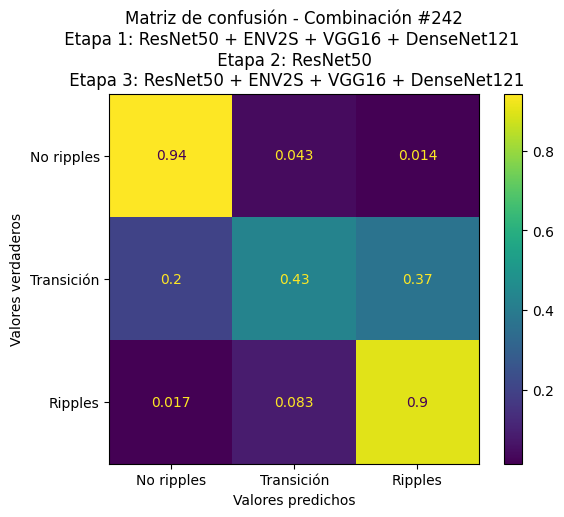

In [ ]:
number = 262



#Ripples
Weighted_mean_final_pred_ripples = final_classification_ripples['Combination ' + str(number)].values

Weighted_mean_final_pred_ripples = Weighted_mean_final_pred_ripples[1:]

#Transition
Weighted_mean_final_pred_transition = final_classification_transition['Combination ' + str(number)].values

Weighted_mean_final_pred_transition = Weighted_mean_final_pred_transition[1:]

#Not ripples
Weighted_mean_final_pred_not_ripples = final_classification_not_ripples['Combination ' + str(number)].values

Weighted_mean_final_pred_not_ripples = Weighted_mean_final_pred_not_ripples[1:]

#concatenate 3 classes
Weighted_mean_final = np.concatenate((Weighted_mean_final_pred_ripples, Weighted_mean_final_pred_transition, Weighted_mean_final_pred_not_ripples))

#Create confussion matrix
confusion_weighted_mean=confusion_matrix(d, Weighted_mean_final, normalize='true')

#plot confusion matrix
labels_plot = ['No ripples', 'Transición', 'Ripples']

fig = plt.figure(figsize=(16, 8))
disp = ConfusionMatrixDisplay(confusion_matrix= confusion_weighted_mean, display_labels=labels_plot)
disp.plot()
disp.ax_.set_title('Matriz de confusión - Combinación #'+str(number-20) +'\n Etapa 1: ResNet50 + ENV2S + VGG16 + DenseNet121  \n Etapa 2: ResNet50 \n Etapa 3: ResNet50 + ENV2S + VGG16 + DenseNet121')
disp.ax_.set(xlabel='Valores predichos', ylabel='Valores verdaderos')